# Imports

## Libraries and Paths

In [1]:
import os
import sys
import shutil
import ast
import copy
import time
import numpy as np
import pandas as pd
import datetime as dt
import networkx as nx
import netwulf as nw

import re
from collections import Counter
from collections import OrderedDict
import itertools
from itertools import product

import matplotlib as mpl
import matplotlib.pylab as pl
from matplotlib.collections import LineCollection, EllipseCollection
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.colorbar as colorbar
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionStyle
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import Normalize, LogNorm, SymLogNorm
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
from matplotlib.patches import Patch
from matplotlib.patches import Polygon
import matplotlib.transforms as mtransforms
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path        # <-- Path defined here
import matplotlib.dates as mdates
from matplotlib.table import Table
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from joypy import joyplot
import contextily as ctx
from shapely.geometry import box, Point, LineString
import geopandas as gpd
from pyproj import Transformer

from scipy.stats import entropy
from scipy.stats import zscore
from scipy.stats import norm
from scipy.stats import gaussian_kde

import importlib
from Modules import utils, visual, analysis
# reload modules
importlib.reload(utils)
importlib.reload(visual)
importlib.reload(analysis)

# refresh namespace
from Modules.utils import *
from Modules.visual import *
from Modules.analysis import *
from Modules import config

## Experimental and visualization variables

In [2]:
#CHOICE OF THE COLORPALETTE 
COLOR_GT = '#3A86FF'

#oracle : dark color
#calibration: light color 
COLOR_BS = '#8338EC'  
COLOR_CALIB_BS = '#F781BF'

COLOR_CC       = '#104911' 
COLOR_CALIB_CC = '#548C2F'

#'#E07B39', #dark orange 
#'#FFB347', #light orange} 

#COLORS FOR SIR modeling
COLOR_A = '#009E73'
COLOR_B = '#D55E00'
COLOR_R = '#EAD9B8'

#COLORS FOR THE GAPS
COLOR_GAPS = '#1A1A1A'   # Charcoal

#Current folder collecting experimental results for epidemic simulations
FOLD_exp = 'f01_014_D1_iter_sparsified_epid_simulations_from_weekday/'

#list of sparsification mechanisms
List_ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu',
           'Random_uniform_1wgcu']

#list of sparsification levels
Levels = gen_sparsity_ranges()

#list of sparsification iterations
Ranges_iter = range(50)

#Ordered list of contact metrics
#Daterange and selected Users for the experiment
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
N_users = len(USERS_select)  
Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
#from datetime to date format 
Dates = Date_range_fromweekday.date
Dates_plus1 = np.append(Dates, Dates[-1]+dt.timedelta(days=1))

#Ordered list of epidemic metrics as computed from EMO collection
Emo_metrics_names = ['peak_day', 
                     'peak_size', 
                     'final_size', 
                     'epid_duration', 
                     'day_final_case'] 

#Level_colors = ['#EEAAFF', 
#                '#DDA0FF', 
#                '#BB66FF', 
#                '#9933FF', 
#                '#7700FF']

Level_colors = [plt.cm.YlOrRd(i) for i in np.linspace(0.4, 1.0, 5)]

DICT_colors_level = dict(zip(Levels, Level_colors))

DICT_colors_ss = {'Data_driven_1wgcu': COLOR_BS,
                 'Random_uniform_1wgcu': '#8D99AE',
                 'Random_keepdurations_1wgcu': '#E63946'}


#list of sparsification mechanisms
List_ss = ['Data_driven_1wgcu', 
           'Random_uniform_1wgcu', 
           'Random_keepdurations_1wgcu']

#list of sparsification levels
Levels = gen_sparsity_ranges()

#list of sparsification iterations
Ranges_iter = range(50)

Contact_corrections  = ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
#Contact_corrections += [f'{c}_aligned' for c in Contact_corrections]
Contact_corrections += ['ipwtplusimp_hourofday_weekday_minobs1']
Contact_corrections += ['CU_60min']
Contact_corrections += ['CU_1440min']

DICT_rename_contact_corrections = {'ipw_global': '(ipw cov. global)', 
                                   'ipw_daily': '(ipw cov. daily)', 
                                   'ipw_hourofday_weekday' : '(ipw. cov. hour-weekperiod)', 
                                   'ipw_global_aligned': '(ipw cov. co-presence global)', 
                                   'ipw_daily_aligned': '(ipw cov. co-presence daily)', 
                                   'ipw_hourofday_weekday_aligned' : '(ipw. cov. co-presence hour-weekperiod)', 
                                   'ipwtplusimp_hourofday_weekday_minobs1': 'naive (ipw + imp.)',
                                   'CU_60min': 'all contacts last 60 minutes', 
                                   'CU_1440min': 'all contacts last 1 day'}

EMVs = ['calibration_biased', 'oracle_biased'] 
DICT_rename_EMVs = {'oracle_biased': 'Oracle on biased contacts',
                    'calibration_biased' : 'Calibration on biased contacts'} 

for c in Contact_corrections:
    EMVs += [f'calibration_corrected_{c}', 
              f'oracle_{c}']
    c_rename = DICT_rename_contact_corrections[c]
    DICT_rename_EMVs[f'calibration_corrected_{c}'] = f'Calibration on corrected contacts {c_rename}'
    DICT_rename_EMVs[f'oracle_{c}'] = f'Oracle on corrected contacts {c_rename}'

DICT_colors_emv = {'oracle_biased' : COLOR_BS,
                   'calibration_biased' : COLOR_CALIB_BS,
                   'oracle_ipw': COLOR_CC,
                   'calibration_ipw': COLOR_CALIB_CC,
                   'oracle_ipw_global':                '#E07B39', #dark orange 
                   'calibration_corrected_ipw_global': '#FFB347', #light orange} 
                   'oracle_ipw_daily': '#FFD60A', #dark yellow  
                   'calibration_corrected_ipw_daily': '#FFF4B2', #light yellow 
                   'oracle_ipw_hourofday_weekday': COLOR_CC,       
                   'calibration_corrected_ipw_hourofday_weekday': COLOR_CALIB_CC} 

DICT_colors_emv.update({'oracle_biased_contacts' : COLOR_BS,
                        'calibration_biased_contacts' : COLOR_CALIB_BS,
                        'oracle_corrected_contacts': COLOR_CC,
                        'calibration_corrected_contacts': COLOR_CALIB_CC})

USE_OLD_EMVS = False

if USE_OLD_EMVS: 
    
    #epidemic modeling variations
    EMVs = ['oracle_biased', 
            'rescaled_contacts', 
            'param_calibration_S_grid_v3', 
            'param_calibration_I_grid_v3', 
            'param_calibration_S_median_grid_v3',
            'param_calibration_I_median_grid_v3', 
            'calibration_biased', 
            'scaling_plus_optuna_median_I_RMSE', 
            'ipw_global', 
            'calibration_corrected_ipw_global',
            'ipw_hourly', 
            'ipw_hourly_plus_calibration_median_I_RMSE']
    
    #for deciding which subets to visualize
    DICT_EMV_subsets ={'all': EMVs,
                       'main_mean': ['oracle_biased',
                                     'rescaled_contacts',
                                     'param_calibration_S_grid_v3',
                                     'param_calibration_I_grid_v3'],  
                       
                       'main_median': ['oracle_biased',
                                       'rescaled_contacts',
                                       'param_calibration_S_median_grid_v3',
                                       'param_calibration_I_median_grid_v3'],                   
                       
                       'only_calib': ['param_calibration_S_grid_v3',
                                      'param_calibration_I_grid_v3',
                                      'param_calibration_S_median_grid_v3',
                                      'param_calibration_I_median_grid_v3'], 
                       
                       'grid_and_optuna': ['param_calibration_I_median_grid_v3',
                                           'calibration_biased'], 
                       
                       'compared_results_old': ['oracle_biased',
                                                'rescaled_contacts',
                                                'calibration_biased', 
                                                'scaling_plus_optuna_median_I_RMSE'], 
                       
                       'compared_results_global': ['oracle_biased',
                                                   'ipw_global',
                                                   'calibration_biased', 
                                                   'calibration_corrected_ipw_global'], 
                       
                       'compared_results': ['oracle_biased',
                                             'ipw_hourly',
                                             'calibration_biased', 
                                             'ipw_hourly_plus_calibration_median_I_RMSE']}
    
    #renaming variables
    DICT_rename_EMVs = {'oracle_biased' : 'Uncalibrated', 
                        'rescaled_contacts': 'Scaling',
                        'param_calibration_S_grid_v3' : 'Calib. (mean S)',          #old with grid search  
                        'param_calibration_I_grid_v3' : 'Calib. (mean I)',          #old with grid search 
                        'param_calibration_S_median_grid_v3' : 'Calib. (median S)', #old with grid search 
                        'param_calibration_I_median_grid_v3' : 'Calib. (median I)', #old with grid search 
                        'calibration_biased'              : 'Calibration',           #new with bayes kernel fitting
                        'scaling_plus_optuna_median_I_RMSE' : 'Scaling + Epid. Calib.', 
                        'ipw_global': 'Contact correction', 
                        'calibration_corrected_ipw_global': 'Calibration on corrected contacts',
                        'ipw_hourly': 'IPW_hour', 
                        'ipw_hourly_plus_calibration_median_I_RMSE': 'IPW_hour + Epid. Calib.'} #new with bayes kernel fitting

DICT_rename_ss = {'Data_driven_1wgcu' :  'Data driven ', 
                  'Random_uniform_1wgcu': 'Random uniform', 
                  'Random_keepdurations_1wgcu': 'Random shuffling'}

DICT_rename_ss_brief = {'Data_driven_1wgcu' :  'Data driven', 
                        'Random_uniform_1wgcu': 'Random uniform'}

DICT_rename_levels = {l: convert_to_percent_range(str(l)) for l in Levels}
Levels_str = [convert_to_percent_range(str(l)) for l in Levels]

DICT_rename_class_epid = {'I': 'Infected', 
                          'S': 'Susceptible'}

DICT_rename_emo_metrics = {'peak_size'  : 'Peak', 
                           'final_size' : 'Total',
                           'peak_day' : 'Peak day', 
                           'epid_duration'  : 'Day of last recovery',
                           'day_final_case' : 'Day of last case'}

DICT_rename_emo_metrics_norm = {'peak_size'  : 'Maximum of daily infected (%)', 
                                'final_size' : 'Total infected (%)',
                                'peak_day' : 'Peak day', 
                                'epid_duration'  : 'Day of last recovery',
                                'day_final_case' : 'Day of last case'}

DICT_rename_em_fraction = {'peak_size' : 'max I (%)', 
                           'final_size': 'tot I (%)'}

DICT_period_maxhours = {'night': 9*28, 
                        'daytime': 15*28,
                        'weekend': 48*4,
                        'week': 24*5*4}

## Functions

### Functions for visualization

- include netwulf graph visualization

In [3]:
def ax_visual_legend(ax, 
                     DICT_legend, 
                     List_fc = None, 
                     marker_type='', 
                     bbox=None):
    """
    Create a custom legend for an axis.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to attach the legend to.
    DICT_legend : dict
        Must contain keys: 'colors', 'classes', 'title', 'loc', 'fontsize', 'title_fontsize'.
    List_fc : list or None
        Optional facecolors (used if not None).
    marker_type : str, default ''
        If 'point', use scatter point markers instead of patches.
    bbox : tuple or None
        Passed to legend as bbox_to_anchor if given.
        Example: (1.05, 1) places legend outside to the right.
    """
    Colors = DICT_legend['colors']
    Indicators = DICT_legend['classes']

    # Default patches
    Patches = [mpatches.Patch(edgecolor=c, facecolor=c, label=l)
               for c, l in zip(Colors, Indicators)]

    # Override with facecolors if given
    if List_fc is not None:
        Patches = [mpatches.Patch(label=l, edgecolor=c, facecolor=f)
                   for c, l, f in zip(Colors, Indicators, List_fc)]

    # Override with point markers
    if marker_type == 'point':
        Patches = [Line2D([0], [0], marker='o', linestyle='None', label=l,
                          markerfacecolor=c, markeredgecolor=c, markersize=5)
                   for c, l in zip(Colors, Indicators)]

    legend_args = dict(
        handles=Patches,
        title=DICT_legend['title'],
        loc=DICT_legend['loc'],
        fontsize=DICT_legend['fontsize'],
        title_fontsize=DICT_legend['title_fontsize']
    )
    if bbox is not None:
        legend_args['bbox_to_anchor'] = bbox

    ax.legend(**legend_args)

In [4]:
def restyle_ax(ax,
               tick_size  = 15,
               label_size = 15,
               title_size = 20,
               legend_font_size  = 15,
               legend_title_size = 15,
               text_size = 15,
               font_family='Liberation Sans', 
               other_text = True):
    """
    Apply consistent font sizes and font family to ticks, labels, title, legend, and texts in an Axes.
    """

    # Axis labels
    ax.xaxis.label.set_size(label_size)
    ax.xaxis.label.set_family(font_family)
    ax.yaxis.label.set_size(label_size)
    ax.yaxis.label.set_family(font_family)

    # Title
    ax.title.set_size(title_size)
    ax.title.set_family(font_family)

    # Tick labels
    ax.tick_params(axis='both', which='major', labelsize=tick_size)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontsize(tick_size)
        tick.set_family(font_family)

    # Legend
    legend = ax.get_legend()
    if legend:
        legend.get_title().set_fontsize(legend_title_size)
        legend.get_title().set_family(font_family)
        for text in legend.get_texts():
            text.set_fontsize(legend_font_size)
            text.set_family(font_family)
    if other_text:
        # Other text
        for text in ax.texts:
            text.set_fontsize(text_size)
            text.set_family(font_family)

def ax_legend_sparsification(ax, 
                             loc = 'upper right', 
                             fontsize = 10, 
                             include_complete = True):

    Classes = ['ground truth'] + [DICT_rename_ss_brief[s] for s in List_ss] 
    Colors  = ['blue']     + [DICT_colors_ss[s] for s in List_ss]      
    if not include_complete:
        Classes = Classes[1:]
        Colors = Colors[1:]  
        
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Classes,
                        'colors': Colors, 
                        'title': '', 
                        'loc': loc, 
                        'fontsize':fontsize})
    ax_visual_legend(ax, DICT_legend)

def ax_legend_emv(ax, 
                  EMVs, 
                  loc = 'upper right', 
                  fontsize = 10, 
                  title_fontsize = 10,
                  title= '',
                  include_complete = True):

    Classes = ['ground truth'] +  [DICT_rename_EMVs[s] for s in EMVs]
    Colors  = ['blue'] +      [DICT_colors_emv[s] for s in EMVs]  
    if not include_complete:
        Classes = Classes[1:]
        Colors = Colors[1:]  
                                 
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Classes,
                        'colors': Colors, 
                        'title': title, 
                        'loc': loc, 
                        'fontsize':fontsize,
                        'title_fontsize': title_fontsize})
    ax_visual_legend(ax, DICT_legend)

def ax_visual_line_legend(ax, DICT_legend):
    
    Colors = DICT_legend['colors']
    Indicators = DICT_legend['classes']
    LineStyles = DICT_legend.get('linestyles', ['solid'] * len(Colors))  # Default to solid if not specified

    Patches = [mlines.Line2D([], [], color=c, linestyle=ls, label=l, linewidth=2) 
               for c, l, ls in zip(Colors, Indicators, LineStyles)]

    ax.legend(handles=Patches, 
              title=DICT_legend['title'],
              loc=DICT_legend['loc'], 
              fontsize=DICT_legend['fontsize'],
              title_fontsize=DICT_legend['title_fontsize'])

def scatter_df(ax, 
               df, x, y, 
               title = '', 
               s = 1,
               c = 'blue',
               x_rename = None, 
               y_rename = None, 
               label_size =  15,
               title_size = 20,
               cmap = None,
               vmin = None,
               vmax = None, 
               fontsize_cbar = 10,
               colorbar = False, 
               colorbar_label = ''): 
    
    X = df[x].values
    Y = df[y].values
    
    sc = ax.scatter(X, Y,  
                    c = c, 
                    s = s, 
                    cmap = cmap,
                    vmin = vmin, 
                    vmax = vmax)

    if colorbar:
        cbar = plt.colorbar(sc, ax = ax)
        cbar.set_label(colorbar_label, fontsize = fontsize_cbar)
        
    if x_rename is None:
        x_rename = x
    if y_rename is None:
        y_rename = y

    ax_visual_labeltitles(ax, {'xlabel': x_rename, 
                               'ylabel': y_rename,
                               'title': title, 
                               'label_size': label_size, 
                               'title_size': title_size})
    
def rescale_ax_ticks(ax, 
                     int_scale = 4, 
                     digit_round = 0, 
                     scient_not_drop = False,
                     int_label = False,
                     axis = 'x'):
    '''
    scient_not_drop: drop scientific notation if already rescaled and put it into 
    else rescale the ticks accordingly
    '''

    if scient_not_drop:
        if axis=='y':
            ax.yaxis.offsetText.set_visible(False)
            ylabel = ax.get_ylabel()
            ax.set_ylabel(f"{ylabel} $(x10^{int_scale})$")
        if axis=='x':
            ax.xaxis.offsetText.set_visible(False)
            xlabel = ax.get_xlabel()
            ax.set_xlabel(f"{xlabel} $(x10^{int_scale})$")
        
    else:
        if axis=='y':
            yticks = ax.get_yticks()
            yticks_rescaled = [f'{np.round(y/(10**int_scale),digit_round)}' for y in yticks]
            if int_label:
                yticks_rescaled =  [int(np.round(y/(10**int_scale),digit_round)) for y in yticks]
            ax.set_yticklabels(yticks_rescaled)
            ylabel = ax.get_ylabel()
            ax.set_ylabel(f"{ylabel} $(x10^{int_scale})$")
            
        if axis=='x': 
            xticks = ax.get_xticks()
            xticks_rescaled = [f'{np.round(x/(10**int_scale),digit_round)}' for x in xticks]
            if int_label:
                xticks_rescaled = [int(np.round(x/(10**int_scale),digit_round)) for x in xticks]

            ax.set_xticklabels(xticks_rescaled)
            xlabel = ax.get_xlabel()
            ax.set_xlabel(f"{xlabel} $(x10^{int_scale})$")


#Visualize scatterplot and boxplot together
def viz_scatter_boxplot(ax,
                        List_Ms, 
                        Ms_ind,
                        Colors, 
                        Colors_scatter = 'black',
                        vmin = 0, 
                        vmax = 15, 
                        cmap = 'viridis',
                        cbar = True,
                        cbar_label = '',
                        scatter_size = 1):
    '''
    Visualize the boxplots of a list of values in List_Ms corresponding to indexes Ms_ind,
    Colors are the colors of the boxplots
    Colors_scatter are the colors of the scatter points (can be also a list)
        cmap : of the Colors_scatter
    '''

    for i, c, Ms in zip(Ms_ind, Colors, List_Ms):
        
        ax.boxplot(Ms, 
                   positions = [i], 
                   widths = 0.5, 
                   showfliers = False, 
                   patch_artist=True,
                   boxprops=dict(facecolor= 'none', color= c),
                   capprops=dict(color=c),
                   whiskerprops=dict(color=c),
                   flierprops=dict(color=c, markeredgecolor=c),
                   medianprops=dict(color=c))

        X_vals = [i + np.random.normal(scale = 0.05) for j in range(len(Ms))]
        if len(Colors_scatter)>1:
            IND = np.argwhere(Ms_ind==i)[0][0]
            sc = ax.scatter(X_vals, 
                            Ms, 
                            c = Colors_scatter[IND],
                            vmin = vmin, vmax = vmax, cmap = cmap, 
                            s = scatter_size)
            
            if cbar and IND == 0:
                cbar = plt.colorbar(sc, ax=ax)
                cbar.set_label(cbar_label, size=14)
            
        else:
            ax.scatter(X_vals, 
                       Ms, 
                       color = Colors_scatter, 
                       s = scatter_size)

def change_first_xtick(ax, newlabel='newlabel'):
    xticks = ax.get_xticks()  # Get current x-tick positions
    xticklabels = ax.get_xticklabels()  # Get current x-tick labels
    ax.set_xticks(xticks)  # Update x-ticks
    xticklabels[0] = newlabel  # Modify first tick label
    ax.set_xticklabels(xticklabels)  # Update x-tick labels

#Visualize scatterplot and boxplot together
def viz_scatter_boxplot_new(ax,
                            List_Ms, 
                            Ms_ind,
                            Colors = 'black', 
                            Colors_scatter = 'black',
                            scatter = True,
                            scatter_size = 1, 
                            x_Labels = None, 
                            x_label_size = 0,
                            x_label_rot = 0):
    '''
    Visualize the boxplots of a list of values in List_Ms corresponding to indexes Ms_ind
    Colors are the colors of the boxplots
    Colors_scatter are the colors of the scatter points (can be also a list)
        cmap : of the Colors_scatter
    '''
    
    if not isinstance(Colors, list):
        Colors = [Colors] * len(List_Ms)
    if not isinstance(Colors_scatter, list):
        Colors_scatter = [Colors_scatter] * len(List_Ms)

    for i, Ms, c, c_scatter in zip(Ms_ind, 
                                   List_Ms, 
                                   Colors, 
                                   Colors_scatter):
        
        ax.boxplot(Ms, 
                   positions = [i], 
                   widths = 0.5, 
                   showfliers = False, 
                   patch_artist = True,
                   boxprops = dict(facecolor = 'none', color = c),
                   capprops = dict(color=c),
                   whiskerprops = dict(color=c),
                   flierprops = dict(color=c, markeredgecolor=c),
                   medianprops = dict(color=c))

        #add scatter points within the boxplot
        if scatter:
            X_vals = [i + np.random.normal(scale = 0.05) for j in range(len(Ms))]
            ax.scatter(X_vals, 
                       Ms, 
                       color = c_scatter, 
                       s = scatter_size)
            
    if x_Labels is not None: 
        ax_visual_ticklabel(ax, {'t': Ms_ind, 
                                 'tl': x_Labels,
                                 'rot': x_label_rot,
                                 'size': x_label_size}, axis = 'x')

def visual_bar_series(ax,
                      s,
                      s_bottom=None,
                      s_ind=None,
                      Colors='black',
                      edgecolor='black',
                      x_Labels=None,
                      x_label_rot=0,
                      hatch=None,
                      width=0.8,
                      x_label_size=10,
                      c_lower=None,
                      c_upper=None,
                      ci_color='black',
                      ci_linewidth=1.2,
                      ci_cap_frac=0.25,
                      edge_only=False,
                      viz_scatter=False,          # NEW
                      marker='o',                 # NEW
                      markersize=60):             # NEW (size in points^2 for scatter)
    """
    Bar plot (or scatter if viz_scatter=True) for a 1D series/array with optional CI segments.

    Parameters
    ----------
    viz_scatter : bool
        If True, draw scatter markers instead of bars.
    marker : str
        Matplotlib marker style (e.g. 'o', '^', 's').
    markersize : float
        Scatter size (points^2).
    """
    # Normalize input to Series
    if isinstance(s, pd.Series):
        s_series = s.copy()
        if x_Labels is None:
            x_Labels = list(s_series.index)
    else:
        if x_Labels is None:
            x_Labels = list(range(len(s)))
        s_series = pd.Series(np.asarray(s), index=x_Labels)

    # Subset/reindex if x_Labels provided
    s_series = s_series.loc[x_Labels]
    n = len(s_series)

    # X positions
    s_ind = list(range(n)) if s_ind is None else list(s_ind)

    # Colors
    if not isinstance(Colors, (list, tuple, np.ndarray)):
        Colors = [Colors] * n
    else:
        Colors = list(Colors)
        if len(Colors) != n:
            Colors = (Colors * (n // len(Colors) + 1))[:n]

    # Bottoms
    bottoms = np.zeros(n) if s_bottom is None else np.asarray(s_bottom, dtype=float)

    # Draw bars or scatter
    for i, val, c, b in zip(s_ind, s_series.values, Colors, bottoms):
        if viz_scatter:
            ax.scatter(i, val, color=c, marker=marker, s=markersize)
        else:
            if edge_only:
                ax.bar([i], val, width=width, facecolor='white',
                       edgecolor=c, hatch=hatch, linewidth=1.5, bottom=b)
            else:
                ax.bar([i], val, width=width, facecolor=c,
                       edgecolor=edgecolor, hatch=hatch, bottom=b)

    # Draw absolute CI segments (from c_lower to c_upper) with caps
    if (c_lower is not None) and (c_upper is not None):
        lo = np.asarray(c_lower, dtype=float)
        hi = np.asarray(c_upper, dtype=float)
        if lo.ndim == 0: lo = np.full(n, float(lo))
        if hi.ndim == 0: hi = np.full(n, float(hi))

        cap_half = (width * ci_cap_frac) / 2.0
        for xi, ylo, yhi in zip(s_ind, lo, hi):
            if not np.isfinite(ylo) or not np.isfinite(yhi):
                continue
            ax.vlines(xi, ylo, yhi, colors=ci_color, linewidth=ci_linewidth)
            ax.hlines([ylo, yhi], xi - cap_half, xi + cap_half,
                      colors=ci_color, linewidth=ci_linewidth)

    # X tick labels
    ax_visual_ticklabel(ax, {'t': s_ind, 'tl': list(s_series.index),
                             'rot': x_label_rot, 'size': x_label_size}, axis='x')


def draw_netwulf(network_properties,
                 fig=None,
                 ax=None,
                 figsize=None,
                 draw_links=True,
                 draw_nodes=True,
                 link_zorder=-1, 
                 node_zorder=1000):
    """
    Redraw the visualization using matplotlib. Creates
    figure and axes if None provided.
    In order to add labels, check out
    :mod:`netwulf.tools.add_node_label`
    and
    :mod:`netwulf.tools.add_edge_label`

    Parameters
    ----------
    network_properties : dict
        The network properties which are returned from the
        interactive visualization.
    fig : matplotlib.Figure, default : None
        The figure in which to draw
    ax : matplotlib.Axes, default : None
        The Axes in which to draw
    figsize : float, default : None
        the size of the figure in inches (sidelength of a square)
        if None, will be taken as the minimum of the values in
        ``matplotlib.rcParams['figure.figsize']``.
    draw_links : bool, default : True
        Whether the links should be drawn
    draw_nodes : bool, default : True
        Whether the nodes should be drawn

    Returns
    -------
    fig : matplotlib.Figure, default : None
        Resulting figure
    ax : matplotlib.Axes, default : None
        Resulting axes
    """

    # if no figure given, create a square one
    if ax is None or fig is None:
        if figsize is None:
            size = min(mpl.rcParams['figure.figsize'])
        else:
            size = figsize

        fig = pl.figure(figsize=(size,size), dpi = 300)
        ax = fig.add_axes([0, 0, 1, 1])
        # Customize the axis
        # remove top and right spines
        ax.spines['right'].set_color('none')
        ax.spines['left'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.spines['bottom'].set_color('none')
        # turn off ticks
        ax.xaxis.set_ticks_position('none')
        ax.yaxis.set_ticks_position('none')
        ax.xaxis.set_ticklabels([])
        ax.yaxis.set_ticklabels([])


    # for conversion of inches to points
    # (important for markersize and linewidths).
    # Apparently matplotlib uses 72 dpi internally for conversions in all figures even for those
    # which do not follow dpi = 72 which is freaking weird but hey why not.
    dpi = 300

    # set everything square and get the axis size in points
    ax.axis('square')
    ax.axis('off')
    ax.margins(0)
    ax.set_xlim(network_properties['xlim'])
    ax.set_ylim(network_properties['ylim'])
    bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    axwidth, axheight = bbox.width*dpi, bbox.height*dpi


    # filter out node positions for links
    width = network_properties['xlim'][1] - network_properties['xlim'][0]
    height = network_properties['ylim'][1] - network_properties['ylim'][0]
    pos = { node['id']: np.array([node['x_canvas'], height - node['y_canvas']]) for node in network_properties['nodes'] }
    
    x_min, y_min = tuple(np.vstack(list(pos.values())).min(axis=0))
    x_max, y_max = tuple(np.vstack(list(pos.values())).max(axis=0))
    ax.set_xlim(x_min-10, x_max+10)
    ax.set_ylim(y_min-10, y_max+10)

    if draw_links:
        #zorder = max( _c.get_zorder() for _c in ax.get_children()) + 1
        zorder = -1 # make sure that links are very much in the background

        lines = []
        linewidths = []
        linecolors = []

        # Extract links as a list of tuples (source, target) using string keys
        links = [(link["source"], link["target"]) for link in network_properties['links']]

        # Preallocate the array for speed
        lines = np.empty((len(links), 2, 2))

        # Fill the array
        for idx, (src, tgt) in enumerate(links):
            lines[idx, :, 0] = pos[src]
            lines[idx, :, 1] = pos[tgt]

        linecolors = [link.get("color",network_properties['linkColor']) for link in network_properties["links"]]
        linewidths = np.array([link["width"] for link in network_properties['links']])/width*axwidth*0.3

       # for link in network_properties['links']:
       #     u, v = link['source'], link['target']
       #     lines.append([
       #         [pos[u][0], pos[v][0]],
       #         [pos[u][1], pos[v][1]]
       #                  ])
       #     linewidths.append(link['width']/width*axwidth*0.3)
       #     if 'color' in link.keys():
       #         linecolors.append(link['color'])
       #     else:
       #         linecolors.append(network_properties['linkColor'])

        # collapse to line segments
        lines = [list(zip(x, y)) for x, y in lines]

        # plot Lines
        alpha = network_properties['linkAlpha']*0.8

        ax.add_collection(LineCollection(lines,
                                         colors=linecolors,
                                         alpha=alpha,
                                         linewidths=linewidths,
                                         zorder=zorder))

    if draw_nodes:
        zorder = max( _c.get_zorder() for _c in ax.get_children()) + 1

        # compute node positions and properties
        XY = []
        size = []
        node_colors = []
        x_canvas = np.array([node["x_canvas"] for node in network_properties['nodes']])
        y_canvas = np.array([node["y_canvas"] for node in network_properties['nodes']])
        XY = np.column_stack([x_canvas, height - y_canvas])
        size = 2*np.array([node["radius"] for node in network_properties['nodes']])
        node_colors = np.array([node["color"] for node in network_properties['nodes']])

        XY = np.array(XY)
        size = np.array(size)
        circles = EllipseCollection(size,size,np.zeros_like(size),
                                    offsets=XY,
                                    units='x',
                                    transOffset=ax.transData,
                                    facecolors=node_colors,
                                    linewidths=network_properties['nodeStrokeWidth']/width*axwidth*0.2,
                                    edgecolors= 'black', #network_properties['nodeStrokeColor'],
                                    zorder=zorder)
        
        ax.add_collection(circles)

    return fig, ax, pos


### Functions for sparsity analysis - v0

In [5]:
def ax_visual_sparseseq(ax, 
                        Recs_ind, 
                        List_ts, 
                        Colors, 
                        ax_label_rot = 90,
                        ax_label_size = 15,
                        ax_ticks = 'x', 
                        tick_steps = 1):
    '''
    Recs_ind : record indicators 
    List_ts  : timestamps sequence
    Colors : indicators of record presence
    '''
    
    visual_imshow(ax, 
                  Recs_ind, 
                  Colors)
    
    Inds, Inds_bool = get_temporal_ticks(List_ts, 
                                         and_first_day_hour= True)
    print(len(Inds), len(Inds_bool), len(List_ts))
    
    Inds = [Inds[0].date()] + [d.strftime("%m-%d") for d in Inds[1:]]

    ax_visual_ticklabel(ax, {'t': np.arange(len(List_ts))[Inds_bool][::tick_steps], 
                             'tl': np.array(Inds)[Inds_bool][::tick_steps],
                             'rot': ax_label_rot,
                             'size': ax_label_size}, 
                        axis = ax_ticks)
    
    
def import_sparse_seq(SW_width_days = 28,
                      epsilon = 0.05, 
                      select_study_period = True):
    
    FOLD_SAVE = DICT_paths['TMP'] + 'f01_009_D1_gap_sequence_sample/'
    LIST_days    = [14, 21, 28]
    LIST_epsilon = [0, 0.05, 0.1]
    tol_stops = False
    
    DICT_filenames = gen_gapseq_filenames(FOLD_SAVE,
                                           LIST_days, 
                                           LIST_epsilon,
                                           tol_stops)
        
    fn = DICT_filenames[(epsilon, SW_width_days)]
    df_fn = pd.read_csv(f'{FOLD_SAVE}{fn}.csv')# usecols = range(4))
    
    Cols_info = ['id','sparse', 'weekstep_index']
    df_fn = df_fn.set_index(Cols_info)
    
    #select the study period
    if select_study_period: 
        df_fn = df_fn.loc[df_fn.index.get_level_values('weekstep_index')==0] 
    
    #get user info
    df_info = df_fn.index.to_frame(index= False)
    df_fn.index = range(len(df_fn))

    return df_fn

def compute_sparse_metric(df_sparse_seq, 
                          metric,
                          SW_width_days):
    
    #generate the gap dataframe from the sparse sequences
    df_gaps = gen_gaps_df(df_sparse_seq)

    #SPARSITY METRICS AND STUDIED RANGES
    Seq_series = compute_seq_sparsity(df_gaps, 
                                      metric, 
                                      N_hours = SW_width_days*24).sort_values()

    N_recs = df_sparse_seq.sum(axis=1) 
    N_tot_hours = len(df_sparse_seq.columns)
    Inds_complete = N_recs[N_recs == N_tot_hours].index
    Seq_complete = pd.Series(np.zeros(len(Inds_complete)), index = Inds_complete) 
    Seq_series = Seq_series.add(Seq_complete, fill_value = 0)
    
    return Seq_series.sort_values()

def compute_record_indicator(df_sparse_seq, 
                             metric, 
                             SW_width_days):
    
    #SPARSITY METRICS AND STUDIED RANGES
    Seq_series = compute_sparse_metric(df_sparse_seq, 
                                       metric,
                                       SW_width_days)
    
    #Visualize the sparse_sequence sample and the corresponding distribution
    Ind_sort = Seq_series.index
    Recs_ind = df_sparse_seq.loc[Ind_sort].values.T
    
    return Seq_series, Recs_ind

def ax_visual_q_series(ax, 
                       Seq_series, 
                       Bins = None, 
                       val_eps = 0.05, 
                       visual_bucket_lines = True):
    
    N_seq = len(Seq_series)
    X = np.arange(0, N_seq)
    Y = Seq_series.values
    ax.plot(X,Y)
    ax.set_ylim(0,1)
    ax.set_xlim(0,N_seq)
    ax.tick_params(axis = 'y', labelsize = 5)
    ax.tick_params(axis = 'x', labelsize = 0)
    ax.set_ylabel('q', size = 20)

    if visual_bucket_lines:
        for val in Bins[1:-1]:
            #print(val)
            x = np.argmin(np.abs(Seq_series - val))
            y = Seq_series.iloc[x]
            color = 'grey'
            if val == val_eps:
                color = 'red'
            ax.plot([ax.get_xlim()[0], x], [y, y], color = color, linestyle = '--', linewidth = 1)
            ax.plot([x, x], [ax.get_ylim()[0], y], color = color, linestyle = '--', linewidth = 1)
            axes[1,1].axvline(x, color = color, linestyle = '--', linewidth = 2)
        ax.set_ylabel('q', size = 20)
        ax_visual_ticklabel(ax, 
                            {'t': Bins, 'tl': Bins,'rot': 0,'size':15}, 
                            axis = 'y')

def visual_sparsity_distribution(axes, 
                                 Seq_series, 
                                 Recs_ind,
                                 List_ts,
                                 Bins, 
                                 xtickfreq= 500, 
                                 val_eps = 0):
    '''
    axes : (2x2) subplots
    Seq_series: series of sparsity values for each gap sequence 
    Recs_ind: matrix of record indicators
    List_ts: list of hourly time-stamps of the gap sequence
    Bins : sparsity metric bins
    '''

    ax = axes[0,0]
    Counts, Bins = np.histogram(Seq_series, bins = Bins)
    X = (Bins[:-1] + Bins[1:]) / 2
    ax.barh(X, Counts, height = np.diff(Bins), 
            color = ['blue'] + ['purple']*(len(Bins)-1),
            edgecolor = 'black')
    
    ax.invert_xaxis()
    ax.tick_params(axis='y', labelsize= 0)
    ax.tick_params(axis='x', labelsize= 20, rotation = 90)
    ax.set_xlabel('count', size= 25)
    
    X_ticks = np.arange(0, ax.get_xlim()[0]+xtickfreq, xtickfreq).astype(int)
    ax_visual_ticklabel(ax, {'t':X_ticks, 'tl': X_ticks, 'rot': 90, 'size':20}, axis = 'x')
    ax.set_ylim(0,1)
    ax_visual_ticklabel(ax, 
                        {'t': Bins, 'tl': Bins,'rot': 0,'size':0}, 
                        axis = 'y')
    
    axes[1,0].axis('off')
    
    ax = axes[1,1]
    Recs_sc = Recs_ind[:,:np.sum(Seq_series<0.05)]
    Recs_ind_complete = Recs_ind.copy()
    Recs_ind_complete[:,:np.sum(Seq_series<0.05)] = (Recs_sc+1)*Recs_sc

    Colors = ['black', 'purple', 'blue']
    Indicators = ['absent', 'present']
    
    ax_visual_sparseseq(ax, Recs_ind_complete, List_ts, Colors)
    
    ax_visual_labeltitles(ax, {'xlabel': 'Gap sequence', 
                               'ylabel': '', 
                               'title' : '', 
                               'label_size': 25,
                               'title_size':0})
    
    ax.tick_params(axis = 'y', labelsize = 10)
    ax.set_ylabel('Date', size= 25)
    
    ax = axes[0,1]
    ax_visual_q_series(ax, Seq_series, Bins)

### Functions for sparsity analysis - v1 

Here, analysis in conducted on the sample of sparse trajectories

In [6]:
#Create the sequence of synthetic gaps
def randomize_sequence(df_X_emp):
    '''
    df_X_emp : dataframe of empirical sequences
        - index : sequence id
        - column : datetime at hour resolution
    '''
    
    X_random = np.copy(df_X_emp.values)
    np.apply_along_axis(np.random.shuffle, axis=1, arr=X_random)
    
    df_X_random = pd.DataFrame(X_random,
                               index = df_X_emp.index, 
                               columns = df_X_emp.columns)
    return df_X_random


def visual_gaps_hist(ax, 
                     gaps_dd, 
                     color = 'purple', 
                     visual_mean = False):
    
    col = 'gap_duration_hours'
    m_vals = gaps_dd[col].values
    ax.hist(m_vals, 
            #weights = np.ones(len(m_vals)) / len(m_vals),
            histtype='step',
            bins = np.arange(0, np.max(m_vals)+1), 
            edgecolor= color,
            facecolor='none', 
            linewidth=2)# if c!='blue' else 1,

    if visual_mean:
        gap_mean = np.mean(m_vals)
        ax.axvline(x = gap_mean, color = color)
        ax.text(gap_mean, ax.get_ylim()[1]*0.5, 'mean', size = 15, rotation = 90)


def visual_compare_gaps_hist(ax, 
                             gaps_dd, 
                             gaps_ru, 
                             visual_mean = False): 
    '''
    gaps_dd : empirical gaps
    gaps_ru : random uniform gaps
    '''
    
    visual_gaps_hist(ax, 
                     gaps_dd, 
                     color = 'purple', visual_mean = visual_mean)

    visual_gaps_hist(ax, 
                     gaps_ru, 
                     color = 'grey', visual_mean = visual_mean)


def visual_gaps_hist_split(ax, 
                           gaps_dd, 
                           gaps_ru, 
                           visual_mean = True, 
                           ylim_sub = 50):
    '''
    gaps_dd : empirical gaps
    gaps_ru : random uniform gaps
    '''
    
    visual_compare_gaps_hist(ax, 
                             gaps_dd, 
                             gaps_ru, 
                             visual_mean = visual_mean)
    
    Xmax = ax.get_xlim()
    ax.set_xlim(0,24)
    ax.set_xticks(range(24))
    
    
    ax_sub = ax.inset_axes([0.6, 0.55, 0.35, 0.35])  # [x0, y0, width, height]
    visual_compare_gaps_hist(ax_sub,
                             gaps_dd, 
                             gaps_ru, 
                             visual_mean = visual_mean)
    
    ax_sub.set_xlim(24, Xmax[1])
    ax_sub.set_ylim(0, ylim_sub)
    
    ax_visual_labeltitles(ax_sub, 
                          {'xlabel': 'gap duration (hour)', 
                           'ylabel': 'gap count',
                           'title': 'Gaps $\geq$ 1 day',
                           'label_size': 15,
                           'title_size': 20})

#compute the overall entropy
def compute_entropy(df_gaps): 
    col = 'gap_duration_hours'
    m_vals = df_gaps[col].values
    bins = np.arange(1, np.max(m_vals)+1)
    freqs = np.histogram(m_vals,bins)[0]/len(m_vals)
    return entropy(freqs)

#create a sequence-level dataframe with [q, q_night, q_weekend, H_emp, H_random]
def compute_qs(df_X_emp):
    '''
    compute fraction of missing hours in different study periods
    '''

    Cols = df_X_emp.columns
    Cols_nighthours = Cols[Cols.hour.isin([22,23,0,1,2,3,4,5,6])]
    Cols_weekend = Cols[Cols.weekday.isin([5,6])]
    
    Q = 1 - df_X_emp.mean(axis=1)
    Q_nighthours = 1 - df_X_emp[Cols_nighthours].mean(axis=1)
    Q_weekend = 1 - df_X_emp[Cols_weekend].mean(axis=1)
    
    df_Qs = pd.concat([Q, Q_nighthours, Q_weekend], axis=1)
    df_Qs.columns = ['q', 'q_night', 'q_weekend']

    return df_Qs

def compute_mhc(df_X_emp):
    '''
    compute missing hour count in different study periods 
    '''

    Cols = df_X_emp.columns
    Cols_nighthours = Cols[Cols.hour.isin([22,23,0,1,2,3,4,5,6])]
    Cols_weekend = Cols[Cols.weekday.isin([5,6])]

    Q =  (df_X_emp==0).sum(axis=1)
    Q_nighthours = (df_X_emp[Cols_nighthours] == 0).sum(axis=1)
    Q_weekend = (df_X_emp[Cols_weekend] ==0).sum(axis=1)
    
    df_Qs = pd.concat([Q, Q_nighthours, Q_weekend], axis=1)
    df_Qs.columns = ['mhc', 'mhc_night', 'mhc_weekend']

    return df_Qs

#def count_z_diff(df_seq_stat, metric = 'mhc_night'):
#    '''
#    given the z-score for a given variable
#    count the records which are below 2 and over 2 z-score
#    '''
#    col_z = f'{metric}_zscore'
#    z_vals = df_seq_stat[col_z]
#    N_gt2  = np.sum(z_vals>2) 
#    N_ltm2 = np.sum(z_vals<-2)
#    return N_ltm2, N_gt2

#compute an analytic formula for the random entropy dependent on the sparsity level
def H_analytic_TODO(p, L_max = 24*48):
    '''
    p: probability of having a gap
    '''

    #probability of having a gap of a given length
    p_l = lambda l : ((p**l)*((1-p)**2)) / (1 - (1-p)**L_max)
    #entropy term for the given legth
    H_l = lambda l : -(p_l(l))*(np.log2(p_l(l) + 1e-12))
    H = np.sum([H_l(i) for i in range(L_max)])
    
    return H

def compute_H_from_integer_sample(sample): 
    
    # Count occurrences of each unique value
    values, counts = np.unique(sample, return_counts=True)
    
    # Convert to probability distribution
    probabilities = counts / counts.sum()
    
    # Compute entropy
    H = entropy(probabilities)

    return H
    
def compute_gap_length_entropy(row):
    """
    row: record boolean indicator 
    Given a 1D NumPy array (row of X)
    compute the lengths of consecutive 0 streaks
    get the distribution of gap duration
    compute the entropy of the distribution
    """
    # Find where the row changes (from 1 → 0 and 0 → 1)
    zero_starts = np.where(np.diff(np.insert(row, 0, 1)) == -1)[0]  # Start indices of 0 sequences
    zero_ends = np.where(np.diff(np.append(row, 1)) == 1)[0]  # End indices of 0 sequences

    # Compute lengths of each zero streak
    zero_streaks = zero_ends - zero_starts + 1

    # Compute entropy of the durations
    H = compute_H_from_integer_sample(zero_streaks)
    
    return H

def H_computational(p, 
                    L_max = 24*48, 
                    N_tries = 1000, 
                    N_recs = None):
    '''
    compute entropy of distribution of gap durations for a random model 
    p: percentage of missing records
    L_max: finite length of the sequence
    N_tries: realizations of entropy computation
    N_recs: number of present records in the sequence (disregards computation with p)
    '''

    #create random sequence of records
    if N_recs is None:
        N_recs = int(L_max*(1-p))
        
    #number of present records
    X_recs = np.ones((N_tries, N_recs))
    #number of absent records
    X_gaps = np.zeros((N_tries, L_max - N_recs))
    #join and shuffle
    X_tot = np.concatenate([X_recs,X_gaps], axis=1)
    np.apply_along_axis(np.random.shuffle, axis=1, arr=X_tot)

    #compute entropy for each sequence 
    H_sample = np.apply_along_axis(compute_gap_length_entropy, axis=1, arr=X_tot)
    
    return H_sample

def count_discrepant_hours(df_seq_stat, 
                           metric = 'mhc', 
                           period = 'night', 
                           fraction = False):
    '''
    Test on distribution of hours count for different periods
    
    count number of observations which have a statistical significant discrepancy (positive and negative) from the random model
    H0: distribution of hours-count under a random-model 
    test-type: two-tailed test on gaussian distribution with p-value=0.05
    fraction: if True, returns the sample fraction
    '''
    mp = f'{metric}_{period}'
    y_pred = df_seq_stat[metric].values
    coef_night = 9*28/(24*28) 
    coef_we = 4*48/(24*28)
    
    if period == 'night':
        y_pred = y_pred*coef_night
    if period == 'weekend':    
        y_pred = y_pred*coef_we
    if period == 'daytime':
        y_pred = y_pred*(1-coef_night)
    if period=='week':
        y_pred = y_pred*(1-coef_we)
        
    
    y_emp = df_seq_stat[mp].values
    y_random = df_seq_stat[f'{mp}_random'].values
    
    dev_emp    = y_emp - y_pred  
    dev_random = y_random - y_pred
    
    dev_random_std = np.std(dev_random)
    dev_emp_zscores = dev_emp / dev_random_std

    N_lt = np.sum( dev_emp_zscores < -1.96)
    N_gt = np.sum( dev_emp_zscores > 1.96 )

    if fraction: 
        N_lt = N_lt/len(df_seq_stat)
        N_gt = N_gt/len(df_seq_stat)
    
    return np.array([N_lt, N_gt])

def gen_95_CI(x): 
    '''
    gen 95% confidence interval of sample x under assumption of gaussian distribution
    '''
    x_mean  = np.mean(x)
    x_std = np.std(x)
    x_plus  = x_mean + 1.96*x_std
    x_minus = x_mean - 1.96*x_std
    return np.array([x_mean, x_plus , x_minus])

def count_discrepant_entropies(df_seq_stat, 
                               fraction = False):
    '''
    count number of sequences discrepant from entropy generated in the random configuration
    '''
    
    y_emp = df_seq_stat['H'].values
    y_random = df_seq_stat['H_random'].values
    y_pred = df_seq_stat['H_random_mean'].values
    
    dev_emp    = y_emp - y_pred  
    dev_random = y_random - y_pred
    
    dev_random_std = np.std(dev_random)
    dev_emp_zscores = dev_emp / dev_random_std
    N_lt = np.sum( dev_emp_zscores < -1.96)
    N_gt = np.sum( dev_emp_zscores > 1.96 )
    if fraction: 
        N_lt = N_lt/len(df_seq_stat)
        N_gt = N_gt/len(df_seq_stat)
    
    return np.array([N_lt, N_gt])

def visual_missing_hours(ax, 
                         df_seq_stat, 
                         period):
    
    max_hours = DICT_period_maxhours[period]
    
    col = f'mhc_{period}_random'
    #df_seq_stat['mhc_copy'] = df_seq_stat['mhc'].values
    df_col_CI = df_seq_stat.groupby('q_range').apply(lambda x : pd.Series(np.append(gen_95_CI(x[col]), x['mhc'].mean()), 
                                                                          index= ['CI_mean', 'CI_plus', 'CI_minus', 'mhc_mean']), 
                                                    include_groups = False)
    
    X = df_col_CI['mhc_mean'].values
    Y = df_col_CI['CI_mean'].values
    Y_plus  = df_col_CI['CI_plus'].values
    Y_minus = df_col_CI['CI_minus'].values
    Y_plus[0] = X[0]

    #ax.plot(X,Y, color ='grey')#, label = label)
    ax.fill_between(X, Y_minus, Y_plus, color= 'grey', alpha=0.2)
    ax.fill_between(X, Y_plus,X, color= 'red', alpha=0.05)
    ax.fill_between(X, np.zeros(len(X)),Y_minus, color= 'blue', alpha=0.05)
    
    scatter_df(ax, df_seq_stat, 
               'mhc', 
               f'mhc_{period}', 
               s = .005,
               c = 'purple',
               title = '', 
               y_rename = '', 
               x_rename = '')
    
    ax.set_xlim(0, 28*24*0.9)
    ax.set_ylim(0,max_hours)
 
    #ax.set_ylim(0,ax.get_ylim()[1]*1.5)
    ax_visual_labeltitles(ax, {'xlabel': 'total count', 
                               'ylabel': f'count during {period}',
                               'title': f'{period} period', 
                               'label_size': 15, 
                               'title_size': 20})

def visual_discrepancies(axes, 
                         df_seq_stat,
                         df_fraction,
                         df_fraction_stratified,
                         period): 
    '''
    visual fraction of discrepant sequences 
    which are significantly different from the random configuration
    '''
    
    ax = axes[0]
    visual_missing_hours(ax, df_seq_stat, period)
    max_hours = DICT_period_maxhours[period]
    ax.plot([0,max_hours],[0, max_hours], color = 'red')
    
    ax = axes[1]
    f_lt = df_fractions_overall.loc[period,'neg'] 
    f_gt = df_fractions_overall.loc[period,'pos']
    ax.bar(0, f_lt, color = 'blue', width = 1)
    ax.bar(1, f_gt, color = 'red', width = 1)
    ax_visual_ticklabel(ax, {'t': [0,1], 'tl': ['', ''],
                             'rot':  0,
                             'size': 15}, 
                        axis='x')
    
    ax_visual_labeltitles(ax, {'xlabel': '', 
                               'ylabel': 'fraction',
                               'title': 'Discrepant sequences', 
                               'label_size': 10, 
                               'title_size': 15})

    ax_visual_ticklabel(ax, {'t': [0.5], 
                             'tl': ['Overall sample'],
                             'rot':  0,
                             'size': 15}, 
                        axis='x')
    
    ax = axes[2]
    Q_ranges = np.arange(1,11)
    df_fsp = df_fraction_stratified[df_fraction_stratified['period']==period]
    for q in Q_ranges: 
        f_lt = df_fsp.loc[q,'neg'] 
        f_gt = df_fsp.loc[q,'pos']
        ax.bar(q-0.1, f_lt, color = 'blue', width = 0.2)
        ax.bar(q+0.1, f_gt, color = 'red', width = 0.2)    
    
    q_rl = lambda q: f'[{(q-1)*10} - {q*10}]%' 
    Q_ranges_labels = [q_rl(q) for q in Q_ranges]
    ax_visual_ticklabel(ax, {'t': Q_ranges, 
                             'tl': Q_ranges_labels,
                             'rot':  45,
                             'size': 10}, 
                        axis='x')
    
    ax_visual_labeltitles(ax, {'xlabel': 'fraction of missing hours', 
                               'ylabel': 'fraction',
                               'title': 'Discrepant sequences - Stratified sample', 
                               'label_size': 10, 
                               'title_size': 15})
    
    for ax in axes[1:]:
        ax.set_ylim(0,0.5)

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Empirical', 
                                    'Random (C.I. 95%)', 
                                    'maximum'],
                        'colors': ['purple','grey', 'red'], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize': 10})
    
    ax_visual_legend(axes[0], DICT_legend)
    
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Deficit', 
                                    'Surplus'],
                        'colors': ['blue','red'], 
                        'title': '', 
                        'loc': 'upper right', 
                        'fontsize': 10})
    
    ax_visual_legend(axes[1], DICT_legend)
    ax_visual_legend(axes[2], DICT_legend)

def stats_missingness(df_ge):
    '''
    Compute the overall missingness on a sample
    '''
    df_sd = df_ge.copy().groupby(['gap_duration_hours','start_hour']).size().reset_index()
    df_sd = df_sd.rename(columns = {0:'count'})
    df_sd_lt1d = df_sd[df_sd['gap_duration_hours']<24]
    df_sd_gt1d = df_sd[df_sd['gap_duration_hours']>=24]
    
    df_sd_gt1d['tot_missing_hours'] = df_sd_gt1d['gap_duration_hours']*df_sd_gt1d['count']
    df_sd_lt1d['tot_missing_hours'] = df_sd_lt1d['gap_duration_hours']*df_sd_lt1d['count']
    
    #contribution to missing hours
    N_gt1d = df_sd_gt1d['tot_missing_hours'].sum() 
    N_lt1d = df_sd_lt1d['tot_missing_hours'].sum() 
    N_tot = N_lt1d + N_gt1d 

    #contribution to count of gaps
    Count_gt1d = df_sd_gt1d['count'].sum() 
    Count_lt1d = df_sd_lt1d['count'].sum() 
    Count_tot = Count_lt1d + Count_gt1d

    Stats_v0 = [N_lt1d, N_gt1d, Count_lt1d, Count_gt1d]
    Stats_v1 = [N_tot, Count_tot]
    Stats_v2 = [N_lt1d/N_tot, N_gt1d/N_tot, Count_lt1d/Count_tot, Count_gt1d/Count_tot]

    Cols_v0 = ['mh_lt1d', 'mh_gt1d', 'gc_lt1d', 'gc_gt1d']
    Cols_v1 = ['mh_tot', 'gc_tot']
    Cols_v2 = ['p_mh_lt1d', 'p_mh_gt1d', 'p_gc_lt1d', 'p_gc_gt1d']
    
    Stats = Stats_v0 + Stats_v1 + Stats_v2
    Cols  = Cols_v0 + Cols_v1 + Cols_v2
    
    return pd.Series(Stats, index = Cols)
    

def visual_gt24_contrib(ax, 
                        df_missingness_share, 
                        Q_ranges, 
                        Q_ranges_labels, 
                        legend = True):
    
    Q_ranges = df_missingness_share.index[:-1]
    print(Q_ranges, df_missingness_share.index)
    for q in Q_ranges.astype(int): 
        q_vals = df_missingness_share.loc[q,'p_gc_gt1d']
        ax.bar(q, q_vals, color = 'red', width = 0.2, edgecolor = 'black', 
               label = 'Gap count' if (q==Q_ranges[0]) else None)
        q_vals = df_missingness_share.loc[q,'p_mh_gt1d']
        ax.bar(q+0.2, q_vals, color = 'red', width = 0.2, hatch = '//', edgecolor = 'black', 
               label = 'Missing hour count' if (q==Q_ranges[0]) else None)
    ax.set_ylim(0,1)
    if legend:
        ax.legend(loc= 'upper left')
    ax_visual_ticklabel(ax, {'t': Q_ranges, 
                             'tl': Q_ranges_labels,
                             'rot':  90,
                             'size': 10}, 
                            axis='x')
    
    ax_visual_labeltitles(ax, {'xlabel': 'Fraction of missing hours', 
                               'ylabel': 'Contrib. of $\\text{Gaps}_{>24h}$',
                               'title': 'Empirical Sample',
                               'label_size': 15, 
                               'title_size': 15})

def visual_missingness_table(axes, df_missingness_share):

    Q_ranges = np.arange(1,11)
    q_rl = lambda q: f'[{(q-1)*10} - {q*10}]%' 
    Q_ranges_labels = [q_rl(q) for q in Q_ranges]
    Q_ranges = df_missingness_share.index[1:]
    
    ax = axes[0]
    c = 'gc_tot'
    for q in Q_ranges.astype(int): 
        q_vals = df_missingness_share.loc[q,c]
        ax.bar(q, q_vals, color = 'grey', width = 0.4)
    c = 'gc_gt1d'
    for q in Q_ranges.astype(int): 
        q_vals = df_missingness_share.loc[q,c]
        ax.bar(q, q_vals, color = 'red', width = 0.2, label = '>1day')
        
    ax_visual_ticklabel(ax, {'t': Q_ranges, 
                             'tl': Q_ranges_labels,
                             'rot':  90,
                             'size': 10}, 
                            axis='x')
    ax_visual_labeltitles(ax, {'xlabel': 'Fraction of missing hours', 
                               'ylabel': 'Count',
                               'title': 'Emp. Count of Gaps', 
                               'label_size': 15, 
                               'title_size': 15})
    
    ax = axes[1]
    c = 'mh_tot'
    for q in Q_ranges.astype(int): 
        q_vals = df_missingness_share.loc[q,c]
        ax.bar(q, q_vals, color = 'grey', width = 0.4, hatch = '//')
    c = 'mh_gt1d'
    for q in Q_ranges.astype(int): 
        q_vals = df_missingness_share.loc[q,c]
        ax.bar(q, q_vals, color = 'red', width = 0.2, label ='>1day', hatch = '//')
        
    ax.set_title('Count of missing hours')

    ax_visual_ticklabel(ax, {'t': Q_ranges, 
                             'tl': Q_ranges,
                             'rot':  45,
                             'size': 10}, 
                            axis='x')
    ax_visual_labeltitles(ax, {'xlabel': 'Fraction of missing hours', 
                               'ylabel': 'Count',
                               'title': 'Emp. Count of Missing hours', 
                               'label_size': 15, 
                               'title_size': 15})
        
    ax_visual_ticklabel(ax, {'t': Q_ranges, 
                             'tl': Q_ranges_labels,
                             'rot':  90,
                             'size': 10}, 
                            axis='x')

    ax = axes[2]
    visual_gt24_contrib(ax,df_missingness_share, Q_ranges, Q_ranges_labels)
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Total', '$\\text{Gaps}_{>24h}$'],
                        'colors': ['grey','red'], 
                        'title': '', 
                        'loc': 'upper right', 
                        'fontsize': 15})
    
    ax_visual_legend(axes[0], DICT_legend)

### Functions for single trajectory analysis and contact imputation

In [7]:
def import_record_indicator_complete_users(SW_width_days = 28, 
                                           epsilon = 0.05):
    '''
    dataframe of hourly record indicator for complete users obtained from 
    Sliding window of 28 days
    tolerance of 5%
    '''
    
    #import sample of gap sequences
    path_gap_seq = '/home/fedde/work/Project_Penn/TMP/f01_009_D1_gap_sequence_sample/'
    path_gap_seq += f'df_gapseq_epidwindowdays_{SW_width_days}_epsilon_{epsilon}_hourstol_33.csv'
    df_gap_seq = pd.read_csv(path_gap_seq)
    
    #hourly record indicator for complete users
    df_hri_uc = df_gap_seq.query(f'sparse == {False} & weekstep_index ==0')
    
    df_hri_uc = df_hri_uc.drop(['sparse','weekstep_index'], axis =1).set_index('id')
    
    return df_hri_uc


def get_sparse_record_indicator(Date_range, k, get_k_complete = False):
    '''
    Return the hourly record indicator for the sparsified complete users within a given date-range
    Date_range : list of 2 datetimes
    k = (s, l, N_si) ;
        s : mechanism
        l : level 
        N_si : sparsification iteration  
    '''
    
    #[0] import the missingness mask within the given daterange
    mask_k = import_sparse_mask(*k).T
    mask_k.index = pd.to_datetime(mask_k.index)
    #select the mask within the study period
    mask_k = mask_k.loc[(mask_k.index >= Date_range[0]) 
                         & (mask_k.index <= Date_range[-1]+dt.timedelta(days=1))]
    
    #[1] import the hourly record indicator
    df_hri_uc = import_record_indicator_complete_users().T
    df_hri_uc.index = pd.to_datetime(df_hri_uc.index)
    df_hri_uc = df_hri_uc.loc[mask_k.index][mask_k.columns]

    if get_k_complete:
        return mask_k, df_hri_uc
    
    #[2] overlay the mask on the hourly record indicator
    df_hri_uc = df_hri_uc*mask_k

    return df_hri_uc


### Functions for contact analysis and R0

In [8]:
def create_graph(df_CT): 
    
    G = nx.Graph()
    G.add_edges_from((row['u1'], row['u2'],
                      {'weight': row['n_minutes']}) for _, row in df_CT.iterrows())
    return G 

def compute_contact_metrics(df_CT, 
                            Percs = [0,25,50,75,100], 
                            return_size = False):

    G = create_graph(df_CT)

    if return_size: 
        n,e = len(G.nodes), len(G.edges)
        return pd.DataFrame([[n,e]], columns = ['nodes', 'edges'])
    
    DICT_Percs = {"contact_duration_iqr": np.percentile(df_CT['n_minutes'], Percs, method = 'nearest'),
                  "degree_iqr": np.percentile(list(dict(G.degree()).values()), Percs), 
                  "weighted_degree_iqr": np.percentile(list(dict(G.degree(weight = 'weight')).values()), Percs),
                  "clustering_iqr": np.percentile(list(nx.clustering(G).values()), Percs)} 
                  #"weighted_clustering_iqr": np.percentile(list(nx.clustering(G, weight = 'weight').values()), Percs)}
    
    df_results = pd.DataFrame(DICT_Percs)
    df_results.index = ['min', 'iqr25', 'median', 'iqr75', 'max']
    
    return df_results


def plot_contact_nx(G, ax, 
                    pos_set = None, 
                    plot_cbar =  True, 
                    edge_vmax = 11000, 
                    scale_node_size = 1, 
                    node_color = 'blue',
                    node_color_dict = None,
                    node_size = 1,
                    all_nodes = None,
                    subset_nodes_edges = None,
                    subset_nodes_no_edges = None,
                    class_couple_edge_select = None,
                    scale_edge_width = 3e-4,
                    cmap_edges = plt.cm.viridis,
                    edge_width = 1,
                    plot_cbar_side_days = False, 
                    plot_cbar_side_hours = False):
    '''
    subset_nodes_edges       : subset of nodes for which I want edges
    subset_nodes_no_edges    : subset of nodes for which I don't want edges
    class_couple_edge_select : couple of classes for which I want to visualize the inter-edges
    '''

    #[step0 - add missing nodes]
    if all_nodes is not None:
        for node in all_nodes:
            if node not in G:
                G.add_node(node) 

    degrees = dict(G.degree())
    node_sizes = [v*scale_node_size for v in degrees.values()]  # Scale node sizes
    
    if pos_set is None:
        pos_set = nx.spring_layout(G, k = 10, iterations=50, seed = 42)  # Spring layout with more spacing
        

    # Draw nodes
    if node_color_dict is not None:
        node_color = [node_color_dict[node] for node in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos_set, 
        node_size=node_size,##node_sizes, 
        node_color = node_color, 
        nodelist = all_nodes,
        alpha=0.7, 
        ax=ax
    )

    #EDGE SELECTION FOR SUBGRAPH VISUALIZATION

    #[a] (S, I) interactions
    subset_edges = G.edges()
    if subset_nodes_edges is not None:
        subset_edges = [(u, v) for u, v in G.edges() if (u in subset_nodes_edges) != (v in subset_nodes_edges)]
    if subset_nodes_no_edges is not None:
        subset_edges = [s_uv for s_uv in subset_edges if (s_uv[0] not in subset_nodes_no_edges) and (s_uv[1] not in subset_nodes_no_edges)]

    #[b] (S_final, I) interactions
    if class_couple_edge_select is not None:
        C1,C2 = class_couple_edge_select
        edges_c12 = [(u, v) for u, v in G.edges() if (u in C1) & (v in C2)]
        edges_c21 = [(u, v) for u, v in G.edges() if (u in C2) & (v in C1)]
        subset_edges = edges_c12 + edges_c21
   
    edge_weights = np.array([G[u][v].get('weight', 1) for u, v in subset_edges], dtype=int)

    nx.draw_networkx_edges(G, pos_set, 
                           edge_color = edge_weights, 
                           edgelist = subset_edges,
                           edge_cmap = cmap_edges, 
                           edge_vmin = 0, 
                           edge_vmax = edge_vmax, 
                           width=edge_width, #edge_weights * scale_edge_width, 
                           ax=ax)
    
    # Create and add colorbar
    sm = plt.cm.ScalarMappable(cmap = cmap_edges, 
                               norm=plt.Normalize(vmin=0, vmax=edge_vmax))
    sm.set_array([])
    
    if plot_cbar:
        
        # Add the original colorbar on the right
        cbr = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.1)
        cbr.ax.set_ylabel("contact duration (minute)", x = 1.5, labelpad = 10, fontsize=10)  # Label for the right side
        cbr.ax.tick_params(labelsize=10)  # Adjust the tick size
        cbar_or = 'left'
        if not plot_cbar_side_days:
            cbar_or = 'right'
        if not plot_cbar_side_hours:
            cbar_or = 'right'
        cbr.ax.yaxis.label_position=cbar_or
        cbr.ax.yaxis.set_ticks_position(cbar_or)  # Move ticks to the left

        if plot_cbar_side_days: 
            cbl = cbr.ax.twinx()
            cbl.yaxis.label_position='right'
            cbl.yaxis.set_ticks_position('right')  
            cbl.set_ylim(cbr.ax.get_ylim())
            cbl.yaxis.set_ticks([3600, 7200, 10800])  # Set the custom tick positions
            cbl.yaxis.set_ticklabels([1, 2, 3])      # Set the corresponding labels    
            cbl.tick_params(labelsize=20)   # Adjust tick label size
            cbl.set_ylabel("day", fontsize=20)   # Label for the left side

        if plot_cbar_side_hours: 
            cbr.ax.yaxis.label_position='right'
            cbr.ax.yaxis.set_ticks_position('right')  
            cbr.ax.set_ylim(cbr.ax.get_ylim())
            cbr.ax.yaxis.set_ticks([60, 180, 360, 360*2,360*3, 60*24])  # Set the custom tick positions
            cbr.ax.yaxis.set_ticklabels([1, 3, 6,12,18,24])      # Set the corresponding labels    
            cbr.ax.tick_params(labelsize=20)   # Adjust tick label size
            cbr.ax.set_ylabel("hour", fontsize=20)   # Label for the left sid
    
            
    # Turn off axis
    ax.axis('off')
    
    #plt.show()
    return pos_set


def get_df_cvals(df, C, Cvals):
    cond = df[C[0]]== Cvals[0]
    for c,cv in zip(C[1:], Cvals[1:]):
        cond &= df[c] == cv
    return df[cond]
    
def contact_stat(WD, stat = 'ctc'):
    '''
    WD: daily contact matrix
    '''
    W_D_cc = None
    if stat == 'ncontacts':
        W_D_cc = (1*(WD>0)).sum(axis=0)
    if stat == 'ctc':
        W_D_cc = WD.sum(axis=0)
        
    return W_D_cc

def compute_individual_contact_stats(W, 
                                     Dates,
                                     stat = 'ctc',
                                     User_inds = None, 
                                     return_user_ind = False): 
    '''
    W : collection of daily contact matrices (entries are number of minutes in contact during the day)
    User_inds : list of User indexes so that counts are user-aligned over the date-range
    stat : contact statistics to be computed,
        - default is 'ctc' : daily cumulative time in contact (also known as weighted degree)
        - 'degree': daily number of neighbours (people in contact)
    Returns a matrix with:
        - (rows, cols): (users, dates)  
        - values : individual daily cumulative time in contact for each user
    '''

    #dictionary of individual cumulative contacts 
    W_cc = {}

    #computing for first date and handling sorting
    D0 = Dates[0]
    W_cc[D0] = contact_stat(W[D0], stat = stat).sort_values()
    #setting the user indexing
    if User_inds is not None:
        W_cc[D0] = W_cc[D0].loc[User_inds]
    else:
        User_inds = W_cc[D0].index

    #computing for following dates and handling sorting
    for D in Dates[1:]:
        W_D_cc = contact_stat(W[D], stat = stat)
        if User_inds is not None: 
            W_D_cc = W_D_cc.loc[User_inds]
        W_cc[D] = W_D_cc

    if return_user_ind:
        return User_inds

    #reshaping the dictionary as a (user, date) matrix 
    W_cc = np.concatenate([W_cc[d].values.reshape(-1,1) for d in Dates], axis=1)
    
    return W_cc


def ax_visual_contact_stats(ax, 
                            W_cc, 
                            vmin = 1, 
                            dur_max= None, 
                            colorbar = True,
                            cmap = 'gnuplot2', 
                            cmap_norm = 'linear',
                            cbar_label = 'minutes', 
                            cbar_tv = None, 
                            cbar_tl = None): 
    '''
    W_cc : (user,date) matrix with contact stat 
    cbar_tv : colorbar tick values
    cbar_tl : colorbar tick labels
    '''

    #setting max value of the colorbar
    if dur_max is None: 
        dur_max = np.max(W_cc.ravel())

    #setting norm of the colormap
    norm = mcolors.Normalize(vmin = 1, vmax = dur_max)
    if cmap_norm == 'log':
        norm = mcolors.LogNorm(vmin=1, vmax=dur_max)

    cax = ax.imshow(W_cc,
                    aspect = 'auto',
                    cmap = cmap,
                    norm = cmap_norm,  # Set the color scale to log
                    vmax = dur_max, 
                    origin = 'lower',
                    alpha = 1, 
                    interpolation = None,
                    interpolation_stage = 'rgba')
    
    if colorbar:
        cbar = ax.figure.colorbar(cax, ax=ax)  # Use ax.figure to access the figure
        cbar.set_label(cbar_label, size=20)
        cbar.ax.tick_params(labelsize=20)
        if cbar_tv is not None:
            cbar.ax.yaxis.set_ticks(cbar_tv)  # Set the custom tick positions
            cbar.ax.yaxis.set_ticklabels(cbar_tl)      # Set the corresponding labels    
            cbar.ax.tick_params(labelsize=20)   # Adjust tick label size
            
def ax_visual_contact_stats_extended(ax, 
                                     cs_daily,
                                     Dates,
                                     title, 
                                     cmap = 'gnuplot2',
                                     cmap_norm = 'log', 
                                     cbar_label = 'n_minutes', 
                                     dur_max = None, 
                                     cbar_tv = None, 
                                     cbar_tl = None):

    ax_visual_contact_stats(ax, 
                            cs_daily, 
                            dur_max = dur_max,
                            cmap = cmap, 
                            cmap_norm = cmap_norm,
                            cbar_label = cbar_label,
                            cbar_tv = cbar_tv, 
                            cbar_tl = cbar_tl)
    
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    Dates_str = [str(Dates[0])] + [d.day for d in Dates[1:]]
    
    DICT_lt.update({'t': range(len(Dates)), 'tl': Dates_str, 'rot': 90, 'size': 10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    DICT_labels = gen_DICT_ax_visual('label_titles')
    level_str = DICT_rename_levels[level]
    DICT_labels.update({'xlabel': 'Dates', 'ylabel': 'Users', 'title': title, 'title_size':20})
    ax_visual_labeltitles(ax, DICT_labels)



### Functions for contact correction; de-biasing assessment

In [9]:
def aggregate_daily_contacts(df_c):
    '''
    aggregate contact durations at daily resolution
    clip duration to max. duration in a day: 1440
    '''
    df_c['date'] = pd.to_datetime(df_c['date_hour']).dt.date
    df_c_daily = df_c.groupby(['date','u1','u2']).agg('n_minutes').sum().clip(upper = 1440)
    df_c_daily = df_c_daily.reset_index()
    return df_c_daily

def gen_df_compare_contacts(df_contacts_daily, 
                            C_k_daily):
    '''
    Generate dataframe of daily contacts (compare Complete against Sparse)

    df_contacts_daily : dataset of groundtruth contacts
    C_k_daily: dataset of contacts from sparse trajectories
    '''

    df_merged = df_contacts_daily.rename(columns={'n_minutes': 'n_minutes_complete'}).merge(
        C_k_daily.rename(columns={'n_minutes': 'n_minutes_sparse'}),
        on=['date', 'u1', 'u2'],
        how='outer').fillna(0)
    
    return df_merged 

def classify_contacts_sparse(df_merged):
    '''
    classify a sparse contact according to its change in duration
    new classification column is 'sparse_contact_class'
    '''

    conditions = [df_merged['n_minutes_sparse']== df_merged['n_minutes_complete'], 
                  (df_merged['n_minutes_sparse'] < df_merged['n_minutes_complete']) & (df_merged['n_minutes_sparse']!=0),
                  df_merged['n_minutes_sparse'] > df_merged['n_minutes_complete'],
                  df_merged['n_minutes_sparse'] == 0.0]
    
    choices = ['unchanged', 
               'reduced', 
               'increased', 
               'eliminated']

    df_merged['sparse_contact_class'] = np.select(conditions, choices)

def compare_contact_stats(df_contacts_daily, 
                          C_k_daily):
    
    List_contact_durations = [df_contacts_daily['n_minutes'].values, 
                              C_k_daily['n_minutes'].values]
    
    df_merged = gen_df_compare_contacts(df_contacts_daily, 
                                        C_k_daily)
    
    classify_contacts_sparse(df_merged)
    df_merged['delta_duration'] = df_merged['n_minutes_sparse'] - df_merged['n_minutes_complete']
    
    return df_merged

def bin_contact_durations(df, bin_size):
    
    x_bins = np.arange(0, 1440 + bin_size, bin_size)
    y_bins = np.arange(0, 1440 + bin_size, bin_size)
    range_bins = np.arange(len(x_bins))
    
    heatmap_data, xedges, yedges = np.histogram2d(
        df["n_minutes_complete"].values,
        df["n_minutes_sparse"].values,
        bins=[x_bins, y_bins])
    
    return heatmap_data


def visual_contact_duration_change(ax, 
                                   df,
                                   bin_size = 60, 
                                   cbar = True, lw = 2):
    '''
    visual heatmap of contact duration (groundtruth vs sparse)
    dataset storing complete contact durations
    '''

    heatmap_data = bin_contact_durations(df, bin_size)
    
    count_contacts = len(df)
    heatmap_data = heatmap_data/count_contacts
    
    log_data = np.where(
        heatmap_data > 0,
        np.log10(heatmap_data),
        np.nan # leave zeros as zero
    )
        
    cmap = sns.color_palette("YlGnBu", as_cmap=True)
    cmap.set_bad(color='white')  # or 'lightgray' or (1,1,1,0) for transparent
    
    sns.heatmap(log_data.T, cmap=cmap, cbar=cbar, ax = ax, 
                cbar_kws={"label": "log10(freq)"})
    ax.invert_yaxis()
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='gray', linestyle='-', linewidth = lw)
    ax.plot([0, 1], [0, 0], transform=ax.transAxes, color='red', linestyle='-', linewidth = lw)


def gen_contact_comparison(ipw_type = 'ipw_global',
                           s = 'Data_driven_1wgcu',
                           N_iter = 0,
                           rescale = True): 

    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    df_contacts_daily = aggregate_daily_contacts(df_contacts)
    Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
    Dates = Date_range_fromweekday.date
    Dates_plus1 = np.append(Dates, Dates[-1]+dt.timedelta(days=1))

    DICT_compare_contacts = {}
    
    for l in Levels: 
        
        #generate the contacts (groundtruth, sparsity-induced and corrected)
        Sparse_scenario = (s, l, N_iter)
        Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
        DICT_contacts = {'sparse': Contacts_sparse}

        if rescale:
            Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                            USERS_select, 
                                                            Date_range_fromweekday, 
                                                            rescaling = ipw_type,
                                                            return_contact_dataframe = True) 
            
            DICT_contacts['sparse_corrected'] =  Contacts_sparse_rescaled
            
        DICT_contacts_daily = {k: aggregate_daily_contacts(C) 
                               for k,C in DICT_contacts.items()}
        
        DICT_compare_contacts.update({(k,l): compare_contact_stats(df_contacts_daily, C) 
                                     for k, C in DICT_contacts_daily.items()})
        
    return DICT_compare_contacts

def visual_prop_count(ax, 
                      Count, 
                      Count_contacts, 
                      s_ind,
                      color = 'green'):

    prop = np.array(Count)/np.array(Count_contacts)
    prop = pd.Series(prop, index = Levels_str)
    visual_bar_series(ax, prop,
                      s_ind,
                      Colors = color, 
                      x_Labels = Levels_str, 
                      x_label_rot = 45)


def viz_contact_change(ax, 
                       DICT_compare_contacts, 
                       s_ind,
                       th=0, 
                       type_ = 'increased'):
    Count_contacts = [len(DICT_compare_contacts[('sparse', l)].query("n_minutes_complete != 0")) for l in Levels]
    if type_=='increased':
        Count_increased = [len(DICT_compare_contacts[('sparse', l)].query(f"delta_duration > {th}")) for l in Levels]
        Count_increased_corrected = [len(DICT_compare_contacts[('sparse_corrected', l)].query(f"delta_duration > {th}")) for l in Levels]
        visual_prop_count(ax, Count_increased, Count_contacts, s_ind-1, color = 'purple')
        visual_prop_count(ax, Count_increased_corrected, Count_contacts, s_ind)
    if type_ == 'decreased':
        Count_decreased = [len(DICT_compare_contacts[('sparse', l)].query(f"delta_duration < {th} & sparse_contact_class != 'eliminated'")) for l in Levels]
        Count_decreased_corrected = [len(DICT_compare_contacts[('sparse_corrected', l)].query(f"delta_duration < {th} & sparse_contact_class != 'eliminated'")) for l in Levels]
        visual_prop_count(ax, Count_decreased, Count_contacts, s_ind-1, color = 'purple')
        visual_prop_count(ax, Count_decreased_corrected, Count_contacts, s_ind)
    if type_ == 'unchanged':
        Count_decreased = [len(DICT_compare_contacts[('sparse', l)].query(f"abs(delta_duration) < {th} & sparse_contact_class != 'eliminated'")) for l in Levels]
        Count_decreased_corrected = [len(DICT_compare_contacts[('sparse_corrected', l)].query(f"abs(delta_duration) < {th} & sparse_contact_class != 'eliminated'")) for l in Levels]
        visual_prop_count(ax, Count_decreased, Count_contacts, s_ind-1, color = 'purple')
        visual_prop_count(ax, Count_decreased_corrected, Count_contacts, s_ind)
    if type_ == 'eliminated':
        Count_eliminated = [len(DICT_compare_contacts[('sparse', l)].query("sparse_contact_class== 'eliminated'")) for l in Levels]
        Count_eliminated, Count_contacts
        prop_eliminated = np.array(Count_eliminated)/np.array(Count_contacts)
        prop_eliminated = pd.Series(prop_eliminated, index = Levels_str)
        visual_bar_series(ax, prop_eliminated, s_ind-1, 
                          Colors = 'purple', 
                          x_Labels = Levels_str, 
                          x_label_rot = 45)
        visual_bar_series(ax, prop_eliminated, s_ind, 
                          Colors = 'green', 
                          x_Labels = Levels_str, 
                          x_label_rot = 45)
        

def compute_R0_groundtruth(C):
    C_ = C.copy().rename(columns = {'n_minutes_sparse': 'n_minutes'})
    epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()    
    C_R0 = compute_R0_daily(C_, epid_pars)
    return C_R0


def visual_param_space_others(ax, df_GRID, df_GRID_select):
    
    List_mc = [(2.8e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ][:4]
    x,y = 'gamma','beta'
    _cols = ['beta','gamma','R0_global_mean']
    
    
    scatter_df(ax, df_GRID, 
               x, 
               y, 
               s = 5,
               c = df_GRID['R0_global_mean'].values, 
               cmap = plt.cm.gist_yarg, 
               vmin =0,
               vmax=4,
               colorbar =True,
               colorbar_label = '$\overline{R}_0$', fontsize_cbar = 15)
    ax.set_title('Epidemic intensity given $C^*$', size=20)
    
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}
    
    visual_grid_R0_global(ax, df_GRID, 
                          levels = 4,
                          contour_lines= np.arange(0,5), 
                          cbar =False,
                          x = x, 
                          y = y, 
                          manual_clabel = List_mc,
                          cmap = 'gist_yarg', alpha = .9)
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= 'blue', 
               s = 20, 
               marker = 'D',
               edgecolor='blue', 
               label = r'$\Theta^* = (\beta^*,\gamma^*)$')

    #ax.text(groundtruth_pars[x], 
    #        groundtruth_pars[y], 
    #        '$\Theta^* = (\beta^*, \gamma^*)$',
    #        size = 20)
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
    
    ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.5e-3)
    #ax.set_ylim(0e-3,3e-3)
    ax.legend(loc = 'upper left', fontsize = 15)
    ax.scatter(df_GRID_select['gamma'], df_GRID_select['beta'], color = 'red', marker = 'x')

def visual_R0_trend(ax, DICT_daily_R0_iter, R0_gt): 

    Ms_ind = np.array([0,1,2,3,4])*2
    
    type_contact = 'sparse'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind, 
                            Colors = 'grey',
                            Colors_scatter=  'purple', 
                            scatter_size = 2)
    
    type_contact = 'sparse_corrected'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind+1, 
                            Colors = 'grey',
                            Colors_scatter= 'green', scatter_size = 2)
    
    ax.set_ylabel('average $R_0$', size=10)
    ax.set_title('Epidemic Intensity', size = 10)
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': Levels_str,
                             'rot':  45,
                             'size': 10}, 
                        axis = 'x')
    
    ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')


def df_contact_change(DICT_compare_contacts, 
                      ct = 'sparse', 
                      return_counts = False):
    '''
    dataframe with statistics on contact change
    ct: 'sparse' or 'sparse corrected'
    '''
    #lambda function for considering only the collection of ground truth contacts
    #there is a minor fraction of contacts which are created
    gt_contacts = lambda ct,l : DICT_compare_contacts[(ct,l)].query("n_minutes_complete != 0")
    Count_contacts = [len(gt_contacts(ct, l)) for l in Levels]
    
    Indexes = ['increased',
               'unchanged',
               'reduced',
               'eliminated']
    
    Counts = [np.array([len(gt_contacts(ct, l).query(f"sparse_contact_class== '{cc}'")) 
                       for l in Levels]) for cc in Indexes]
    
    df_Prop = np.array(Counts) 
    df_Prop = pd.DataFrame(df_Prop, index = Indexes, columns = Levels)
    
    if return_counts:
        return df_Prop
        
    df_Prop /= Count_contacts

    return df_Prop
    

def visual_contacts_deltaneg(ax, 
                             df_Prop, 
                             s_ind,
                             color_eliminated ='green',
                             color_reduced = 'light_green'):

    #stack the eliminated and reduced
    visual_bar_series(ax, 
                      df_Prop.loc['eliminated'],
                      s_ind = s_ind,
                      hatch = '//',
                      edgecolor = 'black',
                      Colors = color_eliminated, 
                      #x_Labels = Levels_str, 
                      x_label_rot = 45)
    
    visual_bar_series(ax, 
                      df_Prop.loc['reduced'],
                      s_bottom = df_Prop.loc['eliminated'],
                      edgecolor = 'black',
                      s_ind = s_ind,
                      hatch = None,
                      Colors = color_reduced, 
                      #x_Labels = Levels_str, 
                      x_label_rot = 45)
    
    ax.set_title('$\Delta$(duration) < 0')

def visual_contacts_deltageq0(ax, df_Prop, s_ind,
                              color_unchanged ='green',
                              color_increased = 'light_green'):

    #stack the eliminated and reduced
    visual_bar_series(ax, 
                      df_Prop.loc['unchanged'],
                      hatch = '//',
                      edgecolor = 'black',
                      s_ind = s_ind,
                      Colors = color_unchanged, 
                      #x_Labels = Levels_str, 
                      x_label_rot = 45)
    
    visual_bar_series(ax, 
                      df_Prop.loc['increased'],
                      s_bottom = df_Prop.loc['unchanged'],
                      edgecolor = 'black',
                      s_ind = s_ind,
                      Colors = color_increased, 
                      #x_Labels = Levels_str, 
                      x_label_rot = 45)
    
    ax.set_title('$\Delta$(duration) $\geq$ 0')

def visual_contact_variation(ax, 
                             df_Prop, 
                             s_ind, 
                             Indexes, 
                             Colors_indexes):
    
    j=0
    for i,c in zip(Indexes, Colors_indexes):
        visual_bar_series(ax, 
                          df_Prop.loc[i],
                          edgecolor = 'black',
                          s_ind = s_ind + j,
                          Colors = c, 
                          #x_Labels = Levels_str, 
                          x_label_rot = 45)
        j+=1

def visual_contact_duration_change(ax, 
                                   df,
                                   bin_size = 60, 
                                   cbar = True, lw = 2, 
                                   visual_eliminated_line= False, 
                                   color_scatter_avg = 'red'):
    '''
    visual heatmap of contact duration (groundtruth vs sparse)
    dataset storing complete contact durations
    '''

    heatmap_data = bin_contact_durations(df, bin_size)
    
    count_contacts = len(df)
    heatmap_data = heatmap_data/count_contacts
    
    log_data = np.where(
        heatmap_data > 0,
        np.log10(heatmap_data),
        np.nan # leave zeros as zero
    )
        
    cmap = sns.color_palette("YlGnBu", as_cmap=True)
    cmap.set_bad(color='white')  # or 'lightgray' or (1,1,1,0) for transparent
    
    sns.heatmap(log_data.T, cmap=cmap, cbar=cbar, ax = ax, 
                cbar_kws={"label": "log10(freq)"})
    
    #compare average durations
    cols_durations = ['n_minutes_complete','n_minutes_sparse']
    df_avg_duration_hour = df[cols_durations].mean(axis=0)/60
    x_scatter = df_avg_duration_hour['n_minutes_complete']
    y_scatter = df_avg_duration_hour['n_minutes_sparse']
    ax.scatter(x_scatter, y_scatter, color = color_scatter_avg)

    ax.invert_yaxis()
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='gray', linestyle='-', linewidth = lw)
    if visual_eliminated_line:
        ax.plot([0, 1], [0, 0], transform=ax.transAxes, color='red', linestyle='-', linewidth = lw)




### Functions for EMO analysis

In [10]:
def gen_lss(List_ss, 
            Levels, 
            Ranges_iter): 
    '''generate list of sparsity scenarios'''
    
    List_Sparse_Scenarios =  list(itertools.product(List_ss, 
                                                    Levels, 
                                                    Ranges_iter)) 
    
    return List_Sparse_Scenarios

def gen_emvs(Contact_corrections):
    '''generate list of epidemic-modeling-variations'''
    EMVs = ['calibration_biased', 'oracle_biased'] 
    for c in Contact_corrections:
        EMVs += [f'calibration_corrected_{c}', 
                  f'oracle_{c}']
    return EMVs

def get_em_vals(DICT_EMO_metrics, k, em, N_users= N_users, norm = False):
    '''
    Import epidemic metric values
    k  : scenario
    em : epidemic metric
    '''
    ind_epid_metric = Emo_metrics_names.index(em)
    if norm and em in ['peak_size', 'final_size']:
        return 100*DICT_EMO_metrics[k][:,ind_epid_metric]/N_users
    else:
        return DICT_EMO_metrics[k][:,ind_epid_metric]

def visual_emo_metric(ax,
                      DICT_EMO_metrics,
                      epid_metric, 
                      s, N_si, emv,
                      Levels,
                      Level_colors = Level_colors,
                      Xs = None,
                      include_complete = False, 
                      norm_metric = False, 
                      scatter_size = 1, 
                      viz_scatter = True,
                      viz_boxplot = True, 
                      viz_iqr = False, 
                      viz_std = False,
                      viz_xerr = 0):
    '''
    norm_metric : condition for normalizing the epidemic metric
    '''

    List_keys = [(s,l,N_si, emv) for l in Levels]
    Colors = Level_colors[1:]
    if include_complete:
        List_keys = ['Complete'] + List_keys
        Colors = [Level_colors[0]] + Colors

    #import epidemic metric 
    List_metrics = [get_em_vals(DICT_EMO_metrics, k, epid_metric, N_users, norm = norm_metric) for k in List_keys]
    
    if Xs is None:
        Xs = range(len(List_keys))
        
    for i, c, Ms, lk in zip(Xs, Colors, List_metrics, List_keys):    

        if viz_iqr: 
            
            median = np.median(Ms)
            q1, q3 = np.percentile(Ms, [25, 75])
            
            ax.errorbar(i + np.random.normal(0, scale = viz_xerr if lk!='Complete' else 0), 
                        median, 
                        yerr = [[median - q1], [q3 - median]], 
                        fmt = 'o', 
                        color = c, 
                        capsize = 2, 
                        markersize = 1,
                        elinewidth = 0.5)
        else:
            if viz_std: 
                mean = np.mean(Ms)
                mean_std = np.std(Ms)
                ax.errorbar(i + np.random.normal(0, scale = viz_xerr if lk!='Complete' else 0), 
                            mean, 
                            yerr = [[mean_std], [mean_std]], 
                            fmt = 'o', 
                            color = c, 
                            capsize = 2, 
                            markersize = 1,
                            elinewidth = 0.5)
            
            else:
                if viz_scatter:
                    X_vals = [i + np.random.normal(scale = 0.05) for j in range(len(Ms))]
                    ax.scatter(X_vals, 
                               Ms, 
                               color = c, 
                               s = scatter_size)
            
                if viz_boxplot:
                    ax.boxplot(Ms, positions = [i], widths = 0.5, showfliers = False)
            
    if include_complete:
        complete_median = np.median(get_em_vals(DICT_EMO_metrics, 'Complete', epid_metric, norm = norm_metric))
        if viz_std:
            complete_median = np.mean(get_em_vals(DICT_EMO_metrics, k, epid_metric, norm = norm_metric))
        ax.axhline(complete_median, color = Level_colors[0], linewidth = .5)

def visual_ax_dates(ax, 
                     Dates, 
                     visual_saturday = False, 
                     tick_step = 1, 
                     rot = 90, 
                     axis = 'x', 
                     date0 = False):
    
    #Dates_md = Dates.month.astype(str) +  '-' + Dates.day.astype(str)
    #Dates_ticks = Dates_md
    #if date0:
    #    Dates_ticks = [Dates[0].date()] + list(Dates_md[1:])
    #Dates_md = Dates.month.astype(str).str.zfill(2) + '/' + Dates.day.astype(str).str.zfill(2)
    Dates_md = pd.to_datetime(Dates).strftime("%-d %b")

    Dates_ticks = Dates_md
    if date0:
        Dates_ticks = [Dates[0].date()] + list(Dates_md[1:])

    if visual_saturday:
        Dates_ticks = ['Sat ' + dt if d.weekday() == 5 else dt for dt, d in zip(Dates_ticks, Dates)]
        for i,d in enumerate(Dates):
            if d.weekday()==5:
                ax.axvline(i, linewidth = .5, linestyle = '--', color = 'black')

    xt = range(len(Dates))
    ax_visual_ticklabel(ax, {'t': xt[::tick_step], 
                             'tl': Dates_ticks[::tick_step],
                             'rot': rot,
                             'size': 10}, axis = axis)

def visual_shaded_area(ax, x, x_minus, x_plus, 
                       color = 'blue', 
                       label = '', 
                       fill_btw = True, 
                       visual_line = True, 
                       alpha = 0.2):
    if visual_line:
        ax.plot(x, color=color, label = label)
    if fill_btw:
        ax.fill_between(range(len(x)), x_minus, x_plus, color=color, alpha=alpha)
        

def visual_curves_SI(ax, 
                     C_sims, 
                     Dates,
                     class_ = 'I',
                     color = 'red', 
                     legend = False, 
                     fill_btw = True, 
                     visual_median = True,
                     visual_mean = False,
                     visual_all_sims = False, 
                     visual_saturday = False,
                     alpha = 0.2):
    
    q25, q50, q75 = np.percentile(C_sims, 
                                  [25, 50, 75], 
                                  axis=0, 
                                  method = 'nearest')
    
    if class_ == 'I':
        visual_shaded_area(ax, 
                           q50[:,1], q25[:,1], q75[:,1], 
                           color = color, 
                           fill_btw = fill_btw, visual_line = visual_median, alpha = alpha)
    if class_ == 'S':
        visual_shaded_area(ax, 
                           q50[:,0], q25[:,0], q75[:,0], 
                           color = color, 
                           fill_btw = fill_btw, 
                           visual_line = visual_median, alpha = alpha)

    ax.set_xticks(range(len(Dates)), Dates)
    if visual_all_sims:
        #print(f'yes {class_}')
        for c in C_sims:
            if class_ == 'I':
                ax.plot(c[:,1], color = color, linewidth = .1)
            if class_ == 'S':
                ax.plot(c[:,0], color = color, linewidth = .1)
            if class_ == 'I_tot':
                N_tot = np.sum(c[0])
                ax.plot(N_tot - c[:,0], color = color, linewidth = .1)


    if visual_mean:
        if class_ == 'I':
            ax.plot(np.mean(C_sims[:,:,1], axis = 0), color = color, linewidth = 2, linestyle = '--')
        if class_ == 'S':
            ax.plot(np.mean(C_sims[:,:,0], axis = 0), color = color, linewidth = 2, linestyle = '--')
        
    visual_ax_dates(ax, Dates, visual_saturday)
    
    #ax.set_ylabel(f'user count', size = 20)
    if legend:
        ax.legend()

def visual_sparse_emo_single(ax, 
                             DICT_EMO,
                             Sparse_scenario_emv, 
                             Date_range, 
                             color, 
                             class_ = 'I', 
                             visual_mean = False,
                             show_curve_iqr = False, 
                             visual_all_sims = False, 
                             visual_saturday = False):
    
    df_sli, C_sli = DICT_EMO[Sparse_scenario_emv]
    
    visual_curves_SI(ax,
                     C_sli,   
                     Date_range, 
                     class_ = class_, 
                     color = color, 
                     legend = False, 
                     fill_btw = show_curve_iqr, 
                     visual_all_sims = visual_all_sims, 
                     visual_mean = visual_mean, 
                     visual_saturday = visual_saturday)

def visual_sparse_emo(ax,
                      DICT_EMO,
                      s, 
                      emv,
                      N_si, 
                      Date_range,
                      Levels, 
                      Level_colors, 
                      class_ = 'I', 
                      show_curve_iqr = False, 
                      visual_all_sims = False, 
                      visual_saturday = False):
    '''
    Visualizes class_ curve median for different levels given (sparsity mech, emv, N_si) scenario
    
    DICT_EMO : dictionary of epidemic modeling outcomes
    s    : sparsity scenario
    emv  : epidemic modeling variation
    N_si : sparsification iteration
    Date_range: Dates for which epidemic modeling is simulated   
    Levels: sparsity levels
    Level_colors : colors associated to the sparsity levels (included complete scenario)
    '''

    #visualize for the complete scenario
    df_sli, C_sli = DICT_EMO['Complete']
    visual_curves_SI(ax,
                     C_sli,   
                     Date_range, 
                     class_ = class_, 
                     color = Level_colors[0], 
                     legend = False, 
                     fill_btw = show_curve_iqr, 
                     visual_all_sims = visual_all_sims, 
                     visual_saturday = visual_saturday)
    
    
    #visualize for different levels
    for l, color in zip(Levels, Level_colors[1:]):
        Sparse_scenario_emv = (s,l,N_si, emv)
        df_sli, C_sli = DICT_EMO[Sparse_scenario_emv]
        visual_curves_SI(ax,
                         C_sli,   
                         Date_range, 
                         class_ = class_, 
                         color = color, 
                         legend = False, 
                         fill_btw = show_curve_iqr, 
                         visual_all_sims = visual_all_sims, 
                         visual_saturday = visual_saturday)



def visual_compare_s_epidmetric(ax, 
                                DICT_EMO_metrics, 
                                epid_metric, 
                                N_si, 
                                emv, 
                                norm_metric = False):

    DICT_ss_xticks = {'Data_driven_1wgcu': [0] + [c*2-0.3 for c in range(1,6)], 
                      'Random_uniform_1wgcu': [c*2+0.3 for c in range(1,6)],
                      'Center_ticks': [0] + [c*2 for c in range(1,6)]}
    
    DICT_ss_include_complete = {'Data_driven_1wgcu'   : True,
                                'Random_uniform_1wgcu': False}
    
    for s in List_ss:
        visual_emo_metric(ax,
                          DICT_EMO_metrics,
                          epid_metric, 
                          s, N_si, emv,
                          Levels,
                          Level_colors = ['blue'] + [DICT_colors_ss[s]]*5,
                          Xs = DICT_ss_xticks[s],
                          include_complete = DICT_ss_include_complete[s], 
                          scatter_size = .01, 
                          norm_metric = norm_metric)
    
    DICT_label_ticks = gen_DICT_ax_visual('label_ticks')
    DICT_label_ticks.update({'t' : DICT_ss_xticks['Center_ticks'], 
                             'tl': ['ground truth'] + Levels_str, 
                             'rot':90, 
                             'size':10})
    
    ax_visual_ticklabel(ax, DICT_label_ticks)
    ax.set_title(DICT_rename_emo_metrics[epid_metric])
    if norm_metric:
        ax.set_title(DICT_rename_emo_metrics_norm[epid_metric])


def visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_sub,
                                  epid_metric, 
                                  N_si, 
                                  s, 
                                  no_include_complete = False,
                                  viz_std = False,
                                  viz_iqr = False,
                                  viz_xerr = 0.1, 
                                  norm_metric = False):
    '''
    EMV_sub: subset of visualized epidemic modeling variations
    '''
    
    c_sep = len(EMV_sub) + 2

    #xticks for each emv
    DICT_emv_xticks = {EMV_sub[0]: [0] + [c*c_sep for c in range(1,6)],
                       'Center_ticks': [0] + [c*c_sep for c in range(1,6)]}

    #include complete visualization only for first element of the list
    DICT_emv_include_complete = {EMV_sub[0]: True}
                  
    for i,e in enumerate(EMV_sub[1:]):
        DICT_emv_xticks[e] = [c*c_sep + (i + 1) for c in range(1,6)]
        DICT_emv_include_complete[e] = False
   
    if no_include_complete:
        DICT_emv_include_complete['oracle_biased'] = False
    
    for emv in EMV_sub:
        visual_emo_metric(ax,
                          DICT_EMO_metrics,
                          epid_metric, 
                          s, N_si, emv,
                          Levels,
                          Level_colors = [COLOR_GT] + [DICT_colors_emv[emv]]*5,
                          Xs = DICT_emv_xticks[emv],
                          include_complete = DICT_emv_include_complete[emv], 
                          scatter_size= .01, 
                          viz_std = viz_std, 
                          viz_iqr = viz_iqr,
                          viz_xerr = viz_xerr, 
                          norm_metric = norm_metric)
    
    DICT_label_ticks = gen_DICT_ax_visual('label_ticks')
    
    DICT_label_ticks.update({'t' : DICT_emv_xticks['Center_ticks'], 
                             'tl': ['ground truth'] + Levels_str, 
                             'rot':90, 
                             'size':10})
    
    ax_visual_ticklabel(ax, DICT_label_ticks)
    ax.set_title(DICT_rename_emo_metrics[epid_metric])
    
def visual_em_level_strategies(ax, 
                               DICT_EMO_metrics, em,
                               s, 
                               l, 
                               EMVs,
                               N_si = 'ALL', 
                               bw_adjust = 0.3):
    '''
    em : epid metric
    bw_adjust: bandwidth adjustment for kde visualization
    '''
    
    #normalized vals
    Ks = ['Complete'] + [(s,l, 'ALL', emv) for emv in EMVs]
    Colors = ['blue'] + [DICT_colors_emv[e] for e in EMVs]

    for k,c in zip(Ks, Colors): 
        em_vn = get_em_vals(DICT_EMO_metrics, k, em, norm = True)
        #zero_mass = np.sum(em_vn == 0) / len(em_vn)  # Probability mass at 0
        #nonzero_vals = em_vn[em_vn > 0]  # Nonzero values

        sns.kdeplot(em_vn, bw_adjust= bw_adjust, fill=True, color = c, alpha=0.1, ax=ax)
        #ax.set_xscale('symlog', linthresh=0.01)  # symlog allows 0 values without issues

def visual_em_strategies(axes, em, s, EMVs, 
                         Levels = Levels, 
                         bw_adjust = .5, 
                         ylim_max = None):
    '''
    comprehsive viz of epid metric pdf 
    for different strategies 
    for all Levels 
    under a given mechanism s'''

    if ylim_max is None:
        print('PROVIDE A COMMON YLIM FOR ALL THE AXES')
        return
    
    for ax, l in zip(axes, Levels):
        
        visual_em_level_strategies(ax, 
                                   DICT_EMO_metrics, em,
                                   s, 
                                   l, 
                                   EMVs, 
                                   N_si = 'ALL', 
                                   bw_adjust = bw_adjust)
        
        ax.set_title(DICT_rename_levels[l])
        ax.set_ylim(0, ylim_max)
        if l != Levels[0]:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelsize = 0)
            
        #ax.set_xlabel(DICT_rename_em_fraction[em], size = 10)

def visual_em_level_mechanisms(ax, 
                               DICT_EMO_metrics, em,
                               l, 
                               emv, 
                               N_si = 'ALL', 
                               bw_adjust = 0.3, 
                               norm_metric = True):
    '''
    em : epid metric
    bw_adjust: bandwidth adjustment for kde visualization
    '''
    
    #normalized vals
    Ks = ['Complete'] + [(s,l, 'ALL', emv) for s in List_ss]
    Colors = ['blue'] + [DICT_colors_ss[s] for s in List_ss]

    for k,c in zip(Ks, Colors): 
        em_vn = get_em_vals(DICT_EMO_metrics, k, em, norm = True)
        #zero_mass = np.sum(em_vn == 0) / len(em_vn)  # Probability mass at 0
        #nonzero_vals = em_vn[em_vn > 0]  # Nonzero values

        sns.kdeplot(em_vn, bw_adjust= bw_adjust, fill=True, color = c, alpha=0.1, ax=ax)
        #ax.set_xscale('symlog', linthresh=0.01)  # symlog allows 0 values without issues

def visual_em_mechanisms(axes, 
                         em, 
                         emv, 
                         N_si = 'ALL',
                         bw_adjust = .5, 
                         norm_metric = True, 
                         ylim_max = None):
    '''
    axes: Levels size
    
    comprehsive viz of epid metric pdf 
    for all Mechanisms 
    for all Levels 
    under a Strategy emv
    '''

    if ylim_max is None:
        print('PROVIDE A COMMON YLIM FOR ALL THE AXES')
        return
    
    for ax, l in zip(axes, Levels):
        
        visual_em_level_mechanisms(ax, 
                                    DICT_EMO_metrics, em,
                                    l, 
                                    emv, 
                                    N_si = N_si, 
                                    bw_adjust = bw_adjust, 
                                    norm_metric = norm_metric)
        
        ax.set_title(DICT_rename_levels[l])
        ax.set_ylim(0,ylim_max)

        if l != Levels[0]:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelsize = 0)


In [11]:
def visual_perc_FN_mechanism(ax, 
                             DICT_EMO_metrics, 
                             N_users,
                             Th_max_infected_perc = 1,
                             include_all_SI = False,
                             em = 'peak_size',
                             emv = 'oracle_biased'):
    '''
    compare the percentage of died-out simulations between different mechanisms
    '''

    DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                           N_users,
                                           Th_max_infected_perc = Th_max_infected_perc,
                                           em = em, 
                                           include_all_SI = include_all_SI)

    
    X = np.arange(5)*3
    DICT_s_xticks = {'Data_driven_1wgcu': X, 
                     'Random_uniform_1wgcu': X-1}

    P_list = []
    for s in List_ss:
        
        P_s = DICT_EMO_perc_FN[(s,'ALL',emv)][::-1]
        ax.barh(DICT_s_xticks[s], 
                P_s, 
                height = 1, 
                color = DICT_colors_ss[s],
                edgecolor = 'black')
        
        P_list.append(P_s)

    p_max = np.max(np.concatenate(P_list))*1.1
    xticks = np.arange(0,p_max, 0.05)
    xticks_str = (np.round(xticks ,2)*100).astype(int)
    ax_visual_ticklabel(ax, {'t': xticks, 
                             'tl': xticks_str,
                             'rot': 0,
                             'size': 10}, axis = 'x')
    
    ax_visual_ticklabel(ax, {'t': X+0.5, 
                             'tl': Levels_str[::-1],
                             'rot': 0,
                             'size': 10}, axis = 'y')

def visual_perc_FN_mechanism_vertical(ax, 
                                      DICT_EMO_metrics, 
                                      N_users,
                                      Th_max_infected_perc = 1,
                                      include_all_SI = False,
                                      emv = 'oracle_biased'):
    '''
    compare the percentage of died-out simulations between different mechanisms
    '''

    DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                           N_users,
                                           Th_max_infected_perc = Th_max_infected_perc,
                                           include_all_SI = include_all_SI)

    
    X = np.arange(5)*5
    DICT_s_xticks = {'Data_driven_1wgcu': X-0.5, 
                     'Random_uniform_1wgcu': X+0.5}

    P_list = []
    for s in List_ss:
        
        P_s = DICT_EMO_perc_FN[(s,'ALL',emv)]
        ax.bar(DICT_s_xticks[s], 
                P_s, 
                width = 1,
                color = DICT_colors_ss[s],
                edgecolor = 'black')
        
        P_list.append(P_s)

    p_max = np.max(np.concatenate(P_list))*1.1
    xticks = np.arange(0,p_max, 0.05)
    xticks_str = (np.round(xticks ,2)*100).astype(int)
    ax_visual_ticklabel(ax, {'t': xticks, 
                             'tl': xticks_str,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    
    ax_visual_ticklabel(ax, {'t': X, 
                             'tl': Levels_str,
                             'rot': 0,
                             'size': 10}, axis = 'x')
  
def visual_perc_FN_strategies(ax, 
                              DICT_EMO_metrics,
                              EMV_list, 
                              N_users,
                              Th_max_infected_perc = 1,
                              include_all_SI = False,
                              s = 'Data_driven_1wgcu'):
    '''
    compare the percentage of died-out simulations between different mechanisms
    simulations are assessed as died out if the max infected fraction is is below 1%
    '''

    
    DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                           N_users,
                                           Th_max_infected_perc = Th_max_infected_perc,
                                           include_all_SI = include_all_SI)

    X = np.arange(5)*(len(EMV_list) + 3)+1
    DICT_s_xticks = {EMV_list[0]:X}
    for j,e in enumerate(EMV_list[1:]):
        DICT_s_xticks[e] = X - (j+1)

    P_list = []
    for emv in EMV_list:
        
        P_s = DICT_EMO_perc_FN[(s,'ALL',emv)][::-1]
        ax.barh(DICT_s_xticks[emv], 
                P_s, 
                height = 1, 
                color = DICT_colors_emv[emv],
                edgecolor = 'black')
        
        P_list.append(P_s)

    p_max = np.max(np.concatenate(P_list))*1.1
    xticks = np.arange(0,p_max, 0.05)
    xticks_str = (np.round(xticks ,2)*100).astype(int)
    ax_visual_ticklabel(ax, {'t': xticks, 
                             'tl': xticks_str,
                             'rot': 0,
                             'size': 10}, axis = 'x')
    
    ax_visual_ticklabel(ax, {'t': X+0.5, 
                             'tl': Levels_str[::-1],
                             'rot': 0,
                             'size': 10}, axis = 'y')

def visual_perc_FN_strategies_vertical(ax, 
                                       DICT_EMO_metrics,
                                       EMV_list, 
                                       N_users,
                                       Th_max_infected_perc = 1,
                                       include_all_SI = False,
                                       s = 'Data_driven_1wgcu'):
    '''
    Compare the percentage of died-out simulations between different mechanisms.
    Simulations are assessed as died out if the max infected fraction is below 1%.
    '''

    DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                           N_users,
                                           Th_max_infected_perc=Th_max_infected_perc,
                                           include_all_SI=include_all_SI)

    X = (np.arange(5) * (len(EMV_list) + 3)) + 1
    DICT_s_xticks = {EMV_list[0]: X}
    for j, e in enumerate(EMV_list[1:]):
        DICT_s_xticks[e] = X + (j + 1)

    P_list = []
    for emv in EMV_list:
        P_s = DICT_EMO_perc_FN[(s, 'ALL', emv)]
        ax.bar(DICT_s_xticks[emv], 
               P_s, 
               width=1, 
               color=DICT_colors_emv[emv],
               edgecolor='black')
        P_list.append(P_s)
        
    ax.bar([0], 
            DICT_EMO_perc_FN['Complete'], 
            width=1, 
            color='blue',
            edgecolor='black')
    print(DICT_EMO_perc_FN['Complete'])
    print(X)
    
    p_max = np.max(np.concatenate(P_list)) * 1.1
    yticks = np.arange(0, p_max, 0.05)
    yticks_str = (np.round(yticks, 2) * 100).astype(int)

    ax_visual_ticklabel(ax, {'t': yticks, 
                             'tl': yticks_str,
                             'rot': 0,
                             'size': 10}, axis='y')
    
    ax_visual_ticklabel(ax, {'t': X + 0.5, 
                             'tl': Levels_str,
                             'rot': 0,
                             'size': 10}, axis='x')


def run_single_SIR(df_contacts, beta_new = None, gamma_new = None):
    '''
    run single SIR simulation on dataframe of contacts
    '''

    #filter the contacts so that their sampling starting data is the first weekday of the study period
    df_contacts['date'] = pd.to_datetime(df_contacts['date_hour']).dt.date
    df_contacts = df_contacts[df_contacts['date'].isin(Date_range_fromweekday.date)]
    
    W = gen_contact_daily(df_contacts, USERS_select)
    epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()    
    if beta_new is not None:
        epid_pars = (beta_new, epid_pars[1])
    if gamma_new is not None:
        epid_pars[1] = gamma_new

    #run the simulation
    def epid_simulation(W,
                        USERS_select,
                        pars, 
                        p = 0.1, 
                        n_init = None,
                        seed_number = None):
    
        if seed_number is not None: 
            np.random.seed(seed_number)
    
        X_collect = []
        
        #state vector (columns are [S,I])
        X = np.zeros((len(USERS_select), 2))    
        #transition indicator (columns are [StoI, ItoR])
        X_d = np.zeros((len(USERS_select), 2))
        init_state(X, X_d, p, n_init)    
        #MONITORING NUMBER OF SUCEPTIBLES AND INFECTED
        ts_SI = []
        ts_SI.append(X.sum(axis=0))
        X_collect.append(X.copy())
    
        #print(X.sum(axis=0))
        Dates = np.sort(list(W.keys()))
        for D0 in Dates:
            sample_transition(X, X_d, W[D0], pars)
            X_collect.append(X.copy())
            ts_SI.append(X.sum(axis=0))
    
        return np.array(X_collect), np.array(ts_SI)
    
    X_collect, ts_SI = epid_simulation(W,
                                       USERS_select,
                                       epid_pars, 
                                       n_init = n_init,
                                       seed_number = None)
    def label_v_I(v_I):
        '''labels states of infection'''
        v_I_ones = np.argwhere(v_I==1).ravel()
        v_I = v_I.astype(str)
        
        if len(v_I_ones)==0:
            v_I[:] = 'green'
            
        if len(v_I_ones)==1:
            v_I[:v_I_ones[0]] = 'green'
            v_I[v_I_ones[0]] = 'purple'
            v_I[v_I_ones[-1]:] = 'gray'
            
        if len(v_I_ones)>1:
            v_I[:v_I_ones[0]] = 'green'
            v_I[v_I_ones[0]] = 'purple'
            v_I[v_I_ones[1]: v_I_ones[-1]] = 'red'
            v_I[v_I_ones[-1]:] = 'gray'
        return v_I

    
    I_count = ts_SI[:,1]
    I_new = -np.diff(ts_SI[:,0])
    I_new = np.append(0, I_new)

    R_count = len(USERS_select) - ts_SI.sum(axis=1)  
    R_new   = np.append(0, np.diff(R_count))

    S_count = ts_SI[:,0]
    
    I_story = X_collect[:,:,1]
    
    label_matrix = np.apply_along_axis(label_v_I, axis=0, arr=I_story)
    date = Date_range_fromweekday.date[0]
    df_colors = pd.DataFrame(label_matrix, 
                             index = Dates_plus1,
                             columns = W[date].index)

    #identification of final susceptibles
    S_final = df_colors.iloc[-1]
    S_final = S_final[S_final=='green'].index
    df_colors.loc[Dates_plus1, S_final] = 'yellow'

    return ts_SI, df_colors, I_count, I_new, S_count, R_count, I_story

In [12]:
def visual_emo_dynamic(ax, DICT_EMO_metrics, k,
                       cmap='YlGnBu',
                       Names = ['peak', 'last case', 'last recovery'],
                       cbar = False):
    
    Emo_metrics_dynamic = ['peak_day', 
                           'day_final_case', 
                           'epid_duration']
    
    
    k_metrics = [get_em_vals(DICT_EMO_metrics, k, em, norm = False) for em in Emo_metrics_dynamic]
    
    df_counts = pd.DataFrame(np.zeros((len(Date_range_fromweekday)+1, 3)), 
                             index = np.arange(1, len(Date_range_fromweekday)+2),
                             columns = Names)
    
    for ind in [0,1,2]:
        for k_vals, k_vals_count in zip(*np.unique(k_metrics[ind], return_counts = True)):
            df_counts.loc[k_vals, Names[ind]] = k_vals_count
    
    df_percs = df_counts.div(df_counts.sum(axis=0), axis=1)
    
    sns.heatmap(df_percs, 
                cmap = cmap, 
                cbar=cbar, 
                linewidths=0.5, 
                linecolor='gray', vmin =0, vmax = 1, ax = ax)


In [13]:
#def ax_visual_grid_rmse(ax, X1, X2, R, colorbar = False):
#    '''
#    visualize RMSE trend over a 2D subset
#    '''
#    norm = mcolors.Normalize(vmin=R.min(), vmax=R.max())
#    scatter = ax.scatter(X1, X2, c=R, cmap='viridis', norm=norm, edgecolor='k', alpha=0.8)
#    x_bins = np.linspace(X1.min(), X1.max(), 100)
#    y_bins = np.linspace(X2.min(), X2.max(), 100)
#    X, Y = np.meshgrid(x_bins, y_bins)
#    Z = griddata((X1, X2), R, (X, Y), method='cubic')
#
#    plt.colorbar(scatter, ax=ax).set_label('RMSE')
#    ax.imshow(Z, extent=[X1.min(), X1.max(), X2.min(), X2.max()],
#              aspect='auto',
#              origin='lower', 
#              cmap='viridis', 
#              alpha=0.5)
#    

#def visual_grid_heatmap(ax, df, norm, show_colorbar=True):
#    #heatmap = sns.heatmap(df.iloc[::-1], cmap='viridis', annot=False, ax=ax, norm=norm, cbar=show_colorbar)
#    #ax.set_xlim(df.columns.min(), df.columns.max())
#    #ax.set_ylim(df.index.min(), df.index.max())
#    #ax.set_yticklabels([f"{float(label.get_text()):.5f}" for label in ax.get_yticklabels()])
#    #ax.set_xticklabels([f"{float(label.get_text()):.5f}" for label in ax.get_xticklabels()], rotation=45, ha='right')
#    #if show_colorbar:
#    #    cbar = heatmap.collections[0].colorbar
#    #    cbar.set_label("RMSE", fontsize=12)

def visual_grid_heatmap(ax, df, norm, show_colorbar=True):
    c = np.array(df.columns)
    r = np.array(df.index)
    X, Y = np.meshgrid(c, r)
    
    pc = ax.pcolormesh(X, Y, df.values, cmap="magma", alpha=0.5, shading='auto', norm=norm)

    ax.set_xticks(c)
    ax.set_yticks(r)
    ax.set_xticklabels([f"{val:.5f}" for val in c], rotation=45, ha='right')
    ax.set_yticklabels([f"{val:.5f}" for val in r])

    if show_colorbar:
        cbar = plt.colorbar(pc, ax=ax)
        cbar.set_label("RMSE", fontsize=12)

def get_groundtruth_epidpars_v2():
    
    #epidemic groundtruth parameters 
    scenario_epid = 'epid_grid_select_n1'
    n_init = 3
    N_iter = 100
    DICT_epid_pars = gen_dict_epid_pars()
    epid_pars = DICT_epid_pars[scenario_epid]
    beta, gamma = epid_pars[0], epid_pars[1]
    
    return beta,gamma,n_init


def visual_grid_rmse(axes,
                     DICT_calibration_grid_rmse,
                     Sparse_scenario,
                     rmse_val = 'rmse_I_median'):
    
    s,l,N_si = Sparse_scenario
    
    #rmse grid values
    df_grid_rmse = DICT_calibration_grid_rmse[Sparse_scenario]
    
    #set the colorbar norm
    R_vals = df_grid_rmse[rmse_val].values
    R_min, R_max = np.min(R_vals), np.max(R_vals)
    norm = mcolors.Normalize(vmin=R_min, vmax=R_max)

    #SCATTER POINTS
    #rmse minimizer
    min_rmse_row = df_grid_rmse.loc[df_grid_rmse[rmse_val].idxmin()]
    #groundtruth parameters
    gt_pars = get_groundtruth_epidpars_v2()

    #SUBSET RESULTS BY SEED SIZE
    DICT_ninit_rmse = subset_df_feature(df_grid_rmse, 'n_init')
    DICT_ninit_rmse = {k: v.pivot(index = 'beta', columns = 'gamma', values = rmse_val) for k,v in DICT_ninit_rmse.items()}
    Ninits = np.unique(df_grid_rmse['n_init'].values)
    
    for ax, ninit in zip(axes, Ninits):
        #condition of final plotting
        cond_start = (ninit == Ninits[0]) 
        cond_end   = (ninit == Ninits[-1])
        df_ninit_rmse = DICT_ninit_rmse[ninit]
        visual_grid_heatmap(ax, 
                       df_ninit_rmse, 
                       norm, 
                       show_colorbar= cond_end)
        
        if not cond_start:
            ax.tick_params(axis = 'y', labelsize = 0, size = 0)
            ax.set_ylabel('')
        if cond_start:
            ax.set_ylabel('Beta')
    
        #plotting the minimizer
        condmin = min_rmse_row.loc['n_init'] == ninit
        if condmin:
            print(ninit)
            bmin, gmin = min_rmse_row.loc['beta'], min_rmse_row.loc['gamma']
            ax.scatter([gmin], [bmin], marker = 'o', s =50, color = DICT_colors_level[l])
    
        #poltting the groundtruth
        cond_groundtruth = (ninit == gt_pars[2])
        if cond_groundtruth:
            b_gt, g_gt = gt_pars[0], gt_pars[1]
            ax.scatter([g_gt], [b_gt], marker = 'o', s =50, color = 'blue')
    
        ax.set_title(f'Seed {int(ninit)}')

def get_study_fitted_parameters(emv_name = 'emv_optuna'):
    '''
    get the fitted parameters obtained from calibration
    emv_name: name of epidemic modeling variation
    '''
    
    #fitted parameters from calibration (Optuna search)
    FOLD_exp = 'f01_014_D1_iter_sparsified_epid_simulations_from_weekday/'
    FOLD_epid_scenario = gen_fold_epid(FOLD_exp)
    #set the reference curve for the optimization task
    metric_ref = 'median_I'
    #set the metric for objective function computation
    metric_obj = 'RMSE'
    #number of trials for optuna parameter search
    n_trials = 100
   
    path_study = f'{FOLD_epid_scenario}df_{emv_name}_{metric_ref}_{metric_obj}_{n_trials}_trials.csv'
    df_study = pd.read_csv(path_study, index_col = 0)
    df_study.head(2)
    
    #compute delta-param wrt groundtruth for each param
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    df_study['delta_beta']   = df_study['beta'] - b_gt
    df_study['delta_gamma']  = df_study['gamma'] - g_gt
    df_study['delta_n_init'] = df_study['n_init'] - ni_gt

    return df_study

#def visual_grid_R0_global(ax, 
#                          df_GRID_sub, 
#                          x = 'beta', y = 'gamma',
#                          cmap = 'Greys', 
#                          levels = 20, 
#                          cbar = True, 
#                          contour_lines=None,  # pass a list of R0 values for contour lines
#                          contour_line_color='k',
#                          contour_line_style='--', 
#                          manual_clabel = False, 
#                          alpha = 1):
#    
#    # setting integer ticks
#    R0_min = int(df_GRID_sub['R0_global_mean'].min())
#    R0_max = int(df_GRID_sub['R0_global_mean'].max())
#    
#    # Filled contour plot
#    tcf = ax.tricontourf(
#        df_GRID_sub[x],
#        df_GRID_sub[y],
#        df_GRID_sub['R0_global_mean'],
#        levels=levels,
#        cmap=cmap, 
#        vmin=0, 
#        vmax=R0_max + 1,
#        alpha=alpha
#    )
#    
#    # Add contour lines if requested
#    if contour_lines is not None:
#        contours = ax.tricontour(
#            df_GRID_sub[x],
#            df_GRID_sub[y],
#            df_GRID_sub['R0_global_mean'],
#            levels=contour_lines,
#            colors=contour_line_color,
#            linestyles=contour_line_style,
#            linewidths=1, 
#            alpha = alpha)
#    
#        offset_x = 0
#        offset_y = 0
#        labels = ax.clabel(contours, inline=True, fontsize=10, 
#                           manual = manual_clabel)
#        for txt in labels:
#            x, y = txt.get_position()
#            txt.set_position((x + offset_x, y + offset_y))  # offset_x > 0 moves to the right
#    
#    if cbar:
#        cbar = plt.colorbar(tcf, ax=ax)
#        tick_values = np.arange(1, R0_max+1, 1)                  
#        cbar.set_ticks(tick_values)
#        cbar.set_ticklabels(tick_values)
#        cbar.set_label('Global R0', size=20)

def visual_study(ax, 
                 df_study, 
                 Colors, 
                 x= 'gamma', 
                 y = 'beta', 
                 alpha = 0.2, 
                 scatter_size = 1):
    '''
    visualize the fitter parameters from the calibration analysis
    '''

    #Visualize the fitter parameters
    X = df_study[x].values
    Y = df_study[y].values
    Ns = df_study['n_init'].values
    ax.scatter(X,Y, c = Colors, #s = Ns, 
               s = scatter_size,
               alpha =alpha)

    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}

    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 20, 
               marker = 'D',
               edgecolor=COLOR_GT)



#def visual_study_strat(ax, 
#                       df_fpc_biased, 
#                       df_GRID,
#                       s = 'Data_driven_1wgcu', 
#                       cmap = 'Greens',
#                       scatter_size = 1,
#                       levels= 7,
#                       title = '', cbar = True, alpha_cmap =.8, manual_clabel = False):
#    '''
#    visualize calibration fitted parameters based on sparsity level
#    '''
#
#    visual_grid_R0_global(ax, 
#                          df_GRID, 
#                          levels = levels,
#                          contour_lines= np.arange(1,8), 
#                          cbar = cbar,
#                          x = 'gamma', 
#                          y = 'beta', 
#                          cmap = cmap, 
#                          alpha = alpha_cmap,
#                          manual_clabel = manual_clabel)
#    
#    ax_visual_labeltitles(ax, {'ylabel': 'Beta', 
#                               'xlabel': 'Gamma',
#                               'title' : title, 
#                               'label_size': 15, 
#                               'title_size': 20})
#    
#    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
#    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
#
#    Groups = ['s','l']
#    COLL_groups = df_fpc_biased.groupby(Groups)
#    for l in Levels:
#        df_group = COLL_groups.get_group((s,str(l)))
#        visual_study(ax,       
#                     df_group,
#                     x = 'gamma', 
#                     y = 'beta',   
#                     scatter_size = scatter_size, 
#                     Colors = DICT_colors_level[l], 
#                     alpha=1)

def ax_visual_legend_with_marker(ax, 
                                 loc = 'upper right', 
                                 fontsize = 10,
                                 title_fontsize= 10): 
    Colors = Level_colors[1:][::-1]
    Indicators = Levels_str[::-1]
    Patches = [mpatches.Patch(color=c, label=l)  for c,l in zip(Colors, Indicators)]

    diamond_marker = mlines.Line2D([], [], color= COLOR_GT, marker='D', linestyle='None', 
                                   markersize=5, label='ground truth')
    
    Patches += [diamond_marker]
    
    ax.legend(handles= Patches, 
              title =  '', 
              loc            = loc, 
              fontsize       = fontsize,
              title_fontsize = title_fontsize)

def visual_study_score_strat(ax, 
                             df_fpc_biased, 
                             s = 'Data_driven_1wgcu', 
                             title = '', 
                             cbar = True):
    '''
    visualize calibration fitted parameters 
    delta_R0 VS RMSE score
    stratified by sparsity level
    '''

    Groups = ['s','l']
    COLL_groups = df_fpc_biased.groupby(Groups)
    for l in Levels:
        df_group = COLL_groups.get_group((s,str(l)))
        scatter_df(ax, 
                   df_group, 
                   'score', 
                   'delta_R0',
                   c= DICT_colors_level[l],        
                   s= 1,
                   title = 'Variation in epidemic intensity', 
                   x_rename = 'RMSE', 
                   y_rename = '$\Delta (R0)$')

def visual_param_fitting(ax, 
                         Ms_ind,
                         df_fpc_biased, 
                         Colors,
                         s = 'Data_driven_1wgcu', 
                         y = 'delta_R0',
                         vmin = 0, 
                         vmax = 15, 
                         cmap = 'viridis',
                         cbar = True,
                         cbar_label = '',
                         title = '', 
                         Colors_scatter = None):
    '''
    visualize parameter fitting
    Colors_scatter: list of colors for each group
    '''

    Groups = ['s','l']
    COLL_groups = df_fpc_biased.groupby(Groups)
    List_dR0 = [COLL_groups.get_group((s,str(l)))['delta_R0'].values for l in Levels] 
    List_RMSE = [COLL_groups.get_group((s,str(l)))['score'].values for l in Levels] 

    if Colors_scatter is None:
        Colors_scatter = List_RMSE
    if y =='delta_R0':
        viz_scatter_boxplot(ax, 
                            List_dR0, 
                            Ms_ind,
                            Colors, 
                            Colors_scatter = Colors_scatter,
                            vmin = vmin, vmax = vmax, cmap = cmap, cbar = cbar, cbar_label = cbar_label,
                            scatter_size = 1)
    if y == 'RMSE':
        viz_scatter_boxplot(ax, 
                            List_RMSE, 
                            Ms_ind,
                            Colors, 
                            Colors_scatter = Colors_scatter,
                            vmin = vmin, vmax = vmax, cmap = cmap, cbar = cbar, cbar_label = cbar_label,
                            scatter_size = 1)
    
    ax_visual_labeltitles(ax, {'xlabel': 'Sparsity range', 
                               'ylabel': '$\Delta (R0)$' if y =='delta_R0' else 'RMSE',
                               'title' : title,  
                               'label_size': 15, 
                               'title_size': 20})
    
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': Levels_str,
                             'rot': 45,
                             'size': 10}, axis='x')

### Functions for calibration analysis

In [14]:
#def visual_grid_R0_global(ax, 
#                          df_GRID_sub, 
#                          x = 'beta', y = 'gamma',
#                          cmap = 'Greys', 
#                          levels = 20, 
#                          cbar = True, 
#                          contour_lines=None,  # pass a list of R0 values for contour lines
#                          contour_line_color='k',
#                          contour_line_style='--', 
#                          manual_clabel = False, 
#                          alpha = 1):
#    
#    # setting integer ticks
#    R0_min = int(df_GRID_sub['R0_global_mean'].min())
#    R0_max = int(df_GRID_sub['R0_global_mean'].max())
#    
#    # Filled contour plot
#    tcf = ax.tricontourf(
#        df_GRID_sub[x],
#        df_GRID_sub[y],
#        df_GRID_sub['R0_global_mean'],
#        levels=levels,
#        cmap=cmap, 
#        vmin=0, 
#        vmax=R0_max + 1,
#        alpha=alpha
#    )
#    
#    # Add contour lines if requested
#    if contour_lines is not None:
#        contours = ax.tricontour(
#            df_GRID_sub[x],
#            df_GRID_sub[y],
#            df_GRID_sub['R0_global_mean'],
#            levels=contour_lines,
#            colors=contour_line_color,
#            linestyles=contour_line_style,
#            linewidths=1, 
#            alpha = alpha)
#    
#        offset_x = 0
#        offset_y = 0
#        if manual_clabel is not False:
#            labels = ax.clabel(contours, inline=True, fontsize=10, 
#                           manual = manual_clabel)
#            for txt in labels:
#                x, y = txt.get_position()
#                txt.set_position((x + offset_x, y + offset_y))  # offset_x > 0 moves to the right
#    
#    if cbar:
#        cbar = plt.colorbar(tcf, ax=ax)
#        tick_values = np.arange(1, R0_max+1, 1)                  
#        cbar.set_ticks(tick_values)
#        cbar.set_ticklabels(tick_values)
#        cbar.set_label('Global R0', size=20)

def visual_study(ax, 
                 df_study, 
                 Colors, 
                 x= 'gamma', 
                 y = 'beta', 
                 scatter_size = 1,
                 alpha = 0.2):
    '''
    visualize the fitter parameters from the calibration analysis
    '''

    #Visualize the fitter parameters
    X = df_study[x].values
    Y = df_study[y].values
    Ns = df_study['n_init'].values
    ax.scatter(X,Y, c = Colors, #s = Ns, 
               s = scatter_size,
               alpha =alpha)

    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}

    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT)



#def visual_study_strat(ax, 
#                       df_fpc_biased, 
#                       df_GRID,
#                       s = 'Data_driven_1wgcu', 
#                       title = '', cbar = True, alpha_cmap =.8, manual_clabel = False):
#    '''
#    visualize calibration fitted parameters based on sparsity level
#    '''
#
#    visual_grid_R0_global(ax, 
#                          df_GRID, 
#                          levels = levels,
#                          contour_lines= np.arange(1,8), 
#                          cbar = cbar,
#                          x = 'gamma', 
#                          y = 'beta', 
#                          cmap = 'gist_yarg', 
#                          alpha = alpha_cmap,
#                          manual_clabel = manual_clabel)
#    
#    ax_visual_labeltitles(ax, {'ylabel': r'$\beta$', 
#                               'xlabel': r'$\gamma$',
#                               'title' : title, 
#                               'label_size': 15, 
#                               'title_size': 20})
#    
#    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
#    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
#
#    Groups = ['s','l']
#    COLL_groups = df_fpc_biased.groupby(Groups)
#    for l in Levels:
#        df_group = COLL_groups.get_group((s,str(l)))
#        visual_study(ax,       
#                     df_group,
#                     x = 'gamma', 
#                     y = 'beta',   
#                     Colors = DICT_colors_level[l], 
#                     alpha=1)


### EMO import functions

In [15]:
def get_path_sparse_scenario(FOLD_exp, 
                             Sparse_scenario):
    '''
    Import grid simulations for a given sparsity scenario
    '''
    
    FOLD_epid_scenario = gen_fold_epid(FOLD_exp)
    ss, l, N_si = Sparse_scenario
    FOLD_iter = f'{FOLD_epid_scenario}Iter_sparse_{N_si}/' 
    FOLD_ss = f'{FOLD_iter}{ss}/'
    return FOLD_ss

def get_result_sparse_scenario(emv_name, 
                               Sparse_scenario, 
                               result_import = 'fitted_params'):
    '''
    emv_name : (oracle, calibration)x{(biased, corrected [different versions]) contacts} 
    possible results_import:
        'epid_stats'   
        'simulations'  
        'fitted_params'
        'opt_study'    
    '''

    FOLD_exp = 'f01_014_D1_iter_sparsified_epid_simulations_from_weekday/'
    metric_ref = 'median_I'
    metric_obj = 'RMSE'
    n_trials = 100
    
    #specifics of calibration experiments
    str_calib = f'{emv_name}_{metric_ref}_{metric_obj}_{n_trials}_trials'
    if 'oracle' in emv_name:
        str_calib = emv_name
        
    s, l, N_si = Sparse_scenario
    #print(s,l,N_si)
    FOLD_ss = get_path_sparse_scenario(FOLD_exp, Sparse_scenario)
    #print(FOLD_ss)
    
    _dict_paths = {'epid_stats'   : f'{FOLD_ss}df_epid_stats_{l}_{str_calib}.csv', 
                   'simulations'  : f'{FOLD_ss}simulations_{l}_{str_calib}.pkl',
                   'fitted_params': f'{FOLD_ss}df_study_best_params_{l}_{str_calib}.csv', 
                   'opt_study'    : f'{FOLD_ss}study_{l}_{str_calib}.pkl'}
    
    file_path = _dict_paths[result_import]
    #return file_path
    
    if '.csv' in file_path: 
        return pd.read_csv(file_path, index_col = 0)
        
    if '.pkl' in file_path: 
        with open(file_path, 'rb') as f:
            COLLECT_simulations = pickle.load(f)
        return COLLECT_simulations
        
def get_emo_complete():
    
    FOLD_exp = 'f01_014_D1_iter_sparsified_epid_simulations_from_weekday/'
    FOLD_scenario_epid = gen_fold_epid(FOLD_exp = FOLD_exp)    
    
    path_epid_stats  = f'{FOLD_scenario_epid}df_epid_stats.csv'
    path_simulations = f'{FOLD_scenario_epid}simulations.pkl' 
    df_epid_stats, COLLECT_simulations = get_emo_data(path_epid_stats, path_simulations)
    
    return df_epid_stats, COLLECT_simulations

def import_EMOs(List_Sparse_Scenarios, EMVs, import_complete= True):

    DICT_EMO = {}
    for emv in EMVs: 
        for k in List_Sparse_Scenarios:
            epid_stats = get_result_sparse_scenario(emv, 
                                                    k, 
                                                    result_import = 'epid_stats')
            epid_sims = get_result_sparse_scenario(emv, 
                                                   k, 
                                                   result_import = 'simulations')
            
            DICT_EMO[(*k, emv)] = (epid_stats, epid_sims)
            
    if import_complete:
        DICT_EMO['Complete'] = get_emo_complete()
    
    return DICT_EMO 

def gen_DICT_EMO(List_Sparse_Scenarios, EMVs, import_complete = True):

    DICT_EMO = import_EMOs(List_Sparse_Scenarios, 
                           EMVs, 
                           import_complete = import_complete)
    
    DICT_EMO_metrics = {k: np.array([compute_epid_metrics(e) for e in EMO[1]]) for k,EMO in DICT_EMO.items()}

    #aggregate sample of metrics over all sparsification iterations
    df_ss = pd.DataFrame(List_Sparse_Scenarios, columns = ['s','l','N_si'])
    _S = df_ss['s'].unique()
    _L = df_ss['l'].unique()
    _Nsi = df_ss['N_si'].unique()
    #print('updating with all results')
    DICT_EMO_metrics.update({(s,l,'ALL',emv): np.concatenate([DICT_EMO_metrics[(s,l,N_si,emv)] for N_si in _Nsi])
                             for s in _S
                             for l in _L
                             for emv in EMVs})
    #print('updates with all results')
    
    return DICT_EMO, DICT_EMO_metrics

def get_fraction_levels_FN(DICT_EMO_metrics,
                           Levels,
                           s,N_si, emv,
                           N_users,
                           Th_max_infected_perc = 1, 
                           em = 'peak_size',
                           include_complete = False):
    '''
    Return fractions of epidemics which die-out for each sparsity level
    List having length of Levels
    get for each sparsity range the fraction of False Negative epidemic realizations
    that is, epidemics for which the Max of daily infected percentage is below a Thresold (default 1%)
    '''
    
    #function for computing the percentage of false negatives
    p_FN = lambda x : np.sum(x<Th_max_infected_perc)/len(x)

    Ks = [(s,l, N_si, emv) for l in Levels]
    if include_complete:
        Ks = ['Complete'] + Ks

    p_FNs = [p_FN(get_em_vals(DICT_EMO_metrics, k, em, N_users, norm = True)) 
             for k in Ks]
    
    return np.array(p_FNs)

def get_fraction_levels_FN_complete(DICT_EMO_metrics,
                                    N_users,
                                    Th_max_infected_perc = 1,     
                                    em = 'peak_size'):
    '''
    Return fractions of epidemics which die-out for each sparsity level
    List having length of Levels
    get for each sparsity range the fraction of False Negative epidemic realizations
    that is, epidemics for which the Max of daily infected percentage is below a Thresold (default 1%)
    '''
    #function for computing the percentage of false negatives
    p_FN = lambda x : np.sum(x < Th_max_infected_perc)/len(x)
    p_FNs = [p_FN(get_em_vals(DICT_EMO_metrics, 'Complete', em, N_users, norm = True))]
    
    return np.array(p_FNs)

def build_emv_products(List_ss, EMVs, cc_list_20,
                       Ranges_iter_default=range(50),
                       Ranges_iter_cc=range(20),
                       include_all_SI=False):
    """
    Return a list of cartesian products:
      - For EMVs whose string contains any substring in cc_list_20 -> use Ranges_iter_cc
      - For all others -> use Ranges_iter_default
    """
    List_SI = ['ALL']
    if include_all_SI:
        List_SI = List_SI + list(Ranges_iter_default)

    # partition EMVs
    EMV_1 = [emv for emv in EMVs if any(cc in emv for cc in cc_list_20)]
    EMV_2 = [emv for emv in EMVs if emv not in EMV_1]

    # cartesian products
    prod_1 = list(itertools.product(List_ss, List_SI + list(Ranges_iter_cc), EMV_1)) if EMV_1 else []
    prod_2 = list(itertools.product(List_ss, List_SI + list(Ranges_iter_default), EMV_2)) if EMV_2 else []

    return prod_1 + prod_2

def compute_emo_perc_FN(DICT_EMO_metrics, 
                        List_ss, 
                        EMVs,
                        N_users,
                        cc_list_20 = [],
                        Ranges_iter_default=range(50),
                        Ranges_iter_cc=range(20),
                        Th_em_perc = 1,
                        em = 'peak_size',
                        include_all_SI = False):
    '''
    Compute realized outbreaks
    criteria: fraction of simulation in the ensemble for which the total of infected is > Th_max_infected_perc
    '''
    ##compute fraction of epidemic realizations which die-out based on Max Daily Infected metric 
    ##epidemics are classified to die-out if the fraction of Max Daily Infected is below 1%
    #List_SI = ['ALL']
    #if include_all_SI:
    #    List_SI = List_SI + list(Ranges_iter)
    ##_List_ss  = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
    #CP_s_SI_emv = list(itertools.product(List_ss, List_SI, EMVs))

    #creating all experimental configurations to import
    CP_s_SI_emv = build_emv_products(List_ss, 
                                     EMVs, 
                                     cc_list_20,
                                     Ranges_iter_default = Ranges_iter_default,
                                     Ranges_iter_cc = Ranges_iter_cc,
                                     include_all_SI = include_all_SI)

    #return CP_s_SI_emv
    DICT_EMO_perc_FN = {c: get_fraction_levels_FN(DICT_EMO_metrics,
                                                  Levels,
                                                  *c,
                                                  N_users,
                                                  Th_max_infected_perc = Th_em_perc, 
                                                  em = em,
                                                  include_complete = False) for c in CP_s_SI_emv}

    DICT_EMO_perc_FN.update({'Complete': get_fraction_levels_FN_complete(DICT_EMO_metrics,
                                                                         N_users,
                                                                         em = em,
                                                                         Th_max_infected_perc = Th_em_perc)})
    
    return DICT_EMO_perc_FN

def get_fitted_params_df(emv_name, 
                         Sparse_scenarios):
    
    df_fp = []
    for Sparse_scenario in Sparse_scenarios:
        fp = get_result_sparse_scenario(emv_name, 
                                       Sparse_scenario, 
                                       result_import = 'fitted_params')
        df_fp.append(fp)
    df_fp = pd.concat(df_fp, axis=0)

    #compute delta-param wrt groundtruth for each param
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    df_fp['delta_beta']   = df_fp['beta'] - b_gt
    df_fp['delta_gamma']  = df_fp['gamma'] - g_gt
    df_fp['delta_n_init'] = df_fp['n_init'] - ni_gt
    
    return df_fp

def evaluate_R0_params(df_fp, R0_complete):
    '''
    df_fp : dataframe of fitted parameters 
    R0_complete : individual-daily infectivity contributions to R0
    evaluate R0 of fitted parameters based on ground-truth simulation parameters
    '''
    #Import the complete contacts
    Contacts_complete = import_contacts_complete()
    #Select the dates comprised in the simulation
    Dates_select = Date_range_fromweekday.date
    
    #GLOBAL COEFFICIENTS
    df_fp['R0_global_mean'] = df_fp.apply(
            lambda row: compute_avg_R0(Contacts_complete, (row['beta'], row['gamma']), Dates_select),
            axis=1)#
    
    R0_gt = R0_complete[Date_range_fromweekday.date].mean().mean()#
    df_fp['delta_R0'] = df_fp['R0_global_mean'] - R0_gt
    
    return df_fp 


In [16]:
def OLD_print_table_realized_outbreaks(contact_correction = 'ipw_global', groundtruth_caption = False):
    
    GT_perc = 100 - DICT_EMO_perc_FN['Complete'][0]*100
    
    _df_tro = get_realized_outbreaks_ni(DICT_EMO_perc_fn, 
                              contact_correction,
                              N_si = 'ALL').round(2)
    
    _df_tro.columns = Levels_str

    _cc = DICT_rename_contact_corrections[contact_correction]
    _df_tro.index = ['(Oracle) on biased contacts', 
                     'Calibration on biased contacts', 
                     f'(Oracle) on corrected contacts',# {_cc}', 
                     f'Calibration on corrected contacts']# {_cc}']
    
    caption = f"Fraction of realized outbreaks for different sparsity and epidemic modeling scenarios - groundtruth = {np.round(GT_perc,2)}"
    if not groundtruth_caption:
        caption = ''
        
    print(_df_tro.iloc[2:].to_latex(float_format="%.1f",
                           caption = caption,
                           label= "tab:realized_outbreaks"))

def get_realized_outbreaks(DICT_EMO_perc_FN,
                           contact_correction = 'ipw_global',
                           s = 'Data_driven_1wgcu', 
                           N_si = 'ALL', 
                           add_cols = False):
    '''
    get dataframe of realized outbreaks
    add_cols:
        cc : contact correction
        N_si : index of experimental instance
    '''
    
    GT_perc = 100 - DICT_EMO_perc_FN['Complete'][0]*100
    
    Series = DICT_EMO_perc_FN[s, N_si,'oracle_biased']
    #Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = 100 - pd.Series(Series)*100
    
    Series_scaling = DICT_EMO_perc_FN[s, N_si, f'oracle_{contact_correction}']
    Series_scaling = 100 - pd.Series(Series_scaling)*100
    
    Series_calib = DICT_EMO_perc_FN[s, N_si,'calibration_biased']
    Series_calib = 100 - pd.Series(Series_calib)*100
    
    Series_calib_cc = DICT_EMO_perc_FN[s, N_si, f'calibration_corrected_{contact_correction}']
    Series_calib_cc = 100 - pd.Series(Series_calib_cc)*100
    
    _df_tro = pd.DataFrame([Series, 
                            Series_calib,
                            Series_scaling, 
                            Series_calib_cc])#.round(2)
    
    _df_tro.index = ['oracle_biased_contacts', 
                     'calibration_biased_contacts', 
                     'oracle_corrected_contacts', 
                     'calibration_corrected_contacts']
    
    if add_cols:
        _df_tro['N_si'] = N_si
        _df_tro['cc'] =  ['oracle_biased', 
                          'calib_biased', 
                          f'oracle_{contact_correction}', 
                          f'calib_{contact_correction}']

    return _df_tro

def get_realized_outbreaks_selected_table(cc_select, 
                                          df_tro_iters):
    
    # base stats
    mean = df_tro_iters.groupby('cc').mean().drop('N_si', axis=1)
    std  = df_tro_iters.groupby('cc').std().drop('N_si', axis=1)

    ## 95% CI of the mean
    #ci95 = (
    #    df_tro_iters.groupby('cc')
    #    .apply(lambda g: 1.96 * g.drop(columns='N_si').std() / np.sqrt(len(g)))
    #)

    # 5th / 95th percentiles (per group, per column)
    C95_lower = (
        df_tro_iters.groupby('cc')
        .apply(lambda g: g.drop(columns='N_si').quantile(0.025))
    )
    C95_upper = (
        df_tro_iters.groupby('cc')
        .apply(lambda g: g.drop(columns='N_si').quantile(0.975))
    )

    table_ids = ['oracle_biased',
                 'calib_biased',
                 f'oracle_{cc_select}',
                 f'calib_{cc_select}']

    DICT_tables = {
        'mean': mean.loc[table_ids],
        'std' : std.loc[table_ids],
        #'ci95': ci95.loc[table_ids],
        'c95_lower' : C95_lower.loc[table_ids],
        'c95_upper' : C95_upper.loc[table_ids],
    }

    # flatten the inner names if you keep a consistent label set
    for k in DICT_tables:
        DICT_tables[k].columns = Levels_str  # assumes Levels_str already defined

    return DICT_tables


def compute_stats_realized_outbreaks(df_tro_iters, 
                                     cc_select):
    
    stats_tro = get_realized_outbreaks_selected_table(cc_select, df_tro_iters)

    mean_df = stats_tro['mean']
    std_df  = stats_tro['std']
    #ci95_df = stats_tro['ci95']
    c95_lower  = stats_tro['c95_lower']
    c95_upper  = stats_tro['c95_upper']

    # outer level = stat, inner level = percentage columns
    merged = pd.concat(
        {'mean': mean_df, 
         'std': std_df, #'CI95': ci95_df, 
         'c95_lower': c95_lower, 
         'c95_upper': c95_upper},
        axis=1
    )

    # swap so outer = percentage, inner = stat
    merged = merged.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)

    # ensure inner-level order
    merged = merged.reindex(columns=['mean', 'std','c95_lower', 'c95_upper'], level=1)
    
    return merged


def compute_realized_outbreaks_groundtruth(Th_max_infected_perc = 5):
    """
    Return mean/std/CI95 and 5th/95th percentiles of realized outbreaks from ground truth,
    evaluating in chunks of 100.
    """
    em = 'final_size'
    EM_vals = get_em_vals(DICT_EMO_metrics, 'Complete', em, N_users, norm=True)
    EM_chunks = [EM_vals[i:i+100] for i in range(0, len(EM_vals), 100)]

    p_FN = lambda x: np.sum(x < Th_max_infected_perc) / len(x)
    p_FNs = [100 * (1 - p_FN(c)) for c in EM_chunks]

    # stats
    arr = np.asarray(p_FNs, dtype=float)
    ci95 = 1.96 * arr.std(ddof=1) / np.sqrt(arr.size)

    p_gt_mean = arr.mean()
    p_gt_std  = arr.std(ddof=1)
    #p_gt_CI   = ci95
    c95_lower = np.percentile(arr, 2.5)
    c95_upper  = np.percentile(arr, 97.5)

    return p_gt_mean, p_gt_std, c95_lower, c95_upper


In [17]:
# custom function for 95% CI of the mean
def ci95(x):
    se = x.std() / np.sqrt(len(x))
    return 1.96 * se

# percentiles with stable names for .agg
def q05(x): return x.quantile(0.025)
q05.__name__ = 'c95_lower'
def q95(x): return x.quantile(0.975)
q95.__name__ = 'c95_upper'

def _table_pars(df_fpc_biased, 
                _cols, 
                s = 'Data_driven_1wgcu'):
    
    #print(df_fpc_biased.columns)
    _df_fpc_biased = df_fpc_biased[df_fpc_biased['s'] == s].copy()

    _df_fpc_biased['betax1e-3'] = _df_fpc_biased['beta'] * 1e3
    _df_fpc_biased['Gamma'] = 1 - (1 - _df_fpc_biased['gamma'])**1440

    agg_dict = {c: ['mean', 'std', q05, q95] for c in _cols}
    _pars_agg = _df_fpc_biased.groupby(['l']).agg(agg_dict)

    return _pars_agg

def table_fitted_pars(df_fpc, groundtruth = False):

    _cols = ['betax1e-3', 'Gamma', 'R0_global_mean'] 
    
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)
    b_gt1e3 = b_gt*1e3

    if groundtruth:
        
        Contacts_complete = import_contacts_complete()
        R0_complete = compute_R0_individual_period(Contacts_complete, 
                                                   (b_gt,G_gt), 
                                                   gamma_daily = True) 
        
        R0_gt = R0_complete.mean(axis=0).loc[Date_range_fromweekday].mean()
        t_gt = pd.DataFrame(np.array([[b_gt1e3, G_gt, R0_gt]]), 
                            index = ['ground truth'],
                            columns = _cols)
        print(t_gt.to_latex(float_format="%.2f"))
    
    t1 = _table_pars(df_fpc, _cols)
    t1.index = [convert_to_percent_range(l) for l in t1.index]
    
    return t1
    #print(t1.to_latex(float_format="%.2f"))

### Functions - Figures visualizations

In [18]:
#LEGENDS
def legend_SIR(ax):
    
    custom_legend = [
        Line2D([0], [0], marker='o', color=COLOR_A, linestyle='None',
               label='Susceptible', markersize=10, markeredgecolor='grey', markeredgewidth=1),
        Line2D([0], [0], marker='o', color=COLOR_B, linestyle='None',
               label='Infected', markersize=10, markeredgecolor='grey', markeredgewidth=1),
        Line2D([0], [0], marker='o', color=COLOR_R, linestyle='None',
               label='Removed', markersize=10, markeredgecolor='grey', markeredgewidth=1)
    ]
    
    # anchors legend to bottom-right corner of the axes
    ax.legend(handles = custom_legend, 
              loc = 'upper right', 
              fontsize = 15, 
              bbox_to_anchor=(1.1,1.12))  

def legend_missingness(ax, 
                       loc = 'lower left',
                       groundtruth = False):

    legend_elements = [
        Patch(facecolor=COLOR_BS, label = 'Data driven'),
        Patch(facecolor= DICT_colors_ss['Random_keepdurations_1wgcu'] , label= 'Random shuffling'),
        Patch(facecolor= DICT_colors_ss['Random_uniform_1wgcu'] , label='Random uniform')
    ]

    if groundtruth:
        legend_elements = [Patch(facecolor=COLOR_GT, label = 'ground truth')] + legend_elements
    
    ax.legend(handles = legend_elements,
              title = 'Sparsity approach',
              loc = loc,
              #ncol=2,                # two columns
              columnspacing = 1.5,     # space between columns
              handletextpad = 0.5,
              fontsize = 9,
              framealpha=1,         # fully opaque
              facecolor="white",    # white background
              edgecolor="black")     # optional: black border


#def legend_emvs(ax, 
#                _emvs, 
#                loc = 'lower left'):
#
#    legend_elements = [Patch(facecolor = COLOR_GT, 
#                             label = 'ground truth')]
#
#    for emv in _emvs:
#        legend_elements = [Patch(facecolor = DICT_colors_emv[emv], 
#                             label = DICT_rename_EMVs[emv])]
#        
#    
#    ax.legend(handles = legend_elements,
#              title = 'Modeling',
#              loc = loc,
#              #ncol=2,                # two columns
#              columnspacing = 1.5,     # space between columns
#              handletextpad = 0.5,
#              fontsize = 9,
#              framealpha=1,         # fully opaque
#              facecolor="white",    # white background
#              edgecolor="black")     # optional: black border





def keep_ticks_remove_labels(ax, axis="x"):
    if axis == "x":
        ax.set_xticklabels([])
    elif axis == "y":
        ax.set_yticklabels([])
    else:
        raise ValueError("axis must be 'x' or 'y'")

def gen_date_ticks(Dates, 
                   date0 = True, 
                   visual_saturday = False,
                   month_str = False):

    if month_str:
        Dates_ticks = [d.strftime("%-d %b") for d in Dates]
        return Dates_ticks
    
    Dates_md = Dates.month.astype(str).str.zfill(2) + '/' + Dates.day.astype(str).str.zfill(2)
    Dates_ticks = Dates_md
    
    if date0:
        Dates_ticks = [Dates[0].date()] + list(Dates_md[1:])

    if visual_saturday:
        Dates_ticks = ['Sat ' + dt if d.weekday() == 5 else dt for dt, d in zip(Dates_ticks, Dates)]
        
    return Dates_ticks   

def ax_visual_legend(ax, 
                     DICT_legend, 
                     List_fc = None, marker_type = 'point', 
                     bbox_to_anchor = None,
                     alpha_legend= None): 
    
    Colors = DICT_legend['colors']
    Indicators = DICT_legend['classes']    
    Patches = [mpatches.Patch(edgecolor = c, 
                              facecolor= c, 
                              label=l)  for c,l in zip(Colors, Indicators)]
    if List_fc is not None:
        Patches = [mpatches.Patch(label=l, 
                                  edgecolor = c, 
                                  facecolor=f)  for c,l,f in zip(Colors, Indicators, List_fc)]
        if marker_type =='point':
            Patches = [Line2D([0], [0], marker='o', color=c, label=l, markerfacecolor=f, markersize=10) 
                       for c, l, f in zip(Colors, Indicators, List_fc)]

    legend = ax.legend(handles = Patches, 
              title   = DICT_legend['title'], 
              loc            = DICT_legend['loc'], 
              fontsize       = DICT_legend['fontsize'],
              title_fontsize = DICT_legend['title_fontsize'], 
              bbox_to_anchor = bbox_to_anchor)
    if alpha_legend is not None:
        legend.get_frame().set_facecolor('white')  # or a specific shade like '#444'
        legend.get_frame().set_alpha(1)


#generate collection of (groundtruth, sparse, corrected) daily networks
def generate_contact_collection_single_SIR(Sparse_scenario, ipw_type):
    '''
    generates dictionary with collection of daily contacts
    for [groundtruth, biased, corrected] contacts
    '''
    
    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    
    Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
    Dates = Date_range_fromweekday.date
    Dates_plus1 = np.append(Dates, Dates[-1]+dt.timedelta(days=1))
    
    Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
    Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                    USERS_select, 
                                                    Date_range_fromweekday, 
                                                    rescaling = ipw_type,
                                                    return_contact_dataframe = True) 
    
    DICT_contacts = {'groundtruth': df_contacts, 
                     'sparse': Contacts_sparse,
                     'sparse_corrected': Contacts_sparse_rescaled}
    
    #launch the single simulation and generate the daily contact networks
    DICT_SIR_results = {}
    DICT_G_daily_case = {}
    Cases = ['groundtruth', 'sparse', 'sparse_corrected']
    
    for case in Cases:
        df_c = DICT_contacts[case]
        #ts_SI, df_colors, I_count, I_new, S_count, R_count, I_story = run_single_SIR(df_c)
        DICT_SIR_results[case] = run_single_SIR(df_c)
    
        #GROUPING CONTACTS BY DAYS
        df_contacts_daily = df_c.groupby(['u1','u2','date']).agg({'n_minutes':'sum'}).reset_index()
        Group_contacts = df_contacts_daily.groupby('date')
        DICT_G_daily_case[case] = {d: create_graph(Group_contacts.get_group(d)) for d in Date_range_fromweekday.date}
        
    return DICT_G_daily_case, DICT_SIR_results

DICT_color_curve = {'I': 'red',
                    'CI': 'grey'}

DICT_curve_em = {'I': 'peak_size',
                 'CI': 'final_size'}

DICT_curve_metric = {'I': '$I_{max}$',
                     'CI': '$I_{tot}$'}

DICT_curve_name = {'I' : 'Infected', 
                   'CI': 'Cumulative Infected'}

def _viz_sim_labels(ax, title = '', ylabel = '', tick_step = 7):
    '''
    change datas and labels of simulation plot
    '''
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = tick_step, rot = 45)
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Date', 
                           'ylabel': ylabel,
                           'title': title,
                           'label_size': 15,
                           'title_size': 20})

def _change_ytick_nusers(ax, N_users):
    #visualize the tick corresponding to the population size
    yticks = ax.get_yticks()
    yticks_new = [y for y in yticks if y != 350] + [N_users]
    yticklabels_new = [str(int(y)) if y != 350 else f'{int(N_users)}' for y in yticks_new]
    ax.set_yticks(yticks_new)
    ax.set_yticklabels(yticklabels_new)
    
def _add_ytick(ax, val):
    #visualize the tick corresponding to the population size
    yticks = ax.get_yticks()
    yticks_new = [y for y in yticks] + [val]
    yticklabels_new = [str(int(y)) for y in yticks_new]
    ax.set_yticks(yticks_new)
    ax.set_yticklabels(yticklabels_new)

def cumulative_infected(Single_sim):
    '''
    given Single_sim : daily time-series of Susceptibles and Infected
    this function returns the Cumulative number of infected
    '''
    #cumulative infected
    N_users = np.sum(Single_sim[0])
    S = Single_sim[:,0]
    CI = N_users - S
    return CI 

def get_max_indmax(Single_sim, curve = 'CI'):
    '''
    get maximum and index maximum for an epidemiologic curve
    '''
    if curve=='I':
        #daily infected
        I = Single_sim[:,1]
        I_max = np.max(I)
        I_max_ind = np.argwhere(I==I_max)[0,0]
        return I_max, I_max_ind
    if curve=='CI':
        CI = cumulative_infected(Single_sim)
        CI_max = np.max(CI)
        CI_max_ind = np.argwhere(CI==CI_max)[0,0]
        return CI_max, CI_max_ind

def viz_single_sim_with_descriptive_statistics(ax, Single_sim, Colors_I_CI = ['black','grey']):
    '''
    visualize infected and cumulative infected of a single epidemic simulation 
    
    '''
    CI = cumulative_infected(Single_sim)
    #daily infected
    I = Single_sim[:,1]
    X = range(len(I))

    color = Colors_I_CI[0]
    ax.plot(I, linestyle = '-', color = color, label = 'Infected (I)', linewidth= 2)
    ax.scatter(X,I, color = color, s = 10)
    I_max = int(np.max(I))
    I_max_ind = np.argwhere(I==I_max)[0,0]
    ax.errorbar(I_max_ind, I_max / 2, yerr=I_max / 2, fmt=' ', ecolor=color, elinewidth=2, capsize=10)
    ax.text(I_max_ind + 0.5, I_max / 2, fr"$I_{{max}}$ = {I_max}", fontsize=12)
    
    color = Colors_I_CI[1]
    ax.plot(CI, linestyle = '-', color = color, label = 'Cumulative Infected (CI)', linewidth = 2)
    ax.scatter(X,CI, color = color, s = 10 )
    CI_max = int(np.max(CI))
    CI_max_ind = len(CI)-1
    ax.errorbar(CI_max_ind, CI_max / 2, yerr=CI_max / 2, ecolor=color, elinewidth=2, linestyle ='dashed',capsize=10)
    ax.text(CI_max_ind - 7, CI_max / 2, fr"$I_{{tot}}$ = {CI_max}", fontsize=12)

    
    ax.legend(loc = 'upper left', 
              framealpha = 1)

    _viz_sim_labels(ax, title = 'Single simulation', ylabel = 'Infected count')
    
def viz_single_sim(ax, 
                   Single_sim, 
                   linewidth = 2, 
                   viz= 'CI', 
                   color = 'grey', 
                   scatter = 'false'):
    '''
    visualize single simulation
    '''
    
    #cumulative infected
    N_users = np.sum(Single_sim[0])
    S = Single_sim[:,0]
    CI = N_users - S
    
    #daily infected
    I = Single_sim[:,1]   
    
    if viz =='CI':
        ax.plot(CI, linestyle = '-', color = color, label = 'Cumulative Infected (CI)', 
                linewidth = linewidth)
    if viz =='I':
        ax.plot(I, linestyle = '-', color = color, label = 'Infected (I)', 
                linewidth= linewidth)
        
def viz_descriptive_statistics_boxplot(ax, 
                                       DICT_EMO_metrics, 
                                       k = 'Complete', 
                                       Colors_scatter = ['blue']*2):
    
    Is_max = get_em_vals(DICT_EMO_metrics, k, 'peak_size', N_users)
    Is_tot = get_em_vals(DICT_EMO_metrics, k, 'final_size', N_users)
    
    Ms_ind = np.array([0,1]) 
    viz_scatter_boxplot(ax, 
                        [Is_max,Is_tot], 
                        Ms_ind,
                        Colors = ['black']*2, 
                        Colors_scatter = Colors_scatter, 
                        cbar = False)
    
    
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': ['$Peak$', '$Total$'],
                             'rot': 0,
                             'size': 20}, axis = 'x')

def normalize_sim(Single_sim):
    '''
    divide the (S,I) by the population
    '''
    N_users = np.sum(Single_sim[0])
    return 100*Single_sim/N_users

def viz_max_sim(ax, sim, color = 'blue', curve ='CI'):
    CI_max, CI_max_ind = get_max_indmax(sim , curve)
    ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = color)

def get_em_samples(s,l, em):
    '''
    s : mechanism
    l : sparsity range
    
    Get collection of epidemic descriptive statistics 
    for (Complete, single sparsification iteration, all sparsification iterations)
    '''
    
    #groundtruth epidemic metric
    em_gt = get_em_vals(DICT_EMO_metrics, 'Complete', em)
    k = (s,l, 0, 'oracle_biased')
    #epidemic metric for a single iteration
    em_k_single = get_em_vals(DICT_EMO_metrics, k, em)
    #epidemic metric for multiple iterations
    k = (s,l, 'ALL', 'oracle_biased')
    em_k_all = get_em_vals(DICT_EMO_metrics, k, em)

    em_samples = (em_gt, em_k_single, em_k_all)
    
    return em_samples

def visual_sparsification_iteration(axes, curve, s,l):
    '''
    visualize the outcome of a descriptive statistic for hone
    '''

    #viz Simulations on complete data
    #simulation ensemble
    ax = axes[0]
    Sims = DICT_EMO['Complete'][1]
    #single simulation
    for sim in Sims:
        Single_sim_norm = normalize_sim(sim)
        #viz_single_sim(ax, Single_sim_norm, linewidth = .1, color = 'black', viz = 'I')
        viz_single_sim(ax, Single_sim_norm, linewidth = .1, color = 'black', viz = curve)
        viz_max_sim(ax, Single_sim_norm, color = 'blue', curve =curve)
    _viz_sim_labels(ax, 'ground truth')
    
    ax = axes[1]
    k = (s,l, 0, 'oracle_biased')
    Sims_k = DICT_EMO[k][1]
    for sim in Sims_k:
        Single_sim_norm = normalize_sim(sim)
        #viz_single_sim(ax, Single_sim_norm, linewidth = .1, color = 'black', viz = 'I')
        viz_single_sim(ax, Single_sim_norm, linewidth = .1, color = 'black', viz = curve)
        viz_max_sim(ax, Single_sim_norm, color = DICT_colors_level[l], curve = curve)
        #
    _viz_sim_labels(ax, f'{DICT_rename_levels[l]} missing hours \n single realization' )
    
    
    #viz Simulations on sparse data - single iteration
    #boxplot of descriptive statistics (Complete, single iteration, sample of sparsification iterations)
    ax = axes[2]
    em = DICT_curve_em[curve]
    em_samples = get_em_samples(s, l, em)
    em_samples_norm = [100*E/N_users for E in em_samples]
    Ms_ind = np.array([0,1,2]) 
    
    viz_scatter_boxplot(ax, 
                        em_samples_norm, 
                        Ms_ind,
                        Colors = ['black']*3, 
                        Colors_scatter = ['blue'] + [DICT_colors_level[l]]*2, 
                        cbar = False)
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': ['ground truth', 'single realization', '20 realizations'],
                             'rot': 45,
                             'size': 15}, axis = 'x')
    
    ax.set_title(DICT_curve_metric[curve], size = 20)
    
    for ax in axes:
        ax.set_ylim(0,50 if curve =='I' else 100)
    axes[0].set_ylabel(f'{DICT_curve_name[curve]} (%)')

def visual_dynamic(ax, em, cbar = True, cmap ='Greens', emv= 'oracle_biased', s= 'Data_driven_1wgcu', 
                   highlight_groundtruth = True):
    '''
    visual changes in the dynamic of the simulated epidemic
    '''
    
    Ks = [(s, l,'ALL', emv) for l in Levels]
    Ks = ['Complete'] + Ks
    k_metrics = [get_em_vals(DICT_EMO_metrics, k, em, norm = False) for k in Ks]
    
    df_counts = pd.DataFrame(np.zeros((len(Ks),len(Date_range_fromweekday)+1)), 
                             index = ['ground truth'] + Levels_str,
                             columns = Dates_plus1)
    
    for ind in range(len(Ks)):
        for k_vals, k_vals_count in zip(*np.unique(k_metrics[ind], return_counts = True)):  
            df_counts.iloc[ind,int(k_vals)-1] = k_vals_count
    
    df_percs = df_counts.div(df_counts.sum(axis=1), axis=0)
    
    sns.heatmap(df_percs, 
                cmap = cmap, 
                cbar= cbar, 
                linewidths=0.5, 
                linecolor='gray', vmin =0, vmax = 1, 
                ax = ax)

    if highlight_groundtruth:
        # Add blue rectangle around first row (row 0)
        ncols = df_percs.shape[1]
        rect = plt.Rectangle(
            (0, 0),         # (x, y) of bottom-left cell of the row
            width=ncols,    # full row width
            height=1,       # height of 1 row
            fill=False,
            edgecolor=COLOR_GT,
            linewidth=2
        )
        ax.add_patch(rect)


def _row_emo_bias_dynamic_recovery(axes, 
                                   emv = 'ipw_global', 
                                   s = 'Data_driven_1wgcu'):

    Emo_metrics_dynamic = ['peak_day', 
                           'day_final_case']
    
    for ax, em in zip(axes, Emo_metrics_dynamic):
        visual_dynamic(ax, em, cbar = (ax==axes[-1]), emv = emv, s = s)
        X_ticks = np.array([0,9,19, 25])
        ax.set_xticks(X_ticks)
        ax.set_xticklabels(X_ticks+1, rotation = 0)
        #axes[1].tick_params(axis='y',labelsize=0)
        ax.set_title(DICT_rename_emo_metrics[em])
        ax.set_xlabel('day')

    cbar = axes[1].collections[0].colorbar
    cbar.set_label("freq", fontsize=12)
    axes[0].set_title('Peak')
    axes[1].set_title('Last case')

def ax_legend_contact_bias(ax):
    '''
    legend of:
    - y=x line
    - average duration scatter point
    '''
    Colors = ['gray']
    Indicators = ['y=x']
    LineStyles = ['-']
    Patches = [mlines.Line2D([], [], color=c, linestyle=ls, label=l, linewidth=2) 
                   for c, l, ls in zip(Colors, Indicators, LineStyles)]
    
    avg_marker = mlines.Line2D([], [], 
                               color='gray', 
                               marker = 'o', 
                               linestyle='None', 
                               markersize= 5, 
                               label='average')
    Patches += [avg_marker]
    
    ax.legend(handles=Patches, 
              title='',
              loc='upper left', 
              fontsize=10,
              title_fontsize=10)

def collect_mean_R0(DICT_daily_R0_iter, k):
    R0_iter = [np.mean(DICT_daily_R0_iter[ni][k].loc[Dates].values) for ni in Ranges_iter]
    return R0_iter

def visual_grid_R0_global(ax, 
                          df_GRID_sub, 
                          x = 'beta', y = 'gamma',
                          cmap = 'Greys', 
                          R0_column = 'R0_global_mean',
                          levels = 20, 
                          R0_min =0, 
                          R0_max =7,
                          cbar = True, 
                          cbar_title = 'mean R0',
                          contour_lines=None,  # pass a list of R0 values for contour lines
                          contour_line_color='k',
                          contour_line_style='--', 
                          manual_clabel = False, 
                          alpha = 1):
    
    # setting integer ticks
    #R0_min = int(df_GRID_sub[R0_column].min())
    #R0_max = int(df_GRID_sub[R0_column].max())
    
    # Filled contour plot
    tcf = ax.tricontourf(
        df_GRID_sub[x],
        df_GRID_sub[y],
        df_GRID_sub[R0_column],
        levels=levels,
        cmap=cmap, 
        vmin=0, 
        vmax=R0_max + 1,
        alpha=alpha
    )
    
    # Add contour lines if requested
    if contour_lines is not None:
        contours = ax.tricontour(
            df_GRID_sub[x],
            df_GRID_sub[y],
            df_GRID_sub[R0_column],
            levels=contour_lines,
            colors=contour_line_color,
            linestyles=contour_line_style,
            linewidths=1, 
            alpha = alpha)
    
        offset_x = 0
        offset_y = 0
        if manual_clabel is not False:
            labels = ax.clabel(contours, inline=True, fontsize=10, 
                               manual = manual_clabel)
            for txt in labels:
                x, y = txt.get_position()
                txt.set_position((x + offset_x, y + offset_y))  # offset_x > 0 moves to the rightc
                #txt.set_color('white')
    
    if cbar:
        #cbar = plt.colorbar(tcf, ax=ax)
        #tick_values = np.arange(1, R0_max+1, 1)                  
        #cbar.set_ticks(tick_values)
        #cbar.set_ticklabels(tick_values)
        #cbar.set_label('Global R0', size=20)

        cax = inset_axes(ax,
                 width="40%",   # adjust width as needed
                 height="4%",   # adjust height as needed
                 loc='lower center',
                 bbox_to_anchor=(0.2, 0.85, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=1)

        norm = Normalize(vmin=R0_min, vmax=R0_max)
        sm = ScalarMappable(norm=norm, cmap=tcf.cmap)
        # Create horizontal colorbar using dummy ScalarMappable
        cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_ticks(np.arange(R0_min, R0_max + 1, 1))
        cbar.set_ticklabels(np.arange(R0_min, R0_max + 1, 1))
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.set_ticks_position('bottom')  # ticks remain on the bottom
        cbar.set_label(cbar_title, size=12, labelpad = 5, 
                       bbox=dict(facecolor='white', edgecolor='none', pad=1))
        #for tick in cbar.ax.xaxis.get_ticklabels():
        #    tick.set_color('white')


def visual_study_strat(ax, 
                       df_fpc_biased, 
                       df_GRID,
                       s = 'Data_driven_1wgcu', 
                       cmap = 'Greens',
                       scatter_size = 1,
                       levels= 7,
                       title = '', 
                       cbar = True,
                       cbar_title = '',
                       alpha_cmap =.8, manual_clabel = False):
    '''
    visualize calibration fitted parameters based on sparsity level
    '''

    visual_grid_R0_global(ax, 
                          df_GRID, 
                          levels = levels,
                          contour_lines= np.arange(1,8), 
                          cbar = cbar,
                          cbar_title = cbar_title,
                          x = 'gamma', 
                          y = 'beta', 
                          cmap = cmap, 
                          alpha = alpha_cmap,
                          manual_clabel = manual_clabel)
    
    ax_visual_labeltitles(ax, {'ylabel': 'Beta', 
                               'xlabel': 'Gamma',
                               'title' : title, 
                               'label_size': 15, 
                               'title_size': 20})
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')

    Groups = ['s','l']
    COLL_groups = df_fpc_biased.groupby(Groups)
    for l in Levels:
        df_group = COLL_groups.get_group((s,str(l)))
        visual_study(ax,       
                     df_group,
                     x = 'gamma', 
                     y = 'beta',   
                     scatter_size = scatter_size, 
                     Colors = DICT_colors_level[l], 
                     alpha=1)


def filter_out_param(df, s,l,N_si):
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1&c2&c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    return fitted_params

    
def visual_grountruth_fitted_params(ax, 
                                    df_fpc_biased, 
                                    l, 
                                    N_si, 
                                    only_groundtruth = False, 
                                    annotate =True, 
                                    annotate_gt = False,
                                    color_oracle = 'black', 
                                    color_calib = 'black', 
                                    label_oracle = 'oracle', 
                                    label_calib =  'calibration'):
    x = 'gamma'
    y = 'beta'
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)

    groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT, label = 'groundtruth \nparameters', zorder = 10)
    if only_groundtruth:
        if annotate_gt: 
        # Add a small line and label "Oracle"

            # Add a bent line and label "Oracle"
            ax.annotate('$\Theta^*$: simulation parameters \nof ground truth outcomes',
                        color = COLOR_GT,
                        xy=(groundtruth_pars[x]+ 0.000, groundtruth_pars[y]+0.000),               # point
                        xytext=(groundtruth_pars[x] -0.001, groundtruth_pars[y] + 0.0005),  # text offset
                        ha='left',
                        va='bottom',
                        fontweight='bold',
                        fontsize=10,
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                        arrowprops=dict(arrowstyle='-', 
                                        color= 'black', 
                                        lw=1.5,
                                        connectionstyle="angle3,angleA=0,angleB=90"))
    
        return 

    if annotate: 
        # Add a small line and label "Oracle"
        from matplotlib.patches import ConnectionStyle

        # Add a bent line and label "Oracle"
        ax.annotate(label_oracle,
                    color = color_oracle,
                    xy=(groundtruth_pars[x]+ 0.000, groundtruth_pars[y]+0.000),               # point
                    xytext=(groundtruth_pars[x] + 0.001, groundtruth_pars[y] + 0.0005),  # text offset
                    ha='left',
                    va='bottom',
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                    arrowprops=dict(arrowstyle='-', 
                                    color= 'black', 
                                    lw=1.5,
                                    connectionstyle="angle3,angleA=0,angleB=90"))

    
    

    s = 'Data_driven_1wgcu' 
    fitted_params = filter_out_param(df_fpc_biased, s,l,N_si)
    g_gt = fitted_params[1]
    G_gt = 1 - (1-g_gt)**(60*24)

    #visualize the groundtruth parameters
    ax.scatter(G_gt, 
               fitted_params[0], 
               color='black', #COLOR_CALIB_BS, 
               s = 30, 
               marker = 'o',
               edgecolor='black', #COLOR_CALIB_BS, 
               label = 'groundtruth \nparameters')

    if annotate: 
        # Add a small line and label "Oracle"
        from matplotlib.patches import ConnectionStyle

        # Add a bent line and label "Oracle"
        ax.annotate(label_calib,
                    color = color_calib, 
                    fontweight='bold',
                    xy=(G_gt, fitted_params[0]),               # point
                    xytext=(G_gt - 0.01, fitted_params[0] - 0.0007),  # text offset to left-bottom
                    ha='left',
                    va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', 
                                    color= 'black', 
                                    lw=1.5,
                                    connectionstyle="angle3,angleA=0,angleB=90"))
    
def visual_grid_R0_global(ax, 
                          df_GRID_sub, 
                          x = 'beta', y = 'gamma',
                          cmap = 'Greys', 
                          R0_column = 'R0_global_mean',
                          levels = 20, 
                          R0_min =0, 
                          R0_max =7,
                          cbar = True, 
                          cbar_title = 'mean R0',
                          contour_lines=None,  # pass a list of R0 values for contour lines
                          contour_line_color='k',
                          contour_line_style='--', 
                          manual_clabel = False, 
                          alpha = 1, 
                          inset_kw_arg = None):
    
    # setting integer ticks
    #R0_min = int(df_GRID_sub[R0_column].min())
    #R0_max = int(df_GRID_sub[R0_column].max())
    
    # Filled contour plot
    tcf = ax.tricontourf(
        df_GRID_sub[x],
        df_GRID_sub[y],
        df_GRID_sub[R0_column],
        levels=levels,
        cmap=cmap, 
        vmin=0, 
        vmax=R0_max + 1,
        alpha=alpha
    )
    
    # Add contour lines if requested
    if contour_lines is not None:
        contours = ax.tricontour(
            df_GRID_sub[x],
            df_GRID_sub[y],
            df_GRID_sub[R0_column],
            levels=contour_lines,
            colors=contour_line_color,
            linestyles=contour_line_style,
            linewidths=1, 
            alpha = alpha)
    
        offset_x = 0
        offset_y = 0
        if manual_clabel is not False:
            labels = ax.clabel(contours, inline=True, fontsize=10, 
                               manual = manual_clabel)
            for txt in labels:
                x, y = txt.get_position()
                txt.set_position((x + offset_x, y + offset_y))  # offset_x > 0 moves to the rightc
                #txt.set_color('white')


    
    if cbar:
        #cbar = plt.colorbar(tcf, ax=ax)
        #tick_values = np.arange(1, R0_max+1, 1)                  
        #cbar.set_ticks(tick_values)
        #cbar.set_ticklabels(tick_values)
        #cbar.set_label('Global R0', size=20)
        inset_kw = dict(
            width="40%",
            height="4%",
            loc='lower center',
            bbox_to_anchor=(0.1, 0.7, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=1
        )
        if inset_kw_arg is not None:
            inset_kw.update(inset_kw_arg)
        cax = inset_axes(ax, **inset_kw)

        norm = Normalize(vmin=R0_min, vmax=R0_max)
        sm = ScalarMappable(norm=norm, cmap=tcf.cmap)
        # Create horizontal colorbar using dummy ScalarMappable
        cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_ticks(np.arange(R0_min, R0_max + 1, 1))
        cbar.set_ticklabels(np.arange(R0_min, R0_max + 1, 1))
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.set_ticks_position('bottom')  # ticks remain on the bottom
        cbar.set_label(cbar_title, size=12, labelpad = 5, bbox=dict(facecolor='white', edgecolor='none', pad=1))
        #for tick in cbar.ax.xaxis.get_ticklabels():
        #    tick.set_color('white')
        
    return contours


def visual_GRID_R0(ax, 
                  df_GRID, 
                  x = 'gamma',
                  y = 'beta',
                  R0_column = 'R0_global_mean',
                  grid_levels = 4, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cmap = 'gist_yarg',
                  cbar = False, 
                  cbar_title = '',
                  scatter_size =1, 
                  alpha =1, 
                  R0_max = 7,
                  inset_kw_arg = None): 

    visual_grid_R0_global(ax, 
                          df_GRID, 
                          R0_column = R0_column,
                          levels = grid_levels,
                          R0_max = R0_max,
                          contour_lines = contour_lines,
                          cbar = cbar,
                          cbar_title = cbar_title,
                          x = x, 
                          y = y, 
                          manual_clabel = manual_clabel,
                          cmap = cmap, 
                          alpha =alpha, 
                          inset_kw_arg = inset_kw_arg)
    
    scatter_df(ax, 
            df_GRID, 
            x, 
            y, 
            s = scatter_size,
            c = df_GRID[R0_column].values, 
            cmap = plt.cm.gist_yarg, 
            vmin =0,
            vmax=4,
            colorbar = False,
            colorbar_label = '$\overline{R}_0$', 
            fontsize_cbar = 20)

def visual_study_strat(ax, 
                       df_fpc_biased, 
                       df_GRID,
                       s = 'Data_driven_1wgcu', 
                       cmap = 'Greens',
                       scatter_size = 1,
                       levels= 7,
                       title = '', 
                       cbar = True,
                       cbar_title = '',
                       alpha_cmap =.8, manual_clabel = False):
    '''
    visualize calibration fitted parameters based on sparsity level
    '''

    visual_grid_R0_global(ax, 
                          df_GRID, 
                          levels = levels,
                          contour_lines= np.arange(1,8), 
                          cbar = cbar,
                          cbar_title = cbar_title,
                          x = 'gamma', 
                          y = 'beta', 
                          cmap = cmap, 
                          alpha = alpha_cmap,
                          manual_clabel = manual_clabel)
    
    ax_visual_labeltitles(ax, {'ylabel': 'Beta', 
                               'xlabel': 'Gamma',
                               'title' : title, 
                               'label_size': 15, 
                               'title_size': 20})
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')

    Groups = ['s','l']
    COLL_groups = df_fpc_biased.groupby(Groups)
    for l in Levels:
        df_group = COLL_groups.get_group((s,str(l)))
        visual_study(ax,       
                     df_group,
                     x = 'gamma', 
                     y = 'beta',   
                     scatter_size = scatter_size, 
                     Colors = DICT_colors_level[l], 
                     alpha = 1)

def ax_table(ax, cell_data, row_labels, row_label_colors = None, reverse = True, size = 10):
    
    #inset_ax = inset_axes(ax, 
    #                      width="80%",   # width as % of parent ax
    #                      height="40%",  # height as % of parent ax
    #                      loc='upper right',  # position inside ax
    #                      bbox_to_anchor=(0, 0.1, 1,1),
    #                      bbox_transform=ax.transAxes,
    #                      borderpad=1)
    #
    #
    #inset_ax.axis('off')  # hide axes

    col_labels = [r"$\beta \quad (x 10^{-3})$", r"$\gamma$", '$n_0$']

    if reverse:

        # Transpose the data
        cell_data_T = list(map(list, zip(*cell_data)))  # transpose the table
        
        # Swap row and column labels
        table = ax.table(cellText=cell_data_T,
                         rowLabels=col_labels,     # now columns become rows
                         colLabels=row_labels,     # now rows become columns
                         loc='center',
                         cellLoc='center',
                         bbox=[0, 1, 1., 2])  # same position
        
        # Color the new row labels (formerly col_labels)
        if row_label_colors:
            for j, color in enumerate(row_label_colors):
                table[(0, j)].set_facecolor(color)  # row -1: column headers
        table.auto_set_font_size(False)
        table.scale(1,2)
        table.set_fontsize(size)

    else:
        
        table = ax.table(cellText=cell_data,
                         rowLabels=row_labels,
                         colLabels=col_labels,
                         loc='center',
                         cellLoc='center',
                         bbox=[0, 1, 1., 1])  # fill inset_ax
    
        # Color the row labels
        if row_label_colors:
            for i, color in enumerate(row_label_colors):
                table[(i + 1, -1)].set_facecolor(color)

        table.auto_set_font_size(False)
        table.scale(1,2)
        table.set_fontsize(size)

def label_pair_with_arrow(ax,
                          text1="A", text2="B",
                          p1=(0.15, 0.80), p2=(0.80, 0.20),
                          text1_kw=None, text2_kw=None,
                          arrow_color="black", arrow_lw=2, arrowstyle="-|>", arrow_kw=None,
                          arrow_label=None, arrow_label_offset=(0, 0), arrow_label_kw=None,
                          margin=0.02):
    """
    Place two texts at p1, p2 (axes coords), draw an arrow from p1->p2,
    and optionally label the arrow near its midpoint.
    A small margin keeps the arrow tips from touching the texts.
    """
    if text1_kw is None: text1_kw = {}
    if text2_kw is None: text2_kw = {}
    if arrow_kw is None: arrow_kw = {}
    if arrow_label_kw is None: arrow_label_kw = {}

    # defaults for the endpoint labels
    base_txt = dict(ha="center", va="center", fontsize=14, fontweight="bold",
                    zorder=10, clip_on=False)
    t1 = {**base_txt, "color": text1_kw.pop("color", "green"), **text1_kw}
    t2 = {**base_txt, "color": text2_kw.pop("color", "red"),   **text2_kw}

    # endpoint texts
    ax.text(p1[0], p1[1], text1, transform=ax.transAxes, **t1)
    ax.text(p2[0], p2[1], text2, transform=ax.transAxes, **t2)

    # shorten arrow line to leave margin
    p1, p2 = np.array(p1), np.array(p2)
    vec = p2 - p1
    dist = np.hypot(*vec)
    
    if dist > 0:
        offset = margin / dist * vec
        start = p1 + offset
        end   = p2 - offset
    else:
        start, end = p1, p2

    #arrow
    ax.annotate("",
        xy=end, xytext=start,
        xycoords=ax.transAxes, textcoords=ax.transAxes,
        arrowprops=dict(arrowstyle=arrowstyle, color=arrow_color, lw=arrow_lw, **arrow_kw),
        zorder=9)

    #arrow label
    if arrow_label is not None:
        mx = (p1[0] + p2[0]) / 2 + arrow_label_offset[0]
        my = (p1[1] + p2[1]) / 2 + arrow_label_offset[1]
        base_lbl = dict(ha="center", va="center", fontsize=12,
                        color="black", zorder=11, clip_on=False)
        ax.text(mx, my, 
                arrow_label, 
                transform = ax.transAxes,
                **{**base_lbl, **arrow_label_kw})
        

#### [F1] pipeline and bias quantification

In [19]:
def visual_bool_vec(ax, bool_vec, 
                    color = 'orange', 
                    color_if_0 = 'lightgray'):
    
    #Define colors
    border_color = 'gray'
    border_width = 0
    
    # Plot squares with borders
    for i, val in enumerate(bool_vec):
        ax.add_patch(
            plt.Rectangle(
                (i, 0), 1, 1,
                facecolor=color if val else color_if_0,
                edgecolor=border_color,
                linewidth=border_width
            )
        )
    
    # Formatting
    ax.set_xlim(0, len(bool_vec))
    ax.set_ylim(0, 1)
    ax.axis('off')

def plot_bool_pair(ax, v1, v2,
                   colors=('red','lightcoral'),
                   color_if_0=('white','None'),
                   mask=None, 
                   stop_rectangles = False):
    
    if mask is not None:
        v1 = (np.asarray(v1) * np.asarray(mask)).astype(int)
        v2 = (np.asarray(v2) * np.asarray(mask)).astype(int)
    
    if stop_rectangles:

        #draw the ping sequences
        colors = (colors[0], colors[0])
        visual_bool_vec(ax, v2, 
                        color = colors[0], 
                        color_if_0 = color_if_0[0])
        
        #visual_bool_vec(ax, v2, color=colors[1], color_if_0 = color_if_0[1])
        
        rb_left, rb_right = (np.where(np.diff(v1) == b)[0] for b in [1,-1])
        
        for rbl, rbr in zip(rb_left, rb_right):
            
            rb_width = rbr - rbl
            print(rbl, rbr, rb_width)
            rect = mpl.patches.Rectangle((rbl,.05), 
                                         height = .9, 
                                         width = rb_width, 
                                         facecolor = 'none', 
                                         edgecolor = 'black', 
                                         linewidth = 1)
            ax.add_patch(rect)
    else:
        visual_bool_vec(ax, v1, color=colors[0], color_if_0=color_if_0[0])
        visual_bool_vec(ax, v2, color=colors[1], color_if_0=color_if_0[1])

def plot_bool_figure(axes,
                     vtop1, vtop2, vbot1, vbot2,
                     colors_top=('red','lightcoral'),
                     colors_bot=('forestgreen','green'),
                     color_if_0_top=('white','None'),
                     color_if_0_bot=('white','None'),
                     mask_top = None, 
                     mask_bot = None, 
                     show = False, 
                     stop_rectangles = True):

    plot_bool_pair(axes[0], vtop1, vtop2,
                   colors=colors_top, color_if_0=color_if_0_top, mask=mask_top, 
                   stop_rectangles = stop_rectangles)

    plot_bool_pair(axes[1], vbot1, vbot2,
                   colors=colors_bot, color_if_0=color_if_0_bot, mask=mask_bot, 
                   stop_rectangles = stop_rectangles)

    plt.tight_layout()
    
    if show:
        plt.show()
        
    return fig, axes

def _rescale(series, 
             old_range, 
             new_range):
    
    old_min, old_max = old_range
    new_min, new_max = new_range
    
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

def _prepare_basemap(ax,
                     center_lon=16.192421, center_lat=58.587745,
                     buffer=2000,
                     source=ctx.providers.Esri.WorldGrayCanvas,
                     alpha=1.0):
    
    tr = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    cx, cy = tr.transform(center_lon, center_lat)
    xmin, xmax = cx - buffer, cx + buffer
    ymin, ymax = cy - buffer, cy + buffer
    gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857").plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, source=source, attribution=False, alpha=alpha)
    ax.set_axis_off()
    return ax.get_xlim(), ax.get_ylim()

def plot_case(ax,
              df_trajs, 
              df_trajs_v2,
              idx_a = None, 
              idx_b = None,
              center_lon = 12.51378, 
              center_lat = 55.78044,
              buffer=2000,
              color_a='#a928ff', 
              color_b='blue',
              basemap= ctx.providers.CartoDB.Positron,
              basemap_alpha=.6, 
              ping_step = 2):   # NEW
    """
    Plot trajectories over a basemap. If idx_a/idx_b are None: plot all;
    otherwise subset by those index positions.
    """
    # Basemap + limits
    xlim, ylim = _prepare_basemap(ax, center_lon, center_lat, buffer, basemap, alpha=basemap_alpha)

    # Rescale into current axis limits
    x_rng = (df_trajs['x'].min(), df_trajs['x'].max())
    y_rng = (df_trajs['y'].min(), df_trajs['y'].max())
    df_trajs['x_rs']    = _rescale(df_trajs['x'],    x_rng, xlim)
    df_trajs['y_rs']    = _rescale(df_trajs['y'],    y_rng, ylim)
    df_trajs_v2['x_rs'] = _rescale(df_trajs_v2['x'], x_rng, xlim)
    df_trajs_v2['y_rs'] = _rescale(df_trajs_v2['y'], y_rng, ylim)

    # Split by class
    T_a = df_trajs[df_trajs['z'] == 'a']
    T_b = df_trajs[df_trajs['z'] == 'b']

    # Optional iloc subsetting
    if idx_a is not None:
        T_a = T_a.iloc[np.asarray(idx_a)]
    if idx_b is not None:
        T_b = T_b.iloc[np.asarray(idx_b)]

    subB = T_b.iloc[::ping_step]
    subA = T_a.iloc[::ping_step]

    # Plot markers
    ax.scatter(x='x_rs', y='y_rs', data=subB, marker='o', color=color_b, s = 0.5)
    ax.scatter(x='x_rs', y='y_rs', data=subA, marker='o', color=color_a, s = 0.5)

    # Overlay thin connecting lines
    ax.plot(subB['x_rs'], subB['y_rs'], color=color_b, linewidth=0.3, alpha=0.8)
    ax.plot(subA['x_rs'], subA['y_rs'], color=color_a, linewidth=0.3, alpha=0.8)

    plt.tight_layout()

def draw_two_arrows(ax,
                    red_arrow_label=r"$1 - (1-\beta)^{65}$",
                    red_arrow_lw=2,
                    red_margin=0.03,
                    grey_margin=0.03, 
                    text_offset_y=0.04,
                    text_size_red=14,
                    text_size_grey=14,
                    label_size_red=12,
                    label_size_grey=12):
    """
    Draw two labeled arrows on ax:
      - Red arrow: configurable label, linewidth, text sizes, and margins
      - Grey arrow: fixed label (γ), but configurable sizes and margins

    Parameters
    ----------
    ax : matplotlib Axes
    red_arrow_label : str
        Text to display above the red arrow.
    red_arrow_lw : float
        Line width of the red arrow.
    red_margin, grey_margin : float
        Margin between arrow tips and endpoint texts (axes units).
    text_size_red, text_size_grey : int
        Fontsize for the endpoint labels ("A"/"B").
    label_size_red, label_size_grey : int
        Fontsize for the arrow labels (infection term / γ).
    text_offset_y : float
        Vertical offset for arrow labels.
    """

    # --- RED ARROW ---
    label_pair_with_arrow(
        ax,
        text1="A", text2="A",
        p1=(0.1, 0.6), p2=(0.90, 0.60),
        arrow_color="red", arrow_lw=red_arrow_lw, arrowstyle="-|>",
        arrow_label=red_arrow_label, arrow_label_offset=(0.02, text_offset_y),
        text1_kw={"color": "green", "fontsize": text_size_red},
        text2_kw={"color": "red",   "fontsize": text_size_red},
        arrow_label_kw={"fontsize": label_size_red},
        margin=red_margin
    )

    # --- GREY ARROW ---
    label_pair_with_arrow(
        ax,
        text1="B", text2="B",
        p1=(0.1, 0.2), p2=(0.90, 0.20),
        arrow_color="grey", arrow_lw=1, arrowstyle="-|>",
        arrow_label=r"$\gamma$", arrow_label_offset=(0.02, text_offset_y),
        text1_kw={"color": "red",  "fontsize": text_size_grey},
        text2_kw={"color": "grey", "fontsize": text_size_grey},
        arrow_label_kw={"fontsize": label_size_grey},
        margin=grey_margin
    )

def label_pair_with_arrow(ax,
                          text1="A", text2="B",
                          p1=(0.15, 0.80), p2=(0.80, 0.20),
                          text1_kw=None, text2_kw=None,
                          arrow_color="black", arrow_lw=2, arrowstyle="-|>", arrow_kw=None,
                          arrow_label=None, arrow_label_offset=(0, 0), arrow_label_kw=None,
                          margin=0.02):
    """
    Place two texts at p1, p2 (axes coords), draw an arrow from p1->p2,
    and optionally label the arrow near its midpoint.
    A small margin keeps the arrow tips from touching the texts.
    """
    if text1_kw is None: text1_kw = {}
    if text2_kw is None: text2_kw = {}
    if arrow_kw is None: arrow_kw = {}
    if arrow_label_kw is None: arrow_label_kw = {}

    # defaults for the endpoint labels
    base_txt = dict(ha="center", va="center", fontsize=14, fontweight="bold",
                    zorder=10, clip_on=False)
    t1 = {**base_txt, "color": text1_kw.pop("color", "green"), **text1_kw}
    t2 = {**base_txt, "color": text2_kw.pop("color", "red"),   **text2_kw}

    # endpoint texts
    ax.text(p1[0], p1[1], text1, transform=ax.transAxes, **t1)
    ax.text(p2[0], p2[1], text2, transform=ax.transAxes, **t2)

    # shorten arrow line to leave margin
    p1, p2 = np.array(p1), np.array(p2)
    vec = p2 - p1
    dist = np.hypot(*vec)
    if dist > 0:
        offset = margin / dist * vec
        start = p1 + offset
        end   = p2 - offset
    else:
        start, end = p1, p2

    # arrow
    ax.annotate("",
        xy=end, xytext=start,
        xycoords=ax.transAxes, textcoords=ax.transAxes,
        arrowprops=dict(arrowstyle=arrowstyle, color=arrow_color, lw=arrow_lw, **arrow_kw),
        zorder=9)

    # arrow label
    if arrow_label is not None:
        mx = (p1[0] + p2[0]) / 2 + arrow_label_offset[0]
        my = (p1[1] + p2[1]) / 2 + arrow_label_offset[1]
        base_lbl = dict(ha="center", va="center", fontsize=12,
                        color="black", zorder=11, clip_on=False)
        ax.text(mx, my, arrow_label, transform=ax.transAxes,
                **{**base_lbl, **arrow_label_kw})


def plot_points_with_mask(ax, 
                          points_A, 
                          points_B, 
                          mask_A=None, 
                          mask_B=None,
                          color_A="green", 
                          color_B="red",
                          markersize=15):
    """
    Plot points_A and points_B in [0,1]x[0,1] axes coords, 
    masking out entries where mask is False.
    """
    
    if mask_A is None:
        mask_A = np.ones(len(points_A), dtype=bool)
    if mask_B is None:
        mask_B = np.ones(len(points_B), dtype=bool)

    for (x, y), keep in zip(points_A, mask_A):
        if keep:
            ax.plot(x, y,
                    marker="s", markersize=markersize,
                    markerfacecolor="none", markeredgecolor=color_A,
                    color=color_A,
                    transform=ax.transAxes)

    for (x, y), keep in zip(points_B, mask_B):
        if keep:
            ax.plot(x, y,
                    marker="s", markersize=markersize,
                    markerfacecolor="none", markeredgecolor=color_B,
                    color=color_B,
                    transform=ax.transAxes)

def draw_segment_axes(ax,
                      A, 
                      B,
                      text=None,
                      line_kw=None,
                      text_kw=None,
                      text_offset=(0, 0),
                      zorder=5, 
                      fontsize=12,
                      margin_frac=0.0):
    if line_kw is None: line_kw = {}
    if text_kw is None: text_kw = {}
    tx = ax.transAxes

    dx = B[0] - A[0]
    dy = B[1] - A[1]
    L = (dx**2 + dy**2) ** 0.5
    if L == 0:
        A_plot, B_plot = A, B
    else:
        pad = margin_frac * L
        ux = dx / L
        uy = dy / L
        A_plot = (A[0] + pad * ux, A[1] + pad * uy)
        B_plot = (B[0] - pad * ux, B[1] - pad * uy)

    ax.plot([A_plot[0], B_plot[0]], [A_plot[1], B_plot[1]],
            transform=tx, zorder=zorder, **{"color": "black", "lw": 2, **line_kw})

    if text is not None:
        mx = (A_plot[0] + B_plot[0]) / 2 + text_offset[0]
        my = (A_plot[1] + B_plot[1]) / 2 + text_offset[1]
        ax.text(mx, my, text,
                transform=tx, ha="center", va="center",
                zorder=zorder + 1, **{"fontsize": fontsize, "color": "black", **text_kw})

    
def add_two_insets(ax, 
                   width="85%", 
                   height="3%", 
                   pad=0.02, 
                   y_offset_down = -.1):
    """
    Add two inset axes of ratio ~8:1 stacked vertically
    at the top-left corner inside the given axes.
    
    width, height : relative to parent ax
    pad : vertical spacing between insets (in axes fraction)
    """
    
    # top inset
    ax_inset1 = inset_axes(ax,
                           width=width, height=height,
                           loc="upper left",
                           bbox_to_anchor=(.01, y_offset_down , 1, 1),
                           bbox_transform=ax.transAxes,
                           borderpad=0)

    # second inset, shifted downward by its height + pad
    shift = float(height.strip('%'))/100 + pad
    ax_inset2 = inset_axes(ax,
                           width=width, height=height,
                           loc="upper left",
                           bbox_to_anchor=(.01, y_offset_down - shift, 1, 1),
                           bbox_transform=ax.transAxes,
                           borderpad=0)

    # remove axes frames
    for inset in [ax_inset1, ax_inset2]:
        inset.set_xticks([]); inset.set_yticks([])
        inset.set_facecolor("white")

    return ax_inset1, ax_inset2


def add_inset_bottomright(ax, width_frac=0.25, aspect=(3,2)):
    """
    Create an inset axis in the bottom-right corner of ax.
    
    Parameters
    ----------
    ax : matplotlib Axes
    width_frac : float
        Fraction of the parent axes width to use for the inset width.
    aspect : (w,h)
        Desired aspect ratio (width:height).
    
    Returns
    -------
    ax_inset : inset Axes
    """
    w, h = aspect
    ratio = h / w  # height/width ratio
    ax_inset = inset_axes(ax,
                          width=f"{100*width_frac:.0f}%",
                          height=f"{100*width_frac*ratio:.0f}%",
                          loc="lower right",
                          borderpad=0.5)
    return ax_inset

def inset_individual_level_SIR(ax, sir_level_y = 0.17): 

    arrow_label = (
        r"         $\beta = \mathbb{P}$ [Infection]" + "\n" +  " "*8 + "given 1 minute contact"
    )
    
    label_pair_with_arrow(
        ax,
        text1="    Susceptible", text2="    Infected",
        p1=(0.15, sir_level_y), p2=(0.5, sir_level_y),
        arrow_color="black", arrow_lw=1, arrowstyle="-|>",
        arrow_label= arrow_label,
        arrow_label_offset=(-0.03, 0.35),
        text1_kw={"color": 'black'}, text2_kw={"color": 'black'},
        margin=0.125
    )
    
    arrow_label = (
        r"$\gamma = \mathbb{P}$ [Removal]"
    )
    
    label_pair_with_arrow(
        ax,
        text1="", text2="      Removed",
        p1=(0.5, sir_level_y), p2=(0.85, sir_level_y),
        arrow_color="black", arrow_lw=1, arrowstyle="-|>",
        arrow_label=arrow_label,
        arrow_label_offset=(0., 0.35),
        text1_kw={"color": 'white'}, text2_kw={"color": 'black'},
        margin=0.1
    )

    ax.scatter([0.03,0.4,0.76], 
            [0.17]*3, 
            s = 50,
            edgecolors=  'black',
            transform=ax.transAxes,
            color = [COLOR_A, COLOR_B, COLOR_R])

def chevron(x, y, width = 1, height=0.5):
    """
    Return a chevron polygon starting at (x, y).
    """
    points = [
        (x, y),
        (x + width - 0.2, y),
        (x + width, y + height / 2),
        (x + width - 0.2, y + height),
        (x, y + height),
        (x + 0.2, y + height / 2)]
    
    return Polygon(points, closed=True, edgecolor="black", facecolor="white")

#### [F2] missingness modeling

In [20]:
def gen_df_metrics(DICT_EMO_metrics_v1, 
                   _SS, 
                   Levels,
                   Emo_metrics_names,
                   List_N_si = ['ALL'],
                   normalize_size = True, 
                   EMVs = ['oracle_biased']):
    '''
    collect all simulation metrics into a dataframe
    '''

    df_metrics = []
    
    for s in _SS:
        for l in Levels:
            for N_si in List_N_si:
                for emv in EMVs:
            
                    _df_sl = pd.DataFrame(DICT_EMO_metrics_v1[(s,l,N_si,emv)], 
                                          columns = Emo_metrics_names)
                    _df_sl['s'] = s
                    _df_sl['l'] = str(l)
                    _df_sl['N_si'] = N_si
                    _df_sl['emv'] = emv
                    df_metrics.append(_df_sl)

    df_metric_complete = pd.DataFrame(DICT_EMO_metrics_v1['Complete'], 
                                      columns = Emo_metrics_names)
    
    df_metric_complete['s']    = 'Complete'
    df_metric_complete['l']    = 'Complete'
    df_metric_complete['N_si'] = 'Complete'
    df_metric_complete['emv']  = 'Complete'
    
    df_metrics.append(df_metric_complete)       
    df_metrics = pd.concat(df_metrics, 
                           axis = 0)
    
    if normalize_size: 
        df_metrics['size_total'] /= N_users
        df_metrics['size_peak']  /= N_users

    return df_metrics


def descriptive_stats(df_metrics, 
                      cols=('size_peak', 'size_total'),
                      funcs=funcs, 
                      th_final_size=0.05,
                      flatten=True):
    
    if th_final_size is not None:
        df_metrics = df_metrics[df_metrics['size_total'] > th_final_size]

    agg = {f'{col}_{name}': (col, fn)
           for col in cols
           for name, fn in funcs.items()}

    out = df_metrics.groupby(['s','l','N_si','emv']).agg(**agg)
    return out.reset_index() if flatten else out


def _row_single_traj(axes, 
                     index = 22000, 
                     color_if_0 = COLOR_GAPS, 
                     Titles = None): 

    x1 = df_X_emp.iloc[index]
    x2 = df_X_random_keepdurations.iloc[index]
    x3 = df_X_random.iloc[index]

    Colors_ss = [COLOR_BS, 
                 DICT_colors_ss['Random_keepdurations_1wgcu'],
                 DICT_colors_ss['Random_uniform_1wgcu']]
   
    for ax, x, t, color in zip(axes, 
                               [x1,x2,x3], 
                               Titles, 
                               Colors_ss):
        
        visual_bool_vec(ax, x, color = color, color_if_0 = color_if_0)
        ax.set_title(t)

def select_records(df_X_emp, 
                   q = 5, 
                   nrecs = None):
    
    Q_emp = (df_X_emp ==0).sum(axis=1)/df_X_emp.shape[1]
    Q_ranges =  np.arange(0,1.1,0.1)
    df_X_emp['q_range'] = np.digitize(Q_emp, Q_ranges)
    df_X_emp_v1 = df_X_emp.query(f'q_range == {q}')#.iloc[:nrecs]
    if nrecs is not None: 
        df_X_emp_v1 = df_X_emp_v1.iloc[:nrecs]
    df_X_emp_v1 = df_X_emp_v1.drop('q_range', axis=1)

    return df_X_emp_v1

def _row_visual_trajs(axes, q): 

    Colors_ss = [COLOR_BS, 
                 DICT_colors_ss['Random_keepdurations_1wgcu'],
                 DICT_colors_ss['Random_uniform_1wgcu']]
    
    for ax, df_X, t, color in zip(axes, 
                                  [df_X_emp, df_X_random_keepdurations, df_X_random], 
                                  Titles, 
                                  Colors_ss):
        df_show = select_records(df_X, q = q, nrecs= 100)
        visual_imshow(ax, df_show.values, Colors= [COLOR_GAPS, color])
    
        midnights=  pd.to_datetime(df_show.columns).hour == 0
        midnights_indexes = [i for i,v in enumerate(midnights) if v]
        #for m in midnights_indexes:
        #    ax.axvline(m, color = 'black', linewidth = .5, linestyle = '--')
        
        ax.axis('off')
    
def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration = 12):
    
    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours']<= upper_bound_duration]
    
    df_t_sh = df_show_gaps_df.groupby(['start_hour','gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns = 'start_hour', index = 'gap_duration_hours', values = 0)
    
    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect='auto', 
                   cmap='Greys', 
                   origin='lower', 
                   alpha=1.0)
    
    # Add colorbar linked to the imshow
    plt.colorbar(im, ax=ax, label = 'gap counts')
    
    # Ax-based labeling and ticks
    ax.set_ylabel('gap duration (hour)', fontsize=10)
    ax.set_xlabel('gap starting hour of day', fontsize=10)
    
    # Tick labels
    ax.set_yticks(range(12))
    ax.set_yticklabels(np.arange(12)+1)
    
    ax.set_xticks(range(24)[::3])
    ax.set_xticklabels((np.arange(24)+1)[::3])

def weighted_median(df_counts):
    
    counts = df_counts.values
    indices = df_counts.index.values
    
    # Compute cumulative distribution
    cumsum = np.cumsum(counts)
    total = cumsum[-1]
    
    # Find where cumulative sum passes 50%
    median_idx = indices[np.searchsorted(cumsum, total / 2)]
    
    return median_idx

def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration=12, 
                 cmap = 'Greys',
                 marg_color = 'grey'):

    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours'] <= upper_bound_duration]

    df_t_sh = df_show_gaps_df.groupby(['start_hour', 'gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns='start_hour', index='gap_duration_hours', values=0).T

    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect = 'auto', 
                   cmap = cmap, 
                   origin = 'lower', 
                   alpha = 1.0)

    # Colorbar inside ax
    cax = inset_axes(ax, width="60%", height="3%", loc='lower center',
                     bbox_to_anchor=(0.1, 0.6, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('gap counts', labelpad=5, fontsize=10, loc='center')
    cbar.ax.xaxis.set_label_position('top')


    #print(x_data, y_data)
    # Inset for x-axis histogram (bottom)
    ax_x = inset_axes(ax, width="100%", height="50%", loc='lower center',
                      bbox_to_anchor = (0, 1, 1, 1), 
                      bbox_transform = ax.transAxes)

    ax_y = inset_axes(ax, width="20%", height="100%", loc='center left',
                      bbox_to_anchor=(1, 0, 1, 1), bbox_transform=ax.transAxes)


    # Marginals
    x_data = df_t_sh.sum(axis=0)
    y_data = df_t_sh.sum(axis=1)

    median_x = weighted_median(x_data)
    ax_x.axvline(median_x+0.5, color = 'black')
    ax_x.text(median_x+0.6, 0.2, 'median')
    
    x_edges = np.arange(len(x_data) + 1)
    freqs = x_data / x_data.sum()  # normalize
    ax_x.bar(x_edges[:-1], freqs, width=.8, color=marg_color, alpha=1, align='edge')
    ax_x.set_xlim(0, len(x_data))
    ax_x.axis('off')

    y_edges = np.arange(len(y_data) + 1)
    freqs = y_data / y_data.sum()  # normalize
    ax_y.barh(y_edges[:-1], freqs, color=marg_color, alpha=1, align='edge')
    ax_y.set_ylim(0, len(y_data))
    ax_y.axis('off')

    # Axis labels and ticks
    ax.set_xlabel('gap duration (hour)', fontsize=10)
    ax.set_xticks(range(upper_bound_duration))
    ax.set_xticklabels(np.arange(upper_bound_duration) + 1)
    ax.set_yticks(range(24)[::3])
    ax.set_yticklabels((np.arange(24) + 1)[::3])

def get_hourlycounts_au_nc(ss, level, N_sparse_iter):
    '''
    compute hourly counts of number of users and hourly contacts
    '''

    df_contacts_level = import_sparse_contacts(ss, level, N_sparse_iter)

    df_mask = import_sparse_mask(ss,level,N_sparse_iter)
    
    df_count_hourlycontacts = df_contacts_level[['u1','u2','date_hour']].drop_duplicates().groupby('date_hour').size()
    
    df_count_active_users = df_mask.sum(axis=0)

    return df_count_active_users, df_count_hourlycontacts

def visual_band_hours(ax, hc_nc, hours_set, color='grey'):
    x_vals = hc_nc.columns  # assuming these are datetime strings or datetime objects
    hours = pd.to_datetime(x_vals).hour
    
    start = None
    for i, h in enumerate(hours):
        if h in hours_set:
            if start is None:
                start = i
        else:
            if start is not None:
                ax.axvspan(x_vals[start], x_vals[i], color=color, alpha=0.2)
                start = None

    if start is not None:
        ax.axvspan(x_vals[start], x_vals[-1], color=color, alpha=0.2)

def visual_cross_comparison(hc_nc, hc_au, _LS):

    fig, Axes = plt.subplots(figsize = (15,6), ncols = 3, nrows = 2)

    axes = Axes[0,:]
    for ax, s in zip(axes, _LS):
        for l in Levels:
            for ni in range(20):
                ts_sl =  hc_au.loc[(s, str(l), ni)]
                ax.plot(ts_sl.index, ts_sl.values, color = DICT_colors_level[l], linewidth = .5)
        ax.set_title(_DICT_rename_ls[s])
        
        xticks = hc_au.columns[::48]
        ax.set_xticks(xticks)
        ax.set_xticklabels([pd.to_datetime(tick).strftime('%m-%d') for tick in xticks])
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0,375)
        visual_band_hours(ax, hc_au, night_hours, color = 'grey')
       
    axes[0].set_ylabel('Active Users', size=15)

    axes = Axes[1,:]
    for ax, s in zip(axes, _LS):
        for l in Levels:
            for ni in range(20):
                ts_sl =  hc_nc.loc[(s, str(l), ni)]
                ax.plot(ts_sl.index, ts_sl.values, color = DICT_colors_level[l], linewidth = .5)
    
        xticks = hc_nc.columns[::48]
        ax.set_xticks(xticks)
        ax.set_xticklabels([pd.to_datetime(tick).strftime('%m-%d') for tick in xticks])
    
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylim(0,1400)
        #ax.set_title(_DICT_rename_ls[s])
        #day_hours = {10,11,12,13,14,15,16,17,18}
        visual_band_hours(ax, hc_nc, night_hours, color = 'grey')
        
    axes[0].set_ylabel('Number of contacts', 
                       size = 15)
    
    night_patch = Patch(color='grey', 
                        alpha=0.2, 
                        label='22pm–6am')
    
    legend = axes[0].legend(handles=[night_patch], 
                            title='Night Hours')
  

#### [F3] debiasing approaches

In [21]:
def legend_emvs(ax, 
                fontsize = 15, 
                loc = 'upper left'): 
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 
                                    'Oracle on biased contacts',
                                    'Calib. on biased contacts', 
                                    'Oracle on rescaled contacts',
                                    'Calib. on rescaled contacts'],
                        'colors': [COLOR_GT, COLOR_BS, COLOR_CALIB_BS, COLOR_CC, COLOR_CALIB_CC], 
                        'title': 'Epidemic modeling', 
                        'loc': loc, 
                        'fontsize':fontsize,
                        'title_fontsize':10})
    
    ax_visual_legend(ax, DICT_legend)

#### [Tables] code for pandas to latex conversion

In [22]:
#table manipulation for latex visualization
def _add_latex_cols(df_stats, 
                    n_digit = 2, 
                    c = 'size_peak'):
    '''
    add columns to the pandas dataframe 
    which will then be employed for latex visualization
    '''
    
    percs_CI  = ['whislo', 'whishi']
    percs_IQR = ['q1', 'med', 'q3']
    
    #join them into a string like "[0.12, 0.34, ...]"
    df_stats[f'_str_CI_{c}'] = df_stats.apply(
        lambda row: "[" + ", ".join(
            f"{row[f'{c}_{p}']:.{n_digit}f}" for p in percs_CI
        ) + "]", axis=1)

    df_stats[f'_str_IQR_{c}'] = df_stats.apply(
        lambda row: "[" + ", ".join(
            f"{row[f'{c}_{p}']:.{n_digit}f}" for p in percs_IQR
        ) + "]", axis=1)
    
    # mean ± std string like "(0.45 ± 0.12)"
    df_stats[f'_str_mean_std_{c}'] = df_stats.apply(
        lambda row: f"({row[f'{c}_mean']:.{n_digit}f} ± {row[f'{c}_std']:.{n_digit}f})", axis=1)
    
def summary_wide(df_stats,
                 SS,
                 metric = 'size_peak',
                 index_cols = ('l','N_si'),
                 mapping_ss = None,                     # e.g. {'Data_driven_1wgcu':'Data-driven', ...}
                 sub_labels = ('CI','IQR','mstd')):     # choose which stats to keep
    """
    Build a wide table:
        columns level-0 = scenarios in SS
        columns level-1 = subset of ('CI','IQR','mstd')
        rows indexed by `index_cols`
    """

    if isinstance(index_cols, str):
        index_cols = (index_cols,)

    # map sub_labels to real df_stats columns
    sub_map = {
        'CI':   f'_str_CI_{metric}',
        'IQR':  f'_str_IQR_{metric}',
        'mstd': f'_str_mean_std_{metric}'
    }

    # keep only the requested subset
    cols = [sub_map[label] for label in sub_labels]

    parts = []
    for s in SS:
        d = (df_stats.loc[df_stats['s'] == s, list(index_cols)+cols]
                     .set_index(list(index_cols))
                     .rename(columns={sub_map[label]: label for label in sub_labels}))
        d.columns = pd.MultiIndex.from_product([[s], d.columns])
        parts.append(d)

    out = pd.concat(parts, axis=1)

    # enforce exact order SS × sub_labels
    out = out.reindex(columns=pd.MultiIndex.from_product([SS, sub_labels]))

    if mapping_ss:
        out = out.rename(columns=mapping_ss, level=0)

    return out

def get_gt_sparse_summary(df_stats, 
                          c, 
                          sub_labels=('CI','IQR','mstd')):
    
    df_stats_gt = df_stats[df_stats['s'] == 'Complete']
    
    gt_CI = df_stats_gt[f'_str_CI_{c}'].values[0]
    gt_IQR = df_stats_gt[f'_str_IQR_{c}'].values[0]
    gt_mstd = df_stats_gt[f'_str_mean_std_{c}'].values[0]
        
    df_gt = pd.DataFrame(
        {f"groundtruth {DICT_rename_emo_metrics[c].lower()} (%)": [gt_CI, gt_IQR, gt_mstd]},
        index=['CI','IQR', 'mstd']
    )
    df_gt = df_gt.loc[list(sub_labels)]
    
    sparse_summary = summary_wide(df_stats, _SS, metric = c, sub_labels = sub_labels)
    sparse_summary.index = Levels_str_latex
    sparse_summary.index.name = "missing hours"
    sparse_summary.columns.names = ["Sparsity modeling", ""]

    return df_gt, sparse_summary

# ---------- sanitize helpers ----------
def _sanitize_str(x: str) -> str:
    x = x.replace("±", r"$\pm$")
    x = x.replace("_", '\_')
    x = x.replace(" ± ", r" $\pm$ ")
    x = x.replace("%", r"\%")
    x = x.replace("mstd", r'mean $\pm$ std')
    return x

def _sanitize_labels(idx, names=None):
    if isinstance(idx, pd.MultiIndex):
        new_tuples = [tuple(_sanitize_str(str(v)) for v in t) for t in idx.tolist()]
        new_names = [(_sanitize_str(str(n)) if n is not None else None) for n in idx.names]
        return pd.MultiIndex.from_tuples(new_tuples, names=new_names)
    else:
        vals = [_sanitize_str(str(v)) for v in idx.tolist()]
        name = _sanitize_str(str(idx.name)) if idx.name else None
        return pd.Index(vals, name=name)

def _sanitize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.replace({None: "", np.nan: ""})
    df = df.map(lambda v: _sanitize_str(v) if isinstance(v, str) else v)
    df.columns = _sanitize_labels(df.columns)
    df.index   = _sanitize_labels(df.index)
    return df

def _to_tabular(df: pd.DataFrame, column_format: str) -> str:
    df = _sanitize_df(df)
    # escape=False because we’ve already escaped/sanitized
    return df.to_latex(escape=False,
                       multicolumn=True,
                       multicolumn_format='c',
                       column_format=column_format,
                       index=True)

def bold_in_latex(latex_str: str, 
                  to_bold: list[str]) -> str:
    """
    Wrap each occurrence of any string in `to_bold` with \textbf{...}
    inside the LaTeX code.
    """
    out = latex_str
    for s in to_bold:
        s = _sanitize_str(s)
        out = out.replace(s, f"\\textbf{{{s}}}")
    return out

def add_midrules_at_rows(latex_str: str, row_indices: list[int], rule: str = r"\midrule") -> str:
    idx = set(row_indices)
    out, row = [], 0
    for line in latex_str.splitlines():
        out.append(line)
        s = line.strip()
        if s.startswith(("%", r"\hline", r"\toprule", r"\midrule", r"\bottomrule")):
            continue
        if re.search(r'(?<!\\)\\\\\s*(%.*)?$', s):
            row += 1
            if row in idx:
                out.append(rule)
    return "\n".join(out)

def gt_single_row_tabular(df_gt):
    '''
    converts the statistic table into one single row
    with only \toprule at the start (no midrule/bottomrule)
    '''
    df_gt_fmt = _sanitize_df(df_gt)
    s_gt = df_gt_fmt.iloc[:, 0]
    s_gt.name = df_gt_fmt.columns[0]

    # Build the row string
    row_text = f"{s_gt.name}: " + "; ".join([f"{idx}: {val}" for idx, val in s_gt.items()])

    # Wrap into a 1-cell DataFrame
    df_gt_single = pd.DataFrame([[row_text]])

    # Export to LaTeX
    tab = df_gt_single.to_latex(
        escape=False,
        index=False,
        header=False,
        column_format="l"
    )

    # Keep only \toprule (drop \midrule and \bottomrule)
    lines = tab.splitlines()
    lines = [ln for ln in lines if not ("midrule" in ln or "bottomrule" in ln)]
    tab_clean = "\n".join(lines) + "\n"

    return tab_clean
    
def export_two_tabulars(df_gt: pd.DataFrame,
                        df_sparse: pd.DataFrame,
                        path_tex: str,
                        caption: str,
                        mapping_ss: dict,
                        tiny: bool = True,
                        tabcolsep_pt: int = 2, 
                        to_bold = []) -> str:
    """
    Stack two complete tabulars (groundtruth, sparse) in one table environment.
    - Renames level-0 scenario headers using `mapping_ss`
    - Keeps 3 multi-columns (scenarios) with subcols (CI, IQR, mstd)
    - Auto column_format (correct number of columns)
    """

    ## ---- groundtruth: bold single data column ----
    #df_gt_fmt = df_gt.copy()
    #if df_gt_fmt.shape[1] >= 1:
    #    first_col = df_gt_fmt.columns[0]
    #    df_gt_fmt[first_col] = df_gt_fmt[first_col].apply(
    #        lambda x: f"\\textbf{{{x}}}" if isinstance(x, str) else x
    #    )

    #tab_gt = _to_tabular(df_gt_fmt, column_format=None)  # auto 'lc' for 1 data col
    tab_gt = gt_single_row_tabular(df_gt)
    tab_gt = bold_in_latex(tab_gt, [df_gt.columns[0]])

    # ---- sparse: rename level-0 headers & enforce order ----
    df_sparse_fmt = df_sparse.copy()
    
    if isinstance(df_sparse_fmt.columns, pd.MultiIndex) and mapping_ss:
        # rename level-0 per mapping
        df_sparse_fmt = df_sparse_fmt.rename(columns=mapping_ss, level=0)
        # enforce order = mapping order if all present; otherwise keep current order
        desired = list(mapping_ss.values())
        if set(desired).issubset(df_sparse_fmt.columns.get_level_values(0)):
            order = pd.MultiIndex.from_product([desired,
                                                df_sparse_fmt.columns.levels[1]])
            df_sparse_fmt = df_sparse_fmt.reindex(columns=order)

    # compute correct column_format: 1 index + (#data columns) centered
    colfmt_sparse = "l" + "c" * (df_sparse_fmt.shape[1])
    tab_sparse = _to_tabular(df_sparse_fmt, column_format = colfmt_sparse)
    tab_sparse = bold_in_latex(tab_sparse, to_bold)
    # ---- wrap into table env ----
    label = os.path.splitext(os.path.basename(path_tex))[0]
    preamble = "\\tiny\n" if tiny else ""
    spacing  = f"\\setlength{{\\tabcolsep}}{{{tabcolsep_pt}pt}}\n" if tabcolsep_pt is not None else ""
    
    latex = (
        "\\begin{table}[h]\n"
        f"{preamble}"
        f"{spacing}"
        f"\\label{{tab:{label}}}\n"
        "\\begin{flushleft}\n"
        f"{tab_gt}\n"
        "\\end{flushleft}\n"
        #"\\vspace{0.01em}\n"
        "\\begin{flushleft}\n"
        f"{tab_sparse}\n"
        "\\end{flushleft}\n"
        f"\\caption{{{caption}}}\n"
        "\\end{table}\n"
    )

    with open(path_tex, "w") as f:
        f.write(latex)
        
    return path_tex

def compute_rel_abs_change(df_stats, 
                           c, 
                           ref_mean, 
                           ref_std):
    '''
    Compute the relative and absolute change
    
    df_stats: statistic table containing (mean, std)
        (std is the standard deviation of the mean)
        c is the reference column
    reference value: (ref_mean, ref_std) ; mean and mean-std of the reference for computing the change
    '''

    #df_c = df_stats[[f'{c}_mean', f'{c}_std']].copy()
    df_c = df_stats.copy()
    
    # absolute difference (mean and std)
    df_c[f'{c}_diff_abs'] = df_c[f'{c}_mean'] - ref_mean
    df_c[f'{c}_diff_abs_std'] = np.sqrt(df_c[f'{c}_std']**2 + ref_std**2)
    
    # relative difference (mean and std)
    df_c[f'{c}_diff_rel'] = (df_c[f'{c}_mean'] - ref_mean) / ref_mean
    df_c[f'{c}_diff_rel_std'] = (df_c[f'{c}_diff_rel'] + 1) * np.sqrt(
        (df_c[f'{c}_std'] / df_c[f'{c}_mean'])**2 +
        (ref_std / ref_mean)**2
    )
    return df_c

def add_percentile_columns(df_c, 
                           c,
                           percent = True, 
                           n_digit = 2):

    if percent:
        df_c *=100

    percs_CI  = ['whislo', 'whishi']
    percs_IQR = ['q1', 'med', 'q3']

    def fmt(row, col, percs):
        vals = []
        for p in percs:
            v = row[f'{col}_{p}']

            # multiply by 100 *after* rounding if percent=True
            if percent:
                v = round(v*100, n_digit) 
            else:
                v = round(v, n_digit)

            vals.append(f"{v:.{n_digit}f}")
        return "(" + ", ".join(vals) + ")"

    df_c[f'{c}_CI'] = df_c.apply(
        lambda row: fmt(row, c, percs_CI),
        axis=1
    )

    df_c[f'{c}_IQR'] = df_c.apply(
        lambda row: fmt(row, c, percs_IQR),
        axis=1
    )

    return df_c
        

def compute_rel_abs_changes(df_stats, 
                            c, 
                            n_digit = 2,
                            percent = True,
                            add_percentiles = True):
    '''
    compute absolute and relative change from ground truth
    '''
        
    # extract reference mean and std from the "Complete" entry
    ref_mean = df_stats.loc[('Complete', 'Complete'), f'{c}_mean']
    ref_std  = df_stats.loc[('Complete', 'Complete'), f'{c}_std']

    #dataframe of statistics
    df_c = df_stats.copy()

    #compute the absolute and relative difference 
    df_c = compute_rel_abs_change(df_c, 
                                  c, 
                                  ref_mean, 
                                  ref_std)

    if add_percentiles:
        #add percentile columns
        df_c = add_percentile_columns(df_c, 
                                      c,
                                      percent = percent, 
                                      n_digit = n_digit)
        
    return df_c

#table manipulation for latex visualization
def _add_latex_std_cols(df_stats, 
                        N_digits = [2,2,2], 
                        c = 'size_peak', 
                        changes = True):
    '''
    add columns to the pandas dataframe with (mean, std) metrics:
    - original value 
    - absolute change
    - relative change
    '''
    
    # mean ± std string like "(0.45 ± 0.12)"
    n_digit = N_digits[0]
    df_stats[f'str_{c}'] = df_stats.apply(
        lambda row: f"{row[f'{c}_mean']:.{n_digit}f} ± {row[f'{c}_std']:.{n_digit}f}",
        axis=1)

    if changes:
        #absolute change
        n_digit = N_digits[1]
        df_stats[f'str_{c}_abs'] = df_stats.apply(
            lambda row: f"{row[f'{c}_diff_abs']:.{n_digit}f} ± {row[f'{c}_diff_abs_std']:.{n_digit}f}",
            axis=1)
    
        #relative change
        n_digit = N_digits[2]
        df_stats[f'str_{c}_rel'] = df_stats.apply(
            lambda row: f"{row[f'{c}_diff_rel']:.{n_digit}f} ± {row[f'{c}_diff_rel_std']:.{n_digit}f}",
            axis=1)


def helper_renaming_table(df_c, 
                          feature_outcome = 's'): 
    '''
    rename EMO bias table consistently 
    '''
    
    #renaming features
    mapping_ss = {"Data_driven_1wgcu": "Data-driven",
                  'Random_keepdurations_1wgcu': 'Random shuffling',
                  'Random_uniform_1wgcu': 'Random uniform',
                  "Complete": "ground truth (gt.)"}

    mapping_emv = {'calibration_biased': 'Calib. on sparse contacts',
                   'calibration_corrected_ipw_hourofday_weekday': 'Calib. on rescaled contacts',
                   'oracle_biased': 'Oracle on sparse contacts',
                   'oracle_ipw_hourofday_weekday': 'Oracle on rescaled contacts', 
                   'Complete': 'ground truth (gt.)'} 

    mapping_l = {"Complete": "0-5"}
    mapping_l.update(dict(zip([str(l) for l in Levels], 
                              ['10-20', 
                               '20-30', 
                               '30-40', 
                               '40-50', 
                               '50-60'])))
    
    if feature_outcome == 's':
        df_c = df_c.rename(index=mapping_ss, 
                           level= feature_outcome)
        
    if feature_outcome == 'emv':
        df_c = df_c.rename(index=mapping_emv, 
                           level= feature_outcome)
        
    df_c = df_c.rename(index = mapping_l, 
                       level = "l")
    
    df_c = df_c.reset_index().rename(columns = {feature_outcome : 'outcome', 
                                                'l': 'missing hours (%)'})
    
    df_c = df_c.set_index('outcome')
    
    return df_c

def convert_to_latex(df_c,
                     cols_select, 
                     dict_cols_rename,
                     feature_outcome = 's', 
                     column_format = 'lcccc',
                     bold_list = None,
                     midrules_indexes = None):
    '''
    df_c : function containing stats with string columns
    _cols_select     : columns to select for the latex table
    dict_cols_rename : renaming of the columns
    '''

    df_c = df_c[cols_select].rename(columns = dict_cols_rename)#.reset_index()
    df_c = df_c.set_index([feature_outcome,'l'])
    #rename table
    df_c = helper_renaming_table(df_c, feature_outcome = feature_outcome)
        
    latex_str = _to_tabular(df_c, 
                            column_format = column_format)

    if bold_list is not None:
        latex_str = bold_in_latex(latex_str, 
                                  to_bold = bold_list)

    if midrules_indexes is not None:
        latex_str = add_midrules_at_rows(latex_str, 
                                         midrules_indexes)
        
    return latex_str

def save_change_table(df_stats, 
                      c, 
                      N_digits = [2,2,2],
                      feature_outcome = 's',
                      file_name = 'table.tex', 
                      midrules_indexes = [],
                      bold_list = ['ground truth']):
    '''
    make latex table of absolute and relative changes
    '''

    mapping_metrics = {'size_peak' :'\\makecell{I_max frac. \\\ (mean, mean std)}',
                       'size_total':'\\makecell{I_tot frac. \\\ (mean, mean std)}',  
                       'ro': '\\makecell{Realized outbreaks frac. \\\ (mean, mean std)}'}

    #making tables for latex editing
    df_c = compute_rel_abs_changes(df_stats, 
                                   c, 
                                   n_digit = n_digit)

    _add_latex_std_cols(df_c, 
                        c = c, 
                        N_digits = N_digits)
    
    df_c.loc[('Complete','Complete'), f'str_{c}_abs'] = '-'
    df_c.loc[('Complete','Complete'), f'str_{c}_rel'] = '-'

    #creating the latex table
    _cols_select = [f'str_{c}',
                    f'str_{c}_abs',
                    f'str_{c}_rel',
                    f'{c}_IQR',
                    f'{c}_CI']
    
    cols_rename = [mapping_metrics[c], 
                   '\\makecell{gt. abs. change \\\ (mean, mean std)}', 
                   '\\makecell{gt. rel. change \\\ (mean, mean std)}', 
                   'quartiles', 
                   '95% CI']

    dict_cols_rename = dict(zip(_cols_select, cols_rename))
    
    latex_str = convert_to_latex(df_c,
                                 cols_select, 
                                 dict_cols_rename,
                                 feature_outcome = 's', 
                                 column_format = 'lcccc',
                                 bold_list = bold_list,
                                 midrules_indexes = midrules_indexes)
    
    path_tex = f'Project_Penn_git/Tables/{file_name}'
    with open(path_tex, "w") as f:
        f.write(latex_str)

def table_dynamic(df_freq_peak, 
                  file_name,
                  feature_outcome = 's', 
                  midrules = [3,8,13]):
    '''
    tables saving the occurrence day of an epidemic
    '''

    #[1] PREPROCESSING
    df_c = df_freq_peak.round(3).copy()
    df_c = df_c*100
    df_c = df_c.map(lambda x: "" if x == 0 else f"{x:.1f}")

    #rename consistently some table names
    df_c = helper_renaming_table(df_c, 
                                 feature_outcome = feature_outcome)

    df_c.columns = ['missing hours (%)'] + list(range(1,29))
    
    #[3] CONVERSION TO LATEX
    col_format = 'l' + 'c'*29
    latex_str = _to_tabular(df_c, 
                            column_format = col_format)
    
    latex_str = bold_in_latex(latex_str, 
                              to_bold =  ['ground truth'])
    
    latex_str = add_midrules_at_rows(latex_str, 
                                     midrules)
    
    path_tex = f'Project_Penn_git/Tables/{file_name}'
    with open(path_tex, "w") as f:
        f.write(latex_str)


#### [Supp] functions

In [23]:
def compute_R0_sparse(epid_pars, 
                      Sparse_scenario, 
                      ipw_correction=None):
    '''
    Compute R0 time-series under sparse scenario (with or without correction)
    Sparse_scenario : (s,l,N_si)
    '''
    
    if ipw_correction is not None:
        Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                        USERS_select, 
                                                        Date_range_fromweekday, 
                                                        rescaling = ipw_correction,
                                                        return_contact_dataframe=True) 

        Contacts_sparse_rescaled = gen_contact_daily(Contacts_sparse_rescaled, 
                                                     USERS_select)

        R0_sparse_rescaled = compute_R0_individual_period(Contacts_sparse_rescaled, epid_pars,gamma_daily = True)
        R0_sparse_rescaled = R0_sparse_rescaled.mean(axis=0).loc[Date_range_fromweekday]
        return R0_sparse_rescaled
        
    else:
        Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
        Contacts_sparse = gen_contact_daily(Contacts_sparse, USERS_select)
        R0_sparse = compute_R0_individual_period(Contacts_sparse, 
                                                 epid_pars, 
                                                 gamma_daily = True)
        R0_sparse = R0_sparse.mean(axis=0).loc[Date_range_fromweekday]   
        return R0_sparse

#### axes layout

In [24]:
#[2] AX PARAMS
ax_title_size        = config.ax_title_size        
ax_label_size        = config.ax_label_size        
ax_text_size         = config.ax_text_size         
ax_tick_size         = config.ax_tick_size         
ax_legend_font_size  = config.ax_legend_font_size  
ax_legend_title_size = config.ax_legend_title_size 

## Results import

### Sparsity statistics (Empirical and Random comparison)

__Compute gap sequences; empirical - random - random keeping durations__

In [25]:
path_gap_seq = '/home/fedde/work/Project_Penn/TMP/f01_009_D1_gap_sequence_sample/df_gapseq_epidwindowdays_28_epsilon_0.05_hourstol_33.csv'
df_gap_seq = pd.read_csv(path_gap_seq)
df_gap_seq.head(2)

,id,sparse,weekstep_index,2014-02-08 00:00:00,2014-02-08 01:00:00,2014-02-08 02:00:00,2014-02-08 03:00:00,2014-02-08 04:00:00,2014-02-08 05:00:00,2014-02-08 06:00:00,...,2014-03-07 14:00:00,2014-03-07 15:00:00,2014-03-07 16:00:00,2014-03-07 17:00:00,2014-03-07 18:00:00,2014-03-07 19:00:00,2014-03-07 20:00:00,2014-03-07 21:00:00,2014-03-07 22:00:00,2014-03-07 23:00:00
0,0,False,-1.0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,0,False,-0.0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [26]:

COMPUTE_GAP_SEQUENCES = False

if COMPUTE_GAP_SEQUENCES:
    
    #[0] select the sample of gap sequences
    #all 28-day sequences starting on each weekday of the study period 
    #path_gap_seq = '/home/fedde/work/Project_Penn/TMP/f01_009_D1_gap_sequence_sample/df_gapseq_epidwindowdays_28_epsilon_0.05_hourstol_33.csv'
    #df_gap_seq = pd.read_csv(path_gap_seq)
    ##filter the sequences by eliminating gaps longe than 1week
    #Cols_drop = ['id', 'sparse', 'weekstep_index']
    #df_gap_seq = filter_sequences(df_gap_seq).reset_index()
    ##filtering sequences with a step of 4 weeks such that they do not overlap
    ##df_gap_seq = df_gap_seq.loc[df_gap_seq['weekstep_index'] % 4 == 0]
    #
    #df_X_emp = df_gap_seq.drop(Cols_drop, axis=1)
    #df_X_emp = sort_df_rows(df_X_emp)
    ##remove fully complete sequences
    #df_X_emp = df_X_emp.loc[~((df_X_emp==1).all(axis=1))]
    #df_X_emp.to_csv('tmp_checks/df_X_emp.csv')
    #
    ##[1] Create the sequence of shuffled gaps
    #X_random = np.copy(df_X_emp.values)
    #np.apply_along_axis(np.random.shuffle, axis=1, arr=X_random)
    #
    #df_X_random = pd.DataFrame(X_random,
    #                           index = df_X_emp.index, 
    #                           columns = df_X_emp.columns)
    #df_X_random.to_csv('tmp_checks/df_X_random.csv')

    df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', 
                           index_col =0)
    
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
    
    X_random_keepdurations = df_X_emp.apply(lambda row: pd.Series(shuffle_gaps_keep_durations(row.values)), axis=1)
    X_random_keepdurations.columns = df_X_emp.columns
    X_random_keepdurations.to_csv('tmp_checks/df_X_random_keepdurations.csv')
    

In [27]:
df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', 
                       index_col = 0)
df_X_emp.shape

(22629, 672)

In [28]:
def gen_gaps_statistics(df_X_emp, df_X_random): 
    
    #Generation of list of gaps for each sequence
    df_gaps_emp    = gen_gaps_df(df_X_emp)
    df_gaps_random = gen_gaps_df(df_X_random)
        
    #[1] q : fraction of missing hours (total period, weekend, night)
    df_Qs_emp = compute_qs(df_X_emp)
    df_Qs_random = compute_qs(df_X_random)
    df_Qs_random.columns = [f'{c}_random' for c in df_Qs_random.columns]

    #[2] count of missing hours 
    df_mhc_emp    = compute_mhc(df_X_emp)
    df_mhc_random = compute_mhc(df_X_random)
    df_mhc_emp['mhc_daytime']    = df_mhc_emp['mhc'] - df_mhc_emp['mhc_night']
    df_mhc_emp['mhc_week']       = df_mhc_emp['mhc'] - df_mhc_emp['mhc_weekend']
    df_mhc_random['mhc_daytime'] = df_mhc_random['mhc'] - df_mhc_random['mhc_night']
    df_mhc_random['mhc_week']    = df_mhc_random['mhc'] - df_mhc_random['mhc_weekend']   
    df_mhc_random.columns = [f'{c}_random' for c in df_mhc_random.columns]

    #[3.1] count of number of gaps
    N_gaps_emp    = df_gaps_emp.groupby('sequence_index').size()
    N_gaps_random = df_gaps_random.groupby('sequence_index').size()

    #[3.2] count of number of distinct gap durations
    N_distinct_durations = df_gaps_emp[['sequence_index','gap_duration_hours']].drop_duplicates().groupby('sequence_index').size()
    N_distinct_durations_random = df_gaps_random[['sequence_index','gap_duration_hours']].drop_duplicates().groupby('sequence_index').size()
    
    #[3.3] statistics on duration of gaps
    df_stats_duration = df_gaps_emp.groupby('sequence_index').agg(
                                        mean_gap_duration   = ('gap_duration_hours', 'mean'),
                                        median_gap_duration = ('gap_duration_hours', 'median'),
                                        max_gap_duration    = ('gap_duration_hours', 'max'),
                                        min_gap_duration    = ('gap_duration_hours', 'min')).reset_index().set_index('sequence_index')

    df_stats_duration_random = df_gaps_random.groupby('sequence_index').agg(
                                        mean_gap_duration_random   = ('gap_duration_hours', 'mean'),
                                        median_gap_duration_random = ('gap_duration_hours', 'median'),
                                        max_gap_duration_random    = ('gap_duration_hours', 'max'),
                                        min_gap_duration_random    = ('gap_duration_hours', 'min')).reset_index().set_index('sequence_index')
    
    #[4] individual-level entropy
    H_seq_emp    = df_gaps_emp.groupby('sequence_index').apply(lambda x : compute_entropy(x), include_groups= False)
    H_seq_random = df_gaps_random.groupby('sequence_index').apply(lambda x : compute_entropy(x), include_groups= False)
    #average random entropy based on count of missing hours - computational approach
    Len_seq = 24*28
    mhc_range = range(Len_seq)
    H_mhc = [np.mean(H_computational(0, 
                           L_max = Len_seq, 
                           N_tries = 200, 
                           N_recs = ((Len_seq)-j))) for j in mhc_range]
    
    df_H_random_pred = pd.DataFrame(np.array([mhc_range, H_mhc]).T, columns = ['mhc', 'H_random_mean'])
    
    #Collecting the sequence statistics into a single dataframe
    df_seq_stat = pd.concat([df_Qs_emp, df_Qs_random, df_mhc_emp, df_mhc_random], axis=1)
    df_seq_stat.loc[H_seq_emp.index, 'H'] = H_seq_emp.values
    df_seq_stat.loc[H_seq_random.index, 'H_random'] = H_seq_random.values

    df_seq_stat.loc[N_distinct_durations.index, 'N_distinct_durations'] = N_distinct_durations.values
    df_seq_stat.loc[N_distinct_durations_random.index, 'N_distinct_durations_random'] = N_distinct_durations_random.values
    
    df_seq_stat = df_seq_stat.join(df_H_random_pred.set_index('mhc'), on='mhc')
    df_seq_stat.loc[N_gaps_emp.index, 'ngaps'] = N_gaps_emp.values
    df_seq_stat.loc[N_gaps_random.index, 'ngaps_random'] = N_gaps_random.values
    df_seq_stat = df_seq_stat.join(df_stats_duration).join(df_stats_duration_random)
    
    #stratifying by percentage of missing hours 
    Q_ranges =  np.arange(0,1.1,0.1)
    df_seq_stat['q_range'] = np.digitize(df_seq_stat['q'], Q_ranges)
    
    return df_seq_stat

def compute_missingness_share(df_X_emp):
    
    #Generation of list of gaps for each sequence
    df_gaps_emp = gen_gaps_df(df_X_emp)
    
    Q_emp = (df_X_emp ==0).sum(axis=1)/df_X_emp.shape[1]
    df_gaps_emp['q'] = Q_emp.loc[df_gaps_emp.index].values
    Q_ranges =  np.arange(0,1.1,0.1)
    df_gaps_emp['q_range'] = np.digitize(df_gaps_emp['q'], Q_ranges)
    
    df_missingness_share = df_gaps_emp.groupby('q_range').apply(lambda x : stats_missingness(x))
    df_missingness_share.loc['total'] = stats_missingness(df_gaps_emp)
    
    return df_missingness_share

In [29]:
COMPUTE_GAP_STATS = False

if COMPUTE_GAP_STATS:

    #[0] Import generated gap sequences
    df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
    
    df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
    df_X_random.columns = pd.to_datetime(df_X_random.columns)
    
    df_X_random_keep_durations = pd.read_csv('tmp_checks/df_X_random_keepdurations.csv', index_col = 0)
    df_X_random_keep_durations.columns = pd.to_datetime(df_X_random_keep_durations.columns)

    #[1] Compute gap statistics
    df_seq_stat = gen_gaps_statistics(df_X_emp, df_X_random) 
    df_seq_stat.to_csv('tmp_checks/df_seq_gapstats.csv')
    df_seq_stat = gen_gaps_statistics(df_X_emp, df_X_random_keep_durations) 
    df_seq_stat.to_csv('tmp_checks/df_seq_gapstats_keepdurations.csv')

    #[2] Compute missingness share
    df_ms_emp = compute_missingness_share(df_X_emp) 
    df_ms_emp.to_csv('tmp_checks/df_missingness_share.csv')

    df_ms_random = compute_missingness_share(df_X_random) 
    df_ms_random.to_csv('tmp_checks/df_missingness_share_random.csv')

    df_ms_random_keepdurations = compute_missingness_share(df_X_random_keep_durations) 
    df_ms_random_keepdurations.to_csv('tmp_checks/df_missingness_share_random_keepdurations.csv')


In [30]:
df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
df_X_random.columns = pd.to_datetime(df_X_random.columns)
df_X_random_keepdurations = pd.read_csv('tmp_checks/df_X_random_keepdurations.csv', index_col = 0)
df_X_random_keepdurations.columns = pd.to_datetime(df_X_random_keepdurations.columns)

def add_feature_qrange(df_X):
    '''
    qrange is a feature 
    '''
    Q = (df_X ==0).sum(axis=1)/df_X.shape[1]
    Q_ranges =  np.arange(0,1.1,0.1)
    df_X['q_range'] = np.digitize(Q, Q_ranges)

add_feature_qrange(df_X_emp)
add_feature_qrange(df_X_random)
add_feature_qrange(df_X_random_keepdurations)


#[Result1] Sequence level statistics
df_seq_stat = pd.read_csv('tmp_checks/df_seq_gapstats.csv', index_col = 0)
df_seq_stat['d_ngaps'] = df_seq_stat['ngaps_random'] - df_seq_stat['ngaps']
df_seq_stat['d_duration'] = df_seq_stat['mean_gap_duration_random'] - df_seq_stat['mean_gap_duration']
df_seq_stat['d_ndd'] = df_seq_stat['N_distinct_durations_random'] - df_seq_stat['N_distinct_durations']

df_seq_stat_keepdurations = pd.read_csv('tmp_checks/df_seq_gapstats_keepdurations.csv', index_col=0)
df_seq_stat_keepdurations['d_ngaps'] = df_seq_stat_keepdurations['ngaps_random'] - df_seq_stat_keepdurations['ngaps']
df_seq_stat_keepdurations['d_duration'] = df_seq_stat_keepdurations['mean_gap_duration_random'] - df_seq_stat_keepdurations['mean_gap_duration']
df_seq_stat_keepdurations['d_ndd'] = df_seq_stat_keepdurations['N_distinct_durations_random'] - df_seq_stat_keepdurations['N_distinct_durations']

#[Result2] Missingness contribution provided by different sparsity ranges
df_missingness_share = pd.read_csv('tmp_checks/df_missingness_share.csv', index_col = 0)
df_missingness_share_random = pd.read_csv('tmp_checks/df_missingness_share_random.csv', index_col = 0)
df_missingness_share_random_keepdurations = pd.read_csv('tmp_checks/df_missingness_share_random_keepdurations.csv', index_col = 0)

In [31]:
df_seq_stat.head(2)

,q,q_night,q_weekend,q_random,q_night_random,q_weekend_random,mhc,mhc_night,mhc_weekend,mhc_daytime,...,max_gap_duration,min_gap_duration,mean_gap_duration_random,median_gap_duration_random,max_gap_duration_random,min_gap_duration_random,q_range,d_ngaps,d_duration,d_ndd
14730,0.001488,0.0,0.0,0.001488,0.003968,0.000000,1,0,0,1,...,1.0,1.0,1.0,1.0,1.0,1.0,1,0.0,0.0,0.0
14729,0.001488,0.0,0.0,0.001488,0.003968,0.005208,1,0,0,1,...,1.0,1.0,1.0,1.0,1.0,1.0,1,0.0,0.0,0.0


In [32]:
#[TEST1] count sequences which diverge with respect to the random configuration
Periods = ['daytime', 'night', 'week', 'weekend']
DICT_counts = {p: pd.DataFrame(np.array([count_discrepant_hours(df_seq_stat, period = p, fraction = True)]), 
                               columns =['neg','pos'], 
                               index = [p]) for p in Periods}

df_fractions_overall = stack_dict_to_df(DICT_counts)
DICT_fraction_stratified = {p: df_seq_stat.groupby('q_range').apply(lambda x : pd.Series(count_discrepant_hours(x, period = p, fraction = True), 
                                                                                       index= ['neg','pos']), include_groups= False) for p in Periods}

df_fraction_stratified = stack_dict_to_df(DICT_fraction_stratified, 
                                          f_name = 'period')

#[TEST2] count number of sequences with discrepant entropies (overall and stratified)
df_v1 = df_seq_stat[df_seq_stat['q'] !=0]
df_fraction_entropies_stratified = df_v1.groupby('q_range').apply(lambda x : pd.Series(count_discrepant_entropies(x, fraction = True), index = ['neg','pos'])) 
arr_de = count_discrepant_entropies(df_v1, fraction = True) 
df_fraction_entropies_stratified.loc['total'] = arr_de

/tmp/ipykernel_511075/137110100.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_fraction_entropies_stratified = df_v1.groupby('q_range').apply(lambda x : pd.Series(count_discrepant_entropies(x, fraction = True), index = ['neg','pos']))


### Stops and contacts statistics

In [33]:
##import complete and sparse stops
#DICT_stops = import_stops_complete_sparse(List_ss, 
#                                          Levels, 
#                                          Ranges_iter, 
#                                          Date_range_fromweekday, 
#                                          USERS_select)#

#df_stops_complete = DICT_stops['Complete']#

##compute all the stop statistics
#DICT_stop_stats = {'Complete': compute_individual_stop_stats(df_stops_complete, 
#                                                             USERS_select)}#

#DICT_stop_stats.update({(s, l, N_si) : compute_individual_stop_stats(DICT_stops[(s,l,N_si)], USERS_select)
#                        for s in List_ss 
#                        for l in Levels 
#                        for N_si in Ranges_iter})

In [34]:
#Ranges_iter, List_ss

In [35]:
#IMPORTING THE CONTACTS AND COMPUTING THE METRICS - TIME EXPENSIVE OPERATION
#import complete and sparse contacts
#str_1wgcu = '1wgcu'
#Sparse_scenarios = ['Data_driven_1wgcu','Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
#Sparse_scenarios = [f'{s}_{str_1wgcu}' for s in Sparse_scenarios]
#
#print(Sparse_scenarios)
#
#DICT_contacts = import_contacts_complete_sparse(Sparse_scenarios, 
#                                                Levels, 
#                                                Ranges_iter) 
#
#path = 'tmp_checks/DICT_contact_networks.pkl'
#with open(path, 'rb') as f:
#    DICT_contact_networks = pickle.load(f) #
#
#for s in Sparse_scenarios:
#    for l in Levels:
#        print(s,l)
#        for N_si in Ranges_iter:
#            print(N_si)
#            DICT_c = gen_contact_daily(import_sparse_contacts(s,l,N_si), USERS_select)
#            DICT_cnx = {d: nx.from_pandas_adjacency(C) for d,C in DICT_c.items()}
#            DICT_contact_networks[(s,l,N_si)] = DICT_cnx#
#
#path = 'tmp_checks/DICT_contact_networks.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_contact_networks, f) 

In [36]:
#path = 'tmp_checks/DICT_contact_networks.pkl'
#with open(path, 'rb') as f:
#    DICT_contact_networks = pickle.load(f)    #
##for k in DICT_contact_networks.keys():
##    print(k)#
###compute node-level features
#DICT_cf_nodes = {k: {d: compute_features_node(C[d]) for d in Dates} 
#                 for k,C in DICT_contact_networks.items()}##
#path = 'tmp_checks/DICT_cf_nodes.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_cf_nodes, f)   #
#    
###compute network-level features
#DICT_cf_network = {k: {d: compute_features_nx(C[d]) for d in Dates} 
#                   for k,C in DICT_contact_networks.items()}
#path = 'tmp_checks/DICT_cf_network.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_cf_network, f) 

In [37]:
path = 'tmp_checks/DICT_cf_network.pkl'
with open(path, 'rb') as f:
    DICT_cf_network = pickle.load(f) 
    
path = 'tmp_checks/DICT_cf_nodes.pkl'
with open(path, 'rb') as f:
    DICT_cf_nodes = pickle.load(f)  

In [38]:
##create the sample of features over [All days, All sparsification iterations]
#CP_sl = list(itertools.product(List_ss + ['Random_keepdurations_1wgcu'], Levels))
#for DICT in [DICT_cf_nodes, DICT_cf_network]:
#    DICT.update({sl: np.concatenate([DICT[(*sl,N_si)][d] for N_si in Ranges_iter for d in Dates]) 
#                 for sl in CP_sl})
#    DICT['Complete']['ALL_DAYS'] = np.concatenate([DICT['Complete'][d] for d in Dates])
#    
#Metric_nodes = compute_features_node(None, return_names = True)
#Metric_nx = compute_features_nx(None, return_names = True)

In [39]:
#for m in Metric_nodes:
#    fig, ax = plt.subplots(figsize= (5,5))
#    s = List_ss[0] 
#    m_ind = Metric_nodes.index(m)
#    for i,l in enumerate(Levels):
#        m_vals = DICT_cf_nodes[(s,l)][:,m_ind]
#        ax.boxplot(m_vals, positions = [i])
#    ax.set_title(m)
#
#for m in Metric_nx:
#    fig, ax = plt.subplots(figsize= (5,5))
#    s = List_ss[0] 
#    m_ind = Metric_nx.index(m)
#    print(m_ind)
#    for i,l in enumerate(Levels):
#        m_vals = DICT_cf_network[(s,l)][:,m_ind]
#        ax.boxplot(m_vals, positions = [i])
#    ax.set_title(m)

### Contact correction statistics

In [40]:
COMPUTE_R0_ITER = False 
if COMPUTE_R0_ITER:
    DICT_daily_R0_iter = {}
    
    for N_iter in Ranges_iter:
        print(N_iter)
        DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                       s = 'Data_driven_1wgcu',
                                                       N_iter = N_iter)
        
        DICT_daily_R0  = {k : compute_R0_groundtruth(C) for k,C in DICT_compare_contacts.items()}
        DICT_daily_R0_iter.update( {N_iter : DICT_daily_R0})
    
    ##convert the contact adjacency matrix to a weighted networkx Graph
    path = 'tmp_checks/DICT_daily_R0_iter.pkl'
    with open(path, 'wb') as f:
        pickle.dump(DICT_daily_R0_iter, f) 

path = 'tmp_checks/DICT_daily_R0_iter.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_iter = pickle.load(f)    

### EMO and calibration results

- import fitted parameters based on new corrections
- import EMO curves and EMO metrics

#### Import epidemic outcomes and metrics

In [41]:
#k = List_Sparse_Scenarios[0]
#emv = 'calibration_biased'
#epid_stats = get_result_sparse_scenario(emv_name, 
#                                        Sparse_scenario, 
#                                        result_import = 'epid_stats')
#
#epid_sims = get_result_sparse_scenario(emv_name, 
#                                       Sparse_scenario, 
#                                       result_import = 'simulations')
#

_SS = ['Data_driven_1wgcu']

Calibrations = ['calibration_biased', 
                'calibration_corrected']

COMPUTE_FITTED_PARAMS_AND_R0 = False
_COMPUTE_BIASED = False

#[0] compute R0 from complete data for comparison
Contacts_complete = import_contacts_complete()
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
epid_pars_gt = (b_gt, g_gt)
R0_complete = compute_R0_individual_period(Contacts_complete, epid_pars_gt)


cc_only20_iter = ['ipwtplusimp_hourofday_weekday_minobs1', 
                  'CU_60min',
                  'CU_1440min']

if COMPUTE_FITTED_PARAMS_AND_R0: 
    
    ##[1] compute R0 on the fitted parameters
    if _COMPUTE_BIASED:
        print('biased params')
        Ranges_iter = range(50)
        List_Sparse_Scenarios =  list(itertools.product(_SS, Levels, Ranges_iter))
        df_fpc_biased = get_fitted_params_df('calibration_biased', 
                                             List_Sparse_Scenarios) 
        
        df_fpc_biased = evaluate_R0_params(df_fpc_biased, R0_complete)
        df_fpc_biased.to_csv('tmp_checks/df_fitted_params_contacts_biased.csv')

    for correction in Contact_corrections: 
        
        print(correction)
        
        List_Sparse_Scenarios =  list(itertools.product(_SS, Levels, range(50)))
        if correction in cc_only20_iter:
            List_Sparse_Scenarios =  list(itertools.product(_SS, Levels, range(20)))
            
        df_fpc_corrected = get_fitted_params_df(f'calibration_corrected_{correction}', 
                                                List_Sparse_Scenarios)
        df_fpc_corrected = evaluate_R0_params(df_fpc_corrected, R0_complete)
        df_fpc_corrected.to_csv(f'tmp_checks/df_fitted_params_contacts_corrected_{correction}.csv')
        

In [42]:


#Contact_corrections  = ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
##Contact_corrections += [f'{c}_aligned' for c in Contact_corrections]
#Contact_corrections += ['ipwtplusimp_hourofday_weekday_minobs1']
#Contact_corrections += ['CU_60min']
#Contact_corrections += ['CU_1440min']EMVs = ['calibration_biased', 'oracle_biased'] 

#list of sparsification mechanisms
List_ss = ['Data_driven_1wgcu', 
           'Random_uniform_1wgcu', 
           'Random_keepdurations_1wgcu']

#list of sparsification levels
Levels = gen_sparsity_ranges()

#IMPORT OUTCOME STATS AND CURVES 

#[1] (final de-biasing approaches)
DICT_EMO, DICT_EMO_metrics = gen_DICT_EMO(gen_lss(['Data_driven_1wgcu'], 
                                                  Levels, 
                                                  range(50)), 
                                          EMVs = gen_emvs(['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']), 
                                          import_complete = True)

#[2] other missingness scenario (only oracle-biased)
DICT_EMO_v1, DICT_EMO_metrics_v1 = gen_DICT_EMO(gen_lss(['Random_uniform_1wgcu', 
                                                          'Random_keepdurations_1wgcu'], 
                                                         Levels, 
                                                         range(50)), 
                                                 EMVs = ['oracle_biased'], 
                                                 import_complete = True)

#[3] other possible corrections (but including only 20 sparsification iterations)
#these are under the idea of mixing rescaling and imputation
DICT_EMO_v2, DICT_EMO_metrics_v2 = gen_DICT_EMO(gen_lss(['Data_driven_1wgcu'], 
                                                  Levels, 
                                                  range(20)), 
                                          EMVs = gen_emvs(['ipwtplusimp_hourofday_weekday_minobs1', 
                                                           'CU_60min',
                                                           'CU_1440min']), 
                                          import_complete = True)



#updating all the experiments into one single dictionary 
DICT_EMO.update(DICT_EMO_v1)
DICT_EMO_metrics.update(DICT_EMO_metrics_v1)
DICT_EMO.update(DICT_EMO_v2)
DICT_EMO_metrics.update(DICT_EMO_metrics_v2)

In [43]:
#DICT_EMO_metrics.keys()

In [44]:
#List_Sparse_Scenarios
#k = List_Sparse_Scenarios[0]
#print(k)

#emv = 'calibration_biased'
#epid_stats = get_result_sparse_scenario(emv_name, 
#                                        k, 
#                                        result_import = 'epid_stats')
#epid_sims = get_result_sparse_scenario(emv_name, 
#                                       k, 
#                                       result_import = 'simulations')
#epid_stats, epid_sims

__TODO: import EMO for other missingness scenarios but only for oracle-biased__

In order to compare EMO bias under other missingness scenarios

In [45]:
Contact_corrections

['ipw_global',
 'ipw_daily',
 'ipw_hourofday_weekday',
 'ipwtplusimp_hourofday_weekday_minobs1',
 'CU_60min',
 'CU_1440min']

In [46]:
#IMPORT FITTED PARAMETERS FROM CALIBRATION WITH R0 ESTIMATES
df_fpc_biased = pd.read_csv('tmp_checks/df_fitted_params_contacts_biased.csv', index_col = 0)

#double-coverage coefficient
df_fpc_ipw_global = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_global.csv', index_col = 0)
df_fpc_ipw_daily = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_daily.csv', index_col = 0)
df_fpc_ipw_hourofday_weekday = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_hourofday_weekday.csv', index_col = 0)

##single co-presence coverage coefficient
#df_fpc_ipw_global_aligned = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_global_aligned.csv', index_col = 0)
#df_fpc_ipw_daily_aligned = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_daily_aligned.csv', index_col = 0)
#df_fpc_ipw_horofweek_weekday_aligned = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipw_hourofday_weekday_aligned.csv', index_col = 0)

#ipw mixed with imputation
df_fpc_ipwt_imp_how = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_ipwtplusimp_hourofday_weekday_minobs1.csv', index_col = 0)
df_fpc_CU60min = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_CU_60min.csv', index_col = 0)
df_fpc_CU1440min = pd.read_csv('tmp_checks/df_fitted_params_contacts_corrected_CU_1440min.csv', index_col = 0)


DICT_fitted_pars = {'biased' : df_fpc_biased, 
                    'ipw_global' : df_fpc_ipw_global, 
                    'ipw_daily' : df_fpc_ipw_daily, 
                    'ipw_hourofday_weekday' : df_fpc_ipw_hourofday_weekday, 
                    #'ipw_global_aligned' : df_fpc_ipw_global_aligned, 
                    #'ipw_daily_aligned' : df_fpc_ipw_daily_aligned, 
                    #'ipw_hourofday_weekday_aligned' : df_fpc_ipw_horofweek_weekday_aligned, 
                    'ipwtplusimp_hourofday_weekday_minobs1' : df_fpc_ipwt_imp_how, 
                    'CU60min' : df_fpc_CU60min, 
                    'CU1440min': df_fpc_CU1440min}

DICT_fitted_pars_tables = {k: table_fitted_pars(p) for k,p in DICT_fitted_pars.items()}

In [47]:
df_fpc_biased.sort_values('N_si')

,s,l,N_si,beta,gamma,n_init,score,delta_beta,delta_gamma,delta_n_init,R0_global_mean,delta_R0
0,Data_driven_1wgcu,"(0.1, 0.2)",0,0.001380,0.000239,2,4.961892,0.000535,0.000022,-1,2.530895,0.613667
0,Data_driven_1wgcu,"(0.3, 0.4)",0,0.001727,0.000200,5,6.110859,0.000881,-0.000017,2,2.947965,1.030738
0,Data_driven_1wgcu,"(0.2, 0.3)",0,0.001307,0.000207,3,3.083709,0.000461,-0.000010,0,2.480889,0.563662
0,Data_driven_1wgcu,"(0.5, 0.6)",0,0.003586,0.000205,2,6.169669,0.002740,-0.000012,-1,4.600039,2.682812
0,Data_driven_1wgcu,"(0.4, 0.5)",0,0.003295,0.000211,2,4.787136,0.002449,-0.000006,-1,4.366705,2.449477
...,...,...,...,...,...,...,...,...,...,...,...,...
0,Data_driven_1wgcu,"(0.5, 0.6)",49,0.003642,0.000197,3,4.593675,0.002796,-0.000020,0,4.651459,2.734232
0,Data_driven_1wgcu,"(0.3, 0.4)",49,0.001553,0.000206,3,5.483983,0.000707,-0.000011,0,2.755551,0.838324
0,Data_driven_1wgcu,"(0.2, 0.3)",49,0.001540,0.000214,3,3.068659,0.000694,-0.000003,0,2.732849,0.815622
0,Data_driven_1wgcu,"(0.4, 0.5)",49,0.002238,0.000207,3,3.641327,0.001392,-0.000010,0,3.451174,1.533946


In [48]:
#np.sort(EMVs)

In [49]:
#EMVs
#
#cc_list_20 = cc_only20_iter
## partition EMVs
#EMV_1 = [emv for emv in EMVs if any(cc in emv for cc in cc_list_20)]
#EMV_2 = [emv for emv in EMVs if emv not in EMV_1]
#EMV_1
#
#c_SS =  build_emv_products(List_ss, EMVs, cc_list_20,
#                       Ranges_iter_default=range(50),
#                       Ranges_iter_cc=range(20),
#                       include_all_SI=False):

In [50]:
#[0] threshold on the percentage of total infected 
TH_FN = 5

#[1] compute fraction of realized outbreaks for multiple iterations
#contact corrections experimented only with 20 iterations 
#because they are tentative approaches
#cc_only20_iter = ['ipwtplusimp_hourofday_weekday_minobs1', 
#                  'CU_60min',
#                  'CU_1440min']
#
#DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
#                                       ['Data_driven_1wgcu'], 
#                                       EMVs,    
#                                       N_users,
#                                       cc_list_20 = cc_only20_iter, 
#                                       Th_em_perc = TH_FN,
#                                       em = 'final_size',
#                                       include_all_SI = False)
#
##[2] table of realized outbreaks for mutiple iterations
#df_tro_iters = []
#for cc in Contact_corrections: 
#    Ranges_iter = range(50)
#    if cc in cc_only20_iter:
#        Ranges_iter = range(20)
#    for N_si in Ranges_iter: 
#        
#        df_tro_ni = get_realized_outbreaks(DICT_EMO_perc_FN, 
#                                           cc,
#                                           N_si = N_si, 
#                                           add_cols = True)
#        df_tro_iters.append(df_tro_ni)
#        
#df_tro_iters = pd.concat(df_tro_iters, axis = 0).drop_duplicates()

### Grid statistics computation

In [51]:
#[R0 - stat2] global R0 for complete contacts under varying epidemiological parameters
#[grid3] employied for bayesian parameter search 
df_GRID_v3_sub = pd.read_csv('tmp_checks/GRID_v3_R0.csv', index_col = 0)
#[grid4] subgrid restricted to the region of fitted parameters
df_GRID_v4_sub = pd.read_csv('tmp_checks/GRID_v4_R0.csv', index_col = 0)

In [52]:
COMPUTE_R0_GRIDS_STATS = False

if COMPUTE_R0_GRIDS_STATS:

    #IMPORT OLD GRID DATA FOR CONTOUR PLOT VISUALIZATION

    #[R0 - stat1] (individual, daily) R0 for complete and sparse contacts with the groundtruth epidemiological parameters 
    path = 'tmp_checks/DICT_contacts_R0.pkl'
    with open(path, 'rb') as f:
        DICT_contacts_R0 = pickle.load(f) 
    

    def grid_shift_groundtruth_gamma_daily(df_GRID_v4_sub):
        #shift the grid such that it is centered on the ground truth
        b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
        G_gt = 1 - (1-g_gt)**(60*24)
        df_GRID_v4_sub['delta_beta_gt']  = df_GRID_v4_sub['beta'] - b_gt
        df_GRID_v4_sub['delta_gamma_gt'] = df_GRID_v4_sub['gamma'] - G_gt
        df_closest = df_GRID_v4_sub.query("delta_beta_gt<0 & delta_gamma_gt<0")
        df_closest = df_closest.sort_values(['delta_beta_gt','delta_gamma_gt']).iloc[-1]
        df_GRID_v4_sub['beta'] =  df_GRID_v4_sub['beta'] + abs(df_closest.loc['delta_beta_gt'])
        df_GRID_v4_sub['gamma'] = df_GRID_v4_sub['gamma'] + abs(df_closest.loc['delta_gamma_gt'])
    
        return df_GRID_v4_sub
        
    #[2.2] Grid confined on the region of observed fitted parameters
    Betas_v5 = np.linspace(0, 1e-2, 30)
    Gammas_v5  = np.linspace(0.01, 0.9, 40)
    df_GRID_v5_gamma_daily = pd.DataFrame(list(itertools.product(Betas_v5, Gammas_v5)), 
                                          columns = ['beta','gamma'])
    
    df_GRID_v5_gamma_daily = grid_shift_groundtruth_gamma_daily(df_GRID_v5_gamma_daily)
    
    df_GRID_v5_gamma_daily['R0_global_mean'] = df_GRID_v5_gamma_daily.apply(
            lambda row: compute_avg_R0(Contacts_complete, (row['beta'], row['gamma']), Dates_select, gamma_daily = True),
            axis=1)
    
    df_GRID_v5_gamma_daily.to_csv('tmp_checks/GRID_v5_R0.csv')

    #[1] Compute the R0 for complete and sparse contacts given the groundtruth epidemiological parameters
    #generate the groundtruth epidemiological parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    epid_pars = (b_gt, g_gt)
    
    DICT_contacts = import_contacts_complete_sparse(List_ss, 
                                                    Levels, 
                                                    Ranges_iter)
    
    DICT_contacts_R0 = {k: compute_R0_individual_period(C, epid_pars)
                        for k,C in DICT_contacts.items()}
    
    path = 'tmp_checks/DICT_contacts_R0.pkl'
    with open(path, 'wb') as f:
        pickle.dump(DICT_contacts_R0, f) 
    
    #[2] Compute R0 for elements of a grid
    #[2.1] Latest updated grid employied for bayesian parameter search
    grid_version = 'v3'
    GRID_v3 = gen_epid_calibration_grid_dict()[grid_version]
    df_GRID_v3 = pd.DataFrame(GRID_v3, columns = ['beta','gamma','seedsize'])
    df_GRID_v3_sub = df_GRID_v3[['beta','gamma']].drop_duplicates()

    #[2.2] Grid confined on the region of observed fitted parameters
    Betas_v4 = np.linspace(.5e-4, 1e-2, 20)
    Gammas_v4  = np.linspace(1.5e-4, 3e-4, 20)
    
    df_GRID_v4_sub = pd.DataFrame(list(itertools.product(Betas_v4, Gammas_v4)), columns = ['beta','gamma'])

    def grid_shift_groundtruth(df_GRID_v4_sub):
        #shift the grid such that it is centered on the ground truth
        b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
        df_GRID_v4_sub['delta_beta_gt']  = df_GRID_v4_sub['beta'] - b_gt
        df_GRID_v4_sub['delta_gamma_gt'] = df_GRID_v4_sub['gamma'] - g_gt
        df_closest = df_GRID_v4_sub.query("delta_beta_gt<0 & delta_gamma_gt<0")
        df_closets = df_closest.sort_values(['delta_beta_gt','delta_gamma_gt']).iloc[-1]
        df_GRID_v4_sub['beta'] =  df_GRID_v4_sub['beta'] + abs(df_closest.loc['delta_beta_gt'])
        df_GRID_v4_sub['gamma'] = df_GRID_v4_sub['gamma'] + abs(df_closest.loc['delta_gamma_gt'])

    grid_shift_groundtruth(df_GRID_v3_sub)
    grid_shift_groundtruth(df_GRID_v4_sub)
    
    #Import the complete contacts
    Contacts_complete = import_contacts_complete()
    #Select the dates comprised in the simulation
    Dates_select = Date_range_fromweekday.date

    #Compute R0 on the parameter grid
    df_GRID_v3_sub['R0_global_mean'] = df_GRID_v3_sub.apply(
        lambda row: compute_avg_R0(Contacts_complete, (row['beta'], row['gamma']), Dates_select),
        axis=1)
    df_GRID_v4_sub['R0_global_mean'] = df_GRID_v4_sub.apply(
        lambda row: compute_avg_R0(Contacts_complete, (row['beta'], row['gamma']), Dates_select),
        axis=1)
    
    df_GRID_v3_sub.to_csv('tmp_checks/GRID_v3_R0.csv')
    df_GRID_v4_sub.to_csv('tmp_checks/GRID_v4_R0.csv')  

### Network configs

In [53]:
##dictionary of network configurations generated locally with netwulf
#path = 'IMGS_manuscript/DICT_configs.pkl'
#import pickle
#with open(path, 'rb') as f:
#    DICT_configs = pickle.load(f)

# Analysis

## Sparsity features

### Record indicator visualization

In [ ]:
def import_sparse_seq(SW_width_days = 28,
                      epsilon = 0.05, 
                      select_study_period = True):
    
    FOLD_SAVE = DICT_paths['TMP'] + 'f01_009_D1_gap_sequence_sample/'
    LIST_days    = [14, 21, 28]
    LIST_epsilon = [0, 0.05, 0.1]
    tol_stops = False
    
    DICT_filenames = gen_gapseq_filenames(FOLD_SAVE,
                                           LIST_days, 
                                           LIST_epsilon,
                                           tol_stops)
        
    fn = DICT_filenames[(epsilon, SW_width_days)]
    df_fn = pd.read_csv(f'{FOLD_SAVE}{fn}.csv')# usecols = range(4))
    
    Cols_info = ['id','sparse', 'weekstep_index']
    df_fn = df_fn.set_index(Cols_info)
    
    #select the study period
    if select_study_period: 
        df_fn = df_fn.loc[df_fn.index.get_level_values('weekstep_index')==0] 
    
    #get user info
    df_info = df_fn.index.to_frame(index= False)
    df_fn.index = range(len(df_fn))

    return df_fn

def ax_visual_sparseseq(ax, Recs_ind, Colors):
    '''
    Recs_ind : record indicators 
    List_ts  : timestamps sequence
    '''
    
    visual_imshow(ax, 
                  Recs_ind, 
                  Colors)
    
    
    
    ax.tick_params(axis = 'both', 
                   rotation = 360, 
                   labelsize = 20)


def compute_sparse_metric(df_sparse_seq, 
                          metric,
                          SW_width_days):
    
    #generate the gap dataframe from the sparse sequences
    df_gaps = gen_gaps_df(df_sparse_seq)

    #SPARSITY METRICS AND STUDIED RANGES
    Seq_series = compute_seq_sparsity(df_gaps, 
                                      metric, 
                                      N_hours = SW_width_days*24).sort_values()

    N_recs = df_sparse_seq.sum(axis=1) 
    N_tot_hours = len(df_sparse_seq.columns)
    Inds_complete = N_recs[N_recs == N_tot_hours].index
    Seq_complete = pd.Series(np.zeros(len(Inds_complete)), index = Inds_complete) 
    Seq_series = Seq_series.add(Seq_complete, fill_value = 0)
    
    return Seq_series.sort_values()

def compute_record_indicator(df_sparse_seq, 
                             metric, 
                             SW_width_days):
    
    #SPARSITY METRICS AND STUDIED RANGES
    Seq_series = compute_sparse_metric(df_sparse_seq, 
                                       metric,
                                       SW_width_days)
    
    #Visualize the sparse_sequence sample and the corresponding distribution
    Ind_sort = Seq_series.index
    Recs_ind = df_sparse_seq.loc[Ind_sort].values.T
    
    return Seq_series, Recs_ind
    
    
def ax_visual_q_series(ax, 
                       Seq_series, 
                       Bins = None, 
                       val_eps = 0.05, 
                       visual_bucket_lines = True):
    
    N_seq = len(Seq_series)
    X = np.arange(0, N_seq)
    Y = Seq_series.values
    ax.plot(X,Y)
    ax.set_ylim(0,1)
    ax.set_xlim(0,N_seq)
    ax.tick_params(axis = 'y', labelsize = 5)
    ax.tick_params(axis = 'x', labelsize = 0)
    ax.set_ylabel('q', size = 20)

    if visual_bucket_lines:
        for val in Bins[1:-1]:
            #print(val)
            x = np.argmin(np.abs(Seq_series - val))
            y = Seq_series.iloc[x]
            color = 'grey'
            if val == val_eps:
                color = 'red'
            ax.plot([ax.get_xlim()[0], x], [y, y], color = color, linestyle = '--', linewidth = 1)
            ax.plot([x, x], [ax.get_ylim()[0], y], color = color, linestyle = '--', linewidth = 1)
            ax.axvline(x, color = color, linestyle = '--', linewidth = 2)
        ax.set_ylabel('q', size = 20)
        ax_visual_ticklabel(ax, 
                            {'t': Bins, 'tl': Bins,'rot': 0,'size':15}, 
                            axis = 'y')


def visual_sparsity_distribution(axes, 
                                 Seq_series, 
                                 Recs_ind,
                                 List_ts,
                                 Bins, 
                                 xtickfreq= 500, 
                                 val_eps = 0):
    '''
    axes : (2x2) subplots
    Seq_series: series of sparsity values for each gap sequence 
    Recs_ind: matrix of record indicators
    List_ts: list of hourly time-stamps of the gap sequence
    Bins : sparsity metric bins
    '''

    ax = axes[0,0]
    Counts, Bins = np.histogram(Seq_series, bins = Bins)
    X = (Bins[:-1] + Bins[1:]) / 2
    ax.barh(X, 
            Counts, 
            height = np.diff(Bins), 
            color = ['blue'] + ['purple']*(len(Bins)-1),
            edgecolor = 'black')
    
    ax.invert_xaxis()
    ax.tick_params(axis='y', labelsize= 0)
    ax.tick_params(axis='x', labelsize= 20, rotation = 90)
    ax.set_xlabel('count', size= 25)
    
    X_ticks = np.arange(0, ax.get_xlim()[0]+xtickfreq, xtickfreq).astype(int)
    ax_visual_ticklabel(ax, {'t':X_ticks, 'tl': X_ticks, 'rot': 90, 'size':20}, axis = 'x')
    ax.set_ylim(0,1)
    ax_visual_ticklabel(ax, 
                        {'t': Bins, 'tl': Bins,'rot': 0,'size':0}, 
                        axis = 'y')
    
    axes[1,0].axis('off')
    
    ax = axes[1,1]
    Recs_sc = Recs_ind[:,:np.sum(Seq_series<0.05)]
    Recs_ind_complete = Recs_ind.copy()
    Recs_ind_complete[:,:np.sum(Seq_series<0.05)] = (Recs_sc+1)*Recs_sc

    Colors = ['black', 'purple', 'blue']
    Indicators = ['absent', 'present']
    ax_visual_sparseseq(ax, Recs_ind_complete, List_ts, Colors)
    ax_visual_labeltitles(ax, {'xlabel': 'Gap sequence', 
                               'ylabel': '', 
                               'title' : '', 
                               'label_size': 25,
                               'title_size':0})
    ax.tick_params(axis = 'y', labelsize = 10)
    ax.set_ylabel('Date', size= 25)
    
    ax = axes[0,1]
    ax_visual_q_series(ax, Seq_series, Bins)


def visual_indicator_matrix(ax, 
                            Seq_series, 
                            _Recs_ind,
                            visual_complete = False, 
                            rotate = False):

    Recs_ind = _Recs_ind.copy()
    if visual_complete:
        Recs_sc = Recs_ind[:,:np.sum(Seq_series<0.05)]
        Recs_ind[:,:np.sum(Seq_series<0.05)] = (Recs_sc+1)*Recs_sc

    Colors = ['black', 'purple', 'blue']
    Indicators = ['absent', 'present']
    
    if rotate:
        ax_visual_sparseseq(ax, Recs_ind.T, Colors)

        
        ax.tick_params(axis = 'x', labelsize = 10)
        ax.set_xlabel('hour', size= 25)

    else:
        ax_visual_sparseseq(ax, Recs_ind, Colors)
        
        ax.tick_params(axis = 'y', labelsize = 10)
        ax.set_ylabel('hour', size= 25)


def visual_sparsity_distribution_basic(axes, 
                                       Seq_series, 
                                       Recs_ind,
                                       List_ts,
                                       Bins, 
                                       xtickfreq= 500, 
                                       val_eps = 0, 
                                       visual_bucket_lines = False):
    '''
    axes : column with 2 ax objects
    Seq_series: series of sparsity values for each gap sequence 
    Recs_ind: matrix of record indicators
    List_ts: list of hourly time-stamps of the gap sequence
    Bins : sparsity metric bins
    '''

    ax = axes[0]
    ax_visual_q_series(ax, 
                       Seq_series, 
                       Bins, 
                       visual_bucket_lines = visual_bucket_lines)

    ax = axes[1]
    #Recs_sc = Recs_ind[:,:np.sum(Seq_series<0.05)]
    #Recs_ind_complete = Recs_ind.copy()
    #Recs_ind_complete[:,:np.sum(Seq_series<0.05)] = (Recs_sc+1)*Recs_sc

    Colors = ['black', 'purple', 'blue']
    Indicators = ['absent', 'present']
    ax_visual_sparseseq(ax, Recs_ind, List_ts, Colors)
    ax_visual_labeltitles(ax, {'xlabel': 'Gap sequence', 
                               'ylabel': '', 
                               'title' : '', 
                               'label_size': 25,
                               'title_size':0})
    
    ax.tick_params(axis = 'y', labelsize = 10)
    ax.set_ylabel('hour', size= 25)


def compute_record_indicators(df_lh, 
                              USERS_select, 
                              Date_range):
    '''
    df_lh : location 1hdi after lachesis interpolation

    RETURNS 
    df_tbr : raw hour record indicator 
    df_tbr_filt : raw hour record indicator in the study period 
    df_tls : lachesis interpolation dataset
    '''

    #BOOLEAN RECORD INDICATOR, AT ONE HOUR DOWNSAMPLED RESOLUTION
    df_lh_raw = df_lh[~df_lh['lach_inter']]

    #create raw table of boolean records
    df_tbr = df_lh_raw.pivot(index = 'id', 
                             columns = 'date_hour', 
                             values = 'lach_inter') 
    
    df_tbr = (~df_tbr.isna())*1
    df_tbr = sort_df_rows(df_tbr)
    Cols_select = pd.date_range(Date_range[0], Date_range[-1], freq = 'h')
    Cols_select = np.intersect1d(Cols_select, df_tbr.columns)
    #return Cols_select
    df_tbr_filt = df_tbr[Cols_select]

    return df_tbr_filt
    
    ##DATASET FOR VISUALIZING THE SELECTED AND UNSELECETED USERS
    #df_tbr_SEL = sort_df_rows(df_tbr.loc[USERS_select])
    #df_tbr_UNS = sort_df_rows(df_tbr.loc[~df_tbr.index.isin(USERS_select)])
    #
    #
    #
    #df_tbr_SEL[Cols_select] = df_tbr_SEL[Cols_select]*2
    #df_tbr_UNS[Cols_select] = df_tbr_UNS[Cols_select]*3
    ##df_tbr_filt = pd.concat([df_tbr_SEL, df_tbr_UNS], axis=0)[Cols_select]
    #
    ##DATASET WITH INFO ON LACHESIS INTERPOLATION FOR SELECTED USERS 
    #df_lh_SEL = df_lh[df_lh['id'].isin(USERS_select)]
    #df_tls = df_lh_SEL.pivot(index= 'id', columns= 'date_hour', values ='lach_inter')
    #df_tls = df_tls.loc[df_tbr_SEL.index]
#
    #return df_tbr, df_tbr_filt, df_tls

def compute_q(df_tbr):
    '''
    df_tbr: record indicator matrix
    '''
    N_hours = df_tbr.shape[1]
    Q = 100*(N_hours -df_tbr.sum(axis=1))/N_hours
    
    return Q

def visual_record_indicator(ax, df_LOC_1hdi):
    
    Time_range = (dt.datetime(2014,2,1), dt.datetime(2015,3,1))
    df_tbr_filt = compute_record_indicators(df_LOC_1hdi, 
                                        USERS_select, 
                                        Time_range)
    
    Colors = ['black','grey']
    Indicators = ['absent', 'present']
    
    legend_pars = {'loc': 'upper right', 
                   'fontsize': 15,
                   'title_fontsize': 20}
    
    visual_imshow(ax, 
                  df_tbr_filt, 
                  Colors, 
                  legend_pars = legend_pars) 
    
    #tick's index
    Inds, Inds_bool = get_temporal_ticks(df_tbr_filt.columns, True, True, True)
    
    x_ti = np.arange(0,len(Inds))[Inds_bool]
    x_tv = np.array(pd.to_datetime(np.array(Inds)[Inds_bool]), dtype = 'datetime64')
    #x_ti = np.delete(x_ti, [1])
    #x_tv = np.delete(x_tv, [1])
    
    #add the Daterange extremes and the corresponding indexes
    for d0 in [Date_range[0], Date_range[-1]]:
        d0_dt = np.datetime64(pd.to_datetime(d0))
        d0_ind = np.argwhere(df_tbr_filt.columns ==d0)[0][0]
        #x_tv = np.append(x_tv, d0_dt)
        #x_ti = np.append(x_ti, d0_ind)
        ax.axvline(d0_ind, color = 'yellow')

    x_tv = pd.to_datetime(x_tv)
    str_format = '%Y-%m-%d-%H'
    cond_tick2015 = lambda d : (d.year==2015)&(d.month==1)
    x_tv = [x_tv[0].strftime('%Y-%m-%d %H:00')] + [d.strftime("%m-%d %H:00") if not cond_tick2015(d) else d.strftime("%Y-%m-%d %H:00")  for d in x_tv[1:]]
    
    DICT_xtl = gen_DICT_ax_visual('label_ticks')
    DICT_xtl.update({'t': x_ti, 
                     'tl': x_tv, 
                     'rot': 90, 
                     'size': 10})
    
    ax_visual_ticklabel(ax, DICT_xtl, axis = 'x')

    ax_visual_labeltitles(ax, {'xlabel': 'hour', 
                               'ylabel': 'Trajectory', 
                               'title' : '', 
                               'label_size': 15,
                               'title_size':0})

def visual_study_period(ax, 
                        Q_vals, 
                        Records_indicator, 
                        List_ts):
    
    visual_indicator_matrix(ax, 
                            Q_vals, 
                            Records_indicator,
                            visual_complete = True, 
                            rotate = True)
    
    ax_visual_labeltitles(ax, {'xlabel': 'hour', 
                               'ylabel': 'Trajectory', 
                               'title' : '', 
                               'label_size': 15,
                               'title_size':0})
    
    
    #tick's index
    Inds, Inds_bool = get_temporal_ticks(List_ts, 
                                         and_first_day_hour= True)
    
    x_ti = np.arange(0,len(Inds))[Inds_bool]
    x_tv = pd.to_datetime(np.array(Inds)[Inds_bool])
    str_format = '%Y-%m-%d-%H'
    x_tv = [x_tv[0].strftime('%Y-%m-%d %H:00')] + [d.strftime("%m-%d %H:00") for d in x_tv[1:]]
    
    DICT_xtl = gen_DICT_ax_visual('label_ticks')
    DICT_xtl.update({'t': list(x_ti[::4]) + [x_ti[-1]], 
                     'tl': list(x_tv[::4]) + [x_tv[-1]], 
                     'rot': 90})
    ax_visual_ticklabel(ax, DICT_xtl, axis = 'x')

def visual_q_pdf(axes, df_LOC_1hdi):

    Time_range = (dt.datetime(2014,2,1), dt.datetime(2015,3,1))
    df_tbr_TR = compute_record_indicators(df_LOC_1hdi, 
                                            USERS_select, 
                                            Time_range)
    
    df_tbr_SP = compute_record_indicators(df_LOC_1hdi, 
                                          USERS_select, 
                                          Date_range)
    
    
    Q_TR = compute_q(df_tbr_TR)
    Q_SP = compute_q(df_tbr_SP)
    
    #sns.kdeplot(Q_TR, vertical=True, fill=True, ax= axes[0], bw_adjust = 1, clip = (0,1))  # Flip axes
    sns.histplot(y = Q_TR, bins=20, kde=False,  binrange=(0, 100), ax = axes[0])  # Restrict bins to [0,1]
    sns.histplot(y = Q_SP, bins=20, kde=False,  binrange=(0, 100), ax = axes[1])  # Restrict bins to [0,1]
    axes[1].set_ylabel('')
    for ax in axes:
        ax.set_xlim(0,400)
        ax.set_ylabel('q (%)', size =20)
    axes[0].set_title('Sparsity: Time range')
    axes[1].set_title('Sparsity: Study period')




In [ ]:
Bins = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6, 1]

metric = 'perc-missing-hours'
SW_width_days = 28
epsilon = .05

#import sample of gap sequences
df_sparse_seq = import_sparse_seq(SW_width_days, 
                                  epsilon)
#q-values and record indicator 
Q_vals, Records_indicator = compute_record_indicator(df_sparse_seq, 
                                                     metric, 
                                                     SW_width_days)

In [ ]:
Records_indicator

In [ ]:
#list of hourly time-stamps of the epidemic study period
List_ts = pd.to_datetime(df_sparse_seq.columns) 

fig, axes = plt.subplots(figsize = (20,10), 
                         nrows = 2, 
                         ncols = 2, 
                         gridspec_kw={'width_ratios': [0.3, 1]})

visual_sparsity_distribution(axes, 
                             df_sparse_seq,
                             Records_indicator,
                             List_ts,
                             Bins, 
                             xtickfreq= 500, 
                             val_eps = 0)

plt.suptitle('Sample partition by fraction of missing hours', 
             size = 30, 
             y = .95)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Complete', 'Sparse', 'Missing hour'],
                    'colors': ['blue', 'purple', 'black'], 
                    'title': '', 
                    'loc': 'lower left', 
                    'fontsize': 15})

ax_visual_legend(axes[1,1], DICT_legend)

In [ ]:
fig, ax = plt.subplots(figsize = (5,10))
visual_study_period(ax, 
                    Q_vals, 
                    Records_indicator, 
                    List_ts)

In [ ]:
Bins = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6, 1]

metric = 'perc-missing-hours'
SW_width_days = 28
epsilon = .05

#import sample of gap sequences
df_sparse_seq = import_sparse_seq(SW_width_days, 
                                  epsilon)
#q-values and record indicator 
Q_vals, Records_indicator = compute_record_indicator(df_sparse_seq, 
                                                     metric, 
                                                     SW_width_days)


#list of hourly time-stamps of the epidemic study period
List_ts = pd.to_datetime(df_sparse_seq.columns) 

fig, axes = plt.subplots(figsize = (10,10), 
                         nrows = 2)

visual_sparsity_distribution_basic(axes, 
                                   Q_vals, 
                                   Records_indicator,
                                   List_ts,
                                   Bins, 
                                   xtickfreq= 500, 
                                   val_eps = 0)

#tick's index
Inds, Inds_bool = get_temporal_ticks(List_ts, 
                                     and_first_day_hour= True)

x_ti = np.arange(0,len(Inds))[Inds_bool]
x_tv = pd.to_datetime(np.array(Inds)[Inds_bool])
str_format = '%Y-%m-%d-%H'
x_tv = [x_tv[0].strftime('%Y-%m-%d %H:00')] + [d.strftime("%m-%d %H:00") for d in x_tv[1:]]

#x_tv = pd.to_datetime(x_tv).strftime(str_format)

DICT_xtl = gen_DICT_ax_visual('label_ticks')
DICT_xtl.update({'t':x_ti[::3], 
                 'tl': x_tv[::3], 
                 'rot': 360})
ax_visual_ticklabel(axes[1], DICT_xtl, axis = 'y')

for ax in axes: 
    ax.tick_params(axis = 'both', labelsize= 10)



In [ ]:
#sparse seqeuences over all study period
df_SSA = import_sparse_seq(SW_width_days=28, 
                           epsilon=0.05, 
                           select_study_period= False)


Bins = [0, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6, 1]
metric = 'perc-missing-hours'

#q-values and record indicator 
Q_vals, Records_indicator = compute_record_indicator(df_SSA, 
                                                     metric, 
                                                     SW_width_days)


#list of hourly time-stamps of the epidemic study period
List_ts = pd.to_datetime(df_sparse_seq.columns) 


fig, axes = plt.subplots(figsize = (20,10), 
                         nrows = 2, 
                         ncols = 2, 
                         gridspec_kw={'width_ratios': [0.3, 1]})

visual_sparsity_distribution(axes, 
                             Q_vals, 
                             Records_indicator,
                             List_ts,
                             Bins, 
                             xtickfreq= 3000, 
                             val_eps = 0)

plt.suptitle('Gap sequences from [Feb 2014, Jan 2015]', 
             size = 30, 
             y = .95)


__Record indicator at 1-hour downsampling resolution__

In [ ]:
#import location indicator at 1-hour downsampling

#[0] import location interpolated dataset by Lachesis
S = (10,360,50)
dur_min, dt_max, delta_roam = S
par_lach  = f'mintime_{dur_min}_maxdtime_{dt_max}_maxdiam_{delta_roam}'
PATH_loc = DICT_paths['TMP'] + 'f_007_D1_lachesis_stops_AND_loc-1hdi/'
df_LOC_1hdi = pd.read_csv(PATH_loc + 'df_LOC_1hdi_' + par_lach + '.csv', 
                          index_col = 0, 
          print(d)
                    parse_dates = ['date_hour'])


fig, ax = plt.subplots(figsize= (12,15))
visual_record_indicator(ax, df_LOC_1hdi)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['present', 'absent'],
                    'colors': ['grey', 'black'], 
                    'title': 'hour record', 
                    'loc': 'lower right', 
                    'fontsize': 15})

ax_visual_legend(ax, DICT_legend)


In [ ]:
fig, axes = plt.subplots(figsize = (10,5), ncols = 2)
visual_q_pdf(axes, df_LOC_1hdi)

In [ ]:
#[0] import location interpolated dataset by Lachesis
S = (10,360,50)
dur_min, dt_max, delta_roam = S
par_lach  = f'mintime_{dur_min}_maxdtime_{dt_max}_maxdiam_{delta_roam}'
PATH_loc = DICT_paths['TMP'] + 'f_007_D1_lachesis_stops_AND_loc-1hdi/'
df_LOC_1hdi = pd.read_csv(PATH_loc + 'df_LOC_1hdi_' + par_lach + '.csv', 
                          index_col = 0, 
                          parse_dates = ['date_hour'])


In [ ]:
metric = 'perc-missing-hours'
SW_width_days = 28
epsilon = .05

#import sample of gap sequences
df_sparse_seq = import_sparse_seq(SW_width_days, 
                                  epsilon)
#q-values and record indicator 
Q_vals, Records_indicator = compute_record_indicator(df_sparse_seq, 
                                                     metric, 
                                                     SW_width_days)

List_ts = pd.to_datetime(df_sparse_seq.columns) 

In [ ]:
Colors = ['black', 'purple', 'blue']

# Create the figure
fig = plt.figure(figsize=(12, 7))

# Define a GridSpec with 3 columns and 2 rows (to handle stacked axes)
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])  # Equal column width

# Create axes based on the grid
ax1 = fig.add_subplot(gs[:, 0])  # Column 1, spans both rows
ax2 = fig.add_subplot(gs[:, 1])  # Column 2, spans both rows
ax3 = fig.add_subplot(gs[0, 2])  # Column 3, Top
ax4 = fig.add_subplot(gs[1, 2])  # Column 3, Bottom

Axes = [ax1,ax2,ax3,ax4]

#TIME-RANGE SPARSITY
visual_record_indicator(ax1, df_LOC_1hdi)
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['present', 'absent'],
                    'colors': ['grey', 'black'], 
                    'title': 'hour record', 
                    'loc': 'lower right', 
                    'fontsize': 10, 'title_fontsize':10})
ax_visual_legend(ax1, DICT_legend)

#STUDY-PERIOD SPARSITY 
visual_study_period(ax2, 
                    Q_vals, 
                    Records_indicator, 
                    List_ts)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Complete', 'Sparse', 'absent hour'],
                    'colors': ['blue', 'purple', 'black'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 10})
ax_visual_legend(ax2, DICT_legend)
    
#VISUAL q-distribution
visual_q_pdf([ax3,ax4], df_LOC_1hdi)

for ax in Axes:
    ax.tick_params(axis='both', labelsize = 10)

ax1.set_title('Time range', size = 20)
ax2.set_title('Study period', size = 20)

labels = ["(a)", "(b)", "(c)", "(d)"]  # Labels for each subplot

# Add labels to the top-right corner of each axis
for ax, label in zip([ax1,ax2], ['(1.a)','(1.b)']):
    ax.text(
        0.0, 1.05, label,  # Position in axis coordinates
        transform=ax.transAxes,  # Ensures position scales with axis
        fontsize=14, fontweight='bold', ha='right', va='top')

for ax, label in zip([ax3,ax4], ['(2.a)','(2.b)']):
    ax.text(
        0.95, 0.95, label,  # Position in axis coordinates
        transform=ax.transAxes,  # Ensures position scales with axis
        fontsize=14, fontweight='bold', ha='right', va='top')

def rotate_first_xtick_ax(ax):
    xticks = ax.get_xticks()
    xticklabels = ax.get_xticklabels()

    # Rotate only the first xtick label
    if xticklabels:  # Ensure there are xticks before modifying
        xticklabels[0].set_rotation(80)  # Rotate the first label
        xticklabels[0].set_ha("right")  # Adjust alignment for readability

#rotate_first_xtick_ax(ax1)

plt.tight_layout()
#plt.savefig('IMGS_paper/sparsity_trajectory_pdf.pdf', bbox_inches="tight", pad_inches=0.2)
plt.savefig('IMGS_paper/IC2S2_sparsity_trajectory_pdf.pdf', bbox_inches="tight", pad_inches=0.2)

In [ ]:
ax_visual_sparseseq()

In [ ]:
len(Date_range)

### [OLD] sparsity features - mask level analysis

In [ ]:
DICT_masks = import_masks(List_ss, 
                          Levels, 
                          Ranges_iter)

DICT_gaps_df = {k: gen_gaps_df(v) for k,v in DICT_masks.items()}

In [ ]:
DICT_rename_gap_stats = {'gap_count': 'gap count',
                         'hour_contrib': 'total missing hours'}

DICT_color_ss_mask = {'Data_driven_1wgcu': 'purple',
                      'Random_uniform_1wgcu': 'grey'}

In [ ]:
#import the gap masks for each sparsification iteration
s,l,N_si = List_ss[0], Levels[0], 0
Sparse_scenario = (s,l,N_si)

In [ ]:
#compare gap statistics under the same sparsity level 
#import the gap masks for each sparsification iteration
l, N_si = Levels[2], 0
mask_dd = DICT_masks[('Data_driven_1wgcu', l, N_si)]
mask_ru = DICT_masks[('Random_uniform_1wgcu', l, N_si)]

DICT_color_ss_mask = {'Data_driven_1wgcu': 'purple',
                     'Random_uniform_1wgcu': 'grey'}

#visualize the two masks
fig, axes = plt.subplots(figsize = (12,6), ncols = 2)

for ax, mask, s in zip(axes, [mask_dd,mask_ru], List_ss):
    visual_imshow(ax, 
                  mask, 
                  ['black', DICT_color_ss_mask[s]], 
                  legend_pars = None)
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'hour', 
                           'ylabel': 'trajectory',
                           'title': s,
                           'label_size': 15,
                           'title_size': 20})

plt.suptitle(f'Sparsity range {DICT_rename_levels[l]}', size = 20)

In [ ]:
#compare gap statistics under the same sparsity level 
#import the gap masks for each sparsification iteration
N_si = 0
List_masks_dd =[DICT_masks['Data_driven_1wgcu', l, N_si] for l in Levels]
List_masks_ru =[DICT_masks['Random_uniform_1wgcu', l, N_si] for l in Levels]

def visual_mask_levels(axes, List_masks_dd, color = 'purple'):
    for ax, mask,l in zip(axes, List_masks_dd, Levels_str):
        visual_imshow(ax, 
                      mask, 
                      ['black', color], 
                      legend_pars = None)
        
        ax_visual_labeltitles(ax, 
                              {'xlabel': '', 
                               'ylabel': '',
                               'title': l,
                               'label_size': 15,
                               'title_size': 20})
    
#visualize the two masks
fig, Axes = plt.subplots(figsize = (12,6), ncols = len(Levels), nrows =2)
visual_mask_levels(Axes[0], List_masks_dd, color = 'purple')
visual_mask_levels(Axes[1], List_masks_ru, color = 'grey')
plt.tight_layout()

In [ ]:
#count for each hour the inactive users
fig, ax = plt.subplots(figsize = (10,6))

N_gaps = N_users - mask_dd.sum(axis=0).values
ax.plot(N_gaps, color = 'purple')

N_gaps_ru = N_users - mask_ru.sum(axis=0).values
ax.plot(N_gaps_ru, color = 'grey')

ax_visual_labeltitles(ax, 
                      {'xlabel': 'hour', 
                       'ylabel': 'inactive users',
                       'title': '',
                       'label_size': 15,
                       'title_size': 20})

ax.set_title(f'Sparsity range {DICT_rename_levels[l]}', size = 20)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Data driven', 'Random uniform'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 15})
ax_visual_legend(ax, DICT_legend)

Night_hours = [22,23,0,1,2,3,4,5,6]
Dates = mask_dd.columns
X = range(len(Dates))
Night_hours_indicators = pd.to_datetime(Dates).hour.isin(Night_hours)

# Shade regions where `indicator` is True
for i in X:
    if Night_hours_indicators[i]:
        ax.axvspan(X[i] - 0.5, X[i] + 0.5, color='blue', alpha=0.05)  # Shade around X[i]


In [ ]:
def visual_gaps_hist(ax, 
                     gaps_dd, 
                     color = 'purple', 
                     visual_mean = False):
    
    col = 'gap_duration_hours'
    m_vals = gaps_dd[col].values
    ax.hist(m_vals, 
            #weights = np.ones(len(m_vals)) / len(m_vals),
            histtype='step',
            bins = np.arange(0, np.max(m_vals)+1), 
            edgecolor= color,
            facecolor='none', 
            linewidth=2)# if c!='blue' else 1,

    if visual_mean:
        gap_mean = np.mean(m_vals)
        ax.axvline(x = gap_mean, color = color)
        ax.text(gap_mean, ax.get_ylim()[1]*0.5, 'mean', size = 15, rotation = 90)

        #gap_median = np.median(m_vals)
        #ax.axvline(x = gap_median, color = color, linestyle = '--')
        #ax.text(gap_median,  ax.get_ylim()[1]*0.1, 'median', size = 15, rotation = 90)

def visual_compare_gaps_hist(ax, DICT_gaps_df, l, N_si, visual_mean = False):
    gaps_dd = DICT_gaps_df[('Data_driven_1wgcu', l, N_si)]
    gaps_ru = DICT_gaps_df[('Random_uniform_1wgcu', l, N_si)]

    visual_gaps_hist(ax, 
                     gaps_dd, 
                     color = 'purple', visual_mean = visual_mean)

    visual_gaps_hist(ax, 
                     gaps_ru, 
                     color = 'grey', visual_mean = visual_mean)



def gaps_mask_stats(gaps_dd, stat = 'gap_count'):
    '''
    compute stats from a gap mask
    '''
    
    col = 'gap_duration_hours'
    gaps_over24 = gaps_dd[gaps_dd[col]>24]

    if stat =='gap_count':
        N_gaps = len(gaps_dd)
        N_gaps_o24 = len(gaps_over24)
        return N_gaps, N_gaps_o24
        
    if stat == 'hour_contrib':
        N_mh = gaps_dd[col].sum()
        N_mh_o24 = gaps_over24[col].sum()
        return N_mh, N_mh_o24
        

def visual_compare_gaps_mask_stats(ax, 
                                   stat, 
                                   DICT_gaps_df, l, N_si, 
                                   visual_mean = False, 
                                   color_dd = 'purple',
                                   color_ru = 'grey'):
    '''
    compares data-driven and random-uniform masks
    '''

    color = color_dd
    gaps_df = DICT_gaps_df[('Data_driven_1wgcu', l, N_si)]
    ind_bar = 0
    N_gaps, N_gaps_o24 = gaps_mask_stats(gaps_df, stat = stat)
    ax.bar([ind_bar], N_gaps, facecolor='none', edgecolor=color, linewidth=2)
    ax.bar([ind_bar], N_gaps_o24, facecolor = color, edgecolor=color, linewidth=2)
    
    color = color_ru
    gaps_df = DICT_gaps_df[('Random_uniform_1wgcu', l, N_si)]
    ind_bar = 1
    N_gaps, N_gaps_o24 = gaps_mask_stats(gaps_df, stat = stat)
    ax.bar([ind_bar], N_gaps, facecolor='none', edgecolor=color, linewidth=2)
    ax.bar([ind_bar], N_gaps_o24, facecolor = color, edgecolor=color, linewidth=2)
    
    ax_visual_labeltitles(ax, 
                          {'xlabel': '', 
                           'ylabel': DICT_rename_gap_stats[stat],
                           'title': '',
                           'label_size': 15,
                           'title_size': 20})
    
    DICT_xtl = {'t': [0,1], 
                'tl': ['Data_driven_1wgcu', 'Random_uniform_1wgcu'],
                'rot': 45,
                'size': 10}
    
    ax_visual_ticklabel(ax, DICT_xtl, axis='x')

def visual_gaps_hist_split(ax, DICT_gaps_df, l, N_si, visual_mean = True):
    visual_compare_gaps_hist(ax, DICT_gaps_df, l, N_si, visual_mean = True)
    Xmax = ax.get_xlim()
    ax.set_xlim(0,24)
    ax.set_xticks(range(24))
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'gap duration (hour)', 
                           'ylabel': 'gap count',
                           'title': f'Sparsity range {DICT_rename_levels[l]}',
                           'label_size': 15,
                           'title_size': 20})
    
    ax_sub = ax.inset_axes([0.6, 0.55, 0.35, 0.35])  # [x0, y0, width, height]
    visual_compare_gaps_hist(ax_sub, DICT_gaps_df, l, N_si, visual_mean = False)
    ax_sub.set_xlim(24, Xmax[1])
    ax_sub.set_ylim(0,50)
    ax_visual_labeltitles(ax_sub, 
                          {'xlabel': 'gap duration (hour)', 
                           'ylabel': 'gap count',
                           'title': 'Gaps $\geq$ 1 day',
                           'label_size': 15,
                           'title_size': 20})
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Data driven', 'Random uniform'],
                        'colors': ['purple','grey'], 
                        'title': '', 
                        'loc': 'lower right', 
                        'fontsize': 15})
    ax_visual_legend(ax, DICT_legend)#, List_fc = ['none','none'])


In [ ]:
fig, ax = plt.subplots(figsize = (15,8))

l, N_si = Levels[4], 0
visual_gaps_hist_split(ax, DICT_gaps_df, l, N_si, visual_mean = True)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
stat = 'gap_count'
visual_compare_gaps_mask_stats(ax, stat, DICT_gaps_df, l, N_si, 
                               visual_mean = False, 
                               color_dd = 'black', 
                               color_ru = 'black')

fig, ax = plt.subplots(figsize = (5,5))
stat = 'hour_contrib'
visual_compare_gaps_mask_stats(ax, stat, DICT_gaps_df, l, N_si, 
                               visual_mean = False, 
                               color_dd = 'black', 
                               color_ru = 'black')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Gaps < 1day', 'Gaps > 1day'],
                    'colors': ['black', 'black'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 15})
ax_visual_legend(ax, DICT_legend, List_fc = ['none','black'])

In [ ]:
N_si = 0

for l in Levels: 

    fig = plt.figure(figsize=(15, 8))
    # Define GridSpec layout: 2 rows, 2 columns, with a wider second column
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[.5, 1.5])  
    
    # Create the axes
    ax1 = fig.add_subplot(gs[0, 0])  # Top-left
    ax2 = fig.add_subplot(gs[1, 0])  # Bottom-left
    ax3 = fig.add_subplot(gs[:, 1])  # Right panel (spanning both rows)
    
    
    stat = 'gap_count'
    visual_compare_gaps_mask_stats(ax1, stat, DICT_gaps_df, l, N_si, 
                                   visual_mean = False, 
                                   color_dd = 'black', 
                                   color_ru = 'black')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Gaps < 1 day', 'Gaps $\geq$ 1 day'],
                        'colors': ['black', 'black'], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize': 10})
    ax_visual_legend(ax1, DICT_legend, List_fc = ['none','black'])
    
    stat = 'hour_contrib'
    visual_compare_gaps_mask_stats(ax2, stat, DICT_gaps_df, l, N_si, 
                                   visual_mean = False, 
                                   color_dd = 'black', 
                                   color_ru = 'black')
    
    
    
    visual_gaps_hist_split(ax3, DICT_gaps_df, l, N_si, visual_mean = True)
    ax3.set_title('Distribution of Gap duration')
    
    plt.suptitle(f'Iteration {N_si} for Gap mask in q-range {DICT_rename_levels[l]}', size=  20)
    plt.tight_layout()

In [ ]:
N_si = 0

Frac_ngaps = []
Frac_mh = []

for l in Levels:
    gaps_df = DICT_gaps_df[('Data_driven_1wgcu', l, N_si)]
    N_gaps, N_gaps_o24 = gaps_mask_stats(gaps_df, 'gap_count')
    fraction_gaps_o24 = 100*N_gaps_o24/N_gaps
    
    N_mh_gaps, N_mh_gaps_o24 = gaps_mask_stats(gaps_df, 'hour_contrib')
    fraction_mh_o24 = 100*N_mh_gaps_o24/N_mh_gaps

    Frac_ngaps.append(fraction_gaps_o24)
    Frac_mh.append(fraction_mh_o24)

fig,axes = plt.subplots(figsize = (8,5), ncols = 2)
X = range(len(Levels))
axes[0].bar(X, Frac_ngaps, color = 'black')
axes[1].bar(X, Frac_mh, color = 'black')

axes[0].set_ylabel('fraction (%)', size = 15)
axes[1].set_ylabel('share to missing hours (%)', size = 15)

plt.suptitle('Gaps $\geq$ 1 day', size = 25)

DICT_xtl = {'t': X, 
            'tl': Levels_str,
            'rot': 45,
            'size': 10}
for ax in axes: 
    ax.set_ylim(0,80)
    ax_visual_ticklabel(ax, DICT_xtl, axis='x')

plt.tight_layout()

In [ ]:
l, N_si = Levels[0], 0
gaps_df = DICT_gaps_df[('Data_driven_1wgcu', l, N_si)]

In [ ]:
df_seq = import_gap_seq()
df_seq_studyperiod = df_seq[df_seq['weekstep_index']==0]

df_sp = df_seq_studyperiod.drop(['id','sparse', 'weekstep_index'], axis=1).T

df_sp.index = pd.to_datetime(df_sp.index)
Night_hours = [22,23,0,1,2,3,4,5,6]
df_sp['night_hour'] = df_sp.index.hour.isin(Night_hours)
df_sp['weekend'] = df_sp.index.weekday.isin([5,6])
df_sp = df_sp.set_index(['night_hour', 'weekend'])

df_sp_missing = (~(df_sp==1))*1
Qs_count = df_sp_missing.sum(axis=0)
Qs_count_night   = df_sp_missing.loc[df_sp_missing.index.get_level_values('night_hour')].sum(axis=0)
Qs_count_weekend = df_sp_missing.loc[df_sp_missing.index.get_level_values('weekend')].sum(axis=0)

In [ ]:
#df_seq_studyperiod
#for each individual compute the dataframe
#[user, q, q_night, q_weekend, N_gaps, N_gaps_l1d]

df_q_count = pd.concat([Qs_count, Qs_count_night, Qs_count_weekend], axis=1)
df_q_perc = df_q_count/(df_sp_missing.shape[0])
df_q_perc.columns = ['q_total','q_night','q_weekend'] 
df_q_count.columns = ['missing_hours_total','missing_hours_night','missing_hours_weekend'] 

In [ ]:
df_q_count.head(2)

In [ ]:
df_q_perc.head(2)

In [ ]:
def visual_q_contrib(ax, x,y,df_q_perc, tlim =1):
    X,Y= df_q_perc[x], df_q_perc[y]
    
    ax.scatter(X,Y, s=2)
    ax.plot([0,1],[0,1], color = 'black', linewidth = .5)
    ax_visual_labeltitles(ax, 
                          {'xlabel': x, 
                           'ylabel': y,
                           'title': '',
                           'label_size': 15,
                           'title_size': 20})
    ax.set_xlim(0,tlim)
    ax.set_ylim(0,tlim)
    ax.set_title('Individual sparsity')

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), ncols=2)

ax = axes[0]
y, x = 'q_total', 'q_night'
visual_q_contrib(ax, x,y,df_q_perc, tlim =1)

ax = axes[1]
y, x = 'q_total', 'q_weekend'
visual_q_contrib(ax, x,y,df_q_perc, tlim =1)

plt.suptitle('Study period - 28 day gap sequences', size = 20)

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), ncols=2)

ax = axes[0]
y, x = 'q_total', 'q_night'
visual_q_contrib(ax, x,y,df_q_perc, tlim =.2)
ax = axes[1]
y, x = 'q_total', 'q_weekend'
visual_q_contrib(ax, x,y,df_q_perc, tlim =.2)

plt.suptitle('Study period - 28 day gap sequences', size = 20)

### Sparsity features - sample of gap sequences (Definitive for the manuscript)

In [ ]:
DICT_seq_stat = {}
DICT_seq_stat['random'] = pd.read_csv('tmp_checks/df_seq_gapstats.csv', index_col =0)
DICT_seq_stat['Random_keepdurations_1wgcu'] = pd.read_csv('tmp_checks/df_seq_gapstats_keepdurations.csv', index_col =0 )

DICT_ms = {}
DICT_ms['emp'] = pd.read_csv('tmp_checks/df_missingness_share.csv', index_col = 0)
DICT_ms['random'] = pd.read_csv('tmp_checks/df_missingness_share_random.csv', index_col = 0)
DICT_ms['Random_keepdurations_1wgcu'] = pd.read_csv('tmp_checks/df_missingness_share_random_keepdurations.csv', index_col = 0)

In [ ]:
df_seq_gap_stats = DICT_seq_stat['random']

In [ ]:
plt.hist(df_seq_gap_stats['max_gap_duration'])

In [ ]:
def visual_single_indicator(ax, indicator):
    
    colors = ['yellow' if val == 1 else 'black' for val in indicator]

    for i, color in enumerate(colors):
        square = patches.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='none')
        ax.add_patch(square)

    ax.set_xlim(0, len(indicator))
    ax.set_ylim(0, 1)
    ax.axis('off')  # optional: turn off axis
    
fig, axes = plt.subplots(figsize=(10, 2), nrows = 2)

indicator = df_X_emp.iloc[10].values
visual_single_indicator(axes[0], indicator) 
axes[0].set_title('Empirical', size = 20)

indicator = df_X_random.iloc[10].values
visual_single_indicator(axes[1], indicator) 
axes[1].set_title('Random', size = 20)
plt.tight_layout()

In [ ]:
for random_type in ['random', 'Random_keepdurations_1wgcu']:

    df_seq_stat = DICT_seq_stat[random_type]
    Periods = ['daytime','night','week','weekend']
    fig, axes = plt.subplots(figsize = (16,5), ncols=4)#, gridspec_kw={'width_ratios': [1, 4]})
    
    for p, ax in zip(Periods, axes): 
        visual_missing_hours(ax, df_seq_stat, p)
        ax.set_ylim(0,500)
        ax.plot([0,500],[0,500], color = 'red')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Empirical', 
                                    'Random (C.I. 95%)', 
                                    'maximum'],
                        'colors': ['purple','grey', 'red'], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize': 10})
    
    ax_visual_legend(axes[0], DICT_legend)
    plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))#, ncols=3)
period = 'night'

def visual_missing_hours_v2(ax, 
                         df_seq_stat, 
                         period):
    
    max_hours = DICT_period_maxhours[period]
    
    #col = f'mhc_{period}_random'
    ##df_seq_stat['mhc_copy'] = df_seq_stat['mhc'].values
    #df_col_CI = df_seq_stat.groupby('q_range').apply(lambda x : pd.Series(np.append(gen_95_CI(x[col]), x['mhc'].mean()), 
    #                                                                      index= ['CI_mean', 'CI_plus', 'CI_minus', 'mhc_mean']), 
    #                                                include_groups = False)
    #
    #X = df_col_CI['mhc_mean'].values
    #Y = df_col_CI['CI_mean'].values
    #Y_plus  = df_col_CI['CI_plus'].values
    #Y_minus = df_col_CI['CI_minus'].values
    #Y_plus[0] = X[0]
#
    ##ax.plot(X,Y, color ='grey')#, label = label)
    #ax.fill_between(X, Y_minus, Y_plus, color= 'grey', alpha=0.2)
    #ax.fill_between(X, Y_plus,X, color= 'red', alpha=0.05)
    #ax.fill_between(X, np.zeros(len(X)),Y_minus, color= 'blue', alpha=0.05)
    
    scatter_df(ax, df_seq_stat, 
               'mhc', 
               f'mhc_{period}', 
               s = .005,
               c = 'purple',
               title = '', 
               y_rename = '', 
               x_rename = '')

    scatter_df(ax, df_seq_stat, 
               'mhc', 
               f'mhc_{period}_random', 
               s = .005,
               c = 'grey',
               title = '', 
               y_rename = '', 
               x_rename = '')
    
    ax.set_xlim(0, 28*24*0.9)
    ax.set_ylim(0,max_hours)
 
    #ax.set_ylim(0,ax.get_ylim()[1]*1.5)
    ax_visual_labeltitles(ax, {'xlabel': 'total count', 
                               'ylabel': f'count during {period}',
                               'title': f'{period} period', 
                               'label_size': 15, 
                               'title_size': 20})

visual_missing_hours_v2(ax, df_seq_stat, period)
DICT_legend = gen_DICT_ax_visual('legend')

DICT_legend.update({'classes': ['Empirical', 'Random (C.I. 95%)'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 10})

ax_visual_legend(ax, DICT_legend)

In [ ]:
def viz_emp_bias(ax, 
                 df_seq_stat, 
                 df_seq_stat_kd, 
                 period = 'night', type_plot = 'ratios'):
    '''
    df_seq_stat : random shuflling of gaps
    df_seq_stat_kd : random shuffling keeping durations
    '''

    fe_night =   df_seq_stat[f'mhc_{period}'].values
    fr_night =   df_seq_stat[f'mhc_{period}_random'].values
    frkd_night = df_seq_stat_kd[f'mhc_{period}_random'].values
    ##ratios
    #fe_night = (df_seq_stat[f'mhc_{period}']/df_seq_stat['mhc']).values
    #fr_night = (df_seq_stat[f'mhc_{period}_random']/df_seq_stat['mhc']).values
    #frkd_night = (df_seq_stat_kd[f'mhc_{period}_random']/df_seq_stat_kd['mhc']).values
    #differences in ratios
    diff_r   = fe_night - fr_night
    diff_rkd = fe_night - frkd_night
    if type_plot == 'ratios':
        viz_scatter_boxplot_new(ax, 
                                [fe_night, fr_night, frkd_night], 
                                scatter_size=.005,
                                Ms_ind = np.array([1,2,3]), 
                                Colors_scatter= ['blue', 'grey', 'brown'], 
                                x_Labels = ['empirical','random','random KD'], 
                                x_label_size= 15, 
                                x_label_rot = 90)
        ax.set_ylabel('mh night / mh total')
        ax.set_title('Fraction of missing hours')
        
    if type_plot == 'diff_ratios':
        viz_scatter_boxplot_new(ax, 
                                [diff_r, diff_rkd], 
                                scatter_size=.005,
                                Ms_ind = np.array([1,2]), 
                                Colors_scatter= ['grey', 'brown'], 
                                x_Labels = ['random','random KD'], 
                                x_label_size= 15)
    
        ax.set_ylabel('mh night / mh total (empirical - random)')
        ax.set_title('Empirical discrepancy from random model')
        plt.tight_layout()

#fig, ax = plt.subplots(figsize = (6,6))
df_seq_stat    = DICT_seq_stat['random']
df_seq_stat_kd = DICT_seq_stat['Random_keepdurations_1wgcu']
fig, axes = plt.subplots(figsize = (10,5), ncols = 2)

ax = axes[0]
viz_emp_bias(ax, 
             df_seq_stat, 
             df_seq_stat_kd, 
             period = 'night', 
             type_plot = 'ratios')

ax = axes[1]
viz_emp_bias(ax, 
             df_seq_stat, 
             df_seq_stat_kd, 
             period = 'night', 
             type_plot = 'diff_ratios')

In [ ]:
#fig, ax = plt.subplots(figsize = (6,6))
df_seq_stat    = DICT_seq_stat['random'].copy()
df_seq_stat_kd = DICT_seq_stat['Random_keepdurations_1wgcu'].copy()

Q_ranges = np.arange(1,11)

for period in ['night','daytime','weekend', 'week']:

    fig, axes = plt.subplots(figsize = (20,4), ncols = 10)

    for ax, q in zip(axes, Q_ranges):
        df_q   = df_seq_stat[df_seq_stat['q_range']==q]
        df_qkd = df_seq_stat_kd[df_seq_stat_kd['q_range']==q]
        viz_emp_bias(ax, 
                     df_q, 
                     df_qkd, 
                     period = period, 
                     type_plot = 'ratios')
        ax.axhline(0.5)
        #ax.axis('off')
        ax.set_title('')
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_ylabel('')
        #ax.set_ylim(0,1)
        ax.set_title(Q_ranges_labels[q-1])
    
    plt.suptitle(f'{period} - ratios')

    
    fig, axes = plt.subplots(figsize = (16,4), ncols = 10)
    Q_ranges = np.arange(1,11)

    for ax, q in zip(axes, Q_ranges):
        df_q   = df_seq_stat[df_seq_stat['q_range']==q]
        df_qkd = df_seq_stat_kd[df_seq_stat_kd['q_range']==q]
        viz_emp_bias(ax, 
                     df_q, 
                     df_qkd, 
                     period = period, 
                     type_plot = 'diff_ratios')
        ax.axhline(0)
        #ax.axis('off')
        ax.set_title('')
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_ylabel('')
        #ax.set_ylim(0,1)
        ax.set_title(Q_ranges_labels[q-1])

    plt.suptitle(f'{period} - diff_ratios')


In [ ]:
#fig, ax = plt.subplots(figsize = (6,6))
df_seq_stat    = DICT_seq_stat['random'].copy()
df_seq_stat_kd = DICT_seq_stat['Random_keepdurations_1wgcu'].copy()

def bin_contact_durations(x,y, bin_size =10):

    max_bin = np.max(np.concatenate([x,y]))
    print(max_bin)
    x_bins = np.arange(0, max_bin + bin_size, bin_size)
    range_bins = np.arange(len(x_bins))
    
    heatmap_data, xedges, yedges = np.histogram2d(
        x,
        y,
        bins=[x_bins, x_bins])
    
    return heatmap_data, x_bins


In [ ]:
Periods =['night','daytime','weekend', 'week']
fig, axes = plt.subplots(figsize = (15,5), ncols = 4)

tick_step =10
for ax, period in zip(axes, Periods):

    y = df_seq_stat[f'mhc_{period}'].values
    x = df_seq_stat_kd[f'mhc_{period}_random'].values
    heatmap_data, x_bins = bin_contact_durations(x,y)
    log_data = np.where(
        heatmap_data > 0,
        np.log10(heatmap_data),
        np.nan # leave zeros as zero
    )
    sns.heatmap(log_data, ax= ax)
    
    ax.invert_yaxis()
    ax.set_xticks(range(len(x_bins))[::tick_step])
    ax.set_xticklabels(x_bins[::tick_step], rotation =90)
    ax.set_yticks(range(len(x_bins))[::tick_step])
    ax.set_yticklabels(x_bins[::tick_step], rotation =90)
    
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='gray', linestyle='-')#, linewidth = lw)
    ax.set_title(period)

axes[0].set_ylabel('empirical')
for ax in axes:
    ax.set_xlabel('random')

In [ ]:
df_seq_stat

In [ ]:
def visual_contact_duration_change(ax, 
                                   df,
                                   bin_size = 60, 
                                   cbar = True, lw = 2):
    '''
    visual heatmap of contact duration (groundtruth vs sparse)
    dataset storing complete contact durations
    '''

    heatmap_data = bin_contact_durations(df, bin_size)
    
    count_contacts = len(df)
    heatmap_data = heatmap_data/count_contacts
    
    log_data = np.where(
        heatmap_data > 0,
        np.log10(heatmap_data),
        np.nan # leave zeros as zero
    )
        
    cmap = sns.color_palette("YlGnBu", as_cmap=True)
    cmap.set_bad(color='white')  # or 'lightgray' or (1,1,1,0) for transparent
    
    sns.heatmap(log_data.T, cmap=cmap, cbar=cbar, ax = ax, 
                cbar_kws={"label": "log10(freq)"})
    ax.invert_yaxis()
    ax.plot([0, 1], [0, 1], transform=ax.transAxes, color='gray', linestyle='-', linewidth = lw)
    ax.plot([0, 1], [0, 0], transform=ax.transAxes, color='red', linestyle='-', linewidth = lw)



fig, ax = plt.subplots(figsize = (7,7))

In [ ]:
Periods = ['daytime','night','week','weekend']
fig, axes = plt.subplots(figsize = (16,5), ncols=4)#, gridspec_kw={'width_ratios': [1, 4]})
for p,ax in zip(Periods, axes): 
    visual_missing_hours(ax, df_seq_stat, p)
    ax.set_ylim(0,500)
    ax.plot([0,500],[0,500], color = 'red')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical', 
                                'Random (C.I. 95%)', 
                                'maximum (y=x)'],
                    'colors': ['purple','grey', 'red'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 10})

ax_visual_legend(axes[0], DICT_legend)
plt.tight_layout()

In [ ]:
period = 'daytime'
fig, axes = plt.subplots(figsize = (19,4), ncols=3, gridspec_kw={'width_ratios': [2, 1,4]})
visual_discrepancies(axes, 
                     df_seq_stat, 
                     df_fractions_overall, 
                     df_fraction_stratified,
                     period)

In [ ]:
fig, Axes = plt.subplots(figsize = (15,20), 
                         ncols=3, 
                         nrows = 4, 
                         gridspec_kw={'width_ratios': [2, 1,4]})

Periods = ['daytime','night','week','weekend']

for i, p in enumerate(Periods):
    
    Row = Axes[i]
    visual_discrepancies(Row, 
                         df_seq_stat, 
                         df_fractions_overall, 
                         df_fraction_stratified,
                         p)

plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(figsize = (18,6), ncols=3)

ax= axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'H_random', 
           'H', 
           s= .01,
           c = df_seq_stat['q'].values,
           cmap= 'viridis',
           vmin =0, vmax = 1,
           title = 'Entropy', 
           y_rename = 'empirical', 
           x_rename = 'random',
           colorbar = True,
           colorbar_label = 'fraction of missing hours')
ax.plot([0,3],[0,3], color ='black', linewidth = 1)

ax = axes[1]

scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'H', 
           s= .005,
           c = 'purple',
           title = 'Entropy VS data missingness', 
           y_rename = 'Entropy', 
           x_rename = 'fraction of missing hours')


Ranges_p = np.arange(0,1,.02)
Ranges_p_Hsample = [H_computational(p, 
                                   L_max = 24*48, 
                                   N_tries = 100, 
                                   N_recs = None) for p in Ranges_p]

X = Ranges_p
Y = np.array([np.mean(S) for S in Ranges_p_Hsample])
Y_std = np.array([np.std(S) for S in Ranges_p_Hsample])
Y_plus  = Y + 1.96*Y_std 
Y_minus = Y - 1.96*Y_std
ax.plot(X,Y, color ='grey')#, label = label)
ax.fill_between(X, Y_minus, Y_plus, color= 'grey', alpha=0.2)


DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical','Random (C.I. 95%)'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 15})
ax_visual_legend(ax, DICT_legend)

# Define position [x0, y0, width, height] (Top-Right)
#x0, y0, width, height = 0.75, 0.05, 0.2, 0.2  # Adjust as needed
#ax_inset = ax.inset_axes([x0, y0, width, height])
#ax_inset.axis('off')
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$H_{pred}^{(random)}$'],
                    'colors': ['orange'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 20})

#ax_visual_line_legend(ax, DICT_legend)

ax= axes[2]
Q_ranges = np.arange(1,11)
df_fsp = df_fraction_entropies_stratified
for q in Q_ranges: 
    f_lt = df_fsp.loc[q,'neg'] 
    f_gt = df_fsp.loc[q,'pos']
    ax.bar(q-0.1, f_lt, color = 'blue', width = 0.2)
    ax.bar(q+0.1, f_gt, color = 'red', width = 0.2)    

q_rl = lambda q: f'[{(q-1)*10} - {q*10}]%' 
Q_ranges_labels = [q_rl(q) for q in Q_ranges]
ax_visual_ticklabel(ax, {'t': Q_ranges, 
                         'tl': Q_ranges_labels,
                         'rot':  45,
                         'size': 10}, 
                    axis='x')

ax_visual_labeltitles(ax, {'xlabel': 'fraction of missing hours', 
                           'ylabel': 'fraction',
                           'title': 'Empirical discrepant sequences', 
                           'label_size': 10, 
                           'title_size': 20})

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Deficit', 
                                'Surplus'],
                    'colors': ['blue','red'], 
                    'title': '', 
                    'loc': 'upper right', 
                    'fontsize': 10})

ax.set_ylim(0,1.1)
ax_visual_legend(ax, DICT_legend)
plt.tight_layout()

In [ ]:
df_seq_stat = DICT_seq_stat['random']

fig, axes = plt.subplots(figsize = (15,5), ncols = 3)

ax = axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'ngaps', 
           'ngaps_random', 
           s= .05,
           c = df_seq_stat['q'].values,
           cmap= 'viridis',
           vmin =0, vmax = 1,
           title = 'Number of gaps', 
           x_rename = 'empirical', 
           y_rename = 'random', 
           colorbar= False, 
           colorbar_label='fraction of missing hours')

ax.plot([0,200], [0,200], color = 'blue', linewidth = 1)

ax = axes[1]
scatter_df(ax, 
           df_seq_stat, 
           'ngaps', 
           'H', 
           s= .05,
           c = df_seq_stat['q'].values,
           cmap= 'viridis',
           vmin =0, vmax = 1,
           colorbar= False, 
           colorbar_label='fraction of missing hours',
           title = 'Empirical Entropy', 
           x_rename = 'number of gaps', 
           y_rename = 'Entropy')

ax = axes[2]
scatter_df(ax, 
           df_seq_stat, 
           'ngaps_random', 
           'H_random', 
           s= .05,
           c = df_seq_stat['q'].values,
           cmap= 'viridis',
           vmin =0, vmax = 1,
           colorbar= True, 
           colorbar_label='fraction of missing hours',
           title = 'Random Entropy', 
           x_rename = 'number of gaps', 
           y_rename = 'Entropy')


In [ ]:
fig, axes = plt.subplots(figsize = (15,5), ncols = 3)

df_seq_stat['d_ngaps'] = df_seq_stat['ngaps_random'] - df_seq_stat['ngaps']
df_seq_stat['d_duration'] = df_seq_stat['mean_gap_duration_random'] - df_seq_stat['mean_gap_duration']

ax = axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'ngaps', 
           s= .05,
           c = df_seq_stat['mean_gap_duration'].values,
           cmap= 'viridis',
           colorbar= True, 
           colorbar_label='Average gap duration',
           vmin =0, vmax = 20,
           title = 'Empirical', 
           y_rename = 'number of gaps', 
           x_rename = 'fraction of missing hours')

ax = axes[1]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'ngaps_random', 
           s= .05,
           c = df_seq_stat['mean_gap_duration_random'].values,
           cmap= 'viridis',
           colorbar= True, 
           colorbar_label='Average gap duration',
           vmin =0, vmax = 20,
           title = 'Random', 
           y_rename = 'number of gaps', 
           x_rename = 'fraction of missing hours')

ax = axes[2]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'd_ngaps', 
           s= .05,
           c = df_seq_stat['d_duration'].values,
           cmap = 'Spectral',
           colorbar= True, 
           colorbar_label='$\Delta$ (average duration)',
           vmin =-20, vmax = 20,
           title = 'Variation (Random - Empirical)', 
           y_rename = '$\Delta$ (number of gaps)', 
           x_rename = 'fraction of missing hours')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))#, ncols = 2)

ax = axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'ngaps', 
           s= .05,
           c = df_seq_stat['N_distinct_durations'].values,
           cmap= 'viridis',
           colorbar= True, 
           colorbar_label='Number of distinct durations',
           vmin =0, vmax = 20,
           title = 'Empirical', 
           y_rename = 'number of gaps', 
           x_rename = 'fraction of missing hours')

ax = axes[1]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'ngaps_random', 
           s= .05,
           c = df_seq_stat['N_distinct_durations_random'].values,
           cmap= 'viridis',
           colorbar= True, 
           colorbar_label='Number of distinct durations',
           vmin =0, vmax = 20,
           title = 'Random', 
           y_rename = 'number of gaps', 
           x_rename = 'fraction of missing hours')

In [ ]:
ax.bar(0, N_ltm2, color = 'black', width = 1)
ax.bar(1, N_gt2, color = 'yellow', width = 1)


N_ltm2, N_gt2 = count_z_diff(df_seq_stat, 'mhc', 'weekend')
N_ltm2 /= N_seq
N_gt2 /= N_seq

ax.bar(3, N_ltm2, color = 'black', width = 1)
ax.bar(4, N_gt2, color = 'yellow', width = 1)

ax_visual_ticklabel(ax, {'t': [0.5, 3.5], 
                         'tl': ['night', 'weekend'],
                         'rot':  0,
                         'size': 15}, 
                    axis='x')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$\delta^{(emp)} > 1.96\sigma^{(rand)}$', 
                                '$\delta^{(emp)} < -1.96\sigma^{(rand)}$'],
                    'colors': ['yellow','black'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 15})
ax_visual_legend(ax, DICT_legend)
#ax.set_ylim(0,ax.get_ylim()[1]*1.5)
ax_visual_labeltitles(ax, {'xlabel': '', 
                           'ylabel': 'fraction',
                           'title':'Discrepant sequences \n (two-tailed p value = 0.05)', 
                           'label_size': 15, 
                           'title_size': 20})

In [ ]:
#Visualize the empirical and the random sample
df_X_emp= pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
df_X_random.columns = pd.to_datetime(df_X_random.columns)

fig, axes = plt.subplots(figsize = (15,9), ncols=3)

ax = axes[0]
visual_imshow(ax, df_X_emp, ['black','yellow'])
ax_visual_labeltitles(ax, {'xlabel': 'date hour', 
                                     'ylabel': 'Gap sequence',
                                     'title' : 'Empirical sample', 
                                     'label_size': 15, 
                                     'title_size': 20})

Hour_ticks      = [0,48, 168, 168+48, 168*2, 168*2+48, 168*3, 168*3 + 48, 168*4-1]
Hour_ticklabels = ['1st Sat 0am', '1st Mon 0am', '2nd Sat 0am', '2nd Mon 0am', '3rd Sat 0am', '3rd Mon 0am', '4th Sat 0am', '4th Mon 0am', '4th Fri 11pm']
ax_visual_ticklabel(ax, {'t': Hour_ticks, 
                         'tl': Hour_ticklabels,
                         'rot':  90,
                         'size': 10}, 
                    axis='x')

qs= (df_X_emp==0).sum(axis=1)/df_X_emp.shape[1]
Ranges_th = np.arange(0.1,1,0.1)
Inds_th = [np.argmin(np.abs(qs-th)) for th in Ranges_th]

for r, ind in zip(Ranges_th[1:], Inds_th[1:]):
    ax.axhline(ind, color = 'red', linewidth = .5)
    ax.text(ax.get_xlim()[1]*0.8, ind-600, f'{int(np.round(r,2)*100)} %', color = 'red')
ax.set_ylim(Inds_th[0],len(df_X_emp))

ax = axes[1]
visual_imshow(ax, df_X_random, ['black','yellow'])
ax_visual_labeltitles(ax, {'xlabel': 'date hour', 
                                     'ylabel': 'Gap sequence',
                                     'title' : 'Random sample', 
                                     'label_size': 15, 
                                     'title_size': 20})

Hour_ticks      = [0,48, 168, 168+48, 168*2, 168*2+48, 168*3, 168*3 + 48, 168*4-1]
Hour_ticklabels = ['1st Sat 0am', '1st Mon 0am', '2nd Sat 0am', '2nd Mon 0am', '3rd Sat 0am', '3rd Mon 0am', '4th Sat 0am', '4th Mon 0am', '4th Fri 11pm']
ax_visual_ticklabel(ax, {'t': Hour_ticks, 
                         'tl': Hour_ticklabels,
                         'rot':  90,
                         'size': 10}, 
                    axis='x')

for r, ind in zip(Ranges_th[1:], Inds_th[1:]):
    ax.axhline(ind, color = 'red', linewidth = .5)
    ax.text(ax.get_xlim()[1]*0.8, ind-600, f'{int(np.round(r,2)*100)} %', color = 'red')
ax.set_ylim(Inds_th[0],len(df_X_emp))


ax = axes[2]
Q_emp = df_X_random.sum(axis=1)/df_X_random.shape[1]
Bins =  np.round(np.arange(0,1.1,0.1),1)

ax.hist(1 - Q_emp, 
        bins = Bins, 
        facecolor = 'none', 
        edgecolor = 'black')

ax_visual_labeltitles(ax, {'xlabel': 'fraction of missing hours', 
                           'ylabel': 'count',
                           'title':'Sparsity distribution', 
                           'label_size': 15, 
                           'title_size': 20})


ax_visual_ticklabel(ax, {'t': Bins, 
                         'tl': Bins,
                         'rot':  90,
                         'size': 15}, 
                    axis='x')

plt.suptitle('Sample of gap sequences within a 28 day range starting on a Saturday', 
             size = 25, 
             y = 1)

plt.tight_layout()
#plt.savefig('IMGS_paper/gap_sequence_sample_empirical_random.pdf', 
#            bbox_inches="tight", 
#            pad_inches=0.2)

In [ ]:
#sequence-level visualizations
#[v1] night sparsity (emp VS random)
#[v2] weekend sparsity (emp VS random)
#[v3] missing hours count (total VS night)
#[v4] missing hours count (total VS weekend)

fig, axes = plt.subplots(figsize = (14,7), ncols=2)

ax = axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'q_night_random', 
           'q_night', 
           s = .05,  
           title = 'Night periods \n fraction of missing hours', 
           x_rename = 'random', 
           y_rename = 'empirical')

ax.plot([0,1],[0,1])

ax = axes[1]
scatter_df(ax, df_seq_stat, 
           'q_weekend_random', 
           'q_weekend', s= .05,  
           title = 'Weekend periods \n fraction of missing hours', 
           x_rename = 'random', 
           y_rename = 'empirical')
ax.plot([0,1],[0,1])

fig, axes = plt.subplots(figsize = (14,7), ncols=2)

ax = axes[0]
scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_night', 
           s = .005,
           c = 'blue',
           title = 'Count of missing hours', 
           y_rename = 'night periods', 
           x_rename = 'total')
ax.plot([0,700],[0,700])
ax.set_ylim(0,250)
ax.set_xlim(0,250)

ax = axes[1]
scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_weekend', 
           s= .005,
           c = 'blue',
           title = 'Count of missing hours', 
           y_rename = 'weekend periods', 
           x_rename = 'total')
ax.plot([0,700],[0,700])
ax.set_ylim(0,200)
ax.set_xlim(0,700)
plt.tight_layout()


In [ ]:
# def count_z_diff(df_seq_stat, metric = 'mhc_night'):
#     '''
#     count number of observations which are statisitcally different from the random distribution
#     two tailed p-value (0.05)
#     
#     '''
#     y_emp = df_seq_stat[metric].values
#     y_random = df_seq_stat[f'{metric}_random'].values
#     
#     dev_emp    = y_emp - y_pred  
#     dev_random = y_random - y_pred
#     
#     dev_random_std = np.std(dev_random)
#     dev_emp_zscores = dev_emp / dev_random_std
# 
#     N_lt = np.sum( dev_emp_zscores < -1.96)
#     N_gt = np.sum( dev_emp_zscores > 1.96 ) 
#     
#     return N_lt, N_gt




In [ ]:
fig, axes = plt.subplots(figsize = (18,7), ncols=3)

ax = axes[0]
scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_night', 
           s = .01,
           c = 'purple',
           title = '', 
           y_rename = '', 
           x_rename = '')

ax.set_ylim(0,250)
ax.set_xlim(0,250)

scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_night_random', 
           s = .01,
           c = 'grey',
           title = 'missing hours', 
           y_rename = 'count during night periods', 
           x_rename = 'total count')

ax.plot([0,700],[0,700], color ='blue', linewidth = .5)

coef_night = 9*28/(24*28) 
ax.plot([0,700], [0,coef_night*700], color ='orange', linewidth = 1)
ax.set_ylim(0,9*28+5)
ax.set_xlim(0,700)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['y = x', ' y = $\\frac{\\text{total night hours}}{\\text{total hours}}$ x'],
                    'colors': ['blue','orange'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 15})
ax_visual_line_legend(ax, DICT_legend)


#create an inset axes for Empirical random legend
# Define position [x0, y0, width, height] (Top-Right)
x0, y0, width, height = 0.02, 0.8, 0.3, 0.2  # Adjust as needed
ax_inset = ax.inset_axes([x0, y0, width, height])
ax_inset.axis('off')
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical','Random'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 15})
ax_visual_legend(ax_inset, DICT_legend)

ax = axes[1]
scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_weekend', 
           s= .005,
           c = 'purple',
           title = '', 
           y_rename = '', 
           x_rename = '')

scatter_df(ax, df_seq_stat, 
           'mhc', 
           'mhc_weekend_random', 
           s = .01,
           c = 'grey',
           title = 'missing hours', 
           y_rename = 'count during weekend periods', 
           x_rename = 'total count')


ax.plot([0,700],[0,700], color ='blue', linewidth = .5)
coef_weekend = 48*4/(24*28) 
ax.plot([0,700], [0,coef_weekend*700], color ='orange', linewidth = 1)

ax.set_ylim(0,48*4 + 5)
ax.set_xlim(0,700)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['y = x', ' y = $\\frac{\\text{total weekend hours}}{\\text{total hours}}$ x'],
                    'colors': ['blue','orange'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 15})
ax_visual_line_legend(ax, DICT_legend)


N_seq = len(df_seq_stat)

ax = axes[2]

N_ltm2, N_gt2 = count_z_diff(df_seq_stat, 'mhc','night')
N_ltm2 /= N_seq
N_gt2 /= N_seq

ax.bar(0, N_ltm2, color = 'black', width = 1)
ax.bar(1, N_gt2, color = 'yellow', width = 1)


N_ltm2, N_gt2 = count_z_diff(df_seq_stat, 'mhc', 'weekend')
N_ltm2 /= N_seq
N_gt2 /= N_seq

ax.bar(3, N_ltm2, color = 'black', width = 1)
ax.bar(4, N_gt2, color = 'yellow', width = 1)

ax_visual_ticklabel(ax, {'t': [0.5, 3.5], 
                         'tl': ['night', 'weekend'],
                         'rot':  0,
                         'size': 15}, 
                    axis='x')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$\delta^{(emp)} > 1.96\sigma^{(rand)}$', 
                                '$\delta^{(emp)} < -1.96\sigma^{(rand)}$'],
                    'colors': ['yellow','black'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 15})
ax_visual_legend(ax, DICT_legend)

#ax.set_ylim(0,ax.get_ylim()[1]*1.5)
ax_visual_labeltitles(ax, {'xlabel': '', 
                           'ylabel': 'fraction',
                           'title':'Discrepant sequences \n (two-tailed p value = 0.05)', 
                           'label_size': 15, 
                           'title_size': 20})


In [ ]:
df_q_disc_night = pd.DataFrame(df_seq_stat.groupby('q_range').apply(lambda x: pd.Series(count_z_diff(x, 'mhc', 'night'))))
df_q_disc_night.columns = ['N_ltm2', 'N_gt2']

df_q_disc_weekend = pd.DataFrame(df_seq_stat.groupby('q_range').apply(lambda x: pd.Series(count_z_diff(x, 'mhc','weekend'))))
df_q_disc_weekend.columns = ['N_ltm2', 'N_gt2']

Q_ranges_midpoints = (Q_ranges[:-1] + Q_ranges[1:]) / 2

fig,axes = plt.subplots(figsize = (15,5), ncols =4)

ax = axes[0]
ax.bar(Q_ranges_midpoints, 
       df_q_disc_night['N_ltm2'].values, 
       width = 0.1, 
       facecolor = 'black', 
       edgecolor='black',
       linewidth = 2)

ax = axes[1]
ax.bar(Q_ranges_midpoints, 
       df_q_disc_night['N_gt2'].values, 
       width = 0.1, 
       facecolor = 'yellow', 
       edgecolor='yellow',
       linewidth = 2)


ax = axes[2]
ax.bar(Q_ranges_midpoints, 
       df_q_disc_weekend['N_ltm2'].values, 
       width = 0.1, 
       facecolor = 'black', 
       edgecolor='black',
       linewidth = 2)

ax = axes[3]
ax.bar(Q_ranges_midpoints, 
       df_q_disc_weekend['N_gt2'].values, 
       width = 0.1, 
       facecolor = 'yellow', 
       edgecolor='yellow',
       linewidth = 2)

Titles = ['Night : $\delta^{(emp)} < -1.96\sigma^{(rand)}$', 
          'Night : $\delta^{(emp)} > 1.96\sigma^{(rand)}$'  , 
          'Weekend : $\delta^{(emp)} < -1.96\sigma^{(rand)}$',
          'Weekend : $\delta^{(emp)} > 1.96\sigma^{(rand)}$'  ]

for ax,title in zip(axes, Titles):
    #ax.set_ylim(0,350)
    ax.set_title(title)
    ax.set_xlabel('fraction of missing hours')
axes[0].set_ylabel('count')
    

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))#, ncols=3)
visual_gaps_hist_split(ax, df_gaps_emp, df_gaps_random, 
                       visual_mean = False, 
                       ylim_sub = 1000)

ax_visual_labeltitles(ax, 
                          {'xlabel': 'gap duration (hour)', 
                           'ylabel': 'gap count',
                           'title': f'Distribution of gap duration',
                           'label_size': 15,
                           'title_size': 20})

    
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical', 'Random'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 15})

ax_visual_legend(ax, DICT_legend) #, List_fc = ['none','none'])
ax.set_xlim(1,24)

plt.savefig('IMGS_paper/gap_pdf_comparison.pdf', 
            bbox_inches="tight", 
            pad_inches=0.2)

In [ ]:
H_seq_emp = df_seq_stat['H'].values
H_seq_random = df_seq_stat['H_random'].values

fig, axes = plt.subplots(figsize = (12,6), ncols=2)
ax = axes[0]
Bins = np.arange(0, 3.5, .1)
ax.hist(H_seq_emp, Bins, color = 'purple', alpha = 0.8)
ax.hist(H_seq_random, Bins, color = 'grey', alpha = 0.8)

ax_visual_labeltitles(ax, {'xlabel': 'Shannon Entropy', 
                           'ylabel': 'Count',
                           'title' : 'Entropy distribution', 
                           'label_size': 15, 
                           'title_size': 20})

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical', 'Random'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'upper right', 
                    'fontsize': 20})
ax_visual_legend(ax, DICT_legend)


ax = axes[1]
H_diff = H_seq_emp - H_seq_random
Bins = np.arange(-3, 3, .1)
ax.hist(H_diff, Bins)

ax_visual_labeltitles(ax, {'xlabel': '$H_{Empirical} - H_{Random}$', 
                           'ylabel': 'Count',
                           'title' : 'Difference in Entropy', 
                           'label_size': 15, 
                           'title_size': 20})

In [ ]:
def visual_diff_H(ax, df_seq_stat):
    H_seq_emp = df_seq_stat['H'].values
    H_seq_random = df_seq_stat['H_random'].values
    H_diff = H_seq_emp - H_seq_random
    Bins = np.arange(-3, 3, .1)
    
    ax.hist(H_diff, Bins, density = True)
    counts, bins, _ = ax.hist(H_diff, bins=Bins, alpha=0.6, color='blue')
    normalized_counts = counts / counts.sum()
    ax.clear()
    ax.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='blue')

def visual_hist_H(ax, df_seq_stat):
    
    H_seq_emp = df_seq_stat['H'].values
    H_seq_random = df_seq_stat['H_random'].values
    Bins = np.arange(0, 3.5, .1)
    #ax.hist(H_seq_emp, Bins, color = 'purple', alpha = 0.8)
    #ax.hist(H_seq_random, Bins, color = 'grey', alpha = 0.8)

    #ax.hist(H_seq_emp, Bins, density = True)
    counts, bins = np.histogram(H_seq_emp, bins=Bins)
    normalized_counts = counts / counts.sum()
    #ax.clear()
    ax.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='purple')

    #ax.hist(H_seq_random, Bins, density = True)
    counts, bins = np.histogram(H_seq_random, bins=Bins)
    normalized_counts = counts / counts.sum()
    #ax.clear()
    ax.bar(bins[:-1], normalized_counts, width=np.diff(bins), alpha=0.6, color='grey')



In [ ]:
fig, axes = plt.subplots(figsize = (18,4), ncols = 10)

for ax, q_range in zip(axes, range(1,11)):
    visual_hist_H(ax, df_seq_stat[df_seq_stat['q_range']==q_range])
    ax.set_ylim(0,0.15)

    r_l1,r_l2 = 10*(q_range-1), 10*(q_range) 
    ax.set_title(f'[{r_l1} - {r_l2}]%')
plt.tight_layout()
#axes[4].set_xlabel('Shannon Entropy', size = 25, y = 0.8)
axes[0].set_ylabel('Frequency', size = 20)
plt.suptitle('Entropy distribution', size = 25, y =1.1)

fig, axes = plt.subplots(figsize = (18,4), ncols = 10)

for ax, q_range in zip(axes, range(1,11)):
    visual_diff_H(ax, df_seq_stat[df_seq_stat['q_range']==q_range])
    ax.set_ylim(0,0.15)

    r_l1,r_l2 = 10*(q_range-1), 10*(q_range) 
    ax.set_title(f'[{r_l1} - {r_l2}]%')
plt.tight_layout()
#axes[4].set_xlabel('$H_{Empirical} - H_{Random}$', size = 25, y = 0.8)
axes[0].set_ylabel('Frequency', size = 20)
#plt.suptitle('Difference in Entropy by sparsity range', size = 25, y =1.1)
plt.suptitle('$H_{Empirical} - H_{Random}$', size = 25, y =1.1)

In [ ]:
fig, axes = plt.subplots(figsize = (12,6), ncols=2)

ax= axes[0]
scatter_df(ax, 
           df_seq_stat, 
           'H', 
           'H_random', 
           s= .005,
           c = 'blue',
           title = 'Shannon Entropy', 
           y_rename = 'random', 
           x_rename = 'empirical')
ax.plot([0,3],[0,3], color ='blue', linewidth = .5)


ax = axes[1]
scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'H_random', 
           s= .005,
           c = 'grey',
           title = 'Entropy VS data missingness', 
           y_rename = 'Shannon Entropy', 
           x_rename = 'fraction of missing hours')

scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'H', 
           s= .005,
           c = 'purple',
           title = 'Entropy VS data missingness', 
           y_rename = 'Shannon Entropy', 
           x_rename = 'fraction of missing hours')

scatter_df(ax, 
           df_seq_stat, 
           'q', 
           'H_random_mean', 
           s= .005,
           c = 'orange',
           title = 'Entropy VS Sparsity', 
           y_rename = 'Entropy', 
           x_rename = 'fraction of missing hours')


DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Empirical','Random'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 15})

#ax_visual_legend(ax, DICT_legend)

# Define position [x0, y0, width, height] (Top-Right)
#x0, y0, width, height = 0.75, 0.05, 0.2, 0.2  # Adjust as needed
#ax_inset = ax.inset_axes([x0, y0, width, height])
#ax_inset.axis('off')
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$H_{pred}^{(random)}$'],
                    'colors': ['orange'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize': 20})
ax_visual_line_legend(ax, DICT_legend)

plt.tight_layout()
#plt.savefig('IMGS_paper/entropy_comparison.pdf', 
#            bbox_inches="tight", 
#            pad_inches = 0.2)

In [ ]:
#compute the z-score for the empirical entropy
Len_seq = 24*28
mhc_range = range(Len_seq)
H_mhc = [np.mean(H_computational(0, 
                       L_max = Len_seq, 
                       N_tries = 200, 
                       N_recs = ((Len_seq)-j))) for j in mhc_range]


In [ ]:
N_gaps_1 = df_gaps_emp[df_gaps_emp['gap_duration_hours']>24]
f_gaps_1 = len(N_gaps_1)/len(df_gaps_emp)
f_gaps_1

In [ ]:
N_gaps_1 = df_gaps_random[df_gaps_random['gap_duration_hours']>24]
f_gaps_1 = len(N_gaps_1)/len(df_gaps_random)
f_gaps_1

In [ ]:
fig, axes = plt.subplots(figsize = (10,5), ncols=2)

ax = axes[0]
Bins = np.arange(0, 3.5, .1)
ax.hist(H_seq_emp, Bins, color = 'purple', alpha = 0.8)
ax.hist(H_seq_random, Bins, color = 'grey', alpha = 0.8)

ax_visual_labeltitles(ax, {'xlabel': 'Shannon Entropy', 
                           'ylabel': 'Count',
                           'title' : 'Entropy distribution', 
                           'label_size': 15, 
                           'title_size': 20})

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$H_{Empirical}$', '$H_{Random}$'],
                    'colors': ['purple','grey'], 
                    'title': '', 
                    'loc': 'upper right', 
                    'fontsize': 20})
ax_visual_legend(ax, DICT_legend)


ax = axes[1]
H_diff = H_seq_emp - H_seq_random
Bins = np.arange(-3, 3, .1)
ax.hist(H_diff, Bins)

ax_visual_labeltitles(ax, {'xlabel': '$H_{Empirical} - H_{Random}$', 
                           'ylabel': 'Count',
                           'title' : 'Difference in Entropy', 
                           'label_size': 15, 
                           'title_size': 20})

plt.tight_layout()
plt.savefig('IMGS_paper/entropy_comparison.pdf', 
            bbox_inches="tight", 
            pad_inches = 0.2)

In [ ]:
np.mean( (H_seq_emp.values > H_seq_random.values)*1 )

In [ ]:
H_seq_emp 

## Changes in stop patterns

- distribution of:
    - stop durations
    - individual overall time spent in stop
    - individual daily time spent in stop
    - relative change in the individual stats

### viz - stop statistics

In [ ]:
s, l, N_si = List_ss[0], Levels[0], 0
stops_sli = DICT_stops[(s,l,N_si)]
stops_sli.head(2)

In [ ]:
df_stops_complete.head(2)

In [ ]:
def viz_stop_duration(ax, df_stops):
    stop_duration_hour = df_stops['duration_s']/(3600*24)
    ax.hist(stop_duration_hour, bins = 50)
    ax.set_xlabel('duration (day)')
    ax.set_ylabel('stop count')

fig, ax = plt.subplots(figsize = (4,4))
viz_stop_duration(ax, df_stops_complete)
N_stops = len(df_stops_complete)
ax.set_title(f'stop duration pdf over {N_stops} stops')
plt.suptitle('Complete data')

N_si = 0
for s in List_ss:
    fig, axes = plt.subplots(figsize = (20,4), ncols = len(Levels))
    for l, ax in zip(Levels, axes):
        stops_sli = DICT_stops[(s,l,N_si)]
        viz_stop_duration(ax, stops_sli)
        title = f'N_stops = {len(stops_sli)} \n {l}'
        ax.set_title(title)
    plt.suptitle(s, y = 1.02)

In [ ]:
#compute the relative changes in the stop stats wrt to the complete scenario due to sparsification
for s in List_ss:
    for l in Levels: 
        for N_sparse_iter in Ranges_iter:
            
            #stoptime overall and daily in the Complete scenario
            C_sto = DICT_stop_stats['Complete']['stop_time_overall'].fillna(0)
            C_std = DICT_stop_stats['Complete']['stop_time_daily'].fillna(0)
            
            #stoptime overall and daily for a sparsification scenario
            C_sto_sparse = DICT_stop_stats[(s,l,N_si)]['stop_time_overall'].fillna(0)
            C_std_sparse = DICT_stop_stats[(s,l,N_si)]['stop_time_daily'].fillna(0)

            #compute the relative changes
            rc_sto = (C_sto_sparse - C_sto)/C_sto 
            rc_std = (C_std_sparse - C_std) / C_std

            #store them in sparsification stop stats
            DICT_stop_stats[(s,l,N_si)]['relchange_stop_time_overall'] = rc_sto
            DICT_stop_stats[(s,l,N_si)]['relchange_stop_time_daily']   = rc_std


In [ ]:
def viz_stop_stats(ax, 
                   DICT_stop_stats, 
                   Scenario, 
                   stat):
    '''
    Scenario : 'Complete' of Sparse (denoted by s,l, N_si)
    stat : stop statistic
    '''
    
    stat_vals = DICT_stop_stats[Scenario][stat].values.ravel()
    stat_vals = stat_vals[~np.isnan(stat_vals)]
    stat_vals = stat_vals[np.isfinite(stat_vals)]
    if stat == 'stop_time_daily':
        ax.hist(stat_vals*24, bins = 50)
        ax.set_xlabel('number of hours')
    if stat =='stop_time_overall':
        ax.hist(stat_vals, bins = 50)
        ax.set_xlabel('number of days')
        ax.set_xlim(10,27)
    else:
        ax.hist(stat_vals, bins = 50)
        if stat == 'relchange_stop_time_daily':
            ax.set_xlim(-2,2)
        

In [ ]:
for stat in ['stop_time_overall', 'stop_time_daily']:
    
    fig, ax = plt.subplots(figsize = (4,4))
    Scenario = 'Complete'
    viz_stop_stats(ax, DICT_stop_stats, Scenario, stat)
    ax.set_title(Scenario, size = 20)

    N_si = 0
    for s in List_ss:
        fig, axes = plt.subplots(figsize = (20,4), ncols = len(Levels))
        for l, ax in zip(Levels, axes):
            Scenario = (s,l, N_si)
            viz_stop_stats(ax, DICT_stop_stats, Scenario, stat)
            ax.set_title(l)
        plt.suptitle(s, y = 1.02, size = 25)

In [ ]:
#visualize the relative changes
for stat in ['relchange_stop_time_overall', 'relchange_stop_time_daily']:
    N_si = 0
    for s in List_ss:
        fig, axes = plt.subplots(figsize = (20,4), ncols = len(Levels))
        for l, ax in zip(Levels, axes):
            Scenario = (s,l, N_si)
            viz_stop_stats(ax, DICT_stop_stats, Scenario, stat)
            ax.set_title(l)
        plt.suptitle(s, y = 1.02, size = 25)

In [ ]:
s,l,N_si = List_ss[0], Levels[0], 0
Scenario = (s,l, N_si)
DICT_stop_stats[Scenario]['relchange_stop_time_daily'].values.ravel()

In [ ]:
viz_stop_stats(ax, DICT_stop_stats, Scenario, stat)

### viz - stop tables

In [ ]:
def gen_stop_trip_sequence(df_sf, 
                           Date_range, 
                           add_stop_border =False, 
                           geohash = 'geohash9'):
    '''
    Generates stop-trip sequence indicator from stop-table
    '''
    df_sf.loc[:,'set'] = df_sf.apply(lambda row: [row['start_time'], row['end_time']], axis=1)
    df_sfe = df_sf[['id', geohash,'set']].explode('set')
    df_sfe[df_sfe.duplicated(subset=['id', 'set'], keep = False)]
    df_ts = df_sfe.pivot(index='set',columns = 'id', values = geohash)
    index_1m = pd.date_range(Date_range[0], 
                             Date_range[1], 
                             freq= 'min')
    df_ts = df_ts.reindex(index_1m.union(df_ts.index))
    df_tsb = (~df_ts.isna())*1
    
    #stop-trip indicator
    df_tsbi = df_tsb.copy().apply(interp_boolean, axis=0).T
    
    if add_stop_border:
        #stop-trip-stopborder [0,1,2] indicator
        df_TSB = df_tsb.T + df_tsbi 
        return df_TSB
        
    return df_tsbi

def get_stops_trip_indicator(stops_table, 
                             start_date, 
                             days = 1):
    '''
    return stop-trip indicator at the minute resolution
    start_date : starting date of the stop
    days: number of days in the stop-trip sequence
    '''

    Date_range = [start_date, 
                  start_date + dt.timedelta(days = days)]
    
    df_sc_d = filter_stops(stops_table, 
                           USERS_select, 
                           Date_range)
    
    #stop trip sequence for groundtruth stops on a given day
    df_sc_d_sts = gen_stop_trip_sequence(df_sc_d, 
                                         Date_range, 
                                         add_stop_border = False)

    return df_sc_d_sts

In [ ]:
l = Levels[2]
k = ('Data_driven_1wgcu', l, 0)
df_stops_sparse = DICT_stops[k]

In [ ]:
Date_range_fromweekday

In [ ]:
_date = dt.datetime(2014,2,10)
df_sti_complete = get_stops_trip_indicator(df_stops_complete, _date, days = 24)  
df_sti_sparse   = get_stops_trip_indicator(df_stops_sparse, _date, days = 24)

In [ ]:
fig, ax = plt.subplots(figsize = (20,6))
ax_visual_sparseseq(ax, 
                    df_sti_complete.values, 
                    df_sti_complete.columns, 
                    Colors = ['white','brown'])
ax.set_title('Ground truth stops')

In [ ]:
#Visualize the applied mask, the initial and the final stop table
#import the missingness mask
mask_k = import_sparse_mask(*k).loc[df_sti_complete.index].T
mask_k.index = pd.to_datetime(mask_k.index)

#select the mask within the study period
mask_k = mask_k.loc[(mask_k.index >= Date_range_fromweekday[0]) 
                         & (mask_k.index <= Date_range_fromweekday[-1]+dt.timedelta(days=1))]

#[TODO] remember to add the mask of the ground truth trajectories

fig, ax = plt.subplots(figsize = (20,6))
ax_visual_sparseseq(ax, 
                    mask_k.values.T, 
                    mask_k.index, 
                    ['purple','black'], 
                    ax_ticks = 'x',
                    ax_label_rot=45, 
                    ax_label_size= 10, 
                    tick_steps= 3)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'hour', 
                       'ylabel': 'gap sequence',
                       'title' : f'Record indicator - {DICT_rename_levels[l]} sparsity',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
fig, ax = plt.subplots(figsize = (20,6))
ax_visual_sparseseq(ax, 
                    df_sti_sparse.values, 
                    df_sti_sparse.columns, 
                    Colors = ['white','brown'])
ax.set_title('Sparsity-induced stops')

In [ ]:
df_sti_complete.shape

In [ ]:
def ax_visual_sparseseq(ax, 
                        Recs_ind, 
                        List_ts, 
                        Colors, 
                        ax_label_rot = 90,
                        ax_label_size = 15,
                        ax_ticks = 'x', 
                        tick_steps = 1):
    '''
    Recs_ind : record indicators 
    List_ts  : timestamps sequence
    Colors : indicators of record presence
    '''
    
    visual_imshow(ax, 
                  Recs_ind, 
                  Colors)
    
    Inds, Inds_bool = get_temporal_ticks(List_ts, 
                                         and_first_day_hour= True)
    print(len(Inds), len(Inds_bool), len(List_ts))
    
    Inds = [Inds[0].date()] + [d.strftime("%m-%d") for d in Inds[1:]]

    ax_visual_ticklabel(ax, {'t': np.arange(len(List_ts))[Inds_bool][::tick_steps], 
                             'tl': np.array(Inds)[Inds_bool][::tick_steps],
                             'rot': ax_label_rot,
                             'size': ax_label_size}, 
                        axis = ax_ticks)
    

## Changes in contact patterns

- [DONE] cumulative daily time in contact (for different sparsity levels)

- [DONE] daily number of contacts

- changes in edges duration after sparsfication
    - distribution of daily edges duration on the overall study period (for different sparsity levels)
    - distribution of relative changes in duration by sparsity levels
        - do it by binning based on daily sparsity of individual couples
        - make some viz inspired from 'Limits of predictability paper'
        - make an individual level viz of couple in the case of increased or decreased duration
            - trajectories
            - detected stops
            - contacts
- introduce shortcut nodes (superspreaders) based on:
    - threshold on average cumulative time in contact
    - threshold on average individual Rt component
    
- compare how fraction of shortcut nodes varies under different sparsification levels with:
    - average degree 
    - relative incidence at peak

### Table style VIZ

__VIZs for a single sparsification scenario__

In [ ]:
#select sparsification and sparsity levels
ss, level, N_sparse_iter = List_ss[0], Levels[2], 0
level_str = DICT_rename_levels[level]

#import matrix of contact
W_sli = DICT_contacts[(ss,level, N_sparse_iter)] 
W_complete = DICT_contacts['Complete']

#COMPUTED QUANTITIES
#[1] daily cumulative time spent in contact
sparse_ctc_daily   = compute_individual_contact_stats(W_sli, Dates)
complete_ctc_daily = compute_individual_contact_stats(W_complete, Dates)

#[2] daily number of contacts
sparse_ncontacts_daily   = compute_individual_contact_stats(W_sli, Dates, stat = 'ncontacts')
complete_ncontacts_daily = compute_individual_contact_stats(W_complete, Dates, stat = 'ncontacts')

In [ ]:
cbar_label = 'Hours'
Hours = [1,2,5,12,24,48,72]
Minutes = [60*d for d in Hours] 
cmap = 'gnuplot2'
dur_max = np.max(sparse_ctc_daily.ravel())

fig, axes = plt.subplots(figsize= (20,10), ncols = 2)

ax = axes[0]
title = f'Complete scenario'
title += f'\ndaily cumulative time in contact ({cbar_label})'
ax_visual_contact_stats_extended(ax, 
                                 complete_ctc_daily, 
                                 Dates,
                                 title = title, 
                                 cmap = cmap,
                                 dur_max = dur_max, 
                                 cbar_tv = Minutes, 
                                 cbar_tl = Hours)

title = f'{level_str} {ss} sparsification'
title += f'\ndaily cumulative time in contact ({cbar_label})'

ax = axes[1]
ax_visual_contact_stats_extended(ax, 
                                 sparse_ctc_daily, 
                                 Dates,
                                 title = title, 
                                 cmap = cmap,
                                 dur_max = dur_max, 
                                 cbar_tv = Minutes, 
                                 cbar_tl = Hours)

In [ ]:
#cbar_label = 'Hours'
#Hours = [1,2,5,12,24,48, 72]
#Minutes = [60*d for d in Hours] 
#cmap = 'gnuplot2'

dur_max = np.max(complete_ncontacts_daily.ravel())
cmap_norm = 'linear'
cbar_label = 'degree'

fig, axes = plt.subplots(figsize= (20,10), ncols = 2)

ax = axes[0]
title = f'Complete scenario'
title += f'\ndaily degree'
ax_visual_contact_stats_extended(ax, 
                                 complete_ncontacts_daily, 
                                 Dates,
                                 title = title, 
                                 cmap = cmap,
                                 cmap_norm = cmap_norm, 
                                 cbar_label = cbar_label,
                                 dur_max = dur_max)

title = f'{level_str} {ss} sparsification'
title += f'\ndaily degree'
ax = axes[1]
ax_visual_contact_stats_extended(ax, 
                                 sparse_ncontacts_daily, 
                                 Dates,
                                 title = title, 
                                 cmap = cmap,
                                 cmap_norm = cmap_norm,
                                 cbar_label = cbar_label,
                                 dur_max = dur_max)

__Individual-level VIZs for all sparsification scenarios__

__Aggregated stats for all sparsification scenarios__

In [ ]:
def compute_contact_duration_variation(W, 
                                       W_l, 
                                       D, 
                                       duration_lower_bound = 0): 
    '''
    W   : daily contacts from complete data
    W_l : daily contacts from incomplete data
    D   : day for which contacts are compared 

    Returns Counts, CDRs_v1 
    Counts  : number of contacts > 0 with ratio (==0, other, ==1)
    CDRs_v1 : list of contact ratios (!= 0 and !=1)
    '''

    #get contact matrices for a specific day
    #contact matrices from complete data
    CD = W[D]
    #contact matrices from complete sparsified data
    CD_l = W_l[D] 

    #COMPUTE RELATIVE CHANGES IN CONTACT DURATION
    #list of unique contact index couples with durations > 0 
    List_CD = [(i,j) for i,j in zip(*np.where(CD > duration_lower_bound)) if i < j]
    #list of relative changes in contact duration
    List_init_durations = [ CD.iloc[I[0], I[1]] for I in List_CD]
    List_CDR = [ (CD_l.iloc[I[0],I[1]] - CD.iloc[I[0],I[1]])/(CD.iloc[I[0], I[1]]) for I in List_CD]

    Init_durations = np.array(List_init_durations)
    CDRs = np.array(List_CDR)
    
    #number of contacts with (no variation)
    n_contacts_unvaried = np.sum( CDRs == 0)
    #number of contacts with (complete absence of contacts)
    n_contacts_eliminated = np.sum( CDRs == -1)
    #number of contacts having a variation
    #n_CDR_changed = len(CDRs) - n_CDR_unchanged - n_CDR_changedzeroed
    n_contacts_changed_pos = np.sum(CDRs > 0)
    n_contacts_changed_neg = np.sum( (CDRs<0) & (CDRs>-1))
    
    Counts = [n_contacts_unvaried, 
              n_contacts_eliminated, 
              n_contacts_changed_pos, 
              n_contacts_changed_neg]
  
    DICT_results = {'Init_durations' : Init_durations, 
                    'Rel_changes'    : CDRs,
                    'Counts': Counts}
        
    return DICT_results

In [ ]:
# df_cc = []
# for ss in List_ss:
#     for level in Levels: 
#         for N_sparse_iter in Ranges_iter: 
#             print(ss, level, N_sparse_iter)
#             level_str = DICT_rename_level[level]
#             W_sli = DICT_contacts_sparse[(ss,level, N_sparse_iter)] 
#             Contact_counts = [compute_contact_duration_variation(W_complete, W_sli, D.date())['Counts'] for D in Date_range]
#             Cols = ['unvaried', 'eliminated', 'changed_pos','changed_neg']
#             df_contact_counts = pd.DataFrame(Contact_counts, columns = Cols)
#             df_contact_counts['Date'] = Date_range
#             df_contact_counts['ss'] = ss
#             df_contact_counts['level'] = level_str
#             df_contact_counts['N_sparse_iter'] = N_sparse_iter
#             df_cc.append(df_contact_counts)
#             
# df_cc = pd.concat(df_cc, axis =0)
# df_cc.to_csv('tmp_checks/df_contact_counts_durchanges.csv')

In [ ]:
df_cc = pd.read_csv('tmp_checks/df_contact_counts_durchanges.csv', index_col = 0)
df_cc.head(2)

__VIZ - classification of daily contacts__

In [ ]:
def ax_visual_contact_changes(ax, 
                              df_cc_sli, 
                              ss, 
                              N_sparse_iter, legend = False):
    
    X_ticks = np.arange(0, len(Levels))*3
    Cs = ['ss', 'N_sparse_iter']
    Cvals = [ss, N_sparse_iter]
    df_ss_i = get_df_cvals(df_cc_sli, Cs, Cvals)
    
    for count, color, shift in zip(Cols_counts, Color_counts, Xticks_shift):
        ax.bar(X_ticks + shift, 
               df_ss_i[count], 
               width = 0.5, 
               color = color)
    
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 'tl': Levels_str, 'rot': 90})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.set_ylim(0,6e4)

    if legend:
        DICT_legend = gen_DICT_ax_visual('legend')
        DICT_legend.update({'classes': Cols_names, 'colors': Color_counts, 'loc': 'upper right', 'fontsize':10})
        ax_visual_legend(ax, DICT_legend)
                        

Cols_group  = ['ss', 'level', 'N_sparse_iter']
Cols_counts = ['unvaried', 'eliminated', 'changed_pos', 'changed_neg']
Cols_names = ['unvaried', 'eliminated', 'increased duration', 'decreased duration']
Color_counts = ['grey', 'black', 'red','blue']
Xticks_shift = [-.75, -0.25, 0.25, .75]

df_cc_sli = df_cc.groupby(Cols_group).sum(Cols_counts).reset_index()

for N_sparse_iter in Ranges_iter:
    fig, axes = plt.subplots(figsize = (15,5), ncols = 2)
    for ax, ss in zip(axes, List_ss):
        ax_visual_contact_changes(ax, 
                                  df_cc_sli, 
                                  ss, 
                                  N_sparse_iter, 
                                  legend = (ss=='Random_uniform_1wgcu'))
        
        axes[0].set_ylabel('daily contacts', size = 20)
        ax.set_title(ss, size=  20)
    plt.suptitle(f'Sparsification iteration {N_sparse_iter}', size = 30, y = 1.02)

In [ ]:
DICT_sl_duration_change = {}
N_sparse_iter = 0

for ss in List_ss:
    for level in Levels: 
        print(ss, level, N_sparse_iter)
        level_str = DICT_rename_levels[level]
        W_sli = DICT_contacts[(ss,level, N_sparse_iter)] 
        Results = [compute_contact_duration_variation(W_complete, W_sli, D.date()) for D in Date_range]
        #get durations and relative changes from results
        Durations   = np.concatenate([r['Init_durations'] for r in Results])
        Rel_changes = np.concatenate([r['Rel_changes'] for r in Results])
        DICT_sl_duration_change[(ss,level, N_sparse_iter)] = (Durations, Rel_changes)
        #Cols = ['unvaried', 'eliminated', 'changed_pos','changed_neg']


In [ ]:
fig, axes = plt.subplots(figsize = (6,20), 
                         nrows = len(Levels))

#s,l = List_ss[0], Levels[0]
#import duration and relative changes
s = List_ss[0]
Xlim_max = 0

for i, l in enumerate(Levels):
    
    ax = axes[i]
    Ds, RCs = DICT_sl_duration_change[(s,l, N_sparse_iter)]
    Xlim_max = np.max([Xlim_max, np.max(RCs)])
    colors = ['grey' if y == 0 else
              'black' if y == -1 else
              'blue' if -1 < y < 0 else
              'red' if y > 0 else
              'black'  # Default case, should not be reached
              for y in RCs]
    
    ax.scatter(RCs, Ds, s = .1, c= colors)
    DICT_lt = gen_DICT_ax_visual('label_titles')
    DICT_lt.update({'ylabel':'Initial duration (minute)', #if i == (len(Levels)-1) else '', 
                    'xlabel':'relative change', 
                    'title': DICT_rename_levels[l], 
                    'label_size':15})
    ax_visual_labeltitles(ax, DICT_lt)
    
for ax in axes:
    ax.set_xlim(-1.1, Xlim_max)

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize = (10,4))

#s,l = List_ss[0], Levels[0]
#import duration and relative changes

s = List_ss[0]
Xlim_max = np.max([np.max(DICT_sl_duration_change[(s,l,N_sparse_iter)][1]) for l in Levels])

Bin_xmax = 1
Bins = np.linspace(-1, Bin_xmax, num = 100)
Bin_centers = (Bins[:-1] + Bins[1:]) / 2

l = Levels[0]    
Ds, RCs = DICT_sl_duration_change[(s,l, N_sparse_iter)]
N_obs = len(RCs)

RCs_mod = [r for r in RCs if r not in [0,-1]]
#Ds_mod = [d for r,d in zipRC]

p_RCs_over = np.sum(RCs > Bin_xmax)/N_obs
p_RCs_minus1 = np.sum(RCs==-1)/N_obs
p_RCs_0 = np.sum(RCs==0)/N_obs

Xvs, Yvs, Cs = [-1,0,Bin_xmax], [p_RCs_minus1, p_RCs_0, p_RCs_over], ['black', 'grey', 'red']    
for xv,yv, color in zip(Xvs, Yvs, Cs):
    ax.plot([xv,xv], [0, yv], color = color, linewidth = 3)
    ax.text(xv, yv, str(np.round(yv*100,1)) + ' %')
DICT_legend = gen_DICT_ax_visual('legend')
Labels = ['eliminated', 'reduced', 'unvaried', f'increased (RC <{Bin_xmax})', f'Increased (RC > {Bin_xmax})']
Colors = ['black', 'blue', 'grey', 'orange', 'red']

DICT_legend.update({'classes': Labels, 'colors': Colors, 'loc': 'upper right', 'fontsize':10})
ax_visual_legend(ax, DICT_legend)
   
counts, _ = np.histogram(RCs_mod, bins = Bins)
percs = counts/N_obs
cond_bcpos = Bin_centers>0
BC_pos, BC_neg = Bin_centers[cond_bcpos], Bin_centers[~cond_bcpos]
Perc_pos, Perc_neg = percs[cond_bcpos], percs[~cond_bcpos]
ax.bar(BC_neg, Perc_neg, width = np.diff(Bin_centers)[:len(BC_neg)], alpha = 0.2, color = 'blue')
ax.bar(BC_pos, Perc_pos, width = np.diff(Bin_centers)[-len(BC_pos):], alpha=0.2, color='orange')

P_pos,P_neg = np.sum(Perc_pos), np.sum(Perc_neg)
ax.text(-.5, 1e-4, str(np.round(P_neg*100,1)) + ' %')
ax.text(.5*(Bin_xmax), 1e-4, str(np.round(P_pos*100,1)) + ' %')


DICT_lt = gen_DICT_ax_visual('label_titles')
DICT_lt.update({'ylabel':'percentage of contacts', #if i == (len(Levels)-1) else '', 
                'xlabel':'relative change', 
                'title': DICT_rename_levels[l], 
                'label_size':15})

ax_visual_labeltitles(ax, DICT_lt)
ax.set_yscale('log')


In [ ]:
#import duration and relative changes
Ds, RCs = DICT_sl_duration_change[(s,l, N_sparse_iter)]
Bin_xmax = 1
Conds = [RCs==-1, (RCs<0)&(RCs>-1), RCs==0, (RCs>0)&(RCs<=Bin_xmax), RCs > Bin_xmax]

#subsample duration and relative changes based on relative change bins
DICT_drc = {label: (Ds[c], RCs[c]) for label,c in zip(Labels, Conds)}
fig, axes = plt.subplots(figsize = (15,3), ncols = len(Labels))
for label, c, ax in zip(Labels, Colors, axes):
    D,R = DICT_drc[label]
    ax.scatter(R,D,color = c, s = .1)
    ax.set_title(label)
    ax.set_ylim(0,1400)
    if label != f'Increased (RC > {Bin_xmax})':
        ax.set_xlim(-1.1,1)
    ax.tick_params(axis='y', labelsize = 10 if label == Labels[0] else 0)
axes[0].set_ylabel('initial duration \n (minutes)', size = 15)


In [ ]:
for l in Levels: 

    fig = plt.figure(figsize=(15, 12))
    # Define grid layout
    gs = gridspec.GridSpec(2, 5, height_ratios=[1, 1])  # 2 rows, 5 columns
    # Create axes
    ax = fig.add_subplot(gs[0, :])  # First row, spanning all 5 columns
    axes = [fig.add_subplot(gs[1, i]) for i in range(5)]  # Second row, 5 panels
    
    
    #s,l = List_ss[0], Levels[0]
    #import duration and relative changes
    
    s = List_ss[0]
    Xlim_max = np.max([np.max(DICT_sl_duration_change[(s,l,N_sparse_iter)][1]) for l in Levels])
    
    Bin_xmax = 1
    Bins = np.linspace(-1, Bin_xmax, num = 100)
    Bin_centers = (Bins[:-1] + Bins[1:]) / 2
    
    Ds, RCs = DICT_sl_duration_change[(s,l, N_sparse_iter)]
    N_obs = len(RCs)
    
    RCs_mod = [r for r in RCs if r not in [0,-1]]
    #Ds_mod = [d for r,d in zipRC]
    
    p_RCs_over = np.sum(RCs > Bin_xmax)/N_obs
    p_RCs_minus1 = np.sum(RCs==-1)/N_obs
    p_RCs_0 = np.sum(RCs==0)/N_obs
    
    Xvs, Yvs, Cs = [-1,0,Bin_xmax], [p_RCs_minus1, p_RCs_0, p_RCs_over], ['black', 'grey', 'red']    
    for xv,yv, color in zip(Xvs, Yvs, Cs):
        ax.plot([xv,xv], [0, yv], color = color, linewidth = 10)
        ax.text(xv, yv, str(np.round(yv*100,1)) + ' %', size = 15)
    DICT_legend = gen_DICT_ax_visual('legend')
    Labels = ['eliminated', 'reduced', 'unvaried', f'increased (RC <{Bin_xmax})', f'Increased (RC > {Bin_xmax})']
    Colors = ['black', 'blue', 'grey', 'orange', 'red']
    
    DICT_legend.update({'classes': Labels, 'colors': Colors, 'loc': 'upper right', 'fontsize':10})
    ax_visual_legend(ax, DICT_legend)
       
    counts, _ = np.histogram(RCs_mod, bins = Bins)
    percs = counts/N_obs
    cond_bcpos = Bin_centers>0
    BC_pos, BC_neg = Bin_centers[cond_bcpos], Bin_centers[~cond_bcpos]
    Perc_pos, Perc_neg = percs[cond_bcpos], percs[~cond_bcpos]
    ax.bar(BC_neg, Perc_neg, width = np.diff(Bin_centers)[:len(BC_neg)], alpha = 0.2, color = 'blue')
    ax.bar(BC_pos, Perc_pos, width = np.diff(Bin_centers)[-len(BC_pos):], alpha=0.2, color='orange')
    
    P_pos,P_neg = np.sum(Perc_pos), np.sum(Perc_neg)
    ax.text(-.5, 1e-4, str(np.round(P_neg*100,1)) + ' %')
    ax.text(.5*(Bin_xmax), 1e-4, str(np.round(P_pos*100,1)) + ' %')
    
    
    DICT_lt = gen_DICT_ax_visual('label_titles')
    DICT_lt.update({'ylabel':'percentage of contacts', #if i == (len(Levels)-1) else '', 
                    'xlabel':'duration relative change', 
                    'title': DICT_rename_level[l], 
                    'label_size':15})
    
    ax_visual_labeltitles(ax, DICT_lt)
    ax.set_yscale('log')
    
    
    Ds, RCs = DICT_sl_duration_change[(s,l, N_sparse_iter)]
    Bin_xmax = 1
    Conds = [RCs==-1, (RCs<0)&(RCs>-1), RCs==0, (RCs>0)&(RCs<=Bin_xmax), RCs > Bin_xmax]
    
    #subsample duration and relative changes based on relative change bins
    DICT_drc = {label: (Ds[c], RCs[c]) for label,c in zip(Labels, Conds)}
    for label, c, ax in zip(Labels, Colors, axes):
        D,R = DICT_drc[label]
        ax.scatter(R,D,color = c, s = .1)
        ax.set_title(label)
        ax.set_ylim(0,1400)
        if label != f'Increased (RC > {Bin_xmax})':
            ax.set_xlim(-1.1,1)
        ax.tick_params(axis='y', labelsize = 10 if label == Labels[0] else 0)
        ax.set_xlabel('relative change')
    axes[0].set_ylabel('initial duration \n (minutes)', size = 15)
    
    plt.tight_layout()

In [ ]:
counts, _ = np.histogram(RCs_mod, bins = Bins)
percs = counts/N_obs
cond_bcpos = Bin_centers > 0
BC_pos, BC_neg = Bin_centers[cond_bcpos], Bin_centers[~cond_bcpos]
Perc_pos, Perc_neg = percs[cond_bcpos], percs[~cond_bcpos]

In [ ]:
len(BC_neg), len(Perc_neg)

In [ ]:
counts, _ = np.histogram(RCs_mod, bins = Bins)
percs = counts/N_obs
fig, ax = plt.subplots(figsize = (5,5))
ax.bar(Bin_centers, percs, width = np.diff(Bins), alpha=0.2, color='blue')
    

### Histograms of contact metrics

In [ ]:
DICT_m_ylim = {'degree': (0,1e5), 
               'cumulative_time': (0,0.001),
               'network_constraint': (0,4)}

DICT_m_bins = {'degree': np.arange(0, N_users)[::2], 
               'cumulative_time': np.linspace(0, 12000, num = 100)[::2],
               'network_constraint': np.linspace(0,1, num = 50), 
               'clustering': np.linspace(0,1, num = 50)}

DICT_rename_metric_nodes = {'degree': 'Daily Degree',
                            'cumulative_time': 'Daily cumulative time in contact (minutes)', 
                            'network_constraint': ' Daily Network Constraint', 
                            'clustering': 'Daily clustering'}
DICT_rename_ss.update({'Random_keepdurations_1wgcu': 'shuffled - keep gap durations'})

#DICT_m_xlabel = {'degree': 'Degree',
#                 'cumulative_time': 'Cumulative time in contact', 
#                 'network_constraint': 'Network Constraint'}
 
def ax_visual_metric_nodes(ax, m, s, bw_adjust = 1, show_only_complete = False):
    '''
    visual kde plot of nodes metrics
    '''
    m_ind = Metric_nodes.index(m)
    M_vals = [DICT_cf_nodes['Complete']['ALL_DAYS'][:,m_ind]]
    
    Ks = [(s,l) for l in Levels]
    M_vals += [DICT_cf_nodes[k][:,m_ind] for k in Ks]
    
    for m_vals, c in zip(M_vals, Level_colors):
        
        m_vals_d0 = m_vals[ m_vals!= 0]
        
        #counts, bin_edges, _ = ax.hist(m_vals_d0, 
        #                               bins=Bins, 
        #                               edgecolor='black', 
        #                               facecolor='none', 
        #                               linewidth=1.5)
        #mask_height = np.max(counts) * 0.9  # Adjust the percentage to control visibility
        #ax.fill_between(bin_edges[:-1], 0, mask_height, color='white', step='post')
        
        ax.hist(m_vals, 
                weights = np.ones(len(m_vals)) / len(m_vals),
                histtype='step',
                bins = DICT_m_bins[m], 
                edgecolor=c,
                facecolor='none', 
                linewidth = .5 if c!= 'blue' else 1,
                alpha = .8)
        
        if m =='degree':
            ax.set_xlim(0,150)
            #ax.set_xscale('log')
        ax.set_ylim(0,0.14)
        #sns.kdeplot(np.log(m_vals_d0), bw_adjust=bw_adjust, fill=True, color=c, alpha=0.1, ax=ax)
        ax.set_yscale('log')  
        ax.set_ylabel('log frequency')
        if show_only_complete:
            break


def ax_visual_metric_nx(ax, m, s, bw_adjust = 1):
    '''
    visual kde plot of nodes metrics
    '''
    m_ind = Metric_nx.index(m)
    M_vals = [DICT_cf_network['Complete']['ALL_DAYS'][:,m_ind]]
    
    Ks = [(s,l) for l in Levels]
    M_vals += [DICT_cf_network[k][:,m_ind] for k in Ks]
    
    for m_vals, c in zip(M_vals, Level_colors):
        m_vals_d0 = m_vals[m_vals!=0]
        sns.kdeplot(m_vals_d0, 
                    bw_adjust= bw_adjust, 
                    fill=True, 
                    color = c, 
                    alpha=0.1, 
                    ax=ax)
        #ax.hist(m_vals, 
        #        weights = np.ones(len(m_vals)) / len(m_vals),
        #        histtype='step',
        #        bins = np.arange(0,350)[::4], 
        #        edgecolor=c,
        #        facecolor='none', 
        #        linewidth=1 if c!='blue' else 2,
        #        alpha = .9)
             
DICT_m_ylim = {'nodes_positive_degree': (0,0.03), 
               'size_largest_cc': (0,0.02)}

DICT_m_xlabel = {'nodes_positive_degree': 'node count', 
               'size_largest_cc': 'size'}

In [ ]:
bw_adjust = .1
for m in Metric_nodes:
    fig, axes = plt.subplots(figsize = (10,3), ncols =3)
    for ax,s in zip(axes, ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']):
        ax_visual_metric_nodes(ax, m, s, bw_adjust)
        #ax.set_ylim(DICT_m_ylim[m])
        ax.set_title(DICT_rename_ss[s])   
    plt.suptitle(DICT_rename_metric_nodes[m], size = 20, y = 1.1)
    plt.tight_layout()
    #if m == Metric_nodes[0]:
    #    ax_legend_level(axes[1], loc = 'upper right')

DICT_rename_metric_network = {'nodes_positive_degree': 'Daily Nodes with positive degree',
                             'size_largest_cc': 'Daily Size of Largest Connected Component'}

In [ ]:
bw_adjust = .5
for m in Metric_nx:
    fig, axes = plt.subplots(figsize = (12,4), ncols =3)
    for ax,s in zip(axes, ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']):
        print(s)
        ax_visual_metric_nx(ax, m, s, bw_adjust)
        ax.set_ylim(DICT_m_ylim[m])
        ax.set_title(DICT_rename_ss[s])
        ax.set_xlabel('')
    #if m == Metric_nx[0]:
    #    ax_legend_level(axes[0], loc = 'upper left')
    axes[1].tick_params(axis='y', labelsize=  0)
    axes[2].tick_params(axis='y', labelsize=  0)

    plt.suptitle(DICT_rename_metric_network[m], size = 20, y = 1.02)
    plt.tight_layout()

### Individual daily probability of infection

In [ ]:
def get_prob_infection(W,d):
    W_d = W[d]
    epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()    
    beta  = epid_pars[0]
    prob_infection = 1 - (1-beta)**(W_d.sum(axis=0))
    return prob_infection

W = gen_contact_daily(df_contacts, USERS_select)
X = np.arange(0,len(Dates))

PI = [get_prob_infection(W,d).values for d in Dates]
fig, ax = plt.subplots(figsize = (12,5))
viz_scatter_boxplot_new(ax,
                        PI,
                        X, Colors_scatter = 'blue') 
visual_ax_dates(ax, Date_range_fromweekday)
ax.set_title('probability of being infected given infected neighbours')

In [ ]:
W = gen_contact_daily(df_contacts, USERS_select)
X = np.arange(0,len(Dates))
PI = pd.concat([get_prob_infection(W,d) for d in Dates], axis=1)
PI.columns = Dates
PI = sort_df_rows(PI)

In [ ]:
plt.hist(PI.mean(axis=1), bins = 20)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
im = ax.imshow(PI.values, 
          aspect = 'auto', 
          cmap = 'winter')
plt.colorbar(im, ax=ax)  # Add colorbar using pyplot
ax.set_title('probability of being infected \n given infected neighbours')

In [ ]:
Sims = DICT_EMO['Complete'][1]
Prop_I = np.median(Sims[:,:,1],axis=0)/len(USERS_select)
PI_corrected = PI*Prop_I[:-1]
fig, ax = plt.subplots(figsize = (5,5))
im = ax.imshow(PI_corrected.values, 
          aspect = 'auto', 
          cmap = 'winter')
plt.colorbar(im, ax=ax)  # Add colorbar using pyplot
ax.set_title('probability of being infected \n given infected ratio from simulation')

In [ ]:
plt.hist(1- (1-PI_corrected).prod(axis=1), 
         bins = 20)

In [ ]:
Prob_I = 1- (1-PI).prod(axis=1)

In [ ]:
def sample_survivors(Prob_I):
    N_I = np.sum([np.random.binomial(1,p) for p in Prob_I.values])
    Survivors = len(USERS_select)- N_I
    return Survivors

In [ ]:
Survivors_sample = [sample_survivors(Prob_I) for j in range(1000)]

In [ ]:
plt.hist(Survivors_sample)

In [ ]:
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
Dates = Date_range_fromweekday.date
Dates_plus1 = np.append(Dates, Dates[-1]+dt.timedelta(days=1))

level = Levels[3]
Sparse_scenario = ('Data_driven_1wgcu', level, 0)

ipw_type = 'ipw_global'
Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                USERS_select, 
                                                Date_range_fromweekday, 
                                                rescaling = ipw_type,
                                                return_contact_dataframe=True) 



DICT_contacts = {'groundtruth': df_contacts, 
                 'sparse': Contacts_sparse,
                 'sparse_corrected': Contacts_sparse_rescaled}

Cases = ['groundtruth', 'sparse', 'sparse_corrected']

fig, axes = plt.subplots(figsize = (15,4), ncols = 3)

for j,case in enumerate(Cases):
    ax = axes[j]
    df_c = DICT_contacts[case]

    W = gen_contact_daily(df_c, USERS_select)
    X = np.arange(0,len(Dates))
    
    PI = [get_prob_infection(W,d).values for d in Dates]
    viz_scatter_boxplot_new(ax,
                            PI,
                            X, 
                            Colors_scatter = 'blue' if case=='groundtruth' else DICT_colors_level[level], 
                            scatter_size = .01) 
    visual_ax_dates(ax, Date_range_fromweekday,rot = 45, tick_step =5)

    title=case
    if case!='groundtruth':
        title = f'{case} - {DICT_rename_levels[level]}'
    ax.set_title(title)
axes[0].set_title('probability of being infected \n given infected neighbours')

In [ ]:
fig, axes = plt.subplots(figsize = (14,6), ncols = 3)

ax= axes[0]
W = gen_contact_daily(df_contacts, USERS_select)
PI = pd.concat([get_prob_infection(W,d) for d in Dates], axis=1)
PI.columns = Dates
PI = sort_df_rows(PI)
im = ax.imshow(PI.values, 
          aspect = 'auto', 
          cmap = 'winter')
ax.set_title('groundtruth')

for ax, case in zip(axes[1:], ['sparse', 'sparse_corrected']):
    df_c = DICT_contacts[case]
    W = gen_contact_daily(df_c, USERS_select)
    PI_case = pd.concat([get_prob_infection(W,d) for d in Dates], axis=1).loc[PI.index]
    
    im = ax.imshow(PI_case.values, 
              aspect = 'auto', 
              cmap = 'winter')
    ax.set_title(case)

plt.colorbar(im, ax=axes[2])  # Add colorbar using pyplot
for ax in axes:
    visual_ax_dates(ax, Date_range_fromweekday,rot = 45, tick_step =5)


In [ ]:
Sims = DICT_EMO['Complete'][1]
Prop_I = np.median(Sims[:,:,1],axis=0)/len(USERS_select)
Prop_I

## Changes in EMOs 

- EMOs are obtained for 20 iterated sparsification realizations
- each EM is iterated 100 times

### [CHECK - TO CONTINUE] EMO, why S converges to 50?

- maybe there is some disconnected component in the network?

In [ ]:
EMO_complete = DICT_EMO['Complete'][1]
EMO_complete

In [ ]:
fig, ax = plt.subplots(figsize = (10,5))

visual_sparse_emo_single(ax, 
                         DICT_EMO,
                         'Complete', 
                         Date_range_fromweekday, 
                         color = COLOR_GT,
                         class_ = 'I', 
                         show_curve_iqr = True,
                         visual_mean = False,
                         visual_all_sims = False, 
                         visual_saturday= False)


In [ ]:
#DICT_contacts = import_contacts_complete_sparse(List_ss, 
#                                                Levels, 
#                                                Ranges_iter)

In [ ]:
Contacts_complete = DICT_contacts['Complete']

In [ ]:
Date_range_fromweekday

In [ ]:
#size of largest connected component on a given day 
C_d = Contacts_complete[d]

In [ ]:
C_d.head(2)

In [ ]:
LIST_Comp_sizes = [] 

for d in Date_range_fromweekday:
    G_d = DICT_contact_networks['Complete'][d.date()]
    Cs_d = list(nx.connected_components(G_d))
    Cs_d_sizes = [len(comp) for comp in Cs_d]
    LIST_Comp_sizes.append(Cs_d_sizes)

In [ ]:
fig, ax = plt.subplots(figsize = (10,5))

Xs = range(len(Date_range_fromweekday))
for ind in Xs: 
    Comps = LIST_Comp_sizes[ind]
    X_comps = [ind + np.random.normal(0, 0.05) for x in range(len(Comps))]
    ax.scatter(X_comps, Comps, color = 'blue', s= 1)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Component size',
                       'title': 'Components in the network',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
#visualize the number of disconnected nodes
fig, ax = plt.subplots(figsize = (10,5))

Xs = range(len(Date_range_fromweekday))
for ind in Xs: 
    Comps = LIST_Comp_sizes[ind]
    N_disconnected = np.sum([c==1 for c in Comps])
    ax.bar([ind], N_disconnected, color = 'blue')#, @s= 1)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Count',
                       'title': 'Nodes with degree=0',
                       'label_size': 15,
                       'title_size': 20})


In [ ]:
#visualize the number of disconnected nodes
fig, ax = plt.subplots(figsize = (10,5))

Xs = range(len(Date_range_fromweekday))
for ind in Xs: 
    Comps = LIST_Comp_sizes[ind]
    N_comps = np.sum([c>1  for c in Comps])
    ax.bar([ind], N_comps, color = 'blue')#, @s= 1)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Count',
                       'title': 'Components with size > 1',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
LIST_degrees = []
for d in Date_range_fromweekday: 
    G_d = ((DICT_contacts['Complete'][d.date()] > 0)*1).sum(axis=0) 
    LIST_degrees.append(G_d)

In [ ]:
df_degrees= pd.concat(LIST_degrees, axis=1)

In [ ]:
df_degrees.shape

In [ ]:
fig, ax = plt.subplots(figsize = (10,5))

for ind in df_degrees.index:
    X = range(df_degrees.shape[1])
    ind_degs = df_degrees.loc[ind]
    ax.plot(X, ind_degs, c = 'blue', linewidth =.1)


ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Degree',
                       'title': 'Individual degree time-series',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
Deg_median = df_degrees.median(axis=1).sort_values()
plt.hist(Deg_median.values, bins = 30)
ax =plt.gca()
ax_visual_labeltitles(ax, 
                      {'ylabel': 'Count', 
                       'xlabel': 'Median Degree',
                       'title': 'Individual median degree over study period',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
#subset the nodes based on the median degree and repeat the visualization
Th = 0
Nodes_median0 = Deg_median[Deg_median==Th].index
Nodes_median_gt0 = Deg_median[Deg_median > Th].index

df_deg_m0 = df_degrees.loc[Nodes_median0]
df_deg_mgt0 = df_degrees.loc[Nodes_median_gt0]


def visual_ind_deg(ax, df_degrees):
    for ind in df_degrees.index:
        X = range(df_degrees.shape[1])
        ind_degs = df_degrees.loc[ind]
        ax.plot(X, ind_degs, c = 'blue', linewidth =.2)

fig, ax = plt.subplots(figsize = (10,5))
visual_ind_deg(ax, df_deg_m0)


ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Degree',
                       'title': f'Individual degree time-series \n for {len(Nodes_median0)} nodes with 0 median degree ',
                       'label_size': 15,
                       'title_size': 20})


fig, ax = plt.subplots(figsize = (10,5))
visual_ind_deg(ax, df_deg_mgt0)


ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Degree',
                       'title':  f'Individual degree time-series \n for {len(Nodes_median_gt0)} nodes with non-0 median degree ',
                       'label_size': 15,
                       'title_size': 20})

In [ ]:
#NODE INDICATOR OF BELONGING TO THE GIANT COMPONENT

df_gcd_ind = pd.DataFrame(np.zeros((len(USERS_select), len(Date_range_fromweekday))),
                          index = USERS_select,
                          columns = Date_range_fromweekday)

for d in Date_range_fromweekday:
    G_d = DICT_contact_networks['Complete'][d.date()]
    Nodes_gcd = list(max(nx.connected_components(G_d), key=len))
    df_gcd_ind.loc[Nodes_gcd,d] =1

df_gcd_ind = sort_df_rows(df_gcd_ind)

fig, ax = plt.subplots(figsize= (10,15))

Colors = ['black','yellow']
Indicators = ['absent', 'present']
    
legend_pars = {'loc': 'upper right', 
               'fontsize': 15,
               'title_fontsize': 20}

visual_imshow(ax, 
              df_gcd_ind, 
              Colors, 
              legend_pars = legend_pars) 

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'User',
                       'title': f'Participation to Largest Connected component',
                       'label_size': 15,
                       'title_size': 20})

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indicators,
                    'colors': Colors, 
                    'title': 'Participation', 
                    'loc': 'lower right', 
                    'fontsize': 20, 'title_fontsize':20})

ax_visual_legend(ax, DICT_legend)

### VIZ - single simulation curves and metrics

In [ ]:
#s,l,N_si,emv = List_ss[0], Levels[2], 0, 'oracle_biased'
#Sparse_scenario_emv = (s,l,N_si, emv)
#df_sli, C_sli = DICT_EMO[Sparse_scenario_emv]

In [ ]:
Emo_metrics_names

In [ ]:
def _viz_sim_labels(ax, title = '', ylabel = ''):
    '''
    change datas and labels of simulation plot
    '''
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 4, rot = 45)
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Date', 
                           'ylabel': ylabel,
                           'title': title,
                           'label_size': 15,
                           'title_size': 20})

def _change_ytick_nusers(ax, N_users):
    #visualize the tick corresponding to the population size
    yticks = ax.get_yticks()
    yticks_new = [y for y in yticks if y != 350] + [N_users]
    yticklabels_new = [str(int(y)) if y != 350 else f'{int(N_users)}' for y in yticks_new]
    ax.set_yticks(yticks_new)
    ax.set_yticklabels(yticklabels_new)
    
def _add_ytick(ax, val):
    #visualize the tick corresponding to the population size
    yticks = ax.get_yticks()
    yticks_new = [y for y in yticks] + [val]
    yticklabels_new = [str(int(y)) for y in yticks_new]
    ax.set_yticks(yticks_new)
    ax.set_yticklabels(yticklabels_new)

def viz_single_sim_with_descriptive_statistics(ax, Single_sim):
    '''
    visualize infected and cumulative infected of a single epidemic simulation 
    
    '''
    #cumulative infected
    N_users = np.sum(Single_sim[0])
    S = Single_sim[:,0]
    CI = N_users - S

    #daily infected
    I = Single_sim[:,1]
    X = range(len(I))

    color = 'black'
    ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
    ax.plot(CI, linestyle = '-', color = 'grey', label = 'Cumulative Infected', linewidth = 2)
    ax.plot(I, linestyle = '-', color = color, label = 'Daily Infected', linewidth= 2)
    ax.scatter(X,CI, color = 'grey', s = 10 )
    ax.scatter(X,I, color = color, s = 10)
    
    
    I_max = int(np.max(I))
    I_max_ind = np.argwhere(I==I_max)
    ax.errorbar(I_max_ind, I_max / 2, yerr=I_max / 2, fmt=' ', ecolor='blue', elinewidth=1, capsize=5)
    ax.text(I_max_ind + 0.5, I_max / 2, fr"$I_{{max}}$ = {I_max}", fontsize=12)
    
    CI_max = int(np.max(CI))
    CI_max_ind = len(CI)-1
    ax.errorbar(CI_max_ind, CI_max / 2, yerr=CI_max / 2, ecolor='blue', elinewidth=1, linestyle ='dashed',capsize=5)
    ax.text(CI_max_ind - 7, CI_max / 2, fr"$I_{{tot}}$ = {CI_max}", fontsize=12)
    
    ax.legend(loc = 'upper right', 
              framealpha = 1)

    _viz_sim_labels(ax, title = 'Single simulation', ylabel = 'Infected count')
    
def viz_single_sim(ax, 
                   Single_sim, 
                   linewidth = 2, 
                   viz= 'CI', 
                   color = 'grey', scatter = 'false'):
    '''
    visualize single simulation
    '''
    
    #cumulative infected
    N_users = np.sum(Single_sim[0])
    S = Single_sim[:,0]
    CI = N_users - S
    
    #daily infected
    I = Single_sim[:,1]   
    
    if viz =='CI':
        ax.plot(CI, linestyle = '-', color = color, label = 'Cumulative Infected', 
                linewidth = linewidth)
    if viz =='I':
        ax.plot(I, linestyle = '-', color = color, label = 'Daily Infected', 
                linewidth= linewidth)

def viz_descriptive_statistics_boxplot(ax, 
                                       DICT_EMO_metrics, 
                                       k = 'Complete'):
    
    Is_max = get_em_vals(DICT_EMO_metrics, k, 'peak_size', N_users)
    Is_tot = get_em_vals(DICT_EMO_metrics, k, 'final_size', N_users)
    
    Ms_ind = np.array([0,1]) 
    viz_scatter_boxplot(ax, 
                        [Is_max,Is_tot], 
                        Ms_ind,
                        Colors = ['black']*2, 
                        Colors_scatter = ['blue']*2, 
                        cbar = False)
    
    
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': ['$I_{max}$', '$I_{tot}$'],
                             'rot': 0,
                             'size': 20}, axis = 'x')


#simulation ensemble
Sims = DICT_EMO['Complete'][1]
#single simulation
Single_sim = Sims[0]
N_users = np.sum(Single_sim[0])

#descriptive statistics of epidemiological outcome
fig, axes = plt.subplots(figsize = (16,6), ncols = 3, gridspec_kw= {'width_ratios': [2,2,1.5]})
ax= axes[0]
viz_single_sim_with_descriptive_statistics(ax, Single_sim)

ax = axes[1]
for sim in Sims:
    viz_single_sim(ax, sim, linewidth = .2, color = 'grey', viz = 'CI')
    viz_single_sim(ax, sim, linewidth=.2, color = 'black', viz= 'I')
ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
_viz_sim_labels(ax, 'Ensemble of simulations')

ax = axes[2]
viz_descriptive_statistics_boxplot(ax, 
                                   DICT_EMO_metrics, 
                                   k = 'Complete')
ax.set_title('Descriptive statistics', size= 20)
_add_ytick(ax,0)

for ax in axes:
    ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
    _change_ytick_nusers(ax, N_users)
    ax.set_ylim(-10,400)


In [ ]:
fig, ax = plt.subplots(figsize = (6,6))

#single simulation
Sims = DICT_EMO['Complete'][1]
for sim in Sims:
    viz_single_sim(ax, sim, linewidth = .2, color = 'grey', viz = 'CI')
    viz_single_sim(ax, sim, linewidth=.2, color = 'black', viz= 'I')

ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')

_visual_ax_dates(ax, Date_range_fromweekday, tick_step = 4, rot = 45)
ax_visual_labeltitles(ax, 
                      {'xlabel': 'Date', 
                       'ylabel': 'Infected count',
                       'title' : 'Simulation ensemble',
                       'label_size': 15,
                       'title_size': 20})
ax.set_ylim(-5,400)


In [ ]:
Emo_metrics_names

In [ ]:

fig, ax = plt.subplots(figsize = (6,6))

In [ ]:
#s,l,N_si,emv = List_ss[0], Levels[4], 0, 'oracle_biased'
#Sparse_scenario_emv = (s,l,N_si,emv)
Sparse_scenario_emv = 'Complete'
Date_range_fromweekday = convert_daterange_from_weekday(Date_range)

fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 2)

for ax, class_ in zip(axes, ['S', 'I']):
    visual_sparse_emo_single(ax, 
                             DICT_EMO,
                             Sparse_scenario_emv, 
                             Date_range_fromweekday, 
                             color = 'blue',
                             class_ = class_, 
                             show_curve_iqr = True,
                             visual_mean = True,
                             visual_all_sims = True, 
                             visual_saturday= False)
    ax.set_title(DICT_rename_class_epid[class_], size = 15)

DICT_legend = gen_DICT_ax_visual('legend')

DICT_legend.update({'classes': ['Complete'], 
                    'colors': Level_colors[0], 
                    'loc': 'upper right', 
                    'fontsize':10})
ax_visual_legend(axes[1], DICT_legend)
plt.suptitle('Complete Scenario', size = 20)


DICT_legend = {'colors': ['blue', 'blue'],
               'classes': ['Median', 'Mean'],
               'linestyles': ['solid', 'dashed'], 
               'title': '',
               'loc': 'upper right',
               'fontsize': 12,
               'title_fontsize': 14}

ax_visual_line_legend(ax, DICT_legend)

In [ ]:
fig, ax = plt.subplots(figsize = (6,6)) 
s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
epid_metric = 'peak_size'

visual_emo_metric(ax,
                  DICT_EMO_metrics,
                  epid_metric, 
                  s, N_si, emv,
                  Levels,
                  include_complete = True, 
                  norm_metric = False,
                  viz_std = False)

ax.set_ylabel(DICT_rename_emo_metrics[epid_metric])
ax.set_title((s,N_si,emv))

In [ ]:
s,l,N_si,emv = List_ss[0], Levels[4], 1, 'param_calibration_I_grid_v3'
Sparse_scenario_emv = (s,l,N_si,emv)
Date_range_fromweekday = convert_daterange_from_weekday(Date_range)

fig, axes = plt.subplots(figsize = (15,5), ncols = 2)
for ax, class_ in zip(axes, ['S', 'I']):
    visual_sparse_emo_single(ax, 
                             DICT_EMO,
                             Sparse_scenario_emv, 
                             Date_range_fromweekday, 
                             color = DICT_colors_level[l], 
                             class_ = class_, 
                             show_curve_iqr = True, 
                             visual_all_sims = True, visual_mean= True)

Suptitle = f'Iteration {N_si} of {DICT_rename_levels[l]} {DICT_rename_ss[s]} for {DICT_rename_EMVs[emv]}'
plt.suptitle(Suptitle, size = 20)


DICT_legend = {
    'colors': [DICT_colors_level[l]]*2,
    'classes': ['Median', 'Mean'],
    'linestyles': ['solid', 'dashed'], 
    'title': '',
    'loc': 'upper right',
    'fontsize': 12,
    'title_fontsize': 14
}
ax_visual_line_legend(ax, DICT_legend)

In [ ]:
EMVs

In [ ]:
def visual_epid_median_curves(axes, s,N_si,emv):
    
    _Levels = Levels
    _Level_colors = Level_colors
    
    Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
    
    for ax, class_ in zip(axes, ['S', 'I']):
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = _Levels, 
                          Level_colors = _Level_colors, 
                          class_ = class_, 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        ax.set_title(DICT_rename_class_epid[class_])
    
    Indicators = ['Complete'] + [convert_to_percent_range(str(l)) for l in Levels]       
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indicators, 
                        'colors': Level_colors, 
                        'loc': 'upper right', 
                        'fontsize':10})
    ax_visual_legend(axes[1], DICT_legend)
    plt.suptitle(DICT_rename_ss[s], size = 20)

    if _Levels == ['Complete']:
        DICT_legend = gen_DICT_ax_visual('legend')
        DICT_legend.update({'classes': ['Complete'], 
                            'colors': Level_colors[0], 
                            'loc': 'upper right', 
                            'fontsize':10})
        ax_visual_legend(axes[1], DICT_legend)
        plt.suptitle('Complete Scenario', size = 20)


fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 2)

s, N_si,emv = 'Data_driven_1wgcu', 0, 'oracle_biased'
visual_epid_median_curves(axes, s,N_si,emv)

In [ ]:
N_si, emv = 0, 'oracle_biased'

_Levels = Levels
_Level_colors = Level_colors

for class_ in ['S', 'I']:
    fig, axes = plt.subplots(figsize = (15,5), ncols = 2)
    for ax, s in zip(axes, List_ss):
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = _Levels, 
                          Level_colors = _Level_colors, 
                          class_ = class_, 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        ax.set_title(DICT_rename_ss[s])
    plt.suptitle(DICT_rename_class_epid[class_], size = 20)

Indicators = ['Complete'] + [convert_to_percent_range(str(l)) for l in Levels]       
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indicators, 
                    'colors': Level_colors, 
                    'loc': 'upper right', 
                    'fontsize':10})
ax_visual_legend(axes[1], DICT_legend)

print('COMPARING SPARSITY MECHANISMS')

In [ ]:
fig, axes = plt.subplots(figsize = (15,4), ncols = 3) 
s, N_si, emv = List_ss[0], 0, 'oracle_biased'

visual_sparse_emo(axes[0],
                  DICT_EMO,
                  s, 
                  emv,
                  N_si, 
                  Date_range_fromweekday,
                  Levels = _Levels, 
                  Level_colors = _Level_colors, 
                  class_ = class_, 
                  show_curve_iqr = False, 
                  visual_all_sims= False)
axes[0].set_title('infected')

epid_metrics = ['peak_size', 'final_size']
for ax, em in zip(axes[1:], epid_metrics):
    visual_emo_metric(ax,
                      DICT_EMO_metrics,
                      em, 
                      s, N_si, emv,
                      Levels,
                      include_complete = True)
    ax.set_title(DICT_rename_emo_metrics[em])

Indicators = ['Complete'] + [convert_to_percent_range(str(l)) for l in Levels]       
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indicators, 
                    'colors': Level_colors, 
                    'loc': 'upper right', 
                    'fontsize':10})
ax_visual_legend(axes[0], DICT_legend)
plt.suptitle(DICT_rename_ss[s])

In [ ]:
#Compare different contact corrections
fig, axes = plt.subplots(figsize = (15,4), ncols = 3) 

s, N_si = List_ss[0], 0
LIST_emvs = ['oracle_biased', 
             'rescaled_contacts', 
             'ipw_global']

for emv, ax in zip (LIST_emvs, axes):
    visual_sparse_emo(ax,
                      DICT_EMO,
                      s, 
                      emv,
                      N_si, 
                      Date_range_fromweekday,
                      Levels = Levels, 
                      Level_colors = Level_colors, 
                      class_ = class_, 
                      show_curve_iqr = False, 
                      visual_all_sims= False)
    ax.set_title(DICT_rename_EMVs[emv])
    ax.set_ylim(0,130)

ax_legend_level(axes[-1], loc = 'upper right')

In [ ]:
Date_range_fromweekday = convert_daterange_from_weekday(Date_range)

fig, axes = plt.subplots(figsize = (18,5), 
                         ncols = 5)

for ax, l in zip(axes,Levels):
    s,N_si,emv = List_ss[0], 0, 'ipw_global'
    Sparse_scenario_emv = (s,l,N_si,emv)
    visual_sparse_emo_single(ax, 
                             DICT_EMO,
                             Sparse_scenario_emv, 
                             Date_range_fromweekday, 
                             color = DICT_colors_level[l], 
                             class_ = 'I', 
                             show_curve_iqr = False, 
                             visual_all_sims = True, visual_mean= False)
    ax.set_ylim(0,180)
    

In [ ]:
#OLD VIZ
#N_si, emv = 0, 'oracle_biased'
#epid_metrics = ['peak_size', 'final_size']
#for em in epid_metrics:
#    fig, axes = plt.subplots(figsize = (15,4), ncols = 2) 
#    for ax, s in zip(axes, List_ss):
#        visual_emo_metric(ax,
#                          DICT_EMO_metrics,
#                          em, 
#                          s, N_si, emv,
#                          Levels,
#                          include_complete = True)
#        ax.set_title(DICT_rename_ss[s])
#    plt.suptitle(DICT_rename_emo_metrics[em], size = 20)
#    ax_legend_level(axes[0])

### VIZ - descriptive statistics - mechanism and strategy comparison

In [ ]:
N_si = 'ALL'
List_em = ['peak_size', 'final_size']

for emv in EMVs:   
    
    fig, axes = plt.subplots(figsize = (12,4), ncols = 2)
    for ax, em in zip(axes, List_em):
        visual_compare_s_epidmetric(ax, 
                                    DICT_EMO_metrics, 
                                    em, 
                                    N_si, 
                                    emv, 
                                    norm_metric = True)
        
    ax_legend_sparsification(axes[1], loc = 'lower left')
    plt.suptitle(DICT_rename_EMVs[emv], size = 20, y = 1.05)
    
    #if em == 'final_size' and emv!= 'oracle_biased':
    #    ax.set_ylim(200,351)

In [ ]:
for em in ['peak_size', 'final_size']:
    
    for emv in EMVs:
        
        fig, axes = plt.subplots(figsize = (20,5), ncols = len(Levels))
        visual_em_mechanisms(axes, 
                             em, 
                             emv, 
                             N_si = 'ALL',
                             bw_adjust = .5, 
                             norm_metric = True, ylim_max  = 0.13)
        for ax in axes:
            ax.set_xlim(0,100)
        
        ax_legend_sparsification(axes[0], loc = 'upper left')
        plt.suptitle(f'{DICT_rename_emo_metrics_norm[em]} for {DICT_rename_EMVs[emv]}', size = 25, y =1.1)

In [ ]:
Emo_metrics_names

In [ ]:
N_si = 'ALL'
epid_metrics = ['peak_size', 'final_size']
Names_subset = list(DICT_EMV_subsets.keys())

LIST_emvs = ['oracle_biased', 
             'rescaled_contacts', 
             'ipw_global']

#EMV_sub = DICT_EMV_subsets['compared_results']
DICT_colors_emv['ipw_global'] = 'yellow'

#MECHANISM COMPARISON UNDER STANDARD MODELING
s = 'Data_driven_1wgcu'

for em in Emo_metrics_names:
    fig, ax = plt.subplots(figsize = (10,4))

    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  LIST_emvs, 
                                  em, 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax_legend_emv(ax, LIST_emvs, include_complete = False, fontsize = 8, loc = 'lower left')
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'ylabel': DICT_rename_emo_metrics_norm[em],
                           'title': f'Strategy comparison under {DICT_rename_ss[s]}',
                           'label_size': 15,
                           'title_size': 20})


In [ ]:
N_si = 'ALL'
epid_metrics = ['peak_size', 'final_size']
Names_subset = list(DICT_EMV_subsets.keys())

LIST_emvs = ['oracle_biased', 
             'rescaled_contacts', 
             'ipw_global']

#EMV_sub = DICT_EMV_subsets['compared_results']
DICT_colors_emv['ipw_global'] = 'yellow'

#MECHANISM COMPARISON UNDER STANDARD MODELING
s = 'Data_driven_1wgcu'
Emo_metrics_dynamic = ['peak_day','day_final_case', 'epid_duration']

fig, axes = plt.subplots(figsize = (18,4), ncols = 3)

for ax,em in zip(axes, Emo_metrics_dynamic):

    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  LIST_emvs, 
                                  em, 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax_legend_emv(axes[-1], LIST_emvs, include_complete = False, fontsize = 8, loc = 'lower left')
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'title': DICT_rename_emo_metrics_norm[em],
                           'ylabel': 'Day',
                           'label_size': 15,
                           'title_size': 20})
    ax.set_ylim(0,28)

In [ ]:
LIST_emvs = ['oracle_biased', 
             'rescaled_contacts', 
             'ipw_global']

for emv in LIST_emvs:
    fig, axes = plt.subplots(figsize = (20,5), ncols= 6) 
    
    k = 'Complete'
    ax = axes[0]
    visual_emo_dynamic(ax, DICT_EMO_metrics, k, cbar = False)
    ax.set_title('ground truth')
    
    Ks = [('Data_driven_1wgcu',l,'ALL',emv) for l in Levels]
    for ax,k in zip(axes[1:], Ks):
        visual_emo_dynamic(ax, DICT_EMO_metrics, k, cbar = (k ==Ks[-1]))
        ax.set_title(DICT_rename_levels[k[1]])
    axes[0].set_ylabel('Day', size = 30)
    plt.suptitle(DICT_rename_EMVs[emv], size = 30, y = 1.02)

In [ ]:
DICT_EMO_metrics.keys()

In [ ]:
#possible subsets: dict_keys(['all', 'main_mean', 'main_median', 'only_calib'])
EMV_sub = DICT_EMV_subsets['compared_results']
for s in List_ss:
    Levels_sub = Levels
    for em in ['peak_size', 'final_size']:
        fig,axes = plt.subplots(figsize = (18,5), ncols = len(Levels_sub))
        visual_em_strategies(axes, em, s, EMV_sub, Levels = Levels_sub, bw_adjust = 0.5, ylim_max= 0.16)
        #for ax in axes:
        #    ax.set_xlim(0,100)
        
        ax_legend_emv(axes[0], EMV_sub, loc = 'upper left')
        plt.suptitle(f'{DICT_rename_emo_metrics_norm[em]} \n Strategy comparison for {DICT_rename_ss[s]}', size = 25, y =1.1)

In [ ]:
TH_FN = 5
EMV_sub = DICT_EMV_subsets['compared_results']

fig, axes = plt.subplots(figsize = (12,4), ncols = 2)


for s,ax in zip(List_ss,axes):
    visual_perc_FN_strategies_vertical(ax, 
                              DICT_EMO_metrics,
                              EMV_sub, 
                              N_users,
                              Th_max_infected_perc = TH_FN,
                              include_all_SI = False, 
                              s = s)
    
    ax_visual_labeltitles(ax, {'ylabel': 'fraction (%)', 
                               'xlabel': 'sparsity level',
                               'title': DICT_rename_ss_brief[s],
                               'label_size': 10,
                               'title_size': 12})
    ax.set_ylim(0,.45)

ax_legend_emv(axes[1], EMV_sub, loc = 'upper right')

plt.suptitle('Fraction of extinguished outbreaks', size = 20, y = 1.02)

## Contact correction analysis

### __[0] Assess de-biasing of the correction__

In [ ]:
#import the contacts (groundtruth, sparsity-induced and corrected)
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
l = Levels[3]

Date_range_fromweekday = convert_daterange_from_weekday(Date_range)
Dates = Date_range_fromweekday.date
Dates_plus1 = np.append(Dates, Dates[-1]+dt.timedelta(days=1))

Sparse_scenario = ('Data_driven_1wgcu', l, 0)

ipw_type = 'ipw_global'
Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                USERS_select, 
                                                Date_range_fromweekday, 
                                                rescaling = ipw_type,
                                                return_contact_dataframe = True) 

DICT_contacts = {'groundtruth': df_contacts, 
                 'sparse': Contacts_sparse,
                 'sparse_corrected': Contacts_sparse_rescaled}

DICT_contacts_daily = {k: aggregate_daily_contacts(C) 
                       for k,C in DICT_contacts.items()}
    
#visualize 
#>> change in duration (boxplot and heatmap)

#>> change in infectivity

In [ ]:
df_gt = DICT_contacts_daily['groundtruth']
df_sparse = DICT_contacts_daily['sparse']
df_sparse_corrected = DICT_contacts_daily['sparse_corrected']

df_compare_gt_sparse = compare_contact_stats(df_gt, df_sparse)
df_compare_gt_corrected = compare_contact_stats(df_gt, df_sparse_corrected)

In [ ]:
cols_durations = ['n_minutes_complete','n_minutes_sparse']
df_avg_duration_hour = df_compare_gt_sparse[cols_durations].mean(axis=0)/60
df_avg_duration

In [ ]:
fig, axes = plt.subplots(figsize = (10,5), ncols = 2)

ax = axes[0]
visual_contact_duration_change(ax, 
                               df_compare_gt_sparse,
                               bin_size = 60)
ax.set_title('biased')

ax = axes[1]
visual_contact_duration_change(ax, 
                               df_compare_gt_corrected,
                               bin_size = 60)
ax.set_title('corrected') 



__Collect the sparse and sparse-corrected contacts__

In [ ]:
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                               s = 'Data_driven_1wgcu',
                                               N_iter = 0)

fig, Axes = plt.subplots(figsize = (10,4), ncols = 6, nrows = 2)
row1, row2 = Axes[0], Axes[1]

for j,l in enumerate(Levels):
    ax= row1[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False)
    ax= row2[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = (l ==Levels[-1]))
for ax in Axes[:,-1]:
    ax.axis('off')

for ax in Axes.ravel():
    #ax.axis('off')
    ax.set_xticks([0,11,23])
    ax.set_xticklabels([1,12,24])
    ax.set_yticks([0,11,23])
    ax.set_yticklabels([1,12,24])

for ax,l in zip(row1, Levels):
    ax.set_title(DICT_rename_levels[l])

fig.text(-.01, 0.5,  # x, y position (left edge, center vertically)
    "daily contact duration (hour)",   # your text
    va='center', ha='left',  # vertical and horizontal alignment
    rotation='vertical',     # rotate to vertical
    fontsize=12)              # optional styling

Axes[0,0].set_ylabel('biased', size =12)
Axes[1,0].set_ylabel('corrected', size= 12)
Axes[1,2].set_xlabel('daily contact duration (hour) - ground truth', size =12, y =0.9)
plt.tight_layout()

In [ ]:
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                               s = 'Data_driven_1wgcu',
                                               N_iter = 0)

df_Prop = df_contact_change(DICT_compare_contacts, 
                            ct = 'sparse')

df_Prop_corrected =  df_contact_change(DICT_compare_contacts, 
                                       ct = 'sparse_corrected')

s_ind = np.arange(5)*3
fig, ax = plt.subplots(figsize = (5,5))
visual_contacts_deltaneg(ax, 
                         df_Prop_corrected, 
                         s_ind+1,
                         color_eliminated ='green',
                         color_reduced = 'green')

visual_contacts_deltaneg(ax, 
                         df_Prop, 
                         s_ind,
                         color_eliminated ='purple',
                         color_reduced = 'purple')

ax.set_title('ground truth contacts \nwith decreased duration')

In [ ]:
s_ind = np.arange(5)*3
fig, ax = plt.subplots(figsize = (5,5))
visual_contacts_deltageq0(ax, 
                          df_Prop_corrected, 
                          s_ind+1,
                          color_unchanged ='green',
                          color_increased = 'green')

visual_contacts_deltageq0(ax, 
                         df_Prop, 
                         s_ind,
                         color_unchanged ='purple',
                         color_increased = 'purple')

ax.set_title('ground truth contacts \nwith non-decresed duration ')

In [ ]:
fig, axes = plt.subplots(figsize = (10, 5), ncols=2)

Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
Colors_indexes = ['red','lightcoral','gray','green']

s_ind =np.arange(5)*6
ax= axes[0]
visual_contact_variation(ax, df_Prop, s_ind, Indexes, Colors_indexes)
ax.set_title('biased')

ax= axes[1]
visual_contact_variation(ax, df_Prop_corrected, s_ind, Indexes, Colors_indexes)
ax.set_title('corrected')
for ax in axes:
    ax.set_ylim(0,1)
    axes[0].set_ylabel('fraction')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indexes, 
                    'colors': Colors_indexes, 
                    'loc': 'upper left',
                    'title': 'Change \nfrom ground truth',
                    'title_fontsize':10,
                    'fontsize':10})
ax_visual_legend(axes[0], DICT_legend)
    

In [ ]:
fig, Axes = plt.subplots(figsize = (15, 6), ncols=4)

DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                               s = 'Data_driven_1wgcu',
                                               N_iter = 0)

l = Levels[3]
axes = Axes[:2]
ax = axes[0]
visual_contact_duration_change(ax, 
                               DICT_compare_contacts[('sparse',l)],
                               bin_size = 60, 
                               cbar = False, lw = 3)
ax.set_title(f'biased daily contacts \nfor {DICT_rename_levels[l]} sparsity')

ax = axes[1]
visual_contact_duration_change(ax, 
                               DICT_compare_contacts[('sparse_corrected',l)],
                               bin_size = 60, 
                               cbar = True, lw = 3)
ax.set_title(f'corrected daily contacts \nfor {DICT_rename_levels[l]} sparsity')
for ax in axes:
    ax.set_xlabel('ground truth duration (hour)')
    ax.set_ylabel('changed duration (hour)')
    #ax.axis('off')
    _xt  = np.array([0,5,11,17,23])
    _xtl = _xt
    ax.set_xticks(_xt)
    ax.set_xticklabels(_xtl)
    ax.set_yticks(_xt)
    ax.set_yticklabels(_xtl)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['unchanged', 'eliminated'],
                    'colors': ['gray','red'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize':15,
                    'title_fontsize':10})
ax_visual_line_legend(axes[0], DICT_legend)


axes = Axes[2:]
Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
Colors_indexes = ['red','lightcoral','gray','green']

s_ind =np.arange(5)*6
ax= axes[0]
visual_contact_variation(ax, df_Prop, s_ind, Indexes, Colors_indexes)
ax.set_title('biased')

ax= axes[1]
visual_contact_variation(ax, df_Prop_corrected, s_ind, Indexes, Colors_indexes)
ax.set_title('corrected')

for ax in axes:
    ax.set_ylim(0,1)
    axes[0].set_ylabel('fraction')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indexes, 
                    'colors': Colors_indexes, 
                    'loc': 'upper left',
                    'title': 'Change \nfrom ground truth',
                    'title_fontsize':10,
                    'fontsize':10})
ax_visual_legend(axes[0], DICT_legend)


for ax in axes:
    DICT_label_ticks = gen_DICT_ax_visual('label_ticks') 
    DICT_label_ticks.update({'t' : s_ind, 
                             'tl': Levels_str, 
                             'rot': 45, 
                             'size':10})
    
    ax_visual_ticklabel(ax, DICT_label_ticks)

plt.tight_layout()

In [ ]:
def visual_prop_count(ax, 
                      Count, 
                      Count_contacts, 
                      s_ind,
                      color = 'green'):

    visual_bar_series(ax, 
                      prop,
                      s_ind,
                      Colors = color, 
                      x_Labels = Levels_str, 
                      x_label_rot = 45)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
visual_prop_count(ax, 
                  Count_decreased, 
                  Count_contacts, 
                  s_ind,
                  color = 'green')

In [ ]:
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                               s = 'Data_driven_1wgcu',
                                               N_iter = 0)

fig, Axes = plt.subplots(figsize = (12,6), ncols = 4, nrows = 2)
row1, row2 = Axes[0], Axes[1]

Levels_sub = [Levels[0], Levels[4]] 
for j,l in enumerate(Levels_sub):
    ax= row1[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False)
    ax= row2[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = (l ==Levels_sub[-1]))

for ax in Axes[:2,:2].ravel():
    #ax.axis('off')
    ax.set_xticks([0,11,23])
    ax.set_xticklabels([1,12,24])
    ax.set_yticks([0,11,23])
    ax.set_yticklabels([1,12,24])

for ax,l in zip(row1, Levels_sub):
    ax.set_title(DICT_rename_levels[l])

fig.text(-.01, 0.5,  # x, y position (left edge, center vertically)
    "daily contact duration (hour)",   # your text
    va='center', ha='left',  # vertical and horizontal alignment
    rotation='vertical',     # rotate to vertical
    fontsize=12)              # optional styling

Axes[0,0].set_ylabel('biased', size =12)
Axes[1,0].set_ylabel('corrected', size= 12)
Axes[1,1].set_xlabel('ground truth - daily contact duration (hour)', size =12, y =0.8, x = -0.5)
plt.tight_layout()


ax = Axes[0,2]

ax.set_title('Eliminated')
viz_contact_change(ax, 
                   DICT_compare_contacts, s_ind,
                   type_ = 'eliminated')

ax = Axes[0,3]
viz_contact_change(ax, 
                   DICT_compare_contacts, 
                   s_ind,
                   th=1, 
                   type_ = 'unchanged')
ax.set_title('Unchanged')

ax = Axes[1,2]
viz_contact_change(ax, 
                   DICT_compare_contacts, s_ind,
                   th=0, 
                   type_ = 'decreased')
ax.set_title('Decreased')

ax = Axes[1,3]
viz_contact_change(ax, 
                   DICT_compare_contacts, 
                   s_ind,
                   th=0, 
                   type_ = 'increased')
ax.set_title('Increased')

plt.tight_layout()

In [ ]:

#compute R0 for a specific contact dataframe 
#based on ground truth epidemiological parameters
DICT_daily_R0  = {k : compute_R0_groundtruth(C) for k,C in DICT_compare_contacts.items()}

In [ ]:
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
R0_gt = compute_R0_groundtruth(df_contacts_daily)

In [ ]:
def viz_R0_contact_types(ax, 
                         R0_gt, 
                         Dates, 
                         contact_type = 'sparse'):
    
    X = range(len(Dates))
    Y = R0_gt.loc[Dates]
    ax.plot(X,Y, color = 'blue')
    
    for l in Levels:
        R0_tl = DICT_daily_R0[(contact_type, l)]
        Y = R0_tl.loc[Dates]
        ax.plot(X,Y, color = DICT_colors_level[l], alpha = .4)

fig, axes = plt.subplots(figsize=(10,5), ncols = 2) 
ax = axes[0]
viz_R0_contact_types(ax, 
                     R0_gt, 
                     Dates, 
                     contact_type = 'sparse')

ax.set_title('biased')
ax = axes[1]
viz_R0_contact_types(ax, 
                     R0_gt, 
                     Dates, 
                     contact_type = 'sparse_corrected')
ax.set_title('corrected')

for ax in axes:
    visual_ax_dates(ax,Date_range_fromweekday, tick_step = 4, rot = 45)
    ax.set_ylim(0.5,4)
axes[0].set_ylabel('R0', size = 20)

__Visualize sparsity of R0 over different sparsity iterations__

In [ ]:
COMPUTE_R0_ITER = False 
if COMPUTE_R0_ITER:
    DICT_daily_R0_iter = {}
    
    for N_iter in Ranges_iter:
        print(N_iter)
        DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                       s = 'Data_driven_1wgcu',
                                                       N_iter = N_iter)
        
        DICT_daily_R0  = {k : compute_R0_groundtruth(C) for k,C in DICT_compare_contacts.items()}
        DICT_daily_R0_iter.update( {N_iter : DICT_daily_R0})
    
    ##convert the contact adjacency matrix to a weighted networkx Graph
    path = 'tmp_checks/DICT_daily_R0_iter.pkl'
    with open(path, 'wb') as f:
        pickle.dump(DICT_daily_R0_iter, f) 

In [ ]:
path = 'tmp_checks/DICT_daily_R0_iter.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_iter = pickle.load(f)    

def collect_mean_R0(DICT_daily_R0_iter, k):
    R0_iter = [np.mean(DICT_daily_R0_iter[ni][k].loc[Dates].values) for ni in Ranges_iter]
    return R0_iter

fig, axes = plt.subplots(figsize=(14,4), ncols = 3) 

Ms_ind = np.array([0,1,2,3,4])*2

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
R0_gt = compute_R0_groundtruth(df_contacts_daily)

ax = axes[0]
type_contact = 'sparse'
R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
viz_scatter_boxplot_new(ax,
                        R0_collect, 
                        Ms_ind, 
                        Colors = 'grey',
                        Colors_scatter=  'purple', 
                        scatter_size = 2)

type_contact = 'sparse_corrected'
R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
viz_scatter_boxplot_new(ax,
                        R0_collect, 
                        Ms_ind+1, 
                        Colors = 'grey',
                        Colors_scatter= 'green', scatter_size = 2)

ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')
ax.set_ylabel('average $R_0$', size=10)
ax.set_title('Epidemic Intensity', size = 10)
ax_visual_ticklabel(ax, {'t': Ms_ind, 
                         'tl': Levels_str,
                         'rot':  45,
                         'size': 10}, 
                    axis = 'x')

EMV_select= ['oracle_biased', 'ipw_global']
for em, ax in zip(['peak_size','final_size'], axes[1:]):
    s = 'Data_driven_1wgcu'
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  em, 
                                  'ALL',
                                  s, 
                                  norm_metric = True)

    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'title': DICT_rename_emo_metrics_norm[em],
                           'ylabel': 'fraction',#f'Modeling comparison',
                           'label_size': 10,
                           'title_size': 10})

ax_legend_emv(axes[0], 
              EMV_select, 
              include_complete = True, 
              fontsize = 8, 
              loc = 'lower left')

for ax in axes:
    ax.tick_params(axis='x', rotation = 45)
    ax.set_xlabel('')

In [ ]:
Emo_metrics_names

### __[1] TODO -  Compute R0 for other epidemic parameters__
launched script_test_R0

__visual R0 recovery under contact correction__

In [ ]:
path = 'tmp_checks/DICT_daily_R0_iter.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_iter = pickle.load(f)    

def collect_mean_R0(DICT_daily_R0_iter, k):
    R0_iter = [np.mean(DICT_daily_R0_iter[ni][k].loc[Dates].values) for ni in Ranges_iter]
    return R0_iter

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
R0_gt = compute_R0_groundtruth(df_contacts_daily)
fig, ax = plt.subplots(figsize = (5,5))
visual_R0_trend(ax, DICT_daily_R0_iter, R0_gt)

In [ ]:
#visualize the collection of tests parameters
#positions of the contour labels, manually designed
_cols = ['beta', 'gamma','R0_global_mean']
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")[_cols]
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-g_gt)/d_gamma).astype(int)

#list of other epidemiological parameters
corner_steps = np.array([0,2])
#c1 = df_GRID['beta_step'].abs().isin(corner_steps)
#c2 = df_GRID['gamma_step'].abs().isin(corner_steps)
c3_vline = df_GRID['beta_step'].isin(np.array([-2,0,2,4,6])) & (df_GRID['gamma_step']==0)
df_GRID_select = df_GRID[c3_vline]

fig, ax = plt.subplots(figsize = (8,5))
visual_param_space_others(ax, df_GRID, df_GRID_select)

In [ ]:
#visualize the collection of tests parameters
#positions of the contour labels, manually designed
_cols = ['beta', 'gamma','R0_global_mean']
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")[_cols]
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-g_gt)/d_gamma).astype(int)

#list of other epidemiological parameters
corner_steps = np.array([0,2])
#c1 = df_GRID['beta_step'].abs().isin(corner_steps)
#c2 = df_GRID['gamma_step'].abs().isin(corner_steps)
c3_vline = df_GRID['beta_step'].isin(np.array([-2,0,2,4,6])) & (df_GRID['gamma_step']==0)
df_GRID_select = df_GRID[c3_vline]


path = 'tmp_checks/DICT_daily_R0_other_parameters.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_other_parameters = pickle.load(f)    

B,G = (df_GRID_select[c].values for c in ['beta','gamma'])
List_pars = [(b,g) for b,g in zip(B,G)]

fig, axes = plt.subplots(figsize = (12,4), ncols = 5)

for ax, pars in zip(axes, List_pars):

    DICT_daily_R0_par = {n : {(t,l): DICT_daily_R0_other_parameters[(n,pars)][((t,l))] 
                              for t in ['sparse','sparse_corrected']
                              for l in Levels} 
                         for n in Ranges_iter}
    
    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    df_contacts_daily = aggregate_daily_contacts(df_contacts)
    R0_pars = compute_R0_epid_pars(df_contacts_daily,pars)
    visual_R0_trend(ax, DICT_daily_R0_par, R0_pars)
    beta = pars[0]

    ax.set_ylim(0.5,4.5)
    ax.set_title(r'$\beta$/minute' +f'= {np.round(beta*1e3,2)} ' + 'x $10^{-3}$', size= 10)
    ax.set_ylabel('')
axes[0].set_ylabel('$\overline{R}_0$', size = 20)


ax_labels = ['a','b','c', 'd', 'e']
ax_labels = [f'({l})' for l in ax_labels]
for ax,l in zip(axes, ax_labels):
    ax.text(
    0.15, 0.98,         # near top-right corner
    l,       # the text
    ha='right', va='top',
    fontsize=10,
    transform=ax.transAxes)

plt.tight_layout()

### __[2] Implement hourly corrections__

- weight trimming
- logistic regression

## Calibration analysis

- visualize the parameter grid space
- visualize the cumulative case fitting for each grid element
- visualize the RMSE (2d heatmap visualization) for:
    - cumulative cases
    - differential of cases
    - cases

### [OLD] Grid search analysis

Old, but still, it can be used for getting intuition on which areas of the parameter space we can investigate  

In [ ]:
List_N_si = [0,2]
l = Levels[1]

for n in List_N_si:
    
    s,N_si = List_ss[0], n
    Sparse_scenario = (s,l,N_si)

    N_seedsizes = 4
    
    fig, axes = plt.subplots(figsize=(20,3), ncols = N_seedsizes)
    
    visual_grid_rmse(axes, 
                     DICT_calibration_grid_rmse,
                     Sparse_scenario, 
                     rmse_val = 'rmse_I_median')
    
    Suptitle = f'Iteration {N_si} of {DICT_rename_levels[l]} {DICT_rename_ss[s]}' 
    plt.suptitle(Suptitle, y = 1.1, size = 20)

    Indicators = ['Groundtruth', 'Grid minimizer']
    Colors = ['blue', DICT_colors_level[l]]
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indicators, 
                        'colors': Colors, 
                        'loc': 'upper right', 
                        'fontsize':20})
    ax_visual_legend(axes[-1], DICT_legend)
    
    #fig, axes = plt.subplots(figsize=(20,4), ncols = 4)
    #visual_focus_emv_sparseiter(axes, 
    #                                DICT_EMO, 
    #                                DICT_EMO_metrics, 
    #                                emv, 
    #                                N_si)


In [ ]:
N_seedsizes = 4
rmse_val = 'rmse_I_median'

for s in List_ss:
    for l in Levels:
        fig, axes = plt.subplots(figsize=(12,3), ncols = N_seedsizes)
        
        #[0] CREATE THE AXES
        Sparse_scenario = (s, Levels[0],0)
        df_grid_rmse = DICT_calibration_grid_rmse[Sparse_scenario]
        DICT_ninit_rmse = subset_df_feature(df_grid_rmse, 'n_init')
        DICT_ninit_rmse = {k: v.pivot(index = 'beta', columns = 'gamma', values = rmse_val) for k,v in DICT_ninit_rmse.items()}
        Bs,Gs, Ninits = (np.unique(df_grid_rmse[c]) for c in ['beta','gamma','n_init'])
        Ninits = Ninits[:N_seedsizes]
        X, Y = np.meshgrid(Gs, Bs)
        for ax, ninit in zip(axes, Ninits):
            #condition of final plotting
            cond_start = (ninit == Ninits[0]) 
            cond_end   = (ninit == Ninits[-1])
            df_ninit_rmse = DICT_ninit_rmse[ninit]
            ax.scatter(X,Y, s = 1)
            if not cond_start:
                ax.tick_params(axis = 'y', labelsize = 0, size = 0)
                ax.set_ylabel('')
            if cond_start:
                ax.set_ylabel('Beta')
        
            ax.set_title(f'Seed {int(ninit)}')
        
        #[1] Visualize the Groundtruth
        gt_pars = get_groundtruth_epidpars_v2()
        for ax, ninit in zip(axes, Ninits):     
            #plotting the groundtruth
            cond_groundtruth = (ninit == gt_pars[2])
            if cond_groundtruth:
                b_gt, g_gt = gt_pars[0], gt_pars[1]
                ax.scatter([g_gt], [b_gt], marker = 'o', s =50, color = 'blue')
        
        #[2] Visualize the minimizers for a given level over all sparsification iterations
        for N_si in Ranges_iter:
            Sparse_scenario = (s,l, N_si)
            df_grid_rmse = DICT_calibration_grid_rmse[Sparse_scenario]
            #rmse minimizer
            min_rmse_row = df_grid_rmse.loc[df_grid_rmse[rmse_val].idxmin()]
            for ax, ninit in zip(axes, Ninits):
                #plotting the minimizer
                condmin = min_rmse_row.loc['n_init'] == ninit
                if condmin:
                    bmin, gmin = min_rmse_row.loc['beta'], min_rmse_row.loc['gamma']
                    ax.scatter([gmin], [bmin], marker = 'o', s =10, color = DICT_colors_level[l])
    
        Indicators = ['Groundtruth', f'{DICT_rename_levels[l]} Grid minimizer']
        Colors = ['blue', DICT_colors_level[l]]
        DICT_legend = gen_DICT_ax_visual('legend')
        DICT_legend.update({'classes': Indicators, 
                            'colors': Colors, 
                            'loc': 'upper right', 
                            'fontsize':10})
        ax_visual_legend(axes[-1], DICT_legend)
    
        if l in [Levels[0], Levels[2]]:
            plt.suptitle(f'RMSE minimizers for the 20 Iterations of {DICT_rename_ss[s]}', y=1.1, size = 20)

### [NEW] Bayesian search analysis

- Heatmap of average daily R0 for each (beta, gamma) value.
- This can justify also the choice of beta,gamma as groundtruth parameters

#### Exploratory VIZs

- visualize the parameter space
- confine the visualizion on the zone on which the fitted parameters were identified
- stratify the results based on the sparsity range

In [ ]:
df_fpc_biased = get_study_fitted_parameters(emv_name = 'emv_optuna')
df_study_scaling_calib = get_study_fitted_parameters(emv_name = 'emv_scaling_plus_optuna')

In [ ]:
df_fpc_biased.head(2)

In [ ]:
#visualize the bounding regions of the search and the groundtruth parameter
#used to define the parameter boundaries for the bayesian parameter search
def visual_param_space(ax, 
                       plot_colorbar = True, 
                       ylog = False): 
    
    grid_version = 'v3'
    GRID = gen_epid_calibration_grid_dict()[grid_version]
    GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]
    
    beta_min  = GRID_stats.loc['min','beta'] 
    gamma_min = GRID_stats.loc['min','gamma'] 
    beta_max  = GRID_stats.loc['max','beta'] 
    gamma_max  = GRID_stats.loc['max','beta'] 
    
    #[visualize the bounding region
    # Plot the rectangular bounding box
    rect = plt.Rectangle((beta_min, gamma_min),  # Bottom-left corner
                          beta_max - beta_min,    # Width
                          gamma_max - gamma_min,  # Height
                          linewidth = 2, 
                          edgecolor='r', 
                          facecolor='none')
    ax.add_patch(rect)

    # Set axis limits
    ax.set_xlim(-beta_min*3, beta_max * 1.1)  # Add a little margin
    ax.set_ylim(-gamma_min*3, gamma_max * 1.1)
    # Labels and title
    ax.set_xlabel('Beta')
    ax.set_ylabel('Gamma')
    #ax.set_xlabel(r'$\Beta \ (\mathrm{min}^{-1})$')
    #ax.set_ylabel('$\Gamma (\%/min^{-1})$')
    ax.set_title('Parameter subspace')
    
    # Create a list of numbers from 1 to 10
    numbers = np.arange(1, 11)
    # Define a discrete colormap
    cmap = cm.get_cmap('viridis', len(numbers))  # Using 'viridis' with 10 discrete colors
    norm = mcolors.BoundaryNorm(boundaries=np.arange(0.5, 11.5, 1), ncolors=len(numbers))
    # Create a colorbar on the side
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Required for the colorbar
    if plot_colorbar:
        cbar = plt.colorbar(sm, ax=ax, ticks=numbers)
        cbar.set_label('Seed size')
    
    # Get the corresponding color from the discrete colormap
    selected_color = cmap(norm(ni_gt))
    
    # Scatter plot with the selected color
    ax.scatter(b_gt, 
               g_gt, 
               color=selected_color, 
               s = 30, 
               marker = 'D',
               edgecolor=selected_color)

    return cmap,norm

fig, ax = plt.subplots(figsize = (5,5))
cmap,norm = visual_param_space(ax)


In [ ]:
import matplotlib.transforms as mtransforms

def gen_disc_colormap(): 
    # Create a list of numbers from 1 to 10
    numbers = np.arange(1, 11)
    # Define a discrete colormap
    cmap = plt.get_cmap('viridis', len(numbers))  # Using 'viridis' with 10 discrete colors
    norm = mcolors.BoundaryNorm(boundaries=np.arange(0.5, 11.5, 1), ncolors=len(numbers))
    # Create a colorbar on the side
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Required for the colorbar
    
    return sm, cmap, norm

def visual_param_space(ax, 
                       plot_colorbar = True, 
                       ylog = True, 
                       df_study = None, 
                       s_fit = 1,
                       visual_rectangle = True): 
    
    grid_version = 'v3'
    GRID = gen_epid_calibration_grid_dict()[grid_version]
    GRID_stats = pd.DataFrame(GRID, columns=['beta', 'gamma', 'seedsize']).describe().loc[['min', 'max']]
    
    beta_min = GRID_stats.loc['min', 'beta'] 
    gamma_min = GRID_stats.loc['min', 'gamma'] 
    beta_max = GRID_stats.loc['max', 'beta'] 
    gamma_max = GRID_stats.loc['max', 'gamma']  

    sm, cmap, norm = gen_disc_colormap()
    
    # If using log scale, transform the gamma axis properly
    if ylog:
        ax.set_yscale('log')  # Set log scale first

        # Create rectangle in data coordinates (not log-transformed)
        rect = plt.Rectangle((beta_min, gamma_min),  # Bottom-left corner
                             beta_max - beta_min,   # Width
                             gamma_max / gamma_min, # Height ratio for log scale
                             transform=ax.transData,  # Aligns with log scale
                             linewidth=1, edgecolor='r', facecolor='none')
        if visual_rectangle:
            ax.add_patch(rect)
            ax.set_ylim(gamma_min / 2, np.log(gamma_max) + 2)  # Expand limits slightly for visibility

    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()

    if df_study is not None: 
        Bs = df_study['beta'].values
        Gs = df_study['gamma'].values
        Ns = df_study['n_init'].values
        Colors =cmap(norm(Ns))     
        ax.scatter(Bs,Gs, c = Colors, s = s_fit)

    ax.scatter(b_gt, 
               g_gt, 
               color= cmap(norm(ni_gt)), 
               s = 30, 
               marker = 'D',
               edgecolor='red')

    if plot_colorbar:
        numbers = np.arange(1, 11)
        cbar = plt.colorbar(sm, 
                            ax=ax, 
                            ticks = numbers)
        cbar.set_label('Seed size')

    #else:
    #    rect = plt.Rectangle((beta_min, gamma_min),  
    #                         beta_max - beta_min,    
    #                         gamma_max - gamma_min,  
    #                         linewidth=2, edgecolor='r', facecolor='none')
    #    ax.add_patch(rect)
    #    ax.set_ylim(gamma_min * 0.5, gamma_max * 1.1)  # Linear scale limits
    
    # Set x-axis limits
    ax.set_xlim(0, beta_max * 1.1)  

In [ ]:
# Test visualization
fig, ax = plt.subplots(figsize=(12, 5))

visual_param_space(ax, 
                   plot_colorbar = True, 
                   ylog = True, 
                   df_study = df_fpc_biased,
                   s_fit = 5,
                   visual_rectangle = True)
ax_visual_labeltitles(ax, {'xlabel': 'Beta', 
                           'ylabel': 'Gamma',
                           'title' : 'Fitted parameters', 
                           'label_size': 15, 
                           'title_size': 20})

#ax.set_ylim(.15e-3,.3e-3)

In [ ]:
# Test visualization
fig, ax = plt.subplots(figsize=(12, 5))
visual_param_space(ax, 
                   plot_colorbar = True, 
                   ylog = True, 
                   df_study = df_fpc_biased, 
                   s_fit = 5, 
                   visual_rectangle = False)

ax_visual_labeltitles(ax, {'xlabel': 'Beta', 
                           'ylabel': 'Gamma',
                           'title' : 'Fitted parameters', 
                           'label_size': 15, 
                           'title_size': 20})

ax.set_ylim(.15e-3,.3e-3)

In [ ]:
Groups = df_fpc_biased.groupby(['s','l'])

for s in List_ss:
    fig, axes = plt.subplots(figsize=(16, 5), ncols = len(Levels))
    for ax,level in zip(axes, Levels): 
        visual_param_space(ax, 
                           plot_colorbar = (level == Levels[-1]), 
                           ylog = False, 
                           s_fit = 5, 
                           df_study = Groups.get_group((s,str(level))), 
                           visual_rectangle = False)
        
        ax.set_ylim(.15e-3,.3e-3)
        ax.set_xlim(0,0.01)
        ax.tick_params(axis='x', rotation =90)
        ax.set_title(convert_to_percent_range(str(level)))

    plt.tight_layout()
    
    plt.suptitle(f'Calibration - {DICT_rename_ss[s]} - fitted parameters', 
                 y = 1.05, 
                 size = 20)


In [ ]:
Groups = df_study_scaling_calib.groupby(['s','l'])

for s in List_ss:
    fig, axes = plt.subplots(figsize=(16, 5), ncols = len(Levels))
    for ax,level in zip(axes, Levels): 
        visual_param_space(ax, 
                           plot_colorbar = (level == Levels[-1]), 
                           ylog = False, 
                           s_fit = 5, 
                           df_study = Groups.get_group((s,str(level))), 
                           visual_rectangle = False)
        
        ax.set_ylim(.15e-3,.3e-3)
        ax.set_xlim(0,0.01)
        ax.tick_params(axis='x', rotation =90)
        ax.set_title(convert_to_percent_range(str(level)))

    plt.tight_layout()
    
    plt.suptitle(f'Scaling + Calibration - {DICT_rename_ss[s]} - fitted parameters', 
                 y = 1.05, 
                 size = 20)

In [ ]:
#Compute R0 dataframe given the complete contacts
df_fpc_biased.head(3)

In [ ]:
#Import the complete contacts
df_contacts_complete = import_contacts_complete()['Complete']
df_contacts_complete.head()

#### Parameters VIZ

- parameter fit and underlying R0 under the complete scenario
- variation of R0 and goodness of fit

In [ ]:
df_GRID_v3_sub.describe().loc[['min','max']]

In [ ]:
df_GRID_v4_sub.describe().loc[['min','max']]

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
visual_grid_R0_global(ax, df_GRID_v3_sub, 
                      levels = None,
                      contour_lines= np.arange(1,8), 
                      cbar =True,
                      x = 'gamma', 
                      y = 'beta', 
                      cmap = 'gist_yarg')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
visual_grid_R0_global(ax, df_GRID_v3_sub, x ='gamma', y = 'beta', levels = 20)
ax_visual_labeltitles(ax, {'ylabel': 'Beta', 
                           'xlabel': 'Gamma',
                           'title' : 'Fitted parameters', 
                           'label_size': 15, 
                           'title_size': 20})

visual_study(ax, df_fpc_ipw_global, 'blue',x ='gamma', y = 'beta', alpha = 1)
rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')

In [ ]:
#positions of the contour labels, manually designed
List_mc = [(1.6e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ]

for s in List_ss:
    fig, axes = plt.subplots(figsize = (12,6), ncols = 2, gridspec_kw= {'width_ratios': [.7,.8]})
    visual_study_strat(axes[0], 
                       df_fpc_biased, 
                       s = s, 
                       title = 'Epid. Calib.', 
                       cbar = False, 
                       manual_clabel = List_mc)
    
    visual_study_strat(axes[1], 
                       df_fpc_biased_plus_scaling, 
                       s = s, 
                       title = 'Scaling + Epid. Calib.', 
                       manual_clabel = List_mc)
    
    ax_visual_legend_with_marker(axes[1])
    plt.suptitle(DICT_rename_ss[s], size = 20)
    plt.tight_layout()


In [ ]:
df_fpc_biased.head(2)

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))

visual_study_score_strat(ax, 
                         df_fpc_biased, 
                         s = 'Data_driven_1wgcu', 
                         title = '', cbar = True)

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2)

Ms_ind = np.arange(len(Levels))*3

visual_param_fitting(axes[0], 
                     Ms_ind,
                     df_fpc_biased, 
                     Colors = Level_colors[1:],
                     s = 'Data_driven_1wgcu', 
                     title = 'Calibration', 
                     cbar = False)

visual_param_fitting(axes[1], 
                     np.array(Ms_ind)+1,
                     df_fpc_biased_plus_scaling, 
                     Colors = Level_colors[1:], 
                     s = 'Data_driven_1wgcu', 
                     title = 'Scaling + Calibration', 
                     cbar = True, 
                     cbar_label = 'RMSE')

for ax in axes:
    
    ax.set_ylim(-.5,7)

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2)
Ms_ind = np.arange(len(Levels))
visual_param_fitting(axes[0],
                     Ms_ind, 
                     df_fpc_biased, 
                     Colors = Level_colors[1:],
                     y = 'RMSE',
                     s = 'Data_driven_1wgcu', 
                     title = 'Calibration')

visual_param_fitting(axes[1], 
                     Ms_ind,
                     df_fpc_biased_plus_scaling, 
                     Colors = Level_colors[1:],
                     y = 'RMSE',
                     s = 'Data_driven_1wgcu', 
                     title = 'Scaling + Calibration')
#for ax in axes:
#    ax.set_ylim(-.5,7)

In [ ]:
fig, ax = plt.subplots(figsize = (7,5))#, ncols = 2)

Ms_ind = np.arange(len(Levels))*3

cmap = 'gist_yarg'

visual_param_fitting(ax, 
                     Ms_ind+1,
                     df_fpc_biased, 
                     Colors_scatter = [DICT_colors_emv['calibration_biased']]*5,
                     Colors = ['black']*5,
                     s = 'Data_driven_1wgcu', 
                     title = '', cbar = False)

visual_param_fitting(ax, 
                     Ms_ind + 2,
                     df_fpc_biased_plus_scaling, 
                     Colors_scatter = [DICT_colors_emv['scaling_plus_optuna_median_I_RMSE']]*5,
                     Colors = ['black']*5,
                     s = 'Data_driven_1wgcu', 
                     title = 'Variation in R0',
                     cbar= False)


In [ ]:
#positions of the contour labels, manually designed
List_mc = [(1.6e-4, y) for y in np.array([0.2, 1,2,2.5,4,5.8,7.8])*1e-3 ]
s = 'Data_driven_1wgcu'

fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 3, 
                         gridspec_kw= {'width_ratios': [.2,.2,.4]})

visual_study_strat(axes[0], 
                   df_fpc_biased, 
                   s = s, 
                   title = 'Epid. Calib.', 
                   cbar = False, 
                   manual_clabel = List_mc, alpha_cmap = 0.6)

visual_study_strat(axes[1], 
                   df_fpc_ipw_global, 
                   s = s, 
                   title = 'IPW + Epid. Calib.', 
                   manual_clabel = List_mc, 
                   cbar = False, alpha_cmap = 0.6)
ax_visual_legend_with_marker(axes[1])


ax=  axes[2]
Ms_ind = np.arange(len(Levels))*3

visual_param_fitting(ax, 
                     Ms_ind+2,
                     df_fpc_ipw_global, 
                     Colors_scatter = [DICT_colors_emv['scaling_plus_optuna_median_I_RMSE']]*5,
                     Colors = ['black']*5,
                     s = s, 
                     cbar= False)

visual_param_fitting(ax, 
                     Ms_ind+1,
                     df_fpc_biased, 
                     Colors_scatter = [DICT_colors_emv['calibration_biased']]*5,
                     Colors = ['black']*5,
                     s = s, 
                     title = '$\Delta (R_0)$ from ground truth',
                     cbar = False)


_emvs = ['calibration_biased',
         'scaling_plus_optuna_median_I_RMSE']
ax_legend_emv(ax, _emvs, include_complete = False, fontsize = 15, loc = 'upper left')
plt.tight_layout()

## Shuffling gaps effect

In [ ]:
#import contacts and EMO
ss, level, N_sparse_iter = 'Random_keepdurations_1wgcu', Levels[0], 0            
df_contacts_level = import_sparse_contacts(ss, level, N_sparse_iter)

In [ ]:
df_contacts_level['date_hour'] = pd.to_datetime(df_contacts_level['date_hour'], format = 'mixed')

In [ ]:
df_contacts_level

In [ ]:
Date_range

In [ ]:
W_level = gen_contact_daily(df_contacts_level, USERS_select)

In [ ]:
W_level.keys()

## [TODO] Pipeline on single trajectory

- find two examples of:
    - one couple having a positive relative change in contact
    - one couple having a negative relative change in contact

In [ ]:
#import two single trajectories

# Coding - Robustness checks

### [C1] sliding window implementation over daily Q matrix

In [ ]:
#CREATE Q FROM GARDEN CITY DATASET

##Import Loc data
#path_LOC = '/home/fedde/Project_Penn/C3_updated_experimental_pipeline_wattslab_data/df_GC_input_v2.csv'
#df_LOC = pd.read_csv(path_LOC, index_col = 0, parse_dates = ['datetime'])
#
#df_LOC['date_hour'] = df_LOC['datetime'].dt.floor('H')
#df_LOC['date'] = df_LOC['datetime'].dt.date
##Construct daily Q 
#
##Compute number of complete users over each window with 1-day timestep
#
#df_LOC_downsampled_1hour = df_LOC[['id','date','date_hour']].drop_duplicates()
#
#df_LOC_date_nhours = df_LOC_downsampled_1hour.groupby(['id','date']).size().reset_index()
#df_LOC_date_nhours.rename(columns = {0:'nhours'}, inplace = True)
#df_LOC_date_nhours['perc_hours'] = df_LOC_date_nhours['nhours']/24
#
#Q = df_LOC_date_nhours.pivot(index = 'date', 
#                             columns = 'id', 
#                             values = 'perc_hours').fillna(0)
#
#Q.to_csv('tmp_checks/Q_gardencity_10K_1year.csv')

In [ ]:
#Import the daily Q matrix for garden city ()
Q = pd.read_csv('tmp_checks/Q_gardencity_1K_1year.csv', 
                index_col = 0)
Q

In [ ]:
def compute_mean_q(Q, date, SW_width_days):
    '''
    compute average q over a single sliding window iteration 
    that is for a given day, take the window [day, day + SW_width_days] and compute individual q mean for all users
    '''
    #select index corresponding to the date
    i = np.argwhere(Q.index==date).ravel()[0]
    #compute the q mean over the specific sliding window iteration
    return Q[i:i+SW_width_days].mean(axis=0)

#width of the sliding window in days
SW_width_days = 28
#dates involved in the sliding window computation
Dates = Q.index[:-SW_width_days]
#sliding window computation over the time-range of the dataframe
df_Dates= pd.DataFrame(Dates)
Q_window = df_Dates.groupby(['date']).apply(lambda x :  compute_mean_q(Q,x.values[0,0], SW_width_days))

#VISUALIZE DAILY COMPLETE USERS FOR DIFFERENT VALUES OF EPSILON
fig, ax = plt.subplots(figsize = (10,5))
LIST_eps = [0.05,0.1, 0.3, 0.6, 0.7]
Colors_eps = ['black','grey', 'orange', 'yellow', 'green']

X = range(len(Dates))
for eps,color in zip(LIST_eps, Colors_eps):
    #Counts of complete users for each date - based on eps tolerance
    I_complete_eps = (Q_window > (1-eps)).sum(axis=1)
    ax.plot(X, I_complete_eps.values, color = color, label = eps)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': [int(e*100) for e in LIST_eps], 
                    'colors': Colors_eps, 
                    'loc': 'lower right', 
                    'fontsize':10,
                    'title': '$\epsilon \quad (\%)$'})

ax_visual_legend(ax, DICT_legend)

DICT_lt = gen_DICT_ax_visual('label_ticks')
DICT_lt.update({'t': X[::50], 'tl': Dates[::50], 'rot': 90, 'size':10})
ax_visual_ticklabel(ax, DICT_lt, axis = 'x')

ax.set_ylabel('Count of complete users')
ax.set_xlabel('Date')
ax.set_title(f'Daily time-series of complete users over {SW_width_days} days sliding window with $\epsilon$ tolerance')

### [C2 - not longer necessary] pipeline conversion to pyspark

- input data: gardencity (1k, 1year) provided by Thomas
- move everyithin to local configuration (enabling aws)

#### functions

In [ ]:
from pyspark import SparkConf
from pyspark.sql import SparkSession
conf = SparkConf().set("spark.executor.allowSparkContext", "true")
spark = SparkSession.builder.config(conf=conf).getOrCreate()
#spark.conf.set("spark.executor.memory", "4g")
#spark.conf.set("spark.executor.cores", "2")
spark.conf.set("spark.sql.execution.arrow.maxRecordsPerBatch", "5000")
#spark.conf.set("spark.network.timeout", "600s")

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

from pyspark.sql.functions import col, date_format, from_unixtime, udf, pandas_udf, collect_list
from pyspark.sql.window import Window
from pyspark.sql.types import ArrayType,IntegerType, DoubleType
import os
import warnings

warnings.filterwarnings("ignore", message=".*incompatible with the GEOS version.*")

In [ ]:
#import input GC data with pyspark and perform column renaming
path  = '/home/fedde/Project_Penn/C3_updated_experimental_pipeline_wattslab_data/sparse_trajectories/sparse_trajectories/'
df = spark.read.parquet(path+'*/*')
df = df.withColumn('datetime', from_unixtime(df['timestamp']))

#column renaming
DICT_cols_rename = {'uid': 'id', 
                    'timestamp': 'unix_timestamp'} 

for c_old, c_new in DICT_cols_rename.items():
    df = df.withColumnRenamed(c_old, c_new)

#functions for coordinate conversion
def ConvertCoordinate_3587_lat(lat):
    lat_3587 = (math.log(math.tan((90 + lat) * math.pi / 360)) / (math.pi / 180)) * (20037508.34 / 180)
    return lat_3587 
    
def ConvertCoordinate_3587_lon(lon):
    lon_3587 = (lon * 20037508.34 / 180)
    return lon_3587
    
ps_convert_3587_lat = udf(ConvertCoordinate_3587_lat, DoubleType())
ps_convert_3587_lon = udf(ConvertCoordinate_3587_lon, DoubleType())

#convert latitude and longitude to meters (CRS:3587)
df = df.withColumn('y', ps_convert_3587_lat(df['latitude']))
df = df.withColumn('x', ps_convert_3587_lon(df['longitude']))

In [ ]:
#unique_users = df.select('id').distinct().collect()
#spark.catalog.clearCache()
uid = 'zen_dijkstra'
df_uid  = df.filter(df['id'] == uid)
dfp_uid = df_uid.toPandas()
dfp_uid.head(2)

In [ ]:
#TOY EXAMPLE - RETURN AN ARRAY DEPENDEND ON THE 'uid' value
#def lachesis_coords_prova(uid, x, y, t): 
#    #coordinate and timestamp
#    coords = np.array([x, y])
#    T = np.array(t)
#    X_double = len(uid) * coords[0]  # Assuming you want to double the latitude
#    return float(X_double)

@pandas_udf(ArrayType(IntegerType()))  # Specify the return type (list of integers)
def lachesis_coords_prova(x: pd.Series, 
                          y: pd.Series, 
                          t: pd.Series) -> pd.Series:

    dur_min, dt_max, delta_roam = 10, 360, 50
    
    #coords = np.array([x, y]).T  # Convert to a 2D NumPy array (for vectorized operations)
    T = pd.Series(np.array(t))
    
    Stop_indicator = np.zeros(len(T)) # Create the stop indicator as an integer array
    
    return pd.Series([list(Stop_indicator)])  # Return as Pandas Series (required for Pandas UDF)

#ps_lachesis =  pandas_udf(lachesis_coords_prova, ArrayType(DoubleType()))
#Register the UDF
#ps_lachesis = pandas_udf(lachesis_coords_prova, DoubleType())
#windowSpec = Window.partitionBy("uid")
df = df.withColumn('stop_border_indicator', lachesis_coords_prova(df['x'], df['y'], df['unix_timestamp']))
#df = df.withColumn('stop_border_indicator', ps_lachesis(df['x'], df['y'], df['unix_timestamp']))

uid = 'zen_dijkstra'
df_uid  = df.filter(df['id'] == uid)
df_uid = df_uid.withColumn('stop_border_indicator', lachesis_coords_prova(df_uid['x'], 
                                                                          df_uid['y'], 
                                                                          df_uid['unix_timestamp']))

#df_uid = df_uid.withColumn('stop_border_indicator', ps_lachesis(df_uid['x'], 
#                                                                df_uid['y'], 
#                                                                df_uid['unix_timestamp']))

#df = df.withColumn("stop_border_indicator", col("stop_border_indicator")[0])

In [ ]:
dfp_uid = df_uid.toPandas()
dfp_uid.head(2)

In [ ]:
df.head()

In [ ]:
def lachesis_coords_prova(x, y, t,  
                          dur_min: int = 10, 
                          dt_max  = 360, 
                          delta_roam = 50): 

    
    #coordinates
    coords = np.array([x, y])
    #timestamp sequence
    T = np.array([t])

    #update the stop indicator over the Lachesis execution
    Stop_indicator = np.zeros(len(T))
    return Stop_indicator
    
    if len(Stop_indicator) < 2:
        return Stop_indicator
    
    #[STEP0] starting the search
    i = 0
    while i < len(T)-1:
        
        #[STEP1] - find the least amount of pings over a timerange > dur_min
        timestamp_i = T[i]
        j_star = next((j for j in range(i, len(T)) if T[j] - timestamp_i >= dur_min * 60), -1)
        
        #conditions to block the j_star search
        Cond_exhausted_traj = j_star==-1 
        #diameter over the delta_roam threshold
        D_start = diameter(coords[i:j_star+1])
        Cond_diam_OT = D_start > delta_roam 
        #condition that there is at least consecutive ping pair that has a time-separation greater than dt_max
        Cond_cc_diff_OT = (T[i:j_star+1].diff().dropna() >= dt_max*60).any()

        #[STEP2] - decide whether index i is a 'stop' or 'trip' ping 
        if Cond_exhausted_traj or Cond_diam_OT or Cond_cc_diff_OT:
            #DISCARD i as a candidate 'stop start' ping and move forward
            i += 1
        else:
            #SELECT i as a 'stop start' ping AND 
            #[STEP3] proceed with the iterative search of j_star
            COND_found_jstar = False
            for j in range(j_star, len(T)-1): 
                #update diameter
                D_update = update_diameter(coords[j], coords[i:j], D_start)
                #compute the conescutive ping's time difference
                cc_diff = T[j] - T[j-1]
                #verify that the new ping does not break the rule
                COND_j = (D_update > delta_roam) or (cc_diff > dt_max*60)
                if COND_j:
                    #new ping broke the rule and the stop detection is completed
                    j_star = j-1 
                    COND_found_jstar = True
                    break
                else:
                    #the stop detection proceeds - update the diameter
                    D_start = D_update
            #handle the case in which no further pings 
            if not COND_found_jstar:
                j_star = len(T) - 1    

            Stop_indicator[i]=1
            Stop_indicator[j_star]=1
            
    return Stop_indicator  

In [ ]:
# Try a basic DataFrame operation to check if the session is active
df = spark.createDataFrame([(1, "apple"), (2, "banana")], ["id", "fruit"])
df.show()

In [ ]:
import pyspark
print(pyspark.__version__)

In [ ]:
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import ArrayType, IntegerType
import pandas as pd

@pandas_udf(ArrayType(IntegerType()))  # Return type as a list of integers
def simple_udf(x: pd.Series) -> pd.Series:
    return pd.Series([1])

# Creating a simple DataFrame for testing
df = spark.createDataFrame([(1,), (2,), (3,)], ["x"])

# Applying the UDF
df = df.withColumn("new_col", simple_udf(df["x"]))
df.show()


In [ ]:
def lachesis_coords(coords):
    '''
    coords: np array with columns [x,y,ut]; (x,y): lat, lon in meters AND ut: unix_timestamp
    '''

    coords = traj[['x', 'y', 'unix_timestamp']].to_numpy()

    
    #[STEP0] starting the search
    i = 0
    
    while i < len(traj)-1:
        
        #[STEP1] - find the least amount of pings over a timerange > dur_min
        timestamp_i = traj['unix_timestamp'].iat[i]
        j_star = next((j for j in range(i, len(traj)) if traj['unix_timestamp'].iat[j] - timestamp_i >= dur_min * 60), -1)
        
        #conditions to block the j_star search
        Cond_exhausted_traj = j_star==-1 
        #diameter over the delta_roam threshold
        D_start = diameter(coords[i:j_star+1])
        Cond_diam_OT = D_start > delta_roam 
        #condition that there is at least consecutive ping pair that has a time-separation greater than dt_max
        Cond_cc_diff_OT = (traj['unix_timestamp'][i:j_star+1].diff().dropna() >= dt_max*60).any()

        #[STEP2] - decide whether index i is a 'stop' or 'trip' ping 
        if Cond_exhausted_traj or Cond_diam_OT or Cond_cc_diff_OT:
            #DISCARD i as a candidate 'stop start' ping and move forward
            i += 1
        else:
            #SELECT i as a 'stop start' ping AND 
            #[STEP3] proceed with the iterative search of j_star
            COND_found_jstar = False
            for j in range(j_star, len(traj)-1): 
                #update diameter
                D_update = update_diameter(coords[j], coords[i:j], D_start)
                #compute the conescutive ping's time difference
                cc_diff = traj['unix_timestamp'].iat[j] - traj['unix_timestamp'].iat[j-1]
                #verify that the new ping does not break the rule
                COND_j = (D_update > delta_roam) or (cc_diff > dt_max*60)
                if COND_j:
                    #new ping broke the rule and the stop detection is completed
                    j_star = j-1 
                    COND_found_jstar = True
                    break
                else:
                    #the stop detection proceeds - update the diameter
                    D_start = D_update
            #handle the case in which no further pings 
            if not COND_found_jstar:
                j_star = len(traj) - 1    

            #COLLECT STOP INFORMATION
            #stay_medoid = medoid(coords[i:j_star+1])
            
            
            start,end = traj['unix_timestamp'].iat[i], traj['unix_timestamp'].iat[j_star]
            stay_medoid = medoid(coords[i:j_star+1])
            n_pings = j_star-i+1
            stay  = np.array([[start, end, stay_medoid[0], stay_medoid[1],D_start, n_pings]])

            #UPDATE THE STAY DATAFRAME
            Stays = np.concatenate((Stays, stay), axis=0)

            #updating start index of the stop
            #proceed the search
            i = j_star + 1
  
    Cols_ = ['start_time', 'end_time', 'medoid_x', 'medoid_y', 'diameter_m', 'n_pings'] 
    stays = pd.DataFrame(Stays, columns = Cols_)
    #compute stop duration
    stays['duration_s'] = stays['end_time'] - stays['start_time']
    
    #columns to convert to datetime
    cc_dt = ['start_time','end_time'] 
    stays[cc_dt] = stays[cc_dt].apply(lambda x : pd.to_datetime(x, unit= 's'))

    #convert medoids and compute geohashes 
    convert_df_coord_4326(stays, lat = 'medoid_y', lon = 'medoid_x')
    stays['geohash9'] = stays.apply( lambda row : pgh.encode(row.medoid_y, row.medoid_x, 9), axis=1)

    return stays
     

### [C3] Optuna optimization

- use optuna
- define an objective class (specify reference curve and objective metric)
- define an instance of trial
- start optimizing

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress detailed logs

In [ ]:
def gen_dict_coi(EMO_sims): 
    '''
    compute the curves of interest (coi) 
    from an ensemble of population
    '''
    
    #Construct the possible reference curves
    mean_S, mean_I = compute_mean_sim(EMO_sims)
    median_S, median_I = compute_median_sim(EMO_sims)

    DICT_ref_curves = {'mean_S': mean_S, 
                       'mean_I': mean_I, 
                       'median_S': median_S, 
                       'median_I': median_I}
    
    return DICT_ref_curves

def gen_reference_curve(DICT_EMO, metric_ref): 
    '''
    generate the reference curve used for the objective function computation
    '''
    Sims_complete = DICT_EMO['Complete'][1]
    curve_reference = gen_dict_coi(Sims_complete)[metric_ref]
    return curve_reference

#define the function for obtai
def generate_sparse_sims(params,
                         Contacts_sparse, 
                         USERS_select,
                         Dates, 
                         N_iter, 
                         from_weekday = True):
    '''
    params: set of epidemiological parameters (beta, gamma, seedsize)
    Contacts_sparse: daily sequence of sparse contacs
    USERS_select: selected users
    Dates: dates involved in the simulation
    N_iter: number of simulations
    from_weekday: condition for starting the simulations from the first weekday
    '''

    beta, gamma, seedsize = params

    Sims, _ = iter_epid_simulation(Contacts_sparse, 
                                   Dates,
                                   USERS_select, 
                                   pars = (beta, gamma), 
                                   n_init = seedsize,
                                   N_iter = N_iter, 
                                   from_weekday = from_weekday)

    return Sims

def compute_objective_function(params, 
                               Curve_ref,
                               metric_ref,
                               Contacts_sparse, 
                               USERS_select,
                               Date_range, 
                               N_iter = 100, 
                               obj_metric = 'RMSE',
                               from_weekday = True): 
    
    Sims_sparse = generate_sparse_sims(params,
                                       Contacts_sparse, 
                                       USERS_select,
                                       Date_range, 
                                       N_iter = N_iter, 
                                       from_weekday = from_weekday)
    
    Curve_sparse = gen_dict_coi(Sims_sparse)[metric_ref]

    if obj_metric == 'RMSE':
        RMSE = np.sqrt(np.mean((Curve_sparse - Curve_ref)**2))
        return RMSE
    if obj_metric =='MAE':
        MAE = np.mean(np.abs(Curve_sparse - Curve_ref))
        return MAE

def get_study_best_params(study):
    
    #Compare the groundtruth with the outcome from sparse data
    dict_best_params = study.best_params 
    beta  = dict_best_params['beta']
    gamma = dict_best_params['gamma']
    seedsize = dict_best_params['seedsize']
    
    best_params = (beta, gamma, seedsize)

    return best_params


In [ ]:
#import complete EMO 
#[0] import EMOs for all experiments 
#Complete and Sparsity scenarios with different epidemic modeling strategies
DICT_EMO = import_EMOs(FOLD_exp,
                       List_ss, 
                       Levels, 
                       Ranges_iter,
                       EMVs)

In [ ]:
#import sparse Contacts for a (s,l,N_si) instance 
#IMPORTING THE CONTACTS AND COMPUTING THE METRICS - TIME EXPENSIVE OPERATION
#import complete and sparse contacts
DICT_contacts = import_contacts_complete_sparse(List_ss, 
                                                Levels[:1], 
                                                Ranges_iter[:3])

#import the sequence of contacts obtained under a given sparse scenario
s, l, N_si = List_ss[0], Levels[0], 0
Contacts_sparse = DICT_contacts[(s,l,N_si)]
Contacts_sparse[Dates[0]].head(2)

In [ ]:
def optuna_param_search(Curve_ref, 
                        metric_obj,
                        GRID_stats, 
                        DICT_contacts, 
                        sparse_scenario, 
                        metric_ref,
                        USERS_select, 
                        Date_range, 
                        N_iter=100, 
                        from_weekday=True, 
                        n_trials = 100):

    study = optuna.create_study(direction="minimize") 
        
    Obj = Objective_param_search(Curve_ref, 
                                 metric_obj,
                                 GRID_stats, 
                                 DICT_contacts, 
                                 sparse_scenario, 
                                 metric_ref,
                                 USERS_select, 
                                 Date_range, 
                                 N_iter= N_iter, 
                                 from_weekday = from_weekday)

    study.optimize(Obj, 
                   n_trials = n_trials, 
                   show_progress_bar = False) 
    
    return study


In [ ]:
grid_version = 'v3'
GRID = gen_epid_calibration_grid_dict()[grid_version]
GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]

#set the reference curve 
metric_ref = 'median_I'
Curve_ref = gen_reference_curve(DICT_EMO, metric_ref)
metric_obj = 'RMSE'

#sparse_scenario = (s,l, N_si)
DICT_study_outcome = {}

List_Sparse_Scenarios = [(s,l,0), (s,l,1)]

for sparse_scenario in List_Sparse_Scenarios:
    
    print(sparse_scenario)

    study = optuna_param_search(Curve_ref, 
                                metric_obj,
                                GRID_stats, 
                                DICT_contacts, 
                                sparse_scenario, 
                                metric_ref,
                                USERS_select, 
                                Date_range, 
                                N_iter = 100, 
                                from_weekday = True, 
                                n_trials = 20)
    
    best_params = get_study_best_params(study)
    best_value  = study.best_value
    DICT_study_outcome[sparse_scenario] = (best_params, best_value)
    

In [ ]:
Sparse_scenario = (s,l, N_si)
FOLD_ss = get_path_sparse_scenario(FOLD_exp, Sparse_scenario)
FOLD_ss

In [ ]:
data = []
for (label, params, idx), ((x1, x2, x3), score) in DICT_study_outcome.items():
    data.append([label, params, x1, x2, x3, score])

# Create DataFrame
columns = ["s", "l", "beta", "gamma", "n_init", "score"]
df = pd.DataFrame(data, columns=columns)

In [ ]:
iter_epid_simulation()

In [ ]:
study.best_params

In [ ]:
class Objective_param_search:

    def __init__(self, 
                 Curve_ref,
                 obj_metric,
                 GRID_stats, 
                 Contacts_dict, 
                 sparse_scenario, 
                 metric_ref,
                 USERS_select, 
                 Date_range, 
                 N_iter=100, 
                 from_weekday=True):
        
        self.Curve_ref = Curve_ref
        self.obj_metric = obj_metric
        self.GRID_stats = GRID_stats
        self.Contacts_dict = Contacts_dict
        self.sparse_scenario = sparse_scenario
        self.metric_ref = metric_ref
        self.USERS_select = USERS_select
        self.Date_range = Date_range
        self.N_iter = N_iter
        self.from_weekday = from_weekday
    
    def __call__(self, trial):

        GRID_stats = self.GRID_stats
        beta = trial.suggest_float("beta", GRID_stats.loc["min", "beta"], GRID_stats.loc["max", "beta"])
        gamma = trial.suggest_float("gamma", GRID_stats.loc["min", "gamma"], GRID_stats.loc["max", "gamma"])
        seedsize = trial.suggest_int("seedsize", int(GRID_stats.loc["min", "seedsize"]), int(GRID_stats.loc["max", "seedsize"]))
        
        params = (beta, gamma, seedsize) 
        
        Obj = compute_objective_function(params, 
                                         self.Curve_ref,
                                         self.metric_ref,
                                         self.Contacts_dict[self.sparse_scenario], 
                                         self.USERS_select,
                                         self.Date_range, 
                                         N_iter = self.N_iter,
                                         obj_metric = self.obj_metric,
                                         from_weekday = self.from_weekday)
        
        return Obj

In [ ]:
# Create an Optuna study
#Date-range and selected Users for the experiment
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 

#generate the reference curve for RMSE computation
metric_ref = 'median_I'
metric_obj = 'RMSE'

Curve_ref = gen_reference_curve(DICT_EMO, metric_ref)

#use this grid to sample the initial points for the bayesian parameter search
grid_version = 'v3'
GRID = gen_epid_calibration_grid_dict()[grid_version]
GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]

In [ ]:
#specify a sparse scenario
s, l, N_si = List_ss[0], Levels[3], 0
sparse_scenario = (s,l,N_si)

DICT_sparse_sim = {}
for Obj_metric in ['MAE','RMSE']:
    
    study = optuna.create_study(direction="minimize") 
    
    Obj = Objective(Curve_ref, 
                    metric_obj,
                    GRID_stats, 
                    DICT_contacts, 
                    sparse_scenario, 
                    metric_ref,
                    USERS_select, 
                    Date_range, 
                    N_iter=100, 
                    from_weekday=True)
    
    study.optimize(Obj, n_trials = 100, show_progress_bar = True) 
    best_params = get_study_best_params(study)

    sims_bp = generate_sparse_sims(best_params,
                                   DICT_contacts[sparse_scenario], 
                                   USERS_select,
                                   Date_range, 
                                   N_iter = 100, 
                                   from_weekday = True)
    DICT_sparse_sim[Obj_metric] = sims_bp


In [ ]:
fig, axes = plt.subplots(figsize = (12,6), ncols =2)

for ax, Obj_metric in zip(axes, ['MAE','RMSE']):
    color = 'blue'
    visual_curves_SI(ax,
                     DICT_EMO['Complete'][1],   
                     Date_range_fromweekday, 
                     class_ = 'I', 
                     color = color, 
                     legend = False, 
                     fill_btw = False, 
                     visual_all_sims = False, 
                     visual_mean = False, 
                     visual_saturday = False)
    
    color = 'red'
    visual_curves_SI(ax,
                     DICT_sparse_sim[Obj_metric],   
                     Date_range_fromweekday, 
                     class_ = 'I', 
                     color = color, 
                     legend = False, 
                     fill_btw = False, 
                     visual_all_sims = False, 
                     visual_mean = False, 
                     visual_saturday = False)
    ax.set_title(Obj_metric)


### [C4] Contact scaling correction - Contacts and Stop changes 

Rescale contact duration by the two inverses of the completness of the trajectories
- [1] global completness
- [2] compounded hourly by each hour completness

In [ ]:
def import_sparse_mask(s, l, N_si):
    '''
    Import sparse mask under the new iterated sparsification scenario
    
    N_sparse_iter : sparsification iteration realization
    level: sparsification level
    ss: sparsification scenario
    '''
    
    FOLD_sparse = DICT_paths['TMP'] + 'f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
    FOLD_save = f'{FOLD_sparse}Iter_sparse_{N_si}/{s}/{l}/'
    df_mask = pd.read_csv(f'{FOLD_save}df_mask.csv', index_col = 0)
    
    return df_mask

def import_sparse_contacts(s,l,N_si):
    '''
    Import sparse contacts 
    under the new iterated sparsification scenario
    
    N_sparse_iter : sparsification iteration realization
    level: sparsification level
    ss: sparsification scenario
    '''
    
    FOLD_sparse = DICT_paths['TMP'] + 'f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
    FOLD_save = f'{FOLD_sparse}Iter_sparse_{N_si}/{s}/{l}/'
    df_cmargin_hour = pd.read_csv(FOLD_save + 'df_contact_marginal.csv')
    df_cwithin_hour = pd.read_csv(FOLD_save + 'df_contact_within.csv')
    df_contacts_level = compute_tot_contacts(df_cmargin_hour, df_cwithin_hour)
    
    return df_contacts_level

def gen_df_compare_contacts(df_contacts_daily, 
                            C_k_daily):
    '''
    Generate dataframe of daily contacts (compare Complete against Sparse)

    df_contacts_daily : dataset of groundtruth contacts
    C_k_daily: dataset of contacts from sparse trajectories
    '''

    df_merged = df_contacts_daily.rename(columns={'n_minutes': 'n_minutes_complete'}).merge(
        C_k_daily.rename(columns={'n_minutes': 'n_minutes_sparse'}),
        on=['date', 'u1', 'u2'],
        how='outer').fillna(0)
    
    return df_merged 

def classify_contacts_sparse(df_merged):
    '''
    classify a sparse contact according to its change in duration
    new classification column is 'sparse_contact_class'
    '''

    conditions = [df_merged['n_minutes_sparse']== df_merged['n_minutes_complete'], 
                  (df_merged['n_minutes_sparse'] < df_merged['n_minutes_complete']) & (df_merged['n_minutes_sparse']!=0),
                  df_merged['n_minutes_sparse'] > df_merged['n_minutes_complete'],
                  df_merged['n_minutes_sparse'] == 0.0]
    
    choices = ['unchanged', 
               'reduced', 
               'increased', 
               'eliminated']

    df_merged['sparse_contact_class'] = np.select(conditions, choices)

def aggregate_daily_contacts(df_contacts):
    df_contacts_daily = df_contacts.copy()
    df_contacts_daily['date'] = pd.to_datetime(df_contacts['date_hour']).dt.date
    df_contacts_daily = df_contacts_daily.groupby(['date','u1','u2']).agg({'n_minutes':'sum'})
    return df_contacts_daily

def viz_compare_contact_stats(Axes,
                              df_contacts_daily, 
                              C_k_daily, 
                              l):
    '''
    df_contacts_daily: daily contacts obtained from groundtruth trajectories
    C_k_daily: daily contacts obtained from sparsified trajectories
    l : sparsity level
    '''
    
    List_contact_durations = [df_contacts_daily['n_minutes'].values, 
                              C_k_daily['n_minutes'].values]
    
    df_merged = gen_df_compare_contacts(df_contacts_daily, 
                                        C_k_daily)
    classify_contacts_sparse(df_merged)
    contact_class_size = df_merged['sparse_contact_class'].value_counts()
    contact_class_prop = df_merged['sparse_contact_class'].value_counts(normalize = True)
    df_merged['delta_duration'] = df_merged['n_minutes_sparse'] - df_merged['n_minutes_complete']


    axes = Axes[0]
    ax = axes[0]
    Ms_ind = np.array([0,1])
    viz_scatter_boxplot_new(ax,
                            List_contact_durations, 
                            Ms_ind,
                            x_Labels = ['ground truth', DICT_rename_levels[l]],
                            x_label_size=20,
                            Colors = 'black', 
                            Colors_scatter = 'blue', 
                            scatter_size = .0001) 
    
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'levels', 
                           'ylabel': 'duration (minute)',
                           'title' : 'Daily contacts',
                           'label_size': 15,
                           'title_size': 20})

    ax= axes[1]
    scatter_df(ax, 
               df_merged, 
               'n_minutes_complete', 
               'n_minutes_sparse',
               x_rename = 'ground truth - duration (minute)',
               y_rename = f'{DICT_rename_levels[l]} - duration (minute)',
               title = '', 
               s = .01,
               c = 'blue')
    
    ax.plot([0,1400], [0,1400], c = 'black',linewidth =.5)
    ax.set_title('Daily Contact durations')
    
    ax=  axes[2]
    viz_bar_series(ax, contact_class_prop, x_label_size = 20, x_label_rot= 45) 
    ax.set_ylim(0,1)
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'outcome due to sparsification', 
                           'ylabel': 'fraction',
                           'title' : 'Daily contacts',
                           'label_size': 15,
                           'title_size': 20})

    axes = Axes[1]
    ax= axes[0]
    scatter_df(ax, 
               df_merged[df_merged['sparse_contact_class'].isin(['reduced','increased'])], 
               'n_minutes_complete', 
               'delta_duration',
               x_rename = 'groundtruth - duration (minute)',
               y_rename ='$\Delta$ duration (minute)',
               title = '', 
               s = .01,
               c = 'blue')
    
    ax.plot([0,1400], [0,0], c = 'black',linewidth =2)
    ax.set_title('Reduced and Increased contacts')


    ax= axes[1]
    List_delta_durations = [df_merged.query("sparse_contact_class == 'reduced'")['delta_duration'].values, 
                            df_merged.query("sparse_contact_class == 'increased'")['delta_duration'].values]
    
    ax.set_title('duration change (full range)')
    
    Ms_ind = np.array([0,1])
    viz_scatter_boxplot_new(ax,
                            List_delta_durations, 
                            Ms_ind,
                            x_Labels = ['reduced','increased'],
                            x_label_size = 20,
                            Colors = 'black', 
                            Colors_scatter = 'blue', 
                            scatter_size = .01) 
    
    ax=axes[2]
    Ms_ind = np.array([0,1])
    viz_scatter_boxplot_new(ax,
                            List_delta_durations, 
                            Ms_ind,
                            x_Labels = ['reduced','increased'],
                            x_label_size = 20,
                            Colors = 'black', 
                            Colors_scatter = 'blue', 
                            scatter_size = .01) 
    
    ax.set_ylim(-300,180)
    ax.set_title('duration change (zoomed range)')
    plt.tight_layout()

def gen_coefs_coupled(coef):
    '''
    coef: series with:
        - index : associated to the user 
        - value : completness coefficient (global or hourly) 
    return matrix with coupled coefficients : 1/(c_i*c_j)
    '''
    with np.errstate(divide='ignore', invalid='ignore'):
        inv_outer = 1 / np.outer(coef.values, coef.values)
        inv_outer[np.isinf(inv_outer)] = 0  # Set infinities to 0
        inv_outer[np.isnan(inv_outer)] = 0 
        R_coefs = pd.DataFrame(inv_outer, 
                               index   = coef.index, 
                               columns = coef.index)
        return R_coefs

def gen_normalized_hourly_coefs(coef_hourly):
    '''
    compute normalized hourly coefficients
    '''
    
    #Compute the coupled coefficients for each hour
    List_coefs_coupled = [gen_coefs_coupled(coef_hourly.loc[h]) for h in range(24)]
    
    #Normalize each set of 24 hourly coefficients for each trajectory couple
    Alpha_coefs = 24/sum(List_coefs_coupled)
    
    #Rescale the coefficients by the normalization factor
    List_coefs_coupled = [Alpha_coefs*C for C in List_coefs_coupled]
    
    #Rearrange the coefs into one single dataframe
    df_coefs_coupled = []
    for hour in range(24):
        df_long = List_coefs_coupled[hour].stack()#.reset_index()
        df_long = List_coefs_coupled[hour].stack()
        df_long.index.set_names(['u1', 'u2'], inplace=True)
        df_long = df_long.reset_index(name='rescaling_coef')
        df_long['hour'] = hour
        df_coefs_coupled.append(df_long)
        
    df_coefs_coupled = pd.concat(df_coefs_coupled, axis=0)

    return df_coefs_coupled

def ipw_rescale_contacts_OLD(k, 
                         USERS_select, 
                         rescaling = 'ipw_global', 
                         return_contact_dataframe = False):
    '''
    perform contact scaling with inverse probabilistic weighting
    based on sparsity of input trajectories
    '''
    
    #[0] import the sparsified user hourly record indicator
    table_hri_k = get_sparse_record_indicator(Date_range_fromweekday, k)
    
    #[1] import the sparsity induced contacts
    C_k = import_sparse_contacts(*k)
    C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour

    #[2] perform the scaling based on the hourly sparsity of the trajectories
    #[2.a] perform the correction with the global coefficietns
    if rescaling == 'ipw_global':
        coef_global = table_hri_k.mean()
        C_k['n_minutes'] = C_k['n_minutes']/(coef_global.loc[C_k['u1']].values*coef_global.loc[C_k['u2']].values)
        
    #[2.b] perform the correction with the hourly coefficients
    if rescaling == 'ipw_hourly':
        table_hri_k['hour'] = table_hri_k.index.hour
        coef_hourly = table_hri_k.groupby('hour').mean() 
        df_coefs_coupled = gen_normalized_hourly_coefs(coef_hourly)
        C_k = C_k.merge(df_coefs_coupled, on = ['u1','u2','hour'], how = 'left')
        C_k['n_minutes'] = C_k['n_minutes']*C_k['rescaling_coef']
    
    if return_contact_dataframe:
        return C_k
    
    #[3] convert to a daily contact dataframe and clip to 1440 (max minutes in a day)
    Contacts_k = gen_contact_daily(C_k, USERS_select)
    Contacts_k = {k: c.clip(upper = 1440) for k,c in Contacts_k.items()}
    
    return Contacts_k

def viz_record_indicator(ax, mask_k, k):
    s,l,N_si = k
    ax_visual_sparseseq(ax, 
                        mask_k.values.T, 
                        mask_k.index, 
                        ['purple','black'], 
                        ax_ticks = 'x',
                        ax_label_rot=45, 
                        ax_label_size= 10, 
                        tick_steps= 3)

    ax_visual_labeltitles(ax, 
                          {'xlabel': 'hour', 
                           'ylabel': 'gap sequence',
                           'title' : f'Record indicator - {DICT_rename_levels[l]} sparsity',
                           'label_size': 15,
                           'title_size': 20})

def aggregate_daily_contacts(df_contacts):
    df_contacts_daily = df_contacts.copy()
    df_contacts_daily['date'] = pd.to_datetime(df_contacts['date_hour']).dt.date
    df_contacts_daily = df_contacts_daily.groupby(['date','u1','u2']).agg({'n_minutes':'sum'})
    return df_contacts_daily

In [ ]:
df_contacts_daily['n_minutes'].values

In [ ]:
l = Levels[2]
k = ('Data_driven_1wgcu', l, 0)

In [ ]:
C_k, R_k = import_contacts_coverage(k, Date_range)
R_k

In [ ]:
C_k = import_sparse_contacts(*k)
C_k['date_hour'] = pd.to_datetime(C_k['date_hour'])
C_k['hour'] = C_k['date_hour'].dt.hour
C_k['date'] = C_k['date_hour'].dt.date
C_k_daily = C_k.groupby(['date','u1','u2']).agg({'n_minutes':'sum'}) 

In [ ]:
fig, Axes = plt.subplots(figsize = (15,10), ncols = 3, nrows = 2)

viz_compare_contact_stats(Axes,
                          df_contacts_daily, 
                          C_k_daily, 
                          l)


In [ ]:
#Visualize the applied mask, the initial and the final stop table
#import the missingness mask
mask_k = import_sparse_mask(*k).T
mask_k.index = pd.to_datetime(mask_k.index)
#select the mask within the study period
mask_k = mask_k.loc[(mask_k.index >= Date_range_fromweekday[0]) 
                     & (mask_k.index <= Date_range_fromweekday[-1]+dt.timedelta(days=1))]

#[TODO] remember to add the mask of the ground truth trajectories

    
fig, ax = plt.subplots(figsize = (10,5))
viz_record_indicator(ax, mask_k, k)

__COEFFICIENT VISUALIZATION__

In [ ]:
C_k = import_sparse_contacts(*k)
C_k['date_hour'] = pd.to_datetime(C_k['date_hour'])
C_k['hour'] = C_k['date_hour'].dt.hour

#[0] import the sparsified user hourly record indicator
table_hri_k = get_sparse_record_indicator(Date_range_fromweekday, k)

#[2.a] compute the global completeness coefficients
coef_global = table_hri_k.mean()

#[2.b] perform the correction with the hourly coefficients
table_hri_k['hour'] = table_hri_k.index.hour
coef_hourly = table_hri_k.groupby('hour').mean() 
get_hour_coef_user = lambda ch, u : ch.values[C_k['hour'].values, ch.columns.get_indexer(C_k[u])]
#coef_hourly = 1/(get_hour_coef_user(coef_hourly, 'u1')*(get_hour_coef_user(coef_hourly, 'u2')))
#C_k['hour_coef'] = coef_hourly
#C_k['n_minutes'] = C_k['n_minutes']/(get_hour_coef_user(coef_hourly, 'u1')*(get_hour_coef_user(coef_hourly, 'u2')))

#Compute the coupled coefficients for each hour
List_coefs_coupled = [gen_coefs_coupled(coef_hourly.loc[h]) for h in range(24)]

#Normalize each set of 24 hourly coefficients for each trajectory couple
Alpha_coefs = 24/sum(List_coefs_coupled)

#Rescale the coefficients by the normalization factor
List_coefs_coupled = [Alpha_coefs*C for C in List_coefs_coupled]

#Rearrange the coefs into one single dataframe
df_coefs_coupled = []
for hour in range(24):
    df_long = List_coefs_coupled[hour].stack()#.reset_index()
    df_long = List_coefs_coupled[hour].stack()
    df_long.index.set_names(['u1', 'u2'], inplace=True)
    df_long = df_long.reset_index(name='rescaling_coef')
    df_long['hour'] = hour
    df_coefs_coupled.append(df_long)
df_coefs_coupled = pd.concat(df_coefs_coupled, axis=0)

df_coefs_coupled.head(2)

C_k = C_k.merge(df_coefs_coupled, on = ['u1','u2','hour'], how = 'left')
C_k['n_minutes'] = C_k['n_minutes']*C_k['rescaling_coef']

np.unique(List_coefs_coupled[0].values.ravel())

def plot_rescale_coefs(ax, R_coefs):
    im = ax.imshow(R_coefs.values, cmap = 'viridis')
    ax.figure.colorbar(im, ax=ax)
    ax.set_xlabel('user (i)')
    ax.set_ylabel('user (j)')
    ax.set_title('Rescaling coefficient 1/(c_i*c_j)')
    
R_coefs_global  = gen_coefs_coupled(coef_global)
fig, ax = plt.subplots(figsize = (6,6))
plot_rescale_coefs(ax, R_coefs_global)

#[0] Compute the coupled coefficients for each hour
List_coefs_coupled = [gen_coefs_coupled(coef_hourly.loc[h]) for h in range(24)]

fig, axes = plt.subplots(figsize = (20,10),ncols = 6, nrows= 4)
for ax, h in zip(axes.ravel(),np.arange(0,24)):
    plot_rescale_coefs(ax, List_coefs_coupled[h])
    ax.set_title(f'Hour of day = {h}')
    plt.tight_layout()
plt.suptitle('BEFORE CORRECTION', size = 30, y = 1.02)

#Normalize each set of 24 hourly coefficients for each trajectory couple
Alpha_coefs = 24/sum(List_coefs_coupled)

#[1] Rescale the coefficients by the normalization factor
List_coefs_coupled = [Alpha_coefs*C for C in List_coefs_coupled]

fig, axes = plt.subplots(figsize = (20,10),ncols = 6, nrows= 4)
for ax, h in zip(axes.ravel(),np.arange(0,24)):
    plot_rescale_coefs(ax, List_coefs_coupled[h])
    ax.set_title(f'Hour of day = {h}')
    plt.tight_layout()
plt.suptitle('AFTER CORRECTION', size = 30, y = 1.02)

__CONTACT CORRECTION VISUALIZATION__

In [ ]:
l = Levels[2]
k = ('Data_driven_1wgcu', l, 0)

DICT_contacts = {'uncorrected': import_sparse_contacts(*k),
                 'corrected_global': ipw_rescale_contacts(k, 
                                                          USERS_select, 
                                                          rescaling = 'ipw_global', 
                                                          return_contact_dataframe = True),
                 'corrected_hourly': ipw_rescale_contacts(k, 
                                                          USERS_select, 
                                                          rescaling = 'ipw_hourly', 
                                                          return_contact_dataframe = True)}

DICT_contacts_daily = {k: aggregate_daily_contacts(C) for k, C in DICT_contacts.items()}

Contact_types = ['uncorrected',
                 'corrected_global',
                 'corrected_hourly']

for t in Contact_types: 
    C_t = DICT_contacts_daily[t]
    
    fig, Axes = plt.subplots(figsize = (15,10), ncols = 3, nrows = 2)
    viz_compare_contact_stats(Axes,
                              df_contacts_daily, 
                              C_t, 
                              l)
    plt.suptitle(t, size=30, y = 1.02)
    

In [ ]:
DICT_contacts_daily['uncorrected'].head(2)

In [ ]:
DICT_contacts_daily['corrected_hourly'].head(2)

In [ ]:
C_k_corrected_global

In [ ]:
C_k_corrected_hourly = ipw_rescale_contacts(k, 
                                            USERS_select, 
                                            rescaling = 'ipw_hourly', 
                                            return_contact_dataframe = False)

In [ ]:
C_k_daily = C_k.groupby(['date','u1','u2']).agg({'n_minutes':'sum'}) 

## [C5 - DONE] Modeling missingness with a cut-off on gaps longer than 1-week

- Correcting script_007_iterated_sparsification_mask_loc_stops_contacts.py
- Removing gaps longer than 1week which can cause a bias in sparsification experiments
- Creating new-sparse scenarios; same as:
    > Data_driven, Random_uniform, Random_keepdurations

    > BUT with '_1wgcu' added to the name (1 week gap cutoff)

The plot show-cases that when considering sequences with gaps shorter than 1-week the gap distribution is more regular

In [ ]:
import pandas as pd 
import sys
from Modules.utils import * 
from Modules.analysis import *

np.random.seed(42)

#parameters for lachesis stop-detection
par_lach = (10,360,50)
#geohash resolution for contact estimation
ghr = 8

#epidemic-window search parameters - days of the window
SW_width_days = 28
#tolerance on percentage of missing hours 
epsilon = 0.05

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
#extend date range by 2days for each edge to avoid border effects in stop detection
Date_range = pd.date_range(start = Date_range.min() - pd.Timedelta(days=2), 
                           end = Date_range.max() + pd.Timedelta(days=2), 
                           freq='D')

#[0.3] Define the sparsity levels
Levels = gen_sparsity_ranges() 

#Sequences for DATA-DRIVEN Sparsification
Cols_info = ['id','sparse', 'weekstep_index']


__code to change in script_007__

In [ ]:
FILTER_SEQUENCES = True

def filter_sequences(df_seq): 
    '''
    filter out sequences which have a gap greater than 1-week
    '''
    
    _cols = ['id', 'sparse', 'weekstep_index']
    df_seq_v1 = df_seq.set_index(_cols) 
    df_seq_v1_gapstats = gen_gaps_df(df_seq_v1)
    df_seq_v1_max = df_seq_v1_gapstats.groupby('sequence_index').agg({'gap_duration_hours':'max'})
    df_seq_v1_select = df_seq_v1_max[df_seq_v1_max['gap_duration_hours'] < 24*7]
    df_seq = df_seq_v1[df_seq_v1.index.isin(df_seq_v1_select.index)]
    
    return df_seq

df_seq = import_gap_seq()

df_seq_complete = get_complete_sequences(df_seq, USERS_select)
metric = 'perc-missing-hours'
Seq_sparsity_complete = compute_sparse_metric(df_seq_complete, 
                                              metric, 
                                              SW_width_days)
df_seq_complete = df_seq_complete.loc[Seq_sparsity_complete.index]

if FILTER_SEQUENCES: 
    df_seq = filter_sequences(df_seq)

df_seq = df_seq.reset_index()

In [ ]:
df_seq.head(2)

In [ ]:
df_seq = df_seq.drop(Cols_info, axis = 1)

Seq_series = compute_sparse_metric(df_seq, 
                                   metric,
                                   SW_width_days)

#Sequences for RANDOM-UNIFORM Sparsification
df_seq_uniform = df_seq.copy()*0 + 1
def set_random_zeros(row):
    p = np.random.uniform(0,0.6)
    n_zeros = int(len(row) * p)
    zero_indices = np.random.choice(row.index, size=n_zeros, replace=False)
    row[zero_indices] = 0
    return row

df_seq_uniform = df_seq_uniform.apply(lambda row: set_random_zeros(row), axis=1)
Seq_sparsity_uniform = compute_sparse_metric(df_seq_uniform, 
                                             metric,
                                             SW_width_days)


#Location data for the complete users
df_loc_complete = import_loc_1min_data(USERS_select, 
                                       Date_range = Date_range)

#Folder in which all the sparsification iterations are realized
FOLD_sparse = DICT_paths['TMP'] + 'f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'

#Sparse_scenarios = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
Sparse_scenarios = ['Data_driven_1wgcu','Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']

In [ ]:
#for iter_sparse in range(N_iter_sparse): 
DICT_mask_iter = {}

for iter_sparse in [0,1,2,3]:

    print(f'Sparsification Iter {iter_sparse}')
    
    FOLD_iter = f'{FOLD_sparse}Iter_sparse_{iter_sparse}/'
    gen_fold(FOLD_iter)
    
    #Data-driven sparsification masks
    DICT_mask = {level: gen_mask(level, 
                                 Seq_series, 
                                 df_seq, 
                                 df_seq_complete, 
                                 metric, 
                                 SW_width_days) for level in Levels}
    
    #Random-uniform sparsification masks   
    DICT_mask_uniform = {level: gen_mask(level, 
                                         Seq_sparsity_uniform, 
                                         df_seq_uniform, 
                                         df_seq_complete, 
                                         metric, 
                                         SW_width_days) for level in Levels}

    DICT_mask_uniform_keep_durations = {l : m.apply(lambda row: pd.Series(shuffle_gaps_keep_durations(row.values)), axis=1) 
                                        for l,m in DICT_mask.items()}
    for l in Levels:
        DICT_mask_uniform_keep_durations[l].columns = DICT_mask[l].columns

    DICT_scenario_masks = {'Data_driven_1wgcu': DICT_mask, 
                           'Random_uniform_1wgcu': DICT_mask_uniform, 
                           'Random_keepdurations_1wgcu': DICT_mask_uniform_keep_durations}
    
    DICT_mask_iter[iter_sparse] = DICT_scenario_masks


In [ ]:
for level in Levels:
    for N_sparse_iter in range(3):

        fig, axes = plt.subplots(figsize = (15,2), ncols = 3)
        
        for ax, ss in zip(axes, _LS):
            df_mask = DICT_mask_iter[N_sparse_iter][ss][level]   
            visual_imshow(ax, df_mask.values, Colors= ['grey', DICT_colors_level[level]])
            ax.set_title(_DICT_rename_ls[ss])
            
        y_title = DICT_rename_levels[level]
        y_title += f'\n iter {N_sparse_iter}'
        axes[0].set_ylabel(y_title, size= 15)
        plt.show()

In [ ]:
gamma_second = 1/(24*3600) 
lambda_gamma_minute = lambda gamma_second : 1 - (1 - gamma_second)**60
Gamma_min = lambda_gamma_minute(gamma_second)
Gamma_max = lambda_gamma_minute(gamma_second/8)

Gamma_min, Gamma_max

## [C6] Script for oracle modeling and calibration

In [ ]:
#experimental condition:
#start the simulation from the first weekday 
#because the contacts are sparse in the weekend
FROM_weekday = True

#Current folder collecting experimental results for epidemic simulations
FOLD_exp = 'f01_014_D1_iter_sparsified_epid_simulations_from_weekday/'
#list of sparsification scenarios
List_ss = ['Data_driven_1wgcu']#, 'Random_uniform_1wgcu']
#list of sparsification levels
Levels = gen_sparsity_ranges()
#number of sparsification iterations
Ranges_iter = range(20)
#list of all sparse scenarios combinations
List_Sparse_Scenarios =  list(itertools.product(List_ss, Levels, Ranges_iter))

#Get users and date-range
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 

#list of grid elements for calibration
#used to define the parameter boundaries for the bayesian parameter search
grid_version = 'v3'
GRID = gen_epid_calibration_grid_dict()[grid_version]
GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]


#TARGET FOR CALIBRATION
#EMO will be used only for the complete dataset
DICT_EMO = import_EMO_complete(FOLD_exp)
#set the reference curve for the optimization task
metric_ref = 'median_I'
Curve_ref = gen_reference_curve(DICT_EMO, metric_ref)
#set the metric for objective function computation
metric_obj = 'RMSE'
#number of trials for optuna parameter search
n_trials = 100
#number of simulations 
N_epid_iter = 100

def ipw_rescale_contacts(k,
                         DICT_contacts_sparse, 
                         USERS_select, 
                         Date_range,
                         rescaling = 'ipw_global', 
                         return_contact_dataframe = False):
    '''
    perform contact scaling with inverse probabilistic weighting
    based on sparsity of input trajectories
    '''
    print(k)
    
    #[0] import the sparsified user hourly record indicator
    table_hri_k = get_sparse_record_indicator(Date_range, k)
    
    #[1] import the sparsity induced contacts
    C_k = DICT_contacts_sparse[k]
    C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour

    #[2] perform the scaling based on the hourly sparsity of the trajectories
    #[2.a] perform the correction with the global coefficietns
    if rescaling == 'ipw_global':
        coef_global = table_hri_k.mean()
        C_k['n_minutes'] = C_k['n_minutes']/(coef_global.loc[C_k['u1']].values*coef_global.loc[C_k['u2']].values)
        
    #[2.b] perform the correction with the hourly coefficients
    if rescaling == 'ipw_hourly':
        table_hri_k['hour'] = table_hri_k.index.hour
        coef_hourly = table_hri_k.groupby('hour').mean() 
        df_coefs_coupled = gen_normalized_hourly_coefs(coef_hourly)
        C_k = C_k.merge(df_coefs_coupled, on = ['u1','u2','hour'], how = 'left')
        C_k['n_minutes'] = C_k['n_minutes']*C_k['rescaling_coef']
    
    if return_contact_dataframe:
        return C_k
    
    #[3] convert to a daily contact dataframe and clip to 1440 (max minutes in a day)
    Contacts_k = gen_contact_daily(C_k, USERS_select)
    Contacts_k = {k: c.clip(upper = 1440) for k,c in Contacts_k.items()}
    
    return Contacts_k
    
def calibrate(DICT_contacts, 
              List_Sparse_Scenarios, 
              emv_name,
              FOLD_exp,
              ORACLE_MODELING = True, 
              contact_correction = 'ipw_global'):
    '''
    DICT_contacts : collection of contacts
    List_Sparse_Scenarios : list of missingness configurations
    emv_name : type of epidemic modeling variation
    correction: type of contact correction
    FOLD_exp : fold where to save the experiments
    ORACLE_MODELING: use the ground-truth simulation parameters
    '''

    #dictionary where study and df of fitted parameters are saved 
    DICT_study = {}
    DICT_study_outcome = {}

    #specifics of calibration experiments
    str_calib = f'{emv_name}'
    if contact_correction is not None: 
        str_calib += f'_{contact_correction}'
    str_calib += f'_{metric_ref}_{metric_obj}_{n_trials}_trials'
    
    for Sparse_scenario in List_Sparse_Scenarios:
    
        print(Sparse_scenario)    
        FOLD_ss = get_path_sparse_scenario(FOLD_exp, Sparse_scenario)
        print(FOLD_ss)
        s, l, N_si = Sparse_scenario
    
        #[3.1] determine the optimal parmeters
        study = optuna_param_search(Curve_ref, 
                                    metric_obj,
                                    GRID_stats, 
                                    DICT_contacts, 
                                    Sparse_scenario, 
                                    metric_ref,
                                    USERS_select, 
                                    Date_range, 
                                    N_iter = N_epid_iter, 
                                    from_weekday = FROM_weekday, 
                                    n_trials = n_trials)
    
        #store the results of the study
        best_params = get_study_best_params(study)
        best_value  = study.best_value

        DICT_study[Sparse_scenario] = study
        DICT_study_outcome[Sparse_scenario] = (best_params, best_value)
    
        #[3.2] run the epidemic modeling and save the simulation
        COLLECT_simulations, COLLECT_epid_metrics = iter_epid_simulation(DICT_contacts[Sparse_scenario], 
                                                                         Date_range,
                                                                         USERS_select, 
                                                                         pars = (best_params[0], best_params[1]), 
                                                                         n_init = best_params[2], 
                                                                         N_iter = N_epid_iter,
                                                                         from_weekday = FROM_weekday)
        
        df_epid_stats = compute_epid_stats(COLLECT_epid_metrics).reset_index()
            
        df_epid_stats.to_csv(f'{FOLD_ss}df_epid_stats_{l}_{str_calib}.csv')
        with open(f'{FOLD_ss}simulations_{l}_{str_calib}.pkl', 'wb') as f:
            pickle.dump(COLLECT_simulations, f)

        if ORACLE_MODELING:
            
            #simulate with the ground truth experimental parameters
            #epidemic experimental parameters: (beta, gamma) tuple, seed size, number of epidemic simulation iterations
            epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()
            COLLECT_simulations, COLLECT_epid_metrics = iter_epid_simulation(DICT_contacts[Sparse_scenario], 
                                                                             Date_range,
                                                                             USERS_select, 
                                                                             epid_pars, 
                                                                             n_init = n_init, 
                                                                             N_iter = N_iter,
                                                                             from_weekday = FROM_weekday)
                        
            df_epid_stats = compute_epid_stats(COLLECT_epid_metrics).reset_index()
            df_epid_stats.to_csv(f'{FOLD_ss}df_epid_stats_{l}_{contact_correction}_oracle.csv')
            with open(f'{FOLD_ss}simulations_{l}_{contact_correction}_oracle.pkl', 'wb') as f:
                pickle.dump(COLLECT_simulations, f)
            
    #save the fitted parameters 
    data = []
    for (label, params, idx), ((x1, x2, x3), score) in DICT_study_outcome.items():
        data.append([label, params, idx, x1, x2, x3, score])
    columns = ["s", "l", "N_si", 
               "beta", "gamma", "n_init", 
               "score"]
    df_study = pd.DataFrame(data, columns=columns)  
    FOLD_epid_scenario = gen_fold_epid(FOLD_exp)
    df_study.to_csv(f'{FOLD_epid_scenario}df_study_params_{str_calib}.csv')

    #save the study to get better information
    with open(f'{FOLD_epid_scenario}study_{str_calib}.pkl', 'wb') as f:
        pickle.dump(COLLECT_simulations, f)

#import Data_driven_1wgcu sparse contacts
#import complete and sparse contacts (I will need them for the simulation once I find the grid minimizers)
DICT_contacts_sparse = import_contacts_complete_sparse(List_ss, 
                                                       Levels, 
                                                       Ranges_iter, 
                                                       import_complete = False)

#[1] calibration on biased contacts 
emv_name = 'calibration_biased'
calibrate(DICT_contacts_sparse, 
          List_Sparse_Scenarios, 
          emv_name,
          FOLD_exp,
          ORACLE_MODELING = False, 
          contact_correction = None)

#[2-3] calibration and oracle modeling on corrected contacts 
#generate the corrected contacts
#Rescale the contacts with inverse probabilistic weighting

contact_correction = 'ipw_global'
DICT_contacts_corrected = {k : ipw_rescale_contacts(k, 
                                                    DICT_contacts_sparse, 
                                                    USERS_select, 
                                                    Date_range,
                                                    rescaling = contact_correction)
                           for k in DICT_contacts_sparse.keys()}

emv_name = 'calibration_corrected'
calibrate(DICT_contacts_sparse, 
          List_Sparse_Scenarios, 
          emv_name,
          FOLD_exp,
          ORACLE_MODELING = True, 
          contact_correction = contact_correction)



## [C7] Proposing a novel contact correction methodology

- RUN FUNCTIONS CONTAINED IN FIGURE2 - explore (missingness, contact, outcomes)
- assume contacts detected on other days may be present
- use some technique similar to Tizzani paper
    - model the distribution of contacts with memory of contacts 
- try if possible to compare it to Aleta paper

#### v0 - code development

In [ ]:
#hourofday-weekperiod coverage
def gen_hw_col(v):
    '''
    gen hourofday_weekday column
    '''
    v = pd.to_datetime(v)
    _wdays = [0,1,2,3,4,5]
    _wperiod = np.array(['weekend','weekday'])
    return [f"{t}_{_wperiod[w*1]}" for t,w in zip(v.hour, v.weekday.isin(_wdays))] 

def activity_correction(C_k):
    '''
    rescale contact duration by a factor based 
    on contact activity relative variation over hourofday_week
    '''
    
    #contact-activity level at hourofday_weekday resolution
    ca = C_k.groupby(['date_hour']).size()
    ca.index = pd.to_datetime(ca.index)
    new_index = gen_hw_col(ca.index)
    ca = ca.reset_index()
    ca['hourofday_weekday'] = new_index
    ca = ca.rename(columns = {0 : 'observed_contacts'})
    ca = ca.groupby('hourofday_weekday').agg({'observed_contacts':'sum'})
    #fracitonal variation from the mean
    ca /= ca.mean()
    ca = ca.clip(upper = 1)
    
    mapping = ca['observed_contacts'].to_dict()
    C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
    C_k['n_minutes'] *= C_k['hourofday_weekday'].map(mapping)

def rescale_ipw_double_coef(C_k, table_hri_k, rescaling): 
    '''
    correct estimated durations 
    by dividing for the product of two coverage coefficients
    
    C_k : biased contacts
    table_hri_k : (hourly, individual) coverage matrix 
    '''

    if rescaling == 'ipw_global': 
        coef_global = table_hri_k.mean()
        C_k['n_minutes'] = C_k['n_minutes']/(coef_global.loc[C_k['u1']].values*coef_global.loc[C_k['u2']].values) 
    
    if rescaling == 'ipw_daily':
        #compute the daily coverages 
        table_hri_k['date'] = table_hri_k.index.date
        coef_daily = table_hri_k.groupby('date').mean()
        coef_daily.index = pd.to_datetime(coef_daily.index).date
        #print(coef_daily.index)
        
        #d,u = Date_range[0].date(), USERS_select[0]
        #C_k_d def rescale_ipw_double_coef(C_k, table_hri_k, rescaling): = C_k.query("date == @d").copy()
        def rescale_daily(C_k_d, coef_daily, d):
            cd_u1 = coef_daily.loc[d,C_k_d['u1']].values
            cd_u2 = coef_daily.loc[d,C_k_d['u2']].values
            C_k_d['n_minutes'] /= cd_u1*cd_u2
            return C_k_d#.drop(['date'], axis=1)

        C_k = C_k.groupby('date').apply(lambda g: rescale_daily(g, coef_daily, g.name),
                                        include_groups = False)
        
        C_k = C_k.reset_index().drop(['date', 'level_1'], axis =1)

    if rescaling == 'ipw_hourofday_weekday': 

        table_hri_k['hourofday_weekday'] = gen_hw_col(table_hri_k.index)
        coef_hw = table_hri_k.groupby(['hourofday_weekday']).mean()
        C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
        
        def rescale_hw(C_k_hw, coef_hw, hw):
            cd_u1 = coef_hw.loc[hw, C_k_hw['u1']].values
            cd_u2 = coef_hw.loc[hw, C_k_hw['u2']].values
            C_k_hw['n_minutes'] /= cd_u1*cd_u2
            return C_k_hw
        
        C_k = C_k.groupby('hourofday_weekday').apply(lambda g: rescale_hw(g, coef_hw, g.name),
                                                     include_groups = False)
        
        C_k = C_k.reset_index().drop(['hourofday_weekday', 'level_1'], axis =1)
        
    return C_k
    
def get_aligned_coef(table_hri_k, 
                     u1, u2, h = None):
    '''
    compute aligned coefficient of coverage 
    table_hri_k : (hourly, individual) coverage
    u1,u2 : users couple
        - if u1==u2 : 
    h : hourly bucket 
        - if none; returns global coefficient)
    '''
        
    hri_u1 = table_hri_k[u1]
    hri_u2 = table_hri_k[u2]
    c_u1u2 = hri_u1*hri_u2
    if h is None:
        return c_u1u2.mean()
    else: 
        val = c_u1u2.groupby(c_u1u2.index).mean().get(h, 0)
        return val if val != 0 else 1

def rescale_ipw_aligned(C_k, table_hri_k, rescaling): 
    '''
    correct estimated durations 
    by dividing for the product of two coverage coefficients
    
    C_k : biased contacts
    table_hri_k : (hourly, individual) coverage matrix 
    '''

    if rescaling == 'ipw_global_aligned': 
        C_k["n_minutes"] = C_k.apply(
            lambda row: row["n_minutes"] / get_aligned_coef(table_hri_k, row["u1"], row["u2"]),
            axis=1)
        
    if rescaling == 'ipw_daily_aligned': 
        table_hri_k.index = table_hri_k.index.date
        C_k["n_minutes"] = C_k.apply(
            lambda row: row["n_minutes"] / get_aligned_coef(table_hri_k, 
                                                            row["u1"], 
                                                            row["u2"], 
                                                            row['date']),
            axis = 1)
        
    if rescaling == 'ipw_hourofday_weekday_aligned': 
    
        table_hri_k.index = gen_hw_col(table_hri_k.index)
        C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
        C_k["n_minutes"] = C_k.apply(
            lambda row: row["n_minutes"] / get_aligned_coef(table_hri_k, 
                                                            row["u1"], 
                                                            row["u2"], 
                                                            row['hourofday_weekday']),
            axis = 1)
        
    return C_k

def ipw_rescale_contacts(k, 
                         USERS_select, 
                         Date_range,
                         rescaling = 'ipw_global', 
                         return_contact_dataframe = False):
    '''
    perform contact scaling with inverse probabilistic weighting
    based on sparsity of input trajectories
    possible corrections: ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
    if correciton name include '_cac' substr: it means contact activity correction:
        e.g ipw_global_cac implements both ipw_global and cac
    '''
    
    #[0] import the sparsified user hourly record indicator
    table_hri_k = get_sparse_record_indicator(Date_range, k)
    
    #[1] import the sparsity induced contacts
    C_k = import_sparse_contacts(*k)
    C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour
    C_k['date'] = pd.to_datetime(C_k['date_hour']).dt.date

    #align the coverage and the contact-data
    Dates_common = np.intersect1d(C_k['date'], np.unique(table_hri_k.index.date))
    C_k = C_k[C_k['date'].isin(Dates_common)]
    table_hri_k =  table_hri_k[ [d in Dates_common for d in table_hri_k.index.date]]#.isin(Dates_common) ]

    #[2.a] perform the ipw correction
    Rescalings_doublecoef = ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
    Rescalings_aligned = [f'{r}_aligned' for r in Rescalings_doublecoef]

    if rescaling in Rescalings_doublecoef:
        C_k = rescale_ipw_double_coef(C_k, table_hri_k, rescaling)
        
    if rescaling in Rescalings_aligned:
        C_k = rescale_ipw_aligned(C_k, table_hri_k, rescaling)
        
    if return_contact_dataframe:
        return C_k
        
    #[3] convert to a daily contact dataframe and clip to 1440 (max minutes in a day)
    Contacts_k = gen_contact_daily(C_k, USERS_select)
    Contacts_k = {k: c.clip(upper = 1440) for k,c in Contacts_k.items()}
    
    return Contacts_k



#### v1 - vectorized code

In [ ]:
def impute_undetected_contacts(C_k, 
                               h = 'hourofday_weekday', 
                               min_obs = 1): 
    
    C_k['date_hour'] = pd.to_datetime(C_k['date_hour'])
    
    # 1) compute observed contacts at the time-bucket h
    C_k_observed_contacts = (
        C_k.groupby(['u1', 'u2', h], as_index=False)
          .size()
          .rename(columns={'size': 'observed_contacts'})
    )
    C_k_observed_contacts = C_k_observed_contacts[C_k_observed_contacts['observed_contacts'] >= min_obs]
    
    H_ranges = pd.date_range(C_k['date_hour'].min(),
                             C_k['date_hour'].max(), freq='h')
    pairs = C_k[['u1','u2']].drop_duplicates()
    hours = pd.DataFrame({'date_hour': H_ranges})
    
    C_imputed = pairs.merge(hours, how='cross')  # cartesian product
    C_imputed = (C_imputed
             .merge(C_k[['u1','u2','date_hour']], 
                    on=['u1','u2','date_hour'], 
                    how='left', indicator=True)
             .query('_merge == "left_only"')
             .drop('_merge', axis=1)
    )
    
    C_imputed['n_minutes'] = 60
    C_imputed['hour'] = pd.to_datetime(C_imputed['date_hour']).dt.hour
    C_imputed['date'] = pd.to_datetime(C_imputed['date_hour']).dt.date
    C_imputed['hourofday_weekday'] = gen_hw_col(C_imputed['date_hour'].values)
    
    C_imputed = C_imputed.merge(
        C_k_observed_contacts[['u1', 'u2', 'hourofday_weekday']],
        on=['u1', 'u2', 'hourofday_weekday'],
        how='inner'
    )
    
    C_k = pd.concat([C_k, C_imputed], axis = 0)
    
    return C_k 

OLD_FUNCTIONS = False
if OLD_FUNCTIONS: 
    #IMPUTATION OF UNDETECTED CONTACTS
    def extend_daterange(C_k):

        # Ensure date_hour is datetime
        C_k['date_hour'] = pd.to_datetime(C_k['date_hour'])
        
        Range_hourly = pd.date_range(
            C_k['date_hour'].min(), 
            C_k['date_hour'].max(), 
            freq='h')
        
        # Full cartesian product
        pairs = C_k[['u1', 'u2']].drop_duplicates()
        full_index = (
            pairs.assign(key=1)
            .merge(pd.DataFrame({'date_hour': Range_hourly, 'key': 1}), on='key')
            .drop('key', axis=1))
        
        # Merge with C_k to fill missing records
        C_k_extended = full_index.merge(C_k, on=['u1', 'u2', 'date_hour'], how='left')
        
        # Fill numeric columns with 0
        num_cols = C_k_extended.select_dtypes(include='number').columns
        C_k_extended[num_cols] = C_k_extended[num_cols].fillna(0)
        
        C_k_extended['hour'] = pd.to_datetime(C_k_extended['date_hour']).dt.hour
        C_k_extended['date'] = pd.to_datetime(C_k_extended['date_hour']).dt.date
        C_k_extended['hourofday_weekday'] = gen_hw_col(C_k_extended['date_hour'].values)
        
        return C_k_extended

    def impute_undetected_contacts(C_k, h = 'hourofday_weekday'):
        # 1) compute observed contacts at the time-bucket h
        C_k_observed_contacts = (
            C_k.groupby(['u1', 'u2', h], as_index=False)
              .size()
              .rename(columns={'size': 'observed_contacts'})
        )
    
        # 2) extend date-range for each couple [u1, u2]
        C_k = extend_daterange(C_k)
    
        # 3) build a flag for (u1, u2, h) combos that were ever observed
        obs = (C_k_observed_contacts
               .loc[C_k_observed_contacts['observed_contacts'] >= 1, ['u1', 'u2', h]]
               .drop_duplicates())
        obs['obs_flag'] = 1
    
        # 4) merge flag and impute 60 minutes where n_minutes == 0 and flag == 1
        C_k = C_k.merge(obs, on=['u1', 'u2', h], how='left')
        C_k.loc[(C_k['n_minutes'] == 0) & (C_k['obs_flag'] == 1), 'n_minutes'] = 60
    
        # 5) clean up
        C_k.drop(columns='obs_flag', inplace=True)
    
        return C_k


In [ ]:
#hourofday-weekperiod coverage
def gen_hw_col(v):
    '''
    gen hourofday_weekday column
    '''
    v = pd.to_datetime(v)
    _wdays = [0,1,2,3,4,5]
    _wperiod = np.array(['weekend','weekday'])
    return [f"{t}_{_wperiod[w*1]}" for t,w in zip(v.hour, v.weekday.isin(_wdays))] 

def align_temporally_contact_coverages(C_k, R_k):
    '''
    align the coverage and the contact-data
    '''
    Dates_common = np.intersect1d(C_k['date'], np.unique(R_k.index.date))
    C_k = C_k[C_k['date'].isin(Dates_common)]
    R_k =  R_k[ [d in Dates_common for d in R_k.index.date]]#.isin(Dates_common) ]
    return C_k, R_k

def compute_coef_aligned(R_k):
    '''
    compute globally aligned coefficients
    '''
    return pd.DataFrame(np.dot(R_k.T,R_k)/len(R_k), 
                        index = R_k.columns, 
                        columns = R_k.columns)

def compute_coef_aligned_timebucket(R_k, h):
    '''
    compute aligned coefficients on different temporal buckets
    '''
    R_k_h = R_k.copy()
    if h == 'hourofday_weekday':
        R_k_h[h] = gen_hw_col(R_k.index.values)
    if h == 'date':
        R_k_h[h] = R_k.index.date
    return R_k_h.groupby(h).apply(lambda df : compute_coef_aligned(df))

def import_contacts_coverage(k, Date_range):
    '''
    return contact and coverage data within a specific missingness scenario
    '''
    
    #[0] import the sparsified user hourly record indicator
    R_k = get_sparse_record_indicator(Date_range, k)
    
    #[1] import the sparsity induced contacts
    C_k = import_sparse_contacts(*k)
    C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour
    C_k['date'] = pd.to_datetime(C_k['date_hour']).dt.date
    C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
    
    C_k, R_k = align_temporally_contact_coverages(C_k,R_k)
    
    return C_k, R_k

def compute_coefs(C_k, R_k, Contact_corrections): 
    '''
    compute all coefficients on different temporal buckets
    '''

    #[0] Coverage coefficients
    coef_global = compute_coef_aligned(R_k)
    coef_daily  = compute_coef_aligned_timebucket(R_k, 'date')
    coef_hw     = compute_coef_aligned_timebucket(R_k, 'hourofday_weekday')
    coefs_dict = {'global': coef_global, 
                  'daily': coef_daily, 
                  'hourofday_weekday': coef_hw}
    
    C_k['c1_global']  = C_k.apply(lambda row: coef_global.loc[row['u1'], row['u1']], axis = 1)
    print('done')
    C_k['c2_global']  = C_k.apply(lambda row: coef_global.loc[row['u2'], row['u2']], axis = 1)
    print('done')
    C_k['c12_global']  = C_k.apply(lambda row: coef_global.loc[row['u1'], row['u2']], axis = 1)
    print('done')
    C_k['c1_daily']  = C_k.apply(lambda row: coef_daily.loc[row['date']].loc[row['u1'], row['u1']], axis = 1)
    print('done')
    C_k['c2_daily']  = C_k.apply(lambda row: coef_daily.loc[row['date']].loc[row['u2'], row['u2']], axis = 1)
    print('done')
    C_k['c12_daily']  = C_k.apply(lambda row: coef_daily.loc[row['date']].loc[row['u1'], row['u2']], axis = 1)
    print('done')
    C_k['c1_how']  = C_k.apply(lambda row: coef_hw.loc[row['hourofday_weekday']].loc[row['u1'], row['u1']], axis = 1) 
    print('done')
    C_k['c2_how']  = C_k.apply(lambda row: coef_hw.loc[row['hourofday_weekday']].loc[row['u2'], row['u2']], axis = 1) 
    print('done')
    C_k['c12_how']  = C_k.apply(lambda row: coef_hw.loc[row['hourofday_weekday']].loc[row['u1'], row['u2']], axis = 1)
    print('done')
    
    def compute_denom(rescaling):
        if rescaling == 'ipw_global':
            denom = C_k['c1_global'] * C_k['c2_global']
        elif rescaling == 'ipw_daily':
            denom = C_k['c1_daily'] * C_k['c2_daily']
        elif rescaling == 'ipw_hourofday_weekday':
            denom = C_k['c1_how'] * C_k['c2_how']
        elif rescaling == 'ipw_global_aligned':
            denom = C_k['c12_global']
        elif rescaling == 'ipw_daily_aligned':
            denom = C_k['c12_daily']
        elif rescaling == 'ipw_hourofday_weekday_aligned':
            denom = C_k['c12_how']
        else:
            raise ValueError(f"Unknown rescaling type: {rescaling}")
        # Replace 0 or NaN with 1
        denom_safe = denom.replace(0, 1).fillna(1)
        return denom_safe

    def compute_weight_trim(df_wg2, weight):
        '''
        compute weight trim from inverse probabilistic weighting 
        '''
        Ws = df_wg2[weight].dropna().values
        Ws_cv = np.std(Ws)/np.mean(Ws)
        Ws_med = np.median(Ws)
        Ws_trim = 3.5*np.sqrt(1 + Ws_cv**2)*Ws_med
        return Ws_trim
        
    #[1] Weights (that is the factor multiplied to the sparse contact duration)
    for c in Contact_corrections: 
        
        #weight: factor of multiplication for contact duration
        denom = compute_denom(c)
        C_k[f'w_{c}'] = 1/denom
        
        #weight clipping for anomalous factors
        W_cap = compute_weight_trim(C_k, f'w_{c}')
        C_k[f'w_{c}_trim'] = C_k[f'w_{c}'].clip(upper = W_cap)

    return coefs_dict

def compute_weight_trim(s: pd.Series) -> float:
    Ws = s.dropna().to_numpy()
    if Ws.size == 0:
        return np.inf
    m = Ws.mean()
    cv = Ws.std() / m if m != 0 else 0.0
    med = np.median(Ws)
    return 3.5 * np.sqrt(1 + cv**2) * med

def ipw_rescale_contacts(
    k,
    USERS_select,
    Date_range,
    rescaling="ipw_global",
    return_contact_dataframe=False,
    import_contact_weights=True,
):
    """
    rescaling:
      ipw_*            -> multiply by w_ipw_*
      ipw-trim-temp_*  -> compute + trim weights by temporal bucket, then use trimmed
      ipw-trim-pair_*  -> compute + trim weights by (u1,u2), then use trimmed
      ipwt*            -> (legacy naming) use globally trimmed weights
    * can be: global | daily | hourofday_weekday | ..._aligned
    """

    if import_contact_weights:
        FOLD_save = "/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/"
        C_k = pd.read_csv(FOLD_save + "_".join([str(i) for i in k]) + ".csv", index_col=0)
    else:
        # time-expensive path: compute weights inside
        C_k, R_k = import_contacts_coverage(k, Date_range)
        _CCs = ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
        _CCs += [f"{c}_aligned" for c in _CCs]
        _ = compute_coefs(C_k, R_k, _CCs)

    # parse rescaling
    ipw_type = rescaling.split('_')[0]           # 'ipw', 'ipwt', 'ipw-trim-temp', ...
    cc = '_'.join(rescaling.split('_')[1:])      # e.g. 'global', 'daily', 'hourofday_weekday', 'global_aligned', ...
    wcol = f"w_ipw_{cc}"                         # base weight column name

    # basic ipw
    if ipw_type == 'ipw':
        C_k['n_minutes'] *= C_k[wcol]

    # legacy "ipwt": global trim (no grouping)
    elif ipw_type == 'ipwt':
        W_cap = compute_weight_trim(C_k[wcol])
        C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=W_cap)
        C_k['n_minutes'] *= C_k[f'{wcol}_trim']
        
    elif ipw_type == 'ipwt-imp':
        W_cap = compute_weight_trim(C_k[wcol])
        C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=W_cap)
        C_k['n_minutes'] *= C_k[f'{wcol}_trim']
        C_k = impute_undetected_contacts(C_k, h = 'hourofday_weekday', min_obs = 3)

    #trim grouping by temporal bucket (date or hourofday_weekday)
    elif ipw_type == 'ipw-trim-temp':
        if 'global' in cc:
            # global: same as ipwt
            W_cap = compute_weight_trim(C_k[wcol])
            C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=W_cap)
        elif 'daily' in cc:
            caps = C_k.groupby('date')[wcol].transform(compute_weight_trim)
            C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=caps)
        elif 'hourofday_weekday' in cc:
            caps = C_k.groupby('hourofday_weekday')[wcol].transform(compute_weight_trim)
            C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=caps)
        else:
            raise ValueError(f"Unknown temporal bucket in '{cc}'")
        C_k['n_minutes'] *= C_k[f'{wcol}_trim']

    #trim grouping by pair (u1, u2)
    elif ipw_type == 'ipw-trim-pair':
        caps_pair = C_k.groupby(['u1', 'u2'])[wcol].transform(compute_weight_trim)
        C_k[f'{wcol}_trim'] = C_k[wcol].clip(upper=caps_pair)
        C_k['n_minutes'] *= C_k[f'{wcol}_trim']

    else:
        raise ValueError(f"Unknown ipw_type: {ipw_type}")

    # (optional) enforce a per-hour cap
    # C_k['n_minutes'] = C_k['n_minutes'].clip(upper=60)

    if return_contact_dataframe:
        return C_k

    # convert to daily contact dataframe and clip to 1440 (minutes/day)
    contacts_daily = gen_contact_daily(C_k, USERS_select)
    contacts_daily = {key: df.clip(upper=1440) for key, df in contacts_daily.items()}
    
    return contacts_daily


__results visualization__

In [ ]:
def _panel_contact_volume(s, CONTACT_CORRECTIONS):
    fig, axes = plt.subplots(figsize = (15,5), ncols = len(CONTACT_CORRECTIONS))
    
    _X = np.arange(1,6)*3
    
    for ax, cc in zip(axes, CONTACT_CORRECTIONS):
        DICT_compare_contacts = gen_contact_comparison(ipw_type = cc,
                                                       s = s,
                                                       N_iter = 0)
        
        X = np.array([0] + list(_X))
        color = COLOR_BS
        visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse')
        
        X = np.array([0] + list(_X+1))
        color = 'green'
        visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse_corrected')
    #
        ax.set_title(cc)
        ax.set_ylim(0,2500)
    
    plt.tight_layout()
    for ax in axes[1:]:
        ax.set_ylabel('')
        
    for ax in axes: 
        restyle_ax(ax)


def visual_detected_contacts(ax, DICT_compare_contacts, X, color, ct = 'sparse'):
    '''
    count of detected contacts
    '''
    
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = ct, 
                                return_counts = True)
    
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
        
    ax.bar(X, Contact_volumes, color = [COLOR_GT] + [color]*5)
    ax.set_title('Detected contacts', size= 20)
    ax.set_xticks(X)
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('count of daily links', size = 15)
    rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y', int_label = True)

def df_contact_change(DICT_compare_contacts, 
                      ct = 'sparse', 
                      return_counts = False):
    '''
    dataframe with statistics on contact change
    ct: 'sparse' or 'sparse corrected'
    '''
    #lambda function for considering only the collection of ground truth contacts
    #there is a minor fraction of contacts which are created
    gt_contacts = lambda ct,l : DICT_compare_contacts[(ct,l)].query("n_minutes_complete != 0")
    Count_contacts = [len(gt_contacts(ct, l)) for l in Levels]
    
    Indexes = ['increased',
               'unchanged',
               'reduced',
               'eliminated']
    
    Counts = [np.array([len(gt_contacts(ct, l).query(f"sparse_contact_class== '{cc}'")) 
                       for l in Levels]) for cc in Indexes]
    
    df_Prop = np.array(Counts) 
    df_Prop = pd.DataFrame(df_Prop, index = Indexes, columns = Levels)
    
    if return_counts:
        return df_Prop
        
    df_Prop /= Count_contacts

    return df_Prop


#cumulative time of remainign links
def sparse_durations(DICT_compare_contacts,l, ct = 'sparse'):
    '''
    counts time-spent in contact for the sparsity-induced network
    '''
    df_sl = DICT_compare_contacts[(ct,l)]
    #df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_sparse'].sum() 


def visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct):
    
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = ct, 
                                return_counts = True)
    
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
    
    #[2]count of time spent in contact
    gt_duration = DICT_compare_contacts[(ct, Levels[0])]['n_minutes_complete'].sum()
    C_vol = [sparse_durations(DICT_compare_contacts, l, ct) for l in Levels]
    C_vol_days_sparse = [c/3600 for c in C_vol]
    C_vol_days_sparse = [gt_duration/3600] + C_vol_days_sparse
    
    #ax.bar(np.arange(1,6)*3, C_vol_days_remaining, color = 'grey')
    ax.bar(X, C_vol_days_sparse, color = [COLOR_GT] + [color]*5)
    ax.set_xticks(X)
    
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('sum of contact durations (days)', size = 15)
    ax.set_title('Temporal contact volume', size = 20)

#### [TODO] Recovering ground-truth contacts (mixing scaling and imputation)

__[1] Yuan's idea__

__Step 1 Calibrate retention curves__

For each time bucket, use controlled missingness experiments on complete trajectories to estimate:

- Link retention: ratio of observed links to links in the complete network.

- Duration retention: ratio of observed total contact duration to that in the complete network.

- Duration-loss decomposition: the fraction of total duration loss attributable to

(i) shorter durations on retained links vs.

(ii) loss of links entirely.

__Step 2 Correct biased data__

__2.1 Contact rescaling__

- For each bucket h, determine the target total duration and the target link count based on Step 1.

- Adjust the IPW capping threshold so that contact-duration correction accounts only for the portion of duration loss assigned to within-link underestimation (per Step 1’s decomposition).

This ensures that the remaining share of duration loss is reserved for recovery via link imputation.

__2.2 Link imputation__

- Create a mask matrix to exclude co-presence that never encountered in the complete data between any individual pairs.

- From the remaining candidate co-present pairs, select pairs to add so that the total link count reaches the target, following a chosen allocation rule (e.g., random or missingness-weighted).

- Assign durations to imputed links by sampling from the empirical distribution of durations associated with link loss in controlled missingness runs for that time bucket.

- Scale sampled durations so that the total added contact time matches the portion of duration loss assigned to missing links (from Step 1).

__[2] Naive solution - ipwt-imp-how__

Start with a naive-solution: __ipwt-imp-how__
- for each 'how' get the (user, user) matrix of contact
- entry: frequency of contact over the specific temporal bucket
- if the frequency is greater than a certain threshold (try 0 at first)
- add a 1-hour contact on that (how) on days in which the contact has not been estimated
  
Try to do it also for the daily-resolution

In [ ]:
import pandas as pd

def anti_join(df1: pd.DataFrame, df2: pd.DataFrame, cols_set: list) -> pd.DataFrame:
    """
    Return rows in df1 where keys in cols_set do not appear in df2.

    Parameters
    ----------
    df1 : pd.DataFrame
        Left DataFrame (rows to keep or drop).
    df2 : pd.DataFrame
        Right DataFrame (rows to exclude if keys match).
    cols_set : list of str
        Column names used as join keys.

    Returns
    -------
    pd.DataFrame
        Subset of df1 with rows not matching df2 on cols_set.
    """
    
    merged = (
        df1.merge(
            df2[cols_set].drop_duplicates(),
            on=cols_set,
            how="left",
            indicator=True
        )
    )
    
    return merged.loc[merged["_merge"] == "left_only"].drop(columns="_merge")


In [ ]:
k = List_Sparse_Scenarios[-1]
C_k, R_k = import_contacts_coverage(k, Date_range)

FOLD_save = "/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/"
C_k = pd.read_csv(FOLD_save + "_".join([str(i) for i in k]) + ".csv", index_col=0)

Contacts_complete = import_contacts_complete(return_contact_dataframe = True)
Contacts_complete = Contacts_complete.rename(columns = {'n_minutes': 'n_minutes_gt'})

#detected contacts which never existed (just a minor fraction)
C_k_new = anti_join(C_k, Contacts_complete, cols_set = ['u1','u2','date_hour'])

#aligning sparsity-induced estimates with groundtruth estimates
C_k = pd.merge(Contacts_complete, C_k, 
               on = ['u1','u2', 'date_hour'], 
               how = 'left')

C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour
C_k['date'] = pd.to_datetime(C_k['date_hour']).dt.date
C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
C_k["n_minutes"] = C_k["n_minutes"].fillna(0)

In [ ]:
C_k.head(2)

In [ ]:
#FEATURES OF CONTACT MISSINGNESS
#Link retention: ratio of observed links to links in the complete network.
#Duration retention: ratio of observed total contact duration to that in the complete network.
#Duration-loss decomposition: the fraction of total duration loss attributable to
#(i) shorter durations on retained links vs.
#(ii) loss of links entirely

_L_det =  lambda C_k : C_k[C_k['n_minutes'] > 0]
_L_udet =  lambda C_k : C_k[C_k['n_minutes'] == 0]
_link_retention = lambda C_k : len(_L_det(C_k))/len(C_k)
_dur_retention  = lambda C_k : C_k['n_minutes'].sum()/C_k['n_minutes_gt'].sum()
_dur_loss_det   = lambda C_k : (_L_det(C_k)['n_minutes_gt'].sum() - _L_det(C_k)['n_minutes'].sum())/(C_k['n_minutes_gt'].sum())
_dur_loss_udet  = lambda C_k : (_L_udet(C_k)['n_minutes_gt'].sum())/(C_k['n_minutes_gt'].sum()) 

def compute_contact_missingness_perc(C_k):
    '''
    percentage features of contact missingness
    '''
    link_retention = _link_retention(C_k) 
    dur_retention  = _dur_retention(C_k) 
    dur_loss_det   = _dur_loss_det(C_k) 
    dur_loss_udet  = _dur_loss_udet(C_k) 
    return pd.Series([link_retention, dur_retention, dur_loss_det, dur_loss_udet], 
                     index = ['retention_links', 'retention_duration', 'loss_duration_detected', 'loss_duration_undetected'])

#compute percentage features of contact missingness for each bucket
bucket = 'hourofday_weekday' 
bucket_cm = C_k.groupby(bucket).apply(lambda df: compute_contact_missingness_perc(df))
bucket_cm.head(2)

In [ ]:
def compute_targets(C_k): 
    '''
    compute target of contact estimation in comparison to the ground truth
    '''
    _L_det =  lambda C_k : C_k[C_k['n_minutes'] > 0]
    _L_udet =  lambda C_k : C_k[C_k['n_minutes'] == 0]
    Links_det  = _L_det(C_k) 
    Links_udet = _L_udet(C_k)
    CV_det_k  = Links_det['n_minutes'].sum() 
    CV_det_gt = Links_det['n_minutes_gt'].sum()
    CV_udet_gt = Links_udet['n_minutes_gt'].sum()
    CV_gt_tot = CV_det_gt + CV_udet_gt
    
    output_sr = pd.Series([len(Links_det), len(Links_det)+len(Links_udet), 
                           CV_det_k, CV_det_gt, CV_udet_gt, CV_gt_tot], 
                           index = ['nlinks_detected', 'nlinks_target', 
                                    'CV_detected', 'CV_detected_target', 'CV_undetected_target','CV_tot_target'])

    output_sr['nlinks_retention'] = output_sr['nlinks_detected']/output_sr['nlinks_target']
    output_sr['CV_retention'] = output_sr['CV_detected']/output_sr['CV_tot_target']
    output_sr['CV_loss_detected'] = (output_sr['CV_detected_target'] - output_sr['CV_detected'])/output_sr['CV_tot_target']
    output_sr['CV_loss_undetected'] = output_sr['CV_undetected_target']/output_sr['CV_tot_target']
    return output_sr

In [ ]:
#For each bucket h, determine the target total duration and the target link count based on Step 1.
bucket = 'date' 
bucket_targets = C_k.groupby(bucket).apply(lambda df: compute_targets(df))
bucket_targets.head(2)

In [ ]:
def compare_ipw_gt_weights(C_k, bucket): 
    '''
    #Adjust the IPW capping threshold so that contact-duration correction 
    #accounts only for the portion of duration loss assigned 
    #to within-link underestimation (per Step 1’s decomposition).
    #the adjustment must be done at the individual-couple level
    #the adjustment requires a previous comparison of the weights and of the groundtruth weight
    ''' 
    
    bucket_couple_targets = C_k.groupby(['u1','u2',bucket]).apply(lambda df: compute_targets(df))
    
    #COMPUTE THE IDEAL WEIGHT
    BCT_det = bucket_couple_targets.query('nlinks_detected > 0')
    BCT_det['w_gt'] = BCT_det['CV_detected_target']/BCT_det['CV_detected']
    BCT_det = BCT_det.reset_index()
    
    #COMPUTE THE WEIGHTS DERIVED BY IPW ON COVERAGE
    R_k = get_sparse_record_indicator(Date_range, k)
    coefs_bucket = compute_coef_aligned_timebucket(R_k, bucket)
    BCT_det['c1'] = BCT_det.apply(lambda row: coefs_bucket.loc[row[bucket]].loc[row['u1'], row['u1']], axis = 1)
    BCT_det['c2'] = BCT_det.apply(lambda row: coefs_bucket.loc[row[bucket]].loc[row['u2'], row['u2']], axis = 1)
    denom = BCT_det['c1'] * BCT_det['c2']
    BCT_det['w_ipw'] = 1 / denom.replace(0, np.nan)
    
    return BCT_det

In [ ]:
BCT_det = compare_ipw_gt_weights(C_k, 'hourofday_weekday')
BCT_det.head(2)

In [ ]:
bucket = 'hourofday_weekday'
PATH_save = '/home/fedde/work/Project_Penn/TMP/f01_016_D1_contacts_weights_analysis/'
k_str = '_'.join([str(i) for i in k])
BCT_det.to_csv(f'{PATH_save}/{bucket}/{k_str}.csv')

In [ ]:
plt.scatter(x= 'w_gt', y = 'w_ipw', data = BCT_det, s= .1)

__Link imputation__

In [ ]:
#Create a mask matrix to exclude co-presence that never encountered in the complete data between any individual pairs.
#From the remaining candidate co-present pairs, select pairs to add so that the total link count reaches the target, following a chosen allocation rule (e.g., random or missingness-weighted).
#Assign durations to imputed links by sampling from the empirical distribution of durations associated with link loss in controlled missingness runs for that time bucket.
#Scale sampled durations so that the total added contact time matches the portion of duration loss assigned to missing links (from Step 1).

In [ ]:
df_hri_uc = import_record_indicator_complete_users().T
df_hri_uc.head(2)

#### [TODO] Correct by incorporating information on contact activity

In [ ]:
def activity_correction(C_k):
    '''
    rescale contact duration by a factor based 
    on contact activity relative variation over hourofday_week
    '''
    
    #contact-activity level at hourofday_weekday resolution
    ca = C_k.groupby(['date_hour']).size()
    ca.index = pd.to_datetime(ca.index)
    new_index = gen_hw_col(ca.index)
    ca = ca.reset_index()
    ca['hourofday_weekday'] = new_index
    ca = ca.rename(columns = {0 : 'observed_contacts'})
    ca = ca.groupby('hourofday_weekday').agg({'observed_contacts':'sum'})
    #fracitonal variation from the mean
    ca /= ca.mean()
    ca = ca.clip(upper = 1)
    
    mapping = ca['observed_contacts'].to_dict()
    C_k['hourofday_weekday'] = gen_hw_col(C_k['date_hour'].values)
    C_k['n_minutes'] *= C_k['hourofday_weekday'].map(mapping)


#### [TEST] ipw performance on contact volume
preliminary step before computing EMO and generalization bias

__run on single instance__

In [ ]:
_SS = ['Data_driven_1wgcu']
List_Sparse_Scenarios =  list(itertools.product(_SS, Levels, Ranges_iter))

k = List_Sparse_Scenarios[-1]
C_k, R_k = import_contacts_coverage(k, Date_range)
#dict_coefs = compute_coefs(C_k, R_k, Contact_corrections)

#Contact_corrections = ['ipw_global', 'ipw_daily', 'ipw_hourofday_weekday']
#Contact_corrections += [f'{c}_aligned' for c in Contact_corrections]
#_ = compute_coefs(C_k, R_k, Contact_corrections) 
#
#FOLD_save = '/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/'
#FOLD_save
#
#C_k.to_csv(FOLD_save + '_'.join([str(i) for i in k]) + '.csv')

In [ ]:
print('Sparse scenario')
k

In [ ]:
R_k.head(2)

In [ ]:
#dict_coefs.keys()
#dict_coefs['global']
#dict_coefs['daily']
#dict_coefs['hourofday_weekday']

In [ ]:
FOLD_save = '/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/'
C_k = pd.read_csv(FOLD_save + '_'.join([str(i) for i in k]) + '.csv', index_col = 0)
C_k.head(2).T

In [ ]:
VISUAL_CONTACT_DETECTED_AND_VOLUME = True

if VISUAL_CONTACT_DETECTED_AND_VOLUME:

    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    
    fig, axes = plt.subplots(figsize = (16,6), ncols = 2)
    
    _X = np.arange(1,6)*3
    
    ax = axes[0]
    X = np.array([0] + list(_X))
    color = COLOR_BS
    visual_detected_contacts(ax, DICT_compare_contacts, X, color, ct = 'sparse')
    
    X = np.array([0] + list(_X+1))
    color = 'green'
    visual_detected_contacts(ax, DICT_compare_contacts, X, color, ct = 'sparse_corrected')
    
    ax = axes[1]
    X = np.array([0] + list(_X))
    color = COLOR_BS
    visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse')
    
    X = np.array([0] + list(_X+1))
    color = 'green'
    visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse_corrected')
    
    plt.suptitle('Global coefficient rescaling', size = 20, y = 1.02)
    for ax in axes: 
        restyle_ax(ax)
    
    #plt.savefig("IMGS_manuscript/Figdraft4_contact_metrics_ipw_global.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
cc = 'ipw_global'
s = 'Data_driven_1wgcu'
fig, ax = plt.subplots(figsize = (5,5))
DICT_compare_contacts = gen_contact_comparison(ipw_type = cc,
                                               s = s,
                                               N_iter = 0)
X = np.array([0] + list(_X))
color = COLOR_BS
visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse')
X = np.array([0] + list(_X+1))
color = 'green'
visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct = 'sparse_corrected')
ax.set_title(cc)
ax.set_ylim(0,2500)

In [ ]:
List_ipws = ['ipw']
List_timebuckets = ['global', 'daily', 'hourofday_weekday']
List_covgtypes = ['', 'aligned']
s = 'Data_driven_1wgcu'

VISUAL_DIFFERENT_IPW_METHODS = True
#
if VISUAL_DIFFERENT_IPW_METHODS: 
    for k in list(itertools.product(List_ipws, List_covgtypes)): 
        ipw_type,covgtype = k
        if covgtype =='':
            CCs = [f'{ipw_type}_{timebucket}' for timebucket in List_timebuckets]
        else:
            CCs = [f'{ipw_type}_{timebucket}_{covgtype}' for timebucket in List_timebuckets]

        _panel_contact_volume(s, CCs)
        plt.show()
        plt.savefig(f"IMGS_manuscript/Figdraft4_{ipw_type}_{covgtype}_contact_volume.png", format="png", bbox_inches='tight', dpi = 300)

#### [VIZ] temporal volume at higher temporal resolutions

- I apply the rescaling using different weights
- I evaluate the contribution to the contact volume at different temporal resolution
- I do a refactoring of rescaled-contacts if a couple-daily contact exceedds 1440 minutes

In [ ]:
def compute_refactoring(C_k):
    # 0) ensure consistent key types
    C_k['date'] = pd.to_datetime(C_k['date']).dt.date
    for c in ('u1','u2'):
        C_k[c] = C_k[c].astype(int)
    
    # 1) aggregate per (date,u1,u2)
    DC_ot = (C_k.groupby(['date','u1','u2'], as_index=False)
               .agg(n_minutes_rescaled=('n_minutes_rescaled','sum')))
    
    # 2) factor = 1 if <=1440 else 1440/sum
    DC_ot['factor_excess'] = 1.0
    mask = DC_ot['n_minutes_rescaled'] > 1440
    DC_ot.loc[mask, 'factor_excess'] = 1440.0 / DC_ot.loc[mask, 'n_minutes_rescaled']
    return DC_ot
    
def refactor_rescaled_contacts(C_k): 
    '''
    dividing all date-hour contacts in a day a factor which results in a total sum of 1440 
    (do this only if the sum of rescaled contacts is greater than 1440 on that day)
    so it will be feasible to understand the contribitutions to the contact volume at higher temporal resolutions
    '''

    DC_ot = compute_refactoring(C_k)
    # 3) merge factor back and scale; default to 1 for non-matches
    C_k = C_k.merge(DC_ot[['date','u1','u2','factor_excess']],
                    on=['date','u1','u2'], how='left')
    C_k['factor_excess'] = C_k['factor_excess'].fillna(1.0)
    
    C_k['n_minutes_rescaled'] = C_k['n_minutes_rescaled'] * C_k['factor_excess']
    
    # optional: clean up
    # C_k.drop(columns='factor_excess', inplace=True)
    
    # 4) validate: no group should exceed 1440 now
    check = (C_k.groupby(['date','u1','u2'])['n_minutes_rescaled'].sum() <= 1440 + 1e-9)
    assert bool(check.all()), "Some groups still exceed 1440 — check dyad ordering or dtypes."
    return C_k

#compute all possible rescaled durations
def ipw_rescale(C_k, cc):
    """
    Perform inverse probabilistic weighting rescale.
    Creates/overwrites column `n_minutes_rescaled`.
    Denominator values of 0 or NaN are replaced with 1.
    Refactor if daily-couple contact exceeds 1440
    """    

    C_k['n_minutes_rescaled'] = C_k['n_minutes'] * C_k[f'w_{cc}']
    #refactor hourly contacts if the date-couple sum excess 1440 minutes
    C_k = refactor_rescaled_contacts(C_k)
    
    return C_k

_SS = ['Data_driven_1wgcu']
N_si = 0
List_ks = list(itertools.product(_SS, Levels, [N_si]))
k = List_ks[0]
FOLD_save = '/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/'
C_k = pd.read_csv(FOLD_save + '_'.join([str(i) for i in k]) + '.csv', index_col = 0)
C_k['date'] = pd.to_datetime(C_k['date'].values).date
C_k = ipw_rescale(C_k, Contact_corrections[0])

In [ ]:
C_k.head(2).T

In [ ]:
df_CV_daily = [] 

for k in List_ks:
    
    print(k)
    
    FOLD_save = '/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/'
    C_k = pd.read_csv(FOLD_save + '_'.join([str(i) for i in k]) + '.csv', index_col = 0)
    C_k['date'] = pd.to_datetime(C_k['date'].values).date

    #compute for [sparse and corrected contacts] the volume of contacts for each temporal-bucket
    C_gt = import_contacts_complete(return_contact_dataframe= True)
    C_gt['hour'] = pd.to_datetime(C_gt['date_hour']).dt.hour
    C_gt['date'] = pd.to_datetime(C_gt['date_hour']).dt.date
    C_gt['hourofday_weekday'] = gen_hw_col(C_gt['date_hour'].values)
    C_gt, R_k = align_temporally_contact_coverages(C_gt,R_k)
    
    HOW_indexing = [f'{h}_{wp}' for wp in ['weekday','weekend'] for h in range(24)]
    
    DICT_CV_daily = {}
    
    CV_gt_daily = C_gt.groupby(['date']).agg({'n_minutes':'sum'})
    CV_k_daily = C_k.groupby(['date']).agg({'n_minutes':'sum'})
    
    DICT_CV_daily['groundtruth'] = CV_gt_daily['n_minutes']
    DICT_CV_daily['biased'] = CV_k_daily['n_minutes']
    
    for cc in Contact_corrections:
        ipw_rescale(C_k,cc)
        CV_k_ipw_daily = C_k.groupby(['date']).agg({'n_minutes_rescaled':'sum'})
        CV_k_ipw_daily = CV_k_ipw_daily.rename(columns = {'n_minutes_rescaled': 'n_minutes'})
        DICT_CV_daily[cc] = CV_k_ipw_daily['n_minutes'] 
    
    df_CV_k = pd.DataFrame(DICT_CV_daily)
    df_CV_k['level'] = str(k[1])
    df_CV_daily.append(df_CV_k)

df_CV_daily = pd.concat(df_CV_daily, axis = 0)

In [ ]:
df_CV_how = [] 
HOW_indexing = [f'{h}_{wp}' for wp in ['weekday','weekend'] for h in range(24)]

for k in List_ks:
    
    print(k)
    
    FOLD_save = '/home/fedde/work/Project_Penn/TMP/f01_015_D1_contacts_with_weights/'
    C_k = pd.read_csv(FOLD_save + '_'.join([str(i) for i in k]) + '.csv', index_col = 0)
    C_k['date'] = pd.to_datetime(C_k['date'].values).date

    #compute for [sparse and corrected contacts] the volume of contacts for each temporal-bucket
    C_gt = import_contacts_complete(return_contact_dataframe= True)
    C_gt['hour'] = pd.to_datetime(C_gt['date_hour']).dt.hour
    C_gt['date'] = pd.to_datetime(C_gt['date_hour']).dt.date
    C_gt['hourofday_weekday'] = gen_hw_col(C_gt['date_hour'].values)
    C_gt, R_k = align_temporally_contact_coverages(C_gt,R_k)
    
    HOW_indexing = [f'{h}_{wp}' for wp in ['weekday','weekend'] for h in range(24)]
    
    DICT_CV_how = {}
    
    CV_gt_how = C_gt.groupby(['hourofday_weekday']).agg({'n_minutes':'sum'})
    CV_k_how = C_k.groupby(['hourofday_weekday']).agg({'n_minutes':'sum'})
    
    DICT_CV_how['groundtruth'] = CV_gt_how['n_minutes']
    DICT_CV_how['biased'] = CV_k_how['n_minutes']
    
    for cc in Contact_corrections:
        ipw_rescale(C_k,cc)
        CV_k_ipw_how = C_k.groupby(['hourofday_weekday']).agg({'n_minutes_rescaled':'sum'})
        CV_k_ipw_how = CV_k_ipw_how.rename(columns = {'n_minutes_rescaled': 'n_minutes'})
        DICT_CV_how[cc] = CV_k_ipw_how['n_minutes'] 
    
    df_CV_k = pd.DataFrame(DICT_CV_how).loc[HOW_indexing]
    df_CV_k['level'] = str(k[1])
    df_CV_how.append(df_CV_k)

df_CV_how = pd.concat(df_CV_how, axis = 0)

In [ ]:
df_CV_how.head(2)

__visualize contact volume by level__

In [ ]:
def visual_contact_volume_high_res(ax, df_CV_daily, l, ticksize= 10): 
    df_CV_l = df_CV_daily[df_CV_daily['level'] ==str(l)].drop('level', axis=1)
    sns.heatmap(
        df_CV_l.values,
        ax=ax,
        cmap='Reds',
        linewidths=0,
        cbar=True)
    
    # set ticks from DataFrame labels
    ax.set_xticks(np.arange(df_CV_l.shape[1]) + 0.5)
    ax.set_xticklabels(df_CV_l.columns, rotation=45)
    ax.set_yticks(np.arange(df_CV_l.shape[0]) + 0.5)
    ax.set_yticklabels(df_CV_l.index, rotation = 0)
    ax.set_title(DICT_rename_levels[l] + 'missing data')
    ax.tick_params(axis = 'both', labelsize =ticksize)

In [ ]:
for l in Levels:
    fig, ax = plt.subplots(figsize = (10,5))
    visual_contact_volume_high_res(ax, df_CV_daily, l)

In [ ]:
for l in Levels:
    fig, ax = plt.subplots(figsize = (10,10))
    visual_contact_volume_high_res(ax, df_CV_how, l, ticksize = 8)

In [ ]:
C_k.head(2)

In [ ]:
def correct_datecouple_excess(C_k, DC_ot)

In [ ]:
C_k[C_k['u1'].isin(DC_ot['u1'].values) & (C_k['u2'].isin(DC_ot['u2'])) & ]

# Findings - Tables and Figures

### [F1] Example of pipeline (including IPW)

#### sequence record indicators

In [ ]:
#SYNTHETIC TRAJECTORIES FOR THE EXAMPLE (made with the draw library)
df_trajs = pd.read_csv('tmp_checks/data_drawing_trajs.csv')
df_trajs_v2 = pd.read_csv('tmp_checks/data_drawing_trajs_v2.csv')

In [ ]:
# Example boolean vector
bool_vec = np.random.choice([0, 1], size = 100)

# Create figure and axis
fig, ax = plt.subplots(figsize=(20, 1))

visual_bool_vec(ax,bool_vec, color = 'orange')
plt.tight_layout()
plt.show()

In [ ]:
# base vectors
top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
top_b = np.array([0,0,1]*200)
bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
bot_b = np.array([0, 1]*300)

# 3) no sparsity (or custom colors)
fig, axes = plt.subplots(figsize=(5,1), nrows=2, sharex=False)
plot_bool_figure(axes, 
                 top_a,#*np.array([0,1]*len(top_a))[:len(top_a)], 
                 top_b, 
                 bot_a, 
                 bot_b, 
                 stop_rectangles= True)


In [ ]:
# base vectors
top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
top_b = np.array([0,0,0,1]*200)
bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
bot_b = np.array([0,0,0, 1]*300)

# 3) no sparsity (or custom colors)
fig, axes = plt.subplots(figsize=(5,1), nrows=2, sharex=False)
plot_bool_figure(axes, 
                 top_a, 
                 top_b, 
                 bot_a, 
                 bot_b, 
                 stop_rectangles= True)

In [ ]:
# base vectors
top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
top_b = np.array([0,0, 1]*200)
bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
bot_b = np.array([0,0, 1]*200)

# 3) no sparsity (or custom colors)
fig, axes = plt.subplots(figsize=(5,1), nrows=2, sharex=False)
plot_bool_figure(axes, top_a, top_b, bot_a, bot_b)

# 1) case 1 masks
fig, axes = plt.subplots(figsize=(5,1), nrows=2, sharex=False)
mask_top = np.array([1]*150 + [0]*180 + [1]*270)
mask_bot = np.array([1]*50 + [0]*50 + [1]*150 + [0]*80 + [1]*270)
plot_bool_figure(axes, top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot=mask_bot)

# 2) case 2 masks
fig, axes = plt.subplots(figsize=(5,1), nrows=2, sharex=False)
mask_top = np.array([1]*50 + [0]*450 + [1]*100)
mask_bot = np.array([1]*50 + [0]*150 + [1]*50 + [0]*200 + [1]*150)
plot_bool_figure(axes, top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot = mask_bot)

In [ ]:
fig, Axes= plt.subplots(figsize = (12,1), 
                        ncols=3, nrows= 2)

#columns of axis couples
ax_col1, ax_col2, ax_col3 = (Axes[:,i] for i in [0,1,2])
ax_col1, ax_col2, ax_col3

#base vectors
top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
top_b = np.array([0, 1]*300)
bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
bot_b = np.array([0, 1]*300)

color_top = ['green', COLOR_GT]#, 'red']
color_bot = ['red', COLOR_GT]
#[1] complete
plot_bool_figure(ax_col1, top_a, top_b, bot_a, bot_b, 
                 colors_top = color_top, 
                 colors_bot = color_bot)
#[2] sparse
mask_top = np.array([1]*150 + [0]*180 + [1]*270)
mask_bot = np.array([1]*50 + [0]*50 + [1]*150 + [0]*80 + [1]*270)
plot_bool_figure(ax_col2, top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot=mask_bot, 
                 colors_top = color_top, 
                 colors_bot = color_bot)

mask_top = np.array([1]*50 + [0]*450 + [1]*100)
mask_bot = np.array([1]*50 + [0]*150 + [1]*50 + [0]*200 + [1]*150)
plot_bool_figure(ax_col3, top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot=mask_bot, 
                 colors_top = color_top, 
                 colors_bot = color_bot)

fig.subplots_adjust(wspace=0.1)

#### simple trajectory visualization

In [ ]:
# 1) original “basic” (no subsetting)
fig, ax = plt.subplots(figsize=(3,3))
plot_case(ax, df_trajs, df_trajs_v2, 
          color_a = COLOR_GT, 
          color_b = COLOR_GT, basemap_alpha = .8)

# 2) your second block’s index selections
fig, ax = plt.subplots(figsize=(3,3))
idx_a_1 = np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)])
idx_b_1 = np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)])
plot_case(ax, df_trajs, df_trajs_v2, idx_a=idx_a_1, idx_b=idx_b_1,
          basemap = ctx.providers.CartoDB.Positron,
          color_a = COLOR_GT, 
          color_b = COLOR_GT)

# 3) your third block’s index selections
fig, ax = plt.subplots(figsize=(3,3))
idx_a_2 = np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)])
idx_b_2 = np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)])
plot_case(ax, 
          df_trajs, df_trajs_v2, idx_a=idx_a_2, idx_b=idx_b_2, 
          color_a = COLOR_GT, 
          color_b = COLOR_GT)

#### [OLD] [panel] sparse trajectory example

In [ ]:
y_offset_down = -.06
basemap_alpha = .8
ax_inset_title_size = 10

fig, row1 = plt.subplots(figsize = (20,4), ncols = 3)

#[1] FIRST ROW
ax= row1[0]
plot_case(ax, 
          df_trajs, 
          df_trajs_v2, 
          color_a = COLOR_A, 
          color_b = COLOR_B, 
          basemap_alpha = basemap_alpha)

ax = row1[1]
idx_a_1 = np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)])
idx_b_1 = np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)])
plot_case(ax, df_trajs, df_trajs_v2, idx_a=idx_a_1, idx_b=idx_b_1,
          color_a = COLOR_A, 
          color_b = COLOR_B, 
          basemap_alpha = basemap_alpha)

ax = row1[2]
idx_a_2 = np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)])
idx_b_2 = np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)])
plot_case(ax, 
          df_trajs, df_trajs_v2, 
          idx_a=idx_a_2, idx_b=idx_b_2, 
          color_a = COLOR_A, color_b = COLOR_B, 
          basemap_alpha = basemap_alpha)

Conds = ['Complete', 'Sparse', 'Sparser']
for ax, cond in zip(row1, Conds):
    
    ax_inset = inset_axes(ax,
                          width="28%", height="20%",
                          loc="upper center", 
                          bbox_to_anchor=(0.35, -0.03, 1, 1), 
                          bbox_transform = ax.transAxes)
    
    ax_inset.set_facecolor("white")
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_title('Contact', size = ax_inset_title_size, fontweight = 'bold', pad = 0.02, color = 'white')

    # Place text at (x=0.5, y=1.05) relative to the axes (0=left/bottom, 1=right/top)
    ax.text(0.2, 0.25, "A (Susceptible)",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=10,               
        fontweight="bold",         
        color=COLOR_A)
    
    ax.text(0.85, 0.2, "B (Infected)",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=10,               
        #fontfamily="monospace",   
        #fontstyle="italic",       
        fontweight="bold",         
        color=COLOR_B)

    ax_inset.text(0.15, 0.8, "A",
        transform=ax_inset.transAxes,
        ha="center", va="center",
        fontsize=10,               
        #fontfamily="monospace",   
        #fontstyle="italic",       
        fontweight="bold",  
        zorder = 10,
        clip_on = False,
        color= COLOR_A)

    ax_inset.text(0.8, 0.2, "B",
        transform=ax_inset.transAxes,
        ha="center", va="center",
        fontsize=10,               
        #fontfamily="monospace",   
        #fontstyle="italic",       
        fontweight="bold", 
        zorder = 10,
        clip_on = False,
        color= COLOR_B)

    A_cord_x, A_cord_y = 0.3, 0.7 
    B_cord_x, B_cord_y = 0.65, 0.3 

    ax_inset.plot([0.3], [0.7], 'o', color = COLOR_A, transform=ax_inset.transAxes)
    ax_inset.plot([0.65], [0.3], 'o', color= COLOR_B, transform=ax_inset.transAxes)
    if cond =='Complete':
        draw_segment_axes(ax_inset, 
                          (A_cord_x, A_cord_y), 
                          (B_cord_x, B_cord_y),
                           text="65 min", line_kw={"lw":2, "color":"k"}, text_kw={"color":"black"},
                          text_offset = (0.25,0.1), fontsize = 10)

    if cond =='Sparse':
        draw_segment_axes(ax_inset, 
                          (A_cord_x, A_cord_y), 
                          (B_cord_x, B_cord_y),
                           text="10 min", line_kw={"lw":.5, "color":"k"}, text_kw={"color":"black"},
                          text_offset = (0.23,0.1), fontsize = 10)


# draft points
points_A = [
    (0.4, 0.2),
    (0.7, 0.35),
    (0.77, 0.57), 
    (0.62, 0.58), 
    (0.3, 0.7)]

points_B = [(0.62,0.18), 
            (0.78,0.58)]

plot_points_with_mask(row1[0], points_A, points_B, 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)   #, mask_A, mask_B)

plot_points_with_mask(row1[1], points_A, points_B, 
                      mask_A = [1,0,1,1,1], 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)

plot_points_with_mask(row1[2], points_A, points_B, 
                      mask_A = [1,0,0,0,1], 
                      mask_B = [0,0], 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)

Titles = ['',
          'Sparse trajectories', 
          'Sparser trajectories']
for ax, title in zip(row1, Titles):
    ax.set_title(title, size = 15)

A = (0.78, 0.58)
B = (0.94, 0.8)
# draw line
for ax in [row1[0], row1[1]]:
    ax.plot([A[0], B[0]],
            [A[1], B[1]],
            color='white', lw=1,
            linestyle="--",   # dashed line
            transform= ax.transAxes)

ADD_PING_SEQUENCE = True 

if ADD_PING_SEQUENCE: 

    #base vectors
    top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
    top_b = np.array([0, 0,1]*200)
    bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
    bot_b = np.array([0, 0,1]*200)

    
    #[3] add little ping history at the topleft
    color_top = [COLOR_A, COLOR_GT]#, 'red']
    color_bot = [COLOR_B, COLOR_GT]
    #[3.1] Complete
    r1_a, r1_b = add_two_insets(row1[0], y_offset_down = y_offset_down)
    r1_a.set_title('Pings: [0-5]% missing hours', size = ax_inset_title_size, loc = 'left', y = 1.001, fontweight = 'bold', x= 0, 
                   color = 'white')
    plot_bool_figure([r1_a,r1_b], 
                     top_a, top_b, bot_a, bot_b, 
                     colors_top = color_top, 
                     colors_bot = color_bot)
    
    #[3.2] Sparse
    mask_top = np.array([1]*150 + [0]*180 + [1]*270)
    mask_bot = np.array([1]*50 + [0]*50 + [1]*150 + [0]*80 + [1]*270)
    r1_a, r1_b = add_two_insets(row1[1], y_offset_down = y_offset_down)
    r1_a.set_title('Pings: [20-30]% missing hours', 
                   size = ax_inset_title_size, loc = 'left', y=1.01, fontweight = 'bold', x= 0, 
                   color = 'white')
    
    plot_bool_figure([r1_a, r1_b], top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot=mask_bot, 
                     colors_top = color_top, 
                     colors_bot = color_bot)
    
    #[3.3] Sparser 
    mask_top = np.array([1]*50 + [0]*450 + [1]*100)
    mask_bot = np.array([1]*50 + [0]*150 + [1]*50 + [0]*200 + [1]*150)
    r1_a, r1_b = add_two_insets(row1[2], y_offset_down = y_offset_down)
    r1_a.set_title('Pings: [50-60]% missing hours', 
                   size = ax_inset_title_size, loc = 'left',y=1.01, fontweight = 'bold', x = 0, 
                   color = 'white')
    
    plot_bool_figure([r1_a, r1_b], top_a, top_b, bot_a, bot_b, mask_top=mask_top, mask_bot=mask_bot, 
                     colors_top = color_top, 
                     colors_bot = color_bot)


ADD_OUTCOMES = False 
if ADD_OUTCOMES: 
    #[4] Add outcome inset below
    rb_1 = add_inset_bottomright(row1[0], width_frac=0.28, aspect=(3,2))
    rb_1.set_xticks([])
    rb_1.set_yticks([])
    draw_two_arrows(rb_1,
                    text_offset_y=0.2,
                    red_arrow_lw=3,
                    red_margin=0.1,
                    grey_margin=0.1,
                    text_size_red=10,
                    text_size_grey=10,
                    label_size_red=8,
                    label_size_grey=8)
    
    rb_1.set_title('Outcomes', size = ax_inset_title_size, fontweight = 'bold', pad = 0.1)
    
    rb_1 = add_inset_bottomright(row1[1], width_frac=0.28, aspect=(3,2))
    rb_1.set_xticks([])
    rb_1.set_yticks([])
    draw_two_arrows(rb_1,
                    red_arrow_label = '$1 - (1-\\beta)^{10}$',
                    text_offset_y=0.2,
                    red_arrow_lw=1,
                    red_margin=0.1,
                    grey_margin=0.1,
                    text_size_red=10,
                    text_size_grey=10,
                    label_size_red=8,
                    label_size_grey=8)
    
    rb_1.set_title('Outcomes', size = ax_inset_title_size, fontweight = 'bold', pad = 0.1)
    
    rb_1 = add_inset_bottomright(row1[2], width_frac=0.28, aspect=(3,2))
    rb_1.set_xticks([])
    rb_1.set_yticks([])
    draw_two_arrows(rb_1,
                    red_arrow_label = '0',
                    text_offset_y=0.2,
                    red_arrow_lw=.1,
                    red_margin=0.1,
                    grey_margin=0.1,
                    text_size_red=10,
                    text_size_grey=10,
                    label_size_red=8,
                    label_size_grey=8)
    
    rb_1.set_title('Outcomes', size = ax_inset_title_size, fontweight = 'bold', pad = 0.1)

#[5] Set a legend
legend_elements = [
    Line2D([0], [0],
           marker='o', markersize=2,
           color=COLOR_GT, markerfacecolor='black', markeredgecolor='black',
           linestyle='None', label='ping: (lon, lat, t)'),
    Line2D([0], [0],
           marker='s', markersize=8,
           markerfacecolor='none', markeredgecolor='black',
           linestyle='None', label='Stop')
]

leg = row1[0].legend(handles=legend_elements,
                     loc="upper left",
                     fontsize=8,
                     frameon=True, 
                     bbox_to_anchor = (0, .85))

leg.get_frame().set_facecolor("white")
#leg.get_frame().set_edgecolor("black")   #

#[6] Write the outcomes
row1[0].text(0.01, 0.02, r"$\mathbb{P}$(A gets infected) = 5,3$\%$",
        transform=row1[0].transAxes,
        color="white",
        fontsize=15)

row1[1].text(0.01, 0.02, r"$\mathbb{P}$(A gets infected) = 0,8$\%$",
        transform=row1[1].transAxes,
        color="white",
        fontsize=15)

row1[2].text(0.01, 0.02, r"$\mathbb{P}$(A gets infected) = 0",
        transform=row1[2].transAxes,
        color="white",
        fontsize=15)


for ax in row1: 
    ax.title.set_size(20)
    #ax.title.set_position((0.5, 1.0))  # (x, y) in axis coordinates

row1[0].text(0.08,1.02,'Complete trajectories', size = 20, transform = row1[0].transAxes)

#draw_two_arrows(rb_1, text_offset_y = 0.1)
#restyle_ax(rb_1,text_size = 10)
#fig.subplots_adjust(wspace=0.1)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/pipeline.png', format="png", bbox_inches='tight', dpi = 300)

#### [panel] sparse trajectory example

In [ ]:
# draft points
points_A = [
    (0.4, 0.2),
    (0.7, 0.35),
    (0.77, 0.57), 
    (0.62, 0.58), 
    (0.3, 0.7)]

points_B = [(0.62, 0.18), 
            (0.76, 0.56)]

# ====== STYLE (one place to change font/size for all text) ======
y_offset_down = -.06
ax_inset_title_size = 10
ping_step = 3

TEXT_SIZE   = 10        # for all labels/annotations
TITLE_SIZE  = 10
FONT_FAMILY = "DejaVu Sans"  # or "sans-serif", "Arial", etc.

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": TEXT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": TEXT_SIZE,
})

def add_two_insets(ax, 
                   width="97%", 
                   height="4%", 
                   pad=0.1, 
                   y_offset_down = -.2):
    """
    Add two inset axes of ratio ~8:1 stacked vertically
    at the top-left corner inside the given axes.
    
    width, height : relative to parent ax
    pad : vertical spacing between insets (in axes fraction)
    """
    
    # top inset
    shift = float(height.strip('%'))/100 + pad

    ax_inset1 = inset_axes(ax,
                           width=width, height=height,
                           loc="upper left",
                           bbox_to_anchor=(.01, y_offset_down -0, 1, 1),
                           bbox_transform=ax.transAxes,
                           borderpad=0)

    # second inset, shifted downward by its height + pad
    shift = float(height.strip('%'))/100 + pad
    ax_inset2 = inset_axes(ax,
                           width=width, height=height,
                           loc="upper left",
                           bbox_to_anchor=(.01, y_offset_down - 0.05, 1, 1),
                           bbox_transform=ax.transAxes,
                           borderpad=0)

    # remove axes frames
    for inset in [ax_inset1, ax_inset2]:
        inset.set_xticks([]); inset.set_yticks([])
        inset.set_facecolor("white")

    return ax_inset1, ax_inset2

# ====== SMALL HELPERS ======
def add_contact_inset(
    ax,
    cond,
    title_contact_inset = 'Contact',
    ax_inset_title_size=TEXT_SIZE,
    color_a=COLOR_A,
    color_b=COLOR_B,
    bbox_to_anchor=(-0.2, 0, 1, 1),
    width="28%",
    height="20%",
    inset_loc="center",
    A_cord=(0.30, 0.70),
    B_cord=(0.65, 0.30),
    line_texts=None, 
    icon_plotting = True, 
    icon_zoom = 0.05,
    color_background = None):
    
    # fallback line text settings
    if line_texts is None:
        line_texts = {
            "Complete": ("45 min", 2),
            "Sparse": ("10 min", 0.5),
        }

    # create inset
    ax_inset = inset_axes( 
        ax,
        width= width,
        height= height,
        loc=inset_loc,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,
    )
    ax_inset.set_facecolor("white")
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_title(
        title_contact_inset, size=ax_inset_title_size, fontweight="bold", pad=0.02, color="black", ha= 'center')

    # draw points
    if icon_plotting:
        # Load your icon
        icon_path = "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/icon_green.png"
        img_arr = mpimg.imread(icon_path)
        # Set zoom (resize icon)
        icon = OffsetImage(img_arr, zoom= icon_zoom)   # adjust zoom as needed
        ax_inset.add_artist(AnnotationBbox(icon, A_cord, xycoords=ax_inset.transAxes, frameon=False))

        icon_path = "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/icon_red.png"
        img_arr = mpimg.imread(icon_path)
        # Set zoom (resize icon)
        icon = OffsetImage(img_arr, zoom= icon_zoom)   # adjust zoom as needed
        ax_inset.add_artist(AnnotationBbox(icon, B_cord, xycoords=ax_inset.transAxes, frameon=False))
    
    else:
        ax_inset.plot([A_cord[0]], [A_cord[1]], "o", color=color_a, transform=ax_inset.transAxes)
        ax_inset.plot([B_cord[0]], [B_cord[1]], "o", color=color_b, transform=ax_inset.transAxes)

    # labels
    ax_inset.text(
        0.15, 0.80, "A",
        transform=ax_inset.transAxes,
        ha="center", va="center",
        fontsize=TEXT_SIZE, fontweight="bold",
        zorder=10, clip_on=False, color=color_a)
    
    ax_inset.text(
        0.80, 0.20, "B",
        transform=ax_inset.transAxes,
        ha="center", va="center",
        fontsize=TEXT_SIZE, fontweight="bold",
        zorder=10, clip_on=False, color=color_b)

    # line for contact duration
    if cond in line_texts:
        text, lw = line_texts[cond]
        draw_segment_axes(
            ax_inset, A_cord, B_cord, text=text,
            line_kw={"lw": lw, "color": "k"},
            text_kw={"color": "black"},
            text_offset=(0.25, 0.10),
            fontsize=TEXT_SIZE, 
            margin_frac = 0.15)
        
    if color_background is not None:
        bg = patches.Rectangle(
            (0, 0), 1, 1,                   # cover whole axes
            transform=ax_inset.transAxes,   # in axes coords
            facecolor=color_background,          # or any color
            edgecolor="none",
            zorder=-10,                     # safely behind everything
            clip_on=False
        )
        ax_inset.add_patch(bg)
    
    return ax_inset

def add_dash_link(ax, A=(0.75, 0.55), B=(0.40, 0.40),
                  color="black", lw=1, style="--"):
    
    ax.plot(
        [A[0], B[0]], [A[1], B[1]],
        color=color, lw=lw, linestyle=style,
        transform=ax.transAxes)

def add_corner_labels(ax, 
                      color_a = COLOR_A, 
                      color_b = COLOR_B):
    """Add 'A (Susceptible)' and 'B (Infected)' 
    corner labels on main axis."""
    ax.text(0.20, 0.15, "A (Susceptible)", 
            transform=ax.transAxes, 
            ha="center", va="center",
            fontsize=TEXT_SIZE, 
            fontweight="bold", 
            color=color_a)
    
    ax.text(0.4, 0.05, "B (Infected)",   transform=ax.transAxes, ha="center", va="center",
            fontsize=TEXT_SIZE, fontweight="bold", color=color_b)


def add_ping_insets(ax, cond, y_offset_down=-.06, ax_inset_title_size=TEXT_SIZE,
                    color_top=(COLOR_A, COLOR_GT), color_bot=(COLOR_B, COLOR_GT)):
    """Add top-left twin boolean histories with optional masks by condition."""
    
    # base vectors
    top_a = np.array([0]*40 + [1]*80 + [0]*70 + [1]*50 + [0]*60 + [1]*65 + [0]*55 + [1]*70 + [0]*40 + [1]*40 + [0]*30)
    top_b = np.array([0, 0,0,0,0,1]*200)[:len(top_a)]
    bot_a = np.array([0]*100 + [1]*100 + [0]*50 + [1]*100 + [0]*250)
    bot_b = np.array([0,0,0,0,0,1]*200)[:len(bot_a)]

    # masks per condition
    if cond == 'Complete':
        mask_top = mask_bot = None
        title = 'Complete: 0-5% missing hours'
    elif cond == 'Sparse':
        mask_top = np.array([1]*150 + [0]*180 + [1]*270)
        mask_bot = np.array([1]*50 + [0]*50 + [1]*150 + [0]*80 + [1]*270)
        title = 'Sparse: 20-30% missing hours'
    else:  # 'Sparser'
        mask_top = np.array([1]*50 + [0]*450 + [1]*100)
        mask_bot = np.array([1]*50 + [0]*150 + [1]*50 + [0]*150 + [1]*200)
        title = 'Sparser: 50-60% missing hours'

    r_a, r_b = add_two_insets(ax, y_offset_down=y_offset_down)
    r_a.set_title(title, size=ax_label_size, loc='left', y=1.01, fontweight='bold', x=0, color='black')
    plot_bool_figure([r_a, r_b], top_a, top_b, bot_a, bot_b,
                     mask_top=mask_top, mask_bot=mask_bot,
                     colors_top=color_top, colors_bot=color_bot)

def add_legend(ax):
    legend_elements = [
        Line2D([0], [0], marker='o', markersize=2, color=COLOR_GT,
               markerfacecolor='black', markeredgecolor='black',
               linestyle='None', label='ping: (lon, lat, t)'),
        Line2D([0], [0], marker='s', markersize=8,
               markerfacecolor='none', markeredgecolor='black',
               linestyle='None', label='Stop')]
    
    leg = ax.legend(handles=legend_elements, 
                    loc="upper left",
                    fontsize=TEXT_SIZE, 
                    frameon=True, 
                    bbox_to_anchor=(0, .85))
    
    leg.get_frame().set_facecolor("white")

def annotate_outcome(ax, text):
    ax.text(0.1, 0.35, text, transform=ax.transAxes,
            color="black", 
            fontsize=TEXT_SIZE, 
            fontweight = 'bold')

def build_panel(
    cond,
    idx_a=None, idx_b=None,
    basemap_alpha=0.8, 
    title_override=None,
    figsize=(6.5, 4),
    # toggles
    show_contact_inset=True,
    show_corner_labels=True,
    show_ping_insets=True,
    show_dash_link=True,
    show_title=False,
    show_legend=False,
    show_outcome=True,
    outcome_texts=None,
    # customization for new helpers
    contact_inset_kwargs=None,   # passed to add_contact_inset(...)
    dash_link_kwargs=None,        # passed to add_dash_link(...)
    title_contact_inset= 'Contact',
    ping_step = 2):
    """
    Create one figure/axis for a single condition and decorate it.
    """
    if contact_inset_kwargs is None:
        contact_inset_kwargs = {}  # e.g., {'bbox_to_anchor':(-0.2,0,1,1), 'A_cord':(0.3,0.7), 'B_cord':(0.65,0.3)}
    if dash_link_kwargs is None:
        dash_link_kwargs = {}      # e.g., {'A':(0.75,0.55), 'B':(0.4,0.4), 'color':'black', 'lw':1, 'style':'--'}

    fig, ax = plt.subplots(figsize=figsize)

    # main case plot
    plot_case(ax, df_trajs, df_trajs_v2,
              idx_a=idx_a, idx_b=idx_b,
              color_a=COLOR_A, color_b=COLOR_B,
              basemap_alpha=basemap_alpha, 
              ping_step = ping_step)

    # overlays
    if show_contact_inset:
        ax_inset = add_contact_inset(ax, cond, title_contact_inset=title_contact_inset, **contact_inset_kwargs)
    if show_corner_labels:
        add_corner_labels(ax)
    if show_ping_insets:
        add_ping_insets(ax, cond)
    if show_dash_link and cond in ('Complete', 'Sparse'):
        add_dash_link(ax, **dash_link_kwargs)

    # title & outcome
    if show_title:
        title = title_override if title_override else {
            'Complete': 'Complete trajectories',
            'Sparse':   'Sparse trajectories',
            'Sparser':  'Sparser trajectories'
        }.get(cond, cond)
        ax.set_title(title)

    if show_outcome:
        if outcome_texts is None:
            outcome_texts = {
                'Complete': r"P(B infects A) = 5.3 %",
                'Sparse':   r"P(B infects A) = 0.8 %",
                'Sparser':  r"P(B infects A) = 0"}
            
        if cond in outcome_texts:
            annotate_outcome(ax, outcome_texts[cond])

    if show_legend:
        add_legend(ax)

    return fig, ax, ax_inset


basemap_alpha = .7
ping_step = 5
figsize = (8,4)


# ====== BUILD & SAVE THE THREE SEPARATE PANELS ======
# indices per condition (from your original code)
idx_a_complete = idx_b_complete = None
idx_a_sparse   = np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)])
idx_b_sparse   = np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)])
idx_a_sparser  = np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)])
idx_b_sparser  = np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)])


# Panel1: Complete
fig_complete, ax_complete,_ = build_panel('Complete',
                                        idx_a=idx_a_complete,
                                        idx_b=idx_b_complete,
                                        figsize = figsize,
                                        basemap_alpha=basemap_alpha, 
                                        ping_step = ping_step)

plot_points_with_mask(ax_complete, 
                      points_A, 
                      points_B, 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)   #, mask_A, mask_B)

#[5] Set a legend
legend_elements = [
    Line2D([0], [0],
           marker='o', markersize=2,
           color=COLOR_GT, markerfacecolor='black', markeredgecolor='black',
           linestyle='None', label='ping'),
    Line2D([0], [0],
           marker='s', markersize=8,
           markerfacecolor='none', markeredgecolor='black',
           linestyle='None', label='stop')
]

leg = ax_complete.legend(handles=legend_elements,
                     loc="lower right",
                     fontsize=10,
                     frameon=True)#bbox_to_anchor = (0, .85))


# Save (optional)
fig_complete.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/panel_complete.png',
                     dpi=300, bbox_inches='tight')

# Panel2: Sparse
fig_sparse, ax_sparse,_ = build_panel('Sparse',
                                    idx_a=idx_a_sparse,
                                    idx_b=idx_b_sparse,
                                    figsize = figsize,
                                    basemap_alpha=basemap_alpha, 
                                    ping_step = ping_step)


plot_points_with_mask(ax_sparse, 
                      points_A, 
                      points_B, 
                      mask_A = [1,0,1,1,1], 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)

fig_sparse.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/panel_sparse.png',
                   dpi=300, bbox_inches='tight')

# Panel3: Sparser
fig_sparser, ax_sparser,_ = build_panel('Sparser',
                                      idx_a=idx_a_sparser,
                                      idx_b=idx_b_sparser,
                                      figsize = figsize,
                                      basemap_alpha=basemap_alpha, 
                                      ping_step = ping_step)

plot_points_with_mask(ax_sparser, 
                      points_A, 
                      points_B, 
                      mask_A = [1,0,0,0,1], 
                      mask_B = [0,0], 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)

fig_sparser.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/panel_sparser.png',
                    dpi=300, bbox_inches='tight')

#### [panel - try] icon plotting

In [ ]:
fig, ax_inset = plt.subplots(figsize = (5,5))
A_cord = [.2,.5]
B_cord = [.5,.2]
color_a = COLOR_A
color_b = COLOR_B
ax_inset.plot([A_cord[0]], [A_cord[1]], "o", color=color_a, transform=ax_inset.transAxes)
ax_inset.plot([B_cord[0]], [B_cord[1]], "o", color=color_b, transform=ax_inset.transAxes)

In [ ]:
fig, ax_inset = plt.subplots(figsize=(5,5))

A_cord = [.2, .5]
B_cord = [.5, .2]

ax_inset.text(A_cord[0], A_cord[1], "🧍", fontsize=30,
              transform=ax_inset.transAxes, ha='center', va='center')

ax_inset.text(B_cord[0], B_cord[1], "🧍‍♂️", fontsize=30,
              transform=ax_inset.transAxes, ha='center', va='center')

ax_inset.set_xlim(0,1)
ax_inset.set_ylim(0,1)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

fig, ax_inset = plt.subplots(figsize=(5,5))

A_cord = [.2, .5]
B_cord = [.5, .2]

# Load your icon
icon_zoom = 0.12
icon_path = "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/icon_green.png"
img_arr = mpimg.imread(icon_path)
# Set zoom (resize icon)
icon = OffsetImage(img_arr, zoom= icon_zoom)   # adjust zoom as needed
ax_inset.add_artist(AnnotationBbox(icon, A_cord, xycoords=ax_inset.transAxes, frameon=False))

icon_path = "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/icon_red.png"
img_arr = mpimg.imread(icon_path)
# Set zoom (resize icon)
icon = OffsetImage(img_arr, zoom= icon_zoom)   # adjust zoom as needed
ax_inset.add_artist(AnnotationBbox(icon, B_cord, xycoords=ax_inset.transAxes, frameon=False))

#Clean plot
ax_inset.set_xlim(0, 1)
ax_inset.set_ylim(0, 1)
ax_inset.set_xticks([])
ax_inset.set_yticks([])

plt.show()


#### [panel] individual level SIR panel

In [ ]:
sir_level_y = 0.17

fig, ax = plt.subplots(figsize = (8,1))

arrow_label = ("")

label_pair_with_arrow(
    ax,
    text1="   Susceptible ", text2="    Infected",
    p1=(0.15, sir_level_y), p2=(0.5, sir_level_y),
    arrow_color="black", arrow_lw=1, arrowstyle="-|>",
    arrow_label= arrow_label,
    arrow_label_offset=(-0.03, 0.35),
    text1_kw={"color": 'black'}, text2_kw={"color": 'black'},
    margin=0.125)

arrow_label = ("")

label_pair_with_arrow(
    ax,
    text1="", text2="          Removed",
    p1=(0.5, sir_level_y), p2=(0.8, sir_level_y),
    arrow_color="black", arrow_lw=1, arrowstyle="-|>",
    arrow_label=arrow_label,
    arrow_label_offset=(0.2, 0.35),
    text1_kw={"color": 'white'}, text2_kw={"color": 'black'},
    margin=0.1
)

List_icons = ['icon_green', 'icon_red', 'icon_removed']
List_xcords = [0.03,.42,.73]

for xcord, icon in zip(List_xcords, List_icons): 
    A_cord = [xcord, 0.2]
    # Load your icon
    icon_zoom = 0.12
    icon_path = f"Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/{icon}.png"
    img_arr = mpimg.imread(icon_path)
    # Set zoom (resize icon)
    icon = OffsetImage(img_arr, zoom= icon_zoom)   # adjust zoom as needed
    ax.add_artist(AnnotationBbox(icon, A_cord, xycoords=ax.transAxes, frameon=False))

ax.text(-0.1,0.1,'SIR: ', 
        fontweight = 'bold', 
        fontsize = ax_label_size)

ax.patch.set_facecolor("grey")
restyle_ax(ax, text_size = ax_label_size)
ax.axis('off')
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/individual_SIR.png', 
            format="png", 
            bbox_inches='tight', 
            dpi = 300)

#### [panel] pipeline schema

In [ ]:
fig, ax = plt.subplots(figsize=(3,2))

label_pair_with_arrow(
    ax,
    text1="A", text2="A",
    p1=(0.2, 0.7), p2=(0.80, 0.70),
    arrow_color="red", arrow_lw=2, arrowstyle="-|>",
    arrow_label=r"$1 - (1-\beta)^{65}$" + '',
    arrow_label_offset=(0.02, 0.1),
    text1_kw={"color":"green"}, text2_kw={"color":"red"},
    margin=0.05
)

label_pair_with_arrow(
    ax,
    text1="B", text2="B",
    p1=(0.2, 0.3), p2=(0.80, 0.30),
    arrow_color="grey", arrow_lw=1, arrowstyle="-|>",
    arrow_label=r"$\gamma$", arrow_label_offset=(0.02, 0.1),
    text1_kw={"color":"red"}, text2_kw={"color":"grey"},
    margin=0.05
)

In [ ]:
OLD_VERSION = False
   
if OLD_VERSION:

    def inset_individual_level_SIR(ax, sir_level_y = 0.15): 
    
        arrow_label = (
            r"         $\beta = \mathbb{P}$ [Infection]" + "\n" +  " "*8 + "given 1 minute contact"
        )
        
        label_pair_with_arrow(
            ax,
            text1="Susceptible", text2="Infected",
            p1=(0.1, sir_level_y), p2=(0.5, sir_level_y),
            arrow_color="black", arrow_lw=1, arrowstyle="-|>",
            arrow_label= arrow_label,
            arrow_label_offset=(-0.03, 0.35),
            text1_kw={"color":COLOR_A}, text2_kw={"color":COLOR_B},
            margin=0.02
        )
        
        arrow_label = (
            r"$\gamma = \mathbb{P}$ [Removal]"
        )
        
        label_pair_with_arrow(
            ax,
            text1="", text2="Removed",
            p1=(0.5, sir_level_y), p2=(0.9, sir_level_y),
            arrow_color="black", arrow_lw=1, arrowstyle="-|>",
            arrow_label=arrow_label,
            arrow_label_offset=(0., 0.35),
            text1_kw={"color": 'white'}, text2_kw={"color":COLOR_R},
            margin=0.08
        )
    
fig, ax = plt.subplots(figsize = (12,3))
inset_individual_level_SIR(ax, sir_level_y =0.1)

ax.set_xticks([])
ax.set_yticks([])
ax.text(0.4, 0.8,'Individual level SIR',size = 15, transform = ax.transAxes)

In [ ]:
fig, ax = plt.subplots(figsize=(18,1.5))

labels = ["Trajectories", "Stop\nDetection", "Contact\nEstimation", "Epidemic\nModeling", "Outcomes"]

gap = 2.5  # adjust this value to control spacing before last box
n = len(labels)
ax.set_xlim(0, n + gap)  # extend plot range to include gap
ax.set_ylim(0,1)
ax.axis("off")

for i, label in enumerate(labels):
    # shift last chevron by `gap`
    x_pos = i*0.9 if i < n-1 else i + gap-0.2
        
    patch = chevron(x_pos, 0.1, width=1.2, height=0.8)
    ax.add_patch(patch)
    if label == 'Outcomes':
        offset = 0.65
    elif label == 'Trajectories':
        offset = 0.62
    else:
        offset = 0.55

    ax.text(x_pos + offset, 0.5, label,
        ha="center", va="center", fontsize=12)

inset_ax = inset_axes(
    ax,
    width="40%",        # 30% of parent axis width
    height="98%",       # adjust as needed
    loc="center",       # start from the center
    bbox_to_anchor=(0.18, 0.0, 1, 1),  # (x0, y0, width, height) in parent coords
    bbox_transform=ax.transAxes,
    borderpad=0
)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_individual_level_SIR(inset_ax)
inset_ax.axhline(0.028, color = 'black', linewidth = 1)
inset_ax.text(0.35, 0.8,'Individual level SIR',size = 15, fontweight = 'bold', transform = inset_ax.transAxes)
print(inset_ax.get_ylim())

restyle_ax(ax,text_size =20)
restyle_ax(inset_ax, text_size = 15)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/pipeline_schema.png', format="png", bbox_inches='tight', dpi = 300)
#plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(18, 1))

labels = ["Trajectories", "Stop detection", "Contact estimation",
          "Epidemic modeling", "Outcomes"]#, ""]

# --- width proportional to string length ---
scale = 0.12       # adjust this number to scale widths
dict_widths = {lab: max(len(lab) * scale, 0.8)  # minimum width 0.8
               for lab in labels}
dict_widths['Outcomes']*=1.2
# x positions: cumulative sum of widths
overlap = 0.2   # matches your chevron tip geometry

x_positions = [0]
for lab in labels[:-1]:
    x_positions.append(x_positions[-1] + dict_widths[lab] - overlap)

# prepare axis
ax.set_xlim(0, x_positions[-1] + dict_widths[labels[-1]])
ax.set_ylim(0, 1)
ax.axis("off")

# draw
for x_pos, lab in zip(x_positions, labels):
    w = dict_widths[lab]

    patch = chevron(x_pos, 0.1, width=w, height=0.8)
    ax.add_patch(patch)

    ax.text(x_pos + w/2,
            0.5,
            lab,
            ha="center",
            va="center",
            fontsize=12)

# your styling
restyle_ax(ax, text_size=20)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/pipeline_schema_v2.png', format="png", bbox_inches='tight', dpi = 300)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def vchevron(x, y, w=0.6, h=0.2, indent=0.1, **patch_kw):
    pts = [
        (x,     y),              # top-left
        (x+w,   y),              # top-right
        (x+w,   y-h+indent),     # right slope
        (x+w/2, y-h),            # bottom tip
        (x,     y-h+indent)      # left slope
    ]
    return Polygon(pts, closed=True, edgecolor='black', facecolor='white', **patch_kw)

def stacked_vertical_chevrons(ax, labels,
                              x=0, y_top=0.98,
                              w=1, h=0.2, indent=0.05):

    n = len(labels)
    y = y_top

    for i, lab in enumerate(labels):

        # height adjustment for first & last
        if i == 0 or i == n-1:
            h_i = h * 0.9
        else:
            h_i = h

        z = n - i
        ch = vchevron(x, y, w, h_i, indent, zorder=z)
        ax.add_patch(ch)

        ax.text(
            x + w/2,
            y - h_i/2,
            lab,
            ha='center',
            va='center',
            zorder=z+1
        )

        # update y using this chevron's height → keeps them touching
        y -= (h_i - indent)


# --- example usage ---
fig, ax = plt.subplots(figsize=(3,4.5))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis('off')

#labels = ["A", "B", "C", "D", "E"]
labels = ["Trajectories", 
          "Stop detection", 
          "Contact estimation",
          "Epidemic modeling", 
          "Outcomes"]
stacked_vertical_chevrons(ax, labels)
restyle_ax(ax,text_size = 15)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/pipeline_vertical.png', 
            format="svg", bbox_inches='tight', dpi = 15)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def vchevron(x, y, w=0.6, h=0.2, indent=0.1, **patch_kw):
    pts = [
        (x,     y),
        (x+w,   y),
        (x+w,   y-h+indent),
        (x+w/2, y-h),
        (x,     y-h+indent)
    ]
    return Polygon(pts, closed=True, edgecolor='black', facecolor='white', **patch_kw)

def stacked_vertical_chevrons(ax, labels,
                              x=0, y_top=0.98,
                              y_bottom=0.02,
                              w=1, indent=0.05):

    n = len(labels)

    total_height = y_top - y_bottom
    # base height so that n chevrons + overlaps fill exactly total height
    h = (total_height + (n - 1) * indent) / n

    y = y_top

    for i, lab in enumerate(labels):

        # height adjustment for first & last (after computing h)
        if i == 0 or i == n - 1:
            h_i = h * 0.9
        else:
            h_i = h

        z = n - i
        ch = vchevron(x, y, w, h_i, indent, zorder=z)
        ax.add_patch(ch)

        ax.text(
            x + w/2,
            y - h_i/2,
            lab,
            ha='center',
            va='center',
            zorder=z+1
        )

        # update y to maintain perfect overlap
        y -= (h_i - indent)



# --- example usage ---
fig, ax = plt.subplots(figsize=(3,5))
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.axis('off')

labels = ["Trajectories", 
          "Stop detection", 
          "Contact estimation",
          "Epidemic modeling", 
          "Outcomes"]

stacked_vertical_chevrons(ax, labels)

restyle_ax(ax, text_size=18)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/pipeline_vertical.png',
    format="png", bbox_inches='tight', dpi=300)


#### [panel - TODO] IPW example

In [ ]:
import pylab

In [ ]:
VIZ_GROUNDTRUTH = True

# ====== BUILD & SAVE THE THREE SEPARATE PANELS ======
# indices per condition (from your original code)
idx_a_complete = idx_b_complete = None
idx_a_sparse   = np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)])
idx_b_sparse   = np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)])
idx_a_sparser  = np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)])
idx_b_sparser  = np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)])

contact_inset_kwargs = dict(
    bbox_to_anchor=(0.35, 0.35, 1, 1),
    inset_loc='center',
    A_cord=(0.25, 0.75),
    B_cord=(0.70, 0.35))
#,    line_texts={'Complete': ('45 min', 1)})

dash_link_kwargs = dict(
    A=(0.8, 0.6),
    B=(0.98, 0.9),
    color='black',
    lw=1.2,
    style=':')

#Panel1: Complete
fig_complete, ax, ax_inset = build_panel('Sparse',
                               figsize = (16,4),
                                         idx_a = idx_a_sparse,
                                         idx_b = idx_b_sparse,
                                         basemap_alpha = basemap_alpha, 
                                         show_ping_insets = False, 
                                         show_corner_labels = False,
                                         show_outcome = False,
                                         contact_inset_kwargs = contact_inset_kwargs,
                                         dash_link_kwargs = dash_link_kwargs, 
                               title_contact_inset= 'biased contact')

ax_inset = ax_inset.text(0.1,0.1, '$c$', transform = ax_inset.transAxes, size = 15)

# PLOTTING THE STOPS
plot_points_with_mask(ax, 
                      points_A, 
                      points_B, 
                      mask_A = [1,0,1,1,1], 
                      color_A = COLOR_A, 
                      color_B = COLOR_B)

#[2] Corrected contact 
contact_inset_kwargs = dict(
    bbox_to_anchor=(0.35, -0.4, 1, 1),
    inset_loc='center',
    A_cord=(0.25, 0.75),
    B_cord=(0.70, 0.35), 
    line_texts={'Complete': ('24 min', 2)})
dash_link_kwargs = dict(
    A=(0.7, 0.85),
    B=(0.7, 0.3),
    color='gray',
    lw=2,
    style=':')

ax_inset = add_contact_inset(ax, 'Complete', title_contact_inset = 'rescaled contact', **contact_inset_kwargs)
ax_inset = ax_inset.text(0.1,0.1, '$\hat{c}$', transform = ax_inset.transAxes, size = 15)


#[3] Ground truth
if VIZ_GROUNDTRUTH:
    contact_inset_kwargs = dict(
        bbox_to_anchor=(-0.3, -0.05, 1, 1),
        inset_loc='center',
        A_cord=(0.25, 0.75),
        B_cord=(0.70, 0.35), 
        line_texts={'Complete': ('40 min', 3)})
        #color_background = COLOR_GT)
    dash_link_kwargs = dict(
        A=(0.7, 0.85),
        B=(0.7, 0.3),
        color='gray',
        lw=1.2,
        style=':')
    
ax_inset = add_contact_inset(ax, 'Complete', title_contact_inset = 'ground truth', **contact_inset_kwargs)


#[4] IPW FORMULA
ax_inset = inset_axes(
    ax,
    width="40%",
    height="20%",
    loc="center",         # ⬅️ position at bottom center
    bbox_to_anchor=(0.3, -0.1, 1, 1),  # shift slightly downward
    bbox_transform=ax.transAxes,
)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.patch.set_alpha(0.9)   # 0 = fully transparent, 1 = opaque
ax_inset.text(
    0.5, 0.5,
    r"$\hat{c} = c \cdot \frac{1}{p_A} \cdot \frac{1}{p_B}$",
    transform=ax_inset.transAxes,
    ha="center", va="top",
    fontsize = 15)
ax_inset.set_title('IPW', size = 15, y = .5)
ax.text(0,0.955, 'time of contact: 3 pm weekday', transform = ax.transAxes, size = 10)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/ipw_example_rescaling.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [panel - TODO] example of weight computation

In [ ]:
#list of missingness-models 
List_ss = ['Data_driven_1wgcu']
#list of sparsification levels
Levels = gen_sparsity_ranges()
#number of sparsification iterations
Ranges_iter = [0]
#list of all sparse scenarios combinations
List_Sparse_Scenarios =  list(itertools.product(List_ss, Levels, Ranges_iter))

#Get users and date-range
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange()

k = ('Data_driven_1wgcu', (0.3, 0.4), 0)

#[1] Compute the weights for the contacts at different resolutions
C_k, R_k = import_contacts_coverage(k, Date_range)

In [ ]:
R_k.columns

In [ ]:
def make_xtick_labels(ticks, start_hour):
    """Shift ticks by start_hour and format as 12-hour labels."""
    shifted = [ (t + start_hour) % 24 for t in ticks ]
    return [to_12h_label(h) for h in shifted]

def to_12h_label(h):
    """Return '12 am/pm' style label for hour h in [0..23]."""
    if h == 0:
        return "12 am"
    if h < 12:
        return f"{h} am"
    if h == 12:
        return "12 pm"
    return f"{h-12} pm"

Probs = compute_coef_aligned_timebucket(R_k, 'hourofday_weekday')

fig, ax= plt.subplots(figsize = (4,4))

start_hour = 8
id_index_select = 7

hour_ranges = list(range(start_hour,24)) + list(range(start_hour))
List_ids = [187,466]
for color,_id in zip([COLOR_A,COLOR_B], List_ids):
    #id_weights_weekday = [Probs.loc[(f'{i}_weekday',_id),_id] for i in hour_ranges]
    #id_weights_weekend = [Probs.loc[(f'{i}_weekend',_id),_id] for i in hour_ranges]
    #ax.plot(range(24), id_weights_weekday,  color = color, linewidth = 1)
    #ax.plot(range(24), id_weights_weekend,  color = color, linewidth = 1)
    #ax.scatter(range(24), id_weights_weekday, marker = 'o',color = color)
    #ax.scatter(range(24), id_weights_weekend, marker = 'D', facecolor = 'none',color = color)

    id_weights_weekday = [Probs.loc[(f'{i}_weekday', _id), _id] for i in hour_ranges]
    id_weights_weekend = [Probs.loc[(f'{i}_weekend', _id), _id] for i in hour_ranges]
    
    # --- smoothing kernel (weighted moving average) ---
    #kernel = np.array([1], dtype=float)
    kernel = np.array([1,1.1,0.9,1.1,1], dtype = float)
    kernel /= kernel.sum()
    
    def smooth(x, k=kernel):
        x = np.asarray(x, dtype=float)
        return np.convolve(x, k, mode = 'same')
    
    id_weekday_smooth = smooth(id_weights_weekday)
    id_weekend_smooth = smooth(id_weights_weekend)

    p_A = id_weekday_smooth[id_index_select]
    x0, x1 = id_index_select, id_index_select + 4
    y0, y1 = p_A, p_A + 0.2
    
    # draw the segment
    ax.plot([x0, x1], [y0, y1], color='gray', linestyle='--', linewidth=1)
    
    # choose letter and format numeric value
    letter = "A" if color == COLOR_A else "B"
    txt = fr"$p_{{{letter}}}$ = {p_A:.2f}"
    
    # annotation
    ax.text(x1, y1, txt, fontsize=10)    
    
    # --- plot smoothed lines ---
    hours = range(24)
    ax.plot(hours, id_weekday_smooth,  color=color, linewidth=1.5)
    ax.plot(hours, id_weekend_smooth,  color=color, linewidth=1.5)
    
    ax.scatter(hours, id_weekday_smooth, marker='o', color=color, s= 20)
    ax.scatter(hours, id_weekend_smooth, marker='D', facecolor='none',s = 20, color=color)
    
# x-axis ticks and labels
_xticks = [0, 7, 13, 19]#, 23]
_xticks_labels = make_xtick_labels(_xticks, start_hour)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks_labels, rotation=45)

ax.set_xlabel('hour of day')
ax.set_ylabel('record probability')
restyle_ax(ax, tick_size = 10, text_size = 10)

legend_elements = [
    Line2D([0], [0],
           marker='o',
           color='black',       # line color (unused here)
           markerfacecolor='black',
           markeredgecolor='black',
           linestyle='None',
           label='weekday'),
    Line2D([0], [0],
           marker='D',
           color='black',
           markerfacecolor='none',   # hollow marker
           markeredgecolor='black',
           linestyle='None',
           label='weekend')]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_ylim(0,1)
ax.set_xlim(-.5,23.5)
ax.axvline(7, 
           linewidth = .5, 
           color = 'gray')

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/ipw_example_probabilities.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
def draw_two_vertical_arrows(
        ax,
        x1, x2,                 # x-position of each arrow
        y0, y1,                 # start/end y (vertical arrow)
        color="black",
        lw=2,
        head_width=0.05,        # horizontal width of arrowhead
        head_length=0.05        # vertical height of arrowhead
    ):
    """
    Draw two vertical arrows (x1 and x2) with same y-limits.
    """
    # arrow 1
    ax.annotate(
        "", 
        xy=(x1, y1), xytext=(x1, y0),
        arrowprops=dict(
            arrowstyle=f"-|>,head_width={head_width},head_length={head_length}",
            lw=lw,
            color=color
        )
    )

    # arrow 2
    ax.annotate(
        "", 
        xy=(x2, y1), xytext=(x2, y0),
        arrowprops=dict(
            arrowstyle=f"-|>,head_width={head_width},head_length={head_length}",
            lw=lw,
            color=color
        )
    )


In [ ]:
import matplotlib.pyplot as plt

# ---------- function ----------
def draw_vertical_arrow(ax, x, y0, y1,
                        color="black",
                        lw=2,
                        head_width=0.05,
                        head_length=0.05):
    """
    Draw a single vertical arrow at x from y0 → y1.
    """
    ax.annotate(
        "",
        xy=(x, y1),            # arrow head
        xytext=(x, y0),        # arrow tail
        arrowprops=dict(
            arrowstyle=f"-|>,head_width={head_width},head_length={head_length}",
            lw=lw,
            color=color
        )
    )

# ---------- example application ----------
fig, ax = plt.subplots(figsize=(4,4))
ax.set_xlim(0, 3)
ax.set_ylim(0, 1)

draw_vertical_arrow(ax, x=0.8, y0=0.2, y1=0.8, color="gray", lw=2)
draw_vertical_arrow(ax, x=2.2, y0=0.2, y1=0.8, color="gray", lw=2)

plt.show()


In [ ]:
fig, axes = plt.subplots(figsize = (7, 5),nrows=2, 
                         gridspec_kw= {'height_ratios':[2,2.5]})

#[1st ROW - probability of missingness] 

#[1] biased contacts
ax= axes[0]
List_insets = []

contact_inset_kwargs = dict(
    bbox_to_anchor=(0,0, 1, 1),
    inset_loc='lower left',
    A_cord=(0.25, 0.75),
    B_cord=(0.70, 0.35), 
    line_texts={'Complete': ('', .5)})
dash_link_kwargs = dict(
    A=(0.7, 0.85),
    B=(0.7, 0.3),
    color='gray',
    lw=2,
    style=':')

ax_inset = add_contact_inset(ax, 'Complete', 
                             title_contact_inset = 'biased \ncontact', 
                             width  = '20%',
                             height = '55%',
                             **contact_inset_kwargs)
List_insets.append(ax_inset)

#[2] IPW formula
ax_inset = inset_axes(
    ax,
    width="40%",
    height="55%",
    loc="lower center",         # ⬅️ position at bottom center
    bbox_to_anchor=(0, 0, 1, 1),  # shift slightly downward
    bbox_transform=ax.transAxes,
)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.patch.set_alpha(0.9)   # 0 = fully transparent, 1 = opaque
ax_inset.text(
    0.5, 0.7,
    r"$\hat{c} = c \cdot \frac{1}{1 - p_A} \cdot \frac{1}{1 - p_B}$",
    transform=ax_inset.transAxes,
    ha="center", va="top",
    fontsize = 15)

ax_inset.set_title('Inverse \nprob. weighting', ha = 'center',
              fontsize = 30, fontweight = 'bold', transform = ax_inset.transAxes)
List_insets.append(ax_inset)

#[3] rescaled contacts
contact_inset_kwargs = dict(
    bbox_to_anchor=(0,0, 1, 1),
    inset_loc='lower right',
    A_cord=(0.25, 0.75),
    B_cord=(0.70, 0.35), 
    line_texts={'Complete': ('', 3)})
dash_link_kwargs = dict(
    A=(0.7, 0.85),
    B=(0.7, 0.3),
    color='gray',
    lw=2,
    style=':')

ax_inset = add_contact_inset(ax, 
                             'Complete', 
                             title_contact_inset = 'rescaled\ncontact', 
                             width  = '20%',
                             height = '55%',
                             **contact_inset_kwargs)
List_insets.append(ax_inset)

#draw the arrows
ax.annotate(
    "",
    xy=(0.3, 0.35),      # arrow head (in axes coords)
    xytext=(0.22, 0.35),  # arrow tail (in axes coords)
    xycoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=2,
        color="black"))

#draw the arrows
ax.annotate(
    "",
    xy=(0.785, 0.35),      # arrow head (in axes coords)
    xytext=(0.705, 0.35),  # arrow tail (in axes coords)
    xycoords=ax.transAxes,
    arrowprops=dict(
        arrowstyle="-|>",
        lw=2,
        color="black"))
ax.axis('off')

for ax in List_insets:
    restyle_ax(ax, title_size = ax_title_size)
    
restyle_ax(List_insets[1], text_size = ax_title_size, title_size = ax_title_size)

ax_inset = List_insets[0]
ax_inset.text(0.1,0.1, '$c$', transform = ax_inset.transAxes, size = ax_title_size)
ax_inset = List_insets[2]
ax_inset.text(0.1,0.1, '$\hat{c}$', transform = ax_inset.transAxes, size = ax_title_size)


#[2nd ROW - probability of missingness] 
ax= axes[1]

Probs = compute_coef_aligned_timebucket(R_k, 'hourofday_weekday')
start_hour = 8
id_index_select = 7
hour_ranges = list(range(start_hour,24)) + list(range(start_hour))
List_ids = [187,466]

for color,_id in zip([COLOR_A,COLOR_B], List_ids):
    
    id_weights_weekday = [1 - Probs.loc[(f'{i}_weekday', _id), _id] for i in hour_ranges]
    id_weights_weekend = [1 - Probs.loc[(f'{i}_weekend', _id), _id] for i in hour_ranges]
    
    # --- smoothing kernel (weighted moving average) ---
    #kernel = np.array([1], dtype=float)
    kernel = np.array([1,1.1,0.9,1.1,1], dtype = float)
    kernel /= kernel.sum()
    
    def smooth(x, k=kernel):
        x = np.asarray(x, dtype=float)
        return np.convolve(x, k, mode = 'same')
    
    id_weekday_smooth = smooth(id_weights_weekday)
    id_weekend_smooth = smooth(id_weights_weekend)

    p_A = id_weekday_smooth[id_index_select]
    x0, x1 = id_index_select, id_index_select +.2
    y0, y1 = p_A, p_A - 0.035
    
    # choose letter and format numeric value
    letter = "A" if color == COLOR_A else "B"
    txt = fr"$p_{{{letter}}}$"# = {p_A:.2f}"
    
    # annotation
    ax.text(x1, y1, txt, fontsize=8)    
    
    # --- plot smoothed lines ---
    hours = range(24)
    ax.plot(hours, id_weekday_smooth,  color=color, linewidth=1.5)
    #ax.plot(hours, id_weekend_smooth,  color=color, linewidth=1.5)
    
    ax.scatter(hours, id_weekday_smooth, marker='o', color=color, s= 20)
    #ax.scatter(hours, id_weekend_smooth, marker='D', facecolor='none',s = 20, color=color)

# x-axis ticks and labels
_xticks = [0, 7, 13, 19]#, 23]
_xticks_labels = make_xtick_labels(_xticks, start_hour)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks_labels, rotation=45)
#ax.set_ylim(0,1)
ax.set_xlabel('hour of day')
ax.set_ylabel('prob. sparsity (%)')
set_percent_yticks(ax, decimals = 0)

restyle_ax(ax)#, tick_size = 10, text_size = 10)

ax.axvline(7, 
           linewidth = .5, 
           color = 'gray')

ax.text(0.01,0.9, 
        'time of contact: 3 pm', 
        transform = ax.transAxes, 
        size = ax_text_size)

#plt.suptitle('Contact rescaling', fontweight= 'bold', fontsize = 20, y = .95)
plt.subplots_adjust(hspace=.05)  # smaller = less vertical space

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/ipw_example_probabilities.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

### [F1] Missingness impacts EMO (methodology)

In [ ]:
def _simulations_infected_v1(ax, 
                             k = 'Complete', 
                             color = COLOR_GT, 
                             box_x = 28, 
                             _viz_single_sim = True, 
                             viz = 'I',
                             em = 'peak_size'):
    
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
        
    #simulation ensemble
    Sims = DICT_EMO[k][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

    
    for sim in Sims:
        #Daily Infected
        if _viz_single_sim:
            viz_single_sim(ax, sim, linewidth=.1, color = color, viz = viz)
            I_max, I_max_ind = get_max_indmax(sim , viz)
            ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color)    
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Infected', size = 15)
    #ax.set_ylabel('Count', size = 15)
    ax.set_xlim(0,30)
    ax.axvline(27, color = 'black', linewidth = .5)
    Is_max = get_em_vals(DICT_EMO_metrics_reduced, k, em, N_users)
    Ms_ind = np.array([box_x]) 
    
    viz_scatter_boxplot(ax, 
                        [Is_max], 
                        Ms_ind,
                        Colors = ['black'], 
                        Colors_scatter = [color], 
                        cbar = False)
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    ax.set_xlabel('')
    xticks = list(ax.get_xticks()) + [box_x]
    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()] 
    
    if viz == 'I':
        xtick_labels += ['Peak']
    if viz == 'CI':
        xtick_labels += ['Total']
        
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

def visual_sparsification(axes, 
                          df_X_emp_ss, 
                          ind_complete, 
                          ind_sparse):
    
    T_c = (df_X_emp_ss[::-1].iloc[ind_complete] > 0)*1
    T_s = (df_X_emp_ss[::-1].iloc[ind_sparse] > 0)*1 
    
    ax = axes[0]
    visual_bool_vec(ax,T_c.values, color = COLOR_GT)
    ax.set_title('$T$: complete trajectory', size = 15)
    ax = axes[1]
    visual_bool_vec(ax,T_s.values, color = COLOR_BS)
    ax.set_title(r'$\tilde{T}$: [40 - 50]% sparse trajectory', size = 15)
    
    ax = axes[2]
    visual_bool_vec(ax,(T_c*T_s).values, color = COLOR_GT)
    ax.set_title(r'$T + Gaps(\tilde{T})$'+'\ncomplete trajectory with missing records', size = 15, color = COLOR_BS)
    
    ax.set_xticks([i*24 for i in range(28)[::7]])
    Dates_ticks = gen_date_ticks(Date_range_fromweekday, date0 = True)
    for i in range(1, len(Dates_ticks)):
        Dates_ticks[i] = '0'+Dates_ticks[i]
    ax.set_xticklabels(Dates_ticks[::7], rotation = 45, size = 20)


def select_records(df_X_emp, 
                   q = 5, 
                   nrecs = None):
    
    df_X_emp_v1 = df_X_emp.query(f'q_range == {q}')#.iloc[:nrecs]
    if nrecs is not None: 
        df_X_emp_v1 = df_X_emp_v1.iloc[:nrecs]
    df_X_emp_v1 = df_X_emp_v1.drop('q_range', axis=1)

    return df_X_emp_v1
    
def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration = 12):
    
    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours']<= upper_bound_duration]
    
    df_t_sh = df_show_gaps_df.groupby(['start_hour','gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns = 'start_hour', index = 'gap_duration_hours', values = 0)
    
    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect='auto', 
                   cmap='Greys', 
                   origin='lower', 
                   alpha=1.0)
    
    # Add colorbar linked to the imshow
    plt.colorbar(im, ax=ax, label = 'gap counts')
    
    # Ax-based labeling and ticks
    ax.set_ylabel('gap duration (hour)', fontsize=10)
    ax.set_xlabel('gap starting hour of day', fontsize=10)
    
    # Tick labels
    ax.set_yticks(range(12))
    ax.set_yticklabels(np.arange(12)+1)
    
    ax.set_xticks(range(24)[::3])
    ax.set_xticklabels((np.arange(24)+1)[::3])

def weighted_median(df_counts):
    counts = df_counts.values
    indices = df_counts.index.values
    
    # Compute cumulative distribution
    cumsum = np.cumsum(counts)
    total = cumsum[-1]
    
    # Find where cumulative sum passes 50%
    median_idx = indices[np.searchsorted(cumsum, total / 2)]
    return median_idx

def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration=12, 
                 cmap = 'Greys',
                 marg_color = 'grey'):

    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours'] <= upper_bound_duration]

    df_t_sh = df_show_gaps_df.groupby(['start_hour', 'gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns='start_hour', index='gap_duration_hours', values=0).T

    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect = 'auto', 
                   cmap = cmap, 
                   origin = 'lower', 
                   alpha = 1.0)

    # Colorbar inside ax
    cax = inset_axes(ax, width="60%", height="3%", loc='lower center',
                     bbox_to_anchor=(0.1, 0.6, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('gap counts', labelpad=5, fontsize=10, loc='center')
    cbar.ax.xaxis.set_label_position('top')


    #print(x_data, y_data)
    # Inset for x-axis histogram (bottom)
    ax_x = inset_axes(ax, width="100%", height="50%", loc='lower center',
                      bbox_to_anchor = (0, 1, 1, 1), 
                      bbox_transform = ax.transAxes)

    ax_y = inset_axes(ax, width="20%", height="100%", loc='center left',
                      bbox_to_anchor=(1, 0, 1, 1), bbox_transform=ax.transAxes)


    # Marginals
    x_data = df_t_sh.sum(axis=0)
    y_data = df_t_sh.sum(axis=1)

    median_x = weighted_median(x_data)
    ax_x.axvline(median_x+0.5, color = 'black')
    ax_x.text(median_x+0.6, 0.2, 'median')
    
    x_edges = np.arange(len(x_data) + 1)
    freqs = x_data / x_data.sum()  # normalize
    ax_x.bar(x_edges[:-1], freqs, width=.8, color=marg_color, alpha=1, align='edge')
    ax_x.set_xlim(0, len(x_data))
    ax_x.axis('off')

    y_edges = np.arange(len(y_data) + 1)
    freqs = y_data / y_data.sum()  # normalize
    ax_y.barh(y_edges[:-1], freqs, color=marg_color, alpha=1, align='edge')
    ax_y.set_ylim(0, len(y_data))
    ax_y.axis('off')

    # Axis labels and ticks
    ax.set_xlabel('gap duration (hour)', fontsize=10)
    ax.set_xticks(range(upper_bound_duration))
    ax.set_xticklabels(np.arange(upper_bound_duration) + 1)
    ax.set_yticks(range(24)[::3])
    ax.set_yticklabels((np.arange(24) + 1)[::3])


In [ ]:
df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', 
                       index_col = 0)

Q_emp = (df_X_emp == 0).sum(axis=1)/df_X_emp.shape[1]
Q_ranges =  np.arange(0,1.1,0.1)
df_X_emp['q_range'] = np.digitize(Q_emp, Q_ranges)
df_X_emp_v1 = df_X_emp.query('q_range <= 6')

#subsample records
df_X_emp_ss = df_X_emp_v1.groupby('q_range').sample(n=50, random_state=0)
df_X_emp_ss = df_X_emp_ss.drop('q_range', axis=1)
df_X_emp_ss = sort_df_rows(df_X_emp_ss)
df_X_emp_ss.loc[df_X_emp_ss.mean(axis=1) > 0.95] *=2
    
ind_sparse = 75 
ind_complete = 280 

fig, axes = plt.subplots(figsize=(20, 4), nrows= 3)
visual_sparsification(axes, 
                      df_X_emp_ss, 
                      ind_complete, 
                      ind_sparse)
plt.tight_layout()

#### [panel - Sparsification instance]

In [ ]:
# --- helpers ---------------------------------------------------------------
def draw_bottom_down_arrows(ax, 
                            xs = [0.2, 0.45, 0.75, .97]):
    # x positions for the arrows

    # y start and end (slightly below axis)
    y_start = 0     # just below x-axis
    y_end   = -0.5     # arrow points downward

    for x in xs:
        ax.annotate(
            "",
            xy=(x, y_end),           # arrow head (down)
            xytext=(x, y_start),     # start point (up)
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="black", shrinkA=0, shrinkB=0))

def indices_from_dates(index, dates):
    """Map a list of datetime objects to positional indices of a DatetimeIndex."""
    idx = list(pd.to_datetime(index))
    return [idx.index(d) for d in dates]

def style_time_axis(ax, series_len, major_ticks=None, major_labels=None,
                    xlabel="Hour", title=None, title_size=20,
                    rotate=45, minor=True):
    """Apply your common axis styling."""
    if major_ticks is not None:
        ax.set_xticks(major_ticks)
    if major_labels is not None:
        ax.set_xticklabels(major_labels, size=15)
    ax.tick_params(axis='x', rotation=rotate, size=15)
    ax.set_xlabel(xlabel, size=20)
    ax.set_yticks([])
    if minor:
        ax.set_xticks(list(range(0, series_len)), minor=True)
        ax.tick_params(axis='x', which='minor', length=3, width=0.5, color='gray')
    if title is not None:
        ax.set_title(title, size=title_size)

def plot_bool_series(ax, series_vals, color):
    """Wrap your boolean vector plotting call."""
    visual_bool_vec(ax, series_vals, color=color, color_if_0 = COLOR_GAPS)

fig, axes = plt.subplots(figsize=(4.5,3), nrows=3, constrained_layout=False)

ind_complete = 265

# Base complete trajectory (slice once, reuse)
T_base = (df_X_emp_ss[::-1].iloc[ind_complete + 1] > 0).astype(int)
T_base = T_base[48:]  # common slice for all three panels

# Common date ticks
_Dates = [
    dt.datetime(2014, 2, 10),
    dt.datetime(2014, 2, 17),
    dt.datetime(2014, 2, 24),
    dt.datetime(2014, 3,  3),
]

# --- Panel 1: Complete trajectory ---------------
ax = axes[1]
plot_bool_series(ax, T_base.values, color=COLOR_GT)
style_time_axis(
    ax,
    series_len=len(T_base),
    major_ticks=[0],                      # your current choice
    major_labels=['lab'],                 # your current choice
    xlabel='Hour',
    title='Complete: 0-5%',
    title_size=20
)

# --- Panel 2: Sparse Trajectory ---------------
# Build sparse mask (same construction you used)
t_sparse = [1]*100 + [0]*50 + [1]*20 + [0]*200 + [1]*45 + [0]*80 + [1]*105 + [0]*24
T_sparse = pd.Series(t_sparse, index=T_base.index)

ax = axes[0]
plot_bool_series(ax, T_sparse.values, color=COLOR_BS)
style_time_axis(
    ax,
    series_len=len(T_sparse),
    major_ticks=indices_from_dates(T_sparse.index, _Dates),
    major_labels=['2014/02/10', '02/17', '02/24', '03/03'],
    xlabel = 'Hour',
    title = 'Sparse: 40-50%',
    title_size=20
)
xs_arrows = [0.2, 0.42, 0.73, .98]
draw_bottom_down_arrows(ax, xs_arrows)

# --- Panel 3: Sparsified complete trajectory ------------------------------
T_sparsified = (T_base * T_sparse).astype(int)

ax = axes[2]
plot_bool_series(ax, T_sparsified.values, color=COLOR_GT)
style_time_axis(
    ax,
    series_len=len(T_sparsified),
    major_ticks=indices_from_dates(T_sparsified.index, _Dates),
    major_labels=['2014/02/10', '02/17', '02/24', '03/03'],
    xlabel='Hour',
    title='Sparsified: 40-50%',
    title_size=20
)

def set_inset_title(ax, text, fontsize=12, x=0.02, y=0.98):
    # remove the default title (prevents duplication and spacing issues)
    ax.set_title("")

    # draw a custom title fully inside the axes
    ax.text(
        x, y-.1, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
        color = 'white',
        bbox=dict(
        facecolor="grey",            # background color
        edgecolor="none",
        boxstyle="round,pad=0.25",    # rounded with padding
        alpha=0.7))                     # slight transparency (optional)),

for ax in axes:
    ax.axis('on')
    ax.set_xlabel('')
    ax.set_xticks([7*24*i for i in [0,1,2,3]] + [24*26])
    ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=False)
    ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=False)
    set_inset_title(ax, ax.get_title(), fontsize = 10)
    
# Final touch: keep your existing restyle + spacing + save
for ax in axes:
    restyle_ax(ax)#, title_size=10, text_size = 10)

axes[0].text(-0.02, 2, 
             'trajectory',
            transform=ax.transAxes,
            rotation=90, va='center', ha='right', fontsize = ax_label_size)

fig.subplots_adjust(hspace=.5)
plt.suptitle('Data driven sparsification', size = ax_title_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_sparsification.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)


In [ ]:
fig, ax = plt.subplots(figsize = (5,1))
plot_bool_series(ax, T_base.values, color=COLOR_GT)
style_time_axis(
    ax,
    series_len=len(T_base),
    major_ticks=[0],                      # your current choice
    major_labels=['lab'],                 # your current choice
    xlabel='Hour',
    title='Complete trajectory',
    title_size=20
)

ax.get_xlim()
ax.axis('on')
ax.set_xticks([7*24*i for i in [0,1,2,3]])
ax.tick_params(axis='x', which='major', length=10, width=1, labelbottom=False)

#### [panel - Coverage matrix]

In [ ]:
## Visual the ground-truth mask 
#_SS = ['Data_driven_1wgcu']
#List_Sparse_Scenarios =  list(itertools.product(_SS, Levels, Ranges_iter))
#k = List_Sparse_Scenarios[-1]
#groundtruth and mask hourly record indicator

def _ax_tick_record_indicator(ax):
    '''
    adjust daily date on hourly ticks
    '''
    _yt = np.array([0,363])
    _ytl = [1,363]
    #_ytl[0] = 1
    ax.set_yticks(_yt)
    ax.set_yticklabels(_ytl, rotation = 0)
    
    ax.set_xticks([i*24 for i in range(28)[::7]] + [28*24])
    Dates_ticks = gen_date_ticks(Date_range_fromweekday, date0 = False)
    #for i in range(1, len(Dates_ticks)):
    #    Dates_ticks[i] = '0'+Dates_ticks[i]
    Dates_ticks = np.concatenate([Dates_ticks[::7], np.array([Dates_ticks[-1]])])
    ax.set_xticklabels(Dates_ticks , rotation = 45)
    #ax.set_xlabel('hour')
    ax.set_ylabel('Individual trajectory', size = 15)

fig, axes = plt.subplots(figsize = (4.4,4.5), nrows = 2)

l = Levels[3]

mask_k, RI_gt = get_sparse_record_indicator(Date_range, ('Data_driven_1wgcu', l, 0), get_k_complete = True)
RI_k = mask_k*RI_gt

#mask_k.shape, df_hri_uc.shape
ax = axes[0]
visual_imshow(ax, RI_gt.values.T,[COLOR_GAPS,COLOR_GT])
ax.set_title('Complete: 0-5%')
_ax_tick_record_indicator(ax)
keep_ticks_remove_labels(ax, axis = 'x')

ax = axes[1]
visual_imshow(ax, RI_k.values.T,[COLOR_GAPS,COLOR_GT])
ax.set_title(f'Sparsified: {DICT_rename_levels[l]}')
_ax_tick_record_indicator(ax)
ax.set_xlabel('time')

legend_elements = [
    Patch(facecolor=COLOR_GAPS, edgecolor='none', label='missing hour')
]
leg = axes[1].legend(handles=legend_elements, loc="lower right", frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(1.0) 

def set_inset_title(ax, text, fontsize=12, x=0.02, y=0.98):
    # remove the default title (prevents duplication and spacing issues)
    ax.set_title("")

    # draw a custom title fully inside the axes
    ax.text(
        x, y-0.05, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold",
        color = 'white',
        bbox=dict(
        facecolor="grey",            # background color
        edgecolor="none",
        boxstyle="round,pad=0.25",    # rounded with padding
        alpha=0.7))                     # slight transparency (optional)),

for ax in axes:
    ax.set_ylabel('')#individual', labelpad = -2)
    
    set_inset_title(ax, ax.get_title())
    if ax == axes[1]:
        ax.axis('on')
        ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=True)
        ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=True)

        ax.set_xticks([i*24 for i in range(28)[::7]] + [28*24]) 
        Dates_ticks = gen_date_ticks(Dates_plus1, date0 = False, month_str = True) 
        Dates_ticks = np.concatenate([Dates_ticks[::7], np.array([Dates_ticks[-1]])]) 
        ax.set_xticklabels(Dates_ticks , rotation = 45)
    
    restyle_ax(ax)

for ax in axes:
    ax.text(-0.02, 0.5, 'user',
            transform=ax.transAxes,
            rotation=90, va='center', ha='right', fontsize = ax_label_size)

plt.tight_layout()
plt.suptitle('Sample sparsification', size = ax_title_size, y = 1.02)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_coverage.png', 
            format="png", 
            bbox_inches='tight', 
            dpi = 300)

#### [panel - combined] sparsification instance and coverage matrix

#### [panel - Epidemic predictions]

In [ ]:
SAVE_SEPARATE_PANELS = False
DISPLAY_FRACTION = True

if SAVE_SEPARATE_PANELS:

    fig, ax = plt.subplots(figsize = (7,4))
    
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    _simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28)
    _simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = Level_colors[-2], box_x = 29)
    
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))
    
    sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth', linewidth=1)
    sim_line2 = mlines.Line2D([], [], color=Level_colors[-2], label='[40-50]% missing hours', linewidth=1)
    ax.legend(handles=[sim_line1, sim_line2], loc='upper right', title = 'simulations', bbox_to_anchor=(0.9, 1))
    
    ax.set_title('Infected', size = 15)
    ax.set_xlabel('day')
    
    if DISPLAY_FRACTION:
        dict_ytl = {'t':  ax.get_yticks()[1:], 
                    'tl': (100*ax.get_yticks()[1:]/N_users).astype(int), 
                    'rot': 0, 
                    'size': 20} 
        ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
        ax.set_ylabel('fraction (%)', size = 15)
    
    restyle_ax(ax, legend_font_size=10, legend_title_size=10)
    
    plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_infected.png', format="png", bbox_inches='tight', dpi = 300)
    
    fig, ax = plt.subplots(figsize = (7,4))
    
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    _simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28, em = 'final_size', viz = 'CI')
    _simulations_infected_v1(ax, 
                             k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), 
                             color = Level_colors[-2], 
                             box_x = 29, 
                             viz= 'CI',
                             em = 'final_size')
    
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    #ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))
    
    sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth', linewidth=1)
    sim_line2 = mlines.Line2D([], [], color=Level_colors[-2], label='[40-50]% missing hours', linewidth=1)
    #ax.legend(handles=[sim_line1, sim_line2], loc='upper right', title = 'simulations', bbox_to_anchor=(0.9, 1))
    
    ax.set_title('Cumulative Infected', size = 15)
    ax.set_ylabel('count', size = 15)
    ax.set_xlabel('day')
    _yt = [int(N_users*p) for p in [0, 0.11, 0.21,0.41,0.61,0.81,1]]
    ax.set_yticks(_yt)
    ax.set_yticklabels(_yt)
    
    if DISPLAY_FRACTION:
        dict_ytl = {'t':  ax.get_yticks(), 
                    'tl': (100*ax.get_yticks()/N_users).astype(int), 
                    'rot': 0, 
                    'size': 20} 
        ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
        ax.set_ylabel('fraction (%)', size = 15)
        
    restyle_ax(ax, legend_font_size=10, legend_title_size=10)
    
    plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_infected_cumulative.png', format="png", bbox_inches='tight', dpi = 300)

In [ ]:
DISPLAY_FRACTION = True

fig, axes = plt.subplots(figsize = (4,8), nrows = 2)

ax = axes[0]

sim_line = mlines.Line2D([], [], color=COLOR_GT, label='', linewidth = 1)
_simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28)
_simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS, box_x = 29)

sim_line = mlines.Line2D([], [], color=COLOR_GT, label='', linewidth = 1)
ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))

sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth (0-5%)', linewidth=1)
sim_line2 = mlines.Line2D([], [], color=COLOR_BS, label='biased (40-50%)', linewidth=1)
ax.legend(handles=[sim_line1, sim_line2], loc='upper right', title = '', bbox_to_anchor=(0.9, 1))

_yt = [int(N_users*p) for p in [0,0.11,0.21,0.31,0.41,0.51]]
print(_yt)
ax.set_yticks(_yt)
ax.set_yticklabels(_yt)
print(ax.get_yticklabels())
#ax.set_title('Infected', size = 15)
#ax.set_xlabel('day')

if DISPLAY_FRACTION:
    dict_ytl = {'t':  ax.get_yticks(), 
                'tl': (100*ax.get_yticks()/N_users).astype(int), 
                'rot': 0, 
                'size': 20} 
    ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
    ax.set_ylabel('Infected (%)', size = 15)
ax.set_ylim(0,0.5)


ticks = ax.get_xticks()
labels = [''] * len(ticks)
labels[-1] = 'Peak'  # or format however you want
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(sorted(list(ax.get_yticks()) + [0]))

ax = axes[1]
sim_line = mlines.Line2D([], [], color=COLOR_GT, label='', linewidth = 1)
_simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28, em = 'final_size', viz = 'CI')
_simulations_infected_v1(ax, 
                         k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), 
                         color = COLOR_BS, 
                         box_x = 29, 
                         viz= 'CI',
                         em = 'final_size')

sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
#ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))

#sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth (0-5%)', linewidth=1)
#sim_line2 = mlines.Line2D([], [], color=Level_colors[-2], label='biased (40-50%)', linewidth=1)
#ax.legend(handles=[sim_line1, sim_line2], loc='upper right', title = 'simulations', bbox_to_anchor=(0.9, 1))

#ax.set_title('Cumulative Infected', size = 15)
ax.set_ylabel('count', size = 15)
ax.set_xlabel('day')
_yt = [int(N_users*p) for p in [0, 0.21,0.41,0.61,0.81,1]]
ax.set_yticks(_yt)
ax.set_yticklabels(_yt)
ax.set_ylim(0,1)


if DISPLAY_FRACTION:
    dict_ytl = {'t':  ax.get_yticks(), 
                'tl': (100*ax.get_yticks()/N_users).astype(int), 
                'rot': 0, 
                'size': 20} 
    ax_visual_ticklabel(ax, dict_ytl, axis = 'y')
    ax.set_ylabel('Cumulative infected (%)', size = 15)

#axis_add_tick(axes[0],0)
axes[0].set_title('Epidemic simulations', y =1.02)
for ax in axes:
    ax.tick_params(axis='x', rotation = 45)
    restyle_ax(ax)#, legend_font_size=10, legend_title_size=10, title_size = 15, tick_size = 10)
    print(ax.get_xticklabels())

ax = axes[0]
for label in ax.get_xticklabels():
    if label.get_text() == "Peak":
        label.set_fontweight("bold")
        label.set_rotation(0)
        label.set_fontsize(15)
    else:
        label.set_fontweight("normal")

ax = axes[1]
for label in ax.get_xticklabels():
    if label.get_text() == "Total":
        label.set_fontweight("bold")
        label.set_rotation(0)
        label.set_fontsize(15)
    else:
        label.set_fontweight("normal")

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_infected_2panels.png', format="png", bbox_inches='tight', dpi = 300)

#### [panel - Networks]

In [ ]:
SAVE_3NX = False

if SAVE_3NX:
    plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text (not paths)
    plt.rcParams['svg.hashsalt'] = ''  # ensures reproducibility
    
    #dictionary of network configurations generated locally with netwulf
    path = 'IMGS_manuscript/DICT_configs_colored.pkl'
    import pickle
    with open(path, 'rb') as f:
        DICT_configs = pickle.load(f)
        
    fig, axes = plt.subplots(figsize = (18,12), nrows=2, ncols = 3)
    _panel_networks(axes, DICT_configs)
    
    plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_networks_3days.png', format="png", bbox_inches='tight', dpi = 300)

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text (not paths)
plt.rcParams['svg.hashsalt'] = ''  # ensures reproducibility

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

path_info_plot = 'IMGS_manuscript/DICT_info_plot_(0.4, 0.5).pkl'
with open(path_info_plot, 'rb') as f:
    DICT_info_plot = pickle.load(f)

USERS_select = DICT_info_plot['Users']
DICT_G_daily = DICT_info_plot['groundtruth_contacts']
G_cumul = DICT_info_plot['groundtruth_cumulative_nx']
complete_SIR = DICT_info_plot['groundtruth_infected']
_Dates = list(DICT_G_daily.keys())
_Dates_pd = pd.to_datetime(_Dates)

List_nxs = list(DICT_configs.keys())
List_infos = list(DICT_info_plot.keys())

def map_colors(ts_I_gt):
    '''
    create color mappign for SIR given indication for infected
    '''    
    first_row = ts_I_gt.iloc[0]
    ts_SIR_gt_colors = ts_I_gt.diff(axis=0).fillna(0).abs()
    ts_SIR_gt_colors.iloc[0] = first_row
    ts_SIR_gt_colors = ts_SIR_gt_colors.cumsum(axis=0).astype(int)

    ts_SIR_gt_colors = ts_SIR_gt_colors.replace(mapping)
    
    return ts_SIR_gt_colors

mapping = {0: COLOR_A, 
           1: COLOR_B, 
           2: COLOR_R}

ts_I_gt_colors     = map_colors(DICT_info_plot['groundtruth_infected'])
ts_I_sparse_colors = map_colors(DICT_info_plot['sparse_infected'])

#[1] LIST OF DAY INDEXES FOR WHICH WE HAVE THE NETWORK PLOTS
Days_indexes = [0,10,20,21,22]

for _type in ['groundtruth', 'sparse', 'sparse_corrected']:
    
    print(_type)
    ts_SIR_colors = map_colors(DICT_info_plot[f'{_type}_infected'])
    
    for day_index in Days_indexes: 
        k = (_type, day_index, 'SIR')
        config_k = DICT_configs[k]
        
        for n in config_k['nodes']:
            n['color'] = ts_SIR_colors.iloc[day_index][n['id']]
#
##[2] RESAVE THE DICT WITH UPDATED COLORS
#with open(f'contact_figures/DICT_configs_colored.pkl', 'wb') as f: 
#    pickle.dump(DICT_configs, f)

In [ ]:
def ax_table(ax, 
             cell_data, 
             row_labels, 
             col_labels,
             row_label_colors = None, 
             reverse = True, 
             size = 10):
    

    if reverse:

        # Transpose the data
        cell_data_T = list(map(list, zip(*cell_data)))  # transpose the table
        
        # Swap row and column labels
        table = ax.table(cellText=cell_data_T,
                         rowLabels=col_labels,     # now columns become rows
                         colLabels=row_labels,     # now rows become columns
                         loc='center',
                         cellLoc='center',
                         bbox=[0, 1, 1., 2])  # same position
        
        # Color the new row labels (formerly col_labels)
        if row_label_colors:
            for j, color in enumerate(row_label_colors):
                table[(0, j)].set_facecolor(color)  # row -1: column headers
        table.auto_set_font_size(False)
        table.scale(1,2)
        table.set_fontsize(size)

#extract groundtruth parameters
def _row_pars(b_gt, G_gt, ni_gt):
    return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2)), str(int(ni_gt))]
    
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 

pars_gt = _row_pars(b_gt, G_gt, ni_gt)

# Example data: 1 row ("groundtruth"), 2 columns
cell_data = [pars_gt]
row_labels = ["SIR parameters"]
row_label_colors = [COLOR_GT]
col_labels = [r"$\beta \quad (x 10^{-3})$", r"$\gamma$", 'seed']

#ax.set_ylabel('Infected median', size = 10)

fig, ax = plt.subplots(figsize = (1.7,.7))
ax.axis('off')
ax_table(ax, cell_data, row_labels, col_labels, row_label_colors, size = 15)
restyle_ax(ax,text_size = 5)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/params_gt.png', format="png", bbox_inches='tight', dpi = 300, pad_inches = 0)

In [ ]:
_dict_date = {'02/10': '10 Feb', 
              '02/20': '20 Feb', 
              '03/03': '10 Mar'}

def _panel_networks(axes, 
                    DICT_configs,
                    Labels_dates = ['02/10', '02/20', '03/03']):
    
    DICT_map_configs = {'gt_02/10': ('groundtruth', 0, 'SIR'),
                        'gt_02/20': ('groundtruth', 10, 'SIR'),
                        'gt_03/03': ('groundtruth', 21, 'SIR'),
                        'sp_02/10': ('sparse', 0, 'SIR'),
                        'sp_02/20': ('sparse', 10, 'SIR'),
                        'sp_03/03': ('sparse', 21, 'SIR')}

    #frist row ground truth networks
    LIST_configs = [DICT_map_configs[f'gt_{d}'] for d in Labels_dates]
    #second row sparse networks
    LIST_configs += [DICT_map_configs[f'sp_{d}'] for d in Labels_dates] 
    
    for ax, config in zip(axes.ravel(), LIST_configs):
        G = DICT_configs[config]
        draw_netwulf(G, ax= ax, fig = fig)
    
    ax = axes[1,0]
    custom_legend = [
        Line2D([0], [0], marker='o', color='red', linestyle='None', label='I'),
        Line2D([0], [0], marker='o', color='#79AAA0', linestyle='None', label='S, R')
    ]
    #ax.legend(handles=custom_legend, loc = 'lower right', fontsize = 25, bbox_to_anchor=(.4,0))  # anchors legend to bottom-right corner of the axes
    
    for ax,date in zip(axes[0,:],Labels_dates):
        ax.text(1, 0.1, _dict_date[date],
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=ax_tick_size)
                #bbox=dict(facecolor='white', edgecolor='black', pad=2))
    for ax,date in zip(axes[1,:],Labels_dates):
        ax.text(1, 0.1, _dict_date[date],
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=ax_tick_size)#bbox=dict(facecolor='white', edgecolor='black', pad=2))
    
    ax = axes[0,0]
    ax.text(1.2, 1.1, 'Ground truth contacts from complete trajectories (0-5%)',
                transform=ax.transAxes,
                ha='center', va='top',
                rotation = 0,
                fontsize=ax_title_size,
                #fontweight='bold',  # <- bold text
                bbox=dict(facecolor='white', edgecolor='none', pad=2))
    
    ax = axes[1,0]
    ax.text(1.2, 1.1, 'Sparse contacts from sparsified trajectories (40-50%)',
            transform=ax.transAxes,
            ha='center', va='top',
            rotation = 0,
            fontsize=ax_title_size,
            #fontweight='bold',  # <- bold text
            bbox = dict(facecolor='white', edgecolor='none', pad=2))
    
    for ax in fig.axes:
        for coll in ax.collections:
            coll.set_rasterized(True)


fig, axes = plt.subplots(figsize = (9,8.5), nrows=2, ncols = 2)
_panel_networks(axes, DICT_configs, Labels_dates= ['02/10', '02/20'])

ax = axes[0,0]
#ax_inset = inset_axes(ax,
#                      width = "30%", 
#                      height = "20%",
#                      loc="upper left",
#                      bbox_to_anchor=(.9, -.7, 1.5, .7), 
#                      bbox_transform = ax.transAxes)
#ax_table(ax_inset, cell_data, row_labels, col_labels, row_label_colors, size = 12)
#ax_inset.axis('off')

#for ax in axes.ravel():
#    restyle_ax(ax)#, text_size = 10)
              
#plt.suptitle('Contacts', size = 20, y = 0.95)
fig.subplots_adjust(hspace = 0.2, wspace = 0.1)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_emobias/example_networks_2days.png', 
            format="png", 
            bbox_inches='tight', 
            dpi = 300)

### [F2] Empirical missingness has a critical role

#### [data] pandas stats tables

##### > missingness modeling outcomes 

In [60]:
#Considered emo metrics
Emo_metrics_names_v0 = ['peak_day', 
                        'peak_size', 
                        'final_size', 
                        'epid_duration', 
                        'day_final_case']

_DICT_rename_emo_metrics = {'peak_size'     : 'size_peak', 
                            'final_size'    : 'size_total', 
                            'peak_day'      : 'day_peak', 
                            'epid_duration' : 'day_last_recovery', 
                            'day_final_case': 'day_last_case'}

Emo_metrics_names = [_DICT_rename_emo_metrics[em] for em in Emo_metrics_names_v0]

#Renaming for table making
DICT_rename_emo_metrics = {'size_peak'  : 'Peak', 
                           'size_total' : 'Total',
                           'day_peak'   : 'Day of peak', 
                           'day_last_recovery' : 'Day of last recovery',
                           'day_last_case'     : 'Day of last case'}

#Number of users; used for normalization
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
N_users = len(USERS_select)  

_SS = ['Data_driven_1wgcu', 
       'Random_uniform_1wgcu', 
       'Random_keepdurations_1wgcu']

emv = 'oracle_biased'

#[1] import collection of metrics for each missingness scenario (only oracle-biased)
DICT_EMO_v1, DICT_EMO_metrics_v1 = gen_DICT_EMO(gen_lss(_SS, 
                                                        Levels, 
                                                        range(50)), 
                                                 EMVs = ['oracle_biased'], 
                                                 import_complete = True)

#[2] collect the metrics into one single dataframe and compute aggregated statistics 
df_metrics = gen_df_metrics(DICT_EMO_metrics_v1, 
                            _SS, 
                            Levels,
                            Emo_metrics_names,
                            List_N_si = ['ALL'],
                            normalize_size = True)

#[3] get the stats for realized outbreaks
df_metrics_niter = gen_df_metrics(DICT_EMO_metrics_v1, 
                            _SS, 
                            Levels,
                            Emo_metrics_names,
                            List_N_si = range(50),
                            normalize_size = True)

In [61]:
df_metrics.head(2)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased
1,13.0,0.245179,0.768595,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased


In [62]:
#[4] get simulations which had total > 5%
df_metrics_niter = df_metrics_niter[df_metrics_niter['size_total']> 0.05]
df_niter_ro = df_metrics_niter.groupby(['s','l','N_si']).size().reset_index()
df_niter_ro = df_niter_ro.rename(columns = {0: 'ro'})
df_niter_ro.loc[df_niter_ro['s'] == 'Complete', 'ro'] /= 5000
df_niter_ro.loc[df_niter_ro['s'] != 'Complete', 'ro'] /= 100

#frequency tables
df_freq_peak = build_freq_table(
    df=df_metrics_niter,
    index_cols=["s", "l"],
    event_col="day_peak"
)

df_freq_last_case = build_freq_table(
    df=df_metrics_niter,
    index_cols=["s", "l"],
    event_col="day_last_case"
)

df_freq_last_recovery = build_freq_table(
    df=df_metrics_niter,
    index_cols=["s", "l"],
    event_col="day_last_recovery")

all_cols = list(range(28))

dfs = [df_freq_peak, df_freq_last_case, df_freq_last_recovery]
names = ["df_freq_peak", "df_freq_last_case", "df_freq_last_recovery"]

for i, df_freq in enumerate(dfs):
    df_freq.columns = df_freq.columns.astype(int)
    dfs[i] = df_freq.reindex(columns=all_cols, fill_value=0)
df_freq_peak, df_freq_last_case, df_freq_last_recovery = dfs

# Statistics on epidemic metrics (size and total)
df_stats = descriptive_stats(df_metrics, 
                             th_final_size = 0.05, 
                             funcs = funcs,
                             cols = tuple(Emo_metrics_names))

# Columns to summarize
cols = ['ro']   # add more numeric cols if needed
# build {new_col: (orig_col, func)} then aggregate
agg = {f'{col}_{name}': (col, fn)
       for col in cols
       for name, fn in funcs.items()}
           
df_stats_ro = (
    df_niter_ro
      .groupby(['s', 'l'])
      .agg(**agg)
      .reset_index()
)

df_stats = df_stats.set_index(['s','l'])
df_stats_ro = df_stats_ro.set_index(['s', 'l'])

/tmp/ipykernel_436265/2425074927.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.9832]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_niter_ro.loc[df_niter_ro['s'] == 'Complete', 'ro'] /= 5000


In [63]:
#[3] get the stats for realized outbreaks
df_metrics_niter = gen_df_metrics(DICT_EMO_metrics_v1, 
                            _SS, 
                            Levels,
                            Emo_metrics_names,
                            List_N_si = range(50),
                            normalize_size = True)

#PROMEMORIA: GETTING A (mean,std) for the realized outbreaks
df_mnc = df_metrics_niter[df_metrics_niter['N_si'] == 'Complete']
_ni = []
for i in range(50):
    for j in range(100):
        _ni.append(i)
df_mnc['_ni'] = _ni
df_mnc = df_mnc[df_mnc['size_peak']>0.05]
df_mnc = df_mnc.groupby('_ni').size()
df_mnc.mean(), df_mnc.std()/np.sqrt(50)

/tmp/ipykernel_436265/1494977874.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mnc['_ni'] = _ni


(98.32, 0.15502468532857758)

##### > gap statistics

In [64]:
COMPUTE_GAP_STATS = False

if COMPUTE_GAP_STATS:

    #[0] Import generated gap sequences
    df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
    df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
    df_X_random.columns = pd.to_datetime(df_X_random.columns)
    df_X_random_keep_durations = pd.read_csv('tmp_checks/df_X_random_keepdurations.csv', index_col = 0)
    df_X_random_keep_durations.columns = pd.to_datetime(df_X_random_keep_durations.columns)

    df_gaps_emp = gen_gaps_df(df_X_emp)
    df_gaps_random = gen_gaps_df(df_X_random)
    df_gaps_random_kd = gen_gaps_df(df_X_random_keep_durations)

    df_gaps_emp.to_csv('tmp_checks/df_gaps_emp.csv')
    df_gaps_random.to_csv('tmp_checks/df_gaps_random.csv')
    df_gaps_random_kd.to_csv('tmp_checks/df_gaps_random_kd.csv')

def add_feature_qrange(df_X):
    '''
    qrange is a feature 
    '''
    Q = (df_X ==0).sum(axis=1)/df_X.shape[1]
    Q_ranges =  np.arange(0,1.1,0.1)
    df_X['q_range'] = np.digitize(Q, Q_ranges)

df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
df_X_random.columns = pd.to_datetime(df_X_random.columns)
df_X_random_keep_durations = pd.read_csv('tmp_checks/df_X_random_keepdurations.csv', index_col = 0)
df_X_random_keep_durations.columns = pd.to_datetime(df_X_random_keep_durations.columns)
add_feature_qrange(df_X_emp)
add_feature_qrange(df_X_random)
add_feature_qrange(df_X_random_keep_durations)

df_gaps_emp       = pd.read_csv('tmp_checks/df_gaps_emp.csv', index_col = 0) 
df_gaps_random    = pd.read_csv('tmp_checks/df_gaps_random.csv', index_col = 0)
df_gaps_random_kd = pd.read_csv('tmp_checks/df_gaps_random_kd.csv', index_col = 0)

_Xs = [df_X_emp, 
       df_X_random_keep_durations,
       df_X_random]

_Gs = [df_gaps_emp,  
       df_gaps_random_kd,
       df_gaps_random]

_ss = ['Data_driven_1wgcu', 
       'Random_keepdurations_1wgcu',
       'Random_uniform_1wgcu']

dict_Xs = dict(zip(_ss, _Xs))
dict_Gs = dict(zip(_ss, _Gs))

In [65]:
#empirical missingness share
def compute_missingness_share(df_X_emp, 
                              q = [4], 
                              time_resolution = 'hourofday', 
                              filter_weekperiod = None):
    '''
    Given the hourly coverage matrix
    Select trajectories with completeness q (list of single or multiple elements)
        q = 1 : [0-10]%
        q = 3 : [20-30]%
    
    > for each hourofday for each user: Compute the share of missingness 
        That is how much frequently a given hour is missing over the study period
    > for each hourofday: averages over the sample of selected users 
    '''
    
    OLD_computation = False
    
    if OLD_computation:
        
        #select sequences within a specific range 
        df_ms_emp = df_X_emp[df_X_emp['q_range'].isin(q)].drop(['q_range'], axis=1).T
        
        #compute the probability of observing a gap for each date-hour
        df_ms_emp = pd.DataFrame(1 - (df_ms_emp.sum(axis=1)/len(df_ms_emp)))
    
        #compute the average probability for each hourofday
        df_ms_emp['hourofday'] = pd.to_datetime(df_ms_emp.index).hour
        df_ms_emp = df_ms_emp.groupby('hourofday').mean()

    #generate [hourofday, record, count] dataframe
    #record: boolean condition : 0 if gap; 1 if present
    #count : number of occurrences of either gap or present record for each hourofday

    #create time-resolution matrices
    df_ms_emp = df_X_emp.drop('q_range', axis=1).melt()
    df_ms_emp['hourofday']  = pd.to_datetime(df_ms_emp['variable']).dt.hour
    df_ms_emp['hourofweek'] = pd.to_datetime(df_ms_emp['variable']).dt.weekday*24 + df_ms_emp['hourofday']
    df_ms_emp['hourofday_weekperiod'] = KIT_conversion_dates.get_hourofday_weekperiod(df_ms_emp['variable'].values)
    KIT_conversion_dates.split_df_hourofday_weekperiod(df_ms_emp)
    
    if filter_weekperiod is not None:
        df_ms_emp = df_ms_emp[df_ms_emp['weekperiod'] == filter_weekperiod]

    df_ms_emp = df_ms_emp.groupby([time_resolution,'value']).size().reset_index()
    df_ms_emp = df_ms_emp.rename(columns = {'value' : 'record', 0: 'count'})
    
    #compute the conditional probability; given gap in which hour it occurs?
    #select only count of gaps for each hour
    df_ms_emp = df_ms_emp[df_ms_emp['record'] == 0]
    #normalize the counts to obtain a probability distribution
    df_ms_emp['prob'] = df_ms_emp['count']/df_ms_emp['count'].sum()
    
    return df_ms_emp[[time_resolution,'prob']]


_dict_start_index = dict(zip(_ss, [0, 0, 24]))

#selected sparsity range [40-50]%
q_select = [5]

COMPUTE_MISSINGNESS_SHARE = False 

if COMPUTE_MISSINGNESS_SHARE:
    
    DICT_missingness_share = {}
    
    LIST_emp_ms = [compute_missingness_share(dict_Xs[s].iloc[:, _dict_start_index[s]:], 
                                             q = q_select)
                   for s in _ss]
    
    DICT_missingness_share['hourofday'] = LIST_emp_ms
    print('1')
    
    LIST_emp_ms = [compute_missingness_share(dict_Xs[s].iloc[:, _dict_start_index[s]:],
                                             q = q_select, 
                                             time_resolution = 'hourofday_weekperiod')
                   for s in _ss]
    print('2')
    
    DICT_missingness_share['hourofday_weekperiod'] = LIST_emp_ms
    
    LIST_emp_ms = [compute_missingness_share(dict_Xs[s], 
                                             q = q_select, 
                                             time_resolution = 'hourofweek')
                   for s in _ss]
    
    DICT_missingness_share['hourofweek'] = LIST_emp_ms
    print('3')

    LIST_emp_ms_weekday = [compute_missingness_share(dict_Xs[s], #.iloc[:,:],
                                                 q = q_select, 
                                                 time_resolution = 'hourofday', 
                                                 filter_weekperiod= 'weekday')
                            for s in _ss]

    LIST_emp_ms_weekend = [compute_missingness_share(dict_Xs[s], #.iloc[:,:],
                                             q = q_select, 
                                             time_resolution = 'hourofday', 
                                             filter_weekperiod= 'weekend')
                           for s in _ss]
    
    DICT_missingness_share['hourofday_given_weekday'] = LIST_emp_ms_weekday
    DICT_missingness_share['hourofday_given_weekend'] = LIST_emp_ms_weekend
    
    ##convert the contact adjacency matrix to a weighted networkx Graph
    path = 'tmp_checks/DICT_missingness_share.pkl'
    with open(path, 'wb') as f:
        pickle.dump(DICT_missingness_share, f) 

path = 'tmp_checks/DICT_missingness_share.pkl'
with open(path, 'rb') as f:
    DICT_missingness_share = pickle.load(f)    

DICT_missingness_share.keys()

dict_keys(['hourofday', 'hourofday_weekperiod', 'hourofweek', 'hourofday_given_weekday', 'hourofday_given_weekend'])

In [66]:
COMPUTE_MISSINGNESS_SHARE = False

if COMPUTE_MISSINGNESS_SHARE:

    DICT_missingness_share_q = {}

    for q in range(1, 6):
        print(q)

        LIST_emp_ms_weekday = [
            compute_missingness_share(
                dict_Xs[s],
                q=[q],
                time_resolution='hourofday',
                filter_weekperiod='weekday'
            )
            for s in _ss
        ]

        LIST_emp_ms_weekend = [
            compute_missingness_share(
                dict_Xs[s],
                q=[q],
                time_resolution='hourofday',
                filter_weekperiod='weekend'
            )
            for s in _ss
        ]

        DICT_missingness_share_q[q] = {
            'hourofday_given_weekday': LIST_emp_ms_weekday,
            'hourofday_given_weekend': LIST_emp_ms_weekend
        }

    path = 'tmp_checks/DICT_missingness_share_q.pkl'
    with open(path, 'wb') as f:
        pickle.dump(DICT_missingness_share_q, f)

# load results
path = 'tmp_checks/DICT_missingness_share_q.pkl'
with open(path, 'rb') as f:
    DICT_missingness_share_q = pickle.load(f)

In [67]:
DICT_missingness_share_q[1]

{'hourofday_given_weekday': [    hourofday      prob
  0           0  0.046255
  2           1  0.047566
  4           2  0.048921
  6           3  0.049939
  8           4  0.049510
  10          5  0.047037
  12          6  0.044442
  14          7  0.044572
  16          8  0.043906
  18          9  0.042064
  20         10  0.038815
  22         11  0.036041
  24         12  0.035978
  26         13  0.035374
  28         14  0.035804
  30         15  0.034654
  32         16  0.035099
  34         17  0.036961
  36         18  0.038589
  38         19  0.039545
  40         20  0.039983
  42         21  0.040851
  44         22  0.042603
  46         23  0.045492,
      hourofday      prob
  0           0  0.041754
  2           1  0.041752
  4           2  0.041649
  6           3  0.041624
  8           4  0.041649
  10          5  0.041516
  12          6  0.041630
  14          7  0.041560
  16          8  0.041470
  18          9  0.041513
  20         10  0.041530
  22      

In [68]:
DICT_missingness_share_q[4]

{'hourofday_given_weekday': [    hourofday      prob
  0           0  0.046255
  2           1  0.047566
  4           2  0.048921
  6           3  0.049939
  8           4  0.049510
  10          5  0.047037
  12          6  0.044442
  14          7  0.044572
  16          8  0.043906
  18          9  0.042064
  20         10  0.038815
  22         11  0.036041
  24         12  0.035978
  26         13  0.035374
  28         14  0.035804
  30         15  0.034654
  32         16  0.035099
  34         17  0.036961
  36         18  0.038589
  38         19  0.039545
  40         20  0.039983
  42         21  0.040851
  44         22  0.042603
  46         23  0.045492,
      hourofday      prob
  0           0  0.041754
  2           1  0.041752
  4           2  0.041649
  6           3  0.041624
  8           4  0.041649
  10          5  0.041516
  12          6  0.041630
  14          7  0.041560
  16          8  0.041470
  18          9  0.041513
  20         10  0.041530
  22      

##### > contact statistics

In [69]:
COMPUTE_HOURLYCOUNTS = False

if COMPUTE_HOURLYCOUNTS:

    df_hc_au = []
    df_hc_nc = []
    _LS = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
    #_LS += [f'{d}_1wgcu' for d in _LS]
    for s in _LS:
        print(s)
        for l in Levels: 
            for ni in range(20):
                df_au, df_nc =  get_hourlycounts_au_nc(s,l,ni)
                
                for c, cname in zip([s,l,ni], ['ss','level', 'N_si']):
                    df_au[cname] = c
                    df_nc[cname] = c
                    
                df_hc_au.append(df_au)
                df_hc_nc.append(df_nc)
    
    hc_au = pd.concat(df_hc_au, axis = 1).T
    hc_nc = pd.concat(df_hc_nc, axis = 1).T
    
    hc_au.to_csv('tmp_checks/df_hourlycount_activeusers.csv')
    hc_nc.to_csv('tmp_checks/df_hourlycount_contacts.csv')

hc_au = pd.read_csv('tmp_checks/df_hourlycount_activeusers.csv', index_col = 0)
hc_nc = pd.read_csv('tmp_checks/df_hourlycount_contacts.csv', index_col = 0)
hc_au = hc_au.set_index(['ss','level','N_si'])
hc_nc = hc_nc.set_index(['ss','level','N_si'])

def _merge(hc_au, 
           hc_nc):
    
    hc_au = (
        hc_au.reset_index()
             .melt(
                 id_vars=["ss", "level", "N_si"],   # keep these fixed
                 var_name="datehour",                   # new column for datetime
                 value_name="count_users"                 # new column for values
             )
    )
    
    hc_nc = (
        hc_nc.reset_index()
             .melt(
                 id_vars=["ss", "level", "N_si"],   # keep these fixed
                 var_name="datehour",                   # new column for datetime
                 value_name="count_contacts"                 # new column for values
             )
    )
    
    #hc_au['hourofday'] = pd.to_datetime(hc_au['datehour']).dt.hour
    #hc_nc['hourofday'] = pd.to_datetime(hc_nc['datehour']).dt.hour
    
    df_merged = (
        hc_au.merge(
            hc_nc,
            on=["ss", "level", "N_si", "datehour"],   # merge keys
            how="inner"                               # keep only matching rows
        )
    )
    
    return df_merged

df_merged = _merge(hc_au, hc_nc)
df_merged['hourofday'] = pd.to_datetime(df_merged['datehour']).dt.hour
df_merged['hourofweek'] = pd.to_datetime(df_merged['datehour']).dt.weekday*24 + df_merged['hourofday']
df_merged['hourofday_weekperiod'] = KIT_conversion_dates.get_hourofday_weekperiod(df_merged['datehour'].values)
KIT_conversion_dates.split_df_hourofday_weekperiod(df_merged)

In [70]:
df_merged.head(2)

,ss,level,N_si,datehour,count_users,count_contacts,hourofday,hourofweek,hourofday_weekperiod,weekperiod
0,Data_driven_1wgcu,"(0.1, 0.2)",0,2014-02-08 00:00:00,277,79,0,120,0_weekday,weekday
1,Data_driven_1wgcu,"(0.1, 0.2)",1,2014-02-08 00:00:00,293,116,0,120,0_weekday,weekday


#### [table - EMO size] requires [data] 

In [71]:
#digit of resolution
n_digit = 4

for c in ['size_peak', 'size_total']: 
    _add_latex_cols(df_stats, 
                    n_digit = n_digit, 
                    c = c)

df_stats_ro.loc[('Complete','Complete'), 'ro_std'] = 0.0015
_add_latex_cols(df_stats_ro, 
                n_digit = n_digit, 
                c = 'ro')

In [72]:
df_metrics.head(1)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased


In [73]:
df_metrics_niter.head(1)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",0,oracle_biased


In [74]:
df_stats.head(1).T

s,Complete
l,Complete
N_si,Complete
emv,Complete
day_peak_whislo,6.0
day_peak_q1,6.0
day_peak_med,10.0
day_peak_q3,11.0
day_peak_whishi,12.125
day_peak_mean,8.841945
day_peak_std,0.038902


In [75]:
df_stats_ro.head(1).T

s,Complete
l,Complete
ro_whislo,0.9832
ro_q1,0.9832
ro_med,0.9832
ro_q3,0.9832
ro_whishi,0.9832
ro_mean,0.9832
ro_std,0.0015
_str_CI_ro,"[0.9832, 0.9832]"
_str_IQR_ro,"[0.9832, 0.9832, 0.9832]"


In [76]:
SAVE_TABLES = False
if SAVE_TABLES:
    #table of absolute and relative changes (for mean and standard deviation)
    n_digit = 2
    for c in ['size_peak', 'size_total']:
        save_change_table(df_stats, 
                          c, 
                          n_digit = n_digit,
                          file_name = f'missingness_change_{c}.tex', 
                          feature_outcome ='s', 
                          midrules_indexes = [3,8,13])
    c = 'ro'
    save_change_table(df_stats_ro, 
                      c, 
                      n_digit = n_digit,
                      feature_outcome = 's',
                      file_name = f'missingness_change_{c}.tex', 
                      midrules_indexes = [3,8,13])

#### [table - EMO dynamic] requires [data]

In [77]:
table_dynamic(df_freq_peak, 'missingness_dynamic_peak_day.tex')
table_dynamic(df_freq_last_case, 'missingness_dynamic_lastcase_day.tex')

#### [Panel] missingness masks

(-0.5, 672.0)


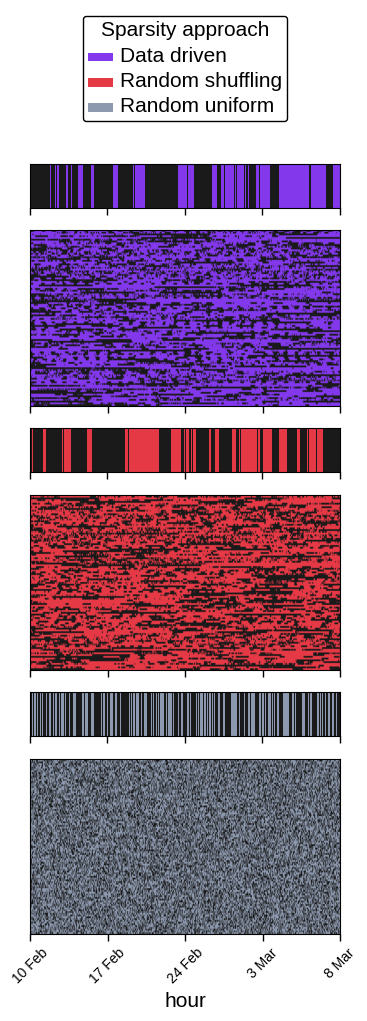

In [65]:
#selected range (if 4 -> [30-40]%)
q = 5

Titles = ['data-driven', 
          'random: shuffling gaps', 
          'random: uniform']

Titles = ['']*3

fig, Axes = make_axes_layout(
    [7], 
    order='col', 
    figsize=(4, 12), 
    gridspec_kw={'height_ratios': [3,1,4,1,4,1,4]})

axes = Axes[1:]

Axes_single_traj = [axes[0], axes[2], axes[4]]
_row_single_traj(Axes_single_traj, index = 22000, Titles=  Titles)

Axes_coverage = [axes[1], axes[3], axes[5]]

_row_visual_trajs(Axes_coverage, q)
legend_missingness(Axes[0], 
                   loc = 'upper center')

Axes[0].axis('off')
ax=Axes[0]
ax.set_xticks([0])
ax.set_xticklabels(['lab'])
for ax in axes:
    ax.axis('on')
    ax.set_xlabel('')
    ax.set_xticks([7*24*i for i in [0,1,2,3]] + [24*28])
    ax.set_yticks([])
    ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=False)
    ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=False)

ax = axes[-1]
print(ax.get_xlim())
ax.axis('on')
ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=True)
ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=True)
ax.set_xticks([i*24 for i in range(28)[::7]] + [28*24]) 
Dates_ticks = gen_date_ticks(Dates_plus1, date0 = False, month_str = True) 
Dates_ticks = np.concatenate([Dates_ticks[::7], np.array([Dates_ticks[-1]])]) 

ax.set_xticklabels(Dates_ticks , rotation = 45)

#axes[0].set_title('Gaps')
axes[-1].set_xlabel('hour')

for ax in Axes:
    restyle_ax(ax, tick_size = 10)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/OLD_comparison_masks.png',
    format="png", bbox_inches='tight', dpi=300
)

(-0.5, 672.0)
(-0.5, 99.5)
(-0.5, 99.5)
(-0.5, 99.5)


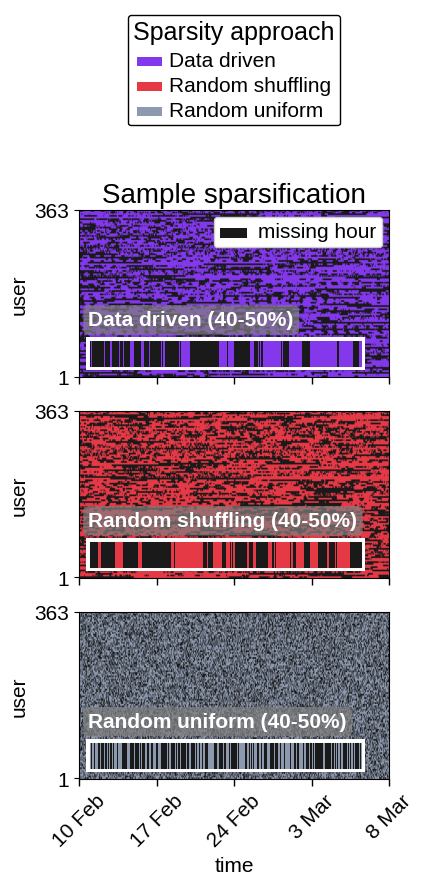

In [66]:
#selected range (if 4 -> [30-40]%)
q = 5

Titles = ['data-driven', 
          'random: shuffling gaps', 
          'random: uniform']

Titles = ['']*3

fig, Axes = make_axes_layout(
    [4], 
    order='col', 
    figsize=(4, 10), 
    gridspec_kw={'height_ratios': [4,4,4,4]})

axes = Axes[1:]

Axes_single_traj= []
for ax in axes:
    # width and height in percent of parent axis
    ax_inset = inset_axes(
        ax,
        width="90%",           # 80% of parent width
        height="20%",          # 10% of parent height
        loc="lower left",      # position
        borderpad=0.5)
    rect = patches.Rectangle(
    (0, 0), 1, 1,                       # full inset area
    transform=ax_inset.transAxes,
    fill=False,                         # border only
    edgecolor="white",
    linewidth=5,
    zorder=999)
    ax_inset.add_patch(rect)
    Axes_single_traj.append(ax_inset)
    
_row_single_traj(Axes_single_traj, index = 22000, Titles=  Titles)

Axes_coverage = [axes[0], axes[1], axes[2]]

_row_visual_trajs(Axes_coverage, q)
legend_missingness(Axes[0], 
                   loc = 'upper center')

Axes[0].axis('off')
ax=Axes[0]
ax.set_xticks([0])
ax.set_xticklabels(['lab'])
for ax in axes:
    ax.axis('on')
    ax.set_xlabel('')
    ax.set_xticks([7*24*i for i in [0,1,2,3]] + [24*28])
    ax.set_yticks([])
    ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=False)
    ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=False)

for ax in Axes_coverage:
    ax.axis('on')
    ax.set_xlabel('')
    ax.set_xticks([7*24*i for i in [0,1,2,3]] + [24*28])
    ax.set_yticks([])
    ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=False)
    ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=False)


ax = axes[-1]
print(ax.get_xlim())
ax.axis('on')
ax.tick_params(axis='x', which='major', length=5, width=1, labelbottom=True)
ax.tick_params(axis='x', which='minor', length=0, width=1, labelbottom=True)
ax.set_xticks([i*24 for i in range(28)[::7]] + [28*24]) 
Dates_ticks = gen_date_ticks(Dates_plus1, date0 = False, month_str = True) 
Dates_ticks = np.concatenate([Dates_ticks[::7], np.array([Dates_ticks[-1]])]) 

ax.set_xticklabels(Dates_ticks , rotation = 45)

#axes[0].set_title('Gaps')
axes[-1].set_xlabel('time')
axes[0].set_title('Sample sparsification')

for ax in axes:
    print(ax.get_ylim())
    _yt = np.array([0,100])
    _ytl = [1,363]
    #_ytl[0] = 1
    ax.set_yticks(_yt)
    ax.set_yticklabels(_ytl, rotation = 0)
    
ax= axes[0]
legend_elements = [
    Patch(facecolor=COLOR_GAPS, edgecolor='none', label='missing hour')
]
leg = ax.legend(handles=legend_elements, loc="upper right", frameon=True)
leg.get_frame().set_facecolor("white")
leg.get_frame().set_alpha(1.0) 



_Titles = ['Data driven (40-50%)', 
           'Random shuffling (40-50%)',
           'Random uniform (40-50%)']

for ax,t in zip(Axes[1:], _Titles):
    ax.set_ylabel('user')

    x,y = 0.03,0.4
    # draw a custom title fully inside the axes
    ax.text(
        x, y, t,
        transform=ax.transAxes,
        ha = "left", 
        va = "top",
        fontsize = ax_text_size,
        fontweight="bold",
        color = 'white',
        zorder = 100,
        bbox=dict(
        facecolor="grey",            # background color
        edgecolor="none",
        boxstyle="round,pad=0.25",    # rounded with padding
        alpha=0.7))                     # slight transparency (optional)),
    restyle_ax(ax)

restyle_ax(Axes[0], 
           legend_font_size = ax_label_size, 
           legend_title_size = ax_title_size)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_masks.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)


#### [Panel] pdf of gap durations

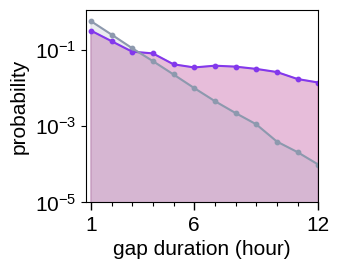

In [67]:
def _panel_pdf_gap_durations(ax,
                             q_select, 
                             hours_select = range(1,13),
                             ax_ticks = True):
    
    fill_alpha = 0.18  # transparency for the area fill
    
    _Xs = [df_X_emp, 
           df_X_random_keepdurations,
           df_X_random]
    
    _Gs = [df_gaps_emp,  
           df_gaps_random_kd,
           df_gaps_random]
    
    _ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu',
           'Random_uniform_1wgcu']
    
    dict_Xs = dict(zip(_ss, _Xs))
    dict_Gs = dict(zip(_ss, _Gs))
    
    #select sequences in the 40-50% range
    
    #dictionary of gap statistics in the 40-50% range
    dict_q_Xs = {}
    dict_q_Gs = {}
    
    for s,X,G in zip(_ss, _Xs, _Gs):
        
        df_q_X = X[X['q_range'] == q_select]
        select_seqs = df_q_X.index
        df_q_gaps = G[G['sequence_index'].isin(select_seqs)]
        
        dict_q_Xs[s] = df_q_X
        dict_q_Gs[s] = df_q_gaps


    for s, g in dict_q_Gs.items():
        gds = g.groupby(['gap_duration_hours']).size()/len(g)
        gds = gds.reindex(hours_select, fill_value=0)

        #print(gds)
        # y values (length 12) and matching x coords
        y = gds.loc[hours_select].values
        x = np.arange(len(y))  # 0..11
    
        # area
        ax.fill_between(
            x, 0, y,
            color = DICT_colors_ss[s],
            alpha = fill_alpha,
            zorder = 0
        )
        if s == 'Random_keepdurations_1wgcu':
            continue
            # line
            ax.plot(
                x, y,
                color=DICT_colors_ss[s],
                linestyle=(0, (4, 4))
            )
            
            # points (slightly shifted as you had)
            ax.scatter(
                x + 0.05, y,
                color=DICT_colors_ss[s],
                s=5)
      
        else:
            # line
            ax.plot(
                x, y,
                color=DICT_colors_ss[s])
            
            # points
            ax.scatter(
                x, y,
                color=DICT_colors_ss[s],
                s=10)
    

    if ax_ticks: 
        yticks = ax.get_yticks()
        ax.set_yticks(yticks)
        ax.set_yticklabels([f"{y*100:.0f}" for y in yticks])
        ax.set_ylim(0,.8)
        ax.set_ylim(1e-5,1.1)
        ax.set_yscale('log')   # for y-axis
        
        # choose the major tick positions
        major_ticks = [0, 5, 11]#, 17, 23]
        # set axis limits that include all major ticks
        ax.set_xlim(-.25, 11)
        # major ticks and labels
        ax.set_xticks(major_ticks)
        ax.set_xticklabels([str(t+1) for t in major_ticks])
        # minor ticks (optional): every hour
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
        # style
        ax.tick_params(axis="x", which="major", length=6, width=1)
        ax.tick_params(axis="x", which="minor", length=3, width=0.8)
        
        
fig, ax = plt.subplots(figsize=(3, 2.5))
q_select = 5
_panel_pdf_gap_durations(ax, q_select)
ax.set_xlabel('gap duration (hour)')
ax.set_ylabel('probability')
restyle_ax(ax)#, tick_size = 10)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/share_gap-duration.png',
    format="png", bbox_inches='tight', dpi=300
)

#### [Supp panel] pdf of gap durations

In [ ]:
fig, axes = plt.subplots(figsize=(14, 3), 
                         ncols = 5)
ax_titles = ['10-20%', 
             '20-30%', 
             '30-40%', 
             '40-50%', 
             '50-60%']

for q_select, ax,t in zip(range(1,6), axes, ax_titles):
    _panel_pdf_gap_durations(ax, 
                             q_select, 
                             hours_select = range(1,13),
                             ax_ticks = True)
    #ax.set_yscale('linear')
    #ax.set_ylim(0,1)
    ax.set_title(t)

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')

axes[2].set_xlabel('gap duration (hour)')
axes[0].set_ylabel('probability')
    
for ax in axes:
    restyle_ax(ax)#, tick_size = 10)

ax = axes[0]
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Data driven',
                                'Random uniform'],
                    'colors': [COLOR_BS, 'gray'], 
                    'title': '', 
                    'loc': 'lower left', 
                    'fontsize':10,
                    'title_fontsize':10})
ax_visual_legend(ax, DICT_legend)


plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/gaps_duration_pdf.png',
    format="png", bbox_inches='tight', dpi=300)

#### [TODO table - pdf of gap duration]

#### [Panel] pdf of entropy of gaps

In [ ]:
df_seq_stat['q_range'] = df_seq_stat['q_range'].astype(int)
df_seq_stat_keepdurations['q_range'] = df_seq_stat_keepdurations['q_range'].astype(int)

In [ ]:
df_seq_stat_keepdurations.head(2)

In [ ]:
df_seq_stat[['H','H_random']].describe()

In [ ]:
def plot_kde(ax, x, color, label=None, fill_alpha=0.35, ls='-', lw=1.5, z=1):
    x = np.asarray(x.dropna())
    kde = gaussian_kde(x)
    xx = np.linspace(x.min(), x.max(), 500)
    yy = kde(xx)
    if fill_alpha > 0:
        ax.fill_between(xx, yy, 0, color=color, alpha=fill_alpha, zorder=z)
    ax.plot(xx, yy, color=color, lw=lw, ls=ls, zorder=z+1, label=label)
    return xx, yy

fig, ax = plt.subplots(figsize=(3, 2.5))

# Random uniform
plot_kde(ax,
         df_seq_stat['H_random'],
         color=DICT_colors_ss['Random_uniform_1wgcu'],
         label='Random uniform',
         fill_alpha=0.35)

# Data-driven
xx, yy = plot_kde(ax,
                  df_seq_stat['H'],
                  color=DICT_colors_ss['Data_driven_1wgcu'],
                  label='Data-driven',
                  fill_alpha=0.35)

# Random keep-durations (same as Data-driven by design):
# show underlying color via transparent fill; overlay with a distinct dashed outline
#plot_kde(ax,
#         df_seq_stat_keepdurations['H_random'],
#         color=DICT_colors_ss['Random_keepdurations_1wgcu'],
#         label='Random keep-durations',
#         fill_alpha=0.1,     # no second fill that would hide the first
#         ls='--', lw=2.0, z=3)

ax.set_xlabel('Entropy')
ax.set_ylabel('KDE density')
ax.set_ylim(0,4.2)
ax.set_xlim(0,3)
restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/entropy_allsample.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
from scipy.stats import gaussian_kde
import numpy as np

def plot_kde(ax, x, color, label=None, fill_alpha=0.35, ls='-', lw=1.5, z=1):
    """Plot 1D KDE with optional filled area."""
    x = np.asarray(x.dropna())
    kde = gaussian_kde(x)
    xx = np.linspace(x.min(), x.max(), 500)
    yy = kde(xx)
    if fill_alpha > 0:
        ax.fill_between(xx, yy, 0, color=color, alpha=fill_alpha, zorder=z)
    ax.plot(xx, yy, color=color, lw=lw, ls=ls, zorder=z+1, label=label)
    return xx, yy

def _panel_gap_entropy(ax, 
                       q_select = 5):
    
    # --- Filter datasets for q_range == 5 ---
    df_seq_stat_filt = df_seq_stat[df_seq_stat["q_range"] == q_select]
    df_seq_stat_keepdurations_filt = df_seq_stat_keepdurations[df_seq_stat_keepdurations["q_range"] == q_select]
    
    # Random uniform
    plot_kde(
        ax,
        df_seq_stat_filt["H_random"],
        color=DICT_colors_ss["Random_uniform_1wgcu"],
        label="Random uniform",
        fill_alpha=0.35
    )
    
    # Data-driven
    xx, yy = plot_kde(
        ax,
        df_seq_stat_filt["H"],
        color=DICT_colors_ss["Data_driven_1wgcu"],
        label="Data-driven",
        fill_alpha=0.35
    )
    
    ax.set_ylim(0, 4.2)
    ax.set_xlim(1, 2.6)

# --- Plot ---
fig, ax = plt.subplots(figsize=(3, 2.5))

_panel_gap_entropy(ax, q_select = 5)
# --- Axis settings ---
ax.set_xlabel("entropy")
ax.set_ylabel("density")
restyle_ax(ax)#, tick_size=10)

plt.savefig(
    "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/entropy.png",
    format="png", bbox_inches="tight", dpi=300
)


In [ ]:
import numpy as np

def plot_pmf(ax, x, bins, color, label=None, alpha=0.35, lw=1.5, z=1):
    x = np.asarray(x.dropna())
    counts, edges = np.histogram(x, bins=bins)
    p = counts / counts.sum()  # probabilities per bin
    centers = 0.5 * (edges[:-1] + edges[1:])

    # filled bars/area
    ax.bar(centers, p, width=np.diff(edges), align='center',
           color=color, alpha=alpha, edgecolor='none', zorder=z)
    # outline as a step
    ax.step(edges, np.r_[p, p[-1]], where='post',
            color=color, lw=lw, zorder=z+1, label=label)

# pick a common binning for fair comparison
bins = np.linspace(
    min(df_seq_stat['H'].min(), df_seq_stat['H_random'].min(), df_seq_stat_keepdurations['H_random'].min()),
    max(df_seq_stat['H'].max(), df_seq_stat['H_random'].max(), df_seq_stat_keepdurations['H_random'].max()),
    31
)

fig, ax = plt.subplots(figsize=(3,2.5))

plot_pmf(ax, df_seq_stat['H_random'],
         bins=bins, color=DICT_colors_ss['Random_uniform_1wgcu'], label='Random uniform')

plot_pmf(ax, df_seq_stat['H'],
         bins=bins, color=DICT_colors_ss['Data_driven_1wgcu'], label='Data-driven')

# “keep-durations” equals data-driven by design → differentiate with dashed outline only
plot_pmf(ax, df_seq_stat_keepdurations['H_random'],
         bins=bins, color=DICT_colors_ss['Random_keepdurations_1wgcu'], label='Random keep-durations', alpha=0.0)
ax.step(bins, np.r_[np.histogram(df_seq_stat_keepdurations['H_random'].dropna(), bins=bins)[0] /
                    np.histogram(df_seq_stat_keepdurations['H_random'].dropna(), bins=bins)[0].sum(),
        0][-1::-1][::-1], where='post', color=DICT_colors_ss['Random_keepdurations_1wgcu'], lw=2, ls='--')

ax.set_xlabel('Entropy')
ax.set_ylabel('prob')
restyle_ax(ax)

In [ ]:
_dfs = df_seq_stat.copy()
fig, ax = plt.subplots(figsize = (5,5))
scatter_df(ax, _dfs, 'ngaps', 'H_random')
scatter_df(ax, _dfs, 'ngaps', 'H', c = 'red')

_dfs = df_seq_stat_keepdurations.copy()
fig, ax = plt.subplots(figsize = (5,5))
scatter_df(ax, _dfs, 'ngaps', 'H_random')
scatter_df(ax, _dfs, 'ngaps', 'H', c = 'red')

#### [Supp panel] Entropy of gaps

In [ ]:
fig, axes = plt.subplots(figsize=(14, 3), 
                         ncols = 5)
ax_titles = ['10-20%', 
             '20-30%', 
             '30-40%', 
             '40-50%', 
             '50-60%']

for q_select, ax,t in zip(range(1,6), axes, ax_titles):
    _panel_gap_entropy(ax, q_select = q_select)
    ax.set_xlim(-.1,3)
    ax.set_title(t)

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')

axes[2].set_xlabel('Entropy of gap duration distribution')
axes[0].set_ylabel('KDE density')
    
for ax in axes:
    restyle_ax(ax)#, tick_size = 10)


ax = axes[0]
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['Data driven',
                                'Random uniform'],
                    'colors': [COLOR_BS, 'gray'], 
                    'title': '', 
                    'loc': 'upper left', 
                    'fontsize':10,
                    'title_fontsize':10})
ax_visual_legend(ax, DICT_legend)


plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/gaps_duration_entropy.png',
    format="png", bbox_inches='tight', dpi=300)

#### [Panel - combined] gap durations and entropy of gaps

In [ ]:
fig, axes = plt.subplots(figsize = (3.5,5.5), nrows = 2)

q_select = 5
_panel_pdf_gap_durations(axes[0],q_select)
_panel_gap_entropy(axes[1], q_select)

for ax in axes:
    restyle_ax(ax)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace = .4)


plt.savefig(
    "Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/pdf_gaps_and_entropy.png",
    format="png", bbox_inches="tight", dpi=300
)


#### [Panel] pdf of missingness  

In [ ]:
VIZ_ALL_RANGES = False

if VIZ_ALL_RANGES:    
    
    for q in range(1,7):
        
        q_select = [q]
        LIST_emp_ms = [compute_missingness_share(dict_Xs[s], 
                                                 q = q_select)
                       for s in _ss]
    
        fig, ax = plt.subplots(figsize = (5,5))
        for emp_ms,s in zip(LIST_emp_ms, _ss):
            
            ax.plot(emp_ms.values, 
                    color = DICT_colors_ss[s])
            ax.set_title(f'q = {q}')

In [ ]:
def to_12h_label(h):
    """Return '12 am/pm' style label for hour h in [0..23]."""
    if h == 0:
        return "12 am"
    if h < 12:
        return f"{h} am"
    if h == 12:
        return "12 pm"
    return f"{h-12} pm"

def make_xtick_labels(ticks, start_hour):
    """Shift ticks by start_hour and format as 12-hour labels."""
    shifted = [ (t + start_hour) % 24 for t in ticks ]
    return [to_12h_label(h) for h in shifted]

def shift_and_sort_by_start_hour(df, start_hour, hour_col="hourofday"):
    """Shift hours so 'start_hour' becomes 0, then sort by that order."""
    df["hourofday_tick"] = (df[hour_col] + (24 - start_hour)) % 24
    return df.sort_values(by="hourofday_tick")

def draw_filled_line(
    ax,
    x,
    y,
    color,
    base=0.03,
    alpha=0.2,
    lw=1.5,
    s=10,
    marker='o',
    facecolor='none'):
    """Fill under curve to a base line, then draw line and markers."""
    
    ax.fill_between(
        x, y, base,
        color=color,
        alpha=alpha
    )

    ax.plot(
        x, y,
        color=color,
        linewidth=lw
    )

    ax.scatter(
        x, y,
        edgecolor=color,
        facecolor=facecolor,  # use facecolor argument
        s=s,
        marker=marker
        
    )


# x-axis ticks and labels
start_hour = 9
_xticks = [0, 7, 13, 19, 23]



fig, ax = plt.subplots(figsize=(5, 5))

LIST_emp_ms = DICT_missingness_share['hourofday']

for e, s in zip(LIST_emp_ms, _ss):
    _e = e.copy()
    _e['hourofday'] +=1
    _e = shift_and_sort_by_start_hour(_e, start_hour)
    y = _e["prob"].values
    x = np.arange(len(y))  # 0..len-1

    draw_filled_line(ax, x, y, color=DICT_colors_ss[s], base=0.03, alpha=0.2, lw=1.5, s=15)


_xticks_labels = make_xtick_labels(_xticks, start_hour)
ax.set_xticks(_xticks)
ax.set_xticklabels(_xticks_labels, rotation=45)

# titles / labels
ax.set_title("[40-50]% sparsity")
ax.set_xlabel("hour of day")
set_percent_yticks(ax, decimals=2)
ax.set_ylabel("missingness share (%)")

# limits & grid
ax.set_ylim(0.03, 0.052)
ax.set_xlim(0, 23)
ax.grid(True, axis="x", linestyle="-", color="gray", alpha=0.7)

restyle_ax(ax)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))

LIST_emp_ms = DICT_missingness_share['hourofweek']

for _e, s in zip(LIST_emp_ms, _ss):

    y = _e['prob'].values
    x = np.arange(len(y))   # or your own x-axis
    
    ax.fill_between(x, y, 0.004,
                    color = DICT_colors_ss[s],
                    alpha = 0.2)        # filled area
    
    ax.plot(x, 
            y,
            color = DICT_colors_ss[s],
            linewidth=1.5)  

    ax.scatter(x, 
               y,
               color = DICT_colors_ss[s], s = 10)

# titles / labels
ax.set_title("[40-50]% sparsity")
ax.set_xlabel("hour of week")
set_percent_yticks(ax, decimals=2)
ax.set_ylabel("missingness share (%)")
ax.set_xlim(0,168)
ax.set_ylim(0.004,0.01)
restyle_ax(ax)

In [ ]:
def _panel_pdf_missingness(ax, DICT_missingness_share):

    start_hour = 8
    _xticks = [0, 6, 12, 18, 23]
    _xticks_labels = make_xtick_labels(_xticks, start_hour)
    
    #week-period list 
    _wpl = [DICT_missingness_share['hourofday_given_weekday'],
            DICT_missingness_share['hourofday_given_weekend']]
    
    for LIST_emp_ms, title, marker  in zip(_wpl, 
                                            ['weekday', 'weekend'],
                                            ['o', 'D']):
    
        for e, s in zip(LIST_emp_ms, _ss):
            _e = e.copy()
            _e['hourofday'] +=1
            _e = shift_and_sort_by_start_hour(_e, start_hour)
            y = _e["prob"].values
            x = np.arange(len(y))  # 0..len-1
    
            c = DICT_colors_ss[s]
            draw_filled_line(ax, x, y, 
                             color = c, 
                             base=0.03, alpha= 0.1, lw=.5, s=20, 
                             marker= marker, 
                             facecolor = c if (title =='weekday') else 'none')
    
        #ax.set_title(title)
    
    # x-axis ticks and labels
    ax.set_xticks(_xticks)
    ax.set_xticklabels(_xticks_labels, rotation=45)
    
    # titles / labels
    set_percent_yticks(ax, decimals=1)
    ax.set_ylabel("prob. sparsity (%)")

    # get current x-limits
    xmin, xmax = ax.get_xlim()
    # set minor ticks every 1 unit
    ax.set_xticks(np.arange(np.floor(xmin), np.ceil(xmax) + 1, 1), minor=True)
    # optional: style them
    ax.tick_params(axis='x', which='minor', length=2, width=0.8, rotation = 45)
    
    # limits & grid
    ax.set_ylim(0.03, 0.055)
    ax.set_xlim(0, 23)
    ax.grid(True, 
            axis="x", 
            linestyle="-", 
            color="gray", 
            alpha=0.7)
    
    #legend_missingness(ax, loc = 'upper left')
    
    legend_elements = [
        Line2D([0], [0],
               marker='o',
               color='black',       # line color (unused here)
               markerfacecolor='black',
               markeredgecolor='black',
               linestyle='None',
               label='weekday'),
        Line2D([0], [0],
               marker='D',
               color='black',
               markerfacecolor='none',   # hollow marker
               markeredgecolor='black',
               linestyle='None',
               label='weekend')]
    
    ax.legend(handles=legend_elements, loc='upper left')

fig, ax = plt.subplots(figsize=(3, 2.5))#, ncols = 2)
_panel_pdf_missingness(ax, DICT_missingness_share)

restyle_ax(ax)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/share_missingness.png',
            format="png", bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3))#, ncols = 2)

start_hour = 9
_xticks = [0, 7, 13, 19, 23]

_xticks_labels = make_xtick_labels(_xticks, start_hour)
LIST_emp_ms = DICT_missingness_share['hourofday_weekperiod']
for emp_ms, s in zip(LIST_emp_ms,
                     _ss):

    KIT_conversion_dates.split_df_hourofday_weekperiod(emp_ms)
    emp_ms = emp_ms.sort_values(by = ['weekperiod', 'hourofday'])
    emp_ms_weekend = emp_ms[emp_ms['weekperiod'] == 'weekend']
    emp_ms_weekday = emp_ms[emp_ms['weekperiod'] == 'weekday']
    #emp_ms_weekend = emp_ms_weekend.eval('prob = prob/2')
    #emp_ms_weekday = emp_ms_weekday.eval('prob = prob/5')

    for _e, title, marker in zip([emp_ms_weekday, emp_ms_weekend], 
                                 ['weekday', 'weekend'], 
                                 ['o', 'D']):
    
        _e = shift_and_sort_by_start_hour(_e, 
                                          start_hour)
        y = _e["prob"].values
        x = np.arange(len(y))  # 0..len-1 
        draw_filled_line(ax, 
                         x, y, 
                         color = DICT_colors_ss[s], 
                         base = 0.03, 
                         alpha = 0, 
                         lw = 1.5, 
                         s = 10,
                         marker = marker)
        

#### [Supp panel] pdf of missingness 

In [ ]:
fig, axes = plt.subplots(figsize=(12, 2.5), ncols = 5)#, ncols = 2)
for ax, q in zip(axes, range(1,6)):
    _panel_pdf_missingness(ax, DICT_missingness_share_q[q])
    restyle_ax(ax)
#plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/share_missingness.png',
#            format="png", bbox_inches='tight', dpi=300)

#### [Panel] pdf of contact probability

In [ ]:
df_merged.head(2)

In [ ]:
df_merged['hourofday_weekperiod'] = KIT_conversion_dates.get_hourofday_weekperiod(df_merged['datehour'].values)
KIT_conversion_dates.split_df_hourofday_weekperiod(df_merged)
df_merged.head(2)

In [ ]:
def contact_share(df_merged,
                  s = 'Data_driven_1wgcu',
                  l = str(Levels[3]),
                  wp = 'weekday'):
    
    df_sl = df_merged[(df_merged['ss']==s) & (df_merged['level'] ==l)]
    df_slwp =  df_sl[(df_sl['weekperiod'] == wp)]
    df_slwp = df_slwp.groupby('hourofday').agg({'count_contacts':'sum'})
    df_slwp['prob'] = df_slwp['count_contacts']/df_slwp['count_contacts'].sum()
    
    return df_slwp.reset_index()

LIST_emp_cs_weekday = [contact_share(df_merged,
                                     s = s,
                                     wp = 'weekday') for s in _ss]

LIST_emp_cs_weekend = [contact_share(df_merged,
                                     s = s,
                                     wp = 'weekend') for s in _ss]


In [ ]:
def _panel_pdf_contact(ax):

    start_hour = 8
    _xticks = [0, 6, 12, 18, 23]
    _xticks_labels = make_xtick_labels(_xticks, start_hour)

    #week-period list 
    _wpl = [LIST_emp_cs_weekday,
            LIST_emp_cs_weekend]

    for LIST_emp_ms, title, marker  in zip(_wpl, 
                                           ['weekday', 'weekend'],
                                           ['o', 'D']):
        
        for e, s in zip(LIST_emp_ms, _ss):
            _e = e.copy()
            _e['hourofday']+= 1
            _e = shift_and_sort_by_start_hour(_e, start_hour)
            y = _e["prob"].values
            x = np.arange(len(y))  # 0..len-1

            c = DICT_colors_ss[s]
            draw_filled_line(ax, x, y, 
                             color = c, 
                             base=0, alpha= 0.1, lw=.5, s=20, 
                             marker= marker, 
                             facecolor = c if (title =='weekday') else 'none')

    # x-axis ticks and labels
    ax.set_xticks(_xticks)
    ax.set_xticklabels(_xticks_labels, rotation=45)

    # get current x-limits
    xmin, xmax = ax.get_xlim()
    # set minor ticks every 1 unit
    ax.set_xticks(np.arange(np.floor(xmin), np.ceil(xmax) + 1, 1), minor=True)
    # optional: style them
    ax.tick_params(axis='x', which='minor', length=2, width=0.8)

    # titles / labels
    #ax.set_title("[40-50]% sparsity")
    #ax.set_xlabel("hour of day")
    set_percent_yticks(ax, decimals=0)
    ax.set_ylabel("prob. contact (%)")
    
    # limits & grid
    ax.set_ylim(0, 0.12)
    ax.set_xlim(0, 23)
    ax.grid(True, axis="x", linestyle="-", color="gray", alpha=0.7)

fig, ax = plt.subplots(figsize=(3, 2.5))#, ncols = 2)
_panel_pdf_contact(ax)
restyle_ax(ax)#, tick_size = 10)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/share_contacts.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)

#### [Panel - combined] pdf of missingness and contact probability

In [ ]:
fig, axes = plt.subplots(figsize = (3.5,5), nrows = 2)

ax = axes[0]
_panel_pdf_missingness(ax, DICT_missingness_share)
restyle_ax(ax, 
           legend_font_size = 10, tick_size = 10)
remove_axis_ticktext(ax, axis= 'x')

ax= axes[1]
_panel_pdf_contact(ax)
ax.tick_params(axis='x',rotation = 45)
ax.set_xlabel('hour of day')

for ax in axes:
    restyle_ax(ax)#, tick_size = 10)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace = .3)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/pdf_missingness_and_contacts.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)

#### [4panels combined - missingness statistics]

In [ ]:
fig, Axes = plt.subplots(figsize = (7.5,5.5), nrows = 2, ncols= 2)

axes = Axes[:,1]
ax = axes[0]
_panel_pdf_missingness(ax, DICT_missingness_share)
restyle_ax(ax, 
           legend_font_size = 10, tick_size = 10)
remove_axis_ticktext(ax, axis= 'x')

ax= axes[1]
_panel_pdf_contact(ax)
ax.tick_params(axis='x',rotation = 45)
ax.set_xlabel('hour of day')

for ax in axes:
    restyle_ax(ax)#, tick_size = 10)

fig.align_ylabels(axes)
fig.subplots_adjust(hspace = .3)

axes = Axes[:,0]
q_select = 5
_panel_pdf_gap_durations(axes[0],q_select)
_panel_gap_entropy(axes[1], q_select)
axes[0].set_xlabel('gap duration (hour)')
axes[0].set_ylabel('probability')

axes[1].set_xlabel('entropy')
axes[1].set_ylabel('probability density')

for ax in axes:
    restyle_ax(ax)

fig.align_ylabels(axes)
fig.align_xlabels(Axes)

fig.subplots_adjust(wspace = .4, hspace = .5)
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/missingness_stats.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)


#### [Panel] Missing users and contact activity

In [ ]:
from sklearn.metrics import r2_score

def rsq(df, col1, col2, corr_type = 'pearson_r2'):
    if corr_type =='pearson_r2':
        return (df[col1].corr(df[col2]))
    else:
        return r2_score(df[col1], df[col2])

def _unify_limits(axes):
    # compute global min/max over all axes for both x and y
    xmin = min(ax.get_xlim()[0] for ax in axes.ravel())
    xmax = max(ax.get_xlim()[1] for ax in axes.ravel())
    ymin = min(ax.get_ylim()[0] for ax in axes.ravel())
    ymax = max(ax.get_ylim()[1] for ax in axes.ravel())
    for ax in axes.ravel():
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

def rescale_to_bins(values, bins):
    """Linear rescale into bin-index space (uniform bins)."""
    
    values = np.asarray(values, dtype=float)
    bins   = np.asarray(bins, dtype=float)
    step   = np.diff(bins)
    
    if not np.allclose(step, step[0]):
        raise ValueError("For linear rescale, bins must be uniformly spaced.")
    return (values - bins[0]) / step[0]

def map_values_to_bincoords(values, edges, fractional=True):
    """
    Map real values to heatmap coordinates for (possibly non-uniform) bin edges.
    Returns continuous coordinates: i + t within each bin if fractional=True,
    otherwise bin centers (i + 0.5).
    """
    vals = np.asarray(values, dtype=float)
    out = np.full_like(vals, np.nan, dtype=float)

    m = np.isfinite(vals)
    if not m.any():
        return out

    idx = np.searchsorted(edges, vals[m], side='right') - 1
    idx = np.clip(idx, 0, len(edges) - 2)

    if fractional:
        left = edges[idx]
        right = edges[idx + 1]
        t = (vals[m] - left) / (right - left)
        t = np.clip(t, 0.0, 1.0)
        out[m] = idx + t
    else:
        out[m] = idx + 0.5
    return out

def _binned_percentile_yvals(df, 
                             x_col, y_col, 
                             x_bins, 
                             percentile,
                             use_weight=True, 
                             weight_col="weight"):
    """
    Return a 1D float array of length len(x_bins) with NaN at the left edge.
    """
    df = df[[x_col, y_col] + ([weight_col] if use_weight else [])].dropna()
    x_idx = np.digitize(df[x_col].to_numpy(), x_bins)

    def _to_scalar(q):
        # coerce np.array / np.ndarray / pandas scalar to Python float or np.nan
        if q is None:
            return np.nan
        q_arr = np.asarray(q, dtype=float).reshape(-1)
        return q_arr[0] if q_arr.size else np.nan

    q_by_xbin = {}
    p = float(percentile) / 100.0

    for i in range(1, len(x_bins)):
        mask = (x_idx == i)
        if not mask.any():
            q_by_xbin[i] = np.nan
            continue

        vals = df.loc[mask, y_col].to_numpy()
        if use_weight:
            w = df.loc[mask, weight_col].to_numpy()
            q = DescrStatsW(data=vals, weights=w).quantile(probs=p, return_pandas=False)
        else:
            q = np.nanquantile(vals, p)

        q_by_xbin[i] = _to_scalar(q)

    # prepend NaN for the left edge so indexing aligns with bins
    y_vals = [np.nan] + [q_by_xbin.get(i, np.nan) for i in range(1, len(x_bins))]
    
    return np.asarray(y_vals, dtype=float)

def plot_binned_percentile(ax,
                           _df,
                           x_col, y_col,
                           x_bins, y_bins,
                           percentile=50,
                           color='cyan',
                           linestyle='-',
                           linewidth=2,
                           scatter=False,
                           scatter_size=1,
                           use_weight = True, 
                           weight_col = "weight",
                           bin_non_linear=False,   # <--- NEW
                           no_binning = False,
                           _plot = True,
                           **kwargs):
    """
    Plot a percentile line over a binned heatmap.
    If bin_non_linear=True, y is mapped to bin coordinates using the actual (possibly non-uniform) y_bins.
    Otherwise, a linear rescale (uniform bins) is applied as before.
    """
    # 1) Get percentile y at each x-bin (in DATA units)
    y_vals = _binned_percentile_yvals(_df, x_col, y_col, x_bins, 
                                      percentile, 
                                      use_weight = use_weight, 
                                      weight_col = weight_col)
    
    if no_binning:
        ax.scatter(x_bins, y_vals, color=color, s=scatter_size)
    else:
        # 2) Map y to heatmap coordinates
        if bin_non_linear:
            y_rescaled = map_values_to_bincoords(y_vals, y_bins, fractional=True)
        else:
            y_rescaled = rescale_to_bins(y_vals, y_bins)
    
        # 3) x mapping (keep your original)
        x_rescaled = (x_bins - x_bins[0]) / (np.diff(x_bins)[1]) - 0.5
    
        # 4) draw
        if _plot:
            ax.plot(x_rescaled, y_rescaled, color=color, linestyle=linestyle, linewidth=linewidth, **kwargs)
        if scatter:
            ax.scatter(x_rescaled, y_rescaled, color=color, s=scatter_size)


def _filter_df(df, 
               s, 
               hours_daytime, 
               weekday = None, 
               daytime = None):
    
    df_s = df[df['ss'] == s].copy()

    if daytime is not None:
        cond_daytime = df_s['hourofday'].isin(hours_daytime)
        df_s = df_s[cond_daytime if daytime else ~cond_daytime]

    if weekday is not None:
        cond_weekday = (df_s['weekperiod'] == 'weekday')
        df_s = df_s[cond_weekday if weekday else ~cond_weekday]

    return df_s

def _plot_panel(ax, 
                df, 
                level, 
                color, *, 
                logy=True, 
                hide_xticks=False, 
                hide_yticks=False):
    
    dict_level = subset_df_feature(df, 'level')
    df_sl = dict_level[str(level)]
    scatter_df(ax,
               df_sl,
               x='count_users',
               y='count_contacts',
               y_rename='',
               s=.1,
               c=color)
    if logy:
        ax.set_yscale('log')
    if hide_xticks:
        ax.set_xlabel('')
        remove_axis_ticktext(ax, axis='x')
    if hide_yticks:
        remove_axis_ticktext(ax, axis='y')

def _heatmap_count(ax, 
                   df, level, 
                   xbins, 
                   ybins, 
                   cmap = 'Reds', 
                   vmin = 0,
                   vmax = 150, 
                   log10 = False, 
                   cbar = True, 
                   plot_percentile = False): 

    dict_level = subset_df_feature(df, 'level')
    df_sl = dict_level[str(level)]
    
    kit_hm.visual_heatmap_2d(ax, 
                             df_sl, 
                             'count_users', 
                             'count_contacts', 
                             xbins, 
                             ybins,#bin_contacts, 
                             #xticks = bin_users,
                             #yticks = bin_contacts,
                             cmap = cmap,
                             normalize = False, 
                             log10 = log10, 
                             vmin = vmin, 
                             vmax = vmax, 
                             cbar = cbar) 
                             #cbar_orientation= 'horizontal')

    if plot_percentile:
        plot_binned_percentile(ax,
                               df_sl,
                               'count_users', 
                               'count_contacts', 
                               bin_users, 
                               bin_contacts, 
                               percentile=50,
                               color='black',
                               linestyle = '-',
                               linewidth = 2,
                               scatter=True,
                               scatter_size = 10,
                               use_weight = False, 
                               weight_col = "weight",
                               bin_non_linear=True,   # <--- NEW
                               _plot = False, 
                               no_binning = False)




In [ ]:
#Import contact and mask data
ss = 'Random_keepdurations_1wgcu'
level = Levels[1]
N_sparse_iter = 0
df_contacts_level = import_sparse_contacts(ss, level, N_sparse_iter)
df_mask = import_sparse_mask(ss,level,N_sparse_iter)

_DICT_rename_ls = {'Data_driven_1wgcu' : 'Data driven', 
                   'Random_keepdurations_1wgcu': 'Random keeping gap durations', 
                   'Random_uniform_1wgcu': 'Random record removal',
                   'Data_driven_1wgcu' : 'Data driven', 
                   'Random_keepdurations_1wgcu' : 'Random keeping gap durations',
                   'Random_uniform_1wgcu' : 'Random record removal'}

_LS = ['Data_driven_1wgcu', 
       'Random_keepdurations_1wgcu', 
       'Random_uniform_1wgcu']


In [ ]:
for s in _LS:
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level')
    fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
    
    for ax,l in zip(axes, Levels):# = Levels[0]
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   y = 'count_users', 
                   x = 'count_contacts', 
                   c = df_sl['hourofday'],
                   cmap = 'Purples', colorbar=True)
        ax.set_ylim(80,350)
        if l != Levels[0]:
            ax.set_ylabel('')
            remove_axis_ticktext(ax, axis= 'y')
        ax.set_xscale('log')
    plt.suptitle(s)

In [ ]:
for s in _LS:
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level')
    fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
    
    for ax, l in zip(axes, Levels):# = Levels[0]
        
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   x = 'count_users', 
                   y = 'count_contacts', 
                   c = df_sl['hourofday'],
                   cmap = 'Purples', colorbar=True)
        ax.set_xlim(80,350)
        if l != Levels[0]:
            ax.set_ylabel('')
            remove_axis_ticktext(ax, axis= 'y')
        ax.set_yscale('log')
    plt.suptitle(s)

In [ ]:
N_users

In [ ]:
df_merged

In [ ]:
fig, axes = plt.subplots(figsize = (7.5,2.5), 
                         ncols=4, 
                         gridspec_kw={'width_ratios': [1,1,1,.1]})

start_hour = 7
l = Levels[4]

bin_users = np.linspace(100,250, 20)
bin_contacts = np.linspace(10,1e3, 20)

for ax, s in zip(axes, _ss):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level').copy()
    
    df_sl = dict_level_df_s[str(l)].copy()
    df_sl['hourofday'] += (24 - start_hour)
    df_sl['hourofday'] %= 24
    
    df_sl['missing_users'] = (N_users - df_sl['count_users'])/N_users

    scatter_df(ax, 
               df_sl, 
               x = 'count_users', 
               y = 'count_contacts',
               y_rename = '', 
               x_rename = '',
               s = .1,
               #c = DICT_colors_ss[s])
               c = df_sl['hourofday'],
               cmap = 'Blues', 
               colorbar=False)

    # linear regression on the specified domain and plot the interpolating line
    mask = (df_sl['count_users'] >= 80) & (df_sl['count_users'] <= 250)
    x_fit = df_sl.loc[mask, 'count_users'].to_numpy()
    y_fit = df_sl.loc[mask, 'count_contacts'].to_numpy()
    
    m, b = np.polyfit(x_fit, np.log10(y_fit), 1) 
    _x1,_x2 = ax.get_xlim() # y = m*x + b
    x_line = np.linspace(_x1,_x2, 200)
    y_line = m * x_line + b
    #ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, zorder=3)

    plot_binned_percentile(ax,
                               df_sl,
                               'count_users', 
                               'count_contacts', 
                               bin_users, 
                               bin_contacts, 
                               percentile=50,
                               color='black',
                               linestyle = '-',
                               linewidth = 2,
                               scatter=True,
                               scatter_size = 5,
                               use_weight = False, 
                               weight_col = "weight",
                               bin_non_linear=True,   # <--- NEW
                               _plot = False, 
                               no_binning = True)

    
    
    ax.set_yscale('log')
    ax.set_xlim(100,250)
    ax.set_ylim(2,1.2e3)

    R2 = rsq(df_sl, 'count_users', 'count_contacts')
    ax.text(0.98, 0.02,                      # (x,y) bottom-right
            fr"$\rho^2 = {R2:.3f}$",         # latex-style rho^2
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10,
        )



    if s != _ss[-1]:
        ax.set_xlabel('')
        #remove_axis_ticktext(ax, axis= 'x')

axes[0].set_ylabel('detected contacts')
axes[1].set_xlabel('active users')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')

ax = axes[-1]
# clear axis and turn it off
ax.clear()#set_axis_off()

# define colormap and normalization
cmap = plt.get_cmap("Blues")
norm = mpl.colors.Normalize(vmin=0, vmax=23)

# colorbar directly within the same axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,                      # use this axis as the colorbar container
    orientation='vertical'
)

# set 24 ticks and labels
cbar.set_ticks(range(24))
cbar.set_ticklabels([
    '8 am' if i == 0 else
    '14 pm' if i == 6 else
    '20 pm' if i == 12 else
    '2 am' if i == 18 else 
    '7 am' if i ==23 else ''
    for i in range(24)
], size = 10)

# label
#cbar.set_label('hour of day')

_Titles = ['Data driven', 
           'Random shuffling',
           'Random uniform']

for ax,t in zip(axes, _Titles):
    ax.set_title(t)
    ax.tick_params(axis='x', rotation = 90)
    restyle_ax(ax, 
               title_size=15, 
               tick_size = 10, 
               text_size = 10)#, cbar = cbar)

axes[-1].set_title('hour of day', x = 1.5)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/user_contact_hourofday.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
def ax_colorbar_inset(ax):

    # clear axis
    ax.clear()
    
    # colormap + norm
    cmap = plt.get_cmap("Blues")
    norm = mpl.colors.Normalize(vmin=0, vmax=23)
    
    # horizontal colorbar inside this axis
    cbar = plt.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=ax,
        orientation='horizontal'
    )
    
    # ----- DEFINE MAJOR / MINOR TICKS -----
    
    minor_ticks = np.arange(24)                      # 0..23
    major_ticks = np.array([0, 12, 23])       # labels only here
    
    cbar.set_ticks(major_ticks)                      # major ticks
    cbar.ax.set_xticks(minor_ticks, minor=True)      # add minor ticks
    
    # ----- SET TICK LABELS ONLY FOR MAJORS -----
    
    major_labels = [
        '8 am',      # hour 0
        '8 pm',     # hour 12
        '7 am'       # hour 23
    ]
    
    cbar.set_ticklabels(major_labels, size=10)
    
    # optional style
    #ax.set_xlabel('hour of day')
    restyle_ax(ax, label_size=ax_tick_size)
    
    # ensure horizontal alignment
    for label in cbar.ax.get_xticklabels():
        label.set_rotation(0)
    
fig, ax = plt.subplots(figsize=(1.5, .1))
ax_colorbar_inset(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/hourofday_colorbar.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
_ss = _LS

In [ ]:
fig, axes = plt.subplots(figsize = (8.3,3), 
                         ncols=4, 
                         gridspec_kw={'width_ratios': [1,1,1,.1]})

start_hour = 7
l = Levels[4]

bin_contacts = np.linspace(10,1e3, 20)

for ax, s in zip(axes, _LS):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level').copy()
    
    df_sl = dict_level_df_s[str(l)].copy()
    df_sl['hourofday'] += (24 - start_hour)
    df_sl['hourofday'] %= 24
    
    df_sl['missing_users'] = (N_users - df_sl['count_users'])/N_users

    x_metric= 'missing_users'
    scatter_df(ax, 
               df_sl, 
               x = x_metric, 
               y = 'count_contacts',
               y_rename = '', 
               x_rename = '',
               s = .1,
               #c = DICT_colors_ss[s])
               c = df_sl['hourofday'],
               cmap = 'Blues', 
               colorbar=False)

    # linear regression on the specified domain and plot the interpolating line
    mask = (df_sl[x_metric] >= 0) & (df_sl[x_metric] <= 1)
    x_fit = df_sl.loc[mask, 'missing_users'].to_numpy()
    y_fit = df_sl.loc[mask, 'count_contacts'].to_numpy()
    
    m, b = np.polyfit(x_fit, np.log10(y_fit), 1) 
    _x1,_x2 = ax.get_xlim() # y = m*x + b
    x_line = np.linspace(_x1,_x2, 200)
    y_line = m * x_line + b
    #ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, zorder=3)

    bin_users = np.linspace(0.4,0.6, 10)
    dict_bin_users= {s: bin_users for s in List_ss}
    dict_bin_users['Data_driven_1wgcu'] = np.linspace(0.4,0.7, 15)
    
    plot_binned_percentile(ax,
                           df_sl,
                           x_metric, 
                           'count_contacts', 
                           dict_bin_users[s], 
                           bin_contacts, 
                           percentile=50,
                           color='black',
                           linestyle = '-',
                           linewidth = 2,
                           scatter=True,
                           scatter_size = 5,
                           use_weight = False, 
                           weight_col = "weight",
                           bin_non_linear=True,   # <--- NEW
                           _plot = False, 
                           no_binning = True)

    
    
    ax.set_yscale('log')
    
    #ax.set_xlim(0.35,0.75)
    ax.set_ylim(2,1.2e3)

    R2 = rsq(df_sl, 
             x_metric, 
             'count_contacts')
    
    ax.text(0.98, 0.02,                      # (x,y) bottom-right
            fr"$\rho = {R2:.2f}$",         # latex-style rho^2
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10,
        )



    if s != _ss[-1]:
        ax.set_xlabel('')
        #remove_axis_ticktext(ax, axis= 'x')

axes[0].set_ylabel('detected contacts')
axes[1].set_xlabel('missing users (%)')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')

COLORBAR = False
ax = axes[-1]
if COLORBAR:
    # clear axis and turn it off
    ax.clear()#set_axis_off()
    
    # define colormap and normalization
    cmap = plt.get_cmap("Blues")
    norm = mpl.colors.Normalize(vmin=0, vmax=23)
    
    # colorbar directly within the same axis
    cbar = plt.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=ax,                      # use this axis as the colorbar container
        orientation='vertical'
    )
    
    # set 24 ticks and labels
    cbar.set_ticks(range(24))
    cbar.set_ticklabels([
        '8 am' if i == 0 else
        '14 pm' if i == 6 else
        '20 pm' if i == 12 else
        '2 am' if i == 18 else 
        '7 am' if i ==23 else ''
        for i in range(24)], size = 10)
    ax.set_title('hour', x = .5)
                    
else:
    ax.axis('off')    
                        
# label
#cbar.set_label('hour of day')

_Titles = ['Data driven', 
           'Random shuffling',
           'Random uniform']

axes[0].set_xlim(.4,.8)
axes[1].set_xlim(.4,.7)
axes[2].set_xlim(.4,.7)

ax= axes[0]
ax_inset = ax.inset_axes([0.3, 0.9, 0.55, 0.05])
ax_colorbar_inset(ax_inset)

for ax,t in zip(axes, _Titles):
    set_percent_xticks(ax, decimals = 0)
    ax.set_title(t)
    ax.tick_params(axis='x', rotation = 0)
    restyle_ax(ax, title_size=ax_label_size)


plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/user_contact_hourofday.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
fig, ax = plt.subplots(figsize = (1,6))
# clear axis and turn it off
ax.clear()#set_axis_off()

# define colormap and normalization
cmap = plt.get_cmap("Blues")
norm = mpl.colors.Normalize(vmin=0, vmax=23)

# colorbar directly within the same axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,                      # use this axis as the colorbar container
    orientation='vertical'
)

# set 24 ticks and labels
cbar.set_ticks(range(24))
cbar.set_ticklabels([
    '8 am' if i == 0 else
    '14 pm' if i == 6 else
    '20 pm' if i == 12 else
    '2 am' if i == 18 else 
    '7 am' if i ==23 else ''
    for i in range(24)
], size = 10)


In [ ]:
fig, ax = plt.subplots(figsize=(6, .2))

# clear axis
ax.clear()

# colormap + norm
cmap = plt.get_cmap("Blues")
norm = mpl.colors.Normalize(vmin=0, vmax=23)

# horizontal colorbar inside this axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation='horizontal'
)

# ----- DEFINE MAJOR / MINOR TICKS -----

minor_ticks = np.arange(24)                      # 0..23
major_ticks = np.array([0, 6, 12, 18, 23])       # labels only here

cbar.set_ticks(major_ticks)                      # major ticks
cbar.ax.set_xticks(minor_ticks, minor=True)      # add minor ticks

# ----- SET TICK LABELS ONLY FOR MAJORS -----

major_labels = [
    '8 am',      # hour 0
    '2 pm',     # hour 6
    '8 pm',     # hour 12
    '2 am',      # hour 18
    '7 am'       # hour 23
]

cbar.set_ticklabels(major_labels, size=10)

# optional style
#ax.set_xlabel('hour of day')
restyle_ax(ax, label_size=ax_tick_size)

# ensure horizontal alignment
for label in cbar.ax.get_xticklabels():
    label.set_rotation(0)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/hourofday_colorbar.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
fig, axes = plt.subplots(figsize = (7,2.5), 
                         ncols=3, 
                         gridspec_kw={'width_ratios': [1,1,1]})#,.1]})

start_hour = 7
l = Levels[4]

bin_users = np.linspace(100,250, 20)
bin_contacts = np.linspace(10,1e3, 20)

for ax, s in zip(axes, _ss):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level').copy()
    
    df_sl = dict_level_df_s[str(l)].copy()
    df_sl['hourofday'] += (24 - start_hour)
    df_sl['hourofday'] %= 24
    scatter_df(ax, 
               df_sl, 
               x = 'count_users', 
               y = 'count_contacts',
               y_rename = '', 
               x_rename = '',
               s = .01,
               #c = DICT_colors_ss[s])
               #c = df_sl['hourofday'],
               c = 'gray',
               cmap = None, 
               colorbar=False)

    # linear regression on the specified domain and plot the interpolating line
    mask = (df_sl['count_users'] >= 80) & (df_sl['count_users'] <= 250)
    x_fit = df_sl.loc[mask, 'count_users'].to_numpy()
    y_fit = df_sl.loc[mask, 'count_contacts'].to_numpy()
    
    m, b = np.polyfit(x_fit, np.log10(y_fit), 1) 
    _x1,_x2 = ax.get_xlim() # y = m*x + b
    x_line = np.linspace(_x1,_x2, 200)
    y_line = m * x_line + b
    #ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, zorder=3)

    plot_binned_percentile(ax,
                           df_sl,
                           'count_users', 
                           'count_contacts', 
                           bin_users, 
                           bin_contacts, 
                           percentile=50,
                           color='black',
                           linestyle = '-',
                           linewidth = 2,
                           scatter=True,
                           scatter_size = 5,
                           use_weight = False, 
                           weight_col = "weight",
                           bin_non_linear=True,   # <--- NEW
                           _plot = False, 
                           no_binning = True)
    
    ax.set_yscale('log')
    ax.set_xlim(100,250)
    ax.set_ylim(2,1.2e3)

    R2 = rsq(df_sl, 'count_users', 'count_contacts')
    ax.text(0.98, 0.02,                      # (x,y) bottom-right
            fr"$\rho^2 = {R2:.3f}$",         # latex-style rho^2
            transform=ax.transAxes,
            ha="right", va="bottom",
            fontsize=10)


    if s != _ss[-1]:
        ax.set_xlabel('')
        #remove_axis_ticktext(ax, axis= 'x')

axes[0].set_ylabel('detected contacts')
axes[1].set_xlabel('active users')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')

_Titles = ['Data driven', 
           'Random shuffling',
           'Random uniform']

for ax,t in zip(axes, _Titles):
    ax.set_title(t)
    ax.tick_params(axis='x', rotation = 90)
    restyle_ax(ax, 
               title_size=15, 
               tick_size = 10, 
               text_size = 10)#, cbar = cbar)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/user_contact_hourofday_v2.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
s = 'Data_driven_1wgcu'
l = (0.4,0.5)
df_s = df_merged[df_merged['ss'] == s]
dict_level_df_s = subset_df_feature(df_s, 'level').copy()
df_sl = dict_level_df_s[str(l)].copy()
df_sl

rsq(df_sl, 'count_users', 'count_contacts')

In [ ]:
df_s

In [ ]:
dict_level_df_s

In [ ]:
fig, axes = plt.subplots(figsize = (7,2.5), 
                         ncols=3, 
                         gridspec_kw={'width_ratios': [1,1,1]})#,.1]})

start_hour = 7
l = Levels[4]

bin_users = np.linspace(100,250, 20)
bin_contacts = np.linspace(10,1e3, 20)

for ax, s in zip(axes, _ss):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level').copy()
    
    df_sl = dict_level_df_s[str(l)].copy()
    df_sl['hourofday'] += (24 - start_hour)
    df_sl['hourofday'] %= 24
    scatter_df(ax, 
               df_sl, 
               x = 'hourofday', 
               y = 'count_contacts',
               y_rename = '', 
               x_rename = '',
               s = .1,
               #c = DICT_colors_ss[s])
               c = df_sl['count_users'],
               #c = 'gray',
               cmap = 'Reds', 
               colorbar=False)

    # linear regression on the specified domain and plot the interpolating line
    mask = (df_sl['count_users'] >= 80) & (df_sl['count_users'] <= 250)
    x_fit = df_sl.loc[mask, 'count_users'].to_numpy()
    y_fit = df_sl.loc[mask, 'count_contacts'].to_numpy()
    
    m, b = np.polyfit(x_fit, np.log10(y_fit), 1) 
    _x1,_x2 = ax.get_xlim() # y = m*x + b
    x_line = np.linspace(_x1,_x2, 200)
    y_line = m * x_line + b
    #ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, zorder=3)

    plot_binned_percentile(ax,
                               df_sl,
                               'hourofday', 
                               'count_contacts', 
                               bin_users, 
                               bin_contacts, 
                               percentile=50,
                               color='black',
                               linestyle = '-',
                               linewidth = 2,
                               scatter=True,
                               scatter_size = 5,
                               use_weight = False, 
                               weight_col = "weight",
                               bin_non_linear=True,   # <--- NEW
                               _plot = False, 
                               no_binning = True)

    
    
    ax.set_yscale('log')
    #ax.set_xlim(100,250)
    #ax.set_ylim(2,1.2e3)



    if s != _ss[-1]:
        ax.set_xlabel('')
        #remove_axis_ticktext(ax, axis= 'x')

axes[0].set_ylabel('detected contacts')
axes[1].set_xlabel('hour of day')

for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')


# label
#cbar.set_label('hour of day')

_Titles = ['Data driven', 
           'Random shuffling',
           'Random uniform']

for ax,t in zip(axes, _Titles):
    ax.set_title(t)
    ax.tick_params(axis='x', rotation = 90)
    restyle_ax(ax, title_size=15, tick_size = 10)#, cbar = cbar)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/user_contact_hourofday_v3.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
kit_hm = KIT_heatmap()
A = np.random.normal(0,1, (1000000,2))
df_A= pd.DataFrame(A, columns = ['x1','x2'])
fig, ax = plt.subplots(figsize = (5,5))

_x = np.linspace(-1,1,10)
kit_hm.visual_heatmap_2d(ax, df_A, 
                         'x1', 
                         'x2', 
                         _x, _x, 
                         normalize = False, 
                         log10 = True)

In [ ]:
hours_daytime = np.arange(8,16)

for l in [Levels[3]]:

    fig, Axes = plt.subplots(figsize = (4,6), 
                             nrows=3, 
                             ncols = 2)
    #weekday day-time
    axes = Axes[:,0]
    for ax, s in zip(axes, _ss):
        
        df_s = df_merged[df_merged['ss'] == s]
        df_s = df_s[df_s['hourofday'].isin(hours_daytime)]
        dict_level_df_s = subset_df_feature(df_s, 'level')
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   x = 'count_users', 
                   y = 'count_contacts',
                   y_rename = '', 
                   s = .1,
                   c = DICT_colors_ss[s])
                   #c = df_sl['hourofday'],
                   #cmap = 'Purples', 
                   #colorbar=True)
        
        ax.set_yscale('log')
    
        if s != _ss[-1]:
            ax.set_xlabel('')
            #remove_axis_ticktext(ax, axis= 'x')
    
    axes[1].set_ylabel('detected contacts')
    axes[-1].set_xlabel('active users')
    
    axes = Axes[:,1]
    for ax, s in zip(axes, _ss):
        
        df_s = df_merged[df_merged['ss'] == s]
        df_s = df_s[~df_s['hourofday'].isin(hours_daytime)]
    
        dict_level_df_s = subset_df_feature(df_s, 'level')
        
            
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   x = 'count_users', 
                   y = 'count_contacts',
                   y_rename = '', 
                   s = .1,
                   c = DICT_colors_ss[s])
                   #c = df_sl['hourofday'],
                   #cmap = 'Purples', 
                   #colorbar=True)
        
        ax.set_yscale('log')
    
        if s != _ss[-1]:
            ax.set_xlabel('')
            #remove_axis_ticktext(ax, axis= 'x')

    # compute global min/max over all axes
    xmin = min(ax.get_xlim()[0] for ax in Axes.ravel())
    xmax = max(ax.get_xlim()[1] for ax in Axes.ravel())
    ymin = min(ax.get_ylim()[0] for ax in Axes.ravel())
    ymax = max(ax.get_ylim()[1] for ax in Axes.ravel())

    for ax in Axes.ravel():
        ax.set_xlim(120,270)
        ax.set_ylim(5,1.5e3)
        #ax.set_xlim(xmin, xmax)
        #ax.set_ylim(ymin, ymax)
        
    axes[-1].set_xlabel('active users')
    for ax in axes:
        remove_axis_ticktext(ax, axis= 'y')
    for ax in Axes.ravel()[:4]:
        remove_axis_ticktext(ax, axis= 'x')
    
    Axes[0,0].set_title('8 am - 16 pm')
    Axes[0,1].set_title('16 pm - 8 am')
    
    for ax in Axes.ravel():
        
        restyle_ax(ax, title_size = 15)

    plt.suptitle(DICT_rename_levels[l],
                 size = 20)

In [ ]:
# --- parameters ----------------------------------------------------------

PLOT_PANEL = True
#plots heatmap of scatter plot between active users and detected contacts
PLOT_HEATMAP = False

hours_daytime = np.arange(8, 16)
l = Levels[3]
bin_users = np.linspace(200,250, 20)
bin_contacts = np.linspace(10,1e3, 20)


fig, Axes = plt.subplots(figsize=(6, 5), nrows=3, ncols=4)

# columns: (weekday/daytime), (weekday/night), (weekend/day), (weekend/night)
col_specs = [
    dict(weekday=True,  daytime=True),
    dict(weekday=True,  daytime=False),
    dict(weekday=False, daytime=True),
    dict(weekday=False, daytime=False),
]


# --- plotting grid: rows = _ss, cols = time/period specs ----
for col_idx, spec in enumerate(col_specs):
    
    for row_idx, s in enumerate(_ss):
        
        ax = Axes[row_idx, col_idx]
        df_cell = _filter_df(df_merged, s, hours_daytime,
                             weekday=spec['weekday'], daytime=spec['daytime'])

        if PLOT_PANEL:
            _plot_panel(
                ax, df_cell, level=l, color=DICT_colors_ss[s],
                logy=True,
                hide_xticks=(s != _ss[-1]),
                hide_yticks=(col_idx > 0)  # only first column keeps y tick text
            )

        if PLOT_HEATMAP:
            _heatmap_count(ax, 
                           df_cell, 
                           level, 
                           bin_users, 
                           bin_contacts, 
                           cmap = 'Reds')
            ax.set_xticks([])
            ax.set_yticks([])

# middle-row y-label for the first column
Axes[1, 0].set_ylabel('detected contacts')

# unify ranges across all subplots
_unify_limits(Axes)

# tidy ticks: remove y text on the last set (col 2 variable 'axes' not needed now)
for ax in Axes.ravel()[:4]:
    remove_axis_ticktext(ax, axis='x')

# last row: rotate x ticks, clear default xlabel text (we’ll place custom)
for ax in Axes[-1, :]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

# custom x-label anchored at the left for the panel in row=-1, col=2
ax = Axes[-1, 2]
label = ax.set_xlabel("active users")
label.set_position((0, 0))  # left-aligned on the axes


_Titles = ['weekday \n daytime', 
           'weekday \n nighttime', 
           'weekend \n daytime', 
           'weekend \n nighttime']

for ax, t in zip(Axes[0,:],_Titles):
    ax.set_title(t)

# style all axes
for ax in Axes.ravel():
    restyle_ax(ax, title_size=15)

In [ ]:
#PLOT_PANEL = True
#PLOT_HEATMAP = False
PLOT_PANEL = False
PLOT_HEATMAP = True

_dict_cmaps = {'Data_driven_1wgcu': 'Purples', 
              'Random_uniform_1wgcu' : 'Grays', 
              'Random_keepdurations_1wgcu': 'Reds'}

_dict_vmax = {'Data_driven_1wgcu': 3,#2.5, 
              'Random_uniform_1wgcu' : 3,#2.5, 
              'Random_keepdurations_1wgcu': 3}#2.5}

bin_users = np.linspace(200,350, 20)
bin_contacts = np.logspace(1,3.1, 20) 

fig, Axes = plt.subplots(figsize=(4, 5), nrows=3, ncols=2)

# columns: (weekday/daytime), (weekday/night), (weekend/day), (weekend/night)
col_specs = [
    dict(weekday=None,  daytime=True),
    dict(weekday=None,  daytime=False)#,
    #dict(weekday=False, daytime=True),
    #dict(weekday=False, daytime=False),
]
# --- plotting grid: rows = _ss, cols = time/period specs ----
for col_idx, spec in enumerate(col_specs):
    
    for row_idx, s in enumerate(_ss):
        
        ax = Axes[row_idx, col_idx]
        df_cell = _filter_df(df_merged, s, hours_daytime,
                             weekday=spec['weekday'], daytime=spec['daytime'])

        if PLOT_PANEL:
            _plot_panel(
                ax, df_cell, level=l, color=DICT_colors_ss[s],
                logy=True,
                hide_xticks=(s != _ss[-1]),
                hide_yticks=(col_idx > 0)  # only first column keeps y tick text
            )

        if PLOT_HEATMAP:
            _heatmap_count(ax, 
                           df_cell, 
                           level, 
                           bin_users, 
                           bin_contacts, 
                           cmap = _dict_cmaps[s],
                           cbar = (col_idx ==1),
                           #cbar = True,
                           vmin = 1, 
                           log10 = True,
                           vmax = 3, 
                           plot_percentile = True)#None) 
                           #vmax = 3)#_dict_vmax[s])
            ax.set_xticks([])
            ax.set_yticks([])

# middle-row y-label for the first column
Axes[1, 0].set_ylabel('detected contacts')

# unify ranges across all subplots
_unify_limits(Axes)

# tidy ticks: remove y text on the last set (col 2 variable 'axes' not needed now)
for ax in Axes.ravel()[:4]:
    remove_axis_ticktext(ax, axis='x')

# last row: rotate x ticks, clear default xlabel text (we’ll place custom)
for ax in Axes[-1, :]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

# custom x-label anchored at the left for the panel in row=-1, col=2
ax = Axes[-1, 1]
label = ax.set_xlabel("active users")
label.set_position((0, 0))  # left-aligned on the axes

Axes[0,0].set_title('day time')
Axes[0,1].set_title('night time')

for ax in Axes[:,0]:
    ax.set_yticks([0,10,len(bin_contacts)-1])
    ax.set_yticklabels(bin_contacts[[0,10,-1]].astype(int), size = 10)
    #ax.set_yticklabels([10,100,1000], size = 10)

for ax in Axes[-1,:]:
    ax.set_xticks([0,10,len(bin_users)-1])
    ax.set_xticklabels(bin_users[[0,10,-1]].astype(int), size = 10)

for ax in Axes.ravel():
    ax.axis('on')
    ax.set_xticks(range(20), minor=True)
    ax.set_yticks(range(20), minor=True)


    # ensure all spines (borders) are visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(.5)
        spine.set_color('black')

plt.tight_layout()
# style all axes
for ax in Axes.ravel():
    restyle_ax(ax, title_size=15, tick_size=  10)



In [ ]:
#PLOT_PANEL = True
#PLOT_HEATMAP = False
PLOT_PANEL = False
PLOT_HEATMAP = True

bin_users = np.linspace(200,350, 20)
bin_contacts = np.logspace(1,3.1, 20) 

fig, Axes = plt.subplots(figsize=(4, 5), nrows=3, ncols=2)

# columns: (weekday/daytime), (weekday/night), (weekend/day), (weekend/night)
col_specs = [
    dict(weekday=True,  daytime=None),
    dict(weekday=False,  daytime=None)#,
    #dict(weekday=False, daytime=True),
    #dict(weekday=False, daytime=False),
]

# --- plotting grid: rows = _ss, cols = time/period specs ----
for col_idx, spec in enumerate(col_specs):
    
    for row_idx, s in enumerate(_ss):
        
        ax = Axes[row_idx, col_idx]
        df_cell = _filter_df(df_merged, s, hours_daytime,
                             weekday=spec['weekday'], daytime=spec['daytime'])

        if PLOT_PANEL:
            _plot_panel(
                ax, df_cell, level=l, color=DICT_colors_ss[s],
                logy=True,
                hide_xticks=(s != _ss[-1]),
                hide_yticks=(col_idx > 0)  # only first column keeps y tick text
            )

        if PLOT_HEATMAP:
            _heatmap_count(ax, 
                           df_cell, 
                           level, 
                           bin_users, 
                           bin_contacts, 
                           cmap = _dict_cmaps[s],
                           cbar = (col_idx ==1),
                           #cbar = True,
                           vmin = 1, 
                           log10 = True,
                           vmax = 3)#None) 
                           #vmax = 3)#_dict_vmax[s])
            ax.set_xticks([])
            ax.set_yticks([])

# middle-row y-label for the first column
Axes[1, 0].set_ylabel('detected contacts')

# unify ranges across all subplots
_unify_limits(Axes)

# tidy ticks: remove y text on the last set (col 2 variable 'axes' not needed now)
for ax in Axes.ravel()[:4]:
    remove_axis_ticktext(ax, axis='x')

# last row: rotate x ticks, clear default xlabel text (we’ll place custom)
for ax in Axes[-1, :]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

# custom x-label anchored at the left for the panel in row=-1, col=2
ax = Axes[-1, 1]
label = ax.set_xlabel("active users")
label.set_position((0, 0))  # left-aligned on the axes

Axes[0,0].set_title('weekday')
Axes[0,1].set_title('weekend')

for ax in Axes[:,0]:
    ax.set_yticks([0,10,len(bin_contacts)-1])
    ax.set_yticklabels(bin_contacts[[0,10,-1]].astype(int), size = 10)
    #ax.set_yticklabels([10,100,1000], size = 10)

for ax in Axes[-1,:]:
    ax.set_xticks([0,10,len(bin_users)-1])
    ax.set_xticklabels(bin_users[[0,10,-1]].astype(int), size = 10)

for ax in Axes.ravel():
    ax.axis('on')
    ax.set_xticks(range(20), minor=True)
    ax.set_yticks(range(20), minor=True)


    # ensure all spines (borders) are visible
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(.5)
        spine.set_color('black')

plt.tight_layout()
# style all axes
for ax in Axes.ravel():
    restyle_ax(ax, title_size=15, tick_size=  10)



In [ ]:
# --- parameters ----------------------------------------------------------
PLOT_PANEL = False
#plots heatmap of scatter plot between active users and detected contacts
PLOT_HEATMAP = True

hours_daytime = np.arange(8, 16)
l = Levels[3]
bin_users = np.linspace(200,350, 70)
bin_contacts = np.logspace(1,3.1, 70)

fig, Axes = plt.subplots(figsize=(6, 5), nrows=3, ncols=4)

# columns: (weekday/daytime), (weekday/night), (weekend/day), (weekend/night)
col_specs = [
    dict(weekday=True,  daytime=True),
    dict(weekday=True,  daytime=False),
    dict(weekday=False, daytime=True),
    dict(weekday=False, daytime=False),
]

# --- plotting grid: rows = _ss, cols = time/period specs ----
for col_idx, spec in enumerate(col_specs):
    
    for row_idx, s in enumerate(_ss):
        
        ax = Axes[row_idx, col_idx]
        df_cell = _filter_df(df_merged, s, hours_daytime,
                             weekday=spec['weekday'], daytime=spec['daytime'])

        if PLOT_PANEL:
            _plot_panel(
                ax, df_cell, level=l, color=DICT_colors_ss[s],
                logy=True,
                hide_xticks=(s != _ss[-1]),
                hide_yticks=(col_idx > 0)  # only first column keeps y tick text
            )

        if PLOT_HEATMAP:
            _heatmap_count(ax, 
                           df_cell, 
                           level, 
                           bin_users, 
                           bin_contacts, 
                           cmap = _dict_cmaps[s], 
                           vmin = 1, vmax = None)
            ax.set_xticks([])
            ax.set_yticks([])

# middle-row y-label for the first column
Axes[1, 0].set_ylabel('detected contacts')

# unify ranges across all subplots
_unify_limits(Axes)

# tidy ticks: remove y text on the last set (col 2 variable 'axes' not needed now)
for ax in Axes.ravel()[:4]:
    remove_axis_ticktext(ax, axis='x')

# last row: rotate x ticks, clear default xlabel text (we’ll place custom)
for ax in Axes[-1, :]:
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

# custom x-label anchored at the left for the panel in row=-1, col=2
ax = Axes[-1, 2]
label = ax.set_xlabel("active users")
label.set_position((0, 0))  # left-aligned on the axes

# style all axes
for ax in Axes.ravel():
    restyle_ax(ax, title_size=15)


In [ ]:
kit_hm = KIT_heatmap()
A = np.random.normal(0,1, (1000000,2))
df_A= pd.DataFrame(A, columns = ['x1','x2'])
fig, ax = plt.subplots(figsize = (5,5))

_x = np.linspace(-1,1,10)
kit_hm.visual_heatmap_2d(ax, df_A, 
                         'x1', 
                         'x2', 
                         _x, _x, 
                         normalize = False, 
                         log10 = True)


fig, ax = plt.subplots(figsize = (5,5))
s = _ss[0]

df_s = df_merged[df_merged['ss'] == s]
cond_daytime = df_s['hourofday'].isin(hours_daytime)
cond_weekday = df_s['weekperiod'] == 'weekday'
df_s = df_s[cond_daytime & cond_weekday]
    
dict_level_df_s = subset_df_feature(df_s, 'level')
df_sl = dict_level_df_s[str(l)]

bin_users = np.linspace(0,300, 20)
bin_contacts = np.linspace(0,1e3, 20)

kit_hm.visual_heatmap_2d(ax, 
                         df_sl, 
                         'count_users', 
                         'count_contacts', 
                         bin_users, 
                         bin_contacts, 
                         #xticks = bin_users,
                         #yticks = bin_contacts,
                         cmap = 'Reds',
                         normalize = False, 
                         log10 = False)

plot_binned_percentile(ax,
                       df_sl,
                       'count_users', 
                       'count_contacts', 
                       bin_users, 
                       bin_contacts, 
                       percentile=50,
                       color='black',
                       linestyle = '-',
                       linewidth = 2,
                       scatter=True,
                       scatter_size = 10,
                       use_weight = False, 
                       weight_col = "weight",
                       bin_non_linear=True,   # <--- NEW
                       _plot = False, 
                       no_binning = False)

In [ ]:
def scatter_df(ax, 
               df, x, y, 
               title = '', 
               s = 1,
               c = 'blue',
               x_rename = None, 
               y_rename = None, 
               label_size =  15,
               title_size = 20,
               cmap = None,
               vmin = None,
               vmax = None, 
               colorbar = False, 
               colorbar_label = ''): 
    
    X = df[x].values
    Y = df[y].values
    
    sc = ax.scatter(X, Y,  
                    c = c, 
                    s = s, 
                    cmap = cmap,
                    vmin = vmin, 
                    vmax = vmax)

    if colorbar:
        cbar = plt.colorbar(sc, ax = ax)
        cbar.set_label(colorbar_label)
        cbar.ax.xaxis.set_ticks_position('top')
        cbar.ax.xaxis.set_label_position('top')
        
    if x_rename is None:
        x_rename = x
    if y_rename is None:
        y_rename = y

    ax_visual_labeltitles(ax, {'xlabel': x_rename, 
                               'ylabel': y_rename,
                               'title': title, 
                               'label_size': label_size, 
                               'title_size': title_size})
    

In [ ]:
_ss = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
_cmaps = ['Purples', 'Reds', 'Greys']

dict_vmax = {'Data_driven_1wgcu': 1400, 
             'Random_uniform_1wgcu':1200, 
             'Random_keepdurations_1wgcu':1200}

for s, cmap in zip(_ss, _cmaps):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level')
    fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
    
    for ax,l in zip(axes, Levels):# = Levels[0]
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   y = 'count_users', 
                   x = 'hourofday', 
                   c = df_sl['count_contacts'],
                   cmap = cmap, 
                   colorbar=True, 
                   colorbar_label= 'contact count',
                   vmin = 0,
                   vmax = dict_vmax[s])
        ax.set_ylim(80,370)
        if l != Levels[0]:
            ax.set_ylabel('')
            remove_axis_ticktext(ax, axis= 'y')
            
        ax.set_title(DICT_rename_levels[l], y = 1.2)
    axes[0].set_ylabel('active users')
    plt.suptitle(s)
    for ax in axes:
        restyle_ax(ax)

In [ ]:
fig, axes = plt.subplots(figsize = (12,3), ncols = 5)
_ss = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
_cmaps = ['Purples', 'Reds', 'Greys']

for s, cmap in zip(_ss, _cmaps):
    
    df_s = df_merged[df_merged['ss'] == s]
    dict_level_df_s = subset_df_feature(df_s, 'level')
    
    for ax, l in zip(axes, Levels):# = Levels[0]
        df_sl = dict_level_df_s[str(l)]
        scatter_df(ax, 
                   df_sl, 
                   y = 'count_users', 
                   x = 'hourofday', 
                   c = df_sl['count_contacts'],
                   cmap = cmap, 
                   colorbar=(l == Levels[-1]), 
                   colorbar_label= 'contact count',
                   vmin = 0,
                   vmax = dict_vmax[s])
        ax.set_ylim(80,370)
        if l != Levels[0]:
            ax.set_ylabel('')
            remove_axis_ticktext(ax, axis= 'y')
    axes[0].set_ylabel('active users')

for ax in axes:
    restyle_ax(ax)

    

In [ ]:
CONSIDER_FIRST_WEEK = False
if CONSIDER_FIRST_WEEK:
    hc_au = hc_au.iloc[:,:24*8]
    hc_nc = hc_nc.iloc[:,:24*8]

_LS = ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']

night_hours = {22,23,0,1,2,3,4,5,6}
visual_cross_comparison(hc_nc, hc_au, _LS)
plt.tight_layout()
plt.savefig(f"IMGS_manuscript/Fig2draft_cross_comparison_coverage_contacts.png", format="png", bbox_inches='tight', dpi = 300)
visual_cross_comparison(hc_nc.iloc[:,:24*8], 
                        hc_au.iloc[:,:24*8], _LS)
plt.tight_layout()
plt.savefig(f"IMGS_manuscript/Fig2draft_cross_comparison_coverage_contacts_zoom.png", format="png", bbox_inches='tight', dpi = 300)

#### [Panel] compare outcomes of missingness models

In [ ]:
VIZ_PANELS_COMPARE_MISSINGNESS = True

if VIZ_PANELS_COMPARE_MISSINGNESS: 

    #[1] Peak and Total of infected
    fig, axes = plt.subplots(figsize = (5,9), nrows = 2)
    # random stats
    X = np.arange(1,6)*7
    
    ax = axes[0]
    metric = 'size_peak'
    visual_metric(ax, df_stats, metric, List_ss, X, 
                  visual_mean_std = False, 
                  DICT_colors_ss = DICT_colors_ss,
                  color_mean_std= 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True, 
                  xtl_noperc = True)  
    
    ax.set_title('Peak', size = 15)
    
    ax = axes[1]
    metric = 'size_total'
    visual_metric(ax, df_stats, metric, List_ss, X, 
                  visual_mean_std = False, 
                  DICT_colors_ss = DICT_colors_ss,
                  color_mean_std= 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True, 
                  xtl_noperc = True)
    
    ax.set_title('Total', size = 15)
    
    for ax in axes:
        ax.set_xlim(-1, X[-1]+4)
        ax.set_ylabel('fraction (%)', size = 15)
        ax.set_xlabel('missing hours')
        restyle_ax(ax)
    
    #refining tick consistencies
    ax = axes[0]
    xticks = ax.get_xticks()
    ax.set_xticklabels([''] * len(xticks))
    ax.set_xlabel('')

    #[1.a] Realized outbreaks
    fig, ax = plt.subplots(figsize = (5,5))#, nrows = 2)

    visual_metric(ax, df_stats_ro, 'ro', List_ss, X, 
                  visual_mean_std = False, 
                  DICT_colors_ss = DICT_colors_ss,
                  color_mean_std= 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = COLOR_GT,
                  visual_bxp_groundtruth= False, 
                  set_yax_percent=True, 
                  xtl_noperc = True) 
    
    ax.set_xlabel('missing hours')
    ax.set_ylabel('fraction (%)')
    ax.set_title('Realized outbreaks')
    restyle_ax(ax)
    
    #[2] Days
    fig, axes = plt.subplots(figsize = (9.5,3), ncols = 3)
    
    ax = axes[0]
    metric = 'day_peak'
    visual_metric(ax, df_stats, metric, List_ss, X, 
                  visual_bxp_groundtruth= False,
                  visual_bxp = False)   
    ax.set_title('Day of peak', size = 15)
    
    ax = axes[1]
    metric = 'day_last_case'
    visual_metric(ax, df_stats, metric, List_ss, X, 
                  visual_bxp_groundtruth= False,
                  visual_bxp = False)
    ax.set_title('Day of last case', size = 15)
    
    ax = axes[2]
    metric = 'day_last_recovery'
    visual_metric(ax, df_stats, metric, List_ss, X, 
                  visual_bxp_groundtruth= False,
                  visual_bxp = False)
    ax.set_title('Day of last recovery', size = 15)
    
    ax.set_xlim(-1, X[-1]+4)
    ax.set_ylim(0,30)
    ax.set_ylabel('', size = 5)
    ax.set_xlabel('missing hours')
    
    restyle_ax(ax, title_size = 15)
    axes[0].set_ylabel('day')


In [ ]:
#[2] Days
fig, axes = plt.subplots(figsize = (8,4), ncols = 3)

ax = axes[0]
metric = 'day_peak'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_bxp_groundtruth= True,
              visual_bxp = True,
              visual_mean_std = False,
              color_mean_std = 'black',
              xtl_noperc = True, 
              marker_std_up= '_', 
              marker_std_down= '_')   
ax.set_title('Day of peak', size = 15)


ax = axes[1]
metric = 'day_last_case'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_bxp_groundtruth= True,
              visual_bxp = True,
              visual_mean_std = False,
              color_mean_std = 'black',
              xtl_noperc = True, 
              marker_std_up= '_', 
              marker_std_down= '_')  

ax.set_title('Day of last case', size = 15)

ax = axes[2]
metric = 'day_last_recovery'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_bxp_groundtruth= True,
              visual_bxp = True,
              visual_mean_std = False,
              color_mean_std = 'black',
              xtl_noperc = True, 
              marker_std_up= '_', 
              marker_std_down= '_')  

ax.set_title('Day of last recovery', size = 15)


for ax in axes:
    ax.set_ylim(0,28)
    restyle_ax(ax, title_size = 15)
#for ax in axes[1:]:
#    remove_axis_ticktext(ax, axis = 'y')

axes[0].set_ylabel('day')



In [ ]:
fig, axes = plt.subplots(figsize = (5,9), nrows = 2)

X = np.arange(1,6)*7
List_ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu', 
           'Random_uniform_1wgcu'] 

ax = axes[0]
metric = 'size_peak'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True)  
ax.set_title('Peak', size = 15)
remove_axis_ticktext(ax, axis = 'x')
    
ax = axes[1]
metric = 'size_total'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True)

ax.set_title('Total', size = 15)

#[BOTTOM INSET] - REALIZED OUTBREAKS FOR EACH SPARSIFICATION ITERATION
ax_inset = inset_axes(ax,
                      width="40%", height="30%",
                      loc="lower left",
                      bbox_to_anchor=(0.1, 0.025, 1, 1),   # (x0, y0, width, height)      
                      bbox_transform=ax.transAxes)    

visual_metric(ax_inset, 
              df_stats_ro, 'ro', 
              List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = COLOR_GT,
              visual_bxp_groundtruth= True, 
              mean_marker_size = 0,
              set_yax_percent=True, 
              xtl_noperc = True, 
              bar_as_median = True,  
              capsize = 1,
              linewidth =1) 


restyle_ax(ax_inset, title_size = 15)
remove_axis_ticktext(ax_inset, axis = 'x')

_ytl = np.array( [30,60,100])
dict_ytl = {'t': _ytl*0.01,
            'tl': _ytl,
            'rot':0,
            'size': 15}
ax_visual_ticklabel(ax_inset, dict_ytl, axis = 'y')



ax_inset.set_title('realized outbreaks')


_xlims = (-1, X[-1] + 4)
ax_inset.set_xlim(_xlims)
for ax in list(axes):
    ax.set_xlim(_xlims)
    restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_outcomes_v0.png',
    format="png", bbox_inches='tight', dpi=300
)

INSET_DYNAMIC = False
if INSET_DYNAMIC:
    ax = axes[0]
    ax.set_ylim([0,.6])
    ax_inset_daypeak = inset_axes(ax,
                          width="40%", height="30%",
                          loc="upper right",
                          bbox_to_anchor=(0, -0.07, 1, 1),   # (x0, y0, width, height)      
                          bbox_transform=ax.transAxes)    
    metric = 'day_peak'
    visual_metric(ax_inset_daypeak, 
                  df_stats, metric, List_ss, X, 
                  visual_bxp_groundtruth= True,
                  visual_std_groundtruth = False,
                  visual_bxp = True,
                  visual_mean_std = False,
                  color_mean_std = 'black',
                  mean_marker_size = 2,
                  xtl_noperc = True, 
                  marker_std_up= '_', 
                  marker_std_down= '_')   
    ax_inset.set_xlim(_xlims)
    remove_axis_ticktext(ax_inset_daypeak, axis = 'x')
    
    
    #ax.set_title('Day of peak', size = 15)
    
    ax = axes[1]
    ax.set_ylim([0,1.5])
    
    ax_inset_daylastcase = inset_axes(ax,
                                      width="40%", height="30%",
                                      loc="upper right",
                                      bbox_to_anchor=(0, -0.07, 1, 1),   # (x0, y0, width, height)      
                                      bbox_transform=ax.transAxes)    
    metric = 'day_last_case'
    visual_metric(ax_inset_daylastcase, 
                  df_stats, metric, List_ss, X, 
                  visual_bxp_groundtruth= True,
                  visual_std_groundtruth = False,
                  visual_bxp = True,
                  visual_mean_std = False,
                  color_mean_std = 'black',
                  mean_marker_size = 2,
                  xtl_noperc = True, 
                  marker_std_up= '_', 
                  marker_std_down= '_')   
    ax_inset.set_xlim(_xlims)
    remove_axis_ticktext(ax_inset_daylastcase, axis = 'x')
    
    for ax_inset in [ax_inset_daylastcase, ax_inset_daypeak]:
        ax_inset.set_title('day')
        restyle_ax(ax_inset, title_size = 15)
        ax_inset.set_xlim(_xlims)
    
    plt.savefig(
        'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_outcomes_with-dynamic.png',
        format="png", bbox_inches='tight', dpi=300
    )


In [ ]:
fig, axes = plt.subplots(figsize = (4.5,10), 
                         nrows = 3,
                         gridspec_kw={'height_ratios':[1,1,1]})

X = np.arange(1,6)*7
List_ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu', 
           'Random_uniform_1wgcu'] 

ax = axes[1]
metric = 'size_peak'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True)  

ax.set_ylabel('Peak of infected (%)', size = 15)
remove_axis_ticktext(ax, axis = 'x')

    
ax = axes[2]
metric = 'size_total'
visual_metric(ax, df_stats, metric, List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True)

ax.set_ylabel('Total of infected (%)', size = 15)
ax.set_xlabel('missing hours (%)')

ax.plot([], [], color=COLOR_GT, linestyle='-', label='ground truth median')
ax.legend(loc = 'lower left', fontsize= 10)

#remove_axis_ticktext(ax, axis = 'x')


#[BOTTOM INSET] - REALIZED OUTBREAKS FOR EACH SPARSIFICATION ITERATION
ax_inset = axes[0]
visual_metric(ax_inset, 
              df_stats_ro, 'ro', 
              List_ss, X, 
              visual_mean_std = False, 
              color_mean_std= COLOR_GT,
              visual_std_groundtruth= False,
              COLOR_GT_std = COLOR_GT,
              visual_bxp_groundtruth= True, 
              mean_marker_size = 0,
              set_yax_percent=True, 
              xtl_noperc = True, 
              bar_as_median = True,  
              bar_errorbar_gt = False,
              capsize = 1,
              linewidth =1) 

restyle_ax(ax_inset, title_size = 15)
_ytl = np.array( [40,60,80,100])
dict_ytl = {'t': _ytl*0.01,
            'tl': _ytl,
            'rot':0,
            'size': 15}
ax_visual_ticklabel(ax_inset, dict_ytl, axis = 'y')
ax_inset.set_ylabel('Realized outbreaks (%)')
_xlims = (-1, X[-1] + 4)
ax_inset.set_xlim(_xlims)
ax_inset.set_ylim(.4,1.01)
remove_axis_ticktext(ax_inset, axis = 'x')


for ax in list(axes):
    ax.set_xlim(_xlims)
    restyle_ax(ax)#, legend_font_size= 10, tick_size = 10)

fig.align_ylabels(axes)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_outcomes.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)


#### [Panel - joyplots of epidemic dynamic]

In [ ]:
# ----- your data -----
rng = np.random.default_rng(3)
groups = np.repeat(list("ABCD"), 300)
scores = np.concatenate([
    rng.integers(0, 7, 300),
    rng.poisson(2.5, 300).clip(0, 6),
    rng.poisson(4.0, 300).clip(0, 6),
    rng.binomial(6, 0.3, 300)
])
df = pd.DataFrame({"group": groups, "score": scores})
df.head(2)

In [ ]:
fig, ax = plt.subplots(figsize = (7, 3))

bins = np.arange(-0.5, 6.5 + 1, 1)  # integer bins: centers at 0..6

# ----- call it -----
discrete_ridge_hist(ax,
                    df, 
                    by="group", 
                    column="score", 
                    bins=bins,
                    overlap=4, 
                    alpha=0.55, 
                    color=cm.Blues, 
                    normalize='max', 
                    show_labels = True,
                    x_label = -1,
                    labels = ['a', 'v','d',''])

ax.set_xticks(range(0, 7))
ax.set_xlabel("Score")
ax.axis('off')

In [ ]:
bins = np.arange(-0.5, 6.5 + 1, 1)  # integer bins: centers at 0..6
by = "group"
column = "score"
normalize = 'max'

x, H, groups = compute_discrete_ridge_data(df = df,
                                           by = by,
                                           column = column,
                                           bins = bins,
                                           normalize = normalize)

x, H, groups

In [ ]:
fig, ax = plt.subplots(figsize = (7, 3))

overlap=4 
alpha=0.8
#color =cm.Blues
color = ['red','green','yellow','white']
linewidth=1
show_labels = True,
color_pos = 0.65

plot_discrete_ridges(
    ax=ax,
    x=x,
    H=H,
    groups=groups,
    overlap=overlap,
    alpha=alpha,
    color=color,
    linewidth=linewidth,
    show_labels=show_labels,
    mask = [True, False, True, True])

ax.axis('off')

In [ ]:
# setup
_ss = ['Data_driven_1wgcu', 
       'Random_uniform_1wgcu', 
       'Random_keepdurations_1wgcu']

colors = [DICT_colors_ss[s] for s in _ss]

overlap = 4
alpha   = 0.8
linewidth = 1

# data slice
df_freq = df_freq_last_case.iloc[:, 13:]

# level panel
l = Levels[0]
fig, ax = plt.subplots(figsize=(4, 1))
plot_level_ridges(
    df_freq = df_freq,
    ax=ax,
    l=l,
    overlap=overlap,
    alpha=alpha,
    color=colors,
    linewidth=.01,
    show_labels = False)

ax.axis('off')

s = 'Data_driven_1wgcu'
fig, ax = plt.subplots(figsize=(4, 1))
plot_missingness_ridges(df_freq=df_freq,
                        ax=ax,
                        s=s,
                        overlap=1,
                        alpha=alpha,
                        color= DICT_colors_ss[s],
                        linewidth=.01,
                        x_label = -1.5,
                        show_labels = True, 
                        label_rotation = 45,
                        labels = ['[10-20]%', '','','', '[50-60]%'])

ax.axis('off')

# ground-truth panel
fig, ax = plt.subplots(figsize=(4, 1.5))
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    show_labels=True,
)
ax.axis('off')

In [ ]:
Dates_df_freq = [Dates_plus1[int(c)-1] for c in df_freq.columns] 
Dates_df_freq

In [ ]:
# ground-truth panel
fig, ax = plt.subplots(figsize=(4, 1.5))
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    show_labels=False
)

ax.axis('off')

In [ ]:
_ss = ['Data_driven_1wgcu', 
       'Random_keepdurations_1wgcu',
       'Random_uniform_1wgcu']

colors = [DICT_colors_ss[s] for s in _ss]

overlap   = 5
alpha     = 0.8
linewidth = 1

df_freq = df_freq_peak#.iloc[:,13:]

fig, Axes = make_axes_layout([13], 
                             order='col', 
                             figsize=(3, 12), 
                             gridspec_kw = None)
axes = Axes[:6]
for l,ax in zip(Levels[::-1], axes[:-1]):
    plot_level_ridges(
        df_freq=df_freq,
        ax=ax,
        l=l,
        overlap=overlap,
        alpha=alpha,
        color=colors,
        linewidth=.01,
        show_labels=False
    )
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    show_labels=False
)
ax.axis('off')

Axes[6].axis('off') 

df_freq = df_freq_last_case
axes = Axes[7:]

for l, ax in zip(Levels[::-1], axes[:-1]):
    plot_level_ridges(
        df_freq=df_freq,
        ax=ax,
        l=l,
        overlap=overlap,
        alpha=alpha,
        color=colors,
        linewidth=.01,
        show_labels=False
    )
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    show_labels=False
)
ax.axis('off')



_texts = ['[0-5]', 
          '[10-20]', 
          '[20-30]', 
          '[30-40]', 
          '[40-50]', 
          '[50-60]']

annotate_axes(Axes[:6], _texts, Dates_plus1, xs=[1, 6, 12, 20, 27])
annotate_axes(Axes[7:], _texts, Dates_plus1, xs=[1, 20, 27])

Axes[0].set_title('Peak', y = .9)
Axes[7].set_title('Last case', y = .9)

for ax in Axes:
    restyle_ax(ax)

for ax in [Axes[4], Axes[11]]:
    ax.text(-3,1,
            'missing hours (%)', 
            rotation = 90, 
            fontsize = 15, 
            transform = ax.get_xaxis_transform())

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_dynamic_old.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
_ss = ['Data_driven_1wgcu', 
       'Random_keepdurations_1wgcu',
       'Random_uniform_1wgcu']

colors = [DICT_colors_ss[s] for s in _ss]

overlap   = 1.5
alpha     = 0.8
linewidth = 1

fig, Axes = make_axes_layout([9], 
                             order='col', 
                             figsize=(3, 10.4), 
                             gridspec_kw = {'height_ratios': [1,1,1,1,.2,1,1,1,1]})

df_freq = df_freq_peak

axes = Axes[:4]
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=overlap,
        alpha=alpha,
        color=DICT_colors_ss[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True], 
    show_labels = True, 
    labels = ['','','','','0-5'])

ax.axis('off')

overlap   = 3

df_freq = df_freq_last_case

Axes[4].axis('off')
axes = Axes[5:]
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=1,
        alpha=alpha,
        color=DICT_colors_ss[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True],
    show_labels = True, 
    labels = ['','','','','0-5'])

ax.axis('off')

_xs = [1, 8, 15, 22, 27]

annotate_axes(Axes[:4], 
              dates = Dates_plus1, 
              xs= _xs,
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 2.6, 
              y_date_labels = .7)

annotate_axes(Axes[5:], 
              dates = Dates_plus1, 
              xs = _xs, 
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 1.3, 
              y_date_labels = .7)#


Axes[0].set_title('Day of peak', y = 1)
Axes[5].set_title('Day of last case', y = 1)


for ax, color in zip(Axes[:3],
                     ['purple','red','grey']):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .2,
                             zorder = -1)
    ax.add_patch(rect)

for ax, color in zip(Axes[5:8],
                     ['purple','red','grey']):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1.1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .2,
                             zorder = -1)
    ax.add_patch(rect)

for ax in Axes:
    restyle_ax(ax,text_size =ax_tick_size, title_size = ax_label_size)

#Axes[1].text(-7, -1, 'Missing hours (%)', rotation = 90, size = 15)
Axes[5].text(-8, 1, 'missing hours (%)', rotation = 90, size = ax_label_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_dynamic.png',
    format="png", bbox_inches='tight', dpi=300
)


In [ ]:
df_freq

#### Epid metrics and realized outbreaks

In [ ]:
box_stats = [
    {'med': 0.5, 'q1': 0.25, 'q3': 0.75,
     'whislo': 0.1, 'whishi': 0.9, 'fliers': []},
    {'med': 1.5, 'q1': 1.0, 'q3': 2.0,
     'whislo': 0.8, 'whishi': 2.2, 'fliers': []}
]

fig, ax = plt.subplots()
custom_boxplot_from_stats(ax,  
                          box_stats, 
                          positions = [1,3], 
                          color = ['red', 'green'], 
                          bar_as_median = False)

ax.set_xticks([1, 3])
ax.set_xticklabels(['Group A', 'Group B'])


fig, ax = plt.subplots()
custom_boxplot_from_stats(ax,  
                          box_stats, 
                          positions = [1,3], 
                          color = ['red', 'green'], 
                          capsize = 5,
                          linewidth =1,
                          bar_as_median = True)

ax.set_xticks([1, 3])
ax.set_xticklabels(['Group A', 'Group B'])

In [ ]:
df_stats.head(2)

In [ ]:
df_stats_ro.head(2)

#### Missingness outcomes

In [ ]:
VIZ_PANELS_EMPIRICAL_MISSINGNESS = True

if VIZ_PANELS_EMPIRICAL_MISSINGNESS: 
    
    #[0] TOTAL SIZE
    fig, ax = plt.subplots(figsize = (6,6))
    s = 'Data_driven_1wgcu'
    X = np.arange(1,6)*2
    metric = 'size_total'
    
    #swarm plot of obesrvations of the metric
    _dict_metrics_sl = subset_df_feature(df_metrics[df_metrics['s']== s], 'l')
    for x, l in zip(X, Levels):
        m_l = _dict_metrics_sl[str(l)][metric].values
        _size = len(m_l)
        ax.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .0005, zorder = 4)
    
    gt_metric = df_metrics[df_metrics['s']=='Complete'][metric].values
    ax.scatter( np.random.normal(0, 0.1, len(gt_metric)), gt_metric, color = COLOR_GT, s = .0005, zorder = 4)
    
    visual_metric(ax, df_stats, metric,
                  [s],
                  X, 
                  DICT_colors_ss = {s: COLOR_BS},
                  visual_mean_std= False,
                  color_mean_std = 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True)   
    
    ax.set_title('Total infected prediction')
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('missing hours')
    
    yt = list(ax.get_yticks()) + [0.05]
    yl = [t.get_text() for t in ax.get_yticklabels()] + ["5"]
    ax.set_yticks(yt)
    ax.set_yticklabels(yl)
    
    ax.axhline(0.05, color = 'red', linestyle = '--', linewidth = .5)
    ax.axhspan(ymin=ax.get_ylim()[0], ymax=0.05,
               facecolor='red', alpha=0.3)
    ax.set_ylim(0,1)

    legend_elements = [
        Line2D([0], [0], color=COLOR_GT, linewidth=1, label='ground truth median'),
        Patch(facecolor='red', alpha=0.3, label='extinguished outbreaks')
    ]
    ax.legend(handles=legend_elements, loc = "upper right") 
    restyle_ax(ax)
    
    fig, ax = plt.subplots(figsize = (6,6))
    
    X = np.arange(1,6)*2

    #[1] PEAK SIZE
    metric = 'size_peak'
    
    #swarm plot of obesrvations of the metric
    _dict_metrics_sl = subset_df_feature(df_metrics[df_metrics['s']== s], 'l')
    for x, l in zip(X, Levels):
        m_l = _dict_metrics_sl[str(l)][metric].values
        m_l = m_l[m_l>0.05]
        _size = len(m_l)
        ax.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .0005, zorder = 4)
    
    gt_metric = df_metrics[df_metrics['s']=='Complete'][metric].values
    ax.scatter( np.random.normal(0, 0.1, len(gt_metric)), gt_metric, color = COLOR_GT, s = .0005, zorder = 4)
    
    visual_metric(ax, df_stats, metric,
                  [s],
                  X, 
                  DICT_colors_ss = {s: COLOR_BS},
                  visual_mean_std= False,
                  color_mean_std = 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True)   
    
    ax.set_title('Peak prediction')
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('missing hours')
    
    ax.set_ylim(0,0.5)
    
    restyle_ax(ax)

    #[2] REALIZED OUTBREAKS
    fig, ax = plt.subplots(figsize = (5,5))#, nrows = 2)
    X = np.arange(1,6)*2
    
    #REALIZED OUTBREAKS FOR EACH SPARSIFICAITON ITERATION
    _dict_ro_obs = subset_df_feature(df_niter_ro[df_niter_ro['s'] == 'Data_driven_1wgcu'], 'l')
    for x, l in zip(X,Levels):
        m_l = _dict_ro_obs[str(l)]['ro'].values
        _size = len(m_l)
        ax.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .1, zorder = 4)
    
    visual_metric(ax,
                  df_stats_ro, 
                  'ro', ['Data_driven_1wgcu'], 
                  X, 
                  visual_bxp_groundtruth = False, 
                  visual_mean_std= False,
                  color_mean_std = 'black',
                  set_yax_percent = True) 
    
    ax.set_xlabel('missing hours')
    ax.set_ylabel('fraction (%)')
    ax.set_title('Realized outbreaks')
    restyle_ax(ax)

In [ ]:
s = 'Data_driven_1wgcu'
X = np.arange(1,6)*2
_face_alpha = .8

fig, axes = plt.subplots(figsize = (5,9), nrows = 2)

#[TOP] PEAK SIZE
ax = axes[0]   
metric = 'size_peak'

#swarm plot of obesrvations of the metric
_dict_metrics_sl = subset_df_feature(df_metrics[df_metrics['s']== s], 'l')
for x, l in zip(X, Levels):
    m_l = _dict_metrics_sl[str(l)][metric].values
    m_l = m_l[m_l>0.05]
    _size = len(m_l)
    ax.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .0005, zorder = 4)

gt_metric = df_metrics[df_metrics['s']=='Complete'][metric].values
ax.scatter( np.random.normal(0, 0.1, len(gt_metric)), gt_metric, color = COLOR_GT, s = .0005, zorder = 4)

visual_metric(ax, df_stats, metric,
              [s],
              X, 
              DICT_colors_ss = {s: COLOR_BS},
              visual_mean_std= False,
              color_mean_std = 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True, 
              face_alpha= _face_alpha)   

ax.set_title('Peak prediction')
ax.set_ylabel('fraction (%)')

remove_axis_ticktext(ax, axis = 'x')

#ax.set_xlabel('missing hours')
ax.set_ylim(0,0.5)

legend_elements = [
    Patch(facecolor=COLOR_GT, label='ground truth'),
    Patch(facecolor=COLOR_BS, label='data-driven missingness'),
#    Line2D([0], [0], color='black', linestyle='-', linewidth=1.5, label='median'),
#    Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=6, label='mean'),
    Patch(facecolor='red', alpha=0.3, label='extinguished outbreaks')
]

# Reorder: put first-column items, then second-column items
handles = legend_elements[:2] + legend_elements[2:]

ax.legend(handles=handles,
          loc="upper right",
          #ncol=2,                # two columns
          columnspacing=1.5,     # space between columns
          handletextpad=0.5,
          fontsize=9)


#[BOTTOM] TOTAL SIZE
ax = axes[1]
metric = 'size_total'
#swarm plot of obesrvations of the metric
_dict_metrics_sl = subset_df_feature(df_metrics[df_metrics['s']== s], 'l')
for x, l in zip(X, Levels):
    m_l = _dict_metrics_sl[str(l)][metric].values
    _size = len(m_l)
    ax.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .0005, zorder = 4)

gt_metric = df_metrics[df_metrics['s']=='Complete'][metric].values
ax.scatter( np.random.normal(0, 0.1, len(gt_metric)), gt_metric, color = COLOR_GT, s = .0005, zorder = 4)

visual_metric(ax, 
              df_stats, 
              metric,
              [s],
              X, 
              DICT_colors_ss = {s: COLOR_BS},
              visual_mean_std= False,
              color_mean_std = 'black',
              visual_std_groundtruth= False,
              COLOR_GT_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True, 
              face_alpha = _face_alpha)     

ax.set_title('Total infected prediction')
ax.set_ylabel('fraction (%)')
ax.set_xlabel('missing hours (%)')

yt = list(ax.get_yticks()) + [0.05]
yl = [t.get_text() for t in ax.get_yticklabels()] + ["5"]
ax.set_yticks(yt)
ax.set_yticklabels(yl)

ax.axhline(0.05, color = 'red', linestyle = '--', linewidth = .5)
ax.axhspan(ymin=ax.get_ylim()[0], ymax=0.05,
           facecolor='red', alpha=0.3)
ax.set_ylim(0,1)


#[BOTTOM INSET] - REALIZED OUTBREAKS FOR EACH SPARSIFICAITON ITERATION
ax_inset = inset_axes(ax,
                      width="45%", height="35%",
                      loc="lower left",
                      bbox_to_anchor=(0.1, 0.1, 1, 1),   # (x0, y0, width, height)
                      bbox_transform=ax.transAxes)    


_dict_ro_obs = subset_df_feature(df_niter_ro[df_niter_ro['s'] == 'Data_driven_1wgcu'], 'l')
for x, l in zip(X,Levels):
    m_l = _dict_ro_obs[str(l)]['ro'].values
    _size = len(m_l)
    ax_inset.scatter( np.random.normal(x, 0.1, _size), m_l, color = COLOR_BS, s = .1, zorder = 4)

visual_metric(ax_inset,
              df_stats_ro, 
              'ro', ['Data_driven_1wgcu'], 
              X, 
              visual_bxp_groundtruth = False, 
              visual_mean_std= False,
              color_mean_std = 'black',
              set_yax_percent = True, 
              xtl_noperc = True, 
              face_alpha = _face_alpha)

ax_inset.set_title('realized outbreaks')
remove_axis_ticktext(ax_inset, axis = 'x')

for ax in axes:
    restyle_ax(ax)
restyle_ax(ax_inset, title_size = 15)

plt.tight_layout()

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/outcomes_data_driven.png',
    format="png", bbox_inches='tight', dpi=300
)

#### [Panel-old] bivariate pdf (duration, start-hour)

In [ ]:
fig, axes = plt.subplots(figsize=(4,8), nrows =3)

Colors_ss = [COLOR_BS, 
             DICT_colors_ss['Random_keepdurations_1wgcu'],
             DICT_colors_ss['Random_uniform_1wgcu']]

_cmaps = ['Purples', 'Reds', 'Grays']
for ax, df_X, t, cmap, color in zip(axes, 
                                    [df_X_emp, 
                                     df_X_random_keepdurations, 
                                     df_X_random], 
                                    Titles, 
                                    _cmaps, 
                                    Colors_ss):

    df_show = select_records(df_X, q = q,nrecs= None)
    #viz_gaps_pdf(ax, df_show) #.drop('q_range', axis=1))

    viz_gaps_pdf(ax, 
                 df_X.sample(n = 1000).drop('q_range', axis=1), 
                 cmap = cmap, 
                 marg_color = color)
    #ax.set_title(t,y =1.2)
for ax in axes:    
    ax.set_ylabel('gap start \nhour of day', fontsize=10)
for ax in axes[:-1]:
    ax.set_xlabel('')
    remove_axis_ticktext(ax, axis = 'x')

#axes[0].set_title('Gap descriptive statistics', y = 1.6, size = 15)

plt.tight_layout()
fig.subplots_adjust(hspace = .7)  # Increase or decrease spacing (default ~0.2)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_missingness/comparison_gap_stats.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [OLD - latex tables] for epid size and dynamic

In [ ]:


df_stats = descriptive_stats(df_metrics, 
                             th_final_size = 0.05, 
                             funcs = funcs,
                             cols = tuple(Emo_metrics_names))

# columns to summarize
cols = ['ro']   # add more numeric cols if needed
agg = {f'{col}_{name}': (col, fn)
       for col in cols
       for name, fn in funcs.items()}

df_ro_stats = (
    df_niter_ro
      .groupby(['s', 'l'])
      .agg(**agg)
      .reset_index()
)

In [ ]:
#[3] table manipulation for latex visualization
n_digit = 2
percs_CI  = ['q025', 'q975']
percs_IQR = ['q25', 'q50', 'q75']

for c in ['size_peak', 'size_total']:
    
    # join them into a string like "[0.12, 0.34, ...]"
    df_stats[f'_str_CI_{c}'] = df_stats.apply(
        lambda row: "[" + ", ".join(
            f"{row[f'{c}_{p}']:.{n_digit}f}" for p in percs_CI
        ) + "]",
        axis=1
    )

    df_stats[f'_str_IQR_{c}'] = df_stats.apply(
        lambda row: "[" + ", ".join(
            f"{row[f'{c}_{p}']:.{n_digit}f}" for p in percs_IQR
        ) + "]",
        axis=1
    )
    
    # mean ± std string like "(0.45 ± 0.12)"
    df_stats[f'_str_mean_std_{c}'] = df_stats.apply(
        lambda row: f"({row[f'{c}_mean']:.{n_digit}f} ± {row[f'{c}_std']:.{n_digit}f})",
        axis=1
    )

for c in ['day_peak', 'day_last_case', 'day_last_recovery']:
    
    # mean ± std string like "(0.45 ± 0.12)"
    df_stats[f'_str_mean_std_{c}'] = df_stats.apply(
        lambda row: f"({row[f'{c}_mean']:.{n_digit}f} ± {row[f'{c}_std']:.{n_digit}f})",
        axis=1
    )
    
df_stats.head(2).T

In [ ]:
def summary_wide(df_stats,
                 SS,
                 metric='size_peak',
                 index_cols=('l','N_si'),
                 mapping_ss=None,                     # e.g. {'Data_driven_1wgcu':'Data-driven', ...}
                 sub_labels=('CI','IQR','mstd')):     # choose which stats to keep
    """
    Build a wide table:
        columns level-0 = scenarios in SS
        columns level-1 = subset of ('CI','IQR','mstd')
        rows indexed by `index_cols`
    """

    if isinstance(index_cols, str):
        index_cols = (index_cols,)

    # map sub_labels to real df_stats columns
    sub_map = {
        'CI':   f'_str_CI_{metric}',
        'IQR':  f'_str_IQR_{metric}',
        'mstd': f'_str_mean_std_{metric}'
    }

    # keep only the requested subset
    cols = [sub_map[label] for label in sub_labels]

    parts = []
    for s in SS:
        d = (df_stats.loc[df_stats['s'] == s, list(index_cols)+cols]
                     .set_index(list(index_cols))
                     .rename(columns={sub_map[label]: label for label in sub_labels}))
        d.columns = pd.MultiIndex.from_product([[s], d.columns])
        parts.append(d)

    out = pd.concat(parts, axis=1)

    # enforce exact order SS × sub_labels
    out = out.reindex(columns=pd.MultiIndex.from_product([SS, sub_labels]))

    if mapping_ss:
        out = out.rename(columns=mapping_ss, level=0)

    return out

In [ ]:
Levels_str_latex = ['{[}10--20{]}%', 
                    '{[}20--30{]}%', 
                    '{[}30--40{]}%', 
                    '{[}40--50{]}%', 
                    '{[}50--60{]}%']

def get_gt_sparse_summary(df_stats, 
                          c, 
                          sub_labels=('CI','IQR','mstd')):
    
    df_stats_gt = df_stats[df_stats['s'] == 'Complete']
    
    gt_CI = df_stats_gt[f'_str_CI_{c}'].values[0]
    gt_IQR = df_stats_gt[f'_str_IQR_{c}'].values[0]
    gt_mstd = df_stats_gt[f'_str_mean_std_{c}'].values[0]
        
    df_gt = pd.DataFrame(
        {f"groundtruth {DICT_rename_emo_metrics[c].lower()} (%)": [gt_CI, gt_IQR, gt_mstd]},
        index=['CI','IQR', 'mstd']
    )
    df_gt = df_gt.loc[list(sub_labels)]
    
    sparse_summary = summary_wide(df_stats, _SS, metric = c, sub_labels = sub_labels)
    sparse_summary.index = Levels_str_latex
    sparse_summary.index.name = "missing hours"
    sparse_summary.columns.names = ["Sparsity modeling", ""]

    return df_gt, sparse_summary

In [ ]:
df_gt, df_sparse = get_gt_sparse_summary(df_stats, 
                                         'size_peak')
df_gt

In [ ]:
df_sparse

In [ ]:
# ---------- sanitize helpers ----------
def _sanitize_str(x: str) -> str:
    x = x.replace("±", r"$\pm$")
    x = x.replace(" ± ", r" $\pm$ ")
    x = x.replace("%", r"\%")
    x = x.replace("mstd", r'mean $\pm$ std')
    return x

def _sanitize_labels(idx, names=None):
    if isinstance(idx, pd.MultiIndex):
        new_tuples = [tuple(_sanitize_str(str(v)) for v in t) for t in idx.tolist()]
        new_names = [(_sanitize_str(str(n)) if n is not None else None) for n in idx.names]
        return pd.MultiIndex.from_tuples(new_tuples, names=new_names)
    else:
        vals = [_sanitize_str(str(v)) for v in idx.tolist()]
        name = _sanitize_str(str(idx.name)) if idx.name else None
        return pd.Index(vals, name=name)

def _sanitize_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.replace({None: "", np.nan: ""})
    df = df.map(lambda v: _sanitize_str(v) if isinstance(v, str) else v)
    df.columns = _sanitize_labels(df.columns)
    df.index   = _sanitize_labels(df.index)
    return df

def _to_tabular(df: pd.DataFrame, column_format: str) -> str:
    df = _sanitize_df(df)
    # escape=False because we’ve already escaped/sanitized
    return df.to_latex(escape=False,
                       multicolumn=True,
                       multicolumn_format='c',
                       column_format=column_format,
                       index=True)

def bold_in_latex(latex_str: str, 
                  to_bold: list[str]) -> str:
    """
    Wrap each occurrence of any string in `to_bold` with \textbf{...}
    inside the LaTeX code.
    """
    out = latex_str
    for s in to_bold:
        s = _sanitize_str(s)
        out = out.replace(s, f"\\textbf{{{s}}}")
    return out
    
def gt_single_row_tabular(df_gt):
    '''
    converts the statistic table into one single row
    with only \toprule at the start (no midrule/bottomrule)
    '''
    df_gt_fmt = _sanitize_df(df_gt)
    s_gt = df_gt_fmt.iloc[:, 0]
    s_gt.name = df_gt_fmt.columns[0]

    # Build the row string
    row_text = f"{s_gt.name}: " + "; ".join([f"{idx}: {val}" for idx, val in s_gt.items()])

    # Wrap into a 1-cell DataFrame
    df_gt_single = pd.DataFrame([[row_text]])

    # Export to LaTeX
    tab = df_gt_single.to_latex(
        escape=False,
        index=False,
        header=False,
        column_format="l"
    )

    # Keep only \toprule (drop \midrule and \bottomrule)
    lines = tab.splitlines()
    lines = [ln for ln in lines if not ("midrule" in ln or "bottomrule" in ln)]
    tab_clean = "\n".join(lines) + "\n"

    return tab_clean

def export_two_tabulars(df_gt: pd.DataFrame,
                        df_sparse: pd.DataFrame,
                        path_tex: str,
                        caption: str,
                        mapping_ss: dict,
                        tiny: bool = True,
                        tabcolsep_pt: int = 2, 
                        to_bold = []) -> str:
    """
    Stack two complete tabulars (groundtruth, sparse) in one table environment.
    - Renames level-0 scenario headers using `mapping_ss`
    - Keeps 3 multi-columns (scenarios) with subcols (CI, IQR, mstd)
    - Auto column_format (correct number of columns)
    """

    ## ---- groundtruth: bold single data column ----
    #df_gt_fmt = df_gt.copy()
    #if df_gt_fmt.shape[1] >= 1:
    #    first_col = df_gt_fmt.columns[0]
    #    df_gt_fmt[first_col] = df_gt_fmt[first_col].apply(
    #        lambda x: f"\\textbf{{{x}}}" if isinstance(x, str) else x
    #    )

    #tab_gt = _to_tabular(df_gt_fmt, column_format=None)  # auto 'lc' for 1 data col
    tab_gt = gt_single_row_tabular(df_gt)
    tab_gt = bold_in_latex(tab_gt, [df_gt.columns[0]])

    # ---- sparse: rename level-0 headers & enforce order ----
    df_sparse_fmt = df_sparse.copy()
    
    if isinstance(df_sparse_fmt.columns, pd.MultiIndex) and mapping_ss:
        # rename level-0 per mapping
        df_sparse_fmt = df_sparse_fmt.rename(columns=mapping_ss, level=0)
        # enforce order = mapping order if all present; otherwise keep current order
        desired = list(mapping_ss.values())
        if set(desired).issubset(df_sparse_fmt.columns.get_level_values(0)):
            order = pd.MultiIndex.from_product([desired,
                                                df_sparse_fmt.columns.levels[1]])
            df_sparse_fmt = df_sparse_fmt.reindex(columns=order)

    # compute correct column_format: 1 index + (#data columns) centered
    colfmt_sparse = "l" + "c" * (df_sparse_fmt.shape[1])
    tab_sparse = _to_tabular(df_sparse_fmt, column_format = colfmt_sparse)
    tab_sparse = bold_in_latex(tab_sparse, to_bold)
    # ---- wrap into table env ----
    label = os.path.splitext(os.path.basename(path_tex))[0]
    preamble = "\\tiny\n" if tiny else ""
    spacing  = f"\\setlength{{\\tabcolsep}}{{{tabcolsep_pt}pt}}\n" if tabcolsep_pt is not None else ""
    
    latex = (
        "\\begin{table}[h]\n"
        f"{preamble}"
        f"{spacing}"
        f"\\label{{tab:{label}}}\n"
        "\\begin{flushleft}\n"
        f"{tab_gt}\n"
        "\\end{flushleft}\n"
        #"\\vspace{0.01em}\n"
        "\\begin{flushleft}\n"
        f"{tab_sparse}\n"
        "\\end{flushleft}\n"
        f"\\caption{{{caption}}}\n"
        "\\end{table}\n"
    )

    with open(path_tex, "w") as f:
        f.write(latex)
    return path_tex

In [ ]:
mapping_ss = {
    'Data_driven_1wgcu': 'Data-driven',
    'Random_uniform_1wgcu': 'Random (uniform removal)',
    'Random_keepdurations_1wgcu': 'Random (keeping gap durations)'
}

c = 'size_peak' 
df_gt, sparse_summary = get_gt_sparse_summary(df_stats, c)
caption = "Peak prediction: comparison of ground truth and sparsity-modeling results"

export_two_tabulars(
    df_gt, sparse_summary,
    path_tex=f"Project_Penn_git/Tables/{c}_missingness-models_only-realized-outbreaks.tex",
    caption=caption, 
    mapping_ss = mapping_ss, 
    to_bold = list(mapping_ss.values()) + ['missing hours'])

In [ ]:
c = 'size_total' 
df_gt, sparse_summary = get_gt_sparse_summary(df_stats, c)
caption = "Total infected prediction: comparison of groundtruth and sparsity-modeling results"

export_two_tabulars(
    df_gt, sparse_summary,
    path_tex=f"Project_Penn_git/Tables/{c}_missingness-models_only-realized-outbreaks.tex",
    caption=caption, 
    mapping_ss = mapping_ss, 
    to_bold = list(mapping_ss.values()) + ['missing hours'])

In [ ]:
c = 'size_total' 
df_gt, sparse_summary = get_gt_sparse_summary(df_stats, c)

export_two_tabulars(
    df_gt, sparse_summary,
    path_tex=f"Project_Penn_git/Tables/{c}_missingness-models_only-realized-outbreaks.tex",
    caption="Total infected prediction: comparison of groundtruth and sparsity-modeling results",
    colfmt_gt="lc",
    colfmt_sparse="lccccccc"
)

In [ ]:
df_gt.columns[0]

In [ ]:
gt_CI_IQR, gt_mstd

In [ ]:
df_stats

In [ ]:
df_gt

### [F3] Debiasing strengths and limitations

List of tables: 
- realized outbreaks
- discrepancy of peak and total of infected (in size and time(?))
- discrepancies in parameter estimation

#### [data] pandas stats tables

In [80]:
#Considered emo metrics
Emo_metrics_names_v0 = ['peak_day', 
                        'peak_size', 
                        'final_size', 
                        'epid_duration', 
                        'day_final_case']

_DICT_rename_emo_metrics = {'peak_size'     : 'size_peak', 
                            'final_size'    : 'size_total', 
                            'peak_day'      : 'day_peak', 
                            'epid_duration' : 'day_last_recovery', 
                            'day_final_case': 'day_last_case'}

Emo_metrics_names = [_DICT_rename_emo_metrics[em] for em in Emo_metrics_names_v0]

#Renaming for table making
DICT_rename_emo_metrics = {'size_peak'  : 'Peak', 
                           'size_total' : 'Total',
                           'day_peak'   : 'Day of peak', 
                           'day_last_recovery' : 'Day of last recovery',
                           'day_last_case'     : 'Day of last case'}

#Number of users - for normalization
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
N_users = len(USERS_select)  

_SS = ['Data_driven_1wgcu']
_emvs = ['oracle_biased',
         'calibration_biased',
         'oracle_ipw_hourofday_weekday',
         'calibration_corrected_ipw_hourofday_weekday']
        
#[1] Import collection of metrics for each missingness scenario (only oracle-biased)
DICT_EMO_v1, DICT_EMO_metrics_v1 = gen_DICT_EMO(gen_lss(_SS, 
                                                        Levels, 
                                                        range(50)), 
                                                 EMVs = _emvs, 
                                                 import_complete = True)

#[2] Collect the metrics into one single dataframe and compute aggregated statistics 
df_metrics = gen_df_metrics(DICT_EMO_metrics_v1, 
                            _SS, 
                            Levels,
                            Emo_metrics_names,
                            List_N_si = ['ALL'],
                            normalize_size = True, 
                            EMVs = _emvs)

#[3] Get the stats for realized outbreaks
df_metrics_niter = gen_df_metrics(DICT_EMO_metrics_v1, 
                                  _SS, 
                                  Levels,
                                  Emo_metrics_names,
                                  List_N_si = range(50),
                                  normalize_size = True, 
                                  EMVs = _emvs)

#[4] Get simulations which had total > 5%
df_metrics_niter = df_metrics_niter[df_metrics_niter['size_total']> 0.05]
df_niter_ro = df_metrics_niter.groupby(['emv','l','N_si']).size().reset_index()
df_niter_ro = df_niter_ro.rename(columns = {0: 'ro'})
df_niter_ro.loc[df_niter_ro['emv'] == 'Complete', 'ro'] /= 5000
df_niter_ro.loc[df_niter_ro['emv'] != 'Complete', 'ro'] /= 100

/tmp/ipykernel_436265/1507463885.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.9832]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_niter_ro.loc[df_niter_ro['emv'] == 'Complete', 'ro'] /= 5000


In [81]:
df_metrics.head(2)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased
1,13.0,0.245179,0.768595,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased


In [82]:
df_metrics_niter.head(2)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",0,oracle_biased
1,13.0,0.245179,0.768595,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",0,oracle_biased


In [83]:
df_niter_ro.head(2)

,emv,l,N_si,ro
0,Complete,Complete,Complete,0.9832
1,calibration_biased,"(0.1, 0.2)",0,0.9400


In [84]:
#Statistics on epidemic metrics (size and total)
df_stats = descriptive_stats(df_metrics, 
                             th_final_size = 0.05, 
                             funcs = funcs,
                             cols = tuple(Emo_metrics_names))

df_stats = df_stats.set_index(['emv','l'])

# Columns to summarize
cols = ['ro']   
# add more numeric cols if needed
# build {new_col: (orig_col, func)} then aggregate
agg = {f'{col}_{name}': (col, fn)
       for col in cols
       for name, fn in funcs.items()}
           
df_stats_ro = (df_niter_ro
               .groupby(['emv', 'l'])
               .agg(**agg)
               .reset_index())

df_stats_ro = df_stats_ro.set_index(['emv', 'l'])
df_stats_ro.head(2)

,,ro_whislo,ro_q1,ro_med,ro_q3,ro_whishi,ro_mean,ro_std
emv,l,,,,,,,
Complete,Complete,0.98320,0.9832,0.9832,0.9832,0.9832,0.9832,NaN
calibration_biased,"(0.1, 0.2)",0.76225,0.9400,0.9900,1.0000,1.0000,0.9550,0.010191


In [85]:
#frequency tables
df_freq_peak = build_freq_table(
    df=df_metrics_niter,
    index_cols=["emv", "l"],
    event_col="day_peak"
)

df_freq_last_case = build_freq_table(
    df=df_metrics_niter,
    index_cols=["emv", "l"],
    event_col="day_last_case"
)

df_freq_last_recovery = build_freq_table(
    df = df_metrics_niter,
    index_cols=["emv", "l"],
    event_col = "day_last_recovery")

all_cols = list(range(28))

dfs = [df_freq_peak, 
       df_freq_last_case, 
       df_freq_last_recovery]

names = ["df_freq_peak", 
         "df_freq_last_case", 
         "df_freq_last_recovery"]

for i, df_freq in enumerate(dfs):
    df_freq.columns = df_freq.columns.astype(int)
    dfs[i] = df_freq.reindex(columns=all_cols, fill_value=0)
df_freq_peak, df_freq_last_case, df_freq_last_recovery = dfs

In [86]:
df_freq_peak.head(2)

,day_peak,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
emv,l,,,,,,,,,,,,,,,,,,,,,
Complete,Complete,0,0,0.0,0.0,0.0,0.000203,0.445484,0.001221,0.0,0.052889,...,0.001627,0.002034,0.002441,0.0,0.0,0.0,0.0,0.0,0.0,0.0
calibration_biased,"(0.1, 0.2)",0,0,0.0,0.0,0.0,0.000000,0.521257,0.001047,0.0,0.035602,...,0.001885,0.002723,0.001466,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### [table - EMO size] requires [data] block

In [87]:
#add columns for latex manipulation
n_digit = 2

for c in ['size_peak', 'size_total']: 
    _add_latex_cols(df_stats, 
                    n_digit = n_digit, 
                    c = c)

df_stats_ro.loc[('Complete','Complete'), 'ro_std'] = 0
_add_latex_cols(df_stats_ro, 
                n_digit = n_digit, 
                c = 'ro')

# Define your custom order
emv_order = ['Complete',
             'oracle_biased', 
             'oracle_ipw_hourofday_weekday', 
             'calibration_biased', 
             'calibration_corrected_ipw_hourofday_weekday']

order_map = {k:i for i,k in enumerate(emv_order)}

df_stats = (df_stats
            .sort_index(level = 'l')
            .sort_index(level='emv', key=lambda s: s.map(order_map)))

df_stats_ro = (df_stats_ro
               .sort_index(level = 'l')
               .sort_index(level='emv', key=lambda s: s.map(order_map)))

In [88]:
df_metrics.head(1)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",ALL,oracle_biased


In [89]:
df_metrics_niter.head(1)

,day_peak,size_peak,size_total,day_last_recovery,day_last_case,s,l,N_si,emv
0,6.0,0.363636,0.807163,26.0,27.0,Data_driven_1wgcu,"(0.1, 0.2)",0,oracle_biased


In [90]:
df_stats.head(1)

,,s,N_si,day_peak_whislo,day_peak_q1,day_peak_med,day_peak_q3,day_peak_whishi,day_peak_mean,day_peak_std,size_peak_whislo,...,day_last_case_q3,day_last_case_whishi,day_last_case_mean,day_last_case_std,_str_CI_size_peak,_str_IQR_size_peak,_str_mean_std_size_peak,_str_CI_size_total,_str_IQR_size_total,_str_mean_std_size_total
emv,l,,,,,,,,,,,,,,,,,,,,,
Complete,Complete,Complete,Complete,6.0,6.0,10.0,11.0,12.125,8.841945,0.038902,0.269972,...,26.0,27.0,24.100692,0.035011,"[0.27, 0.42]","[0.31, 0.33, 0.37]",(0.34 ± 0.00),"[0.81, 0.89]","[0.84, 0.85, 0.87]",(0.85 ± 0.00)


In [91]:
df_stats_ro.head(1)

,,ro_whislo,ro_q1,ro_med,ro_q3,ro_whishi,ro_mean,ro_std,_str_CI_ro,_str_IQR_ro,_str_mean_std_ro
emv,l,,,,,,,,,,
Complete,Complete,0.9832,0.9832,0.9832,0.9832,0.9832,0.9832,0.0,"[0.98, 0.98]","[0.98, 0.98, 0.98]",(0.98 ± 0.00)


In [94]:
#table of absolute and relative changes (for mean and standard deviation)
for c in ['size_peak', 'size_total']:
    save_change_table(df_stats, 
                      c, 
                      file_name = f'debiasing_change_{c}.tex', 
                      feature_outcome = 'emv', 
                      midrules_indexes = [3,8,13,18])

c = 'ro'
save_change_table(df_stats_ro, 
                  c, 
                  feature_outcome = 'emv',
                  file_name = f'debiasing_change_{c}.tex',
                  midrules_indexes = [3, 8, 13, 18])


NameError: name 'cols_select' is not defined

#### [table - EMO dynamic] requires [data]

In [ ]:
table_dynamic(df_freq_peak, 
              'debiasing_dynamic_peak_day.tex', 
              feature_outcome ='emv', 
              midrules = [3,8,13,18])

table_dynamic(df_freq_last_case, 
              'debiasing_dynamic_lastcase_day.tex', 
              feature_outcome = 'emv', 
              midrules = [3,8,13,18])

#### [table - EMO fitted parameters] requires [data]

In [ ]:
def add_table_title(latex_str, title="", ncols=5):
    """
    Inserts a top rule + multicolumn title row immediately after \begin{tabular}{...},
    automatically wrapping the title in \textbf{ }.
    """
    # wrap title in \textbf{...}
    title_tex = rf"\textbf{{{title}}}"

    lines = latex_str.splitlines()
    out = []
    inserted = False

    for line in lines:
        out.append(line)

        # Detect the tabular begin line
        if not inserted and line.strip().startswith(r"\begin{tabular}"):
            out.append(r"\toprule")
            out.append(rf"\multicolumn{{{ncols}}}{{c}}{{{title_tex}}} \\")
            inserted = True

    return "\n".join(out)


In [ ]:
DICT_fitted_pars.keys()

In [ ]:
DICT_fitted_pars_tables.keys()

In [ ]:
#Select the biased and parameter estimates
_dict_k = {'ipw_hourofday_weekday':'rescaled',
           'biased':'sparse'}

for k in ['biased', 'ipw_hourofday_weekday']:
    fpc = DICT_fitted_pars[k].copy()
    fpc['beta']*=1e3
    fpc['gamma'] = 1 - (1-fpc['gamma'])**(60*24)
    
    #Columns to summarize
    cols = ['beta', 
            'gamma', 
            'score', 
            'R0_global_mean']   
    
    _dict_digits = dict(zip(cols, [3,3,2,2]))
    
    agg = {f'{col}_{name}': (col, fn)
           for col in cols
           for name, fn in funcs.items()}
               
    df_fpc_stats = (fpc
                   .groupby(['s', 'l'])
                   .agg(**agg)
                   .reset_index())
    
    for c in cols: 
        _add_latex_cols(df_fpc_stats, 
                        n_digit = _dict_digits[c], 
                        c = c)
    
    for c in cols:
        _cols_select = ['l',
                        f'_str_mean_std_{c}',
                        f'_str_IQR_{c}',
                        f'_str_CI_{c}']
                
        dict_cols_rename = dict(zip(_cols_select, 
                                ['missing hours (%)',
                                 '(mean, mean std)', 
                                 'quartiles', 
                                 '95% CI']))
        
        df_c = df_fpc_stats[_cols_select].rename(columns = dict_cols_rename)
        mapping_l = dict(zip([str(l) for l in Levels], 
                                  ['10-20', 
                                   '20-30', 
                                   '30-40', 
                                   '40-50', 
                                   '50-60']))
        
        df_c['missing hours (%)'] = df_c['missing hours (%)'].replace(mapping_l)
        df_c = df_c.set_index('missing hours (%)')
    
        #[3] CONVERSION TO LATEX
        col_format = 'l' + 'c'*3
        latex_str = _to_tabular(df_c, 
                                column_format = col_format)

        latex_str = add_table_title(latex_str, 
                                    title = f'{_dict_k[k]} contacts', 
                                    ncols = 4)
        
        file_name = f'params_{c}_{_dict_k[k]}_change.tex'    
        path_tex = f'Project_Penn_git/Tables/{file_name}'
        with open(path_tex, "w") as f:
            f.write(latex_str)

#### [Panel] compare de-biasing approaches

In [ ]:
def visual_metric_emv(ax, 
                      df_stats, 
                      metric, 
                      List_emv,
                      X,
                      *,
                      gt_tick = [0],
                      DICT_colors_ss = DICT_colors_ss,
                      COLOR_GT_std = COLOR_GT,
                      visual_bxp_groundtruth=True,
                      visual_std_groundtruth=True,
                      visual_mean=True,
                      visual_mean_std=True,
                      visual_bxp=True,
                      set_yax_percent = False,
                      color_mean_std = None,          # can be str or list per-level
                      mean_marker_size=5,
                      cap_std_marker_size=8,
                      err_linewidth=1.2, 
                      marker_std_up = caret_marker('up'),
                      marker_std_down = caret_marker('down'),
                      xtl_noperc = False,
                      face_alpha = 1, 
                      linewidth =1,
                      capsize=1,
                      bar_as_median = False,
                      bar_errorbar_gt = True):
    """
    Visualize boxplots and/or mean (+/- std) for each sparsity model in List_ss.
    Colors:
      - DICT_colors_ss[s] can be a single color or a list of colors (len == len(Levels)).
      - color_mean_std can also be a single color or a list per-level. If None, it follows DICT_colors_ss[s].
    """
    # standard matplotlib naming of stats for IQR and CI
    bxp_stats = ['whislo', 'q1', 'med', 'q3', 'whishi']

    # groundtruth stats
    s_bxp_gt = [{stat: df_stats.loc['Complete', 'Complete'][f'{metric}_{stat}']
                 for stat in bxp_stats}]
    s_bxp_gt[0].update({'fliers': []})
    
    s_mean_gt = [df_stats.loc['Complete', 'Complete'][f'{metric}_mean']]
    s_std_gt  = [df_stats.loc['Complete', 'Complete'][f'{metric}_std']]

    n_levels = len(Levels)

    def _normalize_colors(c):
        """Return a list of length n_levels from a color or color list."""
        if isinstance(c, (list, tuple)):
            if len(c) != n_levels:
                raise ValueError(f"Color list must match len(Levels)={n_levels}")
            return list(c)
        else:
            return [c] * n_levels

    for j, s in enumerate(List_emv):
        # base color(s) for this sparsity model
        base_color = DICT_colors_emv[s]
        colors_levels = _normalize_colors(base_color)

        # mean/std colors per level (follow base if None; else normalize)
        if color_mean_std is None:
            ms_colors = colors_levels
        else:
            ms_colors = _normalize_colors(color_mean_std)

        # [0] gather stats per level
        s_bxp = [{k: df_stats.loc[s, str(l)][f'{metric}_{k}'] for k in bxp_stats}
                 for l in Levels]
        for d in s_bxp:
            d.update({'fliers': []})

        # [1] boxplots (support per-level colors)
        if visual_bxp:
            custom_boxplot_from_stats(ax,
                                      s_bxp,
                                      positions=X + j,
                                      color=colors_levels, 
                                      face_alpha = face_alpha, 
                                      bar_as_median = bar_as_median,
                                      capsize=capsize, 
                                      linewidth = linewidth) # <-- list or single OK
            
            # median ground-truth line
            gt_median = df_stats.loc['Complete', 'Complete'][f'{metric}_med']
            ax.axhline(gt_median, color=COLOR_GT, linewidth=.5)

        if visual_bxp_groundtruth:
            custom_boxplot_from_stats(ax,
                                      s_bxp_gt,
                                      positions=[0],
                                      color=COLOR_GT,
                                      capsize=capsize, 
                                      linewidth = linewidth,
                                      bar_as_median = bar_as_median,
                                      bar_errorbar = bar_errorbar_gt)

        # [2] mean and std
        if visual_mean or visual_mean_std:
            s_mean = [df_stats.loc[s, str(l)][f'{metric}_mean'] for l in Levels]
            s_std  = [df_stats.loc[s, str(l)][f'{metric}_std']  for l in Levels]
            x_pos  = np.full(n_levels, X + j, dtype=float)

        
        
        if visual_mean:
            # per-level mean markers
            for xi, yi, c in zip(x_pos, s_mean, ms_colors):
                ax.scatter(xi, yi, color = c, s = mean_marker_size, marker='o', zorder=3)

            # ground truth mean
            ax.scatter(gt_tick, s_mean_gt, color=COLOR_GT_std, s=mean_marker_size, marker='o', zorder=3)

            if visual_std_groundtruth:
                # GT std line + caret caps
                ax.errorbar(gt_tick,
                            s_mean_gt,
                            yerr=s_std_gt,
                            fmt='none', ecolor=COLOR_GT_std,
                            elinewidth = err_linewidth, capsize=0, zorder=2)
                ax.scatter(gt_tick, [s_mean_gt[0] + s_std_gt[0]],
                           marker= marker_std_up,   color=COLOR_GT_std,
                           s=cap_std_marker_size, zorder=4)
                ax.scatter(gt_tick, [s_mean_gt[0] - s_std_gt[0]],
                           marker= marker_std_down, color=COLOR_GT_std,
                           s=cap_std_marker_size, zorder=4)

        if visual_mean_std:
            # loop per level so each errorbar uses its own color
            for xi, yi, si, c in zip(x_pos, s_mean, s_std, ms_colors):
                ax.errorbar([xi], [yi], yerr=[si],
                            fmt='none', ecolor=c,
                            elinewidth=err_linewidth, capsize=0, zorder=2)
                ax.scatter(xi, yi + si, marker = marker_std_up,
                           color=c, s=cap_std_marker_size, zorder=4)
                ax.scatter(xi, yi - si, marker = marker_std_down,
                           color=c, s=cap_std_marker_size, zorder=4)

    # x-ticks
    DICT_xtl = gen_DICT_ax_visual('label_ticks')
    DICT_xtl['t']  = [0] + list(X)
    xtl = ['0-5%'] + Levels_str
    
    if xtl_noperc:
        xtl = [x[:-1] for x in xtl]
        
    DICT_xtl['tl'] = xtl
    DICT_xtl['rot'] = 45
    ax_visual_ticklabel(ax, DICT_xtl, axis='x')

    # y ticks as percents
    if set_yax_percent:
        DICT_ytl = gen_DICT_ax_visual('label_ticks')
        yticks = ax.get_yticks()
        yticks = yticks[(yticks >= 0) & (yticks <= 1)]
        DICT_ytl['t']  = yticks
        DICT_ytl['tl'] = (yticks * 100).astype(int)
        DICT_ytl['rot'] = 0
        ax_visual_ticklabel(ax, DICT_ytl, axis='y')

In [ ]:
_emvs = ['oracle_biased',
         'calibration_biased',
         'oracle_ipw_hourofday_weekday',
         'calibration_corrected_ipw_hourofday_weekday']

In [ ]:
fig, Axes = plt.subplots(figsize = (9,6), ncols = 2, nrows = 2)#,
                         #gridspec_kw={'height_ratios':[1,1,.5]})
Axes = Axes.T.ravel()

legend_emvs(Axes[0])
Axes[0].axis('off')
restyle_ax(Axes[0], legend_title_size= 20)

axes = Axes[1:]
X = np.arange(1,6)*7
List_ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu', 
           'Random_uniform_1wgcu'] 

ax = axes[1]
metric = 'size_peak'
visual_metric_emv(ax, df_stats, metric, 
                  _emvs, X, 
                  visual_mean_std = False, 
                  color_mean_std= 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True, 
                  xtl_noperc = True)  

ax.set_ylabel('Peak of infected (%)', 
              size = 15)

remove_axis_ticktext(ax, axis = 'x')
    
ax = axes[2]
metric = 'size_total'
visual_metric_emv(ax, 
                  df_stats, metric, 
                  _emvs, X, 
                  visual_mean_std = False, 
                  color_mean_std= 'black',
                  visual_std_groundtruth= False,
                  COLOR_GT_std = 'black',
                  set_yax_percent = True, 
                  xtl_noperc = True)

ax.set_ylabel('Total of infected (%)', 
              size = 15)

#remove_axis_ticktext(ax, axis = 'x')

#[BOTTOM INSET] - REALIZED OUTBREAKS FOR EACH SPARSIFICATION ITERATION
ax_inset= axes[0]
visual_metric_emv(ax_inset, 
                  df_stats_ro, 'ro', 
                  _emvs, X, 
                  visual_mean_std = False, 
                  color_mean_std= COLOR_GT,
                  visual_std_groundtruth= False,
                  COLOR_GT_std = COLOR_GT,
                  visual_bxp_groundtruth= True, 
                  mean_marker_size = 0,
                  set_yax_percent=True, 
                  xtl_noperc = True, 
                  bar_as_median = True,  
                  bar_errorbar_gt = False,
                  capsize = 1,
                  linewidth =1) 

restyle_ax(ax_inset, title_size = 15)

_ytl = np.array( [40,60,80,100])
dict_ytl = {'t': _ytl*0.01,
            'tl': _ytl,
            'rot':0,
            'size': 15}
ax_visual_ticklabel(ax_inset, dict_ytl, axis = 'y')
ax_inset.set_ylabel('Realized outbreaks (%)')
_xlims = (-1, X[-1] + 4)
ax_inset.set_xlim(_xlims)
ax_inset.set_ylim(.4,1.01)
#remove_axis_ticktext(ax_inset, axis = 'x')
ax_inset.tick_params(axis='x', rotation =45)
ax_inset.set_xlabel('missing hours (%)')


for ax in Axes:
    ax.set_xlim(_xlims)
    restyle_ax(ax, legend_font_size= ax_label_size, text_size= ax_label_size)#, legend_title_size = 20, tick_size = 10)

restyle_ax(Axes[0], legend_font_size= ax_label_size, legend_title_size = ax_title_size)#, tick_size = 10)


axes[1].set_ylim([0,.5])
axes[2].set_xlabel('missing hours (%)')
ax = axes[2]
ax.tick_params(axis='x', rotation = 40)
ax.plot([], [], color=COLOR_GT, linestyle='-', label='ground truth median')
ax.legend(loc = 'lower left')


fig.subplots_adjust(hspace = .1)
fig.align_ylabels(axes)
plt.tight_layout()
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/comparison_outcomes_columns.png',
    format="png", 
    bbox_inches='tight', 
    dpi=300)

#### [Panel] de-biasing dynamic comparison

In [ ]:
_ss = _emvs
colors = [DICT_colors_emv[s] for s in _ss]

overlap   = 1.5
alpha     = 0.8
linewidth = 1

fig, Axes = make_axes_layout([11], 
                             order='col', 
                             figsize=(3, 12), 
                             gridspec_kw = {'height_ratios': [1,1,1,1,1,.5,1,1,1,1,1]})

df_freq = df_freq_peak

axes = Axes[:5]
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=overlap,
        alpha=alpha,
        color=DICT_colors_emv[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True], 
    show_labels = True, 
    labels = ['','','','','0-5'])

ax.axis('off')

overlap   = 3

df_freq = df_freq_last_case

Axes[5].axis('off')

axes = Axes[6:]
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=1,
        alpha=alpha,
        color=DICT_colors_emv[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True],
    show_labels = True,
    labels = ['','','','','0-5'])

ax.axis('off')

_xs = [1, 8, 15, 22, 27]

annotate_axes(Axes[:5], 
              dates = Dates_plus1, 
              xs= _xs,
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 2.5, 
              y_date_labels = .7)

annotate_axes(Axes[6:], 
              dates = Dates_plus1, 
              xs = _xs, 
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 1.25, 
              y_date_labels = .7)#


Axes[0].set_title('Day of peak', y = 1)
Axes[6].set_title('Day of last case', y = 1)
for ax in Axes:
    restyle_ax(ax,text_size = 10, title_size = 15)

#Axes[8].text(-10, -1, 'Missing hours (%)', rotation = 90, size = 10)

for ax, color in zip(Axes[:4],
                     colors):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .4,
                             zorder = -1)
    ax.add_patch(rect)

for ax, color in zip(Axes[6:10],
                     colors):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1.1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .4,
                             zorder = -1)
    ax.add_patch(rect)

for ax in Axes:
    restyle_ax(ax)#, title_size = 15, text_size = 10)
Axes[4].text(-7, -2, 'missing hours (%)', rotation = 90, size = ax_label_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/comparison_dynamic.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
_ss = _emvs
colors = [DICT_colors_emv[s] for s in _ss]

overlap   = 1.5
alpha     = 0.8
linewidth = 1

#[1] DAY OF PEAK

df_freq = df_freq_peak
fig, axes = plt.subplots(figsize = (3,7), nrows = 5)
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=overlap,
        alpha=alpha,
        color=DICT_colors_emv[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True], 
    show_labels = True, 
    labels = ['','','','','0-5'])

ax.axis('off')
_xs = [1, 8, 15, 22, 27]
annotate_axes(axes, 
              dates = Dates_plus1, 
              xs= _xs,
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 2.6, 
              y_date_labels = .7)

axes[0].set_title('Day of peak', y = 1)

for ax in axes:
    restyle_ax(ax)#,text_size = 10, title_size = 15)

for ax, color in zip(axes,
                     colors):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .4,
                             zorder = -1)
    ax.add_patch(rect)

axes[2].text(-7, -1, 'missing hours (%)', rotation = 90, size = ax_label_size)
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/comparison_dynamic_daypeak.png',
    format="png", bbox_inches='tight', dpi=300
)

#[2] DAY OF LAST CASE

fig, axes = plt.subplots(figsize = (3,7), nrows = 5)
df_freq = df_freq_last_case
for s,ax in zip(_ss, axes[:-1]):
    plot_missingness_ridges(
        df_freq=df_freq,
        ax=ax,
        s=s,
        overlap=1,
        alpha=alpha,
        color=DICT_colors_emv[s],
        linewidth=.01,
        show_labels = True, 
        label_rotation = 0,
        labels = ['']*5) #['10-20', '','','', '50-60'])
    
    ax.axis('off')

ax = axes[-1]
plot_groundtruth_ridges(
    df_freq=df_freq,
    ax=ax,
    groundtruth=('Complete', 'Complete'),
    overlap=overlap,
    alpha=alpha,
    color=COLOR_GT,
    linewidth=.01,
    mask = [False,False,False,False,True],
    show_labels = True,
    labels = ['']*5) # ['','','','','0-5'])

ax.axis('off')
_xs = [1, 8, 15, 22, 27]
annotate_axes(axes, 
              dates = Dates_plus1, 
              xs= _xs,
              tick_size = 5,
              y_tick_height = -.1, 
              y_tick_height_last_axis = 2.6, 
              y_date_labels = .7)
axes[0].set_title('Day of last case', y = 1)

for ax, color in zip(axes,
                     colors):
    
    rect = patches.Rectangle((0, .05),          # bottom-left in axes coords
                             1, .95,            # full width & height
                             transform = ax.transAxes,  # use axes coordinates
                             facecolor = color,
                             alpha = .4,
                             zorder = -1)
    ax.add_patch(rect)

for ax in axes:
    restyle_ax(ax)#,text_size = 10, title_size = 15)


plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/comparison_dynamic_daylastcase.png',
    format="png", bbox_inches='tight', dpi=300)

#Axes[4].text(-7, -2, 'missing hours (%)', rotation = 90, size = 15)



#### [OLD] Panel - contact corrections

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text (not paths)
plt.rcParams['svg.hashsalt'] = ''  # ensures reproducibility

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

path_info_plot = 'IMGS_manuscript/DICT_info_plot_(0.4, 0.5).pkl'
with open(path_info_plot, 'rb') as f:
    DICT_info_plot = pickle.load(f)

USERS_select = DICT_info_plot['Users']
DICT_G_daily = DICT_info_plot['groundtruth_contacts']
G_cumul = DICT_info_plot['groundtruth_cumulative_nx']
complete_SIR = DICT_info_plot['groundtruth_infected']
_Dates = list(DICT_G_daily.keys())
_Dates_pd = pd.to_datetime(_Dates)

List_nxs = list(DICT_configs.keys())
List_infos = list(DICT_info_plot.keys())

In [ ]:
def _row_networks(axes, 
                  DICT_configs = DICT_configs):
    
    ctypes = ['groundtruth', 
              'sparse', 
              'sparse_corrected']
    
    titles = ['ground truth: 0-5% missing hours', 
              'biased: 40-50% missing hours', 
              'rescaled: 40-50% missing hours']
    
    for ax, ct, title in zip(axes, ctypes, titles): 
        
        config = DICT_configs[(ct,0, 'SIR')]
        NODES = copy.deepcopy(config['nodes'])
        for n in NODES:
            n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
            n['color'] = DICT_ctype_color[ct]

        config['nodes']= NODES

        LINKS = copy.deepcopy(config['links'])
        for l in LINKS:
            l['color'] = 'black'#DICT_ctype_color[ct]
            config['links'] = LINKS

        draw_netwulf(config, fig = fig, ax = ax)
        ax.set_title(title, fontweight = 'bold')

def visual_curves(ax, 
                  level, 
                  viz_type = 'only_GT'):
    '''
    visualize the median of the ensemble of epidemic curves 
    possible viz_type values are:
    - only_GT
    - biased_scenario
    - corrected_scenario 
    '''
    
    s = 'Data_driven_1wgcu'
    emv = 'oracle_biased'
    N_si = 0

    if viz_type == 'only_GT':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT],#, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
    if viz_type == 'biased_scenario':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [level] ,
                          Level_colors = [COLOR_GT, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global']
        EMV_colors = [COLOR_CALIB_BS]#, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
            
    if viz_type == 'corrected_scenario':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT], #, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global', 
                     'calibration_corrected_ipw_global']

        EMV_colors = [COLOR_CC, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
            
    if viz_type == 'all':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [level] ,
                          Level_colors = [COLOR_GT, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['calibration_biased', 
                     'oracle_ipw_global', 
                     'calibration_corrected_ipw_global']
        
        EMV_colors = [COLOR_CALIB_BS, COLOR_CC, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
        
    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)


def _row_median_curves(axes, level):
    
    VIZ_types = ['only_GT', 
                 'biased_scenario', 
                 'corrected_scenario']
    
    for ax, viz_type in zip(axes, VIZ_types):
        visual_curves(ax, level, viz_type = viz_type)

def filter_out_param(df, s, l, N_si):
    
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1 & c2 & c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    
    return fitted_params

def _row_pars(b_gt, 
              G_gt, 
              ni_gt):
    
    return [str(np.round(b_gt*(10**3),2)), 
            str(np.round(G_gt,2)), str(int(ni_gt))]
    
def ax_table(ax,
             cell_data,
             row_labels=None,
             col_labels=None,
             row_label_colors=None,
             loc = 'upper right',
             width = "80%",
             height = "80%",
             bbox_to_anchor = (0, 0, 1, 1),
             bbox_transform = None,
             borderpad=0.5,
             cell_loc='center',
             fontsize=15,
             bbox_table=[0, 0, 1, 1],
             row_label_text_color='white'):
    """
    Create a table inset inside a given axis.
    The text color of row labels is set to white by default.
    """

    if bbox_transform is None:
        bbox_transform = ax.transAxes

    # Create inset axis
    inset_ax = inset_axes(ax,
                          width=width,
                          height=height,
                          loc=loc,
                          bbox_to_anchor=bbox_to_anchor,
                          bbox_transform=bbox_transform,
                          borderpad=borderpad)
    inset_ax.axis('off')

    # Create table
    table = inset_ax.table(cellText=cell_data,
                           rowLabels=row_labels,
                           colLabels=col_labels,
                           loc='center',
                           cellLoc=cell_loc,
                           bbox=bbox_table)

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)

    # Optional coloring of row labels
    if row_label_colors and row_labels:
        for i, color in enumerate(row_label_colors):
            table[(i + 1, -1)].set_facecolor(color)
            table[(i + 1, -1)].get_text().set_color(row_label_text_color)

    return inset_ax, table

def param_tables(Axes,
                 param_sets,
                 labels,
                 colors,
                 col_labels=None,
                 inset_kwargs=None):
    """
    Display parameter comparison tables in a row of axes.

    Parameters
    ----------
    Axes : list
        List of parent axes (each will host one table).
    param_sets : list of lists
        Each element is a list of rows for that subplot (e.g., [[gt], [gt, bs], [gt, cc]]).
    labels : list of lists
        Row labels for each subplot (e.g., [["GT"], ["Oracle","Calibration"], ...]).
    colors : list of lists
        Row label colors for each subplot.
    col_labels : list, optional
        Common column headers for all tables.
    inset_kwargs : dict, optional
        Additional keyword arguments to pass to ax_table().
    """

    if inset_kwargs is None:
        inset_kwargs = dict(loc='upper right',
                            width="80%",
                            height="80%",
                            bbox_to_anchor=(0, .5, 1, 1),
                            borderpad=1,
                            bbox_table=[0, 1.1, 1., 1])

    for ax, cell_data, row_labels, row_colors in zip(Axes, param_sets, labels, colors):
        ax_table(ax,
                 cell_data=cell_data,
                 row_labels=row_labels,
                 row_label_colors=row_colors,
                 col_labels=col_labels,
                 **inset_kwargs)


In [ ]:
l = Levels[3]
N_si = 0
s = 'Data_driven_1wgcu'
Sparse_scenario = (s, l, N_si)
ipw_type = 'ipw_hourofday_weekday'

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                USERS_select, 
                                                Date_range_fromweekday, 
                                                rescaling = ipw_type,
                                                return_contact_dataframe = True) 

DICT_contacts = {'groundtruth': df_contacts, 
                 'sparse': Contacts_sparse,
                 'sparse_corrected': Contacts_sparse_rescaled}

DICT_ctype_color = {'groundtruth': COLOR_GT, 
                    'sparse': COLOR_BS, 
                    'sparse_corrected' : COLOR_CC}

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

#PARAMETERS 

#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
pars_gt = _row_pars(b_gt, G_gt, ni_gt) 
pars_fitted_bs = filter_out_param(df_fpc_biased, s,str(l),N_si)
pars_fitted_cc = filter_out_param(df_fpc_ipw_global, s,str(l),N_si) 
pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))

#table parameters
col_labels = [r'$\beta$(e-3)',
              r"$\gamma$", 
              "$n_0$"]

param_sets = [
    [pars_gt],
    [pars_gt, pars_fitted_bs],
    [pars_gt, pars_fitted_cc]]

labels = [
    ["ground \ntruth"],
    ["Oracle", "Calib."],
    ["Oracle", "Calib."]]

colors = [
    [COLOR_GT],
    [COLOR_BS, COLOR_CALIB_BS],
    [COLOR_CC, COLOR_CALIB_CC]]


SINGLE_PANELS = False
if SINGLE_PANELS: 
    config = DICT_configs[('groundtruth', 0, 'nocolor')]
    _ = draw_netwulf(config)
    fig, axes = plt.subplots(figsize = (20,10), ncols = 3)
    _row_networks(axes)
    fig, axes = plt.subplots(figsize = (12,5), ncols = 3)
    _row_median_curves(axes, level)
    fig, ax = plt.subplots(figsize = (5,5))
    visual_curves(ax, level, viz_type = 'all')
    config = DICT_configs[('groundtruth', 0, 'nocolor')]
    _ = draw_netwulf(config)

fig, Axes = plt.subplots(nrows=3, figsize=(10, 20))

row1 = Axes  # list of 3 main axes

#create one inset axis per main axis (bottom-right corner)
row2 = [ax.inset_axes([0.05, 0.05, 0.55, 0.3]) for ax in row1]

# example: call your custom row functions
_row_networks(row1)
_row_median_curves(row2, l)
for ax in row2:
    ax.set_zorder(999)                # ensure topmost
    ax.patch.set_alpha(1)           # transparent background
    for spine in ax.spines.values():  # make sure spines are on top
        spine.set_zorder(999)
    for child in ax.get_children():   # bring every element up
        try:
            child.set_zorder(102)
        except Exception:
            pass
    ax.set_ylim(0, 150)
    ax.set_yticks([])
    ax.set_ylabel('infected')
    #ax.tick_params(axis='x', labelcolor='white')

for ax in row2[:-1]:
    ax.tick_params(axis='x', labelcolor = 'white')
    
#ax = row2[-1]
#ax.set_xticks([0, 7, 14, 21])  # or use the tick *positions* that match your data
#ax.set_xticklabels(['10 Feb', '17 Feb', '24 Feb', '3 Mar'])

inset_kwargs = {
    "loc": "lower right",
    "width": "60%",
    "height": "25%",
    "bbox_to_anchor": (0.2, 0.15, 1, 1),  # position inside parent ax
}

param_tables(
    Axes,
    param_sets=param_sets,
    labels=labels,
    colors=colors,
    col_labels=col_labels,
    inset_kwargs=inset_kwargs)

for ax in Axes:
    restyle_ax(ax, title_size = 20, text_size = 15)
    
for ax in row2:
    restyle_ax(ax, title_size = 20, text_size = 15)
    remove_axis_ticktext(ax, axis='x')

plt.subplots_adjust(hspace=0.2)  # vertical spacing between rows
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/contact_corrections.png',
    format="png", bbox_inches='tight', dpi=300)

#### [Panel] Contact corrections

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text (not paths)
plt.rcParams['svg.hashsalt'] = ''  # ensures reproducibility

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

path_info_plot = 'IMGS_manuscript/DICT_info_plot_(0.4, 0.5).pkl'
with open(path_info_plot, 'rb') as f:
    DICT_info_plot = pickle.load(f)

USERS_select = DICT_info_plot['Users']
DICT_G_daily = DICT_info_plot['groundtruth_contacts']
G_cumul = DICT_info_plot['groundtruth_cumulative_nx']
complete_SIR = DICT_info_plot['groundtruth_infected']
_Dates = list(DICT_G_daily.keys())
_Dates_pd = pd.to_datetime(_Dates)

List_nxs = list(DICT_configs.keys())
List_infos = list(DICT_info_plot.keys())

In [ ]:
ct= 'groundtruth'
config = DICT_configs[(ct,0, 'SIR')]
config['nodeStrokeColor']

In [ ]:
def _single_panel_network(ax,
                          DICT_configs,
                          DICT_ctype_color,
                          ct, 
                          title):
    
    config = DICT_configs[(ct,0, 'SIR')]
    config['nodeStrokeColor'] = 'white'
    NODES = copy.deepcopy(config['nodes'])
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
        n['color'] = DICT_ctype_color[ct]
    config['nodes']= NODES
    LINKS = copy.deepcopy(config['links'])
    for l in LINKS:
        l['color'] = 'black'#DICT_ctype_color[ct]
        config['links'] = LINKS
    draw_netwulf(config, fig = fig, ax = ax)
    ax.set_title(title, fontweight = 'bold')


def _table_params(c):
    '''
    give the parameters for table writing; 
    possible c values are: 
    - ground truth
    - biased
    - rescaled
    '''
    #table parameters
    col_labels = [r'$\beta (10^{-3})$',
                  r"$\gamma$", 
                  "$n_0$"]

    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)
    G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
    pars_gt = _row_pars(b_gt, G_gt, ni_gt) 
    pars_fitted_bs = filter_out_param(df_fpc_biased, s,str(l),N_si)
    pars_fitted_cc = filter_out_param(df_fpc_ipw_hourofday_weekday, s,str(l),N_si) 
    pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
    pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
    pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
    pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))

    
    panel_types = ['groundtruth', 'sparse', 'sparse_corrected']
    
    param_sets = [
        [pars_gt],
        [pars_gt, pars_fitted_bs],
        [pars_gt, pars_fitted_cc]]
    
    labels = [
        ["ground \ntruth"],
        ["Oracle", "Calib."],
        ["Oracle", "Calib."]]
    
    colors = [
        [COLOR_GT],
        [COLOR_BS, COLOR_CALIB_BS],
        [COLOR_CC, COLOR_CALIB_CC]]
    
    #dictionaries of:
    #values to report in the table
    dict_cell_data = dict(zip(panel_types, param_sets))
    dict_row_labels= dict(zip(panel_types, labels))
    dict_row_colors= dict(zip(panel_types, colors))

    return col_labels, dict_cell_data[c], dict_row_labels[c], dict_row_colors[c]

def visual_curves(ax, 
                  level, 
                  viz_type = 'only_GT'):
    '''
    visualize the median of the ensemble of epidemic curves 
    possible viz_type values are:
    - only_GT
    - biased_scenario
    - corrected_scenario 
    '''
    
    s = 'Data_driven_1wgcu'
    emv = 'oracle_biased'
    N_si = 0

    if viz_type == 'groundtruth':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT],#, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
    if viz_type == 'sparse':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [level] ,
                          Level_colors = [COLOR_GT, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global']
        EMV_colors = [COLOR_CALIB_BS]#, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
            
    if viz_type == 'sparse_corrected':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT], #, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global', 
                     'calibration_corrected_ipw_global']

        EMV_colors = [COLOR_CC, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)

    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)

def _top_level_ax(ax):
    ax.set_zorder(999)                # ensure topmost
    ax.patch.set_alpha(1)           # transparent background
    for spine in ax.spines.values():  # make sure spines are on top
        spine.set_zorder(999)
    for child in ax.get_children():   # bring every element up
        try:
            child.set_zorder(102)
        except Exception:
            pass
    ax.set_ylim(0, 150)
    ax.set_yticks([])
    ax.set_ylabel('infected')

In [ ]:
def _panel_network(ax, 
                   ax_inset,
                   level = Levels[3],
                   c = 'groundtruth', 
                   title = ''):
    '''possible c values; groundtruth, sparse, sparse_corrected'''

    #[1] VISUALIZING THE NETWORK
    _single_panel_network(ax,
                          DICT_configs,
                          DICT_ctype_color,
                          c, 
                          title = title)
    
    #[3] VISUALIZING THE CURVES
    visual_curves(ax_inset, 
                  level, 
                  viz_type = c)
    _top_level_ax(ax_inset)
    
    #[2] VISUALIZING THE TABLES 
    col_labels, cell_data, row_labels, row_colors = _table_params(c)
    inset_kwargs = {
        "loc": "lower right",
        "width": "60%",
        "height": "25%",
        "bbox_to_anchor": (0.2, 0.15, 1, 1)}
    
    ax_inset_table,_ = ax_table(ax,
                              cell_data = cell_data,
                              row_labels = row_labels,
                              row_label_colors = row_colors,
                              col_labels = col_labels,
                              fontsize = ax_text_size,
                              **inset_kwargs)

level = Levels[3]

Cs = ['groundtruth', 
      'sparse', 
      'sparse_corrected']

Titles = ['ground truth : 0-5% missing hours', 
          'biased: 40-50% missing hours', 
          'rescaled: 40-50% missing hours']

for c, t in zip(Cs, Titles):
    
    fig, ax = plt.subplots(figsize = (5,5))
    ax_inset = ax.inset_axes([0.05, 0.05, 0.55, 0.3])
    _panel_network(ax, 
                   ax_inset,
                   level = level,
                   c = c,
                   title = t)
    restyle_ax(ax, title_size= ax_title_size)
    restyle_ax(ax_inset, tick_size= ax_text_size)

    plt.savefig(
    f'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/contact_corrections_{c}.png',
    format="png", bbox_inches='tight', dpi=300)


In [ ]:
DICT_ctype_color

In [ ]:
l = Levels[3]
N_si = 0
s = 'Data_driven_1wgcu'
Sparse_scenario = (s, l, N_si)
ipw_type = 'ipw_global'

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                USERS_select, 
                                                Date_range_fromweekday, 
                                                rescaling = ipw_type,
                                                return_contact_dataframe = True) 

DICT_contacts = {'groundtruth': df_contacts, 
                 'sparse': Contacts_sparse,
                 'sparse_corrected': Contacts_sparse_rescaled}

DICT_ctype_color = {'groundtruth': COLOR_GT, 
                    'sparse': COLOR_BS, 
                    'sparse_corrected' : COLOR_CC}

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

#PARAMETERS 

#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
pars_gt = _row_pars(b_gt, G_gt, ni_gt) 
pars_fitted_bs = filter_out_param(df_fpc_biased, s,str(l),N_si)
pars_fitted_cc = filter_out_param(df_fpc_ipw_global, s,str(l),N_si) 
pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))

#table parameters
col_labels = [r'$\beta$(e-3)',
              r"$\gamma$", 
              "$n_0$"]

param_sets = [
    [pars_gt],
    [pars_gt, pars_fitted_bs],
    [pars_gt, pars_fitted_cc]]

labels = [
    ["ground \ntruth"],
    ["Oracle", "Calib."],
    ["Oracle", "Calib."]]

colors = [
    [COLOR_GT],
    [COLOR_BS, COLOR_CALIB_BS],
    [COLOR_CC, COLOR_CALIB_CC]]


SINGLE_PANELS = False
if SINGLE_PANELS: 
    config = DICT_configs[('groundtruth', 0, 'nocolor')]
    _ = draw_netwulf(config)
    fig, axes = plt.subplots(figsize = (20,10), ncols = 3)
    _row_networks(axes)
    fig, axes = plt.subplots(figsize = (12,5), ncols = 3)
    _row_median_curves(axes, level)
    fig, ax = plt.subplots(figsize = (5,5))
    visual_curves(ax, level, viz_type = 'all')
    config = DICT_configs[('groundtruth', 0, 'nocolor')]
    _ = draw_netwulf(config)

fig, Axes = plt.subplots(nrows=3, figsize=(6, 12))

row1 = Axes  # list of 3 main axes

#create one inset axis per main axis (bottom-right corner)
row2 = [ax.inset_axes([0.05, 0.05, 0.55, 0.3]) for ax in row1]

# example: call your custom row functions
_row_networks(row1)
_row_median_curves(row2, l)
for ax in row2:
    ax.set_zorder(999)                # ensure topmost
    ax.patch.set_alpha(1)           # transparent background
    for spine in ax.spines.values():  # make sure spines are on top
        spine.set_zorder(999)
    for child in ax.get_children():   # bring every element up
        try:
            child.set_zorder(102)
        except Exception:
            pass
    ax.set_ylim(0, 150)
    ax.set_yticks([])
    ax.set_ylabel('infected')
    #ax.tick_params(axis='x', labelcolor='white')

for ax in row2[:-1]:
    ax.tick_params(axis='x', labelcolor = 'white')
    
ax = row2[-1]
#ax.set_xticks([0, 7, 14, 21])  # or use the tick *positions* that match your data
#ax.set_xticklabels(['10 Feb', '17 Feb', '24 Feb', '3 Mar'])

inset_kwargs = {
    "loc": "lower right",
    "width": "60%",
    "height": "25%",
    "bbox_to_anchor": (0.2, 0.15, 1, 1),  # position inside parent ax
}

param_tables(
    Axes,
    param_sets=param_sets,
    labels=labels,
    colors=colors,
    col_labels=col_labels,
    inset_kwargs=inset_kwargs)

plt.subplots_adjust(hspace=0.2)  # vertical spacing between rows
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/contact_corrections.png',
    format="png", bbox_inches='tight', dpi=300)

#### [Panel] parameter misestimation

In [100]:
def get_groundtruth_epidpars_v2():
    
    #epidemic groundtruth parameters 
    scenario_epid = 'epid_grid_select_n1'
    n_init = 3
    N_iter = 100
DICT_epid_pars = gen_dict_epid_pars()
    epid_pars = DICT_epid_pars[scenario_epid]
    beta, gamma = epid_pars[0], epid_pars[1]
    
    return beta,gamma,n_init


def visual_gt_pars(ax, y = 'gamma', x = 'beta', text = False):
    
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    b_gt *= 1e3
    g_gt = 1- (1-g_gt)**1440
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT, 
               zorder = 999)
    if text: 
        ax.text(groundtruth_pars[x] -.5, 
                groundtruth_pars[y]*1.01, 
                r'$(\beta^*,\gamma^*)$', 
                color = COLOR_GT)
    
def visual_pars_ci_fitted(ax, 
                          cc_select, 
                          y_param='Gamma',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = True, gt_text= False):
    cc_table = DICT_fitted_pars_tables[cc_select]
    plot_param_vs_param_ci(ax,
                           cc_table,
                           y_param = y_param,
                           x_param = x_param, 
                           linestyle= linestyle,
                           marker= marker,
                           color= Level_colors,
                           capsize = 4,
                           annotate = False)
    if visual_gt:
        visual_gt_pars(ax, text=gt_text)


def legend_missing_data(ax, loc = 'upper right'): 
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': loc,
                        'fontsize':10, 
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)#, bbox_to_anchor = (0,0.9))

def visual_single_params(ax, cc_select, x = 'beta', y = 'gamma', s= 1):
    df_fpc = DICT_fitted_pars[cc_select].copy()
    df_fpc['beta']*=1e3
    df_fpc['gamma'] = 1- (1-df_fpc['gamma'])**1440
    xs = df_fpc[x].values
    ys = df_fpc[y].values
    cs = [DICT_colors_level[ast.literal_eval(l)] for l in df_fpc['l'].values]
    ax.scatter(xs,ys, color =cs, s = s)

def plot_param_vs_param_ci(ax,
                           table,
                           x_param='Gamma',
                           y_param='betax1e-3',
                           marker='o',
                           linestyle='--',
                           color=None,
                           capsize=4,
                           annotate=True):
    """
    Scatter of mean(y_param) vs mean(x_param) with asymmetric 95% CIs
    taken from '(param, c95_lower)' and '(param, c95_upper)' columns.

    Expected columns per param:
      (param, 'mean'), (param, 'c95_lower'), (param, 'c95_upper')
    """

    # Means
    x = table[(x_param, 'mean')].to_numpy()
    y = table[(y_param, 'mean')].to_numpy()

    # Asymmetric CI bounds
    xl = table[(x_param, 'c95_lower')].to_numpy()
    xu = table[(x_param, 'c95_upper')].to_numpy()
    yl = table[(y_param, 'c95_lower')].to_numpy()
    yu = table[(y_param, 'c95_upper')].to_numpy()

    # Convert to errorbar offsets
    xerr = np.vstack([x - xl, xu - x])
    yerr = np.vstack([y - yl, yu - y])

    if isinstance(color, (list, tuple)):
        # One color per point
        for xi, yi, xei, yei, c, lab in zip(x, y, xerr.T, yerr.T, color, table.index.astype(str)):
            ax.errorbar(xi, yi,
                        xerr = xei[:, None] if xei.ndim == 1 else xei,
                        yerr = yei[:, None] if yei.ndim == 1 else yei,
                        fmt = marker, 
                        color = c, 
                        ecolor=c,
                        capsize=capsize, elinewidth=1.2, markeredgewidth=0.8,
                        linestyle=linestyle)
            if annotate:
                ax.annotate(lab, (xi, yi), xytext=(4, 4),
                            textcoords='offset points', fontsize=9, color=c)
    else:
        # Single color for all
        ax.errorbar(x, y, xerr=xerr, yerr=yerr,
                    fmt=marker, linestyle='none',
                    color=color, ecolor=color,
                    capsize=capsize, elinewidth=1.2, markeredgewidth=0.8)
        if annotate:
            for xi, yi, lab in zip(x, y, table.index.astype(str)):
                ax.annotate(lab, (xi, yi), xytext=(4, 4),
                            textcoords='offset points', fontsize=9)

def panel_param_bias_beta_gamma(axes, cc_select):
    
    visual_pars_ci_fitted(axes[0], 'biased', marker = 'o', linestyle = '--', gt_text = True)
    visual_single_params(axes[0], 'biased', x = 'beta', y = 'gamma')
    axes[0].set_title('Calib. on biased contacts')
    
    visual_pars_ci_fitted(axes[1],cc_select)
    visual_single_params(axes[1], cc_select, x = 'beta', y = 'gamma')
    axes[1].set_title('Calib. on corrected contacts')
    
    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(0.24,0.29)
        ax.set_xlabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel('$\gamma$')#, rotation = 0)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': 'upper right',
                        'fontsize':10, 
                        'title_fontsize':10})

def panel_param_bias_beta_R0(axes, cc_select):

    ax = axes[0]
    axes[0].set_title('Calib. on biased contacts')

    visual_pars_ci_fitted(ax, 
                          'biased', 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    visual_single_params(axes[0], 'biased', x = 'beta', y = 'R0_global_mean')

    
    ax= axes[1]
    axes[1].set_title('Calib. on corrected contacts')

    visual_pars_ci_fitted(ax, 
                          cc_select, 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    #axes[0].text(2,R0_gt*1.1, r'avg. $R_0(\beta^*, \gamma^*)$ = ' + str(np.round(R0_gt,2)), size = 5, color = COLOR_GT)
    visual_single_params(axes[1], cc_select, x = 'beta', y = 'R0_global_mean')

    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(1,6)
        ax.set_ylabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel(r'avg $R_0(\beta, \gamma)$')


def panels_param_bias(axes, cc_select):
    #axes = Axes[0,:]
    visual_pars_ci_fitted(axes[0], 'biased', marker = 'o', linestyle = '--', gt_text = False)
    axes[0].set_title('sparse contacts')
    visual_pars_ci_fitted(axes[1],cc_select)
    axes[1].set_title('corrected contacts')
    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(0.24,0.29)
        ax.set_xlabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel('$\gamma$')#, rotation = 0)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': 'upper right',
                        'fontsize':10, 
                        'title_fontsize':10})
    
    #ax_visual_legend(axes[1], DICT_legend)#, bbox_to_anchor = (0,0.9))
    ##axes = Axes[1,:]
    #ax = axes[0]
    #axes[0].set_title('Calib. on biased contacts')#

    #visual_pars_ci_fitted(ax, 
    #                      'biased', 
    #                      y_param='R0_global_mean',
    #                      x_param='betax1e-3', 
    #                      marker = 'o', linestyle = '--', 
    #                      visual_gt = False)
    #R0_gt = R0_complete.mean().mean()
    #ax.axhline(R0_gt, color = COLOR_GT)
   # 
    #ax= axes[1]
    #axes[1].set_title('Calib. on corrected contacts')#

    #visual_pars_ci_fitted(ax, 
    #                      cc_select, 
    #                      y_param='R0_global_mean',
    #                      x_param='betax1e-3', 
    #                      marker = 'o', linestyle = '--', 
    #                      visual_gt = False)
    #R0_gt = R0_complete.mean().mean()
    #ax.axhline(R0_gt, color = COLOR_GT)
    ##axes[0].text(2,R0_gt*1.1, r'avg. $R_0(\beta^*, \gamma^*)$ = ' + str(np.round(R0_gt,2)), size = 5, color = COLOR_GT)
    
    #for ax in axes:
    #    #ax.set_xlim(0,4.9)
    #    #ax.set_ylim(1,6)
    #    ax.set_ylabel('')
    #    ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    #axes[0].set_ylabel(r'avg $R_0(\beta, \gamma)$')

{'beta': 0.8457834699125536, 'gamma': 0.2683760024015006, 'n_init': 3}

In [101]:
def visual_grid_R0_global(ax, 
                          df_GRID_sub, 
                          x = 'beta', y = 'gamma',
                          cmap = 'Greys', 
                          R0_column = 'R0_global_mean',
                          levels = 20, 
                          R0_min =0, 
                          R0_max =7,
                          cbar = True, 
                          cbar_title = 'mean R0',
                          contour_lines=None,  # pass a list of R0 values for contour lines
                          contour_line_color='k',
                          contour_line_style='--', 
                          manual_clabel = False, 
                          alpha = 1, 
                          inset_kw_arg = None):
    
    # Filled contour plot
    tcf = ax.tricontourf(
        df_GRID_sub[x],
        df_GRID_sub[y],
        df_GRID_sub[R0_column],
        levels=levels,
        cmap=cmap, 
        vmin=0, 
        vmax=R0_max + 1,
        alpha=alpha)
    
    # Add contour lines if requested
    if contour_lines is not None:
        contours = ax.tricontour(
            df_GRID_sub[x],
            df_GRID_sub[y],
            df_GRID_sub[R0_column],
            levels=contour_lines,
            colors=contour_line_color,
            linestyles=contour_line_style,
            linewidths=1, 
            alpha = alpha)
        
        offset_x = 0
        offset_y = 0
        if manual_clabel is not False:
            labels = ax.clabel(contours, inline=True, fontsize=10, 
                               manual = manual_clabel)
            for txt in labels:
                x, y = txt.get_position()
                txt.set_position((x + offset_x, y + offset_y))  # offset_x > 0 moves to the rightc
                #txt.set_color('white')


    
    if cbar:
        #cbar = plt.colorbar(tcf, ax=ax)
        #tick_values = np.arange(1, R0_max+1, 1)                  
        #cbar.set_ticks(tick_values)
        #cbar.set_ticklabels(tick_values)
        #cbar.set_label('Global R0', size=20)
        inset_kw = dict(
            width="40%",
            height="4%",
            loc='lower center',
            bbox_to_anchor=(0.1, 0.7, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=1
        )
        if inset_kw_arg is not None:
            inset_kw.update(inset_kw_arg)
        cax = inset_axes(ax, **inset_kw)

        norm = Normalize(vmin=R0_min, vmax=R0_max)
        sm = ScalarMappable(norm=norm, cmap=tcf.cmap)
        # Create horizontal colorbar using dummy ScalarMappable
        cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
        cbar.set_ticks(np.arange(R0_min, R0_max + 1, 1))
        cbar.set_ticklabels(np.arange(R0_min, R0_max + 1, 1))
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.xaxis.set_ticks_position('bottom')  # ticks remain on the bottom
        cbar.set_label(cbar_title, size=12, labelpad = 5, bbox=dict(facecolor='white', edgecolor='none', pad=1))
        for tick in cbar.ax.xaxis.get_ticklabels():
            tick.set_color('white')

def visual_GRID_R0(ax, 
                  df_GRID, 
                  x = 'gamma',
                  y = 'beta',
                  R0_column = 'R0_global_mean',
                  grid_levels = 4, 
                  contour_lines = None, 
                  manual_clabel = False,
                  cmap = 'gist_yarg',
                  cbar = False, 
                  cbar_title = '',
                  scatter_size =1, 
                  alpha =1, 
                  R0_max = 7,
                  inset_kw_arg = None): 

    visual_grid_R0_global(ax, 
                          df_GRID, 
                          R0_column = R0_column,
                          levels = grid_levels,
                          R0_max = R0_max,
                          contour_lines = contour_lines,
                          cbar = cbar,
                          cbar_title = cbar_title,
                          x = x, 
                          y = y, 
                          manual_clabel = manual_clabel,
                          cmap = cmap, 
                          alpha =alpha, 
                          inset_kw_arg = inset_kw_arg)
    
    scatter_df(ax, 
               df_GRID, 
               x, 
               y, 
               s = scatter_size,
               c = df_GRID[R0_column].values, 
               cmap = plt.cm.gist_yarg, 
               vmin =0,
               vmax=4,
               colorbar = False,
               colorbar_label = '$\overline{R}_0$', 
               fontsize_cbar = 20)


biased
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
 & \multicolumn{4}{r}{betax1e-3} & \multicolumn{4}{r}{Gamma} & \multicolumn{4}{r}{R0_global_mean} \\
 & mean & std & c95_lower & c95_upper & mean & std & c95_lower & c95_upper & mean & std & c95_lower & c95_upper \\
\midrule
10-20% & 1.11 & 0.31 & 0.70 & 1.78 & 0.26 & 0.02 & 0.23 & 0.29 & 2.24 & 0.35 & 1.76 & 2.99 \\
20-30% & 1.39 & 0.30 & 0.92 & 2.03 & 0.26 & 0.01 & 0.23 & 0.29 & 2.56 & 0.33 & 2.01 & 3.24 \\
30-40% & 1.77 & 0.41 & 1.17 & 2.60 & 0.26 & 0.01 & 0.24 & 0.29 & 2.96 & 0.42 & 2.32 & 3.76 \\
40-50% & 2.84 & 0.87 & 1.59 & 5.04 & 0.26 & 0.01 & 0.23 & 0.28 & 3.94 & 0.70 & 2.82 & 5.60 \\
50-60% & 3.90 & 1.24 & 2.24 & 6.83 & 0.25 & 0.01 & 0.23 & 0.27 & 4.77 & 0.82 & 3.47 & 6.61 \\
\bottomrule
\end{tabular}

ipw_hourofday_weekday
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
 & \multicolumn{4}{r}{betax1e-3} & \multicolumn{4}{r}{Gamma} & \multicolumn{4}{r}{R0_global_mean} \\
 & mean & std & c95_lower & c95_upper & mean & std & c95_lower & c95

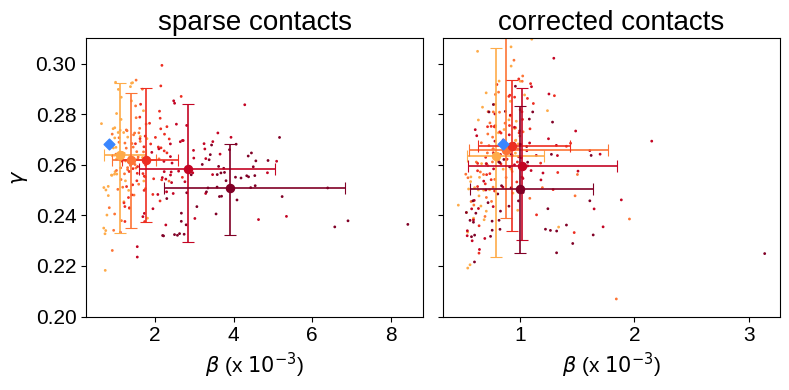

In [102]:
PRINT_ALL_CC = False
if PRINT_ALL_CC:   
    for k,fpc in DICT_fitted_pars.items(): 
        if 'aligned' in k: 
            print(k)
            print_tables(fpc, groundtruth = False)

k_select = 'ipw_hourofday_weekday'
for k in ['biased', k_select]:
    print(k)
    fpc = DICT_fitted_pars[k]
    #print(fpc.columns)
    fpc_table = table_fitted_pars(fpc, groundtruth  = False)
    print(fpc_table.to_latex(float_format = '%.2f'))

fig, Axes = plt.subplots(figsize = (8,4), 
                         ncols = 2)#, nrows=2)

cc_select = 'ipw_hourofday_weekday'
panels_param_bias(Axes, cc_select)
visual_single_params(Axes[0], 'biased', x = 'beta', y = 'gamma')
visual_single_params(Axes[1], cc_select, x = 'beta', y = 'gamma')
#visual_single_params(Axes[1,0], 'biased', x = 'beta', y = 'R0_global_mean')
#visual_single_params(Axes[1,1], cc_select, x = 'beta', y = 'R0_global_mean')

for ax in Axes:#.ravel():
    ax.set_ylim(0.2,0.31)
    restyle_ax(ax, tick_size =15, label_size = 15)

visual.remove_axis_ticktext(Axes[1], axis = 'y')
plt.tight_layout()

/tmp/ipykernel_436265/3613860394.py:169: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticks_rescaled)
/tmp/ipykernel_436265/3613860394.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks_rescaled)


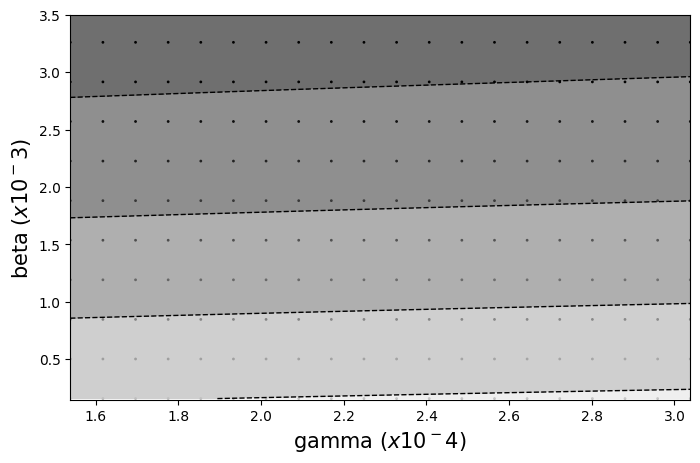

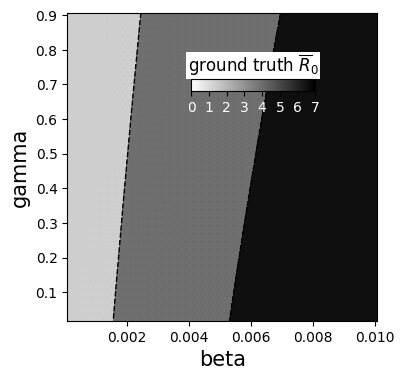

In [117]:
fig, ax = plt.subplots(figsize = (8,5))
#positions of the contour labels, manually designed
List_mc = [(2.8e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ][:4]
#selection of the grid vor visualization 
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")
visual_GRID_R0(ax, 
              df_GRID, 
              x = 'gamma',
              y = 'beta',
              R0_column = 'R0_global_mean',
              grid_levels = 4, 
              contour_lines = np.arange(0,5), 
              manual_clabel = False,
              cbar = False)

rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.5e-3)
#ax.set_title('Epidemic intensity given $C^*$', size=20)

#grid with updated R0 computations
df_GRID_v5 = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID_v5.head(2)

fig, ax = plt.subplots(figsize = (4,4))
visual_GRID_R0(ax, 
              df_GRID_v5, 
              y = 'gamma',
              x = 'beta',
              R0_column = 'R0_mean',
              grid_levels = 2, 
              contour_lines = 2, 
              manual_clabel = False,
              cbar = True, 
              cbar_title = 'ground truth $\overline{R}_0$',
              scatter_size=.001)

In [ ]:
# visual_pars_ci_fitted(axes[0], 'biased', marker = 'o', linestyle = '--', gt_text = False)
# axes[0].set_title('sparse contacts')
# visual_pars_ci_fitted(axes[1],cc_select)
# axes[1].set_title('corrected contacts')

In [ ]:
PRINT_ALL_CC = False
if PRINT_ALL_CC:   
    for k,fpc in DICT_fitted_pars.items(): 
        if 'aligned' in k: 
            print(k)
            print_tables(fpc, groundtruth = False)

k_select = 'ipw_hourofday_weekday'
for k in ['biased', k_select]:
    print(k)
    fpc = DICT_fitted_pars[k]
    fpc_table = table_fitted_pars(fpc, groundtruth  = False)
    print(fpc_table.to_latex(float_format = '%.2f'))

cmap = 'Blues'
List_mc1 = [(x,0.23) for x in np.array([0, 2, 4, 7])]#*1e-3 ]
List_mc2 = [(x,0.23) for x in np.array([0.5,1.5,3])]#*1e-3 ]

fig, _axes = plt.subplots(figsize = (9, 5), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios': [1,1,.1]})#, nrows=2)

Axes = _axes[:2]

df_GRID_v6 = df_GRID_v5.copy()
df_GRID_v6['beta'] *= 1e3

for ax, List_mc, grid_level, n_contour in zip(Axes, 
                                              [List_mc1, List_mc1],
                                              [5,5],
                                              [5,5]):
    
    visual_GRID_R0(ax, 
                  df_GRID_v6, 
                  y = 'gamma',
                  x = 'beta',
                  R0_column = 'R0_mean',
                  cmap = cmap,
                  grid_levels = grid_level, 
                  contour_lines = n_contour, 
                  manual_clabel = List_mc,
                  cbar = False, #(ax == Axes[0]), 
                  cbar_title = r'$\overline{R}_0(\beta , \gamma , $'+ 'g.t. contacts)',
                  scatter_size=.001)

cc_select = 'ipw_hourofday_weekday'

ax = Axes[0]
visual_single_params(ax, 'biased', x = 'beta')#, y = 'R0_global_mean')
visual_pars_ci_fitted(ax, 'biased', marker = 'o', linestyle = '--', gt_text = False)
ax.set_xlabel(r'$\beta$' + ' x ($10^{-3}$)')
ax.set_ylabel(r'$\gamma$')


ax = Axes[1]
visual_single_params(ax, cc_select, x = 'beta')#, y = 'R0_global_mean')
visual_pars_ci_fitted(ax, cc_select)
ax.set_xlabel(r'$\beta$' + ' x ($10^{-3}$)')


ax = _axes[-1]
ax.clear()#set_axis_off()
cmap = plt.get_cmap(cmap)
norm = mpl.colors.Normalize(vmin=0, vmax=6)

# colorbar directly within the same axis
cbar = plt.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,                      # use this axis as the colorbar container
    orientation='vertical'
)
ax.set_ylabel(r'$\overline{R}_0(\beta , \gamma , $'+ 'gt. contacts)')

Axes[0].set_xlim(0.1,7.5)
Axes[0].set_title('biased contacts')
Axes[1].set_xlim(0.1,2)
Axes[1].set_title('rescaled contacts')

visual.remove_axis_ticktext(Axes[1], axis = 'y')

Axes[1].set_ylabel('')
for ax in Axes:#.ravel():
    ax.set_ylim(0.21,0.3)
    restyle_ax(ax, title_size= ax_label_size)#, tick_size =10, label_size = 15, title_size = 15, text_size = 10)
restyle_ax(_axes[-1])#,  label_size = 15, title_size = 15, tick_size = 10)

#plt.tight_layout()

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/fitted_pars.png',
    format="png", bbox_inches='tight', dpi=300)

In [ ]:
df_GRID_v6

In [ ]:
fig, ax = plt.subplots(figsize=(8, 0.5))

# Colors and labels
_colors = [COLOR_GT] + Level_colors
labels = ['[0-5] ground truth', '[10-20]', '[20-30]', '[30-40]', '[40-50]', '[50-60]']

# Legend handles
handles = [Line2D([], [], marker='D', color='none', markerfacecolor=_colors[0], markeredgecolor = 'none', markersize=10)] + \
           [Patch(facecolor=c, edgecolor='none') for c in _colors[1:len(labels)]]

# Hide axes
ax.set_axis_off()

# Full-width single-row legend
leg = ax.legend(
    handles, labels,
    ncol=len(labels),
    loc='center',
    bbox_to_anchor=(0, 0, 1, 1),  # full axis extent: (x0, y0, width, height)
    mode='expand',                # stretch entries across the width
    frameon=False,
    handlelength=2,
    handletextpad=1,
    borderaxespad=0,
)
ax.set_title('Calibrated parameters - missing hours (%)')
plt.tight_layout(pad=0)
restyle_ax(ax, title_size = ax_title_size, legend_font_size=ax_label_size)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_debiasing/fitted_pars_legend.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

#### [OLD] realized outbreaks table + {IMG}

__compute variability for the groundtruth realized outbreaks__

In [ ]:
p_gt_mean, p_gt_std, p_gt_c95_lower, p_gt_c95_upper = compute_realized_outbreaks_groundtruth()
p_gt_mean.round(1), p_gt_std.round(1), p_gt_c95_lower, p_gt_c95_upper

In [ ]:
OLD_CODE = False
if OLD_CODE:
    for c in Contact_corrections: 
        if 'aligned' in c:
            print(c + '\n')
            oldprint_table_realized_outbreaks(contact_correction = c)

In [ ]:
cc_select = 'ipw_hourofday_weekday'
df_cc_stats = compute_stats_realized_outbreaks(df_tro_iters, cc_select)
df_cc_stats

In [ ]:
cols = []
for top in df_cc_stats.columns.levels[0]:
    cols.extend([
        (top, "mean"),
        (top, "std"),
        (top, "c95_lower"),
        (top, "c95_upper"),
    ])

subset = df_cc_stats.loc[:, cols]

# combine P05 and P95 into a single interval column
def interval_str(row):
    return f"[{row['c95_lower']:.1f}, {row['c95_upper']:.1f}]"

new_cols = []
new_data = {}

for top in df_cc_stats.columns.levels[0]:
    df_top = subset[top]
    new_data[(top, "mean")] = df_top["mean"]
    new_data[(top, "std")] = df_top["std"]
    new_data[(top, "CI 95%")] = df_top.apply(interval_str, axis=1)

# build final DataFrame
final_df = pd.DataFrame(new_data)
final_df.columns = pd.MultiIndex.from_tuples(final_df.columns)

# export to LaTeX
latex_code = final_df.to_latex(
    multicolumn=True,
    escape=False,
    column_format="l" + "rrr" * final_df.columns.get_level_values(0).nunique(),
)
print(latex_code)

In [ ]:

def panel_realized_outbreaks(ax, df_tro_iters, 
                             cc_select, 
                             X_ticks = np.arange(1,6)*6,
                             edge_only = False): 
    '''
    df_tro_iters: r.o. for each sparsity iter and contact corrections
    cc_select: select contact corrections
    '''
    df_cc_stats = compute_stats_realized_outbreaks(df_tro_iters, cc_select)


    #print(df_cc_stats.round(2).to_latex(float_format="%.2f"))
    _dict_ro_stat = lambda df_cc_stats, stat: {'oracle_biased': [df_cc_stats.loc['oracle_biased'][l][stat] for l in Levels_str],
                                               'calibration_biased': [df_cc_stats.loc['calib_biased'][l][stat] for l in Levels_str],
                                               'oracle_ipw': [df_cc_stats.loc[f'oracle_{cc_select}'][l][stat] for l in Levels_str],
                                               'calibration_ipw': [df_cc_stats.loc[f'calib_{cc_select}'][l][stat] for l in Levels_str]}
    DICT_ro_stats = {stat: _dict_ro_stat(df_cc_stats, stat) for stat in ['mean', 'std', 'c95_lower', 'c95_upper']}
    
    _EMVs = ['oracle_biased', 
             'calibration_biased', 
             'oracle_ipw', 
             'calibration_ipw']
    
    
    for j, emv in enumerate(_EMVs): 
        emv_ro = DICT_ro_stats['mean'][emv]
        c95_lower = np.array(DICT_ro_stats['c95_lower'][emv])
        c95_upper = np.array(DICT_ro_stats['c95_upper'][emv])
        
        visual_bar_series(ax, 
                          emv_ro, 
                          s_ind = X_ticks + j, 
                          c_lower = c95_lower, 
                          c_upper = c95_upper,  
                          Colors = [DICT_colors_emv[emv]]*5, 
                          edge_only = edge_only, viz_scatter = True)#, 
                          #Colors = ['white']*5)
    
    p_gt_mean, p_gt_std, p_gt_c95_lower, p_gt_c95_upper = compute_realized_outbreaks_groundtruth()
    visual_bar_series(ax,
                      [p_gt_mean], 
                      s_ind = [0], 
                      #ci = [p_gt_CI],
                      Colors = [COLOR_GT], 
                      c_lower = np.array([p_gt_c95_lower]), 
                      c_upper = np.array([p_gt_c95_upper]), edge_only = edge_only, 
                      viz_scatter = True) 

                      
    
    ax.axhline(p_gt_mean, color = COLOR_GT, linewidth = 1)
    ax.set_ylim(60,100)
    
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': np.arange(6)*6, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('missing data')

fig, axes = plt.subplots(figsize= (14,5),ncols= 2, gridspec_kw= {'width_ratios':[2,4]})
ax = axes[1]
panel_realized_outbreaks(ax, df_tro_iters, cc_select)
ax.set_ylim(60,102)
legend_emvs(axes[0], fontsize = 20)
axes[0].axis('off')
restyle_ax(axes[1])
plt.tight_layout()

In [ ]:
def panel_realized_outbreaks_withscatterpoints(ax, 
                                               df_tro_iters, 
                                               cc_select):
    X_ticks = np.arange(1,6)*6
    panel_realized_outbreaks(ax, 
                             df_tro_iters, 
                             cc_select, 
                             X_ticks = X_ticks, 
                             edge_only = True)
    
    table_ids = ['oracle_biased',
                 'calib_biased',
                 f'oracle_{cc_select}',
                 f'calib_{cc_select}']
    
    INDEXES = ['oracle_biased_contacts', 
               'calibration_biased_contacts',
               'oracle_corrected_contacts',
               'calibration_corrected_contacts']
    
    df_tro_iters_select = df_tro_iters[df_tro_iters['cc'].isin(table_ids)]
    df_tro_iters_select.head(2)
    for x_ind in [0,1,2,3]:
        v_ind = INDEXES[x_ind]
        for l in range(5):
            l_vals = df_tro_iters_select.loc[v_ind][l]
            print(len(l_vals))
            x_val = X_ticks[l] + x_ind 
            _Xvals = np.array([x_val]*len(l_vals)) + np.random.normal(0,.1, size = len(l_vals))
            ax.scatter(_Xvals, l_vals, s = 1, color = DICT_colors_emv[v_ind])



#### [OLD] fitted parameters table + {IMG}

In [ ]:
PRINT_ALL_CC = False
if PRINT_ALL_CC:   
    for k,fpc in DICT_fitted_pars.items(): 
        if 'aligned' in k: 
            print(k)
            print_tables(fpc, groundtruth = False)

k_select = 'ipw_hourofday_weekday'
for k in ['biased', k_select]:
    print(k)
    fpc = DICT_fitted_pars[k]
    #print(fpc.columns)
    fpc_table = table_fitted_pars(fpc, groundtruth  = False)
    print(fpc_table.to_latex(float_format = '%.2f'))

def plot_param_vs_param_ci(ax,
                           table,
                           x_param='Gamma',
                           y_param='betax1e-3',
                           marker='o',
                           linestyle='--',
                           color=None,
                           capsize=4,
                           annotate=True):
    """
    Scatter of mean(y_param) vs mean(x_param) with asymmetric 95% CIs
    taken from '(param, c95_lower)' and '(param, c95_upper)' columns.

    Expected columns per param:
      (param, 'mean'), (param, 'c95_lower'), (param, 'c95_upper')
    """

    # Means
    x = table[(x_param, 'mean')].to_numpy()
    y = table[(y_param, 'mean')].to_numpy()

    # Asymmetric CI bounds
    xl = table[(x_param, 'c95_lower')].to_numpy()
    xu = table[(x_param, 'c95_upper')].to_numpy()
    yl = table[(y_param, 'c95_lower')].to_numpy()
    yu = table[(y_param, 'c95_upper')].to_numpy()

    # Convert to errorbar offsets
    xerr = np.vstack([x - xl, xu - x])
    yerr = np.vstack([y - yl, yu - y])

    if isinstance(color, (list, tuple)):
        # One color per point
        for xi, yi, xei, yei, c, lab in zip(x, y, xerr.T, yerr.T, color, table.index.astype(str)):
            ax.errorbar(xi, yi,
                        xerr = xei[:, None] if xei.ndim == 1 else xei,
                        yerr = yei[:, None] if yei.ndim == 1 else yei,
                        fmt = marker, 
                        color = c, 
                        ecolor=c,
                        capsize=capsize, elinewidth=1.2, markeredgewidth=0.8,
                        linestyle=linestyle)
            if annotate:
                ax.annotate(lab, (xi, yi), xytext=(4, 4),
                            textcoords='offset points', fontsize=9, color=c)
    else:
        # Single color for all
        ax.errorbar(x, y, xerr=xerr, yerr=yerr,
                    fmt=marker, linestyle='none',
                    color=color, ecolor=color,
                    capsize=capsize, elinewidth=1.2, markeredgewidth=0.8)
        if annotate:
            for xi, yi, lab in zip(x, y, table.index.astype(str)):
                ax.annotate(lab, (xi, yi), xytext=(4, 4),
                            textcoords='offset points', fontsize=9)


def visual_gt_pars(ax, y = 'gamma', x = 'beta', text = False):
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    b_gt *= 1e3
    g_gt = 1- (1-g_gt)**1440
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT)
    if text: 
        ax.text(groundtruth_pars[x] -.5, 
                groundtruth_pars[y]*1.01, 
                r'$(\beta^*,\gamma^*)$', 
                color = COLOR_GT)
    

def visual_pars_ci_fitted(ax, 
                          cc_select, 
                          y_param='Gamma',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = True, gt_text= False):
    cc_table = DICT_fitted_pars_tables[cc_select]
    plot_param_vs_param_ci(ax,
                           cc_table,
                           y_param = y_param,
                           x_param = x_param, 
                           linestyle= linestyle,
                           marker= marker,
                           color= Level_colors,
                           capsize = 4,
                           annotate = False)
    if visual_gt:
        visual_gt_pars(ax, text=gt_text)


def legend_missing_data(ax, loc = 'upper right'): 
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': loc,
                        'fontsize':10, 
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)#, bbox_to_anchor = (0,0.9))

def visual_single_params(ax, cc_select, x = 'beta', y = 'gamma', s= 1):
    df_fpc = DICT_fitted_pars[cc_select].copy()
    df_fpc['beta']*=1e3
    df_fpc['gamma'] = 1- (1-df_fpc['gamma'])**1440
    xs = df_fpc[x].values
    ys = df_fpc[y].values
    cs = [DICT_colors_level[ast.literal_eval(l)] for l in df_fpc['l'].values]
    ax.scatter(xs,ys, color =cs, s = s)

def panel_param_bias_beta_gamma(axes, cc_select):
    
    visual_pars_ci_fitted(axes[0], 'biased', marker = 'o', linestyle = '--', gt_text = True)
    visual_single_params(axes[0], 'biased', x = 'beta', y = 'gamma')
    axes[0].set_title('Calib. on biased contacts')
    
    visual_pars_ci_fitted(axes[1],cc_select)
    visual_single_params(axes[1], cc_select, x = 'beta', y = 'gamma')
    axes[1].set_title('Calib. on corrected contacts')
    
    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(0.24,0.29)
        ax.set_xlabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel('$\gamma$')#, rotation = 0)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': 'upper right',
                        'fontsize':10, 
                        'title_fontsize':10})

def panel_param_bias_beta_R0(axes, cc_select):

    ax = axes[0]
    axes[0].set_title('Calib. on biased contacts')

    visual_pars_ci_fitted(ax, 
                          'biased', 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    visual_single_params(axes[0], 'biased', x = 'beta', y = 'R0_global_mean')

    
    ax= axes[1]
    axes[1].set_title('Calib. on corrected contacts')

    visual_pars_ci_fitted(ax, 
                          cc_select, 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    #axes[0].text(2,R0_gt*1.1, r'avg. $R_0(\beta^*, \gamma^*)$ = ' + str(np.round(R0_gt,2)), size = 5, color = COLOR_GT)
    visual_single_params(axes[1], cc_select, x = 'beta', y = 'R0_global_mean')

    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(1,6)
        ax.set_ylabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel(r'avg $R_0(\beta, \gamma)$')


def panels_param_bias(Axes, cc_select):
    axes = Axes[0,:]
    visual_pars_ci_fitted(axes[0], 'biased', marker = 'o', linestyle = '--', gt_text = True)
    axes[0].set_title('Calib. on biased contacts')
    visual_pars_ci_fitted(axes[1],cc_select)
    axes[1].set_title('Calib. on corrected contacts')
    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(0.24,0.29)
        ax.set_xlabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel('$\gamma$')#, rotation = 0)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Levels_str,
                        'title': 'missing data',
                        'colors': Level_colors, 
                        'loc': 'upper right',
                        'fontsize':10, 
                        'title_fontsize':10})
    #ax_visual_legend(axes[1], DICT_legend)#, bbox_to_anchor = (0,0.9))
    axes = Axes[1,:]
    ax = axes[0]
    axes[0].set_title('Calib. on biased contacts')

    visual_pars_ci_fitted(ax, 
                          'biased', 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    
    ax= axes[1]
    axes[1].set_title('Calib. on corrected contacts')

    visual_pars_ci_fitted(ax, 
                          cc_select, 
                          y_param='R0_global_mean',
                          x_param='betax1e-3', 
                          marker = 'o', linestyle = '--', 
                          visual_gt = False)
    R0_gt = R0_complete.mean().mean()
    ax.axhline(R0_gt, color = COLOR_GT)
    #axes[0].text(2,R0_gt*1.1, r'avg. $R_0(\beta^*, \gamma^*)$ = ' + str(np.round(R0_gt,2)), size = 5, color = COLOR_GT)
    
    for ax in axes:
        #ax.set_xlim(0,4.9)
        #ax.set_ylim(1,6)
        ax.set_ylabel('')
        ax.set_xlabel(r'$\beta$ (x $10^{-3}$)')
    axes[0].set_ylabel(r'avg $R_0(\beta, \gamma)$')



fig, Axes = plt.subplots(figsize = (12,10), ncols = 2, nrows=2)
cc_select = 'ipw_hourofday_weekday'
panels_param_bias(Axes, cc_select)

visual_single_params(Axes[0,0], 'biased', x = 'beta', y = 'gamma')
visual_single_params(Axes[0,1], cc_select, x = 'beta', y = 'gamma')
visual_single_params(Axes[1,0], 'biased', x = 'beta', y = 'R0_global_mean')
visual_single_params(Axes[1,1], cc_select, x = 'beta', y = 'R0_global_mean')

for ax in Axes.ravel():
    restyle_ax(ax, tick_size =15, label_size = 15)
plt.tight_layout()

#### [OLD] Fig-debiasing (realized outbreaks and fitted parameters)

In [ ]:
fig, ax = plt.subplots(figsize= (10,5))
cc_select = 'ipw_hourofday_weekday'
panel_realized_outbreaks_withscatterpoints(ax, 
                                           df_tro_iters, 
                                           cc_select)
ax.set_ylim(50,102)
legend_emvs(ax, fontsize = 10, loc = 'lower left')
ax.set_title('Realized outbreaks')
restyle_ax(ax,legend_font_size = 10)
plt.savefig(f"IMGS_manuscript/Fig3draft_realized_outbreaks_{cc_select}.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
fig, axes = plt.subplots(figsize = (12,4), ncols = 2)
panel_param_bias_beta_gamma(axes, cc_select)
for ax in axes:
    restyle_ax(ax)
plt.savefig(f"IMGS_manuscript/Fig3draft_param_bias_beta_gamma_{cc_select}.png", format="png", bbox_inches='tight', dpi = 300)

fig, axes = plt.subplots(figsize = (12,4), ncols = 2)
panel_param_bias_beta_R0(axes, cc_select)
ax = axes[1]
legend_missing_data(ax, loc='upper right')
for ax in axes:
    restyle_ax(ax, legend_font_size = 10, legend_title_size = 10)
plt.savefig(f"IMGS_manuscript/Fig3draft_param_bias_beta_R0_{cc_select}.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
fig, axes = make_axes_layout([1, 3, 3], order='row', figsize=(12, 8))

cc_select = 'ipw_hourofday_weekday'

ax = axes[0]
panel_realized_outbreaks(ax, df_tro_iters, cc_select)
ax.set_title('Realized outbreaks')
set_leg_bbox(ax, -1,0)

#legend_emvs(axes[0], fontsize = 20)
#axes[0].axis('off')
ax = axes[3]
legend_emvs(ax, fontsize = 10)
ax.axis('off')

panels_param_bias(np.array([[axes[1],axes[2]], [axes[4], axes[5]]]), cc_select)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Levels_str,
                    'title': 'Parameter estimation bias \n             missing data',
                    'colors': Level_colors, 
                    'loc': 'upper left',
                    'fontsize':20, 
                    'title_fontsize':10})
ax = axes[6]
ax_visual_legend(ax, DICT_legend,bbox = (0,1.8))#, bbox_to_anchor = (0,0.9))
ax.axis('off')

handle = Line2D([0], [0], marker='D', linestyle='None',
                    color=COLOR_GT, markerfacecolor=COLOR_GT,
                    label='ground truth \nsimul. params.')
axes[2].legend(handles=[handle], loc = 'upper right')


for ax in axes:
    restyle_ax(ax, label_size =15, text_size = 12, tick_size= 15)

plt.tight_layout()
plt.savefig("IMGS_manuscript/Fig_debiasing.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
for cc_select in Contact_corrections:
    fig, axes = make_axes_layout([1, 2, 2], order='row', figsize=(10, 8))
    ax = axes[0]
    panel_realized_outbreaks(ax, df_tro_iters, cc_select)
    ax.set_title(f'Correction = {cc_select}')
    
    panels_param_bias(np.array([[axes[1],axes[2]], [axes[3], axes[4]]]), cc_select)
    
    
    for ax in axes:
        restyle_ax(ax, label_size =15, text_size = 12, tick_size= 15)
    
    plt.tight_layout()
    plt.savefig(f"IMGS_manuscript/Fig_debiasing_{cc_select}.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
DICT_fitted_pars_tables.keys()

### [F4] Cuebiq data

Initial sample : 1365 trajectories

Sample selection: at least 10 days with records and at least 10 records; end up with 855 users

Contact correction: global IPW scaling

Study period : 3 months 

Oracle parameters: from literature study; choice of daily rates (gamma : 1/14 ; beta set to .2);
Consistently with literature on the topic


In [ ]:
N_ce_users = 1356
N_ce_dates = 92

# --- build blue→red color scale for the column order ---
cmap = cm.get_cmap("coolwarm")     # blue→red
colors_coverage = [cmap(i) for i in np.linspace(0,1,10)][::-1]

#selected date-range for the visualizations
_dr = pd.date_range(start = dt.date(2024, 9, 1), 
                    end = dt.date(2024,12,1))

#### [data import]

In [64]:
#path of cuebiq exports
path_ce = 'Cuebiq_material/Exported_tables/federico_exports_latest/federico_exports/' 
#list of folder; each folder contains a parquet file
ce_folds = os.listdir(path_ce)

#got it from the platform
DICT_ce_columns = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS': ['DATE',
      'COMPLETENESS',
      'DEGREE_MIN',
      'DEGREE_MAX',
      'DEGREE_MEAN',
      'DEGREE_MEDIAN',
      'DEGREE_STD',
      'CUMULATIVE_TIME_MIN',
      'CUMULATIVE_TIME_MAX',
      'CUMULATIVE_TIME_MEAN',
      'CUMULATIVE_TIME_MEDIAN',
      'CUMULATIVE_TIME_STD',
      'NETWORK_CONSTRAINT_MIN',
      'NETWORK_CONSTRAINT_MAX',
      'NETWORK_CONSTRAINT_MEAN',
      'NETWORK_CONSTRAINT_MEDIAN',
      'NETWORK_CONSTRAINT_STD',
      'CLUSTERING_MIN',
      'CLUSTERING_MAX',
      'CLUSTERING_MEAN',
      'CLUSTERING_MEDIAN',
      'CLUSTERING_STD'],
     'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY': ['BETA',
      'GAMMA',
      'COMPLETENESS',
      'DATE',
      'INFECTIVITY_MIN',
      'INFECTIVITY_MAX',
      'INFECTIVITY_MEAN',
      'INFECTIVITY_MEDIAN',
      'INFECTIVITY_STD'],
     'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION': ['COMPLETENESS',
      'DATE',
      'PERCENTAGE'],
     'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES': ['DATE',
      '0.9–1.0',
      '0.8–0.9',
      '0.7–0.8',
      '0.6–0.7',
      '0.5–0.6',
      '0.4–0.5',
      '0.3–0.4',
      '0.2–0.3',
      '0.1–0.2',
      '0.0–0.1',
      'WINDOW_DAYS'],
     'RESULT_EPID_OUTCOMES_CURVES': ['S',
      'I',
      'N_iter',
      'TYPE',
      'CI',
      'REFERENCE'],
     'RESULT_EPID_OUTCOMES_PARAMETERS': ['BETA',
      'GAMMA',
      'N_INIT',
      'OBJ',
      'CONTACT_TYPE',
      'REFERENCE'],
     'RESULT_EPID_OUTCOMES_STATISTICS': ['PEAK_DAY',
      'PEAK_SIZE',
      'FINAL_SIZE',
      'EPID_DURATION',
      'DAY_FINAL_CASE',
      'TYPE',
      'BETA',
      'GAMMA',
      'N_INIT',
      'REFERENCE']}

DICT_file_rename = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS' : 'cov_contact',
                    'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY' : 'cov_infectivity',
                    'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION' : 'cov_share',
                    'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES' : 'cov_share_sw',
                    'RESULT_EPID_OUTCOMES_CURVES' :     'emo_curves',
                    'RESULT_EPID_OUTCOMES_PARAMETERS' : 'emo_params',
                    'RESULT_EPID_OUTCOMES_STATISTICS' : 'emo_stats'}
_ce = {}
#dictionary of dataframes for each folder
for c in ce_folds:
    df_ce = pd.read_parquet(f'{path_ce}{c}/data_0_0_0.snappy.parquet')
    df_ce.columns = DICT_ce_columns[c]
    _ce[DICT_file_rename[c]] = df_ce
                           
for c in _ce.keys():
    print(c)

cov_contact
cov_infectivity
cov_share
cov_share_sw
emo_curves
emo_params
emo_stats


#### [TODO][Polygon for trajectory selection]

In [ ]:
path = 'TMP/df_users_trajectories_SIERRA_new.csv'
polygon_wkt = """POLYGON ((-76.501923 42.485264, -76.533508 42.440181, -76.503296 42.402672,
                           -76.418152 42.457914, -76.466904 42.500959, -76.501923 42.485264))"""

from shapely import wkt
# --- your polygon ---
polygon_wkt = """POLYGON ((-76.501923 42.485264, -76.533508 42.440181, -76.503296 42.402672,
                             -76.418152 42.457914, -76.466904 42.500959, -76.501923 42.485264))"""

# --- parse into geometry ---
poly = wkt.loads(polygon_wkt)

# --- create a GeoDataFrame ---
gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")

# --- reproject to Web Mercator for contextily ---
gdf_web = gdf.to_crs(epsg=3857)

# --- plot ---
fig, ax = plt.subplots(figsize=(6,4))

gdf_web.boundary.plot(ax=ax, linewidth=2, edgecolor='blue')
gdf_web.plot(ax=ax, alpha=0.1, color='blue')

# --- add basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# --- adjust view ---
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/polygon_traj_selection.png',
    format="png", bbox_inches='tight', dpi=300)

#### [Panel - coverage]

In [ ]:
def viz_coverage(ax,
                 cov_share_sw, 
                 sws = 7, 
                 date_range = None, 
                 date_step =10):

    sws_share = cov_share_sw[cov_share_sw['WINDOW_DAYS'] == sws].set_index('DATE').drop('WINDOW_DAYS', axis = 1)
    df = sws_share.copy()
    if date_range is not None:
        df = df.loc[date_range]
    
    # --- build blue→red color scale for the column order ---
    cmap = cm.get_cmap("coolwarm")     # blue→red
    colors = [cmap(i) for i in np.linspace(0, 1, df.shape[1])]
    
    # --- plot stacked bars ---
    df.plot(kind='bar',
            stacked=True,
            ax=ax,
            width=1.1,
            color=colors)
    
    
    df.index = pd.to_datetime(df.index)
    
    ax.set_xticks(range(0, len(df), date_step))
    ax.set_xticklabels(df.index[::date_step].strftime("%m-%d"), rotation=90)
    ax.set_title(f'{sws} days')

def convert_mmdd_to_ddmon(ax):
    """Convert xticklabels from 'MM-DD' to 'DD Mon' format."""
    labels = ax.get_xticklabels()
    new_labels = []
    
    for lbl in labels:
        txt = lbl.get_text()
        if "-" in txt:
            try:
                m, d = txt.split("-")
                date = dt.datetime(2000, int(m), int(d))   # dummy year
                new_labels.append(date.strftime("%d %b"))
            except:
                new_labels.append(txt)
        else:
            new_labels.append(txt)

    ax.set_xticklabels(new_labels)

cov_share_sw = _ce['cov_share_sw'].copy()
cols_old = ['DATE', 
            '0.9–1.0', '0.8–0.9', '0.7–0.8', '0.6–0.7', '0.5–0.6','0.4–0.5', '0.3–0.4', '0.2–0.3', '0.1–0.2', '0.0–0.1', 
            'WINDOW_DAYS']

cols_new = ['DATE', 
            '0-10', '10-20', '20-30', '30-40', '40-50','50-60', '60-70', '70-80', '80-90', '90-100', 
            'WINDOW_DAYS']

dict_rename_cols = dict(zip(cols_old, cols_new))

cov_share_sw.columns = [dict_rename_cols[c] for c in cov_share_sw.columns]

_dr = pd.date_range(start = dt.date(2024, 9, 1), end = dt.date(2024,11,1))
_dr

sw_sizes = cov_share_sw['WINDOW_DAYS'].unique()
sw_sizes

sws = 30
sws_share = cov_share_sw[cov_share_sw['WINDOW_DAYS'] == sws].set_index('DATE').drop('WINDOW_DAYS', axis = 1)
df = sws_share.copy().iloc[:,::-1]
print('For each date (row); we have the share of users with a given sparsity range (column)' + 
      '\nover a 30 day rolling window starting on the given date (row)')
df.head(2)

print('We compute the cumulative sum of this shares')
df_cumsum = df.cumsum(axis=1)
df_cumsum.head(2)

print('We average the cumulative sum over the study period; and report it for the 50-60 range' + 
      '\nthath is corresponding to users having at least 50\% missing hours')
df_cumsum.mean(axis=0)





fig, ax = plt.subplots(figsize=(8,5))

viz_coverage(ax,
             cov_share_sw, 
             date_range= _dr,
             sws = 30,
             date_step = 30)

# --- reverse legend order ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1],
          title="missing hours (%)",
          #bbox_to_anchor=(1.05, .5),
          loc='upper center',
          ncols=5)
#ax.set_title('Sliding window of 30 days')
ax.set_title('')
ax.set_ylim(0,1)
#ax.set_xlim(0,90)
convert_mmdd_to_ddmon(ax)
ax.tick_params(axis = 'x', rotation = 0)
set_percent_yticks(ax, decimals = 0)

ax.set_ylabel("sample share (%)")
ax.set_xlabel("starting day (30 day rolling window)")

restyle_ax(ax, title_size = ax_label_size)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/sw30days.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)


In [ ]:
_dr = pd.date_range(start = dt.date(2024, 9, 1), end = dt.date(2024,10,1))

fig, axes = plt.subplots(figsize=(15,4),ncols = 3)

for i, _sws in enumerate([7,14,30]):
    viz_coverage(axes[i],
                 cov_share_sw, 
                 sws = _sws, 
                 date_range = _dr, 
                 date_step = 3)

for ax in axes[:2]:
    ax.get_legend().remove()
axes[2].legend(handles[::-1], labels[::-1],
               title="Coverage",
               #bbox_to_anchor=(1.05, 1.1),
               loc='upper right',
               ncols=1)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/sw_7-14-30_days.png',
    format="png", bbox_inches='tight', dpi=300
)

#### [Panel - contact]

Ideas; show the daily maximum degree (or mean degree) for each coverage bucket

In [ ]:
_ce.keys()

In [ ]:
cov_contact = _ce['cov_contact']
cov_contact.tail(4)

In [ ]:
_f = 'DEGREE_MAX'
table_f = cov_contact.pivot(index = 'DATE', 
                            columns = 'COMPLETENESS', 
                            values = _f)
table_f.index = pd.to_datetime(table_f.index)
table_f=  table_f.loc[_dr]

for color, c in zip(colors_coverage, table_f.columns):
    _y = table_f[c].values
    _x = range(len(_y))
    plt.plot(_x,_y, c = color, linewidth =1)
    plt.scatter(_x,_y,c = color, s = 2)

ax = plt.gca()
ax.set_xticks(range(len(_dr)))
ax.set_xticklabels(_dr, rotation = 0)
ax.set_ylabel('median degree')

df = table_f.copy()
ax.set_xticks(range(0, len(df), 5))
ax.set_xticklabels(df.index[::5].strftime("%m-%d"), rotation=45)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/median_daily_degree.png',
    format="png", bbox_inches='tight', dpi=300
)
restyle_ax(ax)

In [ ]:
_f = 'CUMULATIVE_TIME_MEDIAN'
table_f = cov_contact.pivot(index = 'DATE', 
                            columns = 'COMPLETENESS', 
                            values = _f)
table_f.index = pd.to_datetime(table_f.index)
table_f=  table_f.loc[_dr]
table_f.head(2)
for color, c in zip(colors_coverage, table_f.columns):
    _y = table_f[c].values
    _x = range(len(_y))
    plt.plot(_x,_y, c = color, linewidth =1)
    plt.scatter(_x,_y,c = color, s = 2)

ax = plt.gca()
ax.set_xticks(range(len(_dr)))
ax.set_xticklabels(_dr, rotation = 0)
ax.set_ylabel('median time in contact (minute)')

df = table_f.copy()
ax.set_xticks(range(0, len(df), 5))
ax.set_xticklabels(df.index[::5].strftime("%m-%d"), rotation=45)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/median_cumulative_time_in_contact.png',
            format="png", bbox_inches='tight', dpi=300)
restyle_ax(ax)

#### [Panel - curves]

In [73]:
#get the curve used for calibration
url = "https://raw.githubusercontent.com/nytimes/covid-19-data/refs/heads/master/us-counties-2020.csv"
df_ref = pd.read_csv(url)#, dtype = schema)

df_ref = df_ref[df_ref['county'] == 'Tompkins']

# Compute daily new cases
cases = df_ref.set_index('date')['cases']#.diff()

#index of starting date
i_start = 180
#population of Itacha
N_pop = 30000

Curve_ref = cases[i_start: i_start + N_ce_dates+1]/N_pop
seed_perc = Curve_ref[0]
fig, ax = plt.subplots(figsize = (5,4))
ax.plot(Curve_ref)

NameError: name 'N_ce_dates' is not defined

In [ ]:
Curve_ref

In [ ]:
seed_perc

In [ ]:
10/855

In [ ]:
curves = _ce['emo_curves']
curve_types = curves['TYPE'].unique()
curve_types

In [ ]:
_ce.keys()

In [ ]:
dict_ct = {'lit_sparse': 'Oracle on sparse contacts', 
           'lit_cc': 'Oracle on corrected contacts', 
           'calib_sparse': 'Calib. on sparse contacts', 
           'calib_cc': 'Calib. on corrected contacts'}

In [ ]:
curve_refs = curves['REFERENCE'].unique()
curve_refs

In [ ]:
_t = 'lit_sparse'
_m = 'percentage'
c_tm = curves[(curves['TYPE'] == _t) & (curves['REFERENCE']== _m)]
c_tm.head(2)

In [ ]:
fig, axes = plt.subplots(figsize = (12,3),ncols = 4)

_m = 'percentage'

N_users_sim = 855

for t, ax in zip(curve_types, axes):
    c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)]

    for _ni in range(100):
        
        c_tmi = c_tm[c_tm['N_iter'] == _ni]
        ax.plot(c_tmi['CI'].values/N_users_sim, 
                c = 'gray', 
                linewidth = .5)
    #ax.set_ylim(10,100)
    ax.set_title(dict_ct[t])
    ax.set_xlabel('simulation day')
    ax.plot(Curve_ref.values, c = COLOR_GT)
    
axes[0].set_ylabel('infected (%)')
for ax in axes[1:]:
    remove_axis_ticktext(ax, 
                         axis = 'y')

ax = axes[0]
gt = mlines.Line2D([], [], color= COLOR_GT, linewidth=2, label='ground truth')
sim = mlines.Line2D([], [], color= 'gray', linewidth=2, label='simulation')
# add legend to the axis
ax.legend(handles=[gt, sim], loc='upper left')


plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/cumulative_infected.png',
    format="png", bbox_inches='tight', dpi=300
)

In [ ]:
curve_types

In [ ]:
fig, axes = plt.subplots(figsize = (7,4),ncols = 2)
_m = 'percentage'

N_users_sim = 855

for t, ax in zip(['calib_sparse', 'calib_cc'], axes):
    c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)]

    for _ni in range(100):
        
        c_tmi = c_tm[c_tm['N_iter'] == _ni]
        ax.plot(c_tmi['CI'].values/N_users_sim, 
                c = 'gray', 
                linewidth = .5)
    #ax.set_ylim(10,100)
    ax.set_title(dict_ct[t])
    ax.set_xlabel('simulation day')
    ax.plot(Curve_ref.values, c = COLOR_GT)
    ax.set_ylim(0,0.14)
    set_percent_yticks(ax, decimals= 0)

    
axes[0].set_ylabel('infected (%)')
for ax in axes[1:]:
    remove_axis_ticktext(ax, 
                         axis = 'y')

ax = axes[0]
gt = mlines.Line2D([], [], color= COLOR_GT, 
                   linewidth=2, 
                   label='reference')
sim = mlines.Line2D([], [], color= 'gray', 
                    linewidth=2, 
                    label='simulation')

axes[0].set_title('Sparse contacts')
axes[1].set_title('Corrected contacts')

# add legend to the axis
ax.legend(handles=[gt, sim], loc='upper left')
for ax in axes:
    restyle_ax(ax, 
               title_size = ax_label_size)
    
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/cumulative_infected_calibration.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
fig, ax = plt.subplots(figsize = (4,4))#,ncols = 2)
_m = 'percentage'

N_users_sim = 855

_colors = [COLOR_CALIB_BS, 
           COLOR_CALIB_CC]

for t, color in zip(['calib_sparse', 'calib_cc'], 
                       _colors):
    
    c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)]

    for _ni in range(100):
        
        c_tmi = c_tm[c_tm['N_iter'] == _ni]
        ax.plot(c_tmi['CI'].values/N_users_sim, 
                c = color, 
                linewidth = .5)


        
    #ax.set_ylim(10,100)
    ax.set_title(dict_ct[t])
    ax.set_xlabel('simulation day')
    ax.plot(Curve_ref.values, c = COLOR_GT)
    ax.set_ylim(0,0.14)
    set_percent_yticks(ax, decimals= 0)

    
ax.set_ylabel('infected (%)')
for ax in axes[1:]:
    remove_axis_ticktext(ax, 
                         axis = 'y')

gt = mlines.Line2D([], [], color= COLOR_GT, 
                   linewidth=2, 
                   label='reference')
sim = mlines.Line2D([], [], color= 'gray', 
                    linewidth=2, 
                    label='simulation')

#axes[0].set_title('Sparse contacts')
#axes[1].set_title('Corrected contacts')

# add legend to the axis
ax.legend(handles=[gt, sim], loc='upper left')

    
#plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/cumulative_infected_calibration.png',
#            format="png", 
#            bbox_inches='tight', 
#            dpi=300)

In [ ]:
fig, axes = plt.subplots(figsize = (8,4), ncols = 2, gridspec_kw = {'width_ratios':[2,1]})

ax = axes[0]

alpha = 0.4
_m = 'percentage'
t  = 'calib_sparse'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
c_tm_list = [k[['S','CI']].values for c,k in subset_df_feature(c_tm, 'N_iter').items()]

visual_curves_SI(ax, c_tm_list, Dates, visual_all_sims= True, color = COLOR_CALIB_BS, alpha = alpha)

t  = 'calib_cc'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
c_tm_list = [k[['S','CI']].values for c,k in subset_df_feature(c_tm, 'N_iter').items()]
visual_curves_SI(ax, c_tm_list, Dates, visual_all_sims= True, color = COLOR_CALIB_CC, alpha = alpha)
remove_axis_ticktext(ax, axis='x')
ax.set_xticks(range(0,90,20))
ax.set_xticklabels(range(0,90,20), rotation =0)
ax.plot(Curve_ref.values, c = COLOR_GT)
ax.set_xlabel('simulation day')
ax.set_xlim(0,89)

ax = axes[1]

_m = 'percentage'

t  = 'calib_sparse'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
CI_sparse = c_tm.groupby('N_iter').agg({'CI':max})
CI_sparse_stats = {f:c(CI_sparse['CI']) for f,c in funcs.items()}

t  = 'calib_cc'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
CI_cc = c_tm.groupby('N_iter').agg({'CI':max})
CI_cc_stats = {f:c(CI_cc['CI']) for f,c in funcs.items()}

custom_boxplot_from_stats(ax, 
                          [CI_sparse_stats], 
                          positions=[0], 
                          color = COLOR_CALIB_BS, face_alpha = .8)
ax.scatter(0, CI_sparse_stats['mean'], color = 'black', s= 20, zorder= 100)

custom_boxplot_from_stats(ax, 
                          [CI_cc_stats], 
                          positions=[1], 
                          color = COLOR_CALIB_CC, face_alpha = .8)
ax.scatter(1, CI_sparse_stats['mean'], color = 'black', s= 20, zorder = 100)
remove_axis_ticktext(ax, axis='x')
#remove_axis_ticktext(ax, axis='y')
ax.set_ylabel('total infected (%)')

axes[0].set_ylabel('cumulative infected (%)')
set_percent_yticks(axes[0], decimals= 0)
set_percent_yticks(axes[1], decimals= 0)

ax.axhline(Curve_ref.values[-1], color = COLOR_GT)

for ax in axes:
    ax.set_ylim(0.01,0.12)
    restyle_ax(ax)
plt.tight_layout()

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/cumulative_infected_calibration_v2.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
fig, ax = plt.subplots(figsize = (7,1))

legend_elements = [
    Patch(facecolor= COLOR_GT, label = 'Reference'),
    Patch(facecolor= COLOR_CALIB_BS ,label = 'Calib. on biased contacts'),
    Patch(facecolor= COLOR_CALIB_CC ,label = 'Calib. on rescaled contacts')]

ax.legend(handles = legend_elements,
          title = '',
          loc = 'center',
          ncol = 3,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          fontsize = 9,
          framealpha=1,         # fully opaque
          facecolor="white",    # white background
          edgecolor="black")     # optional: black border
restyle_ax(ax, legend_font_size= ax_label_size)
ax.axis('off')

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/legend_cumulative_infected_calibration_v2.png',
            format="png", 
            bbox_inches='tight', 
            dpi=300)

In [ ]:
t  = 'calib_sparse'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
CI_sparse = c_tm.groupby('N_iter').agg({'CI':max})
CI_sparse_stats = {f:c(CI_sparse['CI']) for f,c in funcs.items()}

t  = 'calib_cc'
c_tm = curves[(curves['TYPE'] == t) & (curves['REFERENCE']== _m)].copy()
c_tm['CI'] /= 855
CI_cc = c_tm.groupby('N_iter').agg({'CI':max})
CI_cc_stats = {f:c(CI_cc['CI']) for f,c in funcs.items()}


In [ ]:
CI_sparse_stats

In [ ]:
CI_cc_stats

In [ ]:
#Oracle from network-based model
epid_pars = (7.4e-5, 0.0714)
params = _ce['emo_params'].set_index(['REFERENCE', 'CONTACT_TYPE'])
beta_sparse = params.loc[('percentage','sparse contacts')]['BETA']
gamma_sparse = params.loc[('percentage','sparse contacts')]['GAMMA']

beta_corrected = params.loc[ ('percentage', 'corrected contacts')]['BETA']
gamma_corrected = params.loc[('percentage','corrected contacts')]['GAMMA']

print(beta_sparse, gamma_sparse)
print(beta_corrected, gamma_corrected)


fig, axes = plt.subplots(figsize = (6,3), ncols = 2)
ax=  axes[0]
ax.scatter(epid_pars[0], epid_pars[1], marker = 'x', color = 'black')
ax.scatter(beta_sparse, gamma_sparse, marker = 'o', color = 'black', facecolor = 'none')
ax.set_xscale('log')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$\gamma$', rotation= 0)
ax.set_xlim(10e-6,1)
ax.set_ylim(0, 0.11)
ax.set_title('Sparse contacts')

ax = axes[1]
ax.scatter(epid_pars[0], epid_pars[1], marker = 'x', color = 'black')
ax.scatter(beta_corrected, gamma_corrected, marker = 'o', color = 'black', facecolor = 'none')
ax.set_xscale('log')
ax.set_xlabel(r'$\beta$')
ax.set_ylabel(r'$\gamma$', rotation= 0)
ax.set_xlim(10e-6,1)
ax.set_ylim(0, 0.11)
remove_axis_ticktext(ax, axis = 'y')
ax.set_title('Corrected contacts')
h1 = mlines.Line2D([], [], marker='x', color='black', linestyle='None',
                   markersize=5, label='literature')

h2 = mlines.Line2D([], [], marker='o', color='black', markerfacecolor='none',
                   linestyle='None', markersize=5, label='best fit')

# add to existing ax
axes[0].legend(handles=[h1, h2], loc='lower left', title = 'parameter', ncols = 1)
for ax in axes:
    restyle_ax(ax, 
               title_size = ax_label_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_cuebiq/parameter_fit.png',
    format="png", bbox_inches='tight', dpi=300
)

## Supplementary

• Results from Cuebiq data

• Details of parameter search when doing calibration (estimated seed; RMSE score)

• Increasing the temporal resolution of IPW might result in a higher variance of weights.

• Stop-detection is more robust to short gaps of around 1 hour

• Efficiency of de-biasing on other epidemic regimes

• Retention and Loss curves in contact correction.

#### Supp - table calibration space

In [ ]:
#[2.2] CALIBRATION SIMULATION PARAMETERS
#[2.2.a] parameter boundaries for the bayesian parameter search
Betas  = np.linspace(.5e-4, 1e-2, 20)
#gamma at second resolution
#recovery period of 1-day
gamma_second = 1/(24*3600) 
#compound probability conversion
lambda_gamma_minute = lambda gamma_second : 1 - (1 - gamma_second)**60
Gamma_min = lambda_gamma_minute(gamma_second/8)
Gamma_max = lambda_gamma_minute(gamma_second)
Gammas = np.linspace(Gamma_min, Gamma_max, 10)
N_inits = [1,3,5,10]#,15,20,30,50]
GRID = list(itertools.product(Betas, Gammas, N_inits))
GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]

#converting gamma at daily scale
GRID_stats['gamma'] = GRID_stats['gamma'].apply(lambda x: 1 - (1-x)**(60*24))
#converting beta to (10-3) 
#GRID_stats['beta'] = GRID_stats['beta'].apply(lambda x:x*1e3)
GRID_stats

### Supp - gap statistics

In [ ]:
def _gen_stats_gap_durations(q_select):
    
    _Xs = [df_X_emp, 
           df_X_random_keepdurations,
           df_X_random]
    
    _Gs = [df_gaps_emp,  
           df_gaps_random_kd,
           df_gaps_random]
    
    _ss = ['Data_driven_1wgcu', 
           'Random_keepdurations_1wgcu',
           'Random_uniform_1wgcu']
    
    dict_Xs = dict(zip(_ss, _Xs))
    dict_Gs = dict(zip(_ss, _Gs))
    
    #select sequences in the 40-50% range
    
    #dictionary of gap statistics in the 40-50% range
    dict_q_Xs = {}
    dict_q_Gs = {}
    
    for s,X,G in zip(_ss, _Xs, _Gs):
        
        df_q_X = X[X['q_range'] == q_select]
        select_seqs = df_q_X.index
        df_q_gaps = G[G['sequence_index'].isin(select_seqs)]
        
        dict_q_Xs[s] = df_q_X
        dict_q_Gs[s] = df_q_gaps

    return dict_q_Xs, dict_q_Gs

COMPUTE_GAP_DURATIONS = False
if COMPUTE_GAP_DURATIONS:
    List_df_sq = []
    for s in List_ss:
        for q in range(1,6):
            dict_q_Xs, dict_q_Gs = _gen_stats_gap_durations(q)
            df_sq = dict_q_Gs[s][['gap_duration_hours']].copy()
            df_sq = pd.DataFrame(df_sq)
            print(df_sq.shape)
            df_sq['s'] = [s]*len(df_sq) 
            l_ind = int(q-1)
            print(l_ind)
            df_sq['l'] = [Levels[l_ind]]*len(df_sq)
            List_df_sq.append(df_sq)
    df_gaps = pd.concat(List_df_sq)
    df_gaps.to_csv('tmp_checks/gap_durations.csv')

In [ ]:
df_gd = pd.read_csv('tmp_checks/gap_durations.csv', 
                    index_col = 0)
df_gd.head(2)

#### [Table] statistics gap durations

In [ ]:
c = 'gap_duration_hours'

agg = {f'{col}_{name}': (col, fn)
       for col in [c]
       for name, fn in funcs.items()}
           
df_stats_change= (df_gd
           .groupby(['s', 'l'])
           .agg(**agg)
           .reset_index())

df_stats_change = add_percentile_columns(df_stats_change, 
                                         c, 
                                         percent = False, 
                                         n_digit = 0) 

_add_latex_std_cols(df_stats_change, 
                    N_digits = [4,2,2], 
                    c = c, 
                    changes = False)

#column to select for latex table
cols_select = ['s','l', 
               f'str_{c}',
               f'{c}_IQR',
               f'{c}_CI']

cols_rename = ['s','l', 
               'avg. gap duration \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['avg. contact duration'])

path_tex = f'Project_Penn_git/Tables/gap_durations.tex'

with open(path_tex, "w") as f:
    f.write(latex_str)

### Supp - Stop statistics

In [ ]:
def compute_individual_stop_stats(df_stops, 
                                  USERS_select, 
                                  measure = 'day'):
    '''
    stop is associated to a day based on the start time 
    so it might be the case that sometime the stop procedes on the following days, 
    but I do not correct for this, since this is an exploratory analysis
    '''

    N_seconds = 3600*24

    #total time spent in a stop over the study period
    tot_time = df_stops.groupby(['id']).agg({'duration_s':'sum'})/N_seconds
    tot_time = tot_time.loc[USERS_select]

    #average time over the sample of stops
    avg_time = df_stops.groupby(['id']).agg({'duration_s':'mean'})/N_seconds
    avg_time = avg_time.loc[USERS_select]
    
    df_stops['start_day'] = df_stops['start_time'].dt.date
    daily_time    = df_stops.groupby(['id','start_day']).agg({'duration_s':'sum'})
    daily_time_table = daily_time.reset_index().pivot(index = 'id', 
                                                      columns = 'start_day', 
                                                      values = 'duration_s')/N_seconds
    daily_time_table.loc[USERS_select]
    
    DICT_stop_stats = {'stop_time_avg'    : avg_time,
                       'stop_time_overall': tot_time,
                       'stop_time_daily'  : daily_time_table}
    
    return DICT_stop_stats 
    

In [ ]:
IMPORT_STOPS = True

if IMPORT_STOPS:
    
    #import complete and sparse stops
    DICT_stops = import_stops_complete_sparse(List_ss, 
                                              Levels, 
                                              Ranges_iter, 
                                              Date_range_fromweekday, 
                                              USERS_select)
    
    df_stops_complete = DICT_stops['Complete']
    

In [ ]:
#compute all the stop statistics
DICT_stop_stats = {'Complete': compute_individual_stop_stats(df_stops_complete, 
                                                             USERS_select)}

DICT_stop_stats.update({(s, l, N_si) : compute_individual_stop_stats(DICT_stops[(s,l,N_si)], 
                                                                     USERS_select)
                        for s in List_ss 
                        for l in Levels 
                        for N_si in Ranges_iter})

#### [panel] total time in stops

In [ ]:
s, l, N_si = List_ss[0], Levels[0], 0
stops_sli = DICT_stops[(s,l,N_si)]
stops_sli.head(2)

In [ ]:
DICT_stop_stats[(s,l,N_si)].keys()

In [ ]:
collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_overall']]
collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_overall'] for l in Levels]
df_stop_stats = pd.concat(collection_stop_stats, axis=1)
df_stop_stats.columns = ['Complete'] + Levels

fig, axes = plt.subplots(figsize = (12,3),ncols = 5)
for ax, l in zip(axes, Levels):
    ax.scatter(df_stop_stats['Complete'], 
               df_stop_stats[l], 
               s = 1)
    ax.plot([0, 24], [0, 24], transform=ax.transAxes, color='black', linewidth = .2)
    ax.set_ylim(8,26)
    ax.set_xlim(10,28)
    ax.set_title(DICT_rename_levels[l])


for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')
axes[2].set_xlabel('ground truth duration (day)')
axes[0].set_ylabel('biased duration (day)')
#plt.suptitle('Individual total time in stops over [10 Feb - 8 Mar]', y = 1.08, size = 20)
for ax in axes:
    restyle_ax(ax)

In [ ]:
fig, Axes = plt.subplots(figsize = (15,3),ncols = 6, gridspec_kw= {'width_ratios':[2,1,1,1,1,1]})
axes = Axes[1:]
for s in List_ss:
    collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_overall']]
    collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_overall'] for l in Levels]
    df_stop_stats = pd.concat(collection_stop_stats, axis=1)
    df_stop_stats.columns = ['Complete'] + Levels
    
    for ax, l in zip(axes, Levels):
        ax.scatter(df_stop_stats['Complete'], 
                   df_stop_stats[l], 
                   s = .5, 
                   color = DICT_colors_ss[s])
        ax.plot([0, 30], [0, 30], color='black', linewidth = .2)
        
        ax.set_title(DICT_rename_levels[l])
    
    
for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')
    
axes[2].set_xlabel('ground truth duration (day)')
axes[0].set_ylabel('biased duration (day)')
#plt.suptitle('Individual total time in stops over [10 Feb - 8 Mar]', x = 0.6, y = 1.10, size = 20)
for ax in axes:
    ax.set_ylim(8,26)
    ax.set_xlim(14,28)
    restyle_ax(ax)

ax= Axes[0]
legend_missingness(ax, 
                   loc = 'center')
ax.axis('off')
restyle_ax(ax, legend_font_size= ax_label_size, legend_title_size = ax_label_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/total_stop_duration.png',
    format="png", bbox_inches='tight', dpi=300)

#### [panel] avg time in stops

In [ ]:
fig, Axes = plt.subplots(figsize = (15,3),ncols = 6, gridspec_kw= {'width_ratios':[2,1,1,1,1,1]})
axes = Axes[1:]
for s in List_ss:
    collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_avg']]
    collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_avg'] for l in Levels]
    df_stop_stats = pd.concat(collection_stop_stats, axis=1)
    df_stop_stats.columns = ['Complete'] + Levels
    
    for ax, l in zip(axes, Levels):
        ax.scatter(df_stop_stats['Complete'], 
                   df_stop_stats[l], 
                   s = .5, 
                   color = DICT_colors_ss[s])
        ax.plot([0, 24], [0, 24], color='black', linewidth = .2)
        
        ax.set_title(DICT_rename_levels[l])
    
for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')
    
axes[2].set_xlabel('ground truth duration (day)')
axes[0].set_ylabel('biased duration (day)')
plt.suptitle('Individual avg. time in stops over [10 Feb - 8 Mar]', x = 0.6, y = 1.10, size = 20)
for ax in axes:
    ax.set_ylim(0,.3)
    ax.set_xlim(0,.3)
    restyle_ax(ax)

ax= Axes[0]
legend_missingness(ax, 
                   loc = 'center')
ax.axis('off')
restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/avg_stop_duration.png',
    format="png", bbox_inches='tight', dpi=300)

#### [panel?] daily time in stops

In [ ]:
collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_daily']]
collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_daily'] for l in Levels]

for i, c in enumerate(collection_stop_stats):
    c = c.mean(axis=1)
    collection_stop_stats[i] = c

df_stop_stats = pd.concat(collection_stop_stats, axis=0)
df_stop_stats

In [ ]:
fig, Axes = plt.subplots(figsize = (16,3),ncols = 6, gridspec_kw= {'width_ratios':[2,1,1,1,1,1]})
axes = Axes[1:]

for s in List_ss:
    collection_stop_stats = [DICT_stop_stats['Complete']['stop_time_daily']]
    collection_stop_stats += [DICT_stop_stats[(s,l,N_si)]['stop_time_daily'] for l in Levels]

    for i, c in enumerate(collection_stop_stats):
        c = c.mean(axis=1)
        collection_stop_stats[i] = c

    df_stop_stats = pd.concat(collection_stop_stats, axis=1)
    df_stop_stats.columns = ['Complete'] + Levels
    
    for ax, l in zip(axes, Levels):
        ax.scatter(df_stop_stats['Complete'], 
                   df_stop_stats[l], 
                   s = .5, 
                   color = DICT_colors_ss[s])
        ax.plot([0, 24], [0, 24], color='black', linewidth = .2)
        
        ax.set_title(DICT_rename_levels[l])
    
    
for ax in axes[1:]:
    remove_axis_ticktext(ax, axis = 'y')
    
axes[2].set_xlabel('ground truth duration (day)')
axes[0].set_ylabel('biased duration (day)')
plt.suptitle('Individual average daily stop duration over [10 Feb - 8 Mar]', x = 0.6, y = 1.10, size = 20)
for ax in axes:
    ax.set_ylim(.3,1.2)
    ax.set_xlim(.5,1.5)
    restyle_ax(ax)

ax= Axes[0]
legend_missingness(ax, 
                   loc = 'center')
ax.axis('off')
restyle_ax(ax)

plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/mean_daily_stop_duration.png',
            format="png", 
            bbox_inches='tight', 
            dpi = 300)

### Supp - Contact statistics

#### [data] statistics of contact and infectivity

In [ ]:
COMPUTE_NUMBER_CONTACTS = False
if COMPUTE_NUMBER_CONTACTS: 
    
    List_counts = []
    for s in List_ss:
        for N_si in range(50):
            print(s,N_si)
            DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_hourofday_weekday',
                                                           s = s,
                                                           N_iter = N_si, 
                                                           rescale = False)
            
            df_Prop = df_contact_change(DICT_compare_contacts, 
                                        ct = 'sparse',
                                        return_counts = True)
            df_Prop['s'] = s
            df_Prop['N_si'] = N_si
            List_counts.append(df_Prop)
    
    df_contact_counts = pd.concat(List_counts, axis=0)
    df_contact_counts.to_csv('tmp_checks/df_contact_counts_sparse.csv')

COMPUTE_AVG_DURATION = False
if COMPUTE_AVG_DURATION:
    
    #compute contact duration accross non-zero edges over the different missingness realizations
    df_avg_duration = []
    
    for s in List_ss:
        for N_si in range(50):
            DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_hourofday_weekday',
                                                           s = s,
                                                           N_iter = N_si, 
                                                           rescale = False)
    
            for l in Levels: 
                print(s, N_si,l)
                df_cs = DICT_compare_contacts[('sparse', l)]
                df_cs = df_cs[df_cs['sparse_contact_class'] != 'eliminated']
                avg_duration = df_cs['n_minutes_sparse'].mean()
                avg_duration
    
                record = (s, N_si, l, avg_duration)
                df_avg_duration.append(record)
                
    df_avg_duration = pd.DataFrame(df_avg_duration, 
                                   columns = ['s', 'N_si', 'l', 'avg_duration'])
    
    df_avg_duration.to_csv('tmp_checks/avg_duration_detected_contacts.csv')

COMPUTE_AVG_R0 = False

if COMPUTE_AVG_R0:
    Ks = gen_lss(List_ss, 
                 Levels, 
                 range(50))

    df_R0 = []

    for k in Ks:
        print(k)
        R0_sparse = compute_R0_sparse(epid_pars, k).mean()
        df_R0.append([R0_sparse] + list(k))
        
    df_R0 = pd.DataFrame(df_R0)
    df_R0.columns = ['avg_R0', 's','l','N_si']
    df_R0.to_csv('tmp_checks/df_average_R0.csv')

COMPUTE_AVG_DURATION_RESCALED = False
if COMPUTE_AVG_DURATION_RESCALED: 
    #compute contact duration accross non-zero edges over the different missingness realizations
    df_avg_duration = []
    for s in ['Data_driven_1wgcu']:
        for N_si in range(50):
            DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_hourofday_weekday',
                                                           s = s,
                                                           N_iter = N_si, 
                                                           rescale = True)
    
            for l in Levels: 
                print(s, N_si,l)
                df_cs = DICT_compare_contacts[('sparse_corrected', l)]
                df_cs = df_cs[df_cs['sparse_contact_class'] != 'eliminated']
                avg_duration = df_cs['n_minutes_sparse'].mean()
                avg_duration
    
                record = (s, N_si, l, avg_duration)
                df_avg_duration.append(record)
                
    df_avg_duration = pd.DataFrame(df_avg_duration, 
                                   columns = ['s', 
                                              'N_si', 
                                              'l', 
                                              'avg_duration'])
    
    df_avg_duration.to_csv('tmp_checks/avg_duration_detected_contacts_rescaled.csv')


COMPUTE_AVG_R0_RESCALED = False
if COMPUTE_AVG_R0_RESCALED:
    Ks = gen_lss(['Data_driven_1wgcu'], 
                 Levels, 
                 range(50))

    df_R0 = []

    for k in Ks:
        print(k)
        R0_sparse = compute_R0_sparse(epid_pars, k, ipw_correction = 'ipw_hourofday_weekday').mean()
        df_R0.append([R0_sparse] + list(k))
        
    df_R0 = pd.DataFrame(df_R0)
    df_R0.columns = ['avg_R0', 's','l','N_si']
    df_R0.to_csv('tmp_checks/df_average_R0_contacts_rescaled.csv')

DICT_supp_stats = {}

#### [table] number of detected contacts

In [ ]:
df_contact_counts = pd.read_csv('tmp_checks/df_contact_counts_sparse.csv', index_col = 0)
df_contact_counts = df_contact_counts.reset_index()
cols_levels = [str(l) for l in Levels]
df_contact_counts['detected'] = df_contact_counts['index'] != 'eliminated'
df_counts_detected = df_contact_counts[df_contact_counts['detected']]
df_counts_detected = df_counts_detected[['s', 'N_si'] + cols_levels].groupby(['s', 'N_si']).sum()

#compute the statistics
df_melt = df_counts_detected.reset_index().melt(
    id_vars=["s", "N_si"],
    var_name="bin",
    value_name="count"
)
   
agg = {f'{col}_{name}': (col, fn)
       for col in ['count']
       for name, fn in funcs.items()}
           
df_stats_contact_detected = (df_melt
                             .groupby(['s', 'bin'])
                             .agg(**agg)
                             .reset_index())

#compute the change in contact count with respect to the ground truth
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
N_contacts_gt = len(df_contacts_daily)
df_stats_change = compute_rel_abs_change(df_stats_contact_detected, 'count', N_contacts_gt,0)

df_stats_change = add_percentile_columns(df_stats_change, 'count', percent = False, n_digit = 0)

#expressing the relative difference in percentage values
df_stats_change['count_diff_rel'] *=100
df_stats_change['count_diff_rel_std'] *=100
_add_latex_std_cols(df_stats_change, N_digits = [0,2,2], c = 'count')


#column to select for latex table
cols_select = ['s','bin', 
               'str_count',
               'str_count_rel',
               'count_IQR',
               'count_CI',]

cols_rename = ['s','l', 
               'detected contacts \n (mean, mean std)', 
               'gt. rel. change (%) \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['detected contacts'])

#ASAVING THE TABLE AND PUTTING THE DF IN A DICTIONARY 
path_tex = f'Project_Penn_git/Tables/contacts_detected.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)
DICT_supp_stats['contact_detected'] = df_stats_change

#### [panel] number of detected contacts

In [ ]:
def viz_supp_stats(ax, DICT_supp_stats, k):
    
    if k == 'contact_detected':
        
        c = 'count'
        cols_levels = [str(l) for l in Levels]
        
        whiskers_median = ['whislo','med','whishi']
        stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                                    columns = 'bin', 
                                                    values =f'{c}_{stat}')[cols_levels] 
                        for stat in whiskers_median}
        
        X = np.arange(1,6)*5
        
        ax.bar([0], [N_contacts_gt], color = COLOR_GT)
        for i, s in enumerate(List_ss):
            error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
                     stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
            print(error) 
            
            ax.bar(X+i ,stats_tables['med'].loc[s], yerr = error,color = DICT_colors_ss[s], width = 0.8)
        
        DICT_xtl = gen_DICT_ax_visual('label_ticks')
        DICT_xtl['t']  = [0] + list(X)
        xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
        DICT_xtl['tl'] = xtl
        DICT_xtl['rot'] = 45
        ax_visual_ticklabel(ax, DICT_xtl, axis='x')
        
        ax.set_xlabel('missing hours (%)')
        ax.set_ylabel('count of detected contacts')

fig, ax = plt.subplots(figsize = (5,5))
viz_supp_stats(ax, DICT_supp_stats, 'contact_detected')
restyle_ax(ax)
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/contact_number-detection.png',
    format="png", bbox_inches='tight', dpi=300)

In [ ]:
def viz_supp_stats(ax, DICT_supp_stats, k):
    
    if k == 'contact_detected':
        
        c = 'count'
        cols_levels = [str(l) for l in Levels]
        
        whiskers_median = ['whislo','med','whishi']
        stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                                    columns = 'bin', 
                                                    values =f'{c}_{stat}')[cols_levels] 
                        for stat in whiskers_median}
        
        X = np.arange(1,6)*5
        
        ax.bar([0], 
               [N_contacts_gt], 
               color = COLOR_GT)
        
        _I = [0, 1]
        _S = ['Data_driven_1wgcu']*2
        _C = [COLOR_BS, COLOR_CC]
        
        for i,s,_c in zip(_I,_S,_C):
            
            error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
                     stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
            print(error) 
            
            ax.bar(X+i, 
                   stats_tables['med'].loc[s], 
                   yerr = error, 
                   color = _c, 
                   width = 0.8)
        
        DICT_xtl = gen_DICT_ax_visual('label_ticks')
        DICT_xtl['t']  = [0] + list(X)
        xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
        DICT_xtl['tl'] = xtl
        DICT_xtl['rot'] = 45
        ax_visual_ticklabel(ax, DICT_xtl, axis='x')
        
        ax.set_xlabel('missing hours (%)')
        ax.set_ylabel('count of detected contacts')

fig, ax = plt.subplots(figsize = (5,5))
viz_supp_stats(ax, DICT_supp_stats, 'contact_detected')
restyle_ax(ax)
plt.savefig('Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/contact_number-detection_rescaled.png',
            format="png", 
            bbox_inches='tight', 
            dpi = 300)

In [ ]:
fig, ax = plt.subplots(figsize = )

#### [table-panel] average contact duration

For the average contact duration; I have only one instance of the mean in the ground truth scenario.

While for the missingness scenarios I have 50 elements in the sample which allow me to draw the confidence interval bars

In [ ]:
df_ad = pd.read_csv('tmp_checks/avg_duration_detected_contacts.csv', index_col = 0)
df_ad.head(2)

In [ ]:
agg = {f'{col}_{name}': (col, fn)
       for col in ['avg_duration']
       for name, fn in funcs.items()}
           
df_stats= (df_ad
           .groupby(['s', 'l'])
           .agg(**agg)
           .reset_index())

#compute the (mean, mean-std) for contact average duration
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
x = df_contacts_daily["n_minutes"]
duration_stats_gt = {i:k(x) for i,k in funcs.items()}

duration_mean_val = x.mean()
duration_std_of_mean = x.std(ddof=1) / np.sqrt(len(x))   # SEM

c = 'avg_duration'
df_stats_change = compute_rel_abs_change(df_stats, c, 
                                         duration_mean_val, 
                                         duration_std_of_mean)
df_stats_change = add_percentile_columns(df_stats_change, c, percent = False, n_digit = 0) 

#expressing the relative difference in percentage values
df_stats_change[f'{c}_diff_rel'] *=100
df_stats_change[f'{c}_diff_rel_std'] *=100
_add_latex_std_cols(df_stats_change, 
                    N_digits = [2,2,2], 
                    c = c)

#column to select for latex table
cols_select = ['s','l', 
               f'str_{c}',
               f'str_{c}_rel',
               f'{c}_IQR',
               f'{c}_CI']

cols_rename = ['s','l', 
               'avg. contact duration \n (mean, mean std)', 
               'gt. rel. change (%) \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['avg. contact duration'])

path_tex = f'Project_Penn_git/Tables/contact_avg_duration.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

cols_levels = [str(l) for l in Levels]

whiskers_median = ['whislo','med','whishi']
stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                            columns = 'l', 
                                            values =f'{c}_{stat}')[cols_levels] 
                for stat in whiskers_median}

fig, ax = plt.subplots(figsize = (3,3))
X = np.arange(1,6)*5

ax.bar([0], [duration_stats_gt['mean']], color = COLOR_GT)
for i, s in enumerate(List_ss):
    error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
             stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
    print(error) 
    
    ax.bar(X+i ,stats_tables['med'].loc[s], yerr = error,color = DICT_colors_ss[s], width = 0.8)

DICT_xtl = gen_DICT_ax_visual('label_ticks')
DICT_xtl['t']  = [0] + list(X)
xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
DICT_xtl['tl'] = xtl
DICT_xtl['rot'] = 45
ax_visual_ticklabel(ax, DICT_xtl, axis='x')

ax.set_xlabel('missing hours (%)')
ax.set_ylabel('avg. daily contact duration (minutes)')

restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/average_contact_duration.png',
    format="png", bbox_inches='tight', dpi=300)

In [ ]:
fig, ax = plt.subplots(figsize = (3,3))
legend_missingness(ax, loc = 'center', groundtruth = True)
ax.axis('off')
restyle_ax(ax, legend_font_size= ax_label_size, legend_title_size = ax_title_size)
plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/legend_missingness.png',
    format="png", bbox_inches='tight', dpi=300)

#### [table-panel] average R0 variation  

In [ ]:
#setting the epidemic parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
epid_pars = (b_gt,G_gt)

Contacts_complete = import_contacts_complete()
R0_complete = compute_R0_individual_period(Contacts_complete, epid_pars, gamma_daily = True)
R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]   

df_R0 = pd.read_csv('tmp_checks/df_average_R0.csv', 
                    index_col = 0)
df_R0.head(2)

c = 'avg_R0'

agg = {f'{col}_{name}': (col, fn)
       for col in [c]
       for name, fn in funcs.items()}
           
df_stats= (df_R0
           .groupby(['s', 'l'])
           .agg(**agg)
           .reset_index())

#compute the (mean, mean-std) for contact average duration
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
x = df_contacts_daily["n_minutes"]
R0_gt = R0_complete.mean()

df_stats_change = compute_rel_abs_change(df_stats, c, 
                                         R0_gt, 
                                         0)

df_stats_change = add_percentile_columns(df_stats_change, 
                                         c, 
                                         percent = False, 
                                         n_digit = 2) 

#expressing the relative difference in percentage values
df_stats_change[f'{c}_diff_rel'] *=100
df_stats_change[f'{c}_diff_rel_std'] *=100
_add_latex_std_cols(df_stats_change, 
                    N_digits = [3,2,2], 
                    c = c)

#column to select for latex table
cols_select = ['s','l', 
               f'str_{c}',
               f'str_{c}_rel',
               f'{c}_IQR',
               f'{c}_CI']

cols_rename = ['s','l', 
               'avg. R0 \n (mean, mean std)', 
               'gt. rel. change (%) \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['avg. R0'])

path_tex = f'Project_Penn_git/Tables/avg_R0.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

c = 'avg_R0'
cols_levels = [str(l) for l in Levels]

whiskers_median = ['whislo','med','whishi']
stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                            columns = 'l', 
                                            values =f'{c}_{stat}')[cols_levels] 
                for stat in whiskers_median}

fig, ax = plt.subplots(figsize = (5,5))
X = np.arange(1,6)*5

ax.bar([0], [R0_gt], color = COLOR_GT)
for i, s in enumerate(List_ss):
    error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
             stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
    print(error) 
    
    ax.bar(X+i, 
           stats_tables['med'].loc[s], 
           yerr = error, 
           color = DICT_colors_ss[s], 
           width = 0.8)

DICT_xtl = gen_DICT_ax_visual('label_ticks')
DICT_xtl['t']  = [0] + list(X)
xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
DICT_xtl['tl'] = xtl
DICT_xtl['rot'] = 45
ax_visual_ticklabel(ax, DICT_xtl, axis='x')

ax.set_xlabel('missing hours (%)')
ax.set_ylabel('average $R_0$')

restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/average_R0.png',
    format="png", bbox_inches='tight', dpi=300)



#### [panel?] classification of unchanged, decreased, increased durations

In [ ]:
df_contact_counts = pd.read_csv('tmp_checks/df_contact_counts_sparse.csv', index_col = 0)
df_contact_counts = df_contact_counts.reset_index()
cols_levels = [str(l) for l in Levels]
df_contact_counts['detected'] = df_contact_counts['index'] != 'eliminated'
df_counts_detected = df_contact_counts[df_contact_counts['detected']]
df_counts_detected.head(2)

In [ ]:
cols_levels = [str(l) for l in Levels]
cols_levels

In [ ]:
N_si = 0
df_cn = df_counts_detected[df_counts_detected['N_si'] == N_si]

# columns to normalize
cols_levels = [str(l) for l in Levels]

# group-sum per 's'
group_sums = df_cn.groupby('s')[cols_levels].transform('sum')

# normalized version
df_cn_norm = df_cn.copy()
df_cn_norm[cols_levels] = df_cn[cols_levels] / group_sums
df_cn_norm = df_cn_norm.set_index(['s','index'])
df_cn_norm

In [ ]:
fig, Axes = plt.subplots(figsize = (15,3), ncols = 4)

axes = Axes[1:]

for ax, s in zip(axes, 
                 List_ss):
    
    a1,a2,a3 = (df_cn_norm.loc[s,_c][cols_levels] for _c in ['reduced', 'unchanged','increased'])
    x = np.arange(len(a1))

    ax.bar(x, a1,               width = 1, color = 'red', edgecolor = 'black')
    ax.bar(x, a2, bottom=a1,    width = 1, color = 'gray' , edgecolor = 'black')
    ax.bar(x, a3, bottom=a1+a2, width = 1, color = 'green'  , edgecolor = 'black')

    ax.set_title(DICT_rename_ss[s])
    ax.set_xlim(-.5,4.5)
    ax.set_ylim(0,1)

for ax in axes:
    DICT_xtl = gen_DICT_ax_visual('label_ticks')
    X = range(5)
    DICT_xtl['t']  = list(X)
    xtl = ['10-20', '20-30', '30-40', '40-50', '50-60']
    DICT_xtl['tl'] = xtl
    DICT_xtl['rot'] = 45
    ax_visual_ticklabel(ax, DICT_xtl, axis='x')
    restyle_ax(ax)

ax = Axes[0]
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['increased',
                                'unchanged',
                                'decreased'],
                    'colors': ['green','gray','red'], 
                    'title': 'Change in duration \nfrom ground truth', 
                    'loc': 'center', 
                    'fontsize':15,
                    'title_fontsize':15})
Axes[2].set_xlabel('missing hours (%)')

ax_visual_legend(ax, DICT_legend)
ax.axis('off')
for ax in axes[1:]:
    remove_axis_ticktext(ax, axis='y')
for ax in Axes:
    restyle_ax(ax, legend_font_size= ax_label_size, legend_title_size = ax_label_size)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/contacts_changes_duration.png',
    format="png", bbox_inches='tight', dpi=300)

In [ ]:
c_type = 'increased'
df_ct = df_counts_detected[df_counts_detected['index'] ==c_type]
df_ct.

#### [table-panel] contact rescaling - average R0

In [ ]:
#setting the epidemic parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
epid_pars = (b_gt,G_gt)

Contacts_complete = import_contacts_complete()
R0_complete = compute_R0_individual_period(Contacts_complete, epid_pars, gamma_daily = True)
R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]   

df_R0_biased = pd.read_csv('tmp_checks/df_average_R0.csv', 
                           index_col = 0)

df_R0_rescaled = pd.read_csv('tmp_checks/df_average_R0_contacts_rescaled.csv', 
                             index_col = 0)

def _rename_df_R0(df_R0,
                  col_newname = 'biased'):
    
    df = df_R0.copy()
    df = df[df['s'] == 'Data_driven_1wgcu']  
    df['s'] = col_newname
    
    return df

#compare the biased and rescaled R0 under data-driven missingness

df_R0 = pd.concat([_rename_df_R0(df_R0_biased, 'biased'),
                   _rename_df_R0(df_R0_rescaled, 'rescaled')], axis = 0)

In [ ]:
df_R0.head(2)

In [ ]:
c = 'avg_R0'

agg = {f'{col}_{name}': (col, fn)
       for col in [c]
       for name, fn in funcs.items()}
           
df_stats= (df_R0
           .groupby(['s', 'l'])
           .agg(**agg)
           .reset_index())

#compute the (mean, mean-std) for contact average duration
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
x = df_contacts_daily["n_minutes"]
R0_gt = R0_complete.mean()

df_stats_change = compute_rel_abs_change(df_stats, c, 
                                         R0_gt, 
                                         0)

df_stats_change = add_percentile_columns(df_stats_change, 
                                         c, 
                                         percent = False, 
                                         n_digit = 2) 

#expressing the relative difference in percentage values
df_stats_change[f'{c}_diff_rel'] *=100
df_stats_change[f'{c}_diff_rel_std'] *=100
_add_latex_std_cols(df_stats_change, 
                    N_digits = [3,2,2], 
                    c = c)

#column to select for latex table
cols_select = ['s','l', 
               f'str_{c}',
               f'str_{c}_rel',
               f'{c}_IQR',
               f'{c}_CI']

cols_rename = ['s','l', 
               'avg. R0 \n (mean, mean std)', 
               'gt. rel. change (%) \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['avg. R0'])

path_tex = f'Project_Penn_git/Tables/avg_R0_rescaled.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

In [ ]:
c = 'avg_R0'
cols_levels = [str(l) for l in Levels]

whiskers_median = ['whislo','med','whishi']
stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                            columns = 'l', 
                                            values =f'{c}_{stat}')[cols_levels] 
                for stat in whiskers_median}

fig, ax = plt.subplots(figsize = (5,5))
X = np.arange(1,6)*5

ax.bar([0], [R0_gt], color = COLOR_GT)

_I = [0,1]
_S = ['biased', 'rescaled']
_C = [COLOR_BS, COLOR_CC]
for i, s, c in zip(_I,_S,_C):
    error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
             stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
    print(error) 
    
    ax.bar(X+i, 
           stats_tables['med'].loc[s], 
           yerr = error, 
           color = c, 
           width = 0.8)

DICT_xtl = gen_DICT_ax_visual('label_ticks')
DICT_xtl['t']  = [0] + list(X)
xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
DICT_xtl['tl'] = xtl
DICT_xtl['rot'] = 45
ax_visual_ticklabel(ax, DICT_xtl, axis='x')

ax.set_xlabel('missing hours (%)')
ax.set_ylabel('average $R_0$')
restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/average_R0_rescaled.png',
    format="png", bbox_inches='tight', dpi=300)

#### [table-panel] contact rescaling - average contact duration

In [ ]:
df_biased = pd.read_csv('tmp_checks/avg_duration_detected_contacts.csv', index_col = 0)
df_rescaled = pd.read_csv('tmp_checks/avg_duration_detected_contacts_rescaled.csv', index_col = 0)

def _rename_df_R0(df_R0,
                  col_newname = 'biased'):
    
    df = df_R0.copy()
    df = df[df['s'] == 'Data_driven_1wgcu']  
    df['s'] = col_newname
    
    return df

df_ad = pd.concat([_rename_df_R0(df_biased, 'biased'),
                   _rename_df_R0(df_rescaled, 'rescaled')], 
                  axis = 0)

df_ad.head(2)

In [ ]:
agg = {f'{col}_{name}': (col, fn)
       for col in ['avg_duration']
       for name, fn in funcs.items()}
           
df_stats= (df_ad
           .groupby(['s', 'l'])
           .agg(**agg)
           .reset_index())

#compute the (mean, mean-std) for contact average duration
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
x = df_contacts_daily["n_minutes"]
duration_stats_gt = {i:k(x) for i,k in funcs.items()}

duration_mean_val = x.mean()
duration_std_of_mean = x.std(ddof=1) / np.sqrt(len(x))   # SEM

c = 'avg_duration'
df_stats_change = compute_rel_abs_change(df_stats, c, 
                                         duration_mean_val, 
                                         duration_std_of_mean)

df_stats_change = add_percentile_columns(df_stats_change, 
                                         c, 
                                         percent = False, 
                                         n_digit = 0) 

#expressing the relative difference in percentage values
df_stats_change[f'{c}_diff_rel'] *=100
df_stats_change[f'{c}_diff_rel_std'] *=100
_add_latex_std_cols(df_stats_change, 
                    N_digits = [2,2,2], 
                    c = c)

#column to select for latex table
cols_select = ['s','l', 
               f'str_{c}',
               f'str_{c}_rel',
               f'{c}_IQR',
               f'{c}_CI']

cols_rename = ['s','l', 
               'avg. contact duration \n (mean, mean std)', 
               'gt. rel. change (%) \n (mean, mean std)', 
               'quartiles',
               '95% CI']

dict_cols_rename = dict(zip(cols_select, cols_rename))

latex_str = convert_to_latex(df_stats_change, 
                             cols_select, 
                             dict_cols_rename, 
                             feature_outcome = 's', 
                             column_format = 'lccccc',
                             midrules_indexes = [2,7,12], 
                             bold_list= ['avg. contact duration'])

path_tex = f'Project_Penn_git/Tables/contact_avg_duration_rescaled.tex'
with open(path_tex, "w") as f:
    f.write(latex_str)

In [ ]:
cols_levels = [str(l) for l in Levels]

whiskers_median = ['whislo','med','whishi']
stats_tables = {stat: df_stats_change.pivot(index = 's', 
                                            columns = 'l', 
                                            values =f'{c}_{stat}')[cols_levels] 
                for stat in whiskers_median}

fig, ax = plt.subplots(figsize = (5,5))
X = np.arange(1,6)*5

ax.bar([0], [duration_stats_gt['mean']], color = COLOR_GT)

_I = [0,1]
_S = ['biased', 'rescaled']
_C = [COLOR_BS, COLOR_CC]
for i, s, _c in zip(_I,_S,_C):
    error = [stats_tables['med'].loc[s] - stats_tables['whislo'].loc[s], 
             stats_tables['whishi'].loc[s] - stats_tables['med'].loc[s]]
    print(error) 
    
    ax.bar(X+i, 
           stats_tables['med'].loc[s], 
           yerr = error, 
           color = _c, 
           width = 0.8)
    

DICT_xtl = gen_DICT_ax_visual('label_ticks')
DICT_xtl['t']  = [0] + list(X)
xtl = ['0-5', '10-20', '20-30', '30-40', '40-50', '50-60']
DICT_xtl['tl'] = xtl
DICT_xtl['rot'] = 45
ax_visual_ticklabel(ax, DICT_xtl, axis='x')

ax.set_xlabel('missing hours (%)')
ax.set_ylabel('avg. daily contact duration (minutes)')

restyle_ax(ax)

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/average_contact_duration_rescaled.png',
    format="png", bbox_inches='tight', dpi=300)

#### [panel] legend contact rescaling

In [ ]:
fig, ax = plt.subplots(figsize = (5,2))

legend_elements = [
    Patch(facecolor= COLOR_GT, label = 'ground truth'),
    Patch(facecolor= COLOR_BS ,label = 'biased'),
    Patch(facecolor= COLOR_CC ,label = 'rescaled')]

ax.legend(handles = legend_elements,
          title = 'Contact',
          loc = 'center',
          #ncol=3,                # two columns
          columnspacing = 1.5,     # space between columns
          handletextpad = 0.5,
          fontsize = 9,
          framealpha=1,         # fully opaque
          facecolor="white",    # white background
          edgecolor="black")     # optional: black border

restyle_ax(ax, 
           legend_font_size = ax_label_size, 
           legend_title_size= ax_title_size)
ax.axis('off')

plt.savefig(
    'Project_Penn_git/IMGS_manuscript_1wgcu/Fig_supp/legend_contact_rescaled.png',
    format="png", bbox_inches='tight', dpi=300)

#### [table-panel TODO] contact rescaling; histogram of rescaled durations

In [ ]:
def _row_contact_bias(Axes):
    
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    l = Levels[3]
    axes = Axes[:2]

    color_scatter_avg = 'gray'
    
    ax = axes[0]

    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse')
    
    df_Prop_corrected =  df_contact_change(DICT_compare_contacts, 
                                           ct = 'sparse_corrected')
    
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False, lw = 2, color_scatter_avg = color_scatter_avg)
    
    ax.set_title(f'biased daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    
    ax = axes[1]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = True, lw = 2,  
                                   color_scatter_avg = color_scatter_avg)
    ax.set_title(f'corrected daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    for ax in axes:
        ax.set_xlabel('ground truth duration (hour)')
        ax.set_ylabel('modified duration (hour)')
        #ax.axis('off')
        _xt  = np.array([0,6,12,18,24])
        _xtl = _xt
        ax.set_xticks(_xt)
        ax.set_xticklabels(_xtl)
        ax.set_yticks(_xt)
        ax.set_yticklabels(_xtl)
    
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': ['unchanged', 'eliminated'],
    #                    'colors': ['gray','red'], 
    #                    'title': '', 
    #                    'loc': 'upper left', 
    #                    'fontsize':10,
    #                    'title_fontsize':10})
    #ax_visual_line_legend(axes[0], DICT_legend)
    ax_legend_contact_bias(axes[0])

    axes = Axes[2:]
    Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
    Colors_indexes = ['red','lightcoral','gray','green']
    
    s_ind =np.arange(5)*6
    ax= axes[0]
    visual_contact_variation(ax, df_Prop*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('biased')
    
    ax= axes[1]
    visual_contact_variation(ax, df_Prop_corrected*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('corrected')
    
    for ax in axes:
        ax.set_ylim(0,100)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indexes, 
                        'colors': Colors_indexes, 
                        'loc': 'upper left',
                        'title': 'Change \nfrom ground truth',
                        'title_fontsize':10,
                        'fontsize':10})
    ax_visual_legend(axes[0], DICT_legend)
    
    
    for ax in axes:
        DICT_label_ticks = gen_DICT_ax_visual('label_ticks') 
        DICT_label_ticks.update({'t' : s_ind, 
                                 'tl': Levels_str, 
                                 'rot': 45, 
                                 'size':10})
        
        ax_visual_ticklabel(ax, DICT_label_ticks)
    
    plt.tight_layout()

fig, Axes = plt.subplots(figsize = (15, 6), ncols=4)
_row_contact_bias(Axes)

#### [TODO - panel - daily R0 variation] 

#### [TODO - panel] cross comparison of synchronusly missing users and contacts over time

In [ ]:
#setting the epidemic parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
epid_pars = (b_gt,G_gt)

Contacts_complete = import_contacts_complete()
R0_complete = compute_R0_individual_period(Contacts_complete, epid_pars, gamma_daily = True)
R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]   

s = List_ss[0]
l = Levels[0]
N_si = 0

Sparse_scenario = (s, l, N_si)
R0_sparse = compute_R0_sparse(epid_pars, Sparse_scenario)

### Supp contact statistics after the correction

### Supp - Epidemic modeling

#### Compounded probability of infection

In [ ]:
def visual_cpi(ax,b_gt, color = 'red', grid = True):
    Durations = range(1440*4)
    Prob_infec = [1 - (1-b_gt)**(n) for n in Durations]
    ax.plot(Durations, Prob_infec, color = color)
    ax.set_ylim([0,1.5])
    ax.set_xlim([0,len(Durations)])
    Xs = [60,300,600,1440, 1440*2, 1440*3]
    Xs_labels = ['1h','5h', '10h', '1d', '2d', '3d']
    ax.set_xticks(Xs)
    ax.set_xticklabels(Xs_labels, rotation = 45)

    if grid:
        for x in Xs:
            y_val = 1 - (1-b_gt)**x
            ax.axvline(x, color='gray', linestyle='--', alpha=0.6)
            ax.axhline(y_val, color='gray', linestyle=':', alpha=0.6)
            ax.text(x+50, y_val + 0.1, f"{y_val:.2f}",color = 'red',  
                        ha='center', va='bottom', fontsize=1, rotation=0)
    
    ax.axhline(1, color = 'black', linestyle = '--')
    
    ax.set_xlabel('$n$ : minutes of contact')
    ax.set_ylabel('$P$ : Compounded \ninfection probability')
    ax_title = r'$\beta$' + f' = {np.round(b_gt*1e3,2)}' + ' x $10^{-3}$'
    ax_title += ': ground truth infection prob. given 1-minute contact'
    ax.set_title(ax_title)

fig, ax = plt.subplots(figsize = (12,4))
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
visual_cpi(ax,b_gt)
restyle_ax(ax,text_size = 12,title_size = 20, label_size= 15)
# Add formula in top-right corner
ax.text(0.95, 0.2, r'$P(n) = 1 - (1 - \beta)^n$', 
        transform=ax.transAxes, color = 'red',
        ha='right', va='top', fontsize=20)

plt.savefig('IMGS_manuscript/compounded_infection_probability.png', format="png", bbox_inches='tight', dpi = 300)

In [ ]:
fig, ax = plt.subplots(figsize = (10,4))
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
Betas = np.array([0.5,0.7, b_gt*1e3, 1,2,4])*1e-3
reds = plt.cm.Reds([0.3, 0.45, 0.6, 0.75, 0.9, 1.0])
for b, c in zip(Betas, reds):
    visual_cpi(ax,b, grid = False, color = c)
ax.set_title('Infectivity over range of estimated infection probabilities')
ax.set_ylim([0,1])
# Create legend handles
legend_elements = [
    Patch(facecolor=color, label=fr'$\beta = {beta*1e3:.2f}$ ')
    for beta, color in zip(Betas[::-1], reds[::-1])
]
ax.legend(handles=legend_elements, title=r"$\beta (x 10^{-3})$", loc = 'lower right')
restyle_ax(ax,text_size = 12,title_size = 20, label_size= 15)
plt.savefig('IMGS_manuscript/compounded_infection_probability_range_comparison.png', format="png", bbox_inches='tight', dpi = 300)

In [ ]:
Betas

# Submission data

- all dataframes containing the experimental results

### functions

In [54]:
#[1] EMO metrics
Emo_metrics_names_v0 = ['peak_day', 
                        'peak_size', 
                        'final_size', 
                        'epid_duration', 
                        'day_final_case']

_DICT_rename_emo_metrics = {'peak_size'     : 'size_peak', 
                            'final_size'    : 'size_total', 
                            'peak_day'      : 'day_peak', 
                            'epid_duration' : 'day_last_recovery', 
                            'day_final_case': 'day_last_case'}
Emo_metrics_names = [_DICT_rename_emo_metrics[em] for em in Emo_metrics_names_v0]

#[2] Sparsification methods
_SS = ['Data_driven_1wgcu', 
       'Random_uniform_1wgcu', 
       'Random_keepdurations_1wgcu']

_DICT_rename_ss = dict(zip(_SS, ['Data driven', 
                                 'Random uniform', 
                                 'Random shuffling']))

#[3] Column renaming
_DICT_rename_df_columns = {'s'   :  'sparsity', 
                           'l'   :  'sparsity_level', 
                           'N_si':  'iter_sparsity', 
                           'emv' :  'modeling_type', 
                           'R0_global_mean': 'average_R0'}
_DICT_rename_df_columns.update(_DICT_rename_emo_metrics)


#[4] Columns 
cols_metric = ['size_peak', 'size_total', 
               'day_peak', 'day_last_case', 'day_last_recovery']

cols_experiment = ['sparsity', 'sparsity_level', 'modeling_type','iter_sparsity']

level_complete = str((0,.05))

def filter_sequences(df_seq): 
    '''
    filter out sequences which have a gap greater than 1-week
    '''
    
    _cols = ['id', 'sparse', 'weekstep_index']
    df_seq_v1 = df_seq.set_index(_cols) 
    df_seq_v1_gapstats = gen_gaps_df(df_seq_v1)
    df_seq_v1_max = df_seq_v1_gapstats.groupby('sequence_index').agg({'gap_duration_hours':'max'})
    df_seq_v1_select = df_seq_v1_max[df_seq_v1_max['gap_duration_hours'] < 24*7]
    df_seq = df_seq_v1[df_seq_v1.index.isin(df_seq_v1_select.index)]
    
    return df_seq

def _to_df_curve(k_curves):
    '''
    converts array of 100 epidemic curves to a df 
    column structure: [S,I,iter_SIR]
    '''
    
    df_k = []
    
    for i, df in enumerate(k_curves):
        df = pd.DataFrame(df, columns = ['S','I'])
        df['iter_SIR'] = i
        df_k.append(df)
        
    df_k = pd.concat(df_k, 
                     axis=0)
    
    return df_k

def gen_df_k_curve(DICT_EMO, 
           k):
    '''
    select a sparsity scenario and generates a df of epidemic curves
    '''
    k_curves = DICT_EMO[k][1]
    k_metrics = DICT_EMO_metrics[k]
    df_k = _to_df_curve(k_curves)
    
    if k =='Complete':
        df_k['sparsity'] = 'none'
        df_k['sparsity_level'] = level_complete
        df_k['iter_sparsity'] = 'none'
        df_k['modeling_type'] = 'ground truth'
    else:
        df_k['sparsity'] = DICT_rename_ss[k[0]]
        df_k['sparsity_level'] = str(k[1])
        df_k['iter_sparsity'] = k[2]
        df_k['modeling_type'] = k[3]
    
    return df_k


def import_sparse_seq(SW_width_days = 28,
                      epsilon = 0.05, 
                      select_study_period = True):
    '''
    collection of sparse sequences employied for sparsification
    '''
    
    FOLD_SAVE = DICT_paths['TMP'] + 'f01_009_D1_gap_sequence_sample/'
    LIST_days    = [14, 21, 28]
    LIST_epsilon = [0, 0.05, 0.1]
    tol_stops = False
    
    DICT_filenames = gen_gapseq_filenames(FOLD_SAVE,
                                           LIST_days, 
                                           LIST_epsilon,
                                           tol_stops)
        
    fn = DICT_filenames[(epsilon, SW_width_days)]
    df_fn = pd.read_csv(f'{FOLD_SAVE}{fn}.csv')# usecols = range(4))
    
    Cols_info = ['id','sparse', 'weekstep_index']
    df_fn = df_fn.set_index(Cols_info)
    
    #select the study period
    if select_study_period: 
        df_fn = df_fn.loc[df_fn.index.get_level_values('weekstep_index')==0] 
    
    #get user info
    df_info = df_fn.index.to_frame(index= False)

    return df_fn

def _merge(hc_au, 
           hc_nc):
    '''
    merge time-series of active users and number of contacts
    '''
    
    hc_au = (
        hc_au.reset_index()
             .melt(
                 id_vars=["ss", "level", "N_si"],   # keep these fixed
                 var_name="datehour",                   # new column for datetime
                 value_name="count_users"                 # new column for values
             )
    )
    
    hc_nc = (
        hc_nc.reset_index()
             .melt(
                 id_vars=["ss", "level", "N_si"],   # keep these fixed
                 var_name="datehour",                   # new column for datetime
                 value_name="count_contacts"                 # new column for values
             )
    )
    
    df_merged = (
        hc_au.merge(
            hc_nc,
            on=["ss", "level", "N_si", "datehour"],   # merge keys
            how="inner"                               # keep only matching rows
        )
    )
    
    return df_merged

def gen_lss(List_ss, 
            Levels, 
            Ranges_iter): 
    '''generate list of sparsity scenarios'''
    
    List_Sparse_Scenarios =  list(itertools.product(List_ss, 
                                                    Levels, 
                                                    Ranges_iter)) 
    
    return List_Sparse_Scenarios

def gen_emvs(Contact_corrections):
    '''generate list of epidemic-modeling-variations'''
    EMVs = ['calibration_biased', 'oracle_biased'] 
    for c in Contact_corrections:
        EMVs += [f'calibration_corrected_{c}', 
                  f'oracle_{c}']
    return EMVs


### sparse sequences for sparsification

In [63]:
COMPUTE_SEQUENCES = True
if COMPUTE_SEQUENCES:
    
    print('')  
    
    df_seq = import_sparse_seq(select_study_period = False)
    #adding an hour to the column index
    df_seq.columns = pd.to_datetime(df_seq.columns) + dt.timedelta(hours=1) 

    df_seq = df_seq.reset_index()
    df_seq['weekstep_index'] = df_seq['weekstep_index'].astype(int)
    df_seq = df_seq.drop('sparse', axis=1)
    
    df_seq.to_csv('Submission_data/df_trajectory_record_indicator.csv')

In [61]:
df_seq.head(2)

2014-02-08 01:00:00  2014-02-08 02:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-02-08 03:00:00  2014-02-08 04:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-02-08 05:00:00  2014-02-08 06:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-02-08 07:00:00  2014-02-08 08:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-02-08 09:00:00  2014-02-08 10:00:00  ...  \
id sparse weekstep_index                                            ...   
0  False  -1.0                              1                    0  ...   
          -0.0                              1                    1  ...   

                          2014-03-07 15:00:00  2014-03-07 16:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-03-07 17:00:00  2014-03-07 18:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-03-07 19:00:00  2014-03-07 20:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-03-07 21:00:00  2014-03-07 22:00:00  \
id sparse weekstep_index                                             
0  False  -1.0                              1                    1   
          -0.0                              1                    1   

                          2014-03-07 23:00:00  2014-03-08 00:00:00  
id sparse weekstep_index                                            
0  False  -1.0                              1                    1  
          -0.0                              1                    1  

[2 rows x 672 columns]

### epidemic parameters

In [133]:
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
b_gt *= 1e3
g_gt = 1- (1-g_gt)**1440
groundtruth_pars = {'beta': b_gt, 'gamma': g_gt, 'n_init':3}
groundtruth_pars

# save
with open("tmp_checks/groundtruth_pars.pkl", "wb") as f:
    pickle.dump(groundtruth_pars, f)

# load
with open("tmp_checks/groundtruth_pars.pkl", "rb") as f:
    groundtruth_pars_loaded = pickle.load(f)

In [57]:
DICT_paths['TMP']

'/home/fedde/work/Project_Penn/TMP/'

### epidemic curves and metrics

In [ ]:
COMPUTE_EMO_SPARSIFICATION = False

if COMPUTE_EMO_SPARSIFICATION:
    
    _SS = ['Data_driven_1wgcu',
           'Random_uniform_1wgcu', 
           'Random_keepdurations_1wgcu']
    
    LSS = gen_lss(_SS, 
                  Levels, 
                  range(50))
    
    DICT_EMO, DICT_EMO_metrics = gen_DICT_EMO(LSS, 
                                              EMVs = ['oracle_biased'], 
                                              import_complete = True)

    #[1] collect the epidemic curves
    Ks = list(DICT_EMO.keys())
    df_EMO = []
    for k in Ks:
        df_k = gen_df_k_curve(DICT_EMO, k)
        df_EMO.append(df_k)
        
    df_EMO = pd.concat(df_EMO, axis=0)
    df_EMO.to_csv('Submission_data/df_emo_curves_sparsification.csv')

    #[2] collect the metrics and compute aggregated statistics 
    df_metrics = gen_df_metrics(DICT_EMO_metrics, 
                                _SS, 
                                Levels,
                                Emo_metrics_names,
                                List_N_si = range(50),
                                normalize_size = False)
    
    df_metrics.loc[df_metrics['emv']=='Complete', 's']= 'ground truth'
    df_metrics.loc[df_metrics['emv']=='Complete', 'l']= 'ground truth'
    df_metrics.loc[df_metrics['emv']=='Complete', 'N_si']= 'none'
    
    df_metrics['s'] = df_metrics['s'].replace(_DICT_rename_ss)
    df_metrics['emv'] = df_metrics['emv'].replace({'Complete':'ground truth'})
    
    df_metrics =  df_metrics.rename(columns= _DICT_rename_df_columns)
    df_metrics = df_metrics[cols_metric + cols_experiment]    
    df_metrics.to_csv('Submission_data/df_emo_metrics_sparsification.csv')

COMPUTE_EMO_DEBIASING = False

if COMPUTE_EMO_DEBIASING:
    
    LSS = gen_lss(['Data_driven_1wgcu'], 
                   Levels, 
                   range(50))
    
    EMVs = ['calibration_biased',
            'oracle_biased',
            'calibration_corrected_ipw_hourofday_weekday',
            'oracle_ipw_hourofday_weekday']
    
    EMVs_rename =  ['calibration_biased',
                    'oracle_biased',
                    'calibration_rescaled',
                    'oracle_rescaled']
    
    dict_emv_rename = dict(zip(EMVs, EMVs_rename))
    dict_emv_rename.update({'Complete':'ground truth'})

    #[1] collect the epidemic curves
    DICT_EMO, DICT_EMO_metrics = gen_DICT_EMO(LSS, 
                                              EMVs = EMVs, 
                                              import_complete = True)
    
    Ks = list(DICT_EMO.keys())
    df_EMO = []
    for k in Ks:
        df_k = gen_df_k_curve(DICT_EMO, k)
        df_EMO.append(df_k)
    
    df_EMO = pd.concat(df_EMO, axis=0)
    c = 'modeling_type'
    df_EMO[c] = df_EMO[c].replace(dict_emv_rename)
    df_EMO.to_csv('Submission_data/df_emo_curves_debiasing.csv')

    #[2] collect the metrics and compute aggregated statistics 
    df_metrics = gen_df_metrics(DICT_EMO_metrics, 
                                ['Data_driven_1wgcu'], 
                                Levels,
                                Emo_metrics_names,
                                List_N_si = range(50),
                                EMVs = EMVs, 
                                normalize_size = False)
    
    df_metrics.loc[df_metrics['emv']=='Complete', 's']= 'ground truth'
    df_metrics.loc[df_metrics['emv']=='Complete', 'l']= 'ground truth'
    df_metrics.loc[df_metrics['emv']=='Complete', 'N_si']= 'none'
    
    df_metrics['s'] = df_metrics['s'].replace(_DICT_rename_ss)
    df_metrics['emv'] = df_metrics['emv'].replace(dict_emv_rename)

    print(df_metrics.columns)
    print(df_metrics['emv'].unique())
    
    df_metrics =  df_metrics.rename(columns= _DICT_rename_df_columns)
    df_metrics = df_metrics[cols_metric + cols_experiment]    
    df_metrics.to_csv('Submission_data/df_emo_metrics_debiasing.csv')

In [ ]:
#[2] collect the metrics and compute aggregated statistics 
df_metrics = gen_df_metrics(DICT_EMO_metrics, 
                            ['Data_driven_1wgcu'], 
                            Levels,
                            Emo_metrics_names,
                            List_N_si = range(50),
                            normalize_size = False)


In [ ]:
pd.read_csv('Submission_data/df_curves_debiasing.csv', nrows= 2, index_col = 0)

### outcomes from calibration

In [80]:
Cols_select = ['sparsity', 'sparsity_level', 'iter_sparsity', 'beta', 'gamma',
               'n_init', 'score',
               'average_R0']

def redimension_beta_gamma(df, gamma = True):
    '''
    beta (10^-3 scale)
    gamma: daily scale
    '''
    df['beta'] *= 1e3
    if gamma:
        df['gamma'] = df['gamma'].apply(lambda x: 1 - (1-x)**(60*24))

df_fpc_biased = pd.read_csv('tmp_checks/df_fitted_params_contacts_biased.csv', index_col = 0)
df_fpc_biased = df_fpc_biased.rename(columns = _DICT_rename_df_columns)[Cols_select]
redimension_beta_gamma(df_fpc_biased)
df_fpc_biased['sparsity'] = 'Data driven'
df_fpc_biased.to_csv('Submission_data/df_calibration_biased.csv')

path = 'tmp_checks/df_fitted_params_contacts_corrected_ipw_hourofday_weekday.csv'
df_fpc_corrected = pd.read_csv(path, index_col = 0)
df_fpc_corrected = df_fpc_corrected.rename(columns = _DICT_rename_df_columns)[Cols_select]
redimension_beta_gamma(df_fpc_corrected)
df_fpc_corrected['sparsity'] = 'Data driven'
df_fpc_corrected.to_csv('Submission_data/df_calibration_corrected.csv')

,sparsity,sparsity_level,iter_sparsity,beta,gamma,n_init,score,average_R0
0,Data_driven_1wgcu,"(0.1, 0.2)",0,1.380312,0.290897,2,4.961892,2.530895
0,Data_driven_1wgcu,"(0.1, 0.2)",1,1.207499,0.272757,3,2.633474,2.351332


In [129]:
#grid with updated R0 computations
df_GRID_v5 = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', 
                         index_col = 0)
redimension_beta_gamma(df_GRID_v5, gamma = False)
df_GRID_v5 = df_GRID_v5.drop(['delta_beta_gt', 'delta_gamma_gt'], axis=1)
df_GRID_v5.to_csv('Submission_data/df_R0_grid_estimates.csv')

In [127]:
df_GRID_v5.head(2)

,beta,gamma,R0_mean,"R0_mean_(0.1, 0.2)","R0_mean_(0.1, 0.2)_corrected","R0_mean_(0.2, 0.3)","R0_mean_(0.2, 0.3)_corrected","R0_mean_(0.3, 0.4)","R0_mean_(0.3, 0.4)_corrected","R0_mean_(0.4, 0.5)","R0_mean_(0.4, 0.5)_corrected","R0_mean_(0.5, 0.6)","R0_mean_(0.5, 0.6)_corrected"
0,0.000077,0.017350,1.100974,1.080446,1.114986,1.058488,1.113575,1.043865,1.122229,1.027412,1.120366,1.012483,1.110573
1,0.000077,0.040171,1.078153,1.057626,1.092165,1.035667,1.090754,1.021044,1.099409,1.004592,1.097545,0.989662,1.087752


### contact count data

In [ ]:
COMPUTE_HOURLYCOUNTS = False

if COMPUTE_HOURLYCOUNTS:

    df_hc_au = []
    df_hc_nc = []
    _LS = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
    #_LS += [f'{d}_1wgcu' for d in _LS]
    for s in _LS:
        print(s)
        for l in Levels: 
            for ni in range(20):
                df_au, df_nc =  get_hourlycounts_au_nc(s,l,ni)
                
                for c, cname in zip([s,l,ni], ['ss','level', 'N_si']):
                    df_au[cname] = c
                    df_nc[cname] = c
                    
                df_hc_au.append(df_au)
                df_hc_nc.append(df_nc)
    
    hc_au = pd.concat(df_hc_au, axis = 1).T
    hc_nc = pd.concat(df_hc_nc, axis = 1).T
    
    hc_au.to_csv('tmp_checks/df_hourlycount_activeusers.csv')
    hc_nc.to_csv('tmp_checks/df_hourlycount_contacts.csv')

COMPUTE_DF_CONTACTS = True

if COMPUTE_DF_CONTACTS:

    hc_au = pd.read_csv('tmp_checks/df_hourlycount_activeusers.csv', index_col = 0)
    hc_nc = pd.read_csv('tmp_checks/df_hourlycount_contacts.csv', index_col = 0)
    hc_au = hc_au.set_index(['ss','level','N_si'])
    hc_nc = hc_nc.set_index(['ss','level','N_si'])
       
    df_merged = _merge(hc_au, hc_nc)

    df_merged['datehour'] = pd.to_datetime(df_merged['datehour'])
    #accounting for 1hour transition
    df_merged['datehour'] += dt.timedelta(hours =1)
    df_merged['hourofday'] = df_merged['datehour'].dt.hour 

    df_merged['hourofweek'] = pd.to_datetime(df_merged['datehour']).dt.weekday*24 + df_merged['hourofday']
    df_merged['hourofday_weekperiod'] = KIT_conversion_dates.get_hourofday_weekperiod(df_merged['datehour'].values)
    KIT_conversion_dates.split_df_hourofday_weekperiod(df_merged)

    df_merged_save = df_merged[pd.to_datetime(df_merged['datehour'])>=dt.datetime(2014,2,10)]

    df_merged_save = df_merged_save.rename(columns = {'ss':'sparsity',
                                                      'level': 'sparsity_level',
                                                      'N_si': 'iter_sparsity'})

    c = 'sparsity'
    df_merged_save[c] = df_merged_save[c].replace(_DICT_rename_ss)
    df_merged_save.to_csv('Submission_data/df_user_contact_count.csv')

In [ ]:
df_merged_save['sparsity'].unique()

### Cuebiq data

In [ ]:
#path of cuebiq exports
path_ce = 'Cuebiq_material/Exported_tables/federico_exports_latest/federico_exports/' 
#list of folder; each folder contains a parquet file
ce_folds = os.listdir(path_ce)

#got it from the platform
DICT_ce_columns = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS': ['DATE',
      'COMPLETENESS',
      'DEGREE_MIN',
      'DEGREE_MAX',
      'DEGREE_MEAN',
      'DEGREE_MEDIAN',
      'DEGREE_STD',
      'CUMULATIVE_TIME_MIN',
      'CUMULATIVE_TIME_MAX',
      'CUMULATIVE_TIME_MEAN',
      'CUMULATIVE_TIME_MEDIAN',
      'CUMULATIVE_TIME_STD',
      'NETWORK_CONSTRAINT_MIN',
      'NETWORK_CONSTRAINT_MAX',
      'NETWORK_CONSTRAINT_MEAN',
      'NETWORK_CONSTRAINT_MEDIAN',
      'NETWORK_CONSTRAINT_STD',
      'CLUSTERING_MIN',
      'CLUSTERING_MAX',
      'CLUSTERING_MEAN',
      'CLUSTERING_MEDIAN',
      'CLUSTERING_STD'],
     'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY': ['BETA',
      'GAMMA',
      'COMPLETENESS',
      'DATE',
      'INFECTIVITY_MIN',
      'INFECTIVITY_MAX',
      'INFECTIVITY_MEAN',
      'INFECTIVITY_MEDIAN',
      'INFECTIVITY_STD'],
     'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION': ['COMPLETENESS',
      'DATE',
      'PERCENTAGE'],
     'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES': ['DATE',
      '0.9–1.0',
      '0.8–0.9',
      '0.7–0.8',
      '0.6–0.7',
      '0.5–0.6',
      '0.4–0.5',
      '0.3–0.4',
      '0.2–0.3',
      '0.1–0.2',
      '0.0–0.1',
      'WINDOW_DAYS'],
     'RESULT_EPID_OUTCOMES_CURVES': ['S',
      'I',
      'N_iter',
      'TYPE',
      'CI',
      'REFERENCE'],
     'RESULT_EPID_OUTCOMES_PARAMETERS': ['BETA',
      'GAMMA',
      'N_INIT',
      'OBJ',
      'CONTACT_TYPE',
      'REFERENCE'],
     'RESULT_EPID_OUTCOMES_STATISTICS': ['PEAK_DAY',
      'PEAK_SIZE',
      'FINAL_SIZE',
      'EPID_DURATION',
      'DAY_FINAL_CASE',
      'TYPE',
      'BETA',
      'GAMMA',
      'N_INIT',
      'REFERENCE']}

DICT_file_rename = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS' : 'cov_contact',
                    'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY' : 'cov_infectivity',
                    'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION' : 'cov_share',
                    'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES' : 'cov_share_sw',
                    'RESULT_EPID_OUTCOMES_CURVES' :     'emo_curves',
                    'RESULT_EPID_OUTCOMES_PARAMETERS' : 'emo_params',
                    'RESULT_EPID_OUTCOMES_STATISTICS' : 'emo_stats'}
_ce = {}

#dictionary of dataframes for each folder
for c in ce_folds:
    df_ce = pd.read_parquet(f'{path_ce}{c}/data_0_0_0.snappy.parquet')
    df_ce.columns = DICT_ce_columns[c]
    _ce[DICT_file_rename[c]] = df_ce
    df_ce.to_csv(f'Submission_data/Cuebiq_data/{c}.csv')
                           
for c in _ce.keys():
    print(c)

# Manuscript - OLD figures

### Figures IC2S2 abstract

In [ ]:
em = 'peak_size'

#### single VIZ

In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
fig, ax = plt.subplots(figsize = (10,7))
emv = 'oracle_biased'

visual_compare_s_epidmetric(ax, 
                            DICT_EMO_metrics, 
                            epid_metric = em, 
                            N_si = 'ALL', 
                            emv = emv, 
                            norm_metric = True)
ax_legend_sparsification(ax)
ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': DICT_rename_emo_metrics_norm[em],
                       'title': 'Mechanism comparison under Standard modeling',
                       'label_size': 15,
                       'title_size': 20})


In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
level = Levels[0]
visual_em_level_mechanisms(ax, 
                           DICT_EMO_metrics, 
                           em,
                           level, 
                           emv = emv,
                           N_si = 'ALL', 
                           bw_adjust = 0.3)

ax_visual_labeltitles(ax, {'xlabel': DICT_rename_emo_metrics_norm[em], 
                           'ylabel': 'Density',
                           'title': DICT_rename_levels[level],
                           'label_size': 15,
                           'title_size': 20})

fig, ax = plt.subplots(figsize = (5,5))
level = Levels[4]
visual_em_level_mechanisms(ax, 
                           DICT_EMO_metrics, 
                           em,
                           level, 
                           emv = emv,
                           N_si = 'ALL', 
                           bw_adjust = 0.3)

ax_visual_labeltitles(ax, {'xlabel': DICT_rename_emo_metrics_norm[em], 
                           'ylabel': 'Density',
                           'title': DICT_rename_levels[level],
                           'label_size': 15,
                           'title_size': 20})

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
level = Levels[0]
visual_em_level_mechanisms(ax, 
                           DICT_EMO_metrics, 
                           em,
                           level, 
                           emv = emv,
                           N_si = 'ALL', 
                           bw_adjust = 0.3)

ax_visual_labeltitles(ax, {'xlabel': DICT_rename_emo_metrics_norm[em], 
                           'ylabel': 'Density',
                           'title': DICT_rename_levels[level],
                           'label_size': 15,
                           'title_size': 20})


In [ ]:
#VISUALIZE THE PERCENTAGE OF FALSE NEGATIVES
fig, ax = plt.subplots(figsize = (5,5))

emv = 'oracle_biased'

visual_perc_FN_mechanism(ax, 
                         DICT_EMO_metrics, 
                         N_users,
                         Th_max_infected_perc = 1,
                         include_all_SI = False,
                         emv = emv)
ax_legend_sparsification(ax, include_complete = False)
ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                           'ylabel': '',
                           'title': f'Extinguished simulations \n under {DICT_rename_EMVs[emv]}',
                           'label_size': 10,
                           'title_size': 15})

In [ ]:
s = 'Data_driven_1wgcu'
EMV_sub = DICT_EMV_subsets['all']
fig, ax = plt.subplots(figsize = (5,5))
visual_perc_FN_strategies(ax, 
                          DICT_EMO_metrics,
                          EMV_sub, 
                          N_users,
                          Th_max_infected_perc = 1,
                          include_all_SI = False, s = s)

ax_legend_emv(ax, EMV_sub, loc = 'upper right', include_complete= False)

ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                           'ylabel': '',
                           'title': f'Extinguished simulations \n under {DICT_rename_ss[s]}',
                           'label_size': 10,
                           'title_size': 15})


In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
s= 'Data_driven_1wgcu'
l = Levels[4]
EMV_sub = DICT_EMV_subsets['main_median']

visual_em_level_strategies(ax, 
                           DICT_EMO_metrics, em,
                           s, 
                           l, 
                           EMV_sub,
                           N_si = 'ALL', 
                           bw_adjust = 0.3)

ax_visual_labeltitles(ax, {'xlabel': DICT_rename_emo_metrics_norm[em], 
                           'ylabel': 'Density',
                           'title': DICT_rename_levels[level],
                           'label_size': 15,
                           'title_size': 20})

In [ ]:
EMVs

In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
s = 'Data_driven_1wgcu'
em = 'peak_size'
EMV_sub = DICT_EMV_subsets['all']
EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

#threhsold of false negative simulations (5% for max infected fraction)
TH_FN = 5

fig, axes = plt.subplots(figsize = (16,5), ncols = 2, gridspec_kw={'width_ratios': [1, 0.4]})

ax = axes[0]
visual_compare_emv_epidmetric(ax, 
                              DICT_EMO_metrics, 
                              EMV_sub, 
                              em, 
                              'ALL',
                              s, 
                              norm_metric = True)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': DICT_rename_emo_metrics_norm[em],
                       'title': f'Strategy comparison under {DICT_rename_ss[s]}',
                       'label_size': 15,
                       'title_size': 15})

xticks = np.sort(np.append(np.arange(0,60,10),5))
ax_visual_ticklabel(ax, {'t': xticks, 
                         'tl': xticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')
ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')


ax = axes[1]
visual_perc_FN_strategies(ax, 
                          DICT_EMO_metrics,
                          EMV_sub, 
                          N_users,
                          Th_max_infected_perc = TH_FN,
                          include_all_SI = False, s = s)
ax_legend_emv(ax, EMV_sub, include_complete = False, loc = 'upper right')
ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                           'ylabel': '',
                           'title': f'Extinguished simulations',
                           'label_size': 10,
                           'title_size': 15})

fig,axes = plt.subplots(figsize = (15,3), ncols = len(Levels))
visual_em_strategies(axes, em, s, EMV_sub, bw_adjust = 0.5, ylim_max= 0.16)

In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
s = 'Data_driven_1wgcu'
em = 'peak_size'
EMV_sub = DICT_EMV_subsets['all']
EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

#threhsold of false negative simulations (5% for max infected fraction)
TH_FN = 5

fig, axes = plt.subplots(figsize = (14,7), ncols = 2, gridspec_kw={'width_ratios': [1, 0.6]})

ax = axes[0]
visual_compare_emv_epidmetric(ax, 
                              DICT_EMO_metrics, 
                              EMV_sub, 
                              em, 
                              'ALL',
                              s, 
                              norm_metric = True)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': 'Max I (%)',#DICT_rename_emo_metrics_norm[em],
                       'title': f'Strategy comparison',
                       'label_size': 15,
                       'title_size': 15})

xticks = np.sort(np.append(np.arange(0,60,10),5))
ax_visual_ticklabel(ax, {'t': xticks, 
                         'tl': xticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')

ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')

ax_legend_emv(ax, EMV_sub, include_complete = True, loc = 'upper left', fontsize = 9)



ax = axes[1]
visual_perc_FN_strategies(ax, 
                          DICT_EMO_metrics,
                          EMV_sub, 
                          N_users,
                          Th_max_infected_perc = TH_FN,
                          include_all_SI = False, s = s)

ax_visual_labeltitles(ax, {'xlabel': 'Died out simulations (%)', 
                           'ylabel': '',
                           'title': f'Outcome distribution',
                           'label_size': 10,
                           'title_size': 15})


## Define position and size for inset axes
#x0, y0, width, height = 0.65, 0.60, 0.3, 0.35  # Moved slightly upwards
## Create two vertically aligned inset axes
#ax_sub1 = ax.inset_axes([x0, y0, width, height])        # Top inset axis
#ax_sub2 = ax.inset_axes([x0, y0 - height - 0.05, width, height])  # Bottom inset axis

#x0, y0, width, height = 0.75, 0.55, 0.3, 0.35  # Base position shifted further to the right
x0, y0, width, height = 0.32, 0.55, 0.3, 0.3  # Shifted more to the left


# Create two horizontally aligned inset axes
ax_sub1 = ax.inset_axes([x0, y0, width, height])        # Left inset axis
ax_sub2 = ax.inset_axes([x0 + width + 0.05, y0, width, height])  # Right inset axis

Levels_sub = [Levels[0], Levels[4]]

visual_em_strategies([ax_sub1,ax_sub2], 
                     em, s, EMV_sub,
                     Levels = Levels_sub,
                     bw_adjust = 0.5, 
                     ylim_max= 0.16)


def vertical_line(ax, p = 0.9):
    x_90 = ax.get_ylim()[0] + p * (ax.get_ylim()[1] - ax.get_ylim()[0])  # 90% of axis width
    ax.axhline(y=x_90, color="black", linestyle="-", linewidth = 1)

def change_first_xtick(ax, newlabel='newlabel'):
    xticks = ax.get_xticks()  # Get current x-tick positions
    xticklabels = ax.get_xticklabels()  # Get current x-tick labels
    ax.set_xticks(xticks)  # Update x-ticks
    xticklabels[0] = newlabel  # Modify first tick label
    ax.set_xticklabels(xticklabels)  # Update x-tick labels
    
for ax in [ax_sub1, ax_sub2]:
    #ax.set_title(ax.get_title(), y=.85)
    ax.set_xlim(-5,50)
    ax.set_xlabel('Max I (%)')
    #vertical_line(ax,0.87)

ax_sub1.tick_params(axis='y', size = 2,labelsize=6)
change_first_xtick(axes[0], '[0-5]%') 
axes[0].text(0,5*1.1, 'Died out threshold', size = 10)

#fig,axes = plt.subplots(figsize = (15,3), ncols = len(Levels))
List_axes = [axes[0], axes[1], ax_sub1, ax_sub2]
for ax, label in zip(List_axes, ['(3.a)','(3.b)', '(3.c)', '(3.d)']):
    ax.text(
        0.97, 0.97, label,  # Position in axis coordinates
        transform=ax.transAxes,  # Ensures position scales with axis
        fontsize=14, fontweight='bold', ha='right', va='top')

plt.tight_layout()
#plt.savefig('IMGS_paper/sparsity_trajectory_pdf.pdf', bbox_inches="tight", pad_inches=0.2)
plt.savefig('IMGS_paper/IC2S2_strategy_comparison_v0.pdf', bbox_inches="tight", pad_inches=0.2)

In [ ]:
fig, ax = plt.subplots(figsize = (6,5))

EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

visual_perc_FN_strategies_vertical(ax, 
                                   DICT_EMO_metrics,
                                   EMV_sub, 
                                   N_users,
                                   Th_max_infected_perc = TH_FN,
                                   include_all_SI = False, s = s)

ax_visual_labeltitles(ax, {'ylabel': 'fraciton (%)', 
                           'xlabel': 'Sparsity range',
                           'title': 'Died out simulations',
                           'label_size': 10,
                           'title_size': 15})


In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
s = 'Data_driven_1wgcu'
em = 'peak_size'
EMV_sub = DICT_EMV_subsets['all']
EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

#threhsold of false negative simulations (5% for max infected fraction)
TH_FN = 5

fig, axes = plt.subplots(figsize = (14,16), nrows=2, gridspec_kw={'height_ratios': [1, 0.5]})
#fig, ax = plt.subplots(figsize = (15,9))

ax = axes[0]

visual_compare_emv_epidmetric(ax, 
                              DICT_EMO_metrics, 
                              EMV_sub, 
                              em, 
                              'ALL',
                              s, 
                              norm_metric = True)

ax.text(1,5*1.1, 'Died out threshold', size = 15)


ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': 'Maximum of daily Infected (%)',#DICT_rename_emo_metrics_norm[em],
                       'title': f'Outcome comparison',
                       'label_size': 25,
                       'title_size': 30})

xticks = np.sort(np.append(np.arange(0,60,10),5))
ax_visual_ticklabel(ax, {'t': xticks, 
                         'tl': xticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')

ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')

ax_legend_emv(ax, 
              EMV_sub, 
              include_complete = False, 
              loc = 'upper right', 
              title = 'Modeling strategy',
              title_fontsize=15,
              fontsize = 15)


change_first_xtick(ax, '[0-5]%') 

ax.set_ylim(0,80)
x0, y0, width, height = 0.1, 0.7, 0.2, 0.2  # Shifted more to the left
# Create two horizontally aligned inset axes
ax_sub1 = ax.inset_axes([x0, y0, width, height])        # Left inset axis
ax_sub2 = ax.inset_axes([x0 + width + 0.01, y0, width, height])  # Right inset axis
ax_sub3 = ax.inset_axes([0.8, 0.7, 0.2, 0.1])  # Right inset axis
ax_sub3.axis('off')
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['ground truth'],
                    'colors': ['blue'], 
                    'title': '', 
                    'loc': 'upper right', 
                    'fontsize': 15})

ax_visual_legend(ax_sub3, DICT_legend)

#fig,axes = plt.subplots(figsize = (15,3), ncols = len(Levels))
ax.text(1, 78, '(a)',  # Position in axis coordinates
        fontsize=20, fontweight='bold', ha='right', va='top')

List_axes = [ax_sub1, ax_sub2]
for ax_, label in zip(List_axes, ['(a.1)', '(a.2)']):
    ax_.text(0.95, 0.95, label,  # Position in axis coordinates
            transform=ax_.transAxes,  # Ensures position scales with axis
            fontsize=14, fontweight='bold', ha='right', va='top')

Levels_sub = [Levels[0], Levels[4]]
visual_em_strategies([ax_sub1,ax_sub2], 
                     em, s, EMV_sub,
                     Levels = Levels_sub,
                     bw_adjust = 0.5, ylim_max= 0.16)

def vertical_line(ax, p = 0.9):
    x_90 = ax.get_ylim()[0] + p * (ax.get_ylim()[1] - ax.get_ylim()[0])  # 90% of axis width
    ax.axhline(y=x_90, color="black", linestyle="-", linewidth = 1)
  
ax.tick_params(axis='both', labelsize = 20)
ax.tick_params(axis='x', rotation = 45)
for ax in [ax_sub1, ax_sub2]:
    #ax.set_title(ax.get_title(), y=.85)
    ax.set_xlim(-5,50)
    ax.set_xlabel('Max I (%)')
    #vertical_line(ax,0.87)

ax_sub1.tick_params(axis='both', size = 2,labelsize=10)
ax_sub2.tick_params(axis='x', size = 2,labelsize=10)


ax=axes[1]
visual_perc_FN_strategies_vertical(ax, 
                                   DICT_EMO_metrics,
                                   EMV_sub, 
                                   N_users,
                                   Th_max_infected_perc = TH_FN,
                                   include_all_SI = False, s = s)
axes[1].text(.1, .42, '(b)', fontsize=20, fontweight='bold', ha='right', va='top')

ax_visual_labeltitles(ax, {'ylabel': 'Died out outbreaks (%)', 
                           'xlabel': 'Sparsity range',
                           'title': '',
                           'label_size': 25,
                           'title_size': 25})
#fig,axes = plt.subplots(figsize = (15,3), ncols = len(Levels))
ax.tick_params(axis='both', labelsize = 20)
ax.tick_params(axis='x', rotation = 45)

plt.tight_layout()


#plt.savefig('IMGS_paper/sparsity_trajectory_pdf.pdf', bbox_inches="tight", pad_inches=0.2)
plt.savefig('IMGS_paper/IC2S2_outcome_comparison.pdf', 
            bbox_inches="tight", 
            pad_inches=0.2)

In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
em = 'peak_size'
emv = 'oracle_biased'
TH_FN = 5

fig, axes = plt.subplots(figsize = (15,5), ncols = 2, gridspec_kw={'width_ratios': [1, 0.3]})

ax = axes[0]
visual_compare_s_epidmetric(ax, 
                            DICT_EMO_metrics, 
                            epid_metric = em, 
                            N_si = 'ALL', 
                            emv = emv, 
                            norm_metric = True)

ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')

xticks = np.sort(np.append(np.arange(0,60,10),5))
ax_visual_ticklabel(ax, {'t': xticks, 
                         'tl': xticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')

ax_legend_sparsification(ax)#, include_complete = False)

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': DICT_rename_emo_metrics_norm[em],
                       'title': 'Mechanism comparison under Standard modeling',
                       'label_size': 10,
                       'title_size': 15})

ax = axes[1]
visual_perc_FN_mechanism(ax, 
                         DICT_EMO_metrics, 
                         N_users,
                         Th_max_infected_perc = 1,
                         include_all_SI = False,
                         emv = emv)

ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                           'ylabel': '',
                           'title': 'Extinguished simulations',
                           'label_size': 10,
                           'title_size': 12})

fig,axes = plt.subplots(figsize = (15,3), ncols = len(Levels))
visual_em_mechanisms(axes, 
                     em, 
                     emv, 
                     N_si = 'ALL',
                     bw_adjust = .5, 
                     norm_metric = True, ylim_max  = 0.15)

#### Total Panel

In [ ]:
# Re-import necessary libraries since execution state was reset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def gen_panels(figsize=(12, 8)):
    fig = plt.figure(figsize= figsize)
    gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[3, 1])
    
    # First row: Two axes, left one wider (2:1 ratio)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Second row: Five equally sized axes
    gs2 = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[1, :])
    ax3 = fig.add_subplot(gs2[0, 0])
    ax4 = fig.add_subplot(gs2[0, 1])
    ax5 = fig.add_subplot(gs2[0, 2])
    ax6 = fig.add_subplot(gs2[0, 3])
    ax7 = fig.add_subplot(gs2[0, 4])
    
    Row1 = [ax1, ax2]
    Row2 = [ax3,ax4,ax5,ax6,ax7]
    return Row1, Row2

def gen_panels_4rows(figsize = (10,16)):
    fig = plt.figure(figsize= figsize)
    gs = gridspec.GridSpec(4, 2, height_ratios=[2, 1, 2, 1], width_ratios=[3, 1])
    
    # First row: Two axes, left one wider (3:1 ratio)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    # Second row: Five equally sized axes
    gs2 = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[1, :])
    ax3 = fig.add_subplot(gs2[0, 0])
    ax4 = fig.add_subplot(gs2[0, 1])
    ax5 = fig.add_subplot(gs2[0, 2])
    ax6 = fig.add_subplot(gs2[0, 3])
    ax7 = fig.add_subplot(gs2[0, 4])
    
    # Third row: Similar to First row
    ax8 = fig.add_subplot(gs[2, 0])
    ax9 = fig.add_subplot(gs[2, 1])
    
    # Fourth row: Similar to Second row
    gs4 = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[3, :])
    ax10 = fig.add_subplot(gs4[0, 0])
    ax11 = fig.add_subplot(gs4[0, 1])
    ax12 = fig.add_subplot(gs4[0, 2])
    ax13 = fig.add_subplot(gs4[0, 3])
    ax14 = fig.add_subplot(gs4[0, 4])
    
    Row1 = [ax1, ax2]
    Row2 = [ax3, ax4, ax5, ax6, ax7]
    Row3 = [ax8, ax9]
    Row4 = [ax10, ax11, ax12, ax13, ax14]
    
    return Row1, Row2, Row3, Row4

def viz_row1_mech(Row1):
    
    ax = Row1[0]
    visual_compare_s_epidmetric(ax, 
                                DICT_EMO_metrics, 
                                epid_metric = em, 
                                N_si = 'ALL', 
                                emv = emv, 
                                norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,62,10),5))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                             'tl': yticks,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    ax.tick_params(axis='x', rotation = 45)
    
    xticks = np.sort(np.append(np.arange(0,60,10),5))
    ax_visual_ticklabel(ax, {'t': xticks, 
                             'tl': xticks,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    
    ax_legend_sparsification(ax)#, include_complete = False)

    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'ylabel': 'Max I (%)',
                           'title': 'Sparsification comparison under Standard modeling',
                           'label_size': 12,
                           'title_size': 12})
    
    ax = Row1[1]
    visual_perc_FN_mechanism(ax, 
                             DICT_EMO_metrics, 
                             N_users,
                             Th_max_infected_perc = TH_FN,
                             include_all_SI = False,
                             emv = emv)
    
    ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                               'ylabel': '',
                               'title': 'Extinguished simulations',
                               'label_size': 10,
                               'title_size': 12})
    
    #ax.tick_params(axis = 'y', rotation = 45)
    
def viz_row2_mech(Row2):

    visual_em_mechanisms(Row2, 
                         em, 
                         emv, 
                         N_si = 'ALL',
                         bw_adjust = .5, 
                         norm_metric = True, ylim_max  = 0.15)
    
    Row2[0].set_ylabel('Density (KDE)', size = 12)
    for ax in Row2:
        ax.set_xlim(-5,50)
        ax.set_xlabel('Max I (%)', size = 10)


def viz_row1_strategy(Row1):
    
    ax = Row1[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_sub, 
                                  em, 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'ylabel': 'Max I (%)',
                           'title': f'Strategy comparison',
                           'label_size': 12,
                           'title_size': 12})
    
    yticks = np.sort(np.append(np.arange(0,61,10),5))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                             'tl': yticks,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    ax.tick_params(axis='x', rotation = 45)
    
    ax_legend_emv(ax, EMV_sub, loc = 'upper left', fontsize = 8)
    
    ax = Row1[1]
    visual_perc_FN_strategies(ax, 
                              DICT_EMO_metrics,
                              EMV_sub, 
                              N_users,
                              Th_max_infected_perc = TH_FN,
                              include_all_SI = False, 
                              s = s)
    
    ax_visual_labeltitles(ax, {'xlabel': 'fraction (%)', 
                               'ylabel': '',
                               'title': f'Extinguished simulations',
                               'label_size': 10,
                               'title_size': 12})
    
def viz_row2_strategy(Row2):
    visual_em_strategies(Row2, em, s, EMV_sub, bw_adjust = 0.5, ylim_max= 0.16)
    Row2[0].set_ylabel('Density (KDE)', size = 12)
    for ax in Row2:
        ax.set_xlim(-5,50)
        ax.set_xlabel('Max I (%)', size = 10)
    

In [ ]:
#MECHANISM COMPARISON UNDER STANDARD MODELING
em = 'peak_size'
emv = 'oracle_biased'
TH_FN = 5

Row1, Row2 = gen_panels()
viz_row1_mech(Row1)
viz_row2_mech(Row2)
plt.tight_layout()

In [ ]:
#STRATEGY COMPARISON UNDER DATA-DRIVEN SPARSIFICATION
s = 'Data_driven_1wgcu'
EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

Row1, Row2 = gen_panels()
viz_row1_strategy(Row1)
viz_row2_strategy(Row2)
plt.tight_layout()

In [ ]:

#plt.savefig('IMGS_paper/max_infected_data_driven_strategy_comparison_notitle.pdf')

In [ ]:
# Generate the panels
Row1, Row2, Row3, Row4 = gen_panels_4rows(figsize = (12,16))

#MECHANISM COMPARISON UNDER STANDARD MODELING
em = 'peak_size'
emv = 'oracle_biased'
TH_FN = 5

viz_row1_mech(Row1)
viz_row2_mech(Row2)

#STRATEGY COMPARISON UNDER DATA-DRIVEN SPARSIFICATION
s = 'Data_driven_1wgcu'
EMV_sub = ['oracle_biased',
           'rescaled_contacts',
           'param_calibration_I_median_grid_v3']

viz_row1_strategy(Row3)
viz_row2_strategy(Row4)
plt.tight_layout()

Row1[0].set_title('')
Row1[0].set_title('(a) Sparsification mechanisms under standard modeling', 
                  size = 18, loc = 'left')
Row3[0].set_title('')
Row3[0].set_title('(b) Strategies under Data driven sparsification', 
                  size = 18, 
                  loc = 'left')

plt.savefig('IMGS_paper/max_infected_change.pdf')

### Figure1 - code development

- schema
- groundtruth outcomes
- sparsity range and sparsification pipeline
- example of bias in median distribution

#### Coverage and sparsification

In [ ]:
df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
Q_emp = (df_X_emp ==0).sum(axis=1)/df_X_emp.shape[1]
Q_ranges =  np.arange(0,1.1,0.1)
df_X_emp['q_range'] = np.digitize(Q_emp, Q_ranges)
df_X_emp_v1 = df_X_emp.query('q_range <= 6')

#subsample records
df_X_emp_ss = df_X_emp_v1.groupby('q_range').sample(n=50, random_state=0)
df_X_emp_ss = df_X_emp_ss.drop('q_range', axis=1)
df_X_emp_ss = sort_df_rows(df_X_emp_ss)
df_X_emp_ss.loc[df_X_emp_ss.mean(axis=1) > 0.95] *=2
    
def gen_date_ticks(Dates, 
                   date0 = True, 
                   visual_saturday = False):
    
    #Dates_md = Dates.month.astype(str) +  '-' + Dates.day.astype(str)
    #Dates_ticks = Dates_md
    #if date0:
    #    Dates_ticks = [Dates[0].date()] + list(Dates_md[1:])

    Dates_md = Dates.month.astype(str).str.zfill(2) + '/' + Dates.day.astype(str).str.zfill(2)
    Dates_ticks = Dates_md
    if date0:
        Dates_ticks = [Dates[0].date()] + list(Dates_md[1:])

    if visual_saturday:
        Dates_ticks = ['Sat ' + dt if d.weekday() == 5 else dt for dt, d in zip(Dates_ticks, Dates)]
        
    return Dates_ticks   
    
def visual_sparsity_lines(ax, 
                          df_X_emp, 
                          text = True):
    
    qs = (df_X_emp==0).sum(axis=1)/df_X_emp.shape[1]
    Ranges_th = np.arange(0,0.6,0.1)
    Inds_th = [np.argmin(np.abs(qs-th)) for th in Ranges_th]
    print(Inds_th)
    for r, ind in zip(Ranges_th, Inds_th):
        if ind!=Inds_th[0]:
            ax.axhline(ind+1, color = 'black', linewidth = 2)
        if text and ind != Inds_th[0]:
            #l_1,l_2 = int(np.round(r,2)*100), 
            ax.text(ax.get_xlim()[1] - 190, ind-20, f'[{int(np.round(r,2)*100)} - {int(np.round(r,2)*100)+10}] %', 
                    color = 'purple', 
                    fontsize=12, 
                    fontweight='bold',
                    bbox=dict(facecolor='lightgray', edgecolor='none', boxstyle='round,pad=0.3', alpha=1))

def visual_emp_traj(ax, 
                    ind_sparse= 75, 
                    ind_complete = 280):

    
    visual_imshow(ax, df_X_emp_ss.iloc[::-1], ['lightgray',COLOR_BS, COLOR_GT])
    visual_sparsity_lines(ax, df_X_emp_ss.iloc[::-1], text =True)
    ax.set_title('Empirical sample', size = 20)
    
    ax.text(ax.get_xlim()[0] + 20, 285, f'Complete trajectories', 
            color = COLOR_GT, 
            fontsize=15, 
            fontweight='bold',
            bbox=dict(facecolor='lightgray', edgecolor='none', boxstyle='round,pad=0.3', alpha=1))
    
    
    ax.text(ax.get_xlim()[0]+20, 245, f'Sparse trajectories', 
            color = COLOR_BS, 
            fontsize=15, 
            fontweight='bold',
            bbox=dict(facecolor='lightgray', 
                      edgecolor='none', 
                      boxstyle='round,pad=0.3', 
                      alpha=1))
    
    #ax.text(ax.get_xlim()[1]-100, 5, f'range of \n missing hours', 
    #        color = 'black', 
    #        fontsize=8, 
    #        #fontweight='bold', 
    #        ha = 'center',
    #        bbox=dict(facecolor='lightgray', 
    #                  edgecolor='none', 
    #                  boxstyle='round,pad=0.3', 
    #                  alpha=1))

    ax.text(ax.get_xlim()[1]-175, 280, f'[0-5]%', 
            color = COLOR_GT, 
            fontsize=12, 
            fontweight='bold',
            bbox=dict(facecolor='lightgray', 
                      edgecolor='none', 
                      boxstyle='round,pad=0.3', 
                      alpha=1))

    ax.set_title('')#Hourly record indicator')
    ax.set_yticks([])
    ax.set_xticks([i*24 for i in range(28)[::7]])
    Dates_ticks = gen_date_ticks(Date_range_fromweekday, date0 = False)
    #for i in range(1, len(Dates_ticks)):
    #    Dates_ticks[i] = '0'+Dates_ticks[i]
    ax.set_xticklabels(Dates_ticks[::7], rotation = 45)
    #ax.set_xlabel('hour')
    ax.set_ylabel('individual trajectory', size = 15)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['missing hour'],
                        'colors': ['lightgrey'], 
                        'title': '', 
                        'loc': 'lower right', 
                        'fontsize': 10})
    ax_visual_legend(ax, DICT_legend)#,alpha_legend = True)
    ax.yaxis.tick_right()
    ax.set_yticks([ind_complete, ind_sparse])
    ax.set_yticklabels([r'${T}$', r'$\tilde{T}$'], size= 15)
    #legend = ax.legend()
    #legend.get_frame().set_facecolor('white')
    
fig, ax = plt.subplots(figsize = (10,10))
visual_emp_traj(ax, ind_sparse= 75, ind_complete = 280)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['missing hour'],
                    'colors': ['lightgrey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 10})
#ax.set_ylim(50,100)
ax.set_xlabel('Hour')
ax.set_title('Complete trajectories with removed records', size = 20)
#ax_visual_legend(ax, DICT_legend,alpha_legend = True, bbox_to_anchor=(0.35,0))

In [ ]:
#generate toy trajectory data
##!python -m pip install drawdata
#from drawdata import draw_line, draw_scatter, draw_histogram
#draw_line()
#import synthetically generated trajectory data 

def visual_synth_traj(ax, df_traj, color):

    ax.scatter(df_traj['x'], 
               df_traj['y'], 
               color = color, 
               s =.5)
    xlim,ylim = ax.get_xlim(), ax.get_ylim()
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

    #ax.axis('off')

fig, ax = plt.subplots(figsize = (5,5))#, ncols = 2)

path_traj = '/home/fedde/Project_Penn/IMGS_manuscript_latest_update_08_11_before_1weekgapcutoff/data_synth.csv'
_start = 400
df_traj = pd.read_csv(path_traj).iloc[_start: _start + len(T_s)]
visual_synth_traj(ax, df_traj, COLOR_GT)

fig, ax = plt.subplots(figsize = (5,5))#, ncols = 2)
df_ts = df_traj.loc[np.array(t_sparse)==1]
visual_synth_traj(ax, df_ts, COLOR_GT)


In [ ]:
for i in range(5):
    fig, ax = plt.subplots(figsize=(15, .5))

    T_c = (df_X_emp_ss[::-1].iloc[ind_complete+i] > 0)*1
    T_c = T_c[48:]
    
    visual_bool_vec(ax,T_c.values, color = COLOR_GT)
    #ax.set_title('Complete trajectory', size = 20, y = 1.5)
    _Dates = [dt.datetime(2014,2,10), dt.datetime(2014,2,17), dt.datetime(2014,2,24), dt.datetime(2014,3,3)]
    _ind_dates = [list(pd.to_datetime(T_c.index)).index(d) for d in _Dates]
    ax.set_xticks(_ind_dates)
    ax.set_xticklabels(['','','',''], size = 15)
    ax.tick_params(axis='x',rotation = 45, size =15)
    #ax.set_xlabel('Hour', size = 20)
    ax.set_yticks([])
    ax.set_ylabel(f'$T_{i}$')
    if i ==0:
        ax.set_title('Complete trajectories', size = 20)
    if i ==4:
        ax.set_xticklabels(['2014/02/10', '02/17', '02/24', '03/03'], size = 15)
        ax.set_ylabel(f'$T_n$')

    
    # Set many small ticks along the x-axis
    minor_ticks = list(range(0, len(T_c)))  # or e.g., range(0, len(T_c), 1) for every hour
    ax.set_xticks(minor_ticks, minor=True)
    
    # Style the minor ticks (small and unobtrusive)
    ax.tick_params(axis='x', which='minor', length=3, width=0.5, color='gray')
    
    print(ax.get_xticks())

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create main figure with two subplots

def _row_sparsity(axes):

    main_ax = axes[1]
    main_ax = fig.add_subplot(main_ax) if not isinstance(main_ax, plt.Axes) else main_ax
    
    # Create 3 horizontal inset axes inside main_ax
    inset_ax1 = inset_axes(main_ax, width="100%", height="20%", 
                           bbox_to_anchor=(0.0, 0.6, 1.0, 0.25), bbox_transform=main_ax.transAxes, 
                           borderpad=0)
    inset_ax2 = inset_axes(main_ax, width="100%", height="20%", 
                           bbox_to_anchor=(0.0, 0.3, 1.0, 0.25), bbox_transform=main_ax.transAxes, 
                           borderpad=0)
    inset_ax3 = inset_axes(main_ax, width="100%", height="20%", 
                           bbox_to_anchor=(0.0, 0., 1.0, 0.25), bbox_transform=main_ax.transAxes, 
                           borderpad=0)
    main_ax.axis('off')
    
    ind_sparse= 75
    ind_complete = 270
    
    visual_emp_traj(axes[0], ind_sparse, ind_complete)
    list_inset_axes = [inset_ax1, 
                  inset_ax2, 
                  inset_ax3]
    visual_sparsification(list_inset_axes, 
                          df_X_emp_ss, 
                          ind_complete, 
                          ind_sparse)
fig, axes = plt.subplots(figsize=(16, 6), ncols=2, gridspec_kw={'width_ratios': [3, 5]})
_row_sparsity(axes)
plt.savefig('IMGS_manuscript/sparsification_example.png')

In [ ]:
#generate toy trajectory data
##!python -m pip install drawdata
#from drawdata import draw_line, draw_scatter, draw_histogram
#draw_line()
#import synthetically generated trajectory data 

def visual_synth_traj(axes):
    path_traj = '/home/fedde/Project_Penn/IMGS_manuscript_latest_update_08_11_before_1weekgapcutoff/data_synth.csv'
    df_traj = pd.read_csv(path_traj)
    
    Inds_select = np.concatenate([np.arange(0,200) , 
                                  np.arange(370,550), 
                                  np.arange(650,700), 
                                  np.arange(850,1047)])
    df_traj_select = df_traj.loc[Inds_select]
    
    ax = axes[0]
    ax.scatter(df_traj['x'], 
               df_traj['y'], 
               color = COLOR_GT, 
               s =.5)
    xlim,ylim = ax.get_xlim(), ax.get_ylim()
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax = axes[1]
    ax.scatter(df_traj_select['x'], 
               df_traj_select['y'], 
               color = COLOR_GT, 
               s =.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

    for ax in axes:
        ax.axis('off')

fig, axes = plt.subplots(figsize = (10,6), ncols = 2)
visual_synth_traj(axes)

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def _row_sparsification_update(axes):

    ax1,ax2,ax3 = axes 
    # Turn off main display for ax2 and ax3
    ax2.axis('off')
    ax3.axis('off')
    
    # --- ax2 inset axes ---
    # Bottom inset (normal height)
    inset_ax2_1 = inset_axes(ax2, width="100%", height="60%",
                             loc='lower center', bbox_to_anchor=(0, 0, 1, 1),
                             bbox_transform=ax2.transAxes, borderpad=0)
    
    # Top inset (small height)
    inset_ax2_2 = inset_axes(ax2, width="100%", height="20%",
                             loc='upper center', bbox_to_anchor=(0, 0.6, 1, 0.1),
                             bbox_transform=ax2.transAxes, borderpad=0)
    
    # --- ax3 inset axes (stacked vertically) ---
    # Top small inset 1
    inset_ax3_1 = inset_axes(ax3, width="100%", height="60%",
                             loc='lower center', bbox_to_anchor=(0, 0, 1, 1),
                             bbox_transform=ax3.transAxes, borderpad=0)
    
    # Top inset (small height)
    inset_ax3_2 = inset_axes(ax3, width="100%", height="20%",
                             loc='upper center', bbox_to_anchor=(0, 0.6, 1, 0.1),
                             bbox_transform=ax3.transAxes, borderpad=0)
    
    # Top inset (small height)
    inset_ax3_3 = inset_axes(ax3, width="100%", height="20%",
                             loc='upper center', bbox_to_anchor=(0, 0.8, 1, 0.1),
                             bbox_transform=ax3.transAxes, borderpad=0)


    # Remove ticks from all insets
    for a in [inset_ax2_1, inset_ax2_2, inset_ax3_1, inset_ax3_2, inset_ax3_3]:
        a.set_xticks([])
        a.set_yticks([])

    ind_sparse= 75
    ind_complete = 270
    visual_emp_traj(ax1, ind_sparse, ind_complete)
    list_inset_axes = [inset_ax2_2, 
                      inset_ax3_3, 
                      inset_ax3_2]
    visual_sparsification(list_inset_axes, 
                          df_X_emp_ss, 
                          ind_complete, 
                          ind_sparse)

    visual_synth_traj([inset_ax2_1, inset_ax3_1])

fig, axes = plt.subplots(ncols=3, figsize=(18, 7), gridspec_kw={'wspace': 0.1})
_row_sparsification_update(axes)

In [ ]:
import matplotlib.pyplot as plt

def visual_traj_sparsification(ax, ind_sparse= 75, ind_complete = 270):
    ax.axis('off')
    # Define the inset types and their vertical anchor points (top to bottom)
    inset_configs = [
        ("strip", 0.9),
        ("square", 0.6),
        ("strip", 0.5),
        ("strip", 0.4),
        ("square", 0.1),
    ]
    
    # Create inset axes with adjusted strip height
    insets = []
    for inset_type, y_pos in inset_configs:
        height = "2%" if inset_type == "strip" else "25%"
        inset = inset_axes(
            ax,
            width="100%", height=height,
            loc='lower left',
            bbox_to_anchor=(0, y_pos, 1, 1),
            bbox_transform=ax.transAxes,
            borderpad=0
        )
        insets.append(inset)
    
    
    visual_sparsification([insets[0], insets[2], insets[3]], 
                          df_X_emp_ss, 
                          ind_complete, 
                          ind_sparse)
    visual_synth_traj([insets[1], insets[4]])

# Create figure and main ax
fig, ax = plt.subplots(figsize=(6, 12))
visual_traj_sparsification(ax, ind_sparse= 75, ind_complete = 270)

In [ ]:
fig, axes = plt.subplots(figsize=(14,12), ncols =2)

ind_sparse= 75
ind_complete = 270
visual_emp_traj(axes[0], ind_sparse, ind_complete)
visual_traj_sparsification(axes[1], ind_sparse, ind_complete)
plt.savefig("IMGS_manuscript/Fig1_topleft.svg", format="svg", bbox_inches='tight', dpi = 300)

#### Curves

In [ ]:
def _subrow_groundtruth_stats(axes,shift_title_ax12 = -.5, y_sub =1 ):
    
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
    
    #simulation ensemble
    Sims = DICT_EMO['Complete'][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

    ax = axes[0]
    color1 = COLOR_GT
    for sim in Sims:
        #Daily Infected
        viz_single_sim(ax, sim, linewidth=.1, color = color1, viz= 'I')
        I_max, I_max_ind = get_max_indmax(sim , 'I')
        ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color1)    
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Infected', size = 15)
    #ax.set_ylabel('Count', size = 15)

    ax = axes[1]
    color2 = color1#'dodgerblue'
    for sim in Sims:
        #Cumulative Infected
        viz_single_sim(ax, sim, linewidth = .1, color = color2, viz = 'CI')
        CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
        ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = color2) 
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Cumulative \nInfected', size = 15)
    
    ax= axes[0]
    #ax.text(0.8, 1.02, "ground truth outcomes", transform=ax.transAxes, fontsize=15, clip_on = False)

    # Create common invisible axis above axes[1] and axes[2]
    bbox1 = axes[0].get_position()
    bbox2 = axes[1].get_position()
    x0 = bbox1.x0
    x1 = bbox2.x1
    y1 = max(bbox1.y1, bbox2.y1)

    #ax_shared = fig.add_axes([x0, y1 + 0.02, x1 - x0, 0.01], frameon=False)
    #ax_shared.set_xticks([])
    #ax_shared.set_yticks([])
    #ax_shared.set_title("ground truth outcomes", fontsize=15, x= 0.5, y = shift_title_ax12 )

    ax = axes[2]
    viz_descriptive_statistics_boxplot(ax, 
                                       DICT_EMO_metrics_reduced, 
                                       k = 'Complete', 
                                       Colors_scatter = [color1, color2])
    ax.set_ylabel('Infected count', size = 15)
    
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': ['Maximum \nof daily infected', 'Total infected'], 
    #                    'colors': [color1, color2], 
    #                    'loc': 'lower right', 
    #                    'fontsize':10})
    #ax_visual_legend(ax, DICT_legend, marker_type= 'point')#, List_fc = [color1,color2])
    for ax in axes[:2]:
        ax.set_xlabel('')
    for ax in axes[:3]:
        #ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
        #_change_ytick_nusers(ax, N_users)
        ax.set_ylim(-10,400)
    #plt.suptitle('ground truth outcomes' , size = 15, y = y_sub)

fig, axes = plt.subplots(figsize=(16, 4), ncols=3)#, gridspec_kw={'width_ratios': [3, 5]})
_subrow_groundtruth_stats(axes,shift_title_ax12 = -.5)

In [ ]:
def _simulations_infected(ax, k = 'Complete', color = COLOR_GT):
    
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
        
    #simulation ensemble
    Sims = DICT_EMO[k][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    
    for sim in Sims:
        #Daily Infected
        viz_single_sim(ax, sim, linewidth=.1, color = color, viz= 'I')
        I_max, I_max_ind = get_max_indmax(sim , 'I')
        ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color)    
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Infected', size = 15)
    #ax.set_ylabel('Count', size = 15)
    ax.set_xlim(0,29)
    ax.axvline(27, color = 'black', linewidth = .5)
    Is_max = get_em_vals(DICT_EMO_metrics_reduced, k, 'peak_size', N_users)
    Ms_ind = np.array([28]) 
    viz_scatter_boxplot(ax, 
                        [Is_max], 
                        Ms_ind,
                        Colors = ['black'], 
                        Colors_scatter = [color], 
                        cbar = False)
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    ax.set_xlabel('')
    xticks = list(ax.get_xticks()) + [28]
    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()] + ['Maximum']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
        
def _simulations_cumulative_infected(ax, k = 'Complete', color = COLOR_GT, norm = False):

    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
        
    #simulation ensemble
    Sims = DICT_EMO[k][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
        

    for sim in Sims:
        #Cumulative Infected
        if norm:
            viz_single_sim(ax, 100*sim/N_users, linewidth = .05, color = color, viz = 'CI')
        else: 
            viz_single_sim(ax, sim, linewidth = .05, color = color, viz = 'CI')

        CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
        if norm: 
            CI_max /= 100*N_users
        #ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = color) 
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Cumulative Infected', size = 15)
        
    Is_tot = get_em_vals(DICT_EMO_metrics_reduced, k, 'final_size', N_users, norm = norm)
    Ms_ind = np.array([28]) 
    viz_scatter_boxplot(ax, 
                        [Is_tot], 
                        Ms_ind,
                        Colors = ['black'], 
                        Colors_scatter = [color], 
                        cbar = False)
    
    ax.set_xlim(0,29)
    ax.axvline(27, color = 'black', linewidth = .5)
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    ax.set_xlabel('')
    
    xticks = list(ax.get_xticks()) + [28]
    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()] + ['Total']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)
    


def _row_groundtruth_outcomes(axes, k = 'Complete', color = COLOR_GT):

    #descriptive statistics of epidemiological outcome
    ax = axes[0]
    _simulations_infected(ax, k,color)
    
    ax = axes[1]
    _simulations_cumulative_infected(ax, k, color)
   

fig, axes = plt.subplots(figsize = (5,10), nrows = 2)
_row_groundtruth_outcomes(axes)

In [ ]:
fig, axes = plt.subplots(figsize = (5,10), nrows = 2)
_row_groundtruth_outcomes(axes, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS)

In [ ]:
def _panel_outcomes(ax, legend = True):
    s, N_si, emv = List_ss[0], 0, 'oracle_biased'
    visual_sparse_emo(ax,
                      DICT_EMO,
                      s, 
                      emv,
                      N_si, 
                      Date_range_fromweekday,
                      Levels = Levels, 
                      Level_colors = Level_colors, 
                      class_ = 'I', 
                      show_curve_iqr = False, 
                      visual_all_sims= False)
    
    #ax.set_ylabel('Infected: ensemble median', size = 15)
    #ax.set_title('(Oracle) biased outcomes', size = 15)
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    if legend:
        Indicators = ['ground truth'] + [convert_to_percent_range(str(l)) for l in Levels]       
        DICT_legend = gen_DICT_ax_visual('legend')
        DICT_legend.update({'classes': Indicators, 
                            'colors': Level_colors, 
                            'loc': 'upper right', 
                            'fontsize':10})
        ax_visual_legend(ax, DICT_legend)

In [ ]:
OLD_PANEL = False
if OLD_PANEL:
    fig, Axes = plt.subplots(figsize = (18,4), ncols=5, gridspec_kw = {'width_ratios': [.5,.5,.5,.5,.3]})
    
    ax = Axes[0]
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                       s = 'Data_driven_1wgcu',
                                                       N_iter = 0)
    
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse',return_counts= True)
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
    ax.bar(range(len(Contact_volumes)), Contact_volumes, color = Level_colors)
    ax.set_title('Contact volume')
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('daily links in study period', size = 10)
    rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y')#, int_label = True)
    
    axes = Axes[1:]
    ax = axes[0]
    _simulations_infected(ax, 'Complete', COLOR_GT)
    ax = axes[1]
    _simulations_infected(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS)
    _panel_outcomes(axes[2])
    
    
    ax = axes[0]
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    ax.legend(handles=[sim_line], loc='upper left')
    
    ax = axes[1]
    sim_line = mlines.Line2D([], [], color=COLOR_BS, label='simulation', linewidth = 1)
    ax.legend(handles=[sim_line], loc='upper left')
    
    ax = axes[2]
    # Create the custom line and label
    sim_line = mlines.Line2D([], [], color='black', linewidth=1)
    label = "ensemble \nmedian"
    # Create the legend manually (supply both handles and labels)
    legend = Legend(ax, handles=[sim_line], labels=[label], loc='upper left')#, frameon=False)
    ax.add_artist(legend)
    
    ax = axes[3]
    s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
    epid_metric = 'peak_size'
    visual_emo_metric(ax,
                      DICT_EMO_metrics,
                      epid_metric, 
                      s, N_si, emv,
                      Levels,
                      include_complete = True, 
                      scatter_size = .01,
                      norm_metric = False,
                      viz_std = False)
    
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    
    titles = ['Ground truth outcomes ', '[40-50]% outcome', 'Missingness outcomes', 'Spreading intensity']
    for ax,t in zip(axes, titles):
        ax.set_ylim(0,170)
        ax.set_ylabel('')
        ax.set_title(t)
    axes[0].set_ylabel('Infected count', size = 10)
    axes[3].set_ylabel('Maximum', size = 10)
    
    plt.tight_layout()
    
    plt.savefig("IMGS_manuscript/Fig1_bottom.svg", format="svg", bbox_inches='tight', dpi = 300)

In [ ]:
def _simulations_infected_v1(ax, 
                             k = 'Complete', 
                             color = COLOR_GT, 
                             box_x = 28, 
                             _viz_single_sim = True):
    
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
        
    #simulation ensemble
    Sims = DICT_EMO[k][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

    
    for sim in Sims:
        #Daily Infected
        if _viz_single_sim:
            viz_single_sim(ax, sim, linewidth=.1, color = color, viz = 'I')
            I_max, I_max_ind = get_max_indmax(sim , 'I')
            ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color)    
    _viz_sim_labels(ax, ylabel = '')
    ax.set_ylabel('Infected', size = 15)
    #ax.set_ylabel('Count', size = 15)
    ax.set_xlim(0,30)
    ax.axvline(27, color = 'black', linewidth = .5)
    Is_max = get_em_vals(DICT_EMO_metrics_reduced, k, 'peak_size', N_users)
    Ms_ind = np.array([box_x]) 
    viz_scatter_boxplot(ax, 
                        [Is_max], 
                        Ms_ind,
                        Colors = ['black'], 
                        Colors_scatter = [color], 
                        cbar = False)
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
    ax.set_xlabel('')
    xticks = list(ax.get_xticks()) + [box_x]
    xtick_labels = [tick.get_text() for tick in ax.get_xticklabels()] + ['Peak']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)


fig, ax = plt.subplots(figsize = (5,5))

sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
_simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28)
_simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = Level_colors[-2], box_x = 29)

sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
ax.legend(handles=[sim_line], loc='upper right', bbox_to_anchor= (.9,1))

sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth', linewidth=1)
sim_line2 = mlines.Line2D([], [], color=Level_colors[-2], label='[40-50]%', linewidth=1)
ax.legend(handles=[sim_line1, sim_line2], loc='upper right', bbox_to_anchor=(0.9, 1))

ax.set_title('Daily Infected', size = 15)
ax.set_ylabel('count', size = 15)

In [ ]:
def _panel_EMO(axes):
    ax = axes[0]
    sim_line = mlines.Line2D([], [], color=COLOR_GT, label='simulation', linewidth = 1)
    _simulations_infected_v1(ax, 'Complete', COLOR_GT, box_x = 28)
    _simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = Level_colors[-2], box_x = 29)
    ax.set_title('Simulations')
    sim_line1 = mlines.Line2D([], [], color=COLOR_GT, label='ground truth', linewidth=1)
    sim_line2 = mlines.Line2D([], [], color=Level_colors[-2], label='[40-50]%', linewidth=1)
    # Combine handles
    ax.legend(handles=[sim_line1, sim_line2], loc='upper right', bbox_to_anchor=(0.9, 1))
    
    #ax = axes[1]
    #_panel_outcomes(ax, legend = False)
    #sim_line = mlines.Line2D([], [], color='black', linewidth=1)
    ##label = "median"
    ## Create the legend manually (supply both handles and labels)
    ##legend = Legend(ax, handles=[sim_line], labels=[label], loc='upper right')#, frameon=False)
    ##ax.add_artist(legend)
    #ax.set_title('Median of simulations')
    #Indicators = ['ground truth'] + [convert_to_percent_range(str(l)) for l in Levels]       
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': Indicators, 
    #                    'colors': Level_colors, 
    #                    'loc': 'upper right', 
    #                    'fontsize':8})
    #ax_visual_legend(ax, DICT_legend)
    
    ax = axes[1]
    s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
    epid_metric = 'peak_size'
    visual_emo_metric(ax,
                      DICT_EMO_metrics,
                      epid_metric, 
                      s, N_si, emv,
                      Levels,
                      include_complete = True, 
                      scatter_size = .01,
                      norm_metric = False,
                      viz_std = False)
    
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    
    ax.set_title('Maximum')
    for ax in axes:
        ax.set_ylim(0,175)

fig, axes = plt.subplots(figsize = (14,4), ncols=2)#, gridspec_kw = {'width_ratios': [.5,.5,.5]})
_panel_EMO(axes)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
epid_metric = 'final_size'
visual_emo_metric(ax,
                  DICT_EMO_metrics,
                  epid_metric, 
                  s, N_si, emv,
                  Levels,
                  include_complete = True, 
                  scatter_size = .01,
                  norm_metric = False,
                  viz_std = False)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_ylabel('total of infected')

In [ ]:
fig, axes = plt.subplots(figsize = (10,5), ncols=2)
ax = axes[0]
_simulations_infected(ax, 'Complete', COLOR_GT)
ax = axes[1]
_simulations_infected(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))#, ncols=2)
_simulations_infected(ax, 'Complete', COLOR_GT)

#ax = axes[1]
#_simulations_infected(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS)

ax.set_title('Daily Infected', size = 15)
ax.set_ylabel('count')

legend_elements_v0 = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2)
]
legend_elements = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2),
    Line2D([], [], color= COLOR_BS, label='sparse', linewidth=2)
]
ax.legend(handles=legend_elements_v0, loc='upper right', bbox_to_anchor = (.9,1))


In [ ]:
fig, axes = plt.subplots(figsize = (10,4), ncols=2)

ax = axes[0]
_simulations_infected_v1(ax, 'Complete', COLOR_GT)
_simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[0], 0, 'oracle_biased'), color = COLOR_BS, box_x = 29)

ax.set_title('[10-20]% missing data', size = 15)
ax.set_ylabel('count')

legend_elements_v0 = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2)
]
legend_elements = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2),
    Line2D([], [], color= COLOR_BS, label='missing data', linewidth=2)
]
#ax.legend(handles=legend_elements, loc='lower right')


ax = axes[1]
_simulations_infected_v1(ax, 'Complete', COLOR_GT)
_simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS, box_x = 29)

ax.set_title('[40-50]% missing data', size = 15)
#ax.set_ylabel('count')

legend_elements_v0 = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2)
]
legend_elements = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2),
    Line2D([], [], color= COLOR_BS, label='missing data', linewidth=2)
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor = (.9,1))
plt.suptitle('Daily Infected', size = 20, y = 1.02)

In [ ]:
fig, axes = plt.subplots(figsize = (10,4), ncols=3)

_list_emv =  ['calibration_biased', 
              'oracle_ipw_global',
              'calibration_corrected_ipw_global']
_colors = [COLOR_CALIB_BS, COLOR_CC, COLOR_CALIB_CC]

#_emv = 'calibration_biased'
for ax, _emv,_color in zip(axes, _list_emv, _colors):
    visual_sparse_emo_single(ax, 
                             DICT_EMO,
                             'Complete', 
                             Date_range_fromweekday, 
                             color = COLOR_GT,
                             class_ = 'I', 
                             show_curve_iqr = False,
                             visual_mean = False,
                             visual_all_sims = False, 
                             visual_saturday= False)
    _simulations_infected_v1(ax, 'Complete', COLOR_GT, _viz_single_sim=False)
    _simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, _emv), color = _color, box_x = 29)
    ax.set_ylabel('')
axes[0].set_ylabel('count')


legend_elements = [
    Line2D([], [], color= COLOR_GT, label='ground truth \nmedian', linewidth=2)
    #Line2D([], [], color= COLOR_CC, label='de-biased', linewidth=2)
]
axes[0].legend(handles=legend_elements, loc='upper right', bbox_to_anchor = (.9,1))
plt.suptitle('Daily Infected', size = 20, y = 1.02)

axes[0].set_title('Calibration on biased contacts')
axes[1].set_title('Corrected contacts')
axes[2].set_title('Calibration on Corrected contacts')
plt.suptitle('Daily infected - [40-50]% missing data', size = 20, y= 1)
plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
visual_sparse_emo_single(ax, 
                         DICT_EMO,
                         'Complete', 
                         Date_range_fromweekday, 
                         color = COLOR_GT,
                         class_ = 'I', 
                         show_curve_iqr = True,
                         visual_mean = False,
                         visual_all_sims = False, 
                         visual_saturday= False)

In [ ]:
ax = axes[1]
_simulations_infected_v1(ax, 'Complete', COLOR_GT)
_simulations_infected_v1(ax, k = ('Data_driven_1wgcu', Levels[3], 0, 'oracle_biased'), color = COLOR_BS, box_x = 29)

ax.set_title('[40-50]% missing data', size = 15)
#ax.set_ylabel('count')

legend_elements_v0 = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2)
]
legend_elements = [
    Line2D([], [], color= COLOR_GT, label='ground truth', linewidth=2),
    Line2D([], [], color= COLOR_BS, label='missing data', linewidth=2)
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor = (.9,1))
plt.suptitle('Daily Infected', size = 20, y = 1.02)

In [ ]:
fig, axes = plt.subplots(figsize = (15,4), ncols=2)

ax = axes[1]
s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
epid_metric = 'final_size'
visual_emo_metric(ax,
                  DICT_EMO_metrics,
                  epid_metric, 
                  s, N_si, emv,
                  Levels,
                  include_complete = True, 
                  scatter_size = .01,
                  norm_metric = True,
                  viz_std = False)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_title('Total of infected', size = 20)
ax.axhline(5, color = 'red', linestyle = '--')
ax.text(1,6,'infected fraction = 5%')
ax.set_ylabel('fraction (%)', size = 15)
ax.set_ylim(0,100)

ax = axes[2]
#compare the frequency tables of daily statistics
DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                       N_users,
                                       Th_max_infected_perc = 5,
                                       em = 'final_size',
                                       include_all_SI = False)

Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
Series = 100 - pd.Series(Series)*100
X_ticks = np.arange(0,6)
visual_bar_series(ax, Series, s_ind = X_ticks, Colors = Level_colors)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_title('Realized outbreaks', size = 20)
ax.set_ylim(60,100)
ax.set_ylabel('fraction (%)', size = 15)

In [ ]:
fig, axes = plt.subplots(figsize = (10,4), ncols=2)


ax = axes[0]
s, N_si, emv = List_ss[0], 'ALL', 'oracle_biased'
epid_metric = 'final_size'
visual_emo_metric(ax,
                  DICT_EMO_metrics,
                  epid_metric, 
                  s, N_si, emv,
                  Levels,
                  include_complete = True, 
                  scatter_size = .01,
                  norm_metric = True,
                  viz_std = False)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_title('Total of infected', size = 20)
ax.axhline(5, color = 'red', linestyle = '--')
ax.text(1,6,'infected fraction = 5%')
ax.set_ylabel('fraction (%)', size = 15)
ax.set_ylim(0,100)

ax = axes[1]
#compare the frequency tables of daily statistics
DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                       N_users,
                                       Th_max_infected_perc = 5,
                                       em = 'final_size',
                                       include_all_SI = False)

Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
Series = 100 - pd.Series(Series)*100
X_ticks = np.arange(0,6)
visual_bar_series(ax, Series, s_ind = X_ticks, Colors = Level_colors)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_title('Realized outbreaks', size = 20)
ax.set_ylim(60,100)
ax.set_ylabel('fraction (%)', size = 15)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
#compare the frequency tables of daily statistics
DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                       N_users,
                                       Th_max_infected_perc = 5,
                                       em = 'final_size',
                                       include_all_SI = False)

Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
Series = 100 - pd.Series(Series)*100
X_ticks = np.arange(0,6)
visual_bar_series(ax, Series, s_ind = X_ticks, Colors = Level_colors)

ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)    
ax.set_title('Realized outbreaks')
ax.set_ylim(60,100)
ax.set_ylabel('fraction (%)', size = 15)

#### Networks

In [ ]:
for k in DICT_configs.keys():
    print(k)

In [ ]:
plt.rcParams['svg.fonttype'] = 'none'  # Keep text as text (not paths)
plt.rcParams['svg.hashsalt'] = ''  # ensures reproducibility

def _panel_networks(axes):
    LIST_configs = [('groundtruth', 0, 'SIR'),
                    ('groundtruth', 10, 'SIR'),
                    ('groundtruth', 21, 'SIR'),
                    ('sparse', 0, 'SIR'),
                    ('sparse', 10, 'SIR'),
                    ('sparse', 21, 'SIR')]
    
    for ax, config in zip(axes.ravel(), LIST_configs):
        G = DICT_configs[config]
        draw_netwulf(G, ax= ax, fig = fig)
    
    ax = axes[1,0]
    custom_legend = [
        Line2D([0], [0], marker='o', color='red', linestyle='None', label='I'),
        Line2D([0], [0], marker='o', color='#79AAA0', linestyle='None', label='S, R')
    ]
    #ax.legend(handles=custom_legend, loc = 'lower right', fontsize = 25, bbox_to_anchor=(.4,0))  # anchors legend to bottom-right corner of the axes
    
    
    Labels_dates = ['02/10', '02/20', '03/03']
    for ax,date in zip(axes[0,:],Labels_dates):
        ax.text(1, 0.05, date,
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=25,
                bbox=dict(facecolor='white', edgecolor='none', pad=2))
    for ax,date in zip(axes[1,:],Labels_dates):
        ax.text(1, 0.05, date,
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=25,
                bbox=dict(facecolor='white', edgecolor='none', pad=2))
    
    ax = axes[0,0]
    ax.text(0.5, 1.1, 'ground truth contacts',
                transform=ax.transAxes,
                ha='center', va='top',
                rotation = 0,
                fontsize=25,
                fontweight='bold',  # <- bold text
                bbox=dict(facecolor='white', edgecolor='none', pad=2))
    
    ax = axes[1,0]
    ax.text(0.5, 1.1, '[40-50]% missing hours',
            transform=ax.transAxes,
            ha='center', va='top',
            rotation = 0,
            fontsize=25,
            fontweight='bold',  # <- bold text
            bbox = dict(facecolor='white', edgecolor='none', pad=2))
    
    for ax in fig.axes:
        for coll in ax.collections:
            coll.set_rasterized(True)


fig, axes = plt.subplots(figsize = (18,12), nrows=2, ncols = 3)
_panel_networks(axes)
plt.savefig("IMGS_manuscript/Fig1_topright.svg", format="svg", bbox_inches='tight', transparent = False)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
config = ('sparse', 0, 'SIR')
G = DICT_configs[config]
color= '#79aaa0'
for n in G['nodes']:
    n['color'] = color
_ = draw_netwulf(G, ax= ax, fig = fig)

In [ ]:
#!scour IMGS_manuscript/Fig1_topright.svg -o IMGS_manuscript/Fig1_topright_cleaned.svg --enable-id-stripping --enable-comment-stripping --shorten-ids --remove-metadata

In [ ]:
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)

df_Prop = df_contact_change(DICT_compare_contacts, 
                            ct = 'sparse',return_counts= True)

Tot_contacts = df_Prop.sum(axis=0).iloc[0]
Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]

fig, ax = plt.subplots(figsize = (5,5))
ax.bar(range(len(Contact_volumes)), Contact_volumes, color = Level_colors)
ax.set_title('Contact volume')
ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
ax.set_ylabel('daily links in study period', size = 10)
rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y')#, int_label = True)

In [ ]:
#def _panel_outcomes(ax):
#    s, N_si, emv = List_ss[0], 0, 'oracle_biased'
#    visual_sparse_emo(ax,
#                      DICT_EMO,
#                      s, 
#                      emv,
#                      N_si, 
#                      Date_range_fromweekday,
#                      Levels = Levels, 
#                      Level_colors = [COLOR_GT] + ['white']*5, 
#                      class_ = 'I', 
#                      show_curve_iqr = False, 
#                      visual_all_sims= False)
#    
#    ax.set_ylabel('Infected: ensemble median', size = 15)
#    #ax.set_title('(Oracle) biased outcomes', size = 15)
#    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
#    Indicators = ['ground truth'] + [convert_to_percent_range(str(l)) for l in Levels]       
#    DICT_legend = gen_DICT_ax_visual('legend')
#    DICT_legend.update({'classes': Indicators, 
#                        'colors': Level_colors, 
#                        'loc': 'upper right', 
#                        'fontsize':10})
#    #ax_visual_legend(ax, DICT_legend)


def _row_biased_otcomes(axes):

    pos = axes[1].get_position()
    # Shrink height by 30% and keep the center aligned
    new_height = pos.height * 0.7
    height_diff = pos.height - new_height
    
    # Set new position: shift down by half the height difference
    axes[1].set_position([
        pos.x0,
        pos.y0 + height_diff / 2,
        pos.width,
        new_height
    ])
    # Load and crop image
    img = mpimg.imread('IMGS_manuscript_latest_update_08_11_before_1weekgapcutoff/comparison_groundtruth_biased_v1.png')
    # Plot it
    ax = axes[0]
    ax.imshow(img, aspect = 'auto')
    ax.axis('off')
    ax.set_anchor('NW')
    
    ax= axes[1]
    _panel_outcomes(ax)

fig, axes = plt.subplots(figsize = (16,5), ncols = 2, gridspec_kw= {'width_ratios': [2,1]})
_row_biased_otcomes(axes)

### Manuscript - Figure1 - adjustement

- adjustment of font/sizes and functions

In [ ]:
fig, axes = plt.subplots(figsize = (15,4), ncols=3)#, gridspec_kw= {'width_ratios': [1,1,1.5]})
_panel_EMO(axes)
plt.subplots_adjust(wspace=0.3)  # Increase for more spacing

for ax in axes.ravel(): 
    restyle_ax(ax)#, tick_size = 10, legend_font_size=10, title_size=15, label_size = 15)
#plt.tight_layout()
plt.savefig("IMGS_manuscript/Fig1_EMO.png", format="png", bbox_inches='tight', transparent = False)

In [ ]:
fig, axes = plt.subplots(figsize = (18,12), nrows=2, ncols = 3)
_panel_networks(axes)
for ax in axes.ravel(): 
    restyle_ax(ax)

plt.savefig("IMGS_manuscript/Fig1_networks.png", format="png", bbox_inches='tight', transparent = False)

In [ ]:
fig, axes = plt.subplots(figsize=(14,12), ncols =2)

ind_sparse= 75
ind_complete = 270
visual_emp_traj(axes[0], ind_sparse, ind_complete)
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['missing hour'],
                    'colors': ['lightgrey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 10})

ax_visual_legend(axes[0], DICT_legend,alpha_legend = True, bbox_to_anchor=(0.4,0))
visual_traj_sparsification(axes[1], ind_sparse, ind_complete)


fig.subplots_adjust(wspace=0.1)  # increase space between columns
ax = axes[0]
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['missing hour'],
                    'colors': ['lightgrey'], 
                    'title': '', 
                    'loc': 'lower right', 
                    'fontsize': 10})
ax_visual_legend(ax, DICT_legend,alpha_legend = True, bbox_to_anchor=(0.43,0))

#restyling
restyle_ax(axes[0], text_size = 20, legend_font_size=20,legend_title_size=20)
insets = [child for child in axes[1].figure.axes if child is not ax and child.get_axes_locator() is not None]
for inset in insets:
    restyle_ax(inset)
    

plt.savefig("IMGS_manuscript/Fig1_sparsification.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
#extract groundtruth parameters
def _row_pars(b_gt, G_gt, ni_gt):
    return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2)), str(int(ni_gt))]
    
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 

pars_gt = _row_pars(b_gt, G_gt, ni_gt)

# Example data: 1 row ("groundtruth"), 2 columns
cell_data = [pars_gt]
row_labels = ["parameters"]
row_label_colors = [COLOR_GT]
#ax.set_ylabel('Infected median', size = 10)

fig, ax = plt.subplots(figsize = (3.5,1.5))
ax.axis('off')
ax_table(ax, cell_data, row_labels, row_label_colors, size = 30)

plt.savefig("IMGS_manuscript/Fig1_simulation_parameters.png", 
            format="png", 
            bbox_inches='tight', 
            dpi = 300)


### Manuscript - Figure2 - missingness models 

- cross-comparison of gaps and contact patterns
- propose alternative contact correction which introduces a probability of existence of contacts

#### visualize missingness - empirical and random 

In [ ]:
COMPUTE_GAP_STATS = False

if COMPUTE_GAP_STATS:

    #[0] Import generated gap sequences
    df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col =0)
    df_X_emp.columns = pd.to_datetime(df_X_emp.columns)
    df_X_random = pd.read_csv('tmp_checks/df_X_random.csv', index_col = 0)
    df_X_random.columns = pd.to_datetime(df_X_random.columns)
    df_X_random_keep_durations = pd.read_csv('tmp_checks/df_X_random_keepdurations.csv', index_col = 0)
    df_X_random_keep_durations.columns = pd.to_datetime(df_X_random_keep_durations.columns)

    df_X_emp.shape, df_X_random.shape, df_X_random_keep_durations.shape

    df_gaps_emp       = gen_gaps_df(df_X_emp)
    df_gaps_random    = gen_gaps_df(df_X_random)
    df_gaps_random_kd = gen_gaps_df(df_X_random_keep_durations)

    df_gaps_emp.to_csv('tmp_checks/df_gaps_emp.csv')
    df_gaps_random.to_csv('tmp_checks/df_gaps_random.csv')
    df_gaps_random_kd.to_csv('tmp_checks/df_gaps_random_kd.csv')

df_gaps_emp       = pd.read_csv('tmp_checks/df_gaps_emp.csv', index_col = 0)
df_gaps_random    = pd.read_csv('tmp_checks/df_gaps_random.csv', index_col = 0)
df_gaps_random_kd = pd.read_csv('tmp_checks/df_gaps_random_kd.csv', index_col = 0)

#DICT_seq_stat = {}
#DICT_seq_stat['random'] = pd.read_csv('tmp_checks/df_seq_gapstats.csv')
#DICT_seq_stat['Random_keepdurations_1wgcu'] = pd.read_csv('tmp_checks/df_seq_gapstats_keepdurations.csv')
#DICT_ms = {}
#DICT_ms['emp'] = pd.read_csv('tmp_checks/df_missingness_share.csv', index_col = 0)
#DICT_ms['random'] = pd.read_csv('tmp_checks/df_missingness_share_random.csv', index_col = 0)
#DICT_ms['Random_keepdurations_1wgcu'] = pd.read_csv('tmp_checks/df_missingness_share_random_keepdurations.csv', index_col = 0)

In [ ]:
def visual_bool_vec(ax,bool_vec, color = 'orange'):
    
    # Define colors
    color_if_0 = 'lightgray'
    border_color = 'gray'
    border_width = 0
    
    # Plot squares with borders
    for i, val in enumerate(bool_vec):
        ax.add_patch(
            plt.Rectangle(
                (i, 0), 1, 1,
                facecolor=color if val else color_if_0,
                edgecolor=border_color,
                linewidth=border_width))
    # Formatting
    ax.set_xlim(0, len(bool_vec))
    ax.set_ylim(0, 1)
    ax.axis('off')

#def _row_single_traj(axes, 
#                     index = 22000): 
#
#    x1 = df_X_emp.iloc[index]
#    x2 = df_X_random.iloc[index]
#    x3 = df_X_random_keepdurations.iloc[index]
#    
#    Titles = ['empirical gap sequence', 
#              'shuffled gap sequence preserving durations', 
#              'totally shuffled']
#    
#    for ax, x, t in zip(axes, [x1,x3,x2], Titles):
#        visual_bool_vec(ax, x, color = COLOR_BS)
#        ax.set_title(t)

def select_records(df_X_emp, q = 5, nrecs = None):
    Q_emp = (df_X_emp ==0).sum(axis=1)/df_X_emp.shape[1]
    Q_ranges =  np.arange(0,1.1,0.1)
    df_X_emp['q_range'] = np.digitize(Q_emp, Q_ranges)
    df_X_emp_v1 = df_X_emp.query(f'q_range == {q}')#.iloc[:nrecs]
    if nrecs is not None: 
        df_X_emp_v1 = df_X_emp_v1.iloc[:nrecs]
    df_X_emp_v1 = df_X_emp_v1.drop('q_range', axis=1)
    return df_X_emp_v1

def _row_visual_trajs(axes, q): 

    for ax, df_X,t in zip(axes, [df_X_emp, df_X_random_keepdurations, df_X_random], Titles):
        df_show = select_records(df_X, q = q, nrecs= 100)
        visual_imshow(ax, df_show.values, Colors= ['grey', COLOR_BS])
    
        midnights=  pd.to_datetime(df_show.columns).hour == 0
        midnights_indexes = [i for i,v in enumerate(midnights) if v]
        for m in midnights_indexes:
            ax.axvline(m, color = 'black', linewidth = .5, linestyle = '--')
        
        #ax.set_title(t)
        ax.axis('off')
    
    midnight_handle = Line2D([0], [0], color='black', linestyle='--', label='midnight')
    axes[-1].legend(handles=[midnight_handle], title='time marker')

def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration = 12):
    
    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours']<= upper_bound_duration]
    
    df_t_sh = df_show_gaps_df.groupby(['start_hour','gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns = 'start_hour', index = 'gap_duration_hours', values = 0)
    
    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect='auto', 
                   cmap='Greys', 
                   origin='lower', 
                   alpha=1.0)
    
    # Add colorbar linked to the imshow
    plt.colorbar(im, ax=ax, label = 'gap counts')
    
    # Ax-based labeling and ticks
    ax.set_ylabel('gap duration (hour)', fontsize=10)
    ax.set_xlabel('gap starting hour of day', fontsize=10)
    
    # Tick labels
    ax.set_yticks(range(12))
    ax.set_yticklabels(np.arange(12)+1)
    
    ax.set_xticks(range(24)[::3])
    ax.set_xticklabels((np.arange(24)+1)[::3])

def weighted_median(df_counts):
    counts = df_counts.values
    indices = df_counts.index.values
    
    # Compute cumulative distribution
    cumsum = np.cumsum(counts)
    total = cumsum[-1]
    
    # Find where cumulative sum passes 50%
    median_idx = indices[np.searchsorted(cumsum, total / 2)]
    return median_idx

def viz_gaps_pdf(ax, 
                 df_show, 
                 upper_bound_duration=12):

    df_show_gaps_df = gen_gaps_df(df_show)
    df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours'] <= upper_bound_duration]

    df_t_sh = df_show_gaps_df.groupby(['start_hour', 'gap_duration_hours']).size().reset_index()
    df_t_sh = df_t_sh.pivot(columns='start_hour', index='gap_duration_hours', values=0).T

    # Plot with imshow
    im = ax.imshow(df_t_sh.values, 
                   aspect = 'auto', 
                   cmap = 'Greys', 
                   origin = 'lower', 
                   alpha = 1.0)

    # Colorbar inside ax
    cax = inset_axes(ax, width="60%", height="3%", loc='lower center',
                     bbox_to_anchor=(0.1, 0.6, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label('counts', labelpad=5, fontsize=10, loc='center')
    cbar.ax.xaxis.set_label_position('top')


    #print(x_data, y_data)
    # Inset for x-axis histogram (bottom)
    ax_x = inset_axes(ax, width="100%", height="50%", loc='lower center',
                      bbox_to_anchor = (0, 1, 1, 1), 
                      bbox_transform = ax.transAxes)

    ax_y = inset_axes(ax, width="20%", height="100%", loc='center left',
                      bbox_to_anchor=(1, 0, 1, 1), bbox_transform=ax.transAxes)


    # Marginals
    x_data = df_t_sh.sum(axis=0)
    y_data = df_t_sh.sum(axis=1)

    median_x = weighted_median(x_data)
    ax_x.axvline(median_x+0.5, color = 'black')
    ax_x.text(median_x+0.6, 0.2, 'median')
    
    x_edges = np.arange(len(x_data) + 1)
    freqs = x_data / x_data.sum()  # normalize
    ax_x.bar(x_edges[:-1], freqs, width=.8, color='grey', alpha=1, align='edge')
    ax_x.set_xlim(0, len(x_data))
    ax_x.axis('off')

    y_edges = np.arange(len(y_data) + 1)
    freqs = y_data / y_data.sum()  # normalize
    ax_y.barh(y_edges[:-1], freqs, color='grey', alpha=1, align='edge')
    ax_y.set_ylim(0, len(y_data))
    ax_y.axis('off')

    # Axis labels and ticks
    ax.set_xlabel('gap duration (hour)', fontsize=10)
    ax.set_xticks(range(upper_bound_duration))
    ax.set_xticklabels(np.arange(upper_bound_duration) + 1)
    ax.set_yticks(range(24)[::3])
    ax.set_yticklabels((np.arange(24) + 1)[::3])

In [ ]:
fig, axes = plt.subplots(figsize = (16,.2), ncols = 3)
_row_single_traj(axes, index = 22000)

fig.subplots_adjust(wspace=.1)  # Increase or decrease spacing (default ~0.2)
plt.tight_layout()
plt.savefig(f"IMGS_manuscript/Fig2draft_singleseq_example.png", format="png", bbox_inches='tight', dpi = 300)

fig, axes = plt.subplots(figsize = (16,2), ncols = 3)

Titles = ['empirical gap sequence', 
          'shuffled gap sequence preserving durations', 
          'totally shuffled']

df_X_emp = pd.read_csv('tmp_checks/df_X_emp.csv', index_col = 0)

Q_ranges =  np.arange(0,1.1,0.1)

q = 5
_row_visual_trajs(axes, q)
fig.subplots_adjust(wspace=.1)  # Increase or decrease spacing (default ~0.2)
#plt.suptitle('Sparsity mask - [40-50]% missingness', y = 0.95)
#plt.savefig("IMGS_manuscript/FigSparsity_mask.png", 
#            format = "png", 
#            bbox_inches = 'tight') 

fig, ax = plt.subplots(figsize=(3,4))
df_show = select_records(df_X_emp, q = q, nrecs= None)
#viz_gaps_pdf(ax, df_show)

df_show_gaps_df = gen_gaps_df(df_show)
#df_show_gaps_df = df_show_gaps_df[df_show_gaps_df['gap_duration_hours'] <= upper_bound_duration]
df_t_sh = df_show_gaps_df.groupby(['start_hour', 'gap_duration_hours']).size().reset_index()
df_t_sh = df_t_sh.pivot(columns='start_hour', index='gap_duration_hours', values=0).T
df_counts = df_t_sh.sum(axis=1)

#print("Median index (by count):", median_idx)

fig, axes = plt.subplots(figsize=(16,3), ncols=3)

for ax, df_X, t in zip(axes, [df_X_emp, df_X_random_keepdurations, df_X_random], Titles):
    
    df_show = select_records(df_X, q = q,nrecs= None)
    #viz_gaps_pdf(ax, df_show) #.drop('q_range', axis=1))

    viz_gaps_pdf(ax, df_X.sample(n = 1000).drop('q_range', axis=1))
    #ax.set_title(t,y =1.2)
    
axes[0].set_ylabel('gap start \nhour of day', fontsize=10)

plt.tight_layout()
fig.subplots_adjust(wspace=.3)  # Increase or decrease spacing (default ~0.2)

plt.savefig(f"IMGS_manuscript/Fig2draft_bivariate_comparison_gap_stats.png", format="png", bbox_inches='tight', dpi = 300)


In [ ]:
#DICT_colors_ss.update({'Random_keepdurations_1wgcu': 'brown'})

#### explore (missingness, contact, outcomes)

In [ ]:
def visual_compare_s_epidmetric(ax, 
                                List_ss,
                                DICT_EMO_metrics, 
                                epid_metric, 
                                N_si, 
                                emv, 
                                norm_metric = False):

    DICT_ss_xticks = {'Data_driven_1wgcu': [0] + [c*6 for c in range(1,6)], 
                      'Random_keepdurations_1wgcu': [c*6+1 for c in range(1,6)],
                      'Random_uniform_1wgcu' : [c*6+2 for c in range(1,6)],
                      'Center_ticks': [0] + [c*6 for c in range(1,6)]}
    
    DICT_ss_include_complete = {'Data_driven_1wgcu'   : True,
                                'Random_uniform_1wgcu': False, 
                                'Random_keepdurations_1wgcu': False}
    
    for s in List_ss:
        visual_emo_metric(ax,
                          DICT_EMO_metrics,
                          epid_metric, 
                          s, N_si, emv,
                          Levels,
                          Level_colors = [COLOR_GT] + [DICT_colors_ss[s]]*5,
                          Xs = DICT_ss_xticks[s],
                          include_complete = DICT_ss_include_complete[s], 
                          scatter_size = .01, 
                          norm_metric = norm_metric)
    
    DICT_label_ticks = gen_DICT_ax_visual('label_ticks')
    DICT_label_ticks.update({'t' : DICT_ss_xticks['Center_ticks'], 
                             'tl': ['ground truth'] + Levels_str, 
                             'rot':90, 
                             'size':10})
    
    ax_visual_ticklabel(ax, DICT_label_ticks)
    ax.set_title(DICT_rename_emo_metrics[epid_metric])
    if norm_metric:
        ax.set_title(DICT_rename_emo_metrics_norm[epid_metric])


#cumulative time of remaining links
def remaining_original_durations(DICT_compare_contacts,l, ct = 'sparse'):
    '''
    counts time-spent in contact for the original links
    '''
    df_sl = DICT_compare_contacts[(ct,l)]
    df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_complete'].sum() 

#cumulative time of remainign links
def sparse_durations(DICT_compare_contacts,l, ct = 'sparse'):
    '''
    counts time-spent in contact for the sparsity-induced network
    '''
    df_sl = DICT_compare_contacts[(ct,l)]
    #df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_sparse'].sum() 

def visual_detected_contacts(ax, DICT_compare_contacts, X, color, ct = 'sparse'):
    '''
    count of detected contacts
    '''
    
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = ct, 
                                return_counts = True)
    
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
        
    ax.bar(X, Contact_volumes, color = [COLOR_GT] + [color]*5)
    ax.set_title('Detected contacts', size= 20)
    ax.set_xticks(X)
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('count of daily links', size = 15)
    rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y', int_label = True)

def df_contact_change(DICT_compare_contacts, 
                      ct = 'sparse', 
                      return_counts = False):
    '''
    dataframe with statistics on contact change
    ct: 'sparse' or 'sparse corrected'
    '''
    #lambda function for considering only the collection of ground truth contacts
    #there is a minor fraction of contacts which are created
    gt_contacts = lambda ct,l : DICT_compare_contacts[(ct,l)].query("n_minutes_complete != 0")
    Count_contacts = [len(gt_contacts(ct, l)) for l in Levels]
    
    Indexes = ['increased',
               'unchanged',
               'reduced',
               'eliminated']
    
    Counts = [np.array([len(gt_contacts(ct, l).query(f"sparse_contact_class== '{cc}'")) 
                       for l in Levels]) for cc in Indexes]
    
    df_Prop = np.array(Counts) 
    df_Prop = pd.DataFrame(df_Prop, index = Indexes, columns = Levels)
    
    if return_counts:
        return df_Prop
        
    df_Prop /= Count_contacts

    return df_Prop

def visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color, ct):
    
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = ct, 
                                return_counts = True)
    
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
    
    #[2]count of time spent in contact
    gt_duration = DICT_compare_contacts[(ct, Levels[0])]['n_minutes_complete'].sum()
    C_vol = [sparse_durations(DICT_compare_contacts, l, ct) for l in Levels]
    C_vol_days_sparse = [c/3600 for c in C_vol]
    C_vol_days_sparse = [gt_duration/3600] + C_vol_days_sparse
    
    #ax.bar(np.arange(1,6)*3, C_vol_days_remaining, color = 'grey')
    ax.bar(X, C_vol_days_sparse, color = [COLOR_GT] + [color]*5)
    ax.set_xticks(X)
    
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('sum of contact durations (days)', size = 15)
    ax.set_title('Temporal contact volume', size = 20)


#visualize R0 time-series
def ax_table(ax, cell_data, row_labels, row_label_colors = None):
    inset_ax = inset_axes(ax, 
                          width="80%",   # width as % of parent ax
                          height="40%",  # height as % of parent ax
                          loc='upper right',  # position inside ax
                          bbox_to_anchor=(0, 0.1, 1,1),
                          bbox_transform=ax.transAxes,
                          borderpad=1)
    
    
    inset_ax.axis('off')  # hide axes

    col_labels = [r"$\beta \quad (x 10^{-3})$", r"$\gamma$"]#, '$n_0$']
    table = inset_ax.table(cellText=cell_data,
                           rowLabels=row_labels,
                           colLabels=col_labels,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 1.1, 1., 1])  # fill inset_ax

    # Color the row labels
    if row_label_colors:
        for i, color in enumerate(row_label_colors):
            table[(i + 1, -1)].set_facecolor(color)

def gen_contacts(l, s = 'Data_driven_1wgcu', N_si = 0, ipw_type = 'global'):
    '''
    generate contacts dataframes under (Complete, Sparse, Corrected scenario)
    '''
    
    Contacts_complete = import_contacts_complete()
    Sparse_scenario = (s, l, N_si)
    
    Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
    Contacts_sparse = gen_contact_daily(Contacts_sparse, USERS_select)
    if ipw_type is None:
        return Contacts_complete, Contacts_sparse
        
    Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                    USERS_select, 
                                                    Date_range_fromweekday, 
                                                    rescaling = ipw_type,
                                                    return_contact_dataframe=True) 
    Contacts_sparse_rescaled = gen_contact_daily(Contacts_sparse_rescaled, USERS_select)
    
    return Contacts_complete, Contacts_sparse, Contacts_sparse_rescaled

def filter_out_param(df, s, l, N_si):
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1&c2&c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    return fitted_params

def gen_par_combinations(s = 'Data_driven_1wgcu', 
                         l = str(Levels[3]), 
                         N_si = 0, 
                         process_str = True):
    '''
    generate combination of parameters: 
    - simulation
    - calibration-based
    '''

    G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
    
    def _row_pars(b_gt, G_gt):#, ni_gt):
        return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2))]#, str(int(ni_gt))]
    
    #extract ground truth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = G_convert_to_day(g_gt)
    pars_gt = [b_gt, G_gt]
    
    #fitted parameters
    pars_fitted_bs = filter_out_param(df_fpc_biased, s,l,N_si)[:-1]
    pars_fitted_cc = filter_out_param(df_fpc_ipw_global, s,l,N_si)[:-1]
    pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
    pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
    if process_str:
        pars_gt = _row_pars(*tuple(pars_gt))#, ni_gt)
        pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
        pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))        
        
    return pars_gt, pars_fitted_bs, pars_fitted_cc
    
def _ax_visual_epid_intensity(ax, Contacts, epid_pars, gamma_daily = True, color = COLOR_GT, visual_mean = True, _lw = .5, s=  5):
    '''
    visual R0 time-series given contacts and a set of parameters 
    '''

    R0_complete = compute_R0_individual_period(Contacts, epid_pars, gamma_daily = True) 
    R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]       
    
    X = range(len(Date_range_fromweekday))
    ax.plot(X, R0_complete.values, color = color, linewidth = _lw)
    ax.scatter(X, R0_complete.values, color = color , s=s)
    if visual_mean:
        ax.axhline(R0_complete.mean(), color = color, linestyle = '--')
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)
    return R0_complete.mean()

def generate_R0_mean(ax, Contacts, epid_pars,gamma_daily=True):
    R0_complete = compute_R0_individual_period(Contacts, epid_pars, gamma_daily = True) 
    R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]       
    return R0_complete.mean()

def _row_R0_timeseries(axes,l, s = 'Data_driven_1wgcu', N_si = 0, ipw_type = 'global'):
    
    C_complete, C_sparse, C_sparse_rescaled = gen_contacts(l, s, N_si, ipw_type)
    pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = s, 
                                                                   l = str(l), 
                                                                   N_si = 0, process_str= False)
    
    ax = axes[0]
    _ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    
    ax = axes[1]
    #_ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    _ax_visual_epid_intensity(ax, C_sparse, pars_gt, gamma_daily = True, color = COLOR_BS)
    _ax_visual_epid_intensity(ax, C_sparse, pars_fitted_bs, gamma_daily = True, color = COLOR_CALIB_BS)
    
    ax = axes[2]
    #_ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    _ax_visual_epid_intensity(ax, C_sparse_rescaled, pars_gt, gamma_daily = True, color = COLOR_CC)
    _ax_visual_epid_intensity(ax, C_sparse_rescaled, pars_fitted_cc, gamma_daily = True, color = COLOR_CALIB_CC)
    
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations() 
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt]
    row_labels = ["ground truth"]
    row_label_colors = [COLOR_GT]
    ax = axes[0]
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    # Example data: 1 row ("groundtruth"), 2 columns
    ax = axes[1]
    cell_data = [pars_gt,pars_fitted_bs]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_BS, COLOR_CALIB_BS]
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    ax = axes[2]
    cell_data = [pars_gt, pars_fitted_cc]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_CC, COLOR_CALIB_CC]
    ax_table(ax, cell_data, row_labels, row_label_colors)

    ax = axes[0]
    # Create a dummy handle for the dashed black line
    mean_handle = Line2D([], [], color='black', linestyle='--', label='mean')
    # Create the second legend manually
    legend2 = Legend(ax, handles=[mean_handle], labels=['$\overline{R}_0$'], loc='lower right')
    ax.add_artist(legend2)
    
    Titles = ['ground truth contacts', 
              f'{DICT_rename_levels[l]} contacts', 
              f'Corrected {DICT_rename_levels[l]} contacts'] 
    
    for ax,t in zip(axes, Titles):
        ax.set_ylim(0.5,3.2)
        ax.set_title(r'R0$(\beta, \gamma)$ from ' + t)

def _panel_R0_ts(ax, 
                 Levels, 
                 s = 'Data_driven_1wgcu', N_si = 0, 
                 ipw_type = None, 
                 _ylim = (.7, 4.5),
                 color = None, 
                 visual_mean = True, 
                 _lw = .5, size=  5):
    '''
    _lw : linewidth
    s   : size of scatter point
    '''

    C_complete = import_contacts_complete()
    pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(process_str = False) 

    DICT_R0_mean = {}
    R0_mean_complete = _ax_visual_epid_intensity(ax, 
                                                 C_complete, 
                                                 pars_gt, 
                                                 gamma_daily = True, 
                                                 color = COLOR_GT, 
                                                 visual_mean = visual_mean, 
                                                 _lw = _lw, s=  size)
    
    DICT_R0_mean['complete'] = R0_mean_complete
    
    # Get the Purples colormap
    cmap = plt.get_cmap('RdPu')
    # Sample 5 evenly spaced colors
    colors = [cmap(x) for x in np.linspace(0, 1, 5)]
    
    for i,l in enumerate(Levels): 
        
        C_complete, C_sparse = gen_contacts(l, s, N_si, ipw_type)
        
        if color is None:
            color = Level_colors[1:][i]
            
        R0_mean_l = _ax_visual_epid_intensity(ax, 
                                              C_sparse, 
                                              pars_gt, 
                                              gamma_daily = True, 
                                              color = color, 
                                              visual_mean = visual_mean, 
                                              _lw = _lw, s = size)
        DICT_R0_mean[l] = R0_mean_l
    
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations() 
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt]
    row_labels = ["simulation \nparameters"]
    row_label_colors = [COLOR_GT]
    #ax_table(ax, cell_data, row_labels, row_label_colors)
    ax.set_ylim(_ylim)
    #ax.set_ylabel(r'$R_0(contacts, \beta, \gamma)$', size = 15)
    
    return DICT_R0_mean

def _viz_legend_R0(ax):
    Indicators = [convert_to_percent_range(str(l)) for l in Levels]       
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indicators,
                        'title': 'missing data',
                        'colors': Level_colors[1:], 
                        'loc': 'upper left',
                        'fontsize':10, 
                        'title_fontsize':10})
    
    ax_visual_legend(ax, DICT_legend, bbox_to_anchor = (0,0.9))
    # Create a rectangle patch as legend handle
    mean_handle = Patch(facecolor=COLOR_GT, label='ground truth')
    # Add legend with rectangle marker
    legend2 = Legend(ax, handles=[mean_handle], labels=['ground truth contacts'], loc='upper left', bbox_to_anchor = (0,1))
    ax.add_artist(legend2)

    # Create a dummy handle for the dashed black line
    mean_handle = Line2D([], [], color='black', linestyle='--', label='mean')
    # Create the second legend manually
    legend2 = Legend(ax, handles=[mean_handle], labels=['mean'], loc='upper right')#, bbox_to_anchor= (0.5,1))
    ax.add_artist(legend2)

In [ ]:
fig, axes = plt.subplots(figsize = (15, 4), ncols = 2)

DICT_colors_ss.update({'Random_keepdurations_1wgcu':'brown'})

EMV_select= ['oracle_biased']#, 'ipw_global']
TH_FN = 5

ax = axes[0]
visual_compare_s_epidmetric(ax, 
                            List_ss + ['Random_keepdurations_1wgcu'],
                            DICT_EMO_metrics, 
                            'peak_size', 
                            'ALL',
                            emv = 'oracle_biased', 
                            norm_metric = True)

ax = axes[1]
visual_compare_s_epidmetric(ax, 
                            List_ss + ['Random_keepdurations_1wgcu'], 
                            DICT_EMO_metrics, 
                            'final_size', 
                            'ALL',
                            emv = 'oracle_biased', 
                            norm_metric = True)

yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
ax.set_ylim(0,np.max(yticks))
ax_visual_ticklabel(ax, {'t': yticks, 
                         'tl': yticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')
ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)

ax = axes[0]
legend_elements = [
    Line2D([0], [0], color='purple', lw=2, label='empirical'),
    Line2D([0], [0], color='brown', lw=2, label='shuffled - keep gap durations'),
    Line2D([0], [0], color='gray', lw=2, label='totally shuffled')
]
ax.legend(handles = legend_elements, 
          title = 'missingness')
plt.savefig(f"IMGS_manuscript/Fig2draft_EMO_comparison.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
#compare the frequency tables of daily statistics
TH_FN = 5
DICT_EMO_perc_FN = compute_emo_perc_FN(DICT_EMO_metrics, 
                                       ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu'],
                                       ['oracle_biased'],
                                       N_users,
                                       Th_em_perc = TH_FN,
                                       em = 'final_size',
                                       include_all_SI = True)

c = ('Random_keepdurations_1wgcu','ALL','oracle_biased')
DICT_EMO_perc_FN.update({c: get_fraction_levels_FN(DICT_EMO_metrics,
                                                  Levels,
                                                  *c,
                                                  N_users,
                                                  Th_max_infected_perc = TH_FN, 
                                                  em = 'final_size',
                                                  include_complete = False) })

In [ ]:
fig, ax = plt.subplots(figsize = (7,5))#, ncols = 2)

X_ticks = np.arange(0,6)*5
Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
Series = 100 - pd.Series(Series)*100
visual_bar_series(ax, Series, s_ind = X_ticks, Colors = [COLOR_GT]+[COLOR_BS]*5)

Series = DICT_EMO_perc_FN['Random_uniform_1wgcu','ALL','oracle_biased']
Series = 100 - pd.Series(Series)*100
visual_bar_series(ax, Series, s_ind = X_ticks[1:]+1, Colors = ['gray']*5)

Series = DICT_EMO_perc_FN['Random_keepdurations_1wgcu','ALL','oracle_biased']
Series = 100 - pd.Series(Series)*100
visual_bar_series(ax, Series, s_ind = X_ticks[1:]+2, Colors = ['brown']*5)


ax.set_title('Extinguished outbreaks')
DICT_lt = gen_DICT_ax_visual('label_ticks')
DICT_lt.update({'t': X_ticks, 
                'tl': ['ground truth'] + Levels_str, 
                'rot': 90, 
                'size':10})

ax_visual_ticklabel(ax, DICT_lt, axis = 'x')

ax.tick_params(axis='x', rotation =45)
ax.set_ylabel('fraction (%)')
ax.set_xlabel('sparsity range')
change_first_xtick(ax, '[0-5]%')

ax.set_ylim(0,150)
legend_elements = [
    Line2D([0], [0], color='purple', lw=2, label='empirical'),
    Line2D([0], [0], color='brown', lw=2, label='shuffled - keep gap durations'),
    Line2D([0], [0], color='gray', lw=2, label='totally shuffled')
]
ax.legend(handles = legend_elements, title = 'missingness')

#### cross-comparison of gaps and contacts over time

In [ ]:
COMPUTE_HOURLYCOUNTS = False

#Import contact and mask data
ss = 'Random_keepdurations_1wgcu'
level = Levels[1]
N_sparse_iter = 0
df_contacts_level = import_sparse_contacts(ss, level, N_sparse_iter)
df_mask = import_sparse_mask(ss,level,N_sparse_iter)


if COMPUTE_HOURLYCOUNTS:

    df_hc_au = []
    df_hc_nc = []
    _LS = ['Data_driven_1wgcu', 'Random_uniform_1wgcu', 'Random_keepdurations_1wgcu']
    #_LS += [f'{d}_1wgcu' for d in _LS]
    for s in _LS:
        print(s)
        for l in Levels: 
            for ni in range(20):
                df_au, df_nc =  get_hourlycounts_au_nc(s,l,ni)
                
                for c, cname in zip([s,l,ni], ['ss','level', 'N_si']):
                    df_au[cname] = c
                    df_nc[cname] = c
                    
                df_hc_au.append(df_au)
                df_hc_nc.append(df_nc)
    
    hc_au = pd.concat(df_hc_au, axis = 1).T
    hc_nc = pd.concat(df_hc_nc, axis = 1).T
    
    hc_au.to_csv('tmp_checks/df_hourlycount_activeusers.csv')
    hc_nc.to_csv('tmp_checks/df_hourlycount_contacts.csv')

_DICT_rename_ls = {'Data_driven_1wgcu' : 'Data driven', 
                   'Random_keepdurations_1wgcu': 'Random keeping gap durations', 
                   'Random_uniform_1wgcu': 'Random record removal',
                   'Data_driven_1wgcu' : 'Data driven', 
                   'Random_keepdurations_1wgcu' : 'Random keeping gap durations',
                   'Random_uniform_1wgcu' : 'Random record removal'}

_LS = ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']

hc_au = pd.read_csv('tmp_checks/df_hourlycount_activeusers.csv', index_col = 0)
hc_nc = pd.read_csv('tmp_checks/df_hourlycount_contacts.csv', index_col = 0)

hc_au = hc_au.set_index(['ss','level','N_si'])
hc_nc = hc_nc.set_index(['ss','level','N_si'])

CONSIDER_FIRST_WEEK = False
if CONSIDER_FIRST_WEEK:
    hc_au = hc_au.iloc[:,:24*8]
    hc_nc = hc_nc.iloc[:,:24*8]

_LS = ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']

night_hours = {22,23,0,1,2,3,4,5,6}
visual_cross_comparison(hc_nc, hc_au, _LS)
plt.tight_layout()
plt.savefig(f"IMGS_manuscript/Fig2draft_cross_comparison_coverage_contacts.png", format="png", bbox_inches='tight', dpi = 300)
visual_cross_comparison(hc_nc.iloc[:,:24*8], 
                        hc_au.iloc[:,:24*8], _LS)
plt.tight_layout()
plt.savefig(f"IMGS_manuscript/Fig2draft_cross_comparison_coverage_contacts_zoom.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
_LS = [f'{d}_1wgcu' for d in ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']]

night_hours = {22,23,0,1,2,3,4,5,6}
visual_cross_comparison(hc_nc, hc_au, _LS)
visual_cross_comparison(hc_nc.iloc[:,:24*8], 
                        hc_au.iloc[:,:24*8], _LS)

In [ ]:
#Import contact and mask data
#level = Levels[4]
#N_sparse_iter = 0

for level in Levels:
    for N_sparse_iter in range(3):

        fig, axes = plt.subplots(figsize = (15,2), ncols = 3)
        
        for ax, ss in zip(axes, _LS):
            df_mask = import_sparse_mask(ss,level,N_sparse_iter)    
            visual_imshow(ax, df_mask.values, Colors= ['grey', DICT_colors_level[level]])
            ax.set_title(_DICT_rename_ls[ss])
            
        y_title = DICT_rename_levels[level]
        y_title += f'\n iter {N_sparse_iter}'
        axes[0].set_ylabel(y_title, size= 15)
        plt.show()

In [ ]:
_LS

In [ ]:
ss = 'Data_driven_1wgcu'
#[1] count of links
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                               s = ss,
                                               N_iter = 0)

fig, axes = plt.subplots(figsize = (8,4), ncols = 2)

ax = axes[0]
color = COLOR_BS
visual_detected_contacts(ax, DICT_compare_contacts, X, color = color)

ax = axes[1]
visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color = color, ct = 'sparse')
plt.tight_layout()

In [ ]:
VISUAL_TIMEEXPENSIVE_R0_CURVES = False

if VISUAL_TIMEEXPENSIVE_R0_CURVES:
    fig, axes = plt.subplots(figsize = (8,4), ncols = 2)
    
    for i, ss in enumerate(_LS):
    
        X = np.array([0] + list(np.arange(1,6)*5+i+1))
        #[1] count of links
        DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                       s = ss,
                                                       N_iter = 0)
        
        color = DICT_colors_ss[ss]
        ax = axes[0]
        visual_detected_contacts(ax, DICT_compare_contacts, X, color)
        
        ax = axes[1]
        visual_temporal_contact_volume(ax, DICT_compare_contacts, X, color)
        plt.tight_layout()
    
    fig, ax = plt.subplots(figsize = (5,5))
    DICT_R0_mean = _panel_R0_ts(ax, Levels)
    ax.set_xlabel('Day')
    ax.set_ylabel('$R_0$')
    ax.set_title('Reproduction Number', size = 20)
    #_viz_legend_R0(ax)
    
    fig, axes = plt.subplots(figsize = (12,4), ncols = 3)
    
    for ss, ax in zip(_LS, axes):
        
        DICT_R0_mean = _panel_R0_ts(ax,s = ss, _ylim = (.7,3.5))
        
        ax.set_xlabel('Day')
        ax.set_title(ss, size =15)
        
    axes[0].set_ylabel('$R_0$')

    fig, axes = plt.subplots(figsize = (15,3), ncols = 3)
    
    for ax, l in zip(axes,[Levels[0], Levels[2], Levels[4]]):
        for s in _LS:
            for N_si in range(20):
                _panel_R0_ts(ax, [l], s = s, N_si = N_si, visual_mean = False, color = DICT_colors_ss[s], _lw = 0.1, size = .1)
                
        ax.set_xlabel('Day')
        ax.set_title(DICT_rename_levels[l], size = 15)
        
    axes[0].set_ylabel('$R_0$')

__how contact number, volume and R0 change under the different missingness models?__

In [ ]:
COMPUTE_R0_ESTIMATES = False

if COMPUTE_R0_ESTIMATES:
    _LS = ['Data_driven_1wgcu', 'Random_keepdurations_1wgcu', 'Random_uniform_1wgcu']

    R0_estimates = []
    pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = s, 
                                                               l = str(l), 
                                                               N_si = 0, process_str= False)

    for s in _LS: 
        print(s)
        for l in Levels:
            for N_si in range(20):
                C_complete, C_sparse = gen_contacts(l, s, N_si, ipw_type = None)
                R0_sln = compute_R0_individual_period(C_sparse, pars_gt, gamma_daily = True) 
                #print(df_R0_sln)
                for c,cname in zip([s,str(l),N_si], ['s','l','N_si']):
                    #print(c,cname)
                    df_R0_sln[cname] = c
                R0_estimates.append(df_R0_sln)

    df_R0e = pd.concat(R0_estimates, axis = 0)
    df_R0e.to_csv('tmp_checks/df_R0_comparison_missignessmodels.csv')

In [ ]:
l, s, N_si, ipw_type = Levels[0], 'Data_driven_1wgcu', 0, 'ipw_global'
C_complete, C_sparse, C_sparse_rescaled = gen_contacts(l, s, N_si, ipw_type)
pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = s, 
                                                               l = str(l), 
                                                               N_si = 0, process_str= False)

R0_complete = compute_R0_individual_period(C_complete, pars_gt, gamma_daily = True) 
R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]      

df_R0e_cm = pd.read_csv('tmp_checks/df_R0_comparison_missignessmodels.csv', 
                        index_col = 0)

In [ ]:
df_R0e_cm = df_R0e_cm.set_index(['s','l','N_si'])

In [ ]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 3)
for ax, l in zip(axes, [Levels[0], Levels[2], Levels[4]]):
    for s in _LS:
        for N_si in range(20):
            ts_sln = df_R0e_cm.loc[(s,str(l),N_si)].mean(axis=0)
            #print(ts_sln)
            ax.plot(ts_sln.index, ts_sln.values, color = DICT_colors_ss[s])

In [ ]:
Levels[[0,2,4]]

In [ ]:
COMPUTE_R0_CONTACT_CORRECTIONS = False

if COMPUTE_R0_CONTACT_CORRECTIONS:
    CORRECTIONS = ['ipw_global']
    s = 'Data_driven_1wgcu'
    pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = s, 
                                                                   l = str(l), 
                                                                   N_si = 0, process_str= False)
    R0_estimates = []
    
    for correction in CORRECTIONS:
        for l in Levels:
            for N_si in range(20):
                
                C_complete, C_sparse, C_corrected = gen_contacts(l, s, N_si, ipw_type = correction)
                
                R0_sln = compute_R0_individual_period(C_corrected, pars_gt, gamma_daily = True) 
                df_R0_sln = pd.DataFrame(R0_sln)#.T
                
                #print(df_R0_sln)
                for c,cname in zip([correction,str(l),N_si], ['correction','l','N_si']):
                    #print(c,cname)
                    df_R0_sln[cname] = c
                R0_estimates.append(df_R0_sln)
                    
    df_R0e = pd.concat(R0_estimates, axis = 0)
    df_R0e.to_csv('tmp_checks/df_R0_comparison_corrections.csv')

### Manuscript - Figure3 - debiasing approaches

#### networks

In [ ]:
df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 

l = Levels[3]
Sparse_scenario = ('Data_driven_1wgcu', l, 0)
ipw_type = 'ipw_global'

Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                USERS_select, 
                                                Date_range_fromweekday, 
                                                rescaling = ipw_type,
                                                return_contact_dataframe = True) 

DICT_contacts = {'groundtruth': df_contacts, 
                 'sparse': Contacts_sparse,
                 'sparse_corrected': Contacts_sparse_rescaled}

#dictionary of network configurations generated locally with netwulf
path = 'IMGS_manuscript/DICT_configs_colored.pkl'
with open(path, 'rb') as f:
    DICT_configs = pickle.load(f)

#[1] dictionary of network configurations with biased and corrected contacts at [40-50]% regime
#config = DICT_configs[('groundtruth', 0, 'nocolor')]
#_ = draw_netwulf(config)

DICT_ctype_color = {'groundtruth': COLOR_GT, 'sparse': COLOR_BS, 'sparse_corrected' : COLOR_CC}

def _row_networks(axes):
    ctypes = ['groundtruth', 'sparse', 'sparse_corrected']
    titles = ['ground truth', '[40-50]% biased', '[40-50]% corrected']
    for ax, ct,title in zip(axes, ctypes, titles): 
        config = DICT_configs[(ct,0, 'SIR')]
        NODES = copy.deepcopy(config['nodes'])
        for n in NODES:
            n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
            n['color'] = DICT_ctype_color[ct]

        config['nodes']= NODES

        LINKS = copy.deepcopy(config['links'])
        for l in LINKS:
            l['color'] = 'black'#DICT_ctype_color[ct]
            config['links'] = LINKS

        draw_netwulf(config, fig = fig, ax = ax)
        ax.set_title(title, fontweight = 'bold')

fig, axes = plt.subplots(figsize = (20,10), ncols = 3)
_row_networks(axes)

def visual_curves(ax, level , viz_type = 'only_GT'):
    
    s = 'Data_driven_1wgcu'
    emv = 'oracle_biased'
    N_si = 0

    if viz_type == 'only_GT':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT],#, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
    if viz_type == 'biased_scenario':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [level] ,
                          Level_colors = [COLOR_GT, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global']
        EMV_colors = [COLOR_CALIB_BS]#, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
            
    if viz_type == 'corrected_scenario':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [] ,
                          Level_colors = [COLOR_GT], #, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['oracle_ipw_global', 
                     'calibration_corrected_ipw_global']

        EMV_colors = [COLOR_CC, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
            
    if viz_type == 'all':
        visual_sparse_emo(ax,
                          DICT_EMO,
                          s, 
                          emv,
                          N_si, 
                          Date_range_fromweekday,
                          Levels = [level] ,
                          Level_colors = [COLOR_GT, COLOR_BS],#_Level_colors, 
                          class_ = 'I', 
                          show_curve_iqr = False, 
                          visual_all_sims= False)
        
        LIST_EMVs = ['calibration_biased', 
                     'oracle_ipw_global', 
                     'calibration_corrected_ipw_global']
        
        EMV_colors = [COLOR_CALIB_BS, COLOR_CC, COLOR_CALIB_CC]
        for emv,color in zip(LIST_EMVs, EMV_colors):
            visual_sparse_emo(ax,
                              DICT_EMO,
                              s, 
                              emv,
                              N_si, 
                              Date_range_fromweekday,
                              Levels = [level],
                              Level_colors = [COLOR_GT, color],#_Level_colors, 
                              class_ = 'I', 
                              show_curve_iqr = False, 
                              visual_all_sims= False)
        
    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)


def _row_median_curves(axes, level):
    
    VIZ_types = ['only_GT', 
                 'biased_scenario', 
                 'corrected_scenario']
    
    for ax, viz_type in zip(axes, VIZ_types):
        visual_curves(ax, level, viz_type = viz_type)

level = Levels[3]
fig, axes = plt.subplots(figsize = (12,5), ncols = 3)
_row_median_curves(axes, level)

fig, ax = plt.subplots(figsize = (5,5))
visual_curves(ax, level, viz_type = 'all')

#config = DICT_configs[('groundtruth', 0, 'nocolor')]
#_ = draw_netwulf(config)

DICT_ctype_color = {'groundtruth': COLOR_GT, 
                    'sparse': COLOR_BS, 
                    'sparse_corrected' : COLOR_CC}

def _row_networks(axes):
    
    ctypes = ['groundtruth', 'sparse', 'sparse_corrected']
    titles = ['ground truth', '[40-50]% biased', '[40-50]% corrected']
    for ax, ct,title in zip(axes, ctypes, titles): 
        config = DICT_configs[(ct,0, 'SIR')]
        NODES = copy.deepcopy(config['nodes'])
        for n in NODES:
            n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
            n['color'] = DICT_ctype_color[ct]

        config['nodes']= NODES

        LINKS = copy.deepcopy(config['links'])
        for l in LINKS:
            l['color'] = 'black'#DICT_ctype_color[ct]
            config['links'] = LINKS

        draw_netwulf(config, fig = fig, ax = ax)
        ax.set_title(title, size = 25)

from matplotlib.table import Table


def filter_out_param(df, s, l, N_si):
    
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1&c2&c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    
    return fitted_params

def _row_pars(b_gt, G_gt, ni_gt):
    return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2)), str(int(ni_gt))]

def param_tables(Axes):
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)
    G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
    
    pars_gt = _row_pars(b_gt, G_gt, ni_gt)
    
    s = 'Data_driven_1wgcu' 
    l = str(Levels[3])
    N_si=0
    
    pars_fitted_bs = filter_out_param(df_fpc_biased, s,l,N_si)
    pars_fitted_cc = filter_out_param(df_fpc_ipw_global, s,l,N_si) 
    pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
    pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
    pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
    pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))

    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt]
    row_labels = ["ground truth"]
    row_label_colors = [COLOR_GT]
    ax = Axes[0]
    #ax.set_ylabel('Infected median', size = 10)
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    
    #s = 'Data_driven_1wgcu' 
    #fitted_params = filter_out_param(df_fpc_biased, s,l,N_si)
    #g_gt = fitted_params[1]
    #G_gt = 1 - (1-g_gt)**(60*24)
    
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt,pars_fitted_bs]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_BS, COLOR_CALIB_BS]
    ax = Axes[1]
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt, pars_fitted_cc]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_CC, COLOR_CALIB_CC]
    ax = Axes[2]
    ax_table(ax, cell_data, row_labels, row_label_colors)

fig, Axes = plt.subplots(figsize = (10,12), ncols = 2,nrows=3) 
                        # gridspec_kw={'width_ratios':[2,1,2,1,2,1]})#, nrows = 2, gridspec_kw = {'height_ratios': [5,2] })
row1 = Axes[:,0]#[Axes[0], Axes[2], Axes[4]]
row2 = Axes[:,1] #[Axes[1], Axes[3], Axes[5]]
_row_networks(row1)
_row_median_curves(row2, level)
param_tables(row2)
plt.subplots_adjust(hspace = 0.2)  # Smaller value = less vertical space
##plt.savefig("IMGS_manuscript/Fig2_networks.svg", format="svg", bbox_inches='tight', dpi = 300)
##plt.savefig("IMGS_manuscript/Fig2_networks.png", format="png", bbox_inches='tight', dpi = 300)

#### realized outbreaks

In [ ]:
def _row_emo_calibration(axes):

    EMV_select= ['oracle_biased', 
                 'calibration_biased', 
                 'oracle_ipw_global',
                 'calibration_corrected_ipw_global']
    
    s = 'Data_driven_1wgcu'
    
    X_ticks = np.arange(0,6)*6

    ax = axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                                 'tl': yticks,
                                 'rot': 0,
                                 'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    #ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    #ax.set_xticks([])
    #ax.tick_params(axis='x', labelcolor = 'white')
    #ax.set_xlabel('')
    ax.set_ylabel('fraction (%)')

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 
                                    '(Oracle) on biased contacts',
                                    'Calibration on biased contacts', 
                                    '(Oracle) on corrected contacts',
                                    'Calibration on corrected contacts'],
                        'colors': [COLOR_GT, COLOR_BS, COLOR_CALIB_BS, COLOR_CC,  COLOR_CALIB_CC], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize':15,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)
    legend = ax.get_legend()
    legend.set_bbox_to_anchor((0, 0.05))  # shift upward
    legend._loc = 3  # 'lower left' location
    
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('missing data')
    change_first_xtick(ax, 'ground truth')
    ax.title.set_fontsize(12)
    
    ax = axes[1]
    
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = 100 - pd.Series(Series)*100

    Series_scaling = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_ipw_global']
    Series_scaling = 100 - pd.Series(Series_scaling)*100
    
    Series_calib = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_biased']
    Series_calib = 100 - pd.Series(Series_calib)*100
    
    
    Series_calib_cc = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_corrected_ipw_global']
    Series_calib_cc = 100 - pd.Series(Series_calib_cc)*100
    
    visual_bar_series(ax, Series, s_ind = X_ticks, Colors = [COLOR_GT]+[COLOR_BS]*5)
    visual_bar_series(ax, Series_calib, s_ind = (X_ticks+1)[1:], 
                      Colors = [DICT_colors_emv['calibration_biased']]*5)


    visual_bar_series(ax, Series_scaling, s_ind = (X_ticks+2)[1:], 
                      Colors = [DICT_colors_emv['oracle_ipw_global']]*5)
    
        
    visual_bar_series(ax, Series_calib_cc, s_ind = (X_ticks+3)[1:], 
                      Colors = [DICT_colors_emv['calibration_corrected_ipw_global']]*5)
    

    ax.set_title('Outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('missing data')
    change_first_xtick(ax, 'ground truth')
    ax.title.set_fontsize(12)
    ax.yaxis.grid(True)


fig, axes = plt.subplots(figsize = (20,7), 
                         ncols = 2)#, gridspec_kw= {'height_ratios': [2,1]})



plt.subplots_adjust(hspace=0.2)  # Smaller value = less vertical space
_row_emo_calibration(axes)

axes[1].set_title('Realized Outbreaks')
axes[1].set_ylim(60,100)
for ax in axes:
    restyle_ax(ax)


plt.savefig("IMGS_manuscript/Fig2_intensity.svg", format="svg", bbox_inches='tight', dpi = 50)
plt.savefig("IMGS_manuscript/Fig2_intensity.png", format="png", bbox_inches='tight', dpi = 50)

In [ ]:
def _row_emo_calibration(axes):

    EMV_select= ['oracle_biased']
    
    s = 'Data_driven_1wgcu'
    TH_FN = 5

    X_ticks = np.arange(0,6)

    ax = axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                                 'tl': yticks,
                                 'rot': 0,
                                 'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    #ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    #ax.set_xticks([])
    #ax.tick_params(axis='x', labelcolor = 'white')
    #ax.set_xlabel('')
    ax.set_ylabel('fraction (%)')

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 
                                    '(Oracle) on biased contacts'],
                        'colors': [COLOR_GT, COLOR_BS], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize':10,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)
    legend = ax.get_legend()
    legend.set_bbox_to_anchor((0, 0.25))  # shift upward
    legend._loc = 3  # 'lower left' location
    
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('sparsity range')
    change_first_xtick(ax, '[0-5]%')
    ax.title.set_fontsize(12)
    
    ax = axes[1]
    #compare the frequency tables of daily statistics
    
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = 100 - pd.Series(Series)*100

    Series_scaling = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_ipw_global']
    Series_scaling = 100 - pd.Series(Series_scaling)*100
    
    Series_calib = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_biased']
    Series_calib = 100 - pd.Series(Series_calib)*100
    
    
    Series_calib_cc = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_corrected_ipw_global']
    Series_calib_cc = 100 - pd.Series(Series_calib_cc)*100
    
    visual_bar_series(ax, Series, s_ind = X_ticks, width = 0.2, Colors = [COLOR_GT]+[COLOR_BS]*5)
    #visual_bar_series(ax, Series_calib, s_ind = (X_ticks+1)[1:], 
    #                  Colors = [DICT_colors_emv['calibration_biased']]*5)
#
#
    #visual_bar_series(ax, Series_scaling, s_ind = (X_ticks+2)[1:], 
    #                  Colors = [DICT_colors_emv['ipw_global']]*5)
    #
    #    
    #visual_bar_series(ax, Series_calib_cc, s_ind = (X_ticks+3)[1:], 
    #                  Colors = [DICT_colors_emv['calibration_corrected_ipw_global']]*5)
    

    ax.set_title('Outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('sparsity range')
    change_first_xtick(ax, 'ground truth')
    ax.title.set_fontsize(12)
    ax.yaxis.grid(True)


fig, axes = plt.subplots(figsize = (14,4), 
                         ncols = 2)#, gridspec_kw= {'height_ratios': [2,1]})

plt.subplots_adjust(hspace = 0.2)  # Smaller value = less vertical space
_row_emo_calibration(axes)

axes[1].set_title('Realized Outbreaks')
axes[1].set_ylim(60,100)

axes[0].set_xticks(np.array([0,1,2,3,4,5])*3)
axes[0].set_xticklabels(['ground truth', '[10-20]%', '[20-30]%', '[30-40]%', '[40-50]%', '[50-60]%'])
axes[0].set_xlim(-1,18)

#plt.savefig("IMGS_manuscript/Fig2_intensity.svg", format="svg", bbox_inches='tight', dpi = 50)
#plt.savefig("IMGS_manuscript/Fig2_intensity.png", format="png", bbox_inches='tight', dpi = 50)

#### generalization bias

In [ ]:
#grid with updated R0 computations
df_GRID_v5 = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID_v5.head(2)

In [ ]:
fig, ax = plt.subplots(figsize = (8,5))
#positions of the contour labels, manually designed
List_mc = [(2.8e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ][:4]
#selection of the grid vor visualization 
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")
visual_GRID_R0(ax, 
              df_GRID, 
              x = 'gamma',
              y = 'beta',
              R0_column = 'R0_global_mean',
              grid_levels = 4, 
              contour_lines = np.arange(0,5), 
              manual_clabel = False,
              cbar = False)

rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.5e-3)
#ax.set_title('Epidemic intensity given $C^*$', size=20)

In [ ]:
fig, ax = plt.subplots(figsize = (4,4))
visual_GRID_R0(ax, 
              df_GRID_v5, 
              x = 'gamma',
              y = 'beta',
              R0_column = 'R0_mean',
              grid_levels = 2, 
              contour_lines = 2, 
              manual_clabel = False,
              cbar = True, 
              cbar_title = 'ground truth $\overline{R}_0$',
              scatter_size=.001)

In [ ]:

def visual_study(ax, 
                 df_study, 
                 Colors, 
                 x= 'gamma', 
                 y = 'beta', 
                 scatter_size = 1,
                 alpha = 0.2):
    '''
    visualize the fitter parameters from the calibration analysis
    '''

    #Visualize the fitter parameters
    X = df_study[x].values
    Y = df_study[y].values
    Ns = df_study['n_init'].values
    ax.scatter(X,Y, c = Colors, #s = Ns, 
               s = scatter_size,
               alpha =alpha)

    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}

    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT)

def visual_study_strat(ax, 
                       df_fpc_biased, 
                       df_GRID,
                       s = 'Data_driven_1wgcu', 
                       cmap = 'Greens',
                       scatter_size = 1,
                       levels= 7,
                       title = '', 
                       cbar = True,
                       cbar_title = '',
                       alpha_cmap =.8, manual_clabel = False):
    '''
    visualize calibration fitted parameters based on sparsity level
    '''

    visual_grid_R0_global(ax, 
                          df_GRID, 
                          levels = levels,
                          contour_lines= np.arange(1,8), 
                          cbar = cbar,
                          cbar_title = cbar_title,
                          x = 'gamma', 
                          y = 'beta', 
                          cmap = cmap, 
                          alpha = alpha_cmap,
                          manual_clabel = manual_clabel)
    
    ax_visual_labeltitles(ax, {'ylabel': 'Beta', 
                               'xlabel': 'Gamma',
                               'title' : title, 
                               'label_size': 15, 
                               'title_size': 20})
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')

    Groups = ['s','l']
    COLL_groups = df_fpc_biased.groupby(Groups)
    for l in Levels:
        df_group = COLL_groups.get_group((s,str(l)))
        visual_study(ax,       
                     df_group,
                     x = 'gamma', 
                     y = 'beta',   
                     scatter_size = scatter_size, 
                     Colors = DICT_colors_level[l], 
                     alpha = 1)

def visual_param_bias(axes, 
                      cmap = 'Greens'):
    
    s = 'Data_driven_1wgcu'
    #parameter fit from scaling and epidemic modeling calibration
    
    #list of positions for contour lines
    List_mc = [(3e-4,y) for y in np.array([1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ]
    ax = axes[0]
    visual_study_strat(axes[0], 
                       df_fpc_biased, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       cmap = cmap,
                       scatter_size = 1,
                       title = '', 
                       cbar = True, 
                       cbar_title= '$\overline{R}_0$ based on \nground truth contacts',
                       manual_clabel = List_mc, 
                       alpha_cmap = 0.8)
    ax.set_title('Calibration on biased contacts')
    
    ax = axes[1]
    visual_study_strat(axes[1], 
                       df_fpc_ipw_global, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       cmap = cmap,
                       scatter_size = 1,
                       title = '', 
                       manual_clabel = List_mc, 
                       cbar = False, alpha_cmap = 0.8)

    ax_visual_legend_with_marker(axes[1], loc = 'upper right', fontsize = 10)
    axes[0].set_xlim(1.5e-4,4e-4)
    axes[1].set_xlim(1.5e-4,4e-4)
    ax.set_title('Calibration on corrected contacts')
    
    
    for ax in axes:
        # Step 1: Get existing x-tick labels as floats
        xticks = ax.get_xticks()
        xtick_labels = [float(label) for label in xticks]
        # Step 2: Apply transformation
        transform = lambda g: 1 - (1 - g)**1440
        new_labels = [f"{transform(g):.2f}" for g in xtick_labels]
        # Step 3: Set new labels
        ax.set_xticklabels(new_labels)
        ax.set_xlabel('$\gamma$')
        ax.set_ylabel(r'$\beta$ (x $10^{-3}$)')


        
#ax.tick_params(axis='x', labelcolor = 'white')
Level_colors = [COLOR_GT, '#FFDDFF', '#DDA0FF', '#BB66FF', '#9933FF', '#7700FF']

fig, axes = plt.subplots(figsize = (10,5), ncols = 2)
visual_param_bias(axes, cmap = 'Grays')
plt.tight_layout()

plt.savefig("IMGS_manuscript/Fig2_param_bias.svg", format="svg", bbox_inches='tight', dpi = 300)
plt.savefig("IMGS_manuscript/Fig2_param_bias.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
def visual_dynamic_v1(ax, em, cbar = True, cmap ='Greens', emv= 'oracle_biased', s= 'Data_driven_1wgcu', 
                      highlight_groundtruth = True):
    '''
    visual changes in the dynamic of the simulated epidemic
    '''
    
    Ks = [(s, l,'ALL', emv) for l in Levels]
    Ks = ['Complete'] + Ks
    k_metrics = [get_em_vals(DICT_EMO_metrics, k, em, norm = False) for k in Ks]
    
    df_counts = pd.DataFrame(np.zeros((len(Ks),len(Date_range_fromweekday)+1)), 
                             index = ['ground truth'] + Levels_str,
                             columns = Dates_plus1)
    
    for ind in range(len(Ks)):
        for k_vals, k_vals_count in zip(*np.unique(k_metrics[ind], return_counts = True)):  
            df_counts.iloc[ind,int(k_vals)-1] = k_vals_count
    
    df_percs = df_counts.div(df_counts.sum(axis=1), axis=0)

    
    # First row heatmap
    sns.heatmap(df_percs.iloc[[0],:], 
                cmap ='Blues', 
                linewidths=0.5, 
                linecolor='gray', 
                cbar =False, 
                vmin =0, vmax =1, 
                ax =ax,
                #mask=pd.DataFrame(False, index=df_percs.iloc[[0],:].index, columns=df_percs.columns),
                zorder =2)
    
    # All other rows (no colorbar)
    sns.heatmap(df_percs.iloc[:,:], 
                cmap=cmap, 
                cbar=cbar, 
                linewidths=0.5, 
                linecolor='gray', 
                vmin=0, vmax=1, 
                ax=ax,
                #mask=pd.DataFrame(False, index=df_percs.iloc[1:,:].index, columns=df_percs.columns),
                zorder=1)
    
    X_ticks = np.array([0,9,19, 25])
    ax.set_xticks(X_ticks)
    ax.set_xticklabels(X_ticks+1, rotation = 0)

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))
em = 'peak_day'
emv = 'oracle_biased'
visual_dynamic_v1(ax, em, cbar = False, emv = emv, cmap = 'Reds')

In [ ]:
def _panel_dynamic(axes):
    EMV_select= ['oracle_biased',
                 'calibration_biased', 
                 'oracle_ipw_global',
                 'calibration_corrected_ipw_global']
    
    DICT_cmaps= dict(zip(EMV_select, ['PuRd','PuRd','Greens','Greens']))
    DICT_titles = dict(zip(EMV_select, ['Oracle on biased contacts',
                                        'Calibration on biased contacts',
                                        'Oracle on corrected contacts',
                                        'Calibration on corrected contacts']))
    
    em = 'peak_day'
    for ax,emv in zip(axes.ravel(), EMV_select): 
        cbar = True
        if emv not in np.array(EMV_select)[[1,3]]:
            cbar = False
    
        visual_dynamic_v1(ax, em, emv = emv, cmap = DICT_cmaps[emv], cbar = cbar)
        if emv not in np.array(EMV_select)[[0,2]]:
            ax.set_yticks([])
    
        ax.set_title(DICT_titles[emv])
    plt.tight_layout()
    plt.suptitle('Peak day frequency', size= 15, y = 1.08)
    
    # Create a blue colormap from 0 to 1
    ax= axes[0,0]
    norm = mcolors.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.Blues
    # Inset axes on the left side of ax
    cax = inset_axes(ax,
                     width="50%",         # width as percent of parent
                     height="5%",      # full height
                     loc='center left',
                     bbox_to_anchor=(0.0, .9, 1, 1),  # shift upward
                     bbox_transform=ax.transAxes,
                     borderpad=0)

    # Create colorbar in the inset
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                      cax=cax,
                      orientation='horizontal')

fig, axes = plt.subplots(figsize = (9,4), ncols = 2, nrows=2)
_panel_dynamic(axes)
plt.savefig("IMGS_manuscript/Fig2_dynamic.svg", format="svg", bbox_inches='tight', dpi = 300)
plt.savefig("IMGS_manuscript/Fig2_dynamic.png", format="png", bbox_inches='tight', dpi = 300)

#### [old] epidemic intensity

In [ ]:
def _ax_visual_epid_intensity(ax, l):
    Contacts_complete = import_contacts_complete()
    Sparse_scenario = ('Data_driven_1wgcu', l, 0)
    ipw_type = 'ipw_global'
    Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
    Contacts_sparse = gen_contact_daily(Contacts_sparse, USERS_select)
    Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                    USERS_select, 
                                                    Date_range_fromweekday, 
                                                    rescaling = ipw_type,
                                                    return_contact_dataframe=True) 
    
    Contacts_sparse_rescaled = gen_contact_daily(Contacts_sparse_rescaled, USERS_select)
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)
    epid_pars = (b_gt,G_gt)
    
    R0_complete        = compute_R0_individual_period(Contacts_complete, epid_pars, gamma_daily = True)
    R0_sparse          = compute_R0_individual_period(Contacts_sparse, epid_pars, gamma_daily = True)
    R0_sparse_rescaled = compute_R0_individual_period(Contacts_sparse_rescaled, epid_pars,gamma_daily = True)
    
    R0_complete        = R0_complete.mean(axis=0).loc[Date_range_fromweekday]       
    R0_sparse          = R0_sparse.mean(axis=0).loc[Date_range_fromweekday]         
    R0_sparse_rescaled = R0_sparse_rescaled.mean(axis=0).loc[Date_range_fromweekday]

    X = range(len(Date_range_fromweekday))
    ax.plot(X, R0_complete.values, color = COLOR_GT)
    ax.plot(X, R0_sparse.values, color = COLOR_BS)
    ax.plot(X, R0_sparse_rescaled.values, color = COLOR_CC)
    
    ax.scatter(X, R0_complete.values, color = COLOR_GT       , s=5)
    ax.scatter(X, R0_sparse.values, color = COLOR_BS         , s=5)
    ax.scatter(X, R0_sparse_rescaled.values, color = COLOR_CC, s=5)
    
    ax.axhline(R0_complete.mean(), color = COLOR_GT, linestyle = '--')
    ax.axhline(R0_sparse.mean(), color = COLOR_BS, linestyle = '--')
    ax.axhline(R0_sparse_rescaled.mean(), color = COLOR_CC, linestyle = '--')
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)
    ax.set_title('Epidemic intensity from contact patterns')
    ax.set_ylabel(r'$R_0(\text{contacts}, \Theta^*)$', size = 15)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', '[40-50]% biased', '[40-50]% corrected'],
                        'colors': [COLOR_GT, COLOR_BS, COLOR_CC], 
                        'title': 'contacts', 
                        'loc': 'upper right', 
                        'fontsize': 12, 
                        'title_fontsize':10})
    
    ax_visual_legend(ax, DICT_legend)#, alpha_legend = True)
    
    # Create a dummy handle for the dashed black line
    mean_handle = Line2D([], [], color='black', linestyle='--', label='mean')
    # Create the second legend manually
    legend2 = Legend(ax, handles=[mean_handle], labels=['$\overline{R}_0$'], loc='lower right')
    ax.add_artist(legend2)
    ax.set_xlim(-1,30)


#compute daily R0 given the ground truth parameters
fig, ax = plt.subplots(figsize = (10,6))
l = Levels[3]
_ax_visual_epid_intensity(ax, l)

In [ ]:
s = 'Data_driven_1wgcu'
N_si = 0
fig, ax = plt.subplots(figsize = (6,6))
visual_sparse_emo(ax,
                  DICT_EMO,
                  s, 
                  'oracle_biased',
                  N_si, 
                  Date_range_fromweekday,
                  Levels = [] ,
                  Level_colors = [COLOR_GT],#, COLOR_BS],#_Level_colors, 
                  class_ = 'I', 
                  show_curve_iqr = False, 
                  visual_all_sims= False)

ax.annotate('Fit reference',
            color = COLOR_GT, 
            fontweight='bold',
            xy=(12,80),               # point
            xytext=(20, 85),  # text offset to left-bottom
            ha='left',
            va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
            fontsize=10,
            arrowprops=dict(arrowstyle='-', 
                            color= 'black', 
                            lw=1.5,
                            connectionstyle="angle3,angleA=0,angleB=90"))

ax.set_title('ground truth outcome \n infected median')
visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)

In [ ]:
#recover the fitted parameters: 
#-> for a single sparsification iteration
#-> recover also the median epidemic curve
#basic

#[R0 - stat2] global R0 for complete contacts under varying epidemiological parameters
#[grid3] employied for bayesian parameter search 
df_GRID_v3_sub = pd.read_csv('tmp_checks/GRID_v3_R0.csv', index_col = 0)
#[grid4] subgrid restricted to the region of fitted parameters
df_GRID_v4_sub = pd.read_csv('tmp_checks/GRID_v4_R0.csv', index_col = 0)


In [ ]:
fig, axes = plt.subplots(figsize = (10,4), ncols = 3)

level = Levels[3]
LIST_R0_cols = ['R0_mean', f'R0_mean_{level}', f'R0_mean_{level}_corrected']

for ax, R0_col in zip(axes, LIST_R0_cols):
    visual_GRID_R0(ax, 
                  df_GRID_v5, 
                  x = 'gamma',
                  y = 'beta',
                  R0_column = R0_col,
                  grid_levels = 1, 
                  contour_lines = 1, 
                  manual_clabel = False,
                  cbar = False)#(R0_col == LIST_R0_cols[-1]))
    #ax.axis('off')
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    
for ax in axes[1:]:
    ax.tick_params(axis='y', labelsize = 0, labelcolor = 'white')
    ax.set_ylabel('')

In [ ]:
from matplotlib.patches import ConnectionStyle

def filter_out_param(df, s,l,N_si):
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1&c2&c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    return fitted_params

def visual_grountruth_fitted_params(ax, df_fpc_biased, l, N_si, 
                                    only_groundtruth = False, 
                                    annotate =True, 
                                    annotate_gt = False,
                                    color_oracle = 'black', 
                                    color_calib = 'black', 
                                    label_oracle = 'oracle', 
                                    label_calib =  'calibration'):
    x='gamma'
    y ='beta'
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(60*24)

    groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= COLOR_GT, 
               s = 30, 
               marker = 'D',
               edgecolor=COLOR_GT, label = 'groundtruth \nparameters')
    if only_groundtruth:
        if annotate_gt: 
        # Add a small line and label "Oracle"

            # Add a bent line and label "Oracle"
            ax.annotate('$\Theta^*$: simulation parameters \nof ground truth outcomes',
                        color = COLOR_GT,
                        xy=(groundtruth_pars[x]+ 0.000, groundtruth_pars[y]+0.000),               # point
                        xytext=(groundtruth_pars[x] -0.001, groundtruth_pars[y] + 0.0005),  # text offset
                        ha='left',
                        va='bottom',
                        fontweight='bold',
                        fontsize=10,
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                        arrowprops=dict(arrowstyle='-', 
                                        color= 'black', 
                                        lw=1.5,
                                        connectionstyle="angle3,angleA=0,angleB=90"))
    
        return 

    if annotate: 
        # Add a small line and label "Oracle"
        from matplotlib.patches import ConnectionStyle

        # Add a bent line and label "Oracle"
        ax.annotate(label_oracle,
                    color = color_oracle,
                    xy=(groundtruth_pars[x]+ 0.000, groundtruth_pars[y]+0.000),               # point
                    xytext=(groundtruth_pars[x] + 0.001, groundtruth_pars[y] + 0.0005),  # text offset
                    ha='left',
                    va='bottom',
                    fontweight='bold',
                    fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                    arrowprops=dict(arrowstyle='-', 
                                    color= 'black', 
                                    lw=1.5,
                                    connectionstyle="angle3,angleA=0,angleB=90"))

    
    

    s = 'Data_driven_1wgcu' 
    fitted_params = filter_out_param(df_fpc_biased, s,l,N_si)
    g_gt = fitted_params[1]
    G_gt = 1 - (1-g_gt)**(60*24)

    #visualize the groundtruth parameters
    ax.scatter(G_gt, 
               fitted_params[0], 
               color='black', #COLOR_CALIB_BS, 
               s = 30, 
               marker = 'o',
               edgecolor='black', #COLOR_CALIB_BS, 
               label = 'groundtruth \nparameters')

    if annotate: 
        # Add a small line and label "Oracle"
        from matplotlib.patches import ConnectionStyle

        # Add a bent line and label "Oracle"
        ax.annotate(label_calib,
                    color = color_calib, 
                    fontweight='bold',
                    xy=(G_gt, fitted_params[0]),               # point
                    xytext=(G_gt - 0.01, fitted_params[0] - 0.0007),  # text offset to left-bottom
                    ha='left',
                    va='bottom',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', 
                                    color= 'black', 
                                    lw=1.5,
                                    connectionstyle="angle3,angleA=0,angleB=90"))
    
s,l,N_si = 'Data_driven_1wgcu', '(0.4, 0.5)', 0
fitted_params = filter_out_param(df_fpc_biased, s,l,N_si)
fitted_params

fig, ax = plt.subplots(figsize = (5,5))
visual_grountruth_fitted_params(ax, df_fpc_biased, l, N_si)

#fig, ax = plt.subplots(figsize = (5,5))
#visual_grountruth_fitted_params(ax, df_fpc_ipw_global, l, N_si)

In [ ]:
def _row_parameters(axes, level, 
                    df_GRID, 
                    cmap = 'Reds', 
                    visual_grid = True,
                    annotate = True): 
    
    LIST_R0_cols = ['R0_mean', f'R0_mean_{level}', f'R0_mean_{level}_corrected']

    #choose the contour lines to display in each scenario
    R0_cols_contour_lines = [[1,2,3,4,5], [1,1.5,2,2.5], [1,2,3,4]]
    DICT_contour_lines = { r:np.array(c) for r,c in zip(LIST_R0_cols, R0_cols_contour_lines) }
    R0_grid_levels = [4,4,3]
    DICT_grid_levels = {r:g for r,g in zip(LIST_R0_cols, R0_grid_levels)}
    Manual_clabel_R0_cols = [[(0.1, y) for y in np.array([0.2, 0.7, 1.5, 2.5, 3.6])*1e-3 ],
                             [(0.1, y) for y in np.array([0, 1, 2, 3.5])*1e-3 ],
                             [(0.1, y) for y in np.array([0.2, 1, 1.5, 3.5])*1e-3 ]]
    
    DICT_manual_clabel = {r:m for r,m in zip(LIST_R0_cols, Manual_clabel_R0_cols)}

    DICT_cmaps = {c:d for c,d in zip(LIST_R0_cols, ['Greens', 'Greens', 'Greens'])}
    DICT_cbar_label = {c:d for c,d in zip(LIST_R0_cols, [' $\overline{R}_0$ from ' +c +' contacts' for c in ['ground truth', 'biased', 'corrected']])}

    if visual_grid:
        for ax, R0_col in zip(axes, LIST_R0_cols):
            visual_GRID_R0(ax, 
                          df_GRID, 
                          x = 'gamma',
                          y = 'beta',
                          R0_column = R0_col,
                          grid_levels = DICT_grid_levels[R0_col], 
                          contour_lines = DICT_contour_lines[R0_col], 
                          manual_clabel = DICT_manual_clabel[R0_col],
                          scatter_size = 0,
                          cmap = cmap, #DICT_cmaps[R0_col],
                          cbar = True,  
                          cbar_title = DICT_cbar_label[R0_col])#'$\overline{R}_0$')#(R0_col == LIST_R0_cols[-1]))
            #ax.axis('off')
            ax.set_ylabel(r'$\beta$')
            ax.set_xlabel(r'$\gamma$')
            rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')

    
    #for ax in axes[1:]:
    #ax.tick_params(axis='y', labelsize = 0, labelcolor = 'white')
    #ax.set_ylabel('')
        
    s,l,N_si = 'Data_driven_1wgcu', str(level), 0
    visual_grountruth_fitted_params(axes[0], df_fpc_biased, l, N_si, only_groundtruth = True, annotate_gt= False)
    visual_grountruth_fitted_params(axes[1], df_fpc_biased, l, N_si, 
                                    annotate= annotate,
                                    color_oracle = COLOR_BS, 
                                    color_calib  = COLOR_CALIB_BS, 
                                    label_oracle = '(Oracle) \non biased contacts', 
                                    label_calib = 'Calibration \non biased contacts')
    
    visual_grountruth_fitted_params(axes[2], df_fpc_ipw_global, l, N_si, 
                                    annotate = annotate, 
                                    color_oracle = COLOR_CC, 
                                    color_calib  = COLOR_CALIB_CC, 
                                    label_oracle = '(Oracle) \non corrected contacts', 
                                    label_calib = 'Calibration \non corrected contacts')
    

fig, axes = plt.subplots(figsize = (15,4), ncols = 3)
level = Levels[3]
df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]
_row_parameters(axes, level, df_GRID, cmap = 'Grays')

In [ ]:
fig, axes = plt.subplots(figsize = (18,6), ncols = 3)

Title_params = ['ground truth scenario: complete trajectories', 
                'biased scenario : [40-50]% missingness',
                'corrected contacts scenario: [40-50]% missingness']

level = Levels[3]
df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]
_row_parameters(axes, level, df_GRID, cmap = 'Grays', visual_grid= False, annotate = False)
for ax,title in zip(axes, Title_params):
    ax.set_xlim(0,0.6)
    ax.set_ylim(0,10e-3)
    ax.set_xlabel(r'$\gamma$', size = 15)
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    ax.set_ylabel('')
    ax.set_title(title)
axes[0].set_ylabel(r'$\beta \quad (x10^{-3})$', size = 15)


ctypes = ['groundtruth', 'sparse', 'sparse_corrected']
titles = ['ground truth', '[40-50]% biased', '[40-50]% corrected']
VIZ_types = ['only_GT', 
             'biased_scenario', 
             'corrected_scenario']

for ax, ct,title, vt in zip(axes, ctypes, titles, VIZ_types): 
    config = DICT_configs[(ct,0, 'SIR')]
    NODES = copy.deepcopy(config['nodes'])
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
    config['nodes']= NODES
    inset_ax = inset_axes(ax, width="65%", height="65%", loc='upper left')
                          
    draw_netwulf(config, fig = fig, ax = inset_ax)

    inset_ax2 = inset_axes(ax, width="50%", height="50%", loc='lower right', 
                           bbox_to_anchor=(0.3, 0.1, 0.7, 0.6),  # (x0, y0, width, height) in axes fraction
                           bbox_transform=ax.transAxes)
    inset_ax2.set_ylabel('infected median')

    visual_curves(inset_ax2, level, viz_type = vt) 
    if vt =='only_GT':
        inset_ax2.set_title('ground truth \n calibration reference')
        
#ax.axis('off')
plt.tight_layout()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(15, 10))

# Top-level GridSpec with 2 rows
gs = GridSpec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.2)

# Row 1: 4 axes with customizable widths
widths_row1 = [1, 1, 1, 2]  # Customize as needed
gs_row1 = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], width_ratios=widths_row1, wspace=0.3)
row1 = [fig.add_subplot(gs_row1[i]) for i in range(4)]

# Row 2: 6 axes with customizable widths
widths_row2 = [1, 1.5, 1, 1.5, 1, 1.5]  # Customize as needed
gs_row2 = GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[1], width_ratios=widths_row2, wspace=0.3)
row2 = [fig.add_subplot(gs_row2[i]) for i in range(6)]


_row_networks(row1[:-1])
l = Levels[3]
_ax_visual_epid_intensity(row1[-1], l)
_row_parameters([row2[0],row2[2],row2[4]], l, df_GRID)
_row_median_curves([row2[1],row2[3],row2[5]], l)
plt.tight_layout()

In [ ]:
from matplotlib.lines import Line2D

fig, Axes = plt.subplots(figsize = (14,10), ncols =3, nrows = 3, gridspec_kw= {'width_ratios':[1,1,1.5]})
row1,row2,row3 = Axes[:,0], Axes[:,1], Axes[:,2]

titles = ['ground truth', 'biased \n[40-50]%', 'corrected \n[40-50]%']
for t,ax in zip(titles, row1):
    ax.text(-0.1, 0.5, t, transform=ax.transAxes, 
        rotation='vertical', va='center', ha='right', size = 15)
    
_row_networks(row1)#[:-1])
l = Levels[3]
#_ax_visual_epid_intensity(row1)#[-1], l
level = Levels[3]
df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]
_row_parameters(row2, level, df_GRID)

#_row_median_curves(row3)
visual_curves(row3[1], l, viz_type = 'all')
_ax_visual_epid_intensity(row3[2], l)
row3[2].set_xlim(-1,30)
row3[2].set_title('Epidemic intensity')

ax = row2[0]
custom_legend = [
    Line2D([0], [0], marker='D', color=COLOR_GT, linestyle='None', label='ground truth'),
    Line2D([0], [0], marker='x', color='black', linestyle='None', label='best fit')]

ax.legend(handles=custom_legend,
          loc='lower right',
          bbox_to_anchor=(1, -.5)) 

Axes[0,0].set_title('Contacts')
Axes[0,1].set_title('Parameter space')
Axes[1,2].set_title('ground truth and [40-50]% scenario \n Outcomes')
mean_handle = Line2D([], [], color='black', linestyle='-', label='mean')
# Create the second legend manually
ax = Axes[1,2]
legend2 = Legend(ax, handles=[mean_handle], labels=['ensemble median'], loc='upper right')
ax.add_artist(legend2)

Axes[1,2].set_ylabel('Infected', size = 12)

plt.tight_layout()

ax = Axes[0,2]
ax.axis('off')
DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['ground truth', 
                                '(Oracle) biased contacts',
                                'Calibration on biased contacts', 
                                '(Oracle) corrected contacts',
                                'Calibration on corrected contacts'],
                    'colors': [COLOR_GT, COLOR_BS, COLOR_CALIB_BS, COLOR_CC, COLOR_CALIB_CC], 
                    'title': '', 
                    'loc': 'center', 
                    'fontsize':16,
                    'title_fontsize':10})

ax_visual_legend(ax, DICT_legend)


In [ ]:
def _row_contacts_R0(row1):
    _row_networks(row1[:3])#[:-1])
    l = Levels[3]
    #_ax_visual_epid_intensity(row1)#[-1], l
    level = Levels[3]
    df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
    df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
    df_GRID = df_GRID[df_GRID['gamma']< .5]
    
    
    _ax_visual_epid_intensity(row1[3], l)
    row1[3].set_xlim(-1,30)
    row1[3].set_title('Epidemic intensity under [40-50]% missingness')
    Title_params = ['Contact network - day 1\n\nground truth scenario: complete trajectories', 
                    'biased scenario : [40-50]% missingness',
                    'corrected contacts scenario: [40-50]% missingness']
    for ax,t in zip(row1[:3], Title_params):
        ax.set_title(t)

def _row_R0_hetmap_outcomes(row2):
    #_row_median_curves(row3)
    _row_parameters(row2[:3], level, df_GRID, cmap = 'Grays')
    Title_params = ['ground truth scenario: complete trajectories',#ground truth scenario: complete trajectories', 
                    'biased scenario : [40-50]% missingness',
                    'corrected contacts scenario: [40-50]% missingness']
    for ax,t in zip(row2[:3], Title_params):
        ax.set_title(t)

    ax = row2[0]
    custom_legend = [
    Line2D([0], [0], marker='D', color=COLOR_GT, linestyle='None', label="$\Theta^*$: simulation's parameters"),
    Line2D([0], [0], marker='o', color='black', linestyle='None', label='fitted parameters')
    ]
    
    ax.legend(handles=custom_legend,
          loc='lower center',
          bbox_to_anchor=(0.5, 1.1),
          ncol=2,
          frameon=True,
          facecolor='white',
          edgecolor='none')
        
    ax= row2[3]
    visual_curves(ax, l, viz_type = 'all')
    ax.annotate('ground truth: \nfit reference \nfor calibration',
                color = COLOR_GT, 
                fontweight='bold',
                xy=(14,50),               # point
                xytext=(18, 55),  # text offset to left-bottom
                ha='left',
                va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'),
                fontsize=10,
                arrowprops=dict(arrowstyle='-', 
                                color= COLOR_GT, 
                                lw=1.5,
                                connectionstyle="angle3,angleA=0,angleB=90"))
    legend2 = Legend(ax, handles=[mean_handle], labels=['ensemble median'], loc='upper right')
    ax.add_artist(legend2)
    ax.set_ylabel('Infected', size = 12)
    ax.set_title('Outcomes: ground truth and [40-50]% missingness')

fig, Axes = plt.subplots(figsize = (12,16), ncols =2, nrows = 4, gridspec_kw= {'width_ratios':[1,1]})
row1 = Axes[:,0]
row2 = Axes[:,1]
_row_contacts_R0(row1)
_row_R0_hetmap_outcomes(row2)
plt.tight_layout()
#plt.savefig('IMGS_manuscript/Fig2_left.png')

In [ ]:
fig, Axes = plt.subplots(figsize = (20,15), ncols =4, nrows = 2, gridspec_kw= {'width_ratios':[1,1,1,1.5]})
row1 = Axes[0]
row2 = Axes[1]
_row_contacts_R0(row1)
_row_R0_hetmap_outcomes(row2)
plt.tight_layout()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

title = 'Figure2'

fig = plt.figure(figsize=(12, 16))

# Outer grid: main layout + bottom row
gs_outer = GridSpec(2, 1, height_ratios=[3, 1.5], hspace=0.2)

# Main layout (no top row): 2 rows × 2 columns
gs_main = GridSpecFromSubplotSpec(2, 2,
                                  subplot_spec=gs_outer[0],
                                  height_ratios=[1, 1],
                                  width_ratios=[1.5, 1],
                                  hspace=0.3,
                                  wspace=0.4)

# Bottom row: 2 horizontal axes
gs_bottom = GridSpecFromSubplotSpec(1, 2,
                                    subplot_spec=gs_outer[1],
                                    width_ratios=[1, 1],
                                    wspace=0.3)

# Main layout axes (excluding top row)
ax2_1 = fig.add_subplot(gs_main[0, 0])
ax3_1 = fig.add_subplot(gs_main[1, 0])
ax2_2_3 = fig.add_subplot(gs_main[:, 1])  # span both rows vertically

# Bottom axes
ax_bottom_1 = fig.add_subplot(gs_bottom[0, 0])
ax_bottom_2 = fig.add_subplot(gs_bottom[0, 1])

# Grouped access
col1 = [ax2_1, ax3_1]
col2 = [ax2_2_3]
bottom_row = [ax_bottom_1, ax_bottom_2]

_row_emo_calibration(col1)
_column_visual_dynamic_peak(col2[0],cmap = 'Reds', cbar_pos = [0.67, 0.42, 0.2, 0.01])
visual_param_bias(bottom_row, cmap = 'Grays')

plt.savefig('IMGS_manuscript/Fig2_right.png')

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

title = 'Figure2'

fig = plt.figure(figsize=(24, 16))

# Outer grid: 1 row, 2 columns — left side for new 2 columns (each with 4 stacked axes), right side for original layout
gs_outer = GridSpec(1, 2, width_ratios=[2, 3], wspace=0.1)

# Left block: 4 rows × 2 columns = 8 axes
gs_left = GridSpecFromSubplotSpec(4, 2,
                                   subplot_spec=gs_outer[0],
                                   hspace=0.4,
                                   wspace=0.3)

# Create 8 left-side axes
left_block = []
for i in range(4):
    for j in range(2):
        ax = fig.add_subplot(gs_left[i, j])
        left_block.append(ax)

# Right block: your existing layout
gs_right = GridSpecFromSubplotSpec(2, 1, height_ratios=[3, 1.5], hspace=0.2,
                                   subplot_spec=gs_outer[1])

gs_main = GridSpecFromSubplotSpec(2, 2,
                                  subplot_spec=gs_right[0],
                                  height_ratios=[1, 1],
                                  width_ratios=[1.5, 1],
                                  hspace=0.3,
                                  wspace=0.4)

gs_bottom = GridSpecFromSubplotSpec(1, 2,
                                    subplot_spec=gs_right[1],
                                    width_ratios=[1, 1],
                                    wspace=0.3)

# Main axes on the right side
ax2_1 = fig.add_subplot(gs_main[0, 0])
ax3_1 = fig.add_subplot(gs_main[1, 0])
ax2_2_3 = fig.add_subplot(gs_main[:, 1])

# Bottom right row
ax_bottom_1 = fig.add_subplot(gs_bottom[0, 0])
ax_bottom_2 = fig.add_subplot(gs_bottom[0, 1])

# Grouped access
col1 = [ax2_1, ax3_1]
col2 = [ax2_2_3]
bottom_row = [ax_bottom_1, ax_bottom_2]


_row_contacts_R0(left_block[::2])
_row_R0_hetmap_outcomes(left_block[:,1])

In [ ]:
left_block

### Manuscript - Figure3 - adjustment

In [ ]:
_label_size = 15 
_title_size = 20
_tick_size  = 15

In [ ]:
fig, Axes = plt.subplots(figsize = (10,14), ncols = 2, nrows = 3, gridspec_kw = {'width_ratios': [2,1.5] })
col1 = Axes[:,0]
col2 = Axes[:,1]
col2_inset_bottom = []
col2_inset_top = []

j =0
for ax in col2:
    ax.axis('off')
    # Create inset with same width and x0, but half height
    inset_ax = inset_axes(ax,
                          width=f"70%",   # same width
                          height="40%",                  # 50% height
                          bbox_to_anchor=(-0.35, 0.1, 1, 0.7),  # inset box inside ax
                          bbox_transform=ax.transAxes,
                          loc='lower left',
                          borderpad=0)
    col2_inset_bottom.append(inset_ax)

    inset_top = inset_axes(ax,
                           width="60%",          # full width of parent ax
                           height="70%",          # 30% of height
                           bbox_to_anchor=(-0.25, 0.3, 1, 0.3),  # (x0, y0, width, height)
                           bbox_transform=ax.transAxes,
                           loc='lower left',
                           borderpad=0)
    col2_inset_top.append(inset_top)
    
    #pos = ax.get_position()  # get current [left, bottom, width, height]
    #new_pos = [pos.x0, pos.y0, pos.width, pos.height * 0.5]
    #ax.set_position(new_pos)

_row_networks(col1)
_row_median_curves(col2_inset_bottom, level)
param_tables(col2_inset_top)
for ax in col2_inset_top:
    ax.axis('off')
for ax in col2_inset_bottom: 
    ax.set_title('Infected median')

col1[1].set_title('[40-50]% missing data')
col1[2].set_title('[40-50]% missing data \nrescaled weigths')

for ax in col1: 
    restyle_ax(ax, title_size = _title_size)
for ax in col2_inset_bottom: 
    restyle_ax(ax,
               label_size = 10, 
               title_size = 10,  
               tick_size  = 10)
    


plt.subplots_adjust(hspace = 0.3)  # Smaller value = less vertical space
plt.savefig("IMGS_manuscript/Fig2_networks.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
fig, axes = plt.subplots(figsize = (18,5), 
                         ncols = 2)

plt.subplots_adjust(hspace=0.2)  # Smaller value = less vertical space
_row_emo_calibration(axes)
axes[1].set_ylim(60,100)
axes[1].set_title('Realized Outbreaks')

for ax in axes: 
    restyle_ax(ax,
               label_size = _label_size, 
               title_size = _title_size,  
               tick_size  = _tick_size )
    
plt.savefig("IMGS_manuscript/Fig2_intensity.png", format="png", bbox_inches='tight', dpi = 50)

In [ ]:
fig, axes = plt.subplots(figsize = (8,4), ncols = 2, nrows=2)
_panel_dynamic(axes)
for ax in axes[1,:]:
    ax.set_xlabel('simulation day')

for ax in axes.ravel(): 
    restyle_ax(ax,
               label_size = _label_size, 
               title_size = _label_size,  
               tick_size  = _tick_size )
plt.suptitle('Peak day frequency', size = 20, y =1.05, x = 0.55)

plt.savefig("IMGS_manuscript/Fig2_dynamic.png", format="png", bbox_inches='tight', dpi = 300)

In [ ]:
fig, axes = plt.subplots(figsize = (8,4), ncols = 2)
visual_param_bias(axes, cmap = 'Grays')
for ax in axes: 
    restyle_ax(ax,
               label_size = _label_size, 
               title_size = 15,  
               tick_size  = _tick_size, 
               text_size = 10,
               other_text= True)
    
axes[0].set_ylabel(r'$\beta$ (x $10^{-3}$)')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', labelcolor = 'white')
#plt.tight_layout()
fig.subplots_adjust(wspace=0.2)  # increase horizontal spacing between columns

plt.suptitle('Bias in parameter estimation', size = 20, y =1.02, x = 0.55)
plt.savefig("IMGS_manuscript/Fig2_param_bias.png", format="png", bbox_inches='tight', dpi = 300)

### Manuscript - Figure - sparsity and contact metrics

#### contact visualization

In [ ]:
#IMPORTING THE CONTACTS AND COMPUTING THE METRICS - TIME EXPENSIVE OPERATION
#import complete and sparse contacts
#DICT_contacts = import_contacts_complete_sparse(['Data_driven_1wgcu', 
#                                                 'Random_uniform_1wgcu', 
#                                                 'Random_keepdurations_1wgcu'], 
#                                                 Levels, 
#                                                 Ranges_iter = np.arange(5))
#
#
###convert the contact adjacency matrix to a weighted networkx Graph
#DICT_contact_networks = {k: {d: nx.from_pandas_adjacency(C[d]) for d in Dates[:-1]} 
#                         for k,C in DICT_contacts.items()}
#
#path = 'tmp_checks/DICT_contact_networks_tmp.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_contact_networks, f) 
    
path = 'tmp_checks/DICT_contact_networks_tmp.pkl'
with open(path, 'rb') as f:
    DICT_contact_networks = pickle.load(f)    

In [ ]:
#DICT_contact_networks

In [ ]:
###compute node-level and network-level features
#DICT_cf_nodes = {k: {d: compute_features_node(C[d]) for d in Dates} 
#                 for k,C in DICT_contact_networks.items()}#

#path = 'tmp_checks/DICT_cf_nodes.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_cf_nodes, f)   #

#DICT_cf_network = {k: {d: compute_features_nx(C[d]) for d in Dates} 
#                   for k,C in DICT_contact_networks.items()}
#path = 'tmp_checks/DICT_cf_network.pkl'
#with open(path, 'wb') as f:
#    pickle.dump(DICT_cf_network, f) 

In [ ]:
def ax_visual_metric_nodes(ax,
                           DICT_cf_nodes,
                           m, s, 
                           bw_adjust = 1, 
                           show_only_complete = False):
    '''
    visual kde plot of nodes metrics
    '''
    m_ind = Metric_nodes.index(m)
    M_vals = [DICT_cf_nodes['Complete']['ALL_DAYS'][:,m_ind]]
    
    Ks = [(s,l) for l in Levels]
    M_vals += [DICT_cf_nodes[k][:,m_ind] for k in Ks]
    
    for m_vals, c in zip(M_vals, Level_colors):
        m_vals_d0 = m_vals[m_vals!=0]
        #counts, bin_edges, _ = ax.hist(m_vals_d0, 
        #                               bins=Bins, 
        #                               edgecolor='black', 
        #                               facecolor='none', 
        #                               linewidth=1.5)
        #mask_height = np.max(counts) * 0.9  # Adjust the percentage to control visibility
        #ax.fill_between(bin_edges[:-1], 0, mask_height, color='white', step='post')
        ax.hist(m_vals, 
                weights = np.ones(len(m_vals)) / len(m_vals),
                histtype='step',
                bins = DICT_m_bins[m], 
                edgecolor=c,
                facecolor='none', 
                linewidth=.5 if c!='blue' else 1,
                alpha = .8)
        
        if m =='degree':
            ax.set_xlim(0,150)
            #ax.set_xscale('log')
        ax.set_ylim(0,0.14)
        #sns.kdeplot(np.log(m_vals_d0), bw_adjust=bw_adjust, fill=True, color=c, alpha=0.1, ax=ax)
        ax.set_yscale('log')  
        ax.set_ylabel('log frequency')
        if show_only_complete:
            break

def ax_visual_metric_nx(ax, 
                        DICT_cf_network, 
                        m, s, 
                        bw_adjust = 1):
    '''
    visual kde plot of nodes metrics
    '''
    m_ind = Metric_nx.index(m)
    M_vals = [DICT_cf_network['Complete']['ALL_DAYS'][:,m_ind]]
    
    Ks = [(s,l) for l in Levels]
    M_vals += [DICT_cf_network[k][:,m_ind] for k in Ks]
    
    for m_vals, c in zip(M_vals, Level_colors):
        m_vals_d0 = m_vals[m_vals!=0]
        sns.kdeplot(m_vals_d0, 
                    bw_adjust= bw_adjust, 
                    fill=True, 
                    color = c, 
                    alpha=0.1, 
                    ax=ax)
        #ax.hist(m_vals, 
        #        weights = np.ones(len(m_vals)) / len(m_vals),
        #        histtype='step',
        #        bins = np.arange(0,350)[::4], 
        #        edgecolor=c,
        #        facecolor='none', 
        #        linewidth=1 if c!='blue' else 2,
        #        alpha = .9)

In [ ]:
DICT_m_ylim = {'degree': (0,1e5), 
               'cumulative_time': (0,0.001),
               'network_constraint': (0,4)}

DICT_m_bins = {'degree': np.arange(0, N_users)[::2], 
               'cumulative_time': np.linspace(0, 12000, num = 100)[::2],
               'network_constraint': np.linspace(0,1, num = 50), 
               'clustering': np.linspace(0,1, num = 50)}

DICT_rename_metric_nodes = {'degree': 'Daily Degree',
                            'cumulative_time': 'Daily cumulative time in contact (minutes)', 
                            'network_constraint': ' Daily Network Constraint', 
                            'clustering': 'Daily clustering'}

#DICT_m_xlabel = {'degree': 'Degree',
#                 'cumulative_time': 'Cumulative time in contact', 
#                 'network_constraint': 'Network Constraint'}
 
bw_adjust = .1
for m in Metric_nodes:
    fig, axes = plt.subplots(figsize = (10,3), ncols =2)
    for ax,s in zip(axes, List_ss):
        ax_visual_metric_nodes(ax, m, s, bw_adjust)
        #ax.set_ylim(DICT_m_ylim[m])
        ax.set_title(DICT_rename_ss[s])   
    plt.suptitle(DICT_rename_metric_nodes[m], size = 20, y = 1.1)
    #if m == Metric_nodes[0]:
    #    ax_legend_level(axes[1], loc = 'upper right')

In [ ]:
DICT_rename_metric_network = {'nodes_positive_degree': 'Daily Nodes with positive degree',
                             'size_largest_cc': 'Daily Size of Largest Connected Component'}
    
DICT_m_ylim = {'nodes_positive_degree': (0,0.03), 
               'size_largest_cc': (0,0.02)}

DICT_m_xlabel = {'nodes_positive_degree': 'node count', 
                 'size_largest_cc': 'size'}

bw_adjust = .5
for m in Metric_nx:
    fig, axes = plt.subplots(figsize = (12,4), ncols =2)
    for ax,s in zip(axes, List_ss):
        ax_visual_metric_nx(ax, m, s, bw_adjust)
        ax.set_ylim(DICT_m_ylim[m])
        ax.set_title(DICT_rename_ss[s])
        ax.set_xlabel('')
    #if m == Metric_nx[0]:
    #    ax_legend_level(axes[0], loc = 'upper left')
    axes[1].tick_params(axis='y', labelsize=  0)
    plt.suptitle(DICT_rename_metric_network[m], size = 20, y = 1.02)

### Manuscript - Figure - R0 and contacts

In [ ]:
def _network_variation(axes, 
                       DICT_configs, 
                       config_gt, config_sparse):

    G_gt = DICT_configs[config_gt]
    G_sparse = DICT_configs[config_sparse]
    
    NODES = copy.deepcopy(G_gt['nodes'])
    
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
        
    G_gt['nodes']= NODES
    
    NODES = copy.deepcopy(G_sparse['nodes'])
    
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
        
    G_sparse['nodes']= NODES
    
    LINKS = copy.deepcopy(G_gt['links'])
    for d in LINKS:
        d['color'] = 'black'
    G_gt['links'] = LINKS
        
    
    # Create a set of unordered (source, target) pairs for G_sparse
    sparse_pairs = {
        frozenset((d['source'], d['target'])): d
        for d in G_sparse['links']
    }
    
    LINKS = copy.deepcopy(G_gt['links'])
    for d in LINKS:
        if frozenset((d['source'], d['target'])) not in sparse_pairs:
            d['color'] = 'red'
        else:
            d['color'] = 'black'
    G_gt['links']= LINKS
    
    ax= axes[0]
    _ = draw_netwulf(G_gt, ax = ax, fig = fig)
    ax.set_title('ground truth network')
    
    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='eliminated'),
        Line2D([0], [0], color='black', lw=2, label='remaining')
    ]
    
    # Add to plot (assumes a plot already exists)
    ax.legend(handles=legend_elements, loc='upper right', title = 'Links destiny', bbox_to_anchor = (1.2,1))
    
    
    # Copy original links
    LINKS_gt = copy.deepcopy(G_gt['links'])
    LINKS_sparse = copy.deepcopy(G_sparse['links'])
    
    # Build lookup maps
    sparse_map = {frozenset((d['source'], d['target'])): d for d in LINKS_sparse}
    gt_map = {frozenset((d['source'], d['target'])): d for d in LINKS_gt}
    
    # Update GT and sparse links with color
    for d in LINKS_gt:
        pair = frozenset((d['source'], d['target']))
    
        if pair not in sparse_map:
            d['color'] = 'white'
        else:
            w_gt = d['weight']
            w_sp = sparse_map[pair]['weight']
            if w_gt == w_sp:
                d['color'] = 'black'
                sparse_map[pair]['color'] = 'black'
            elif w_gt > w_sp:
                d['color'] = 'purple'
                sparse_map[pair]['color'] = 'purple'
            else:
                d['color'] = 'brown'
                sparse_map[pair]['color'] = 'brown'
    
    # Optional: set color for unmatched links in G_sparse
    for pair, d in sparse_map.items():
        if pair not in gt_map:
            d['color'] = 'black'
    
    # Save updated links back to graph dicts
    G_gt['links'] = LINKS_gt
    G_sparse['links'] = list(sparse_map.values())
    
    ax = axes[1]
    _ = draw_netwulf(G_gt, ax = ax, fig = fig)
    ax.set_title('Remaining links in the groundtruth network')
    
    #LINKS = copy.deepcopy(G_sparse['links'])
    #for d in LINKS:
    #    d['color'] = 'black'
    #G_sparse['links']= LINKS
    
    ax = axes[2]
    _ = draw_netwulf(G_sparse, ax = ax, fig = fig)
    ax.set_title('Remaining links in the sparse network')
    
    
    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], color='purple', lw=2, label=r'$reduced$'),
        Line2D([0], [0], color='black', lw=2, label=r'$unchanged$'),
        Line2D([0], [0], color='brown', lw=2, label=r'$increased$')]
    
    # Add to plot (assumes a plot already exists)
    ax.legend(handles=legend_elements, loc='upper right', title = 'Link duration', bbox_to_anchor = (0.05,1))
    
fig, axes = plt.subplots(figsize = (18,6), ncols= 3)
config_gt = ('groundtruth', 10, 'SIR')
config_sparse = ('sparse', 10, 'SIR')

_network_variation(axes, 
                   DICT_configs, 
                   config_gt, config_sparse)
plt.suptitle('Changes in contact patterns given [40-50]% missingness', y = .95, size = 15)
plt.savefig('IMGS_manuscript/FIGc_cnx.png', bbox_inches = 'tight')

In [ ]:
def _network_variation(axes, 
                       DICT_configs, 
                       config_gt, config_sparse):

    G_gt = DICT_configs[config_gt]
    G_sparse = DICT_configs[config_sparse]
    
    NODES = copy.deepcopy(G_gt['nodes'])
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
    G_gt['nodes']= NODES
    
    NODES = copy.deepcopy(G_sparse['nodes'])
    for n in NODES:
        n['color'] = '#79AAA0'#G0.degree[n['id']]/10 + 5
    G_sparse['nodes']= NODES
    
    LINKS = copy.deepcopy(G_gt['links'])
    for d in LINKS:
        d['color'] = 'black'
    G_gt['links'] = LINKS
        
    
    # Create a set of unordered (source, target) pairs for G_sparse
    sparse_pairs = {
        frozenset((d['source'], d['target'])): d
        for d in G_sparse['links']
    }
    
    LINKS = copy.deepcopy(G_gt['links'])
    for d in LINKS:
        if frozenset((d['source'], d['target'])) not in sparse_pairs:
            d['color'] = 'red'
        else:
            d['color'] = 'black'
    G_gt['links']= LINKS
    
    ax= axes[0]
    _ = draw_netwulf(G_gt, ax = ax, fig = fig)
    ax.set_title('ground truth network')
    
    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], color='red', lw=5, label='eliminated'),
        Line2D([0], [0], color='black', lw=5, label='remaining')
    ]
    
    # Add to plot (assumes a plot already exists)
    ax.legend(handles=legend_elements, loc='upper right', title = 'Links destiny', bbox_to_anchor = (1.2,1))
    
    
    # Copy original links
    LINKS_gt = copy.deepcopy(G_gt['links'])
    LINKS_sparse = copy.deepcopy(G_sparse['links'])
    
    # Build lookup maps
    sparse_map = {frozenset((d['source'], d['target'])): d for d in LINKS_sparse}
    gt_map = {frozenset((d['source'], d['target'])): d for d in LINKS_gt}
    
    # Update GT and sparse links with color
    for d in LINKS_gt:
        pair = frozenset((d['source'], d['target']))
    
        if pair not in sparse_map:
            d['color'] = 'white'
        else:
            w_gt = d['weight']
            w_sp = sparse_map[pair]['weight']
            if w_gt == w_sp:
                d['color'] = 'black'
                sparse_map[pair]['color'] = 'black'
            elif w_gt > w_sp:
                d['color'] = COLOR_BS
                sparse_map[pair]['color'] = COLOR_BS
            else:
                d['color'] = 'brown'
                sparse_map[pair]['color'] = 'brown'
    
    # Optional: set color for unmatched links in G_sparse
    for pair, d in sparse_map.items():
        if pair not in gt_map:
            d['color'] = 'black'
    
    # Save updated links back to graph dicts
    G_gt['links'] = LINKS_gt
    G_sparse['links'] = list(sparse_map.values())
    
    #ax = axes[1]
    #_ = draw_netwulf(G_gt, ax = ax, fig = fig)
    #ax.set_title('Remaining links in the groundtruth network')
    #
    ##LINKS = copy.deepcopy(G_sparse['links'])
    ##for d in LINKS:
    ##    d['color'] = 'black'
    ##G_sparse['links']= LINKS
    
    ax = axes[1]
    _ = draw_netwulf(G_sparse, ax = ax, fig = fig)
    ax.set_title('Sparse network')
    
    
    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], color= COLOR_BS, lw=5, label=r'$reduced$'),
        Line2D([0], [0], color='grey', lw=5, label=r'$unchanged$'),
        Line2D([0], [0], color='brown', lw=5, label=r'$increased$')]
    
    # Add to plot (assumes a plot already exists)
    ax.legend(handles=legend_elements, loc='upper right', title = 'Link duration', bbox_to_anchor = (1.2,1))
    
fig, axes = plt.subplots(figsize = (10,5), ncols= 2)
config_gt = ('groundtruth', 10, 'SIR')
config_sparse = ('sparse', 10, 'SIR')

_network_variation(axes, 
                   DICT_configs, 
                   config_gt, config_sparse)
plt.suptitle('Changes in contact patterns given [40-50]% missingness', y = .95, size = 15)
plt.savefig('IMGS_manuscript/FIGc_cnx_v2.png', bbox_inches = 'tight')

In [ ]:
#cumulative time of remainign links
def remaining_original_durations(DICT_compare_contacts,l):
    '''
    counts time-spent in contact for the original links
    '''
    df_sl = DICT_compare_contacts[('sparse',l)]
    df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_complete'].sum() 

#cumulative time of remainign links
def sparse_durations(DICT_compare_contacts,l):
    '''
    counts time-spent in contact for the sparsity-induced network
    '''
    df_sl = DICT_compare_contacts[('sparse',l)]
    #df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_sparse'].sum() 

def _row_contact_stats(axes):
    #[1]count of links
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse', 
                                return_counts = True)
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
    
    #[2]count of time spent in contact
    gt_duration = DICT_compare_contacts[('sparse', Levels[0])]['n_minutes_complete'].sum()
    C_vol = [sparse_durations(DICT_compare_contacts, l) for l in Levels]
    C_vol_days_sparse = [c/3600 for c in C_vol]
    C_vol = [remaining_original_durations(DICT_compare_contacts, l) for l in Levels]
    C_vol_days_remaining = [c/3600 for c in C_vol]
    
    
    ax = axes[0]
    ax.bar(range(len(Contact_volumes)), Contact_volumes, width = 0.4, color = [COLOR_GT] + ['grey']*5)
    ax.set_title('Number of contacts')
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('count of daily links', size = 15)
    rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y', int_label = True)
    
    ax = axes[1]
    ax.bar([0], [gt_duration/3600], color = [COLOR_GT])
    ax.bar(np.arange(1,6)*3, C_vol_days_remaining, color = 'grey')
    ax.bar(np.arange(1,6)*3+1, C_vol_days_sparse, color = COLOR_BS)
    
    ax.set_xticks([0] + list(np.arange(1,6)*3+0.5))
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('sum of contact durations (days)', size = 15)
    ax.set_title('Time spent in contact')

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['original duration', 'sparsity-induced duration'],
                        'colors': ['grey', COLOR_BS], 
                        'title': 'remaining links', 
                        'loc': 'upper right', 
                        'fontsize':10,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend, bbox_to_anchor = (1,.9))
    
    groundtruth_patch = Patch(facecolor=COLOR_GT, edgecolor='none')
    legend2 = Legend(ax, handles=[groundtruth_patch], labels=['ground truth'], loc='upper right', fontsize = 10)
    ax.add_artist(legend2)

fig, axes = plt.subplots(figsize = (12,5), ncols = 2, gridspec_kw={'width_ratios':[1,1.5]})
_row_contact_stats(axes)
for ax in axes:
    ax.grid(True, axis='y', linestyle='--', color='gray', linewidth=0.5)

plt.savefig('IMGS_manuscript/FIGc_cstats.png', 
            bbox_inches = 'tight')


In [ ]:
#cumulative time of remaining links
def remaining_original_durations(DICT_compare_contacts,l):
    '''
    counts time-spent in contact for the original links
    '''
    df_sl = DICT_compare_contacts[('sparse',l)]
    df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_complete'].sum() 

#cumulative time of remainign links
def sparse_durations(DICT_compare_contacts,l):
    '''
    counts time-spent in contact for the sparsity-induced network
    '''
    df_sl = DICT_compare_contacts[('sparse',l)]
    #df_sl = df_sl[df_sl['sparse_contact_class'] != 'eliminated']
    return df_sl['n_minutes_sparse'].sum() 

def _row_contact_stats(axes):
    #[1]count of links
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse', 
                                return_counts = True)
    Tot_contacts = df_Prop.sum(axis=0).iloc[0]
    Contact_volumes = [Tot_contacts] + [Tot_contacts - e for e in df_Prop.loc['eliminated'] ]
    
    #[2]count of time spent in contact
    gt_duration = DICT_compare_contacts[('sparse', Levels[0])]['n_minutes_complete'].sum()
    C_vol = [sparse_durations(DICT_compare_contacts, l) for l in Levels]
    C_vol_days_sparse = [c/3600 for c in C_vol]
    C_vol = [remaining_original_durations(DICT_compare_contacts, l) for l in Levels]
    C_vol_days_remaining = [c/3600 for c in C_vol]
    
    
    ax = axes[0]
    ax.bar(range(len(Contact_volumes)), Contact_volumes, color = [COLOR_GT] + [COLOR_BS]*5)
    ax.set_title('Number of contacts', size= 20)
    ax.set_xticks([0,1,2,3,4,5])
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('count of daily links', size = 15)
    rescale_ax_ticks(ax, int_scale = 3, digit_round =0, axis = 'y', int_label = True)
    
    ax = axes[1]
    ax.bar([0], [gt_duration/3600], color = [COLOR_GT])
    #ax.bar(np.arange(1,6)*3, C_vol_days_remaining, color = 'grey')
    ax.bar(np.arange(1,6), C_vol_days_sparse, color = COLOR_BS)
    
    ax.set_xticks([0] + list(np.arange(1,6)))
    ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
    ax.set_ylabel('sum of contact durations (days)', size = 15)
    ax.set_title('Time spent in contact', size = 20)

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 'sparsity-induced duration'],
                        'colors': [COLOR_GT, COLOR_BS], 
                        'title': '', 
                        'loc': 'upper right', 
                        'fontsize':15,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)
    
fig, axes = plt.subplots(figsize = (6,10), nrows = 2)#, gridspec_kw={'width_ratios':[1,1.5]})
_row_contact_stats(axes)
for ax in axes:
    ax.grid(True, axis='y', linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('IMGS_manuscript/FIGc_cstats_v2.png', 
            bbox_inches = 'tight')


In [ ]:
fig, ax = plt.subplots(figsize = (5,5))

DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
gt_duration = DICT_compare_contacts[('sparse', Levels[0])]['n_minutes_complete'].sum()
Sparse_durations = [sparse_durations(DICT_compare_contacts, l) for l in Levels]

#Sparse_durations
C_vol = [gt_duration] + Sparse_durations
C_vol_days = [c/3600 for c in C_vol]

ax.bar(range(6), 
       C_vol_days, 
       color = Level_colors)

ax.set_title('Sparsity-induced contact volume')
ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
ax.set_ylabel('sum of contact durations (days)', size = 15)

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))

gt_duration = DICT_compare_contacts[('sparse', Levels[0])]['n_minutes_complete'].sum()
Sparse_durations = [remaining_original_durations(DICT_compare_contacts, l) for l in Levels]

#Sparse_durations
C_vol = [gt_duration] + Sparse_durations
C_vol_days = [c/3600 for c in C_vol]

ax.bar(range(6), 
       C_vol_days, 
       color = Level_colors)

ax.set_title('Reamining links contact volume')
ax.set_xticks([0,1,2,3,4,5])
ax.set_xticklabels(['ground truth'] + Levels_str, rotation =45)
ax.set_ylabel('sum of contact durations (days)', size = 15)

In [ ]:
DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)

l = Levels[3]

fig, ax = plt.subplots(figsize = (5,5))

color_scatter_avg = 'gray'
df_Prop = df_contact_change(DICT_compare_contacts, 
                            ct = 'sparse')
df_Prop_corrected =  df_contact_change(DICT_compare_contacts, 
                                       ct = 'sparse_corrected')
visual_contact_duration_change(ax, 
                               DICT_compare_contacts[('sparse',l)],
                               bin_size = 60, 
                               cbar = False, lw = 2, color_scatter_avg = color_scatter_avg)
ax.set_title(f'biased daily contacts \nfor {DICT_rename_levels[l]} sparsity')
ax.set_xlabel('ground truth duration (hour)', size = 15)
ax.set_ylabel('sparsity-induced duration (hour)', size = 15)
#ax.axis('off')
_xt  = np.array([0,6,12,18,24])
_xtl = _xt
ax.set_xticks(_xt)
ax.set_xticklabels(_xtl)
ax.set_yticks(_xt)

ax.set_yticklabels(_xtl)
ax_legend_contact_bias(ax)
ax.set_title(f'[40-50]% sparsity')
plt.savefig('IMGS_manuscript/FIGc_duration_hist.png', bbox_inches = 'tight')

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
Colors_indexes = ['red',COLOR_BS,'gray','brown']
s_ind =np.arange(5)*6
visual_contact_variation(ax, df_Prop*100, s_ind, Indexes, Colors_indexes)
ax.set_title('Link classification \nchange from ground truth')
ax.set_ylabel('link fraction (%)', size = 15)
ax.set_ylim(0,80)
ax.set_xticks(s_ind)
ax.set_xticklabels(Levels_str, rotation = 45)

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': Indexes,
                    'colors': Colors_indexes, 
                    'title': '', 
                    'loc': 'upper center', 
                    'fontsize':10,
                    'title_fontsize':10})
ax_visual_legend(ax, DICT_legend)#, bbox_to_anchor = (1,.9))
ax.grid(True, axis='y', linestyle='--', color='gray', linewidth=0.5)

plt.savefig('IMGS_manuscript/FIGc_contact_classes.png', bbox_inches = 'tight')

In [ ]:
df_Prop

In [ ]:
fig, ax = plt.subplots(figsize = (4,4))
X = range(5)
P_e = 100 - df_Prop.loc['eliminated']*100
ax.bar(X, P_e, color = COLOR_GT, edgecolor = 'black')
ax.bar(X, 100-P_e, bottom = P_e, color = 'grey', edgecolor = 'black')
ax.set_xticks(X)
ax.set_xticklabels(['[10-20]%', '[20-30]%', '[30-40]%', '[40-50]%', '[50-60]%'], rotation = 45)
ax.set_ylim(0,100)
ax.set_ylabel('fraction (%)')
ax.set_title('Detection of ground truth contacts')

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=COLOR_GT, edgecolor='none', label='detected'),
    Patch(facecolor='grey', edgecolor='none', label='undetected')
]

ax.legend(handles=legend_elements, loc='lower left', framealpha=1)


In [ ]:
    ax = axes[1]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = True, lw = 2,  
                                   color_scatter_avg = color_scatter_avg)
    ax.set_title(f'corrected daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    for ax in axes:
        ax.set_xlabel('ground truth duration (hour)')
        ax.set_ylabel('modified duration (hour)')
        #ax.axis('off')
        _xt  = np.array([0,6,12,18,24])
        _xtl = _xt
        ax.set_xticks(_xt)
        ax.set_xticklabels(_xtl)
        ax.set_yticks(_xt)
        ax.set_yticklabels(_xtl)
    
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': ['unchanged', 'eliminated'],
    #                    'colors': ['gray','red'], 
    #                    'title': '', 
    #                    'loc': 'upper left', 
    #                    'fontsize':10,
    #                    'title_fontsize':10})
    #ax_visual_line_legend(axes[0], DICT_legend)
    ax_legend_contact_bias(axes[0])

    axes = Axes[2:]
    Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
    Colors_indexes = ['red','lightcoral','gray','green']
    
    s_ind =np.arange(5)*6
    ax= axes[0]
    visual_contact_variation(ax, df_Prop*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('biased')
    
    ax= axes[1]
    visual_contact_variation(ax, df_Prop_corrected*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('corrected')
    
    for ax in axes:
        ax.set_ylim(0,100)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indexes, 
                        'colors': Colors_indexes, 
                        'loc': 'upper left',
                        'title': 'Change \nfrom ground truth',
                        'title_fontsize':10,
                        'fontsize':8})
    ax_visual_legend(axes[0], DICT_legend)
    
    
    for ax in axes:
        DICT_label_ticks = gen_DICT_ax_visual('label_ticks') 
        DICT_label_ticks.update({'t' : s_ind, 
                                 'tl': Levels_str, 
                                 'rot': 45, 
                                 'size':10})
        
        ax_visual_ticklabel(ax, DICT_label_ticks)
    
    plt.tight_layout()

In [ ]:
#visualize R0 time-series
def ax_table(ax, cell_data, row_labels, row_label_colors = None):
    inset_ax = inset_axes(ax, 
                          width="80%",   # width as % of parent ax
                          height="40%",  # height as % of parent ax
                          loc='upper right',  # position inside ax
                          bbox_to_anchor=(0, 0.1, 1,1),
                          bbox_transform=ax.transAxes,
                          borderpad=1)
    
    
    inset_ax.axis('off')  # hide axes

    col_labels = [r"$\beta \quad (x 10^{-3})$", r"$\gamma$"]#, '$n_0$']
    table = inset_ax.table(cellText=cell_data,
                           rowLabels=row_labels,
                           colLabels=col_labels,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 1.1, 1., 1])  # fill inset_ax

    # Color the row labels
    if row_label_colors:
        for i, color in enumerate(row_label_colors):
            table[(i + 1, -1)].set_facecolor(color)

def gen_contacts(l):
    '''
    generate contacts dataframes under (Complete, Sparse, Corrected scenario)
    '''
    Contacts_complete = import_contacts_complete()
    Sparse_scenario = ('Data_driven_1wgcu', l, 0)
    ipw_type = 'ipw_global'
    Contacts_sparse = import_sparse_contacts(*Sparse_scenario)
    Contacts_sparse = gen_contact_daily(Contacts_sparse, USERS_select)
    Contacts_sparse_rescaled = ipw_rescale_contacts(Sparse_scenario, 
                                                    USERS_select, 
                                                    Date_range_fromweekday, 
                                                    rescaling = ipw_type,
                                                    return_contact_dataframe=True) 
    Contacts_sparse_rescaled = gen_contact_daily(Contacts_sparse_rescaled, USERS_select)
    
    return Contacts_complete, Contacts_sparse, Contacts_sparse_rescaled

def filter_out_param(df, s, l, N_si):
    c1 = df['s']== s
    c2 = df['l'] == l
    c3 = df['N_si'] == N_si
    df_filter =  df.loc[c1&c2&c3]
    fitted_params = df_filter[['beta','gamma','n_init']].values[0]
    return fitted_params

def gen_par_combinations(s = 'Data_driven_1wgcu', l = str(Levels[3]), N_si =0, 
                         process_str = True):
    '''
    generate combination of parameters: 
    - simulation
    - calibration-based
    '''

    G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 
    def _row_pars(b_gt, G_gt):#, ni_gt):
        return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2))]#, str(int(ni_gt))]
    
    #extract ground truth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = G_convert_to_day(g_gt)
    pars_gt = [b_gt, G_gt]
    
    #fitted parameters
    pars_fitted_bs = filter_out_param(df_fpc_biased, s,l,N_si)[:-1]
    pars_fitted_cc = filter_out_param(df_fpc_ipw_global, s,l,N_si)[:-1]
    pars_fitted_bs[1] = G_convert_to_day(pars_fitted_bs[1])
    pars_fitted_cc[1] = G_convert_to_day(pars_fitted_cc[1])
    if process_str:
        pars_gt = _row_pars(*tuple(pars_gt))#, ni_gt)
        pars_fitted_bs = _row_pars(*tuple(pars_fitted_bs))
        pars_fitted_cc = _row_pars(*tuple(pars_fitted_cc))        
        
    return pars_gt, pars_fitted_bs, pars_fitted_cc
    
def _ax_visual_epid_intensity(ax, Contacts, epid_pars, gamma_daily = True, color = COLOR_GT):
    '''
    visual R0 time-series given contacts and a set of parameters 
    '''

    R0_complete = compute_R0_individual_period(Contacts, epid_pars, gamma_daily = True) 
    R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]       
    
    X = range(len(Date_range_fromweekday))
    ax.plot(X, R0_complete.values, color = color)
    ax.scatter(X, R0_complete.values, color = color , s=5)
    ax.axhline(R0_complete.mean(), color = color, linestyle = '--')
    
    visual_ax_dates(ax, Date_range_fromweekday, tick_step =7, rot = 45)
    return R0_complete.mean()

def generate_R0_mean(ax, Contacts, epid_pars,gamma_daily=True):
    R0_complete = compute_R0_individual_period(Contacts, epid_pars, gamma_daily = True) 
    R0_complete = R0_complete.mean(axis=0).loc[Date_range_fromweekday]       
    return R0_complete.mean()

def _row_R0_timeseries(axes,l):
    C_complete, C_sparse, C_sparse_rescaled = gen_contacts(l) 
    pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = 'Data_driven_1wgcu', 
                                                                   l = str(l), 
                                                                   N_si = 0, process_str= False)
    ax = axes[0]
    _ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    
    ax = axes[1]
    #_ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    _ax_visual_epid_intensity(ax, C_sparse, pars_gt, gamma_daily = True, color = COLOR_BS)
    _ax_visual_epid_intensity(ax, C_sparse, pars_fitted_bs, gamma_daily = True, color = COLOR_CALIB_BS)
    
    ax = axes[2]
    #_ax_visual_epid_intensity(ax, C_complete, pars_gt, gamma_daily = True, color = COLOR_GT)
    _ax_visual_epid_intensity(ax, C_sparse_rescaled, pars_gt, gamma_daily = True, color = COLOR_CC)
    _ax_visual_epid_intensity(ax, C_sparse_rescaled, pars_fitted_cc, gamma_daily = True, color = COLOR_CALIB_CC)
    
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations() 
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt]
    row_labels = ["ground truth"]
    row_label_colors = [COLOR_GT]
    ax = axes[0]
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    # Example data: 1 row ("groundtruth"), 2 columns
    ax = axes[1]
    cell_data = [pars_gt,pars_fitted_bs]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_BS, COLOR_CALIB_BS]
    ax_table(ax, cell_data, row_labels, row_label_colors)
    
    ax = axes[2]
    cell_data = [pars_gt, pars_fitted_cc]
    row_labels = ["Oracle", "Calibration"]
    row_label_colors = [COLOR_CC, COLOR_CALIB_CC]
    ax_table(ax, cell_data, row_labels, row_label_colors)

    ax = axes[0]
    # Create a dummy handle for the dashed black line
    mean_handle = Line2D([], [], color='black', linestyle='--', label='mean')
    # Create the second legend manually
    legend2 = Legend(ax, handles=[mean_handle], labels=['$\overline{R}_0$'], loc='lower right')
    ax.add_artist(legend2)
    
    Titles = ['ground truth contacts', 
              f'{DICT_rename_levels[l]} contacts', 
              f'Corrected {DICT_rename_levels[l]} contacts'] 
    
    for ax,t in zip(axes, Titles):
        ax.set_ylim(0.5,3.2)
        ax.set_title(r'R0$(\beta, \gamma)$ from ' + t)

def _panel_R0_ts(ax):
    C_complete = import_contacts_complete()
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations(process_str=False) 
    
    DICT_R0_mean = {}
    R0_mean_complete = _ax_visual_epid_intensity(ax, 
                                                 C_complete, 
                                                 pars_gt, 
                                                 gamma_daily = True, 
                                                 color = COLOR_GT)
    DICT_R0_mean['complete'] = R0_mean_complete
    
    # Get the Purples colormap
    cmap = plt.get_cmap('RdPu')
    # Sample 5 evenly spaced colors
    colors = [cmap(x) for x in np.linspace(0, 1, 5)]
    
    for i,l in enumerate(Levels): 
        C_complete, C_sparse, C_sparse_rescaled = gen_contacts(l) 
        R0_mean_l = _ax_visual_epid_intensity(ax, C_sparse, pars_gt, gamma_daily = True, color = Level_colors[1:][i])
        DICT_R0_mean[l] = R0_mean_l
    
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations() 
    # Example data: 1 row ("groundtruth"), 2 columns
    cell_data = [pars_gt]
    row_labels = ["simulation \nparameters"]
    row_label_colors = [COLOR_GT]
    #ax_table(ax, cell_data, row_labels, row_label_colors)
    ax.set_ylim(.7,4.5)
    ax.set_ylabel(r'$R_0(contacts, \beta, \gamma)$', size = 15)
    
    
    Indicators = [convert_to_percent_range(str(l)) for l in Levels]       
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indicators,
                        'title': 'sparsity induced contacts',
                        'colors': Level_colors[1:], 
                        'loc': 'upper left',
                        'fontsize':10, 
                        'title_fontsize':10})
    
    ax_visual_legend(ax, DICT_legend, bbox_to_anchor = (0,0.9))
    # Create a rectangle patch as legend handle
    mean_handle = Patch(facecolor=COLOR_GT, label='ground truth')
    # Add legend with rectangle marker
    legend2 = Legend(ax, handles=[mean_handle], labels=['ground truth contacts'], loc='upper left', bbox_to_anchor = (0,1))
    ax.add_artist(legend2)


    # Create a dummy handle for the dashed black line
    mean_handle = Line2D([], [], color='black', linestyle='--', label='mean')
    # Create the second legend manually
    legend2 = Legend(ax, handles=[mean_handle], labels=['mean'], loc='upper right')#, bbox_to_anchor= (0.5,1))
    ax.add_artist(legend2)
    
    return DICT_R0_mean


In [ ]:
#pars_gt, pars_fitted_bs, pars_fitted_cc = gen_par_combinations(s = 'Data_driven_1wgcu', 
#                                                               l = str(l), 
#                                                               N_si = 0, process_str= False)#

#C_complete, C_sparse, C_sparse_rescaled = gen_contacts(Levels[0]) #

#R0_means = {'complete': generate_R0_mean(ax, C_complete, pars_gt, gamma_daily=True), 
#            Levels[0] : generate_R0_mean(ax, C_sparse, pars_gt, gamma_daily=True)}
#for l in Levels[1:]:
#    C_complete, C_sparse, C_sparse_rescaled = gen_contacts(Levels[0]) 
#    R0_means[l] = generate_R0_mean(ax, C_sparse, pars_gt, gamma_daily=True)

In [ ]:
Levels

In [ ]:

fig, axes = plt.subplots(figsize = (15,4), ncols = 3)
l = Levels[3]
_row_R0_timeseries(axes, l)

In [ ]:
def _row_parameters(axes, level, 
                    df_GRID, 
                    cmap = 'Reds', 
                    visual_grid = True,
                    annotate = True): 
    
    LIST_R0_cols = ['R0_mean', f'R0_mean_{level}', f'R0_mean_{level}_corrected']

    #choose the contour lines to display in each scenario
    R0_cols_contour_lines = [[1,2,3,4,5], [1,1.5,2,2.5], [1,2,3,4]]
    DICT_contour_lines = { r:np.array(c) for r,c in zip(LIST_R0_cols, R0_cols_contour_lines) }
    R0_grid_levels = [4,4,3]
    DICT_grid_levels = {r:g for r,g in zip(LIST_R0_cols, R0_grid_levels)}
    Manual_clabel_R0_cols = [[(0.1, y) for y in np.array([0.2, 0.7, 1.5, 2.5, 3.6])*1e-3 ],
                             [(0.1, y) for y in np.array([0, 1, 2, 3.5])*1e-3 ],
                             [(0.1, y) for y in np.array([0.2, 1, 1.5, 3.5])*1e-3 ]]
    
    DICT_manual_clabel = {r:m for r,m in zip(LIST_R0_cols, Manual_clabel_R0_cols)}

    DICT_cmaps = {c:d for c,d in zip(LIST_R0_cols, ['Greens', 'Greens', 'Greens'])}
    level_str = DICT_rename_levels[level]
    cbar_titles = [r'$\overline{R}_0(\beta,\gamma)$' +  ' from\n'+ level_str + ' ' +c +' contacts' for c in ['ground truth', 'biased', 'corrected']] 
    cbar_titles[0] = r'$\overline{R}_0(\beta,\gamma)$ from'+ '\nground truth contacts'
    DICT_cbar_label = {c:d for c,d in zip(LIST_R0_cols, cbar_titles)}
    
    if visual_grid:
        for ax, R0_col in zip(axes, LIST_R0_cols):
            visual_GRID_R0(ax, 
                          df_GRID, 
                          x = 'gamma',
                          y = 'beta',
                          R0_column = R0_col,
                          grid_levels = DICT_grid_levels[R0_col], 
                          contour_lines = DICT_contour_lines[R0_col], 
                          manual_clabel = DICT_manual_clabel[R0_col],
                          scatter_size = 0,
                          cmap = cmap, #DICT_cmaps[R0_col],
                          cbar = True,  
                          cbar_title = DICT_cbar_label[R0_col])#'$\overline{R}_0$')#(R0_col == LIST_R0_cols[-1]))
            #ax.axis('off')
            ax.set_ylabel(r'$\beta$')
            ax.set_xlabel(r'$\gamma$')
            rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')

    
    #for ax in axes[1:]:
    #ax.tick_params(axis='y', labelsize = 0, labelcolor = 'white')
    #ax.set_ylabel('')
        
    s,l,N_si = 'Data_driven_1wgcu', str(level), 0
    visual_grountruth_fitted_params(axes[0], df_fpc_biased, l, N_si, only_groundtruth = True, annotate_gt= False)
    visual_grountruth_fitted_params(axes[1], 
                                    df_fpc_biased, l, N_si, 
                                    annotate= annotate,
                                    color_oracle = COLOR_BS, 
                                    color_calib  = COLOR_CALIB_BS, 
                                    label_oracle = '(Oracle) \non biased contacts', 
                                    label_calib = 'Calibration \non biased contacts')
    
    visual_grountruth_fitted_params(axes[2], 
                                    df_fpc_ipw_global, l, N_si, 
                                    annotate = annotate, 
                                    color_oracle = COLOR_CC, 
                                    color_calib  = COLOR_CALIB_CC, 
                                    label_oracle = '(Oracle) \non corrected contacts', 
                                    label_calib = 'Calibration \non corrected contacts')
    

fig, axes = plt.subplots(figsize = (15,4), ncols = 3)
level = Levels[3]
df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]
_row_parameters(axes, level, df_GRID, cmap = 'Grays')

In [ ]:
fig, Axes = plt.subplots(figsize = (15,10), ncols = 3, nrows = 2)
row1 = Axes[0,:]
row2 = Axes[1,:]

l = Levels[3]
_row_R0_timeseries(row1,l)
df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', 
                      index_col = 0)

df_GRID = df_GRID[df_GRID['beta'] < 4.2e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]
_row_parameters(row2, l, df_GRID, cmap = 'Grays')

plt.subplots_adjust(hspace=0.3)  # Increase vertical spacing between rows
plt.savefig('IMGS_manuscript/Figure_R0.png', bbox_inches = 'tight')

In [ ]:

    
fig, ax = plt.subplots(figsize = (5,5))
DICT_R0_mean = _panel_R0_ts(ax)
ax.set_xlabel('Day')
ax.set_ylabel('$R_0$')
ax.set_title('Reproduction Number', size = 20)
#ax.set_title('Epidemic intensity')
plt.savefig('IMGS_manuscript/FigR0_timeseries.png', bbox_inches = 'tight')

In [ ]:
#extract groundtruth parameters
def ax_table_v2(ax, cell_data, row_labels, row_label_colors = None):
    
    col_labels = [r"$\beta \quad (x 10^{-3})$", r"$\gamma$", '$n_0$']
    table = ax.table(cellText=cell_data,
                           rowLabels=row_labels,
                           colLabels=col_labels,
                           loc='center',
                           cellLoc='center',
                           bbox=[0, 0, 1., 1])  # fill inset_ax

    # Color the row labels
    if row_label_colors:
        for i, color in enumerate(row_label_colors):
            table[(i + 1, -1)].set_facecolor(color)


fig, ax = plt.subplots(figsize = (5,2))

b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(60*24)
G_convert_to_day = lambda g_gt : 1 - (1-g_gt)**(60*24) 

def _row_pars(b_gt, G_gt, ni_gt):
    return [str(np.round(b_gt*(10**3),2)), str(np.round(G_gt,2)), str(int(ni_gt))]

pars_gt = _row_pars(b_gt, G_gt, ni_gt)

# Example data: 1 row ("groundtruth"), 2 columns
cell_data = [pars_gt]
row_labels = ["simulation \nparameters"]
row_label_colors = [COLOR_GT]

ax_table_v2(ax, cell_data, row_labels, row_label_colors)
ax.axis('off')

In [ ]:
DICT_R0_mean

In [ ]:
def _row_R0_maps(axes,# level, 
                 df_GRID, 
                 Levels,
                 R0_grid_levels,
                 R0_cols_contour_lines,
                 Manual_clabel_R0_cols,
                 cmap = 'Reds', 
                 visual_grid = True,
                 annotate = True): 
    
    LIST_R0_cols = ['R0_mean']+ [f'R0_mean_{level}' for level in Levels]# f'R0_mean_{level}_corrected']

    DICT_contour_lines = { r:np.array(c) for r,c in zip(LIST_R0_cols, R0_cols_contour_lines) }

    
    DICT_grid_levels = {r:g for r,g in zip(LIST_R0_cols, R0_grid_levels)}
    
    
    DICT_manual_clabel = {r:m for r,m in zip(LIST_R0_cols, Manual_clabel_R0_cols)}

    DICT_cmaps = {c:d for c,d in zip(LIST_R0_cols, ['Greens', 'Greens', 'Greens'])}
    level_str = DICT_rename_levels[level]
    cbar_titles = [r'$\overline{R}_0(\beta,\gamma)$' +  ' from\n'+ level_str + ' ' +c +' contacts' for c in ['ground truth', 'biased', 'corrected']] 
    cbar_titles[0] = r'$\overline{R}_0(\beta,\gamma)$ from'+ '\nground truth contacts'
    DICT_cbar_label = {c:d for c,d in zip(LIST_R0_cols, cbar_titles)}
    
    if visual_grid:
        for ax, R0_col in zip(axes, LIST_R0_cols):
            visual_GRID_R0(ax, 
                          df_GRID, 
                          x = 'gamma',
                          y = 'beta',
                          R0_column = R0_col,
                          R0_max = 5,
                          grid_levels = DICT_grid_levels[R0_col],
                          contour_lines = DICT_contour_lines[R0_col], 
                          manual_clabel = DICT_manual_clabel[R0_col],
                          scatter_size = 0,
                          cmap = cmap, #DICT_cmaps[R0_col],
                          cbar = (ax==axes[-1]), 
                          cbar_title = r'$\overline{R}_0$', 
                          inset_kw_arg = {'width':"40%",'height':"4%",'bbox_to_anchor':(0.2, 0.6, 1, 1)}) 
                          #cbar_title = DICT_cbar_label[R0_col])#'$\overline{R}_0$')#(R0_col == LIST_R0_cols[-1]))
            #ax.axis('off')
            ax.set_ylabel('')#r'$\beta$')
            if ax != axes[0]:
                ax.set_yticklabels([''] * len(ax.get_yticks()))
            ax.set_xlabel(r'$\gamma$')

def highlight_level(ax, df_GRID, DICT_R0_mean, l):
    '''
    higlight R0 contour level corresponding to the ground truth
    '''
    
    #dict for text positioning
    pars_gt, pars_fitted_bs, pars_fitted_cc =  gen_par_combinations(process_str=False) 
    DICT_level_pos = {'groundtruth': (pars_gt[1]-.2, pars_gt[0]-.2e-3), 
                      Levels[0]: (pars_gt[1]-.2, pars_gt[0]-.2e-3),
                      Levels[1]: (pars_gt[1]-.2, pars_gt[0]-.2e-3),
                      Levels[2]: (pars_gt[1]-.2, pars_gt[0]-.25e-3),
                      Levels[3]: (pars_gt[1]+.1, pars_gt[0]+.2e-3),
                      Levels[4]: (pars_gt[1]+.08, pars_gt[0]+.35e-3)}
    
    if l =='groundtruth':
        # Draw a special contour (e.g., R0 = 1.0) in red
        level_gt = DICT_R0_mean['complete']
        highlight = ax.tricontour(
            df_GRID['gamma'],
            df_GRID['beta'],
            df_GRID['R0_mean'],
            levels=[level_gt],
            colors=COLOR_GT,
            linewidths=2,
            linestyles='--')
        x_t,y_t = DICT_level_pos['groundtruth']
        ax.text(x_t,y_t, str(np.round(level_gt,2)), bbox=dict(
                facecolor=COLOR_GT,  # ← your custom background color
                edgecolor='none',
                boxstyle='round,pad=0.2'
            ))
    else:
        color = Level_colors[1:][Levels.index(l)] 
        R0_level = DICT_R0_mean[l]
        highlight = ax.tricontour(df_GRID['gamma'],
                                  df_GRID['beta'],
                                  df_GRID[f'R0_mean_{l}'],
                                  levels=[R0_level],
                                  colors=color,
                                  linewidths=2,
                                  linestyles='--')
    
        x_t,y_t = DICT_level_pos[l]
        ax.text(x_t,y_t, str(np.round(R0_level,2)), bbox=dict(
        facecolor= color,  # ← your custom background color
        edgecolor='none',
        boxstyle='round,pad=0.2'))

df_GRID = pd.read_csv('tmp_checks/df_GRID_R0_different_contact_patterns.csv', index_col = 0)
df_GRID = df_GRID[df_GRID['beta'] < 4.5e-3]
df_GRID = df_GRID[df_GRID['gamma']< .5]

R0_grid_levels = [5,4,6,6,4,3]

R0_cols_contour_lines = [[1, 2,3, 4, 5], 
                         [1,2,3,4], 
                         [1,1.5,2,2.5,3,3.5],
                         [1, 1.5,2, 2.5,3], 
                         [1,1.5,2,2.5], 
                         [1,1.5,2]]

Manual_clabel_R0_cols = [[(0.4, y) for y in np.array([0.5,1,2,3,4])*1e-3 ],
                         [(0.4, y) for y in np.array([0.5,1.5,2.5,4])*1e-3 ],
                         [(0.4, y) for y in np.array([0.5,1, 2, 2.5,3.5,4])*1e-3 ], 
                         [(0.4, y) for y in np.array([0.5, 1.5,2.5, 3,4])*1e-3 ],
                         [(0.1, y) for y in np.array([0.5, 1.5, 2.5,4])*1e-3 ], 
                         [(0.1, y) for y in np.array([0.5, 2, 4])*1e-3 ]]

Levels_select = Levels
fig, axes = plt.subplots(figsize = (15,4), ncols = len(Levels_select)+1)
_row_R0_maps(axes,
             df_GRID,
             Levels,
             R0_grid_levels,
             R0_cols_contour_lines,
             Manual_clabel_R0_cols,
             cmap = 'Greys', 
             visual_grid = True,
             annotate = True)

ax = axes[0]
ax.set_ylabel(r'$\beta$')
rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
ax.set_title('ground truth')
highlight_level(ax, df_GRID, DICT_R0_mean, 'groundtruth')
for ax,l in zip(axes[1:], Levels):
    highlight_level(ax, df_GRID, DICT_R0_mean, l)

for ax in axes:
    visual_grountruth_fitted_params(ax, 
                                    df_fpc_biased, 
                                    l, 0, 
                                    only_groundtruth = True, annotate_gt= False)
    
for ax, l in zip(axes[1:], Levels_str):
    ax.set_title(l)

plt.tight_layout() 



In [ ]:
Levels_select = Levels[::2]
fig, axes = plt.subplots(figsize = (10,4.5), ncols = len(Levels_select)+1)#, gridspec_kw= {'width_ratios':[2,1,1,1,1]})
                         
_row_R0_maps(axes,
             df_GRID,
             Levels_select,
             [R0_grid_levels[0]] + R0_grid_levels[1::2],
             [R0_cols_contour_lines[0]] + R0_cols_contour_lines[1::2],
             [Manual_clabel_R0_cols[0]] + Manual_clabel_R0_cols[1::2],
             cmap = 'Greys', 
             visual_grid = True,
             annotate = True)

ax = axes[0]
ax.set_ylabel(r'$\beta$')
rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')

ax = axes[-1]
# Create a rectangle patch as legend handle
mean_handle = Line2D([], [], color=COLOR_GT, marker='D', linestyle='None', label='ground truth')
# Add legend with rectangle marker
legend2 = Legend(ax, handles=[mean_handle], labels=['ground truth \nparameters'], loc='upper right', bbox_to_anchor=(1,1))
ax.add_artist(legend2)

ax = axes[0]
highlight_level(ax, df_GRID, DICT_R0_mean, 'groundtruth')
for ax,l in zip(axes[1:], Levels_select):
    highlight_level(ax, df_GRID, DICT_R0_mean, l)

for ax in axes:
    visual_grountruth_fitted_params(ax, 
                                    df_fpc_biased, 
                                    l, 0, 
                                    only_groundtruth = True, annotate_gt= False)
    
for ax, l in zip(axes, ['ground truth'] + Levels_str[::2]):
    ax.set_title(l)
    
plt.tight_layout()
plt.suptitle('Implied ' + r'$\overline{R}_0$' + ' heatmap for different sparsity levels', size=  15, y = 1.05)
plt.savefig('IMGS_manuscript/FigR0_heatmaps.png', bbox_inches = 'tight')

In [ ]:
Levels_select = Levels[::2]
fig, Axes = plt.subplots(figsize = (16,5), ncols = len(Levels_select)+2, gridspec_kw= {'width_ratios':[2,1,1,1,1]})


ax = Axes[0]
_panel_R0_ts(ax)
ax.set_title('Epidemic intensity')
                         
axes = Axes[1:]
_row_R0_maps(axes,
             df_GRID,
             Levels_select,
             [R0_grid_levels[0]] + R0_grid_levels[1::2],
             [R0_cols_contour_lines[0]] + R0_cols_contour_lines[1::2],
             [Manual_clabel_R0_cols[0]] + Manual_clabel_R0_cols[1::2],
             cmap = 'Greys', 
             visual_grid = True,
             annotate = True)

ax = axes[0]
ax.set_ylabel(r'$\beta$')
rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
ax.set_title('ground truth')

ax = axes[-1]
# Create a rectangle patch as legend handle
mean_handle = Line2D([], [], color=COLOR_GT, marker='D', linestyle='None', label='ground truth')
# Add legend with rectangle marker
legend2 = Legend(ax, handles=[mean_handle], labels=['simulation \nparameters'], loc='upper right')
ax.add_artist(legend2)

for ax in axes:
    visual_grountruth_fitted_params(ax, 
                                    df_fpc_biased, 
                                    l, 0, 
                                    only_groundtruth = True, annotate_gt= False)
    
for ax, l in zip(axes[1:], Levels_str[::2]):
    ax.set_title(l)
    
plt.tight_layout()
plt.savefig('IMGS_manuscript/Figure_R0_bias.png', bbox_inches = 'tight')

### [i0_v0] Example of pipeline

In [ ]:
#import the contacts (groundtruth, sparsity-induced and corrected)
l = Levels[3]
Sparse_scenario = ('Data_driven_1wgcu', l, 0)
ipw_type = 'ipw_global'
DICT_G_daily_case, DICT_SIR_results =  generate_contact_collection_single_SIR(Sparse_scenario, ipw_type)

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
#PRESETTING THE POSITION OF THE NODES
df_contacts_cumul = df_contacts.groupby(['u1','u2']).agg({'n_minutes':'sum'}).reset_index()
G_cumul = create_graph(df_contacts_cumul)
all_nodes = list(G_cumul.nodes())
pos_set = nx.spring_layout(G_cumul, k = 10, iterations = 50, seed = 42)  # Spring layout with more spacing

In [ ]:
def visual_net(ax, case, date, color = 'grey'):

    edge_width = .1
    edge_vmax= 1440
    cmap_edges = plt.cm.viridis
    node_size = 4
    plot_cbar = False
    
    G_date = DICT_G_daily_case[case][date]
    
    _= plot_contact_nx(G_date, ax,
                    pos_set = pos_set, 
                    node_color= color,
                    node_color_dict = None,
                    plot_cbar = plot_cbar, 
                    cmap_edges = cmap_edges,
                    edge_width = edge_width, 
                    edge_vmax= edge_vmax,
                    node_size = node_size,
                    scale_edge_width=0.01)


    
def visual_mech_CE(ax, text= '$S_c$'):
    x,y = 0.1,0.5
    ax.text(x,y,text,size= 15)
    x,y = 0.7,0.52
    arrow =ax.annotate("", xytext=(x,y), xy=(x+3, y),
                arrowprops=dict(arrowstyle="->"),size=20, clip_on = False)
    arrow.arrow_patch.set_clip_on(False)

    ax.axis('off')

def visual_I_story(ax, I_count, ind_date, color = 'blue'):
    
    ax.plot(I_count, color = color, label = 'total')
    ax.scatter(np.arange(len(I_count)),I_count, color = color, s = 5)
    ax.scatter(np.arange(len(I_count))[[ind_date]],I_count[[ind_date]], color = color, s = 50)
    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 4, rot = 45, axis='x')
    ax.set_ylim(-5,150)

In [ ]:
title = 'pipeline_example'

fig, axes = plt.subplots(figsize = (10,4), ncols = 3, 
                         gridspec_kw = {'width_ratios': [2, 2, 3]})

#x0, y0, width, height = 0., 0.5, 0.2, 0.2  # Shifted more to the left
#ax_sub1 = ax.inset_axes([x0, y0, width, height])        # Left inset axis
ax =axes[0]
case = 'groundtruth'
ind_date = 11
date = Dates[ind_date]
visual_net(ax, case, date)
ax.set_title(f'$C^*$ on day {ind_date} \n (ground truth)')

ax = axes[1]
case = 'sparse'
date = Dates[ind_date]
visual_net(ax, case, date)
c_str = '$C^{(\mathcal{M},l)}$'
ax.set_title(f'{c_str} on day {ind_date} \n (biased)')

ax =axes[2]

case = 'groundtruth'
ts_SI, df_colors, I_count, I_new, S_count, R_count, I_story = DICT_SIR_results[case]
visual_I_story(ax, I_count, ind_date, color = 'blue')

case = 'sparse'
ts_SI, df_colors, I_count, I_new, S_count, R_count, I_story = DICT_SIR_results[case]
visual_I_story(ax, I_count, ind_date, color = 'red')
ax.axvline(ind_date, color ='black', linewidth =.5,linestyle = '--')
ax.text(ind_date-1, 10, f'day {ind_date}', rotation = 90)

ax.set_title('SIR: single outcome')

DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['$o^*_i$ : ground truth', 
                                '$o^{(\mathcal{M},l)}_i$ : biased'],
                    'colors': ['blue', 'red'], 
                    'title': '', 
                    'loc': 'upper right', 
                    'fontsize': 8})

ax_visual_legend(ax, DICT_legend)
ax.set_ylabel('infected count')
plt.tight_layout()

#axes[0].legend(alpha_frame =1)
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i0_v1 - TODO] Example of pipeline

In [ ]:
#import sparse and contact network and plot the layout with netwolf
import netwulf as nw
import networkx as nx

In [ ]:
#import the contacts (groundtruth, sparsity-induced and corrected)
l = Levels[3]
Sparse_scenario = ('Data_driven_1wgcu', l, 0)
ipw_type = 'ipw_global'
DICT_G_daily_case, DICT_SIR_results =  generate_contact_collection_single_SIR(Sparse_scenario, ipw_type)

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

edge_width = .1
edge_vmax= 1440
cmap_edges = plt.cm.viridis
node_size = 4
plot_cbar = False

case = 'groundtruth'
date = Dates[4]
G_date = DICT_G_daily_case[case][date]
G_date
nw.

In [ ]:
#G = nx.karate_club_graph()  # or your own graph
## Visualize and manually adjust if you want
#network, config = nw.visualize(G)
## Now you can access the layout:
#layout = network['nodes']
## For example, get the positions:
#positions = {node['id']: (node['x'], node['y']) for node in layout}

In [ ]:
#import networkx as nx
#from netwulf import visualize, draw_netwulf
## Example: Create a Barabási–Albert graph
#G = nx.barabasi_albert_graph(100, 1)
#network, config = visualize(G, port = 8889)

### [i1] epidemic intensity and parameter choice

In [ ]:
title = 'epidemic_parameter_choice'

#positions of the contour labels, manually designed
List_mc = [(2.8e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ][:4]

fig, ax = plt.subplots(figsize = (8,5))

x,y = 'gamma','beta'

df_GRID =  df_GRID_v4_sub.query("beta<4e-3")

scatter_df(ax, 
           df_GRID, 
           x, 
           y, 
           s = 5,
           c = df_GRID['R0_global_mean'].values, 
           cmap = plt.cm.gist_yarg, 
           vmin =0,
           vmax=4,
           colorbar =True,
           colorbar_label = '$\overline{R}_0$', fontsize_cbar = 15)
ax.set_title('Epidemic intensity given $C^*$', size=20)

#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}

visual_grid_R0_global(ax, df_GRID, 
                      levels = 4,
                      contour_lines= np.arange(0,5), 
                      cbar =False,
                      x = x, 
                      y = y, 
                      manual_clabel = List_mc,
                      cmap = 'gist_yarg', alpha = .9)

#visualize the groundtruth parameters
ax.scatter(groundtruth_pars[x], 
           groundtruth_pars[y], 
           color= 'blue', 
           s = 20, 
           marker = 'D',
           edgecolor='blue', label = 'groundtruth \nparameters')

ax.text(groundtruth_pars[x], 
        groundtruth_pars[y], 
        '$\Theta^*$',
        size = 20)

rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.5e-3)
#ax.set_ylim(0e-3,3e-3)
ax.legend(loc = 'upper left', fontsize = 15)

In [ ]:
#positions of the contour labels, manually designed
List_mc = [(0.7, y) for y in np.array([0.2, 1, 2, 3, 4, 5.8, 7.8])*1e-3 ][:4]

x,y = 'gamma','beta'
df_GRID =  df_GRID_v5_gamma_daily.query("beta<4.5e-3")
#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(1440)
groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-G_gt)/d_gamma).astype(int)
c1 = df_GRID['beta_step'].abs().isin([0,2])
c2 = df_GRID['gamma_step'].isin([-4,0,8])
df_GRID_select = df_GRID[(c1&c2)]
df_GRID_select_plot = df_GRID_select.query("~((beta_step==0) & (gamma_step==0))")

df_Axes_ref = df_GRID_select.pivot(index = 'beta', columns = 'gamma',values = 'R0_global_mean').iloc[::-1]    
labels = ['a','b','c','d','e','f','g','h','i']
labels = [f'({l})' for l in labels]
labels = np.reshape(labels, (3,3))
df_Axes_ref_labels = pd.DataFrame(labels)
    

def _panel_parameters(ax, df_GRID, df_GRID_select_plot):

    scatter_df(ax, df_GRID, 
               x, 
               y, 
               x_rename = r'$\gamma$',
               y_rename = r'$\beta$',
               s = 5,
               c = df_GRID['R0_global_mean'].values, 
               cmap = plt.cm.gist_yarg, 
               vmin =0,
               vmax=4,
               colorbar =True,
               colorbar_label = '$\overline{R}_0$', fontsize_cbar = 15)
    ax.set_title('Epidemic intensity given $C^*$', size=20)
    
    
    visual_grid_R0_global(ax, 
                          df_GRID, 
                          levels = 5,
                          contour_lines= np.arange(0,5), 
                          cbar =False,
                          x = x, 
                          y = y, 
                          manual_clabel = List_mc,
                          cmap = 'gist_yarg', alpha = .9)
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= 'blue', 
               s = 20, 
               marker = 'D',
               edgecolor='blue', label = 'ground truth \nparameters')
    
    ax.text(groundtruth_pars[x], 
            groundtruth_pars[y], 
            '$\Theta^*$',
            size = 20)
    
    ax.scatter(df_GRID_select_plot['gamma'], 
               df_GRID_select_plot['beta'], 
               color = 'red', 
               marker = 'x')
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    #rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
    ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.8e-3)
    #ax.set_ylim(0e-3,3e-3)
    ax.legend(loc = 'upper left', fontsize = 15)
    
fig, ax = plt.subplots(figsize = (8,5))
_panel_parameters(ax, df_GRID, df_GRID_select_plot)

In [ ]:
B,G = (df_GRID_select[c].values for c in ['beta','gamma'])
List_pars = [(b,g) for b,g in zip(B,G)]

RUN_EMO_DIFFERENT_PARAMS = False
if RUN_EMO_DIFFERENT_PARAMS:
    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()
    
    DICT_EMO_pars = {}
    for epid_pars in List_pars:
        print(epid_pars)
        W = gen_contact_daily(df_contacts, USERS_select)
        COLLECT_simulations_complete, COLLECT_epid_metrics_complete = iter_epid_simulation(W, 
                                                                                           Date_range,
                                                                                           USERS_select, 
                                                                                           epid_pars, 
                                                                                           n_init = n_init, 
                                                                                           N_iter=N_iter,
                                                                                           from_weekday = True, 
                                                                                           gamma_daily = True)
        DICT_EMO_pars[epid_pars] = COLLECT_simulations_complete
        path = 'tmp_checks/DICT_EMO_other_parameters_for_image_gammadaily.pkl'
        with open(path, 'wb') as f:
            pickle.dump(DICT_EMO_pars, f) 

In [ ]:
def _row_visual_simulations(Axes):

    path = 'tmp_checks/DICT_EMO_other_parameters_for_image_gammadaily.pkl'
    with open(path, 'rb') as f:
        DICT_EMO_other_params = pickle.load(f)   
    

    DICT_EMO_other_params.keys()
    
    Cols,Inds = df_Axes_ref.columns, df_Axes_ref.index
    for i in range(3):
        for j in range(3):
            ax = Axes[i][j]
            pars = (Inds[i], Cols[j])
            EMO_sims = DICT_EMO_other_params[pars]
            visual_curves_SI(ax,EMO_sims, Date_range_fromweekday, 
                             class_ = 'I_tot', 
                             fill_btw = False, visual_all_sims=True, visual_median= False)
            #visual_curves_SI(ax,EMO_sims, Date_range_fromweekday, class_='S', color = 'green', fill_btw = False, visual_all_sims=True, visual_median= False)
            visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
            xticks = ax.get_xticks()
            xticklabels = [item.get_text() for item in ax.get_xticklabels()]
            xticklabels[0] = '2–10'
            ax.set_xticklabels(xticklabels)
    
            ax_label = df_Axes_ref_labels.iloc[i,j]
            print(ax_label)
            ax.text(0.2, 0.98,         # near top-right corner
                    ax_label,       # the text
                    ha='right', va='top',
                    fontsize=10,
                    transform=ax.transAxes
                    )
            
    for ax in np.array(Axes).ravel():
        #ax.set_ylim(0,200)
        c = [0,100,200,300]
        ax.set_yticks(c)
        ax.set_yticklabels(c)

fig, Axes = plt.subplots(figsize =(10,10), nrows=3, ncols =3)
_row_visual_simulations(Axes)
plt.tight_layout()


In [ ]:
title = 'epidemic_parameter_choice_v2'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(15, 6))

# Outer layout: 1 row, 2 columns
gs_main = GridSpec(1, 2, width_ratios=[3, 2.5], figure=fig)
# Left axis
ax0 = fig.add_subplot(gs_main[0])
# Right grid nested inside gs_main[1]
gs_right = GridSpecFromSubplotSpec(3, 3,
                                   subplot_spec=gs_main[1],
                                   hspace=0.5, wspace=0.5)
# Create 3x3 axes
Axes = [[fig.add_subplot(gs_right[i, j]) for j in range(3)] for i in range(3)]

_panel_parameters(ax0, df_GRID, df_GRID_select_plot)
_row_visual_simulations(Axes)
Axes[0][1].set_title('Cumulative Infected', size = 20)

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

In [ ]:
title = 'epidemic_parameter_choice_v1'


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(15, 6))

# Outer layout: 1 row, 2 columns
gs_main = GridSpec(1, 2, width_ratios=[3, 2.5], figure=fig)

# Left axis
ax0 = fig.add_subplot(gs_main[0])

# Right grid nested inside gs_main[1]
gs_right = GridSpecFromSubplotSpec(
    3, 3,
    subplot_spec=gs_main[1],
    hspace=0.5, wspace=0.5  # control spacing here
)

# Create 3x3 axes
Axes = [[fig.add_subplot(gs_right[i, j]) for j in range(3)] for i in range(3)]



labels = ['a','b','c','d','e','f','g','h','i']
labels = [f'({l})' for l in labels]
labels = np.reshape(labels, (3,3))
df_Axes_ref_labels = pd.DataFrame(labels)

#positions of the contour labels, manually designed
List_mc = [(2.8e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ][:4]
x,y = 'gamma','beta'

_cols = ['beta','gamma','R0_global_mean']
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")[_cols]
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-g_gt)/d_gamma).astype(int)

ax= ax0
scatter_df(ax, df_GRID, 
           x, 
           y, 
           s = 5,
           c = df_GRID['R0_global_mean'].values, 
           cmap = plt.cm.gist_yarg, 
           vmin =0,
           vmax=4,
           colorbar =True,
           colorbar_label = '$\overline{R}_0$', fontsize_cbar = 15)
ax.set_title('Epidemic intensity given $C^*$', size=20)

ax0.set_xlabel(r'$\gamma/\text{minute}$')
ax0.set_ylabel(r'$\beta/\text{minute}$ ')

#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
groundtruth_pars = {'beta': b_gt, 'gamma': g_gt}

visual_grid_R0_global(ax, df_GRID, 
                      levels = 4,
                      contour_lines= np.arange(0,5), 
                      cbar =False,
                      x = x, 
                      y = y, 
                      manual_clabel = List_mc,
                      cmap = 'gist_yarg', alpha = .9)

#visualize the groundtruth parameters
ax.scatter(groundtruth_pars[x], 
           groundtruth_pars[y], 
           color= 'blue', 
           s = 20, 
           marker = 'D',
           edgecolor='blue', 
           label = r'$\Theta^* = (\beta^*,\gamma^*)$')

#ax.text(groundtruth_pars[x], 
#        groundtruth_pars[y], 
#        '$\Theta^* = (\beta^*, \gamma^*)$',
#        size = 20)

rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.5e-3)
#ax.set_ylim(0e-3,3e-3)
ax.legend(loc = 'upper left', fontsize = 15)

c1 = df_GRID['beta_step'].abs().isin([0,2])
c2 = df_GRID['gamma_step'].abs().isin([0,6])
df_GRID_select = df_GRID[(c1&c2)]
_df_GRID_select = df_GRID_select.query("~((beta_step==0) & (gamma_step==0))")
ax.scatter(_df_GRID_select['gamma'], _df_GRID_select['beta'], color = 'red', marker = 'x')



path = 'tmp_checks/DICT_EMO_other_parameters_for_image.pkl'
with open(path, 'rb') as f:
    DICT_EMO_other_params = pickle.load(f)   

df_Axes_ref = df_GRID_select.pivot(index = 'beta', columns = 'gamma',values = 'R0_global_mean').iloc[::-1]



DICT_EMO_other_params.keys()

Cols,Inds = df_Axes_ref.columns, df_Axes_ref.index
for i in range(3):
    for j in range(3):
        print(i,j)
        ax = Axes[i][j]
        pars = (Inds[i], Cols[j])
        EMO_sims = DICT_EMO_other_params[pars]
        visual_curves_SI(ax,EMO_sims, Date_range_fromweekday, 
                         class_ = 'I_tot', 
                         fill_btw = False, visual_all_sims=True, visual_median= False)
        #visual_curves_SI(ax,EMO_sims, Date_range_fromweekday, class_='S', color = 'green', fill_btw = False, visual_all_sims=True, visual_median= False)
        visual_ax_dates(ax, Date_range_fromweekday, tick_step = 8, rot = 45)
        xticks = ax.get_xticks()
        xticklabels = [item.get_text() for item in ax.get_xticklabels()]
        xticklabels[0] = '2–10'
        ax.set_xticklabels(xticklabels)

        ax_label = df_Axes_ref_labels.iloc[i,j]
        print(ax_label)
        ax.text(0.15, 0.98,         # near top-right corner
                ax_label,       # the text
                ha='right', va='top',
                fontsize=10,
                transform=ax.transAxes
                )
        ax0.text(pars[1]-.8e-5, pars[0]+1e-4,         # near top-right corner
                ax_label,       # the text
                fontsize=10,
                #transform=ax.transAxes
                )
        
for ax in np.array(Axes).ravel():
    #ax.set_ylim(0,200)
    c = [0,100,200,300]
    ax.set_yticks(c)
    ax.set_yticklabels(c)
plt.tight_layout()

Axes[0][1].set_title('Cumulative Infected', size = 20)

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i2] sparsity bias under data-driven sparsification

In [ ]:
from matplotlib.lines import Line2D

def ax_visual_legend(ax, 
                     DICT_legend, 
                     List_fc = None, marker_type = ''): 
    
    Colors = DICT_legend['colors']
    Indicators = DICT_legend['classes']    
    Patches = [mpatches.Patch(edgecolor = c, 
                              facecolor= c, 
                              label=l)  for c,l in zip(Colors, Indicators)]
    if List_fc is not None:
        Patches = [mpatches.Patch(label=l, 
                                  edgecolor = c, 
                                  facecolor=f)  for c,l,f in zip(Colors, Indicators, List_fc)]
    if marker_type =='point':
         Patches = [Line2D([0], [0], marker='o', linestyle='None', label=l,
                      markerfacecolor=c, markeredgecolor=c, markersize=5)
               for c, l in zip(Colors, Indicators)]
        
    ax.legend(handles = Patches, 
              title   = DICT_legend['title'], 
              loc            = DICT_legend['loc'], 
              fontsize       = DICT_legend['fontsize'],
              title_fontsize = DICT_legend['title_fontsize'])

In [ ]:
def _subrow_groundtruth_stats(axes,shift_title_ax12 = -.5):
    
    DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}
    
    #simulation ensemble
    Sims = DICT_EMO['Complete'][1][:100]
    #single simulation
    Single_sim = Sims[0]
    N_users = np.sum(Single_sim[0])
    
    #descriptive statistics of epidemiological outcome
    
    CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
    I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

    ax = axes[0]
    color1 = 'blue'
    for sim in Sims:
        #Daily Infected
        viz_single_sim(ax, sim, linewidth=.1, color = color1, viz= 'I')
        I_max, I_max_ind = get_max_indmax(sim , 'I')
        ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = color1)    
    _viz_sim_labels(ax, ylabel = 'Infected')

    ax = axes[1]
    color2 = 'dodgerblue'
    for sim in Sims:
        #Cumulative Infected
        viz_single_sim(ax, sim, linewidth = .1, color = color2, viz = 'CI')
        CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
        ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = color2) 
    _viz_sim_labels(ax, ylabel = 'Cumulative Infected')
    ax= axes[0]
    #ax.text(0.8, 1.02, "ground truth outcomes", transform=ax.transAxes, fontsize=15, clip_on = False)

    # Create common invisible axis above axes[1] and axes[2]
    bbox1 = axes[0].get_position()
    bbox2 = axes[1].get_position()
    x0 = bbox1.x0
    x1 = bbox2.x1
    y1 = max(bbox1.y1, bbox2.y1)

    ax_shared = fig.add_axes([x0, y1 + 0.02, x1 - x0, 0.01], frameon=False)
    ax_shared.set_xticks([])
    ax_shared.set_yticks([])
    ax_shared.set_title("ground truth outcomes", fontsize=10, x= 0.5, y = shift_title_ax12 )

    ax = axes[2]
    viz_descriptive_statistics_boxplot(ax, 
                                       DICT_EMO_metrics_reduced, 
                                       k = 'Complete', 
                                       Colors_scatter = [color1, color2])
    ax.set_title('ground truth statistics', size= 15)
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['Maximum \n of daily infected', 'Total infected'], 
                        'colors': [color1, color2], 
                        'loc': 'lower right', 
                        'fontsize':6})
    ax_visual_legend(ax, DICT_legend, marker_type= 'point')#, List_fc = [color1,color2])
    for ax in axes[:2]:
        ax.set_xlabel('')
    for ax in axes[:3]:
        #ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
        #_change_ytick_nusers(ax, N_users)
        ax.set_ylim(-10,400)
    

#def _panel_outcomes(ax):
#    s, N_si, emv = List_ss[0], 0, 'oracle_biased'
#    visual_sparse_emo(ax,
#                      DICT_EMO,
#                      s, 
#                      emv,
#                      N_si, 
#                      Date_range_fromweekday,
#                      Levels = Levels, 
#                      Level_colors = Level_colors, 
#                      class_ = 'I', 
#                      show_curve_iqr = False, 
#                      visual_all_sims= False)
#    
#    ax.set_ylabel('Infected: ensemble median', size = 15)
#    ax.set_title('(Oracle) biased outcomes', size = 15)
#    visual_ax_dates(ax, Date_range_fromweekday, tick_step = 7, rot = 45)
#    Indicators = ['ground truth'] + [convert_to_percent_range(str(l)) for l in Levels]       
#    DICT_legend = gen_DICT_ax_visual('legend')
#    DICT_legend.update({'classes': Indicators, 
#                        'colors': Level_colors, 
#                        'loc': 'upper right', 
#                        'fontsize':8})
#    ax_visual_legend(ax, DICT_legend)

def _row_example_outcomes(axes, shift_title_ax12 = -.5):

    _subrow_groundtruth_stats(axes[:3]) 
    
    ax = axes[3]
    _panel_outcomes(ax)
    
    
    
fig, axes = plt.subplots(figsize = (16,4), 
                         ncols = 4, 
                         gridspec_kw = {'width_ratios': [2,2,3,4]})
_row_example_outcomes(axes)
plt.tight_layout()

In [ ]:
def _visual_ax_panel(ax, shift_title_ax12=-0.5):
    ax.axis('off')
    n = 3
    h_spacing = 0.13
    v_spacing = 0.2
    bottom_row_bottom = 0.05
    top_row_bottom = bottom_row_bottom + 0.4 + v_spacing
    height = 0.3
    
    # Custom widths: make the last one wider
    base_width = (1 - 2 * h_spacing) / (2 + 1.3)  # 2 normal, 1 wider (e.g. 1.3x)
    widths = [base_width, base_width, base_width * 1.4]
    
    # Compute starting x positions
    x_positions = [0]
    for i in range(1, n):
        x_positions.append(x_positions[i-1] + widths[i-1] + h_spacing)
    
    sub_axes = [
        ax.inset_axes([x, top_row_bottom, w, height])
        for x, w in zip(x_positions, widths)
    ]
    sub_axes.append(ax.inset_axes([0, bottom_row_bottom, 1, 0.4]))
    
    _subrow_groundtruth_stats(sub_axes[:3], shift_title_ax12) 
    _panel_outcomes(sub_axes[3])
    return sub_axes

fig, ax = plt.subplots(figsize = (16,8))
_visual_ax_panel(ax)

In [ ]:
def _row_pipeline(axes):
    ax= axes[0]
    path = 'IMGS_manuscript/schema_emo_v1.png'
    import matplotlib.image as mpimg
    img = mpimg.imread('IMGS_manuscript/schema_emo_v3.png')
    ax.imshow(img)
    ax.axis('off')
    x,y = 0.05, 1
    axes[0].text(x,y,      # (x, y) near top-left corner
                 f'(a)',             # label text
                 transform=ax.transAxes,
                 ha='left', va='top',
                 fontsize=12, fontweight='bold', zorder = 10)
    
    ax = axes[1]
    sub_axes = _visual_ax_panel(ax, shift_title_ax12=-2)
    for sax in sub_axes:
        sax.set_title( sax.get_title(), fontsize=10)
        sax.set_xlabel(sax.get_xlabel(), fontsize=10)
        sax.set_ylabel(sax.get_ylabel(), fontsize=10)
        sax.tick_params(axis='both', labelsize= 10)
    import string
    x,y = 0.05, 0.95
    letters = list(string.ascii_letters)
    axes[0].text(x,y,      # (x, y) near top-left corner
                 f'(a)',             # label text
                 transform=ax.transAxes,
                 ha='left', va='top',
                 fontsize=12, fontweight='bold')
    j = 1
    for ax in sub_axes:
        l = letters[j]
        ax.text(
        x,y,      # (x, y) near top-left corner
        f'({l})',             # label text
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=12, fontweight='bold')
        j+=1


fig, axes = plt.subplots(figsize = (20,8), ncols = 2, gridspec_kw={'width_ratios':[2,1.5]})
_row_pipeline(axes)

In [ ]:
def _row_bias_quantification(axes):

    EMV_select= ['oracle_biased']#, 'ipw_global']
    s = 'Data_driven_1wgcu'
    ax= axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'peak_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax= axes[1]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)

    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                             'tl': yticks,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    
    ax = axes[2]
    #compare the frequency tables of daily statistics
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = pd.Series(Series)
    X_ticks = np.arange(0,6)
    visual_bar_series(ax, Series*100, s_ind = X_ticks, Colors = ['blue']+['purple']*5)
    ax.set_title('Extinguished outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    for ax in axes: 
        ax.tick_params(axis='x', rotation =45)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
        change_first_xtick(ax, '[0-5]%')


    ax = axes[0]
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', '(Oracle) biased'],
                        'colors': ['blue','purple'], 
                        'title': '', 
                        'loc': 'upper right', 
                        'fontsize':10,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)

#title = 'emo_bias_data_driven'
fig, axes = plt.subplots(figsize = (12,4), ncols = 3)
_row_bias_quantification(axes)

In [ ]:
fig, axes = plt.subplots(figsize = (12,2), ncols = 2)
_row_emo_bias_dynamic_recovery(axes,emv = 'oracle_biased')
axes[0].set_title('Peak')
axes[1].set_title('Last case')
plt.tight_layout()

In [ ]:
title = 'emo_bias_quantification_v3'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(18, 14))

# Outer grid: 3 rows with adjustable heights
gs = GridSpec(3, 1, height_ratios=[1, .5, 0.2], hspace=0.4, figure=fig)

# Row 1: 2 panels
gs_row1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.1, width_ratios=[3, 2])
row1 = [fig.add_subplot(gs_row1[0, i]) for i in range(2)]

# Row 2: 3 panels
gs_row2 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1], wspace=0.3)
row2 = [fig.add_subplot(gs_row2[0, i]) for i in range(3)]

# Row 3: 2 panels
gs_row3 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], wspace=0.4)
row3 = [fig.add_subplot(gs_row3[0, i]) for i in range(2)]

Axes = [row1, row2, row3]

_row_pipeline(row1)
_row_bias_quantification(row2)
_row_emo_bias_dynamic_recovery(row3,emv = 'oracle_biased')

import string
letters = list(string.ascii_letters)
j = 5
for ax in sum(Axes[1:],[]):
    x,y = 0.05, 0.95
    l = letters[j]
    if l in ['i','j']:
        x,y = 0, 1.2
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

plt.tight_layout()
#axes[0].legend(alpha_frame =1)
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

In [ ]:
title = 'emo_bias_quantification'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(12, 6))

# Main GridSpec: 2 rows
gs = GridSpec(2, 1, height_ratios=[2, 1], figure=fig)

# Row 1: 3 panels horizontally (inside first row of gs)
gs_row1 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0], wspace=0.3)
ax1 = fig.add_subplot(gs_row1[0, 0])
ax2 = fig.add_subplot(gs_row1[0, 1])
ax3 = fig.add_subplot(gs_row1[0, 2])

# Row 2: 2 panels horizontally (inside second row of gs)
gs_row2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.3)
ax4 = fig.add_subplot(gs_row2[0, 0])
ax5 = fig.add_subplot(gs_row2[0, 1])

row1 = [ax1, ax2, ax3]
row2 = [ax4, ax5]
Axes = [row1, row2]

# Then your custom functions
_row_bias_quantification(row1)
_row_emo_bias_dynamic_recovery(row2, emv='oracle_biased')

row2[0].set_title('Peak')
row2[1].set_title('Last case')

plt.tight_layout()

import string
letters = list(string.ascii_letters)
j = 0
for ax in sum(Axes,[]):
    l = letters[j]
    x,y = 0.05, 0.95
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

#axes[0].legend(alpha_frame =1)
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

In [ ]:
title = 'emo_bias_quantification_v1'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(18, 12))

# Outer Grid: 3 rows
gs = GridSpec(3, 1, height_ratios=[1, 1, .4], hspace=0.5, figure=fig)

# Row 1: 4 panels
gs_row1 = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], wspace=0.3,
                                  width_ratios=[2,2, 3, 3])
row1 = [fig.add_subplot(gs_row1[0, i]) for i in range(4)]

# Row 2: 3 panels
gs_row2 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1], wspace=0.3)
row2 = [fig.add_subplot(gs_row2[0, i]) for i in range(3)]

# Row 3: 2 panels
gs_row3 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], wspace=0.4)
row3 = [fig.add_subplot(gs_row3[0, i]) for i in range(2)]

Axes = [row1, row2, row3]

plt.tight_layout()


# Then your custom functions
_row_example_outcomes(row1, shift_title_ax12=-2)
_row_bias_quantification(row2)
_row_emo_bias_dynamic_recovery(row3, emv='oracle_biased')

row3[0].set_title('Peak')
row3[1].set_title('Last case')

plt.tight_layout()

import string
letters = list(string.ascii_letters)
j = 0
for ax in sum(Axes,[]):
    l = letters[j]
    x,y = 0.05, 0.95
    if l in ['h','i']:
        x = 0
        y = 1.2
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

plt.tight_layout()
#axes[0].legend(alpha_frame =1)
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i3] results from contact correction

In [ ]:
title = 'contact_reduction'

#DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
#                                               s = 'Data_driven_1wgcu',
#                                               N_iter = 0)
#
#fig, Axes = plt.subplots(figsize = (12,8), ncols = 5, nrows = 3, gridspec_kw= {'height_ratios': [1,1,2]})
#row1,row2 = Axes[0], Axes[1]
#
#for j,l in enumerate(Levels):
#    ax= row1[j]
#    visual_contact_duration_change(ax, 
#                                   DICT_compare_contacts[('sparse',l)],
#                                   bin_size = 60, 
#                                   cbar = False)
#    ax= row2[j]
#    visual_contact_duration_change(ax, 
#                                   DICT_compare_contacts[('sparse_corrected',l)],
#                                   bin_size = 60, 
#                                   cbar = (l ==Levels[-1]))
#for ax in Axes[:,-1]:
#    ax.axis('off')
#
#for ax in Axes[:2].ravel():
#    #ax.axis('off')
#    ax.set_xticks([0,11,23])
#    ax.set_xticklabels([1,12,24])
#    ax.set_yticks([0,11,23])
#    ax.set_yticklabels([1,12,24])
#
#for ax,l in zip(row1, Levels):
#    ax.set_title(DICT_rename_levels[l])
#Axes[0,0].set_ylabel('biased', size =20)
#Axes[1,0].set_ylabel('corrected', size= 20)
#border = '----------------------'
#Axes[1,2].set_xlabel(f'{border} ground truth duration (hour) {border}', 
#                     size =10, 
#                     y =0.9)
#
##ax = Axes[0,-1]

#row3 = Axes[2]
#
#s_ind = np.array([0,1,2,3,4])*3
#ax = row3[0]
#ax.set_ylabel('class frequency', size = 20)
#viz_contact_change(ax, 
#                   DICT_compare_contacts, 
#                   s_ind,
#                   th=60, 
#                   type_ = 'increased')
#ax.set_title('Increased (> 1 hour)')
#
#ax = row3[1]
#viz_contact_change(ax, 
#                   DICT_compare_contacts, 
#                   s_ind,
#                   th=60, 
#                   type_ = 'unchanged')
#ax.set_title('Unchanged ($|\Delta| < $ 1 hour)')
#
#ax = row3[2]
#viz_contact_change(ax, 
#                   DICT_compare_contacts, s_ind,
#                   th=-60, 
#                   type_ = 'decreased')
#ax.set_title('Decreased (> 1 hour)')
#
#ax = row3[3]
#ax.set_title('Eliminated')
#viz_contact_change(ax, 
#                   DICT_compare_contacts, s_ind,
#                   type_ = 'eliminated')
#
#ax = row3[4]
#ax.axis('off')
#DICT_legend = gen_DICT_ax_visual('legend')
#DICT_legend.update({'classes': ['biased', 'corrected'],
#                    'colors': ['purple','green'], 
#                    'title': '', 
#                    'loc': 'lower right', 
#                    'fontsize':10,
#                    'title_fontsize':10})
#ax_visual_legend(ax, DICT_legend)
#inset_ax = ax.inset_axes([0.6, 0.6, 0.4, 0.4])  # top-right inset
#inset_ax.axis('off')
#DICT_legend = gen_DICT_ax_visual('legend')
#DICT_legend.update({'classes': ['unvaried', 'eliminated'],
#                    'colors': ['gray','red'], 
#                    'title': 'change lines', 
#                    'loc': 'upper right', 
#                    'fontsize':10,
#                    'title_fontsize':10})
#ax_visual_line_legend(inset_ax, DICT_legend)
#
#
#for ax in row3:
#    ax.set_ylim(0,1)

#plt.tight_layout()
#path_save = f'{FOLD_imgs}{title}.{_format}'
#plt.savefig(path_save, 
#            bbox_inches= "tight", 
#            pad_inches=0.2)

In [ ]:
title = 'contact_correction_debiasing'

path = 'tmp_checks/DICT_daily_R0_iter.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_iter = pickle.load(f)    

def collect_mean_R0(DICT_daily_R0_iter, k):
    R0_iter = [np.mean(DICT_daily_R0_iter[ni][k].loc[Dates].values) for ni in Ranges_iter]
    return R0_iter

df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
df_contacts_daily = aggregate_daily_contacts(df_contacts)
R0_gt = compute_R0_groundtruth(df_contacts_daily)

fig, axes = plt.subplots(figsize=(14,4), ncols = 3) 

Ms_ind = np.array([0,1,2,3,4])*2

ax = axes[0]
type_contact = 'sparse'
R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
viz_scatter_boxplot_new(ax,
                        R0_collect, 
                        Ms_ind, 
                        Colors = 'grey',
                        Colors_scatter=  'purple', 
                        scatter_size = 2)

type_contact = 'sparse_corrected'
R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
viz_scatter_boxplot_new(ax,
                        R0_collect, 
                        Ms_ind+1, 
                        Colors = 'grey',
                        Colors_scatter= 'green', scatter_size = 2)

ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')
ax.set_ylabel('average $R_0$', size=10)
ax.set_title('Epidemic Intensity', size = 10)
ax_visual_ticklabel(ax, {'t': Ms_ind, 
                         'tl': Levels_str,
                         'rot':  45,
                         'size': 10}, 
                    axis = 'x')

EMV_select= ['oracle_biased', 'ipw_global']
for em, ax in zip(['peak_size','final_size'], axes[1:]):
    s = 'Data_driven_1wgcu'
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  em, 
                                  'ALL',
                                  s, 
                                  norm_metric = True)

    ax_visual_labeltitles(ax, 
                          {'xlabel': 'Sparsity range', 
                           'title': DICT_rename_emo_metrics_norm[em],
                           'ylabel': 'fraction',#f'Modeling comparison',
                           'label_size': 10,
                           'title_size': 10})

ax_legend_emv(axes[0], 
              EMV_select, 
              include_complete = True, 
              fontsize = 8, 
              loc = 'lower left')

for ax in axes:
    ax.tick_params(axis='x', rotation = 45)
    ax.set_xlabel('')

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

In [ ]:
def _row_contact_bias(Axes):
    
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    l = Levels[3]
    axes = Axes[:2]

    color_scatter_avg = 'gray'
    
    ax = axes[0]

    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse')
    
    df_Prop_corrected =  df_contact_change(DICT_compare_contacts, 
                                           ct = 'sparse_corrected')
    
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False, lw = 2, color_scatter_avg = color_scatter_avg)
    
    ax.set_title(f'biased daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    
    ax = axes[1]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = True, lw = 2,  
                                   color_scatter_avg = color_scatter_avg)
    ax.set_title(f'corrected daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    for ax in axes:
        ax.set_xlabel('ground truth duration (hour)')
        ax.set_ylabel('modified duration (hour)')
        #ax.axis('off')
        _xt  = np.array([0,6,12,18,24])
        _xtl = _xt
        ax.set_xticks(_xt)
        ax.set_xticklabels(_xtl)
        ax.set_yticks(_xt)
        ax.set_yticklabels(_xtl)
    
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': ['unchanged', 'eliminated'],
    #                    'colors': ['gray','red'], 
    #                    'title': '', 
    #                    'loc': 'upper left', 
    #                    'fontsize':10,
    #                    'title_fontsize':10})
    #ax_visual_line_legend(axes[0], DICT_legend)
    ax_legend_contact_bias(axes[0])

    axes = Axes[2:]
    Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
    Colors_indexes = ['red','lightcoral','gray','green']
    
    s_ind =np.arange(5)*6
    ax= axes[0]
    visual_contact_variation(ax, df_Prop*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('biased')
    
    ax= axes[1]
    visual_contact_variation(ax, df_Prop_corrected*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('corrected')
    
    for ax in axes:
        ax.set_ylim(0,100)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indexes, 
                        'colors': Colors_indexes, 
                        'loc': 'upper left',
                        'title': 'Change \nfrom ground truth',
                        'title_fontsize':10,
                        'fontsize':10})
    ax_visual_legend(axes[0], DICT_legend)
    
    
    for ax in axes:
        DICT_label_ticks = gen_DICT_ax_visual('label_ticks') 
        DICT_label_ticks.update({'t' : s_ind, 
                                 'tl': Levels_str, 
                                 'rot': 45, 
                                 'size':10})
        
        ax_visual_ticklabel(ax, DICT_label_ticks)
    
    plt.tight_layout()

fig, Axes = plt.subplots(figsize = (15, 6), ncols=4)
_row_contact_bias(Axes)

In [ ]:
def _row_emo_bias_recovery(Axes):
    
    ax = Axes[0]
    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    df_contacts_daily = aggregate_daily_contacts(df_contacts)
    R0_gt = compute_R0_groundtruth(df_contacts_daily)
    
    Ms_ind = np.array([0,1,2,3,4])*2
    
    type_contact = 'sparse'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind, 
                            Colors = 'grey',
                            Colors_scatter=  'purple', 
                            scatter_size = 2)
    
    type_contact = 'sparse_corrected'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind+1, 
                            Colors = 'grey',
                            Colors_scatter= 'green', scatter_size = 2)
    
    ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')
    ax.set_ylabel('$\overline{R}_0$', size=20)
    ax.set_title('Epidemic Intensity', size = 10)
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': Levels_str,
                             'rot':  45,
                             'size': 10}, 
                        axis = 'x')

    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 'biased', 'contact correction'],
                        'colors': ['blue','purple','green'], 
                        'title': '', 
                        'loc': 'lower left', 
                        'fontsize':10,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)
    
    
    
    EMV_select= ['oracle_biased', 'ipw_global']
    s = 'Data_driven_1wgcu'
    
    axes = Axes[1:]
    ax= axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'peak_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)

    ax= axes[1]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                             'tl': yticks,
                             'rot': 0,
                             'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    
    ax = axes[2]
    #compare the frequency tables of daily statistics
    
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = pd.Series(Series)*100
    
    Series_ipw = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','ipw_global']
    #Series_ipw = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series_ipw = pd.Series(Series_ipw)*100

    X_ticks = np.arange(0,6)*3
    visual_bar_series(ax, Series, s_ind = X_ticks, Colors = ['blue']+['purple']*5)
    visual_bar_series(ax, Series_ipw, s_ind = (X_ticks+1)[1:], Colors = ['green']*5)
    
    ax.set_title('Extinguished outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    for ax in Axes: 
        ax.tick_params(axis='x', rotation =45)
        if ax != Axes[0]:
            ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
        change_first_xtick(ax, '[0-5]%')
        ax.title.set_fontsize(12)

fig, Axes = plt.subplots(figsize = (16,4), ncols = 4)
_row_emo_bias_recovery(Axes)
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(figsize = (12,2), ncols = 2)
_row_emo_bias_dynamic_recovery(axes)
axes[0].set_title('Peak - contact correction')
axes[1].set_title('Last case - contact correction')
plt.tight_layout()

In [ ]:
title = 'contact_correction_summary'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 14))

# Define gridspec:
gs = GridSpec(
    nrows=4, ncols=4,       # 3 rows, 4 columns (max across rows)
    height_ratios=[2.3, 3, 1,1],   # regulate vertical width of each row
    figure=fig
)

# Create axes
Axes = []

# First row: 4 panels
row0 = [fig.add_subplot(gs[0, i]) for i in range(4)]
Axes.append(row0)

# Second row: 4 panels
row1 = [fig.add_subplot(gs[1, i]) for i in range(4)]
Axes.append(row1)

# Third row: 2 panels spanning multiple columns
row2 = [
    fig.add_subplot(gs[2, 0:2]),  # panel spanning columns 0 and 1
    fig.add_subplot(gs[2, 2:4])   # panel spanning columns 2 and 3
]
Axes.append(row2)

# Third row: 2 panels spanning multiple columns
row3 = [
    fig.add_subplot(gs[3, 0:2]),  # panel spanning columns 0 and 1
    fig.add_subplot(gs[3, 2:4])   # panel spanning columns 2 and 3
]
Axes.append(row3)

_row_contact_bias(row0)
for ax in row0[2:]:
    ax.set_ylim(0,140)
    yticks = ax.get_yticks()
    ax.set_yticks(yticks[:-2])
_row_emo_bias_recovery(row1)
_row_emo_bias_dynamic_recovery(row2, emv = 'oracle_biased')
row2[0].set_title('Peak - biased')
row2[1].set_title('Last case - biased')

_row_emo_bias_dynamic_recovery(row3, emv = 'ipw_global')
row3[0].set_title('Peak - contact correction')
row3[1].set_title('Last case - contact correction')

plt.tight_layout()

import string
letters = list(string.ascii_letters)
j = 0
for ax in sum(Axes,[]):
    l = letters[j]
    x,y = 0.85, 0.95
    if l in ['a','b']:
        x = 0.75
    if l in ['h','i','j','k','l']:
        x=0.05
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i4] results from calibration

In [ ]:
def _row_emo_calibration(axes):

    EMV_select= ['oracle_biased', 
                 'calibration_biased', 
                 'calibration_corrected_ipw_global']
    
    s = 'Data_driven_1wgcu'
    
    ax = axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'peak_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax = axes[1]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                                 'tl': yticks,
                                 'rot': 0,
                                 'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    
    ax = axes[2]
    #compare the frequency tables of daily statistics
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = pd.Series(Series)*100
    
    Series_calib = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_biased']
    Series_calib = pd.Series(Series_calib)*100
    
    
    Series_calib_cc = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_corrected_ipw_global']
    Series_calib_cc = pd.Series(Series_calib_cc)*100
    
    X_ticks = np.arange(0,6)*5
    visual_bar_series(ax, Series, s_ind = X_ticks, Colors = ['blue']+['purple']*5)
    visual_bar_series(ax, Series_calib, s_ind = (X_ticks+1)[1:], 
                      Colors = [DICT_colors_emv['calibration_biased']]*5)
    
    visual_bar_series(ax, Series_calib_cc, s_ind = (X_ticks+2)[1:], 
                      Colors = [DICT_colors_emv['calibration_corrected_ipw_global']]*5)
    

    ax.set_title('Extinguished outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    for ax in axes: 
        ax.tick_params(axis='x', rotation =45)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
        change_first_xtick(ax, '[0-5]%')
        ax.title.set_fontsize(12)
    
    plt.tight_layout()
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 'biased', 'Calibration', 'Calibration on corrected contacts'],
                        'colors': ['blue','purple','red','yellow'], 
                        'title': '', 
                        'loc': 'lower left', 
                        'fontsize': 8,
                        'title_fontsize':10})
    
    ax_visual_legend(axes[0], DICT_legend)

fig, axes = plt.subplots(figsize = (12,5), ncols = 3)
_row_emo_calibration(axes)

In [ ]:
EMV_select= ['calibration_biased', 
             'calibration_corrected_ipw_global']

for emv in EMV_select:
    fig, axes = plt.subplots(figsize = (12,2), ncols = 2)
    _row_emo_bias_dynamic_recovery(axes, emv)
    axes[0].set_title(f'Peak - {DICT_rename_EMVs[emv]}')
    axes[1].set_title(f'Last case - {DICT_rename_EMVs[emv]}')
    plt.tight_layout()

In [ ]:
def _row_param_bias(axes):

    s = 'Data_driven_1wgcu'
    #parameter fit from scaling and epidemic modeling calibration
    df_study_SEC = df_fpc_ipw_global
    
    #list of positions for contour lines
    List_mc = [(3e-4,y) for y in np.array([1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ]
    visual_study_strat(axes[0], 
                       df_fpc_biased, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       scatter_size = 1,
                       title = 'Calibration', 
                       cbar = False, 
                       manual_clabel = List_mc, 
                       alpha_cmap = 0.8)
    
    visual_study_strat(axes[1], 
                       df_study_SEC, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       scatter_size = 1,
                       title = 'Calibration \non corrected contacts', 
                       manual_clabel = List_mc, 
                       cbar = False, alpha_cmap = 0.8)
    ax_visual_legend_with_marker(axes[1])
    axes[0].set_xlim(1.5e-4,4e-4)
    axes[1].set_xlim(1.5e-4,4e-4)

    ax =  axes[2]
    Ms_ind = np.arange(len(Levels))*3
    
    visual_param_fitting(ax, 
                         Ms_ind+2,
                         df_study_SEC, 
                         Colors_scatter = [DICT_colors_emv['scaling_plus_optuna_median_I_RMSE']]*5,
                         Colors = ['black']*5,
                         s = s, 
                         cbar= False)
    
    visual_param_fitting(ax, 
                         Ms_ind+1,
                         df_fpc_biased, 
                         Colors_scatter = [DICT_colors_emv['calibration_biased']]*5,
                         Colors = ['black']*5,
                         s = s, 
                         title = 'Discrepancy from ground truth $\overline{R}_0(\Theta^*)$',
                         cbar = False)
    ax.set_ylabel('$\overline{R}_0(\hat{\Theta}) $', size = 20)
    ax.axhline(0, color = 'blue', linewidth = 1)
    
    for ax in axes:
        print(ax.get_xlim())
    
    _emvs = ['calibration_biased',
             'calibration_corrected_ipw_global']
    
    ax_legend_emv(ax, _emvs, include_complete = True, fontsize = 8, loc = 'upper left')

    for ax in axes[:2]:
        # Step 1: Get existing x-tick labels as floats
        xticks = ax.get_xticks()
        xtick_labels = [float(label) for label in xticks]
        # Step 2: Apply transformation
        transform = lambda g: 1 - (1 - g)**1440
        new_labels = [f"{transform(g):.2f}" for g in xtick_labels]
        # Step 3: Set new labels
        ax.set_xticklabels(new_labels)
        ax.set_xlabel('$\gamma$')
        ax.set_ylabel(r'$\beta$ (x $10^{-3}$)')


fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios': [.2,.2,.4]})
_row_param_bias(axes)
plt.tight_layout()

In [ ]:
title = 'emo_calibration_summary'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(16, 12))

# Main 4-row grid
gs = GridSpec(4, 1, height_ratios=[2, .7,.7, 2], figure=fig)

# Row 1: 3 panels
gs_row1 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0], wspace=0.2)
ax1 = fig.add_subplot(gs_row1[0, 0])
ax2 = fig.add_subplot(gs_row1[0, 1])
ax3 = fig.add_subplot(gs_row1[0, 2])

# Row 2: 2 panels
gs_row2 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.2)
ax4 = fig.add_subplot(gs_row2[0, 0])
ax5 = fig.add_subplot(gs_row2[0, 1])

# Row 3: 2 panels
gs_row3 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], wspace=0.2)
ax6 = fig.add_subplot(gs_row3[0, 0])
ax7 = fig.add_subplot(gs_row3[0, 1])

# Row 4: 3 panels
gs_row4 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[3], wspace=0.2)
ax8 = fig.add_subplot(gs_row4[0, 0])
ax9 = fig.add_subplot(gs_row4[0, 1])
ax10 = fig.add_subplot(gs_row4[0, 2])

# Organize all axes into a nested list
gs_row1 = [ax1, ax2, ax3]  # Row 1
gs_row2 = [ax4, ax5]        # Row 2
gs_row3 = [ax6, ax7]        # Row 3
gs_row4 = [ax8, ax9, ax10]   # Row 4

Axes = [gs_row1, 
        gs_row2, 
        gs_row3, 
        gs_row4] 


_row_emo_calibration(gs_row1)
for row, emv in zip([gs_row2,gs_row3],EMV_select):
    _row_emo_bias_dynamic_recovery(row, emv)
    row[0].set_title(f'Peak - {DICT_rename_EMVs[emv]}')
    row[1].set_title(f'Last case - {DICT_rename_EMVs[emv]}')
_row_param_bias(gs_row4)
for ax in gs_row4:
    ax.title.set_fontsize(12)


plt.tight_layout()

import string
letters = list(string.ascii_letters)
j = 0
for ax in sum(Axes,[]):
    l = letters[j]
    x,y = 0.05, 0.95
    if l=='j':
        x =0.95
    
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i3-4] combined results - calibration and contact correction

In [ ]:
def _row_emo_calibration(axes):

    EMV_select= ['oracle_biased', 
                 'ipw_global',
                 'calibration_biased', 
                 'calibration_corrected_ipw_global']
    
    s = 'Data_driven_1wgcu'
    
    ax = axes[0]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'peak_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax = axes[1]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                                 'tl': yticks,
                                 'rot': 0,
                                 'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    
    ax = axes[2]
    #compare the frequency tables of daily statistics
   
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = pd.Series(Series)*100

    Series_scaling = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','ipw_global']
    Series_scaling = pd.Series(Series_scaling)*100
    
    Series_calib = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_biased']
    Series_calib = pd.Series(Series_calib)*100
    
    
    Series_calib_cc = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_corrected_ipw_global']
    Series_calib_cc = pd.Series(Series_calib_cc)*100
    
    X_ticks = np.arange(0,6)*5
    visual_bar_series(ax, Series, s_ind = X_ticks, Colors = [COLOR_GT]+[COLOR_BS]*5)

    visual_bar_series(ax, Series_scaling, s_ind = (X_ticks+1)[1:], 
                      Colors = [DICT_colors_emv['ipw_global']]*5)
    
    visual_bar_series(ax, Series_calib, s_ind = (X_ticks+2)[1:], 
                      Colors = [DICT_colors_emv['calibration_biased']]*5)
    
    visual_bar_series(ax, Series_calib_cc, s_ind = (X_ticks+3)[1:], 
                      Colors = [DICT_colors_emv['calibration_corrected_ipw_global']]*5)
    

    ax.set_title('Extinguished outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    for ax in axes: 
        ax.tick_params(axis='x', rotation =45)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
        change_first_xtick(ax, '[0-5]%')
        ax.title.set_fontsize(12)
    
    plt.tight_layout()
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 
                                    '(Oracle) biased',
                                    '(Oracle) contact correction',
                                    'Calibration', 
                                    'Calibration on corrected contacts'],
                        'colors': [COLOR_GT,COLOR_BS,COLOR_CC, COLOR_CALIB_BS, COLOR_CALIB_CC], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize':15,
                        'title_fontsize':10})
    ax_visual_legend(axes[-1], DICT_legend)

fig, axes = plt.subplots(figsize = (6,12), nrows = 3)
_row_emo_calibration(axes)

In [ ]:
def _row_emo_calibration(axes):

    EMV_select= ['oracle_biased', 
                 'ipw_global',
                 'calibration_biased', 
                 'calibration_corrected_ipw_global']
    
    s = 'Data_driven_1wgcu'

    ax = axes[0]
    ax.axis('off')
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['ground truth', 
                                    '(Oracle) biased',
                                    '(Oracle) contact correction',
                                    'Calibration', 
                                    'Calibration on corrected contacts'],
                        'colors': [COLOR_GT, COLOR_BS, COLOR_CC, COLOR_CALIB_BS, COLOR_CALIB_CC], 
                        'title': '', 
                        'loc': 'upper left', 
                        'fontsize':15,
                        'title_fontsize':10})
    ax_visual_legend(ax, DICT_legend)
    
    ax = axes[1]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'peak_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    ax = axes[2]
    visual_compare_emv_epidmetric(ax, 
                                  DICT_EMO_metrics, 
                                  EMV_select, 
                                  'final_size', 
                                  'ALL',
                                  s, 
                                  norm_metric = True)
    
    yticks = np.sort(np.append(np.arange(0,101,10),TH_FN))
    ax.set_ylim(0,np.max(yticks))
    ax_visual_ticklabel(ax, {'t': yticks, 
                                 'tl': yticks,
                                 'rot': 0,
                                 'size': 10}, axis = 'y')
    ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
    ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
    
    ax = axes[3]
    #compare the frequency tables of daily statistics
    
    
    Series = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','oracle_biased']
    Series = np.append(DICT_EMO_perc_FN['Complete'][0], Series)
    Series = pd.Series(Series)*100

    Series_scaling = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','ipw_global']
    Series_scaling = pd.Series(Series_scaling)*100
    
    Series_calib = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_biased']
    Series_calib = pd.Series(Series_calib)*100
    
    
    Series_calib_cc = DICT_EMO_perc_FN['Data_driven_1wgcu','ALL','calibration_corrected_ipw_global']
    Series_calib_cc = pd.Series(Series_calib_cc)*100
    
    X_ticks = np.arange(0,6)*5
    visual_bar_series(ax, Series, s_ind = X_ticks, Colors = [COLOR_GT]+[COLOR_BS]*5)

    visual_bar_series(ax, Series_scaling, s_ind = (X_ticks+1)[1:], 
                      Colors = [DICT_colors_emv['ipw_global']]*5)
    
    visual_bar_series(ax, Series_calib, s_ind = (X_ticks+2)[1:], 
                      Colors = [DICT_colors_emv['calibration_biased']]*5)
    
    visual_bar_series(ax, Series_calib_cc, s_ind = (X_ticks+3)[1:], 
                      Colors = [DICT_colors_emv['calibration_corrected_ipw_global']]*5)
    

    ax.set_title('Extinguished outbreaks')
    DICT_lt = gen_DICT_ax_visual('label_ticks')
    DICT_lt.update({'t': X_ticks, 
                    'tl': ['ground truth'] + Levels_str, 
                    'rot': 90, 
                    'size':10})
    ax_visual_ticklabel(ax, DICT_lt, axis = 'x')
    
    for ax in axes: 
        ax.tick_params(axis='x', rotation =45)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
        change_first_xtick(ax, '[0-5]%')
        ax.title.set_fontsize(12)
    
    plt.tight_layout()
    
    
fig, axes = plt.subplots(figsize = (6,12), nrows = 4)
_row_emo_calibration(axes)

In [ ]:
def _row_emo_dynamic(axes, em, yticks = True, ylabel = True):

    EMV_select= ['oracle_biased', 
                 'ipw_global',
                 'calibration_biased', 
                 'calibration_corrected_ipw_global']
    
    
    for ax, emv in zip(axes, EMV_select):
        visual_dynamic(ax, em, cbar =False, emv = emv)
        X_ticks = np.array([0,9,19, 25])
        ax.set_xticks(X_ticks)
        ax.set_xticklabels(X_ticks+1, rotation = 0)
        #axes[1].tick_params(axis='y',labelsize=0)
        if ylabel:
            ax.set_ylabel(DICT_rename_EMVs[emv], size= 15)
        if not yticks:
            ax.tick_params(axis='y',labelsize = 0)
        
    if ylabel:
        axes[0].set_ylabel('(Oracle) \n biased', size = 10)
        axes[1].set_ylabel('(Oracle) \n contact \n correction', size = 10)
        axes[2].set_ylabel('Calibration', size = 10)
        axes[-1].set_ylabel('Calibration \n on corrected \n contacts', size = 10)

fig, axes = plt.subplots(figsize = (6,10), 
                         nrows = 4)

em = 'peak_day'
_row_emo_dynamic(axes, em)
plt.tight_layout()

In [ ]:
fig, Axes = plt.subplots(figsize = (12,12), ncols = 3, nrows =4, 
                         gridspec_kw= {'width_ratios':[3,2,2]})
col0 = Axes[:, 0]
col1 = Axes[:, 1]
col2 = Axes[:, 2] 

_row_emo_calibration(col0)
_row_emo_dynamic(col1, 'peak_day')
_row_emo_dynamic(col2, 'day_final_case')
col1[0].set_title('Peak')
col2[0].set_title('Last case')
for ax in col2: 
    ax.set_ylabel('')
    ax.set_yticks([])
plt.tight_layout()

In [ ]:
def _column_visual_dynamic_peak(ax0, show_cbar = True, return_cbar = False):
    ax0.axis('off')

    sub_axes = []
    n = 5
    spacing = 0.03
    normal_height = (1.0 - spacing * (n - 1) - 0.5 * spacing) / (n - 0.5)
    small_height = normal_height * 0.2

    bottom = 1.0
    for i in range(n):
        height = small_height if i == n - 1 else normal_height
        bottom -= height
        inset = ax0.inset_axes([0.0, bottom, 1.0, height])
        sub_axes.append(inset)
        bottom -= spacing
    #sub_axes = np.array(sub_)
    sub_axes[0].set_title('Peak', size = 20)
    _row_emo_dynamic(sub_axes[:4], 'peak_day')
    
    sub_axes[-2].set_xlabel('day', size = 15)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    if show_cbar:
        sub_axes[-1].axis('off')
        sm = plt.cm.ScalarMappable(cmap='Reds', norm = norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=sub_axes[-1], orientation='horizontal')
        cbar.set_label('frequency')
        cbar.ax.set_position([0.5, 0.1, 0.3, 0.01])
        if return_cbar:
            return cbar

def _column_visual_dynamic_lastcase(ax0, show_cbar = True, return_cbar = False):
    
    ax0.axis('off')

    sub_axes = []
    n = 5
    spacing = 0.03
    normal_height = (1.0 - spacing * (n - 1) - 0.5 * spacing) / (n - 0.5)
    small_height = normal_height * 0.1

    bottom = 1.0
    for i in range(n):
        height = small_height if i == n - 1 else normal_height
        bottom -= height
        inset = ax0.inset_axes([0.0, bottom, 1.0, height])
        sub_axes.append(inset)
        bottom -= spacing
    #sub_axes = np.array(sub_)
    sub_axes[0].set_title('Last case', size = 20)
    _row_emo_dynamic(sub_axes[:4], 'day_final_case')
    
    sub_axes[-2].set_xlabel('day', size = 15)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    if show_cbar:
        sub_axes[-1].axis('off')
        sm = plt.cm.ScalarMappable(cmap='Reds', norm = norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=sub_axes[-1], orientation='horizontal')
        cbar.set_label('frequency')
        cbar.ax.set_position([0.5, 0.1, 0.3, 0.01])
        if return_cbar:
            return cbar

fig, ax0 = plt.subplots(figsize=(5, 20))
_column_visual_dynamic_peak(ax0)

fig, ax0 = plt.subplots(figsize=(5, 20))
_column_visual_dynamic_lastcase(ax0)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(15, 16))

# Outer grid: 1 row, 3 columns
outer_gs = GridSpec(nrows=1, ncols=3, width_ratios=[2, 1, 1], wspace=0.4)

# First column: split into 4 rows with custom heights
gs_col0 = GridSpecFromSubplotSpec(4, 1, subplot_spec=outer_gs[0], height_ratios=[0.5, 1, 1, 1], hspace=0.3)
col0_axes = [fig.add_subplot(gs_col0[i]) for i in range(4)]

# Second column: one full-height axis
col1_ax = fig.add_subplot(outer_gs[1])

# Third column: one full-height axis
col2_ax = fig.add_subplot(outer_gs[2])


_row_emo_calibration(col0_axes)
_column_visual_dynamic_peak(col1_ax)
_column_visual_dynamic_lastcase(col2_ax)


plt.tight_layout()


In [ ]:
def _column_visual_dynamic(ax0, return_objects = False):
    ax0.axis('off')
    sub_axes = []
    n = 9
    spacing = 0.03
    extra_spacing = 0.08  # larger gap between 4th and 5th
    normal_height = (1.0 - spacing * (n - 1) - extra_spacing - 0.5 * spacing) / (n - 0.5)
    small_height = normal_height * 0.2
    
    bottom = 1.0
    for i in range(n):
        height = small_height if i == n - 1 else normal_height
        bottom -= height
        sub_axes.append(ax0.inset_axes([0.0, bottom, 1.0, height]))
        if i == 3:
            bottom -= extra_spacing
        else:
            bottom -= spacing
    
    #sub_axes = np.array(sub_)
    sub_axes[0].set_title('Peak')
    _row_emo_dynamic(sub_axes[:4], 'peak_day')
    sub_axes[3].set_xlabel('day', size = 10)

    sub_axes[4].set_title('Last case')
    _row_emo_dynamic(sub_axes[4:8], 'day_final_case')
    sub_axes[-2].set_xlabel('day', size = 10)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    sub_axes[-1].axis('off')
    sm = plt.cm.ScalarMappable(cmap='Reds', norm = norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=sub_axes[-1], orientation='horizontal')
    cbar.set_label('frequency')
    cbar.ax.set_position([0.5, 0.1, 0.3, 0.01])
    if return_objects:
        return cbar, sub_axes

fig, ax0 = plt.subplots(figsize=(5, 20))
_column_visual_dynamic(ax0)


In [ ]:
title = 'combined_outcomes'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(18, 14))

# Outer GridSpec: 1 row, 2 columns
gs_outer = GridSpec(1, 2, width_ratios=[2, 1], wspace=0.3, figure=fig)

# First column: 3 stacked axes
gs_left = GridSpecFromSubplotSpec(4, 1, subplot_spec=gs_outer[0], height_ratios = [0.2,1,1,1], hspace=1.2)
ax1 = fig.add_subplot(gs_left[0])
ax2 = fig.add_subplot(gs_left[1])
ax3 = fig.add_subplot(gs_left[2])
ax4 = fig.add_subplot(gs_left[3])

# Second column: 1 big axis spanning full height
ax5 = fig.add_subplot(gs_outer[1])

col1 = [ax1, ax2, ax3, ax4]
col2 = [ax5]
Axes = [col1, col2]

_row_emo_calibration(col1)
col1[2].set_yticks([5, 20, 40, 60, 80, 100])
col1[2].set_xlabel('')
cbar, sub_axes = _column_visual_dynamic(ax5,return_objects = True)

cbar.ax.set_position([0.53, 0.125, 0.5, 0.01])
plt.tight_layout()

for ax, l in zip(col1[1:], ['a','b','c']):
    x,y = 0.05, 0.95

    
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')

x,y = 24,-2
sub_axes[0].text(x,y,      # (x, y) near top-left corner
         f'(d)',             # label text
         ha='left', va='top',
         fontsize=12, fontweight='bold')

x,y = 24,-2
sub_axes[4].text(x,y,      # (x, y) near top-left corner
         f'(e)',             # label text
         ha='left', va='top',
         fontsize=12, fontweight='bold')

for ax in [ax1,ax2]:
    ax.set_xlabel('')

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### robustness check - epidemic regimes and contact correction

In [ ]:
#positions of the contour labels, manually designed
List_mc = [(0.7, y) for y in np.array([0.2, 1, 2, 3, 4, 5.8, 7.8])*1e-3 ][:4]

x,y = 'gamma','beta'
df_GRID =  df_GRID_v5_gamma_daily.query("beta<4.5e-3")
#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(1440)
groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-G_gt)/d_gamma).astype(int)
c1 = df_GRID['beta_step'].abs().isin([0,2])
c2 = df_GRID['gamma_step'].isin([-4,0,8])
df_GRID_select = df_GRID[(c1&c2)]
df_GRID_select_plot = df_GRID_select.query("~((beta_step==0) & (gamma_step==0))")

df_Axes_ref = df_GRID_select.pivot(index = 'beta', columns = 'gamma',values = 'R0_global_mean').iloc[::-1]    
labels = ['a','b','c','d','e','f','g','h','i']
labels = [f'({l})' for l in labels]
labels = np.reshape(labels, (3,3))
df_Axes_ref_labels = pd.DataFrame(labels)
    

def _panel_parameters(ax, df_GRID, df_GRID_select_plot):

    scatter_df(ax, df_GRID, 
               x, 
               y, 
               x_rename = r'$\gamma$',
               y_rename = r'$\beta$',
               s = 5,
               c = df_GRID['R0_global_mean'].values, 
               cmap = plt.cm.gist_yarg, 
               vmin =0,
               vmax=4,
               colorbar =True,
               colorbar_label = '$\overline{R}_0$', fontsize_cbar = 15)
    ax.set_title('Parameter space', size=20)
    
    
    visual_grid_R0_global(ax, 
                          df_GRID, 
                          levels = 5,
                          contour_lines= np.arange(0,5), 
                          cbar =False,
                          x = x, 
                          y = y, 
                          manual_clabel = List_mc,
                          cmap = 'gist_yarg', alpha = .9)
    
    #visualize the groundtruth parameters
    ax.scatter(groundtruth_pars[x], 
               groundtruth_pars[y], 
               color= 'blue', 
               s = 20, 
               marker = 'D',
               edgecolor='blue', label = 'ground truth \nparameters')
    
    ax.text(groundtruth_pars[x], 
            groundtruth_pars[y], 
            '$\Theta^*$',
            size = 20)
    
    ax.scatter(df_GRID_select_plot['gamma'], 
               df_GRID_select_plot['beta'], 
               color = 'red', 
               marker = 'x')
    
    rescale_ax_ticks(ax, int_scale = -3, digit_round =1, axis = 'y')
    #rescale_ax_ticks(ax, int_scale = -4, digit_round =1, axis = 'x')
    ax.set_ylim( np.min(df_GRID['beta'])-1e-5,3.8e-3)
    #ax.set_ylim(0e-3,3e-3)
    ax.legend(loc = 'upper left', fontsize = 10)
    
fig, ax = plt.subplots(figsize = (8,5))
_panel_parameters(ax, df_GRID, df_GRID_select_plot)

In [ ]:
def visual_R0_trend(ax, DICT_daily_R0_iter, R0_gt): 
    
    Ms_ind = np.array([0,1,2,3,4])*2
    
    type_contact = 'sparse'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind, 
                            Colors = 'grey',
                            Colors_scatter=  'purple', 
                            scatter_size = 2)
    
    type_contact = 'sparse_corrected'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind+1, 
                            Colors = 'grey',
                            Colors_scatter= 'green', scatter_size = 2)
    
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': Levels_str,
                             'rot':  45,
                             'size': 7}, 
                        axis = 'x')
    
    ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')


def _panel_robustness_check(Axes):
    x, y = 'gamma', 'beta'
    df_GRID =  df_GRID_v5_gamma_daily.query("beta<4.5e-3")
    #extract groundtruth parameters
    b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
    G_gt = 1 - (1-g_gt)**(1440)
    groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
    d_beta  = np.diff(df_GRID['beta'].unique() )[0]
    d_gamma = np.diff(df_GRID['gamma'].unique())[0]
    df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
    df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-G_gt)/d_gamma).astype(int)
    c1 = df_GRID['beta_step'].abs().isin([0,2])
    c2 = df_GRID['gamma_step'].isin([-4,0,8])
    df_GRID_select = df_GRID[(c1&c2)]
    df_GRID_select.head(2)
    
    path = 'tmp_checks/DICT_daily_R0_other_parameters_gamma_daily.pkl'
    with open(path, 'rb') as f:
        DICT_daily_R0_other_parameters = pickle.load(f)    
    
    list(DICT_daily_R0_other_parameters.keys())
    
    df_Axes_ref = df_GRID_select.pivot(index = 'beta', 
                                       columns = 'gamma', 
                                       values = 'R0_global_mean').iloc[::-1] 
    
    labels = ['a','b','c','d','e','f','g','h','i']
    labels = [f'({l})' for l in labels]
    labels = np.reshape(labels, (3,3))
    df_Axes_ref_labels = pd.DataFrame(labels)
    
    for i in range(3):
        for j in range(3):
            ax = Axes[i][j]
            pars = (df_Axes_ref.index[i], df_Axes_ref.columns[j])
            
            DICT_daily_R0_par = {n : {(t,l): DICT_daily_R0_other_parameters[(n,pars)][((t,l))] 
                                          for t in ['sparse', 'sparse_corrected']
                                          for l in Levels} 
                                     for n in Ranges_iter}
    
            df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
            df_contacts_daily = aggregate_daily_contacts(df_contacts)
            R0_pars = compute_R0_epid_pars(df_contacts_daily,pars,gamma_daily = True)
            visual_R0_trend(ax, DICT_daily_R0_par, R0_pars)
            
    for ax in Axes[0]:        
        ax.set_ylim(0,3.5)
    for ax in Axes[1]:
        ax.set_ylim(0,2.5)
    for ax in Axes[2]:
        ax.set_ylim(0, 1.5)
    
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': ['$\overline{R}_0(C^*)$', 'biased', 'contact correction'],
                        'colors': ['blue','purple','green'], 
                        'title': '', 
                        'loc': 'lower left', 
                        'fontsize':7,
                        'title_fontsize':10}) 

    ax_visual_legend(Axes[0][0], DICT_legend)
    Axes[0][1].set_title('$\overline{R}_0$: Epidemic intensity', size = 20)
    
    
    for i in range(3):
        beta_i = df_Axes_ref.index[i]
        Axes[i][0].set_ylabel(r'$\beta$ = ' + str(np.round(beta_i*1e3,2)) + ' x $10^{-3}$', rotation = 90, size = 10)
        gamma_i =  df_Axes_ref.columns[i]
        Axes[2][i].set_xlabel(r'$\gamma$ = ' + str(np.round(gamma_i,2)), size = 10)
    
fig, Axes = plt.subplots(figsize =(10,10), nrows=3, ncols =3)
#_panel_robustness_check(Axes)
plt.tight_layout()

In [ ]:
title = 'rc_contact_correction_different_regimes'

fig = plt.figure(figsize=(15, 6))

# Outer layout: 1 row, 2 columns
gs_main = GridSpec(1, 2, width_ratios=[1.5, 2.5], figure=fig)
# Left axis
ax0 = fig.add_subplot(gs_main[0])
# Right grid nested inside gs_main[1]
gs_right = GridSpecFromSubplotSpec(3, 3,
                                   subplot_spec=gs_main[1],
                                   hspace=0.5, wspace=0.5)
# Create 3x3 axes
Axes = [[fig.add_subplot(gs_right[i, j]) for j in range(3)] for i in range(3)]

_panel_parameters(ax0, df_GRID, df_GRID_select_plot)
_panel_robustness_check(Axes)

#Axes[0][1].set_title('Cumulative Infected', size = 20)

title = 'rc_contact_correction_different_regimes'

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches = "tight", 
            pad_inches = 0.2)

### de-biasing analysis (contact correction and calibration)

In [ ]:
def _row_contact_bias(Axes):
    
    DICT_compare_contacts = gen_contact_comparison(ipw_type = 'ipw_global',
                                                   s = 'Data_driven_1wgcu',
                                                   N_iter = 0)
    
    l = Levels[3]
    axes = Axes[:2]

    color_scatter_avg = 'gray'
    
    ax = axes[0]

    df_Prop = df_contact_change(DICT_compare_contacts, 
                                ct = 'sparse')
    
    df_Prop_corrected =  df_contact_change(DICT_compare_contacts, 
                                           ct = 'sparse_corrected')
    
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False, lw = 2, color_scatter_avg = color_scatter_avg)
    
    ax.set_title(f'biased daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    
    ax = axes[1]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts[('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = True, lw = 2,  
                                   color_scatter_avg = color_scatter_avg)
    ax.set_title(f'corrected daily contacts \nfor {DICT_rename_levels[l]} sparsity')
    for ax in axes:
        ax.set_xlabel('ground truth duration (hour)')
        ax.set_ylabel('modified duration (hour)')
        #ax.axis('off')
        _xt  = np.array([0,6,12,18,24])
        _xtl = _xt
        ax.set_xticks(_xt)
        ax.set_xticklabels(_xtl)
        ax.set_yticks(_xt)
        ax.set_yticklabels(_xtl)
    
    #DICT_legend = gen_DICT_ax_visual('legend')
    #DICT_legend.update({'classes': ['unchanged', 'eliminated'],
    #                    'colors': ['gray','red'], 
    #                    'title': '', 
    #                    'loc': 'upper left', 
    #                    'fontsize':10,
    #                    'title_fontsize':10})
    #ax_visual_line_legend(axes[0], DICT_legend)
    ax_legend_contact_bias(axes[0])

    axes = Axes[2:]
    Indexes = ['eliminated', 'reduced', 'unchanged', 'increased']
    Colors_indexes = ['red','lightcoral','gray','green']
    
    s_ind =np.arange(5)*6
    ax= axes[0]
    visual_contact_variation(ax, df_Prop*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('biased')
    
    ax= axes[1]
    visual_contact_variation(ax, df_Prop_corrected*100, s_ind, Indexes, Colors_indexes)
    ax.set_title('corrected')
    
    for ax in axes:
        ax.set_ylim(0,100)
        ax.set_ylabel('fraction (%)')
        ax.set_xlabel('sparsity range')
    
    DICT_legend = gen_DICT_ax_visual('legend')
    DICT_legend.update({'classes': Indexes, 
                        'colors': Colors_indexes, 
                        'loc': 'upper left',
                        'title': 'Change \nfrom ground truth',
                        'title_fontsize':10,
                        'fontsize':8})
    ax_visual_legend(axes[0], DICT_legend)
    
    
    for ax in axes:
        DICT_label_ticks = gen_DICT_ax_visual('label_ticks') 
        DICT_label_ticks.update({'t' : s_ind, 
                                 'tl': Levels_str, 
                                 'rot': 45, 
                                 'size':10})
        
        ax_visual_ticklabel(ax, DICT_label_ticks)
    
    plt.tight_layout()

fig, Axes = plt.subplots(figsize = (15, 6), ncols=4)
_row_contact_bias(Axes)

In [ ]:
def _row_param_bias(axes):

    s = 'Data_driven_1wgcu'
    #parameter fit from scaling and epidemic modeling calibration
    df_study_SEC = df_fpc_ipw_global
    
    #list of positions for contour lines
    List_mc = [(3e-4,y) for y in np.array([1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ]
    visual_study_strat(axes[0], 
                       df_fpc_biased, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       scatter_size = 1,
                       title = 'Calibration', 
                       cbar = False, 
                       manual_clabel = List_mc, 
                       alpha_cmap = 0.8)
    
    visual_study_strat(axes[1], 
                       df_study_SEC, 
                       df_GRID = df_GRID_v3_sub,
                       s = s, 
                       scatter_size = 1,
                       title = 'Calibration \non corrected contacts', 
                       manual_clabel = List_mc, 
                       cbar = False, alpha_cmap = 0.8)
    ax_visual_legend_with_marker(axes[0], loc = 'upper right', fontsize = 8)
    axes[0].set_xlim(1.5e-4,4e-4)
    axes[1].set_xlim(1.5e-4,4e-4)

    ax =  axes[2]
    Ms_ind = np.arange(len(Levels))*3
    
    visual_param_fitting(ax, 
                         Ms_ind+2,
                         df_study_SEC, 
                         Colors_scatter = [DICT_colors_emv['scaling_plus_optuna_median_I_RMSE']]*5,
                         Colors = ['black']*5,
                         s = s, 
                         cbar= False)
    
    visual_param_fitting(ax, 
                         Ms_ind+1,
                         df_fpc_biased, 
                         Colors_scatter = [DICT_colors_emv['calibration_biased']]*5,
                         Colors = ['black']*5,
                         s = s, 
                         title = 'Discrepancy from ground truth $\overline{R}_0(\Theta^*)$',
                         cbar = False)
    ax.set_ylabel('$\overline{R}_0(\hat{\Theta}) $', size = 20)
    ax.axhline(0, color = 'blue', linewidth = 1)
    
    for ax in axes:
        print(ax.get_xlim())
    
    _emvs = ['calibration_biased',
             'calibration_corrected_ipw_global']
    
    ax_legend_emv(ax, _emvs, include_complete = True, fontsize = 8, loc = 'upper left')

    for ax in axes[:2]:
        # Step 1: Get existing x-tick labels as floats
        xticks = ax.get_xticks()
        xtick_labels = [float(label) for label in xticks]
        # Step 2: Apply transformation
        transform = lambda g: 1 - (1 - g)**1440
        new_labels = [f"{transform(g):.2f}" for g in xtick_labels]
        # Step 3: Set new labels
        ax.set_xticklabels(new_labels)
        ax.set_xlabel('$\gamma$')
        ax.set_ylabel(r'$\beta$ (x $10^{-3}$)')


fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios': [.2,.2,.4]})
_row_param_bias(axes)
plt.tight_layout()

In [ ]:
title = 'de_biasing_analysis'

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(18, 10))

# Outer GridSpec: 2 rows
gs = GridSpec(2, 1, height_ratios=[1.2, 1], figure=fig, hspace=0.5)

# First row: 4 panels
gs_row1 = GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], wspace=0.4)
ax1 = fig.add_subplot(gs_row1[0, 0])
ax2 = fig.add_subplot(gs_row1[0, 1])
ax3 = fig.add_subplot(gs_row1[0, 2])
ax4 = fig.add_subplot(gs_row1[0, 3])

# Second row: 3 panels
gs_row2 = GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1], wspace=0.4)
ax5 = fig.add_subplot(gs_row2[0, 0])
ax6 = fig.add_subplot(gs_row2[0, 1])
ax7 = fig.add_subplot(gs_row2[0, 2])

row1 = [ax1, ax2, ax3, ax4]
row2 = [ax5, ax6, ax7]
Axes = [row1, row2]


_row_contact_bias(row1)
_row_param_bias(row2)
for ax in row2:
    ax.set_title(ax.get_title(), fontsize=10)



import string
letters = list(string.ascii_letters)
j = 0
for ax in sum(Axes,[]):
    l = letters[j]
    x,y = 0.8, 0.95
    if l in ['e','f']:
        x =0.05
    
    ax.text(
    x,y,      # (x, y) near top-left corner
    f'({l})',             # label text
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=12, fontweight='bold')
    j+=1

plt.tight_layout()
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches = "tight", 
            pad_inches = 0.2)


### [i6 - TODO] Example of sparsification on a single trajectory

Use a garden city example

This than can be applied also for doing trajectory-level analysis

In [ ]:
#import a collection of garden city users for one day
path_gc = '/home/fedde/Project_Penn/C3_updated_experimental_pipeline_wattslab_data/df_GC_input_v2.csv'
df_gc = pd.read_csv(path_gc, index_col = 0, parse_dates = ['datetime'])

In [ ]:
df_gc['date'] = df_gc['datetime'].dt.date

In [ ]:
df_gc['date_hour'] = df_gc['datetime'].dt.floor('h')

In [ ]:
df_gc["minutes_since_midnight"] = df_gc["datetime"].dt.hour * 60 + df_gc["datetime"].dt.minute

In [ ]:
df_gc.head(2)

In [ ]:
Dates = df_gc['date'].unique()
Dates[:3]

In [ ]:
Users = df_gc['id'].unique()
len(Users)

In [ ]:
#select data for a single day
df_gc_v1 = df_gc[df_gc['date'] == Dates[1]]
df_gc_v1.head(2)

In [ ]:
df_id_nhours = df_gc_v1[['id', 'date_hour']].drop_duplicates().groupby('id').size()
df_id_nhours = df_id_nhours.sort_values()
df_id_nhours.iloc[600:650]

In [ ]:
t_uc.head(2)

In [ ]:
#select a complete user and plot its trajectory
def visual_traj(ax, uc, df_gc_v1):
    
    t_uc = df_gc_v1[df_gc_v1['id']==uc]
    
    lat = t_uc['lat'].values
    lon = t_uc['lon'].values
    color = t_uc["minutes_since_midnight"]
    
    sc = ax.scatter(lat, lon, s =2,  c = color, cmap="viridis", vmin=0, vmax=1440)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Minutes since Midnight")
    
    ax.plot(lat,lon, linewidth = .1) 


In [ ]:
fig, axes = plt.subplots(figsize = (10,4), ncols = 2)

ax = axes[0]
uc = 'youthful_agnesi'
visual_traj(ax, uc, df_gc_v1)

ax = axes[1]
uc = 'relaxed_meitner'
visual_traj(ax, uc, df_gc_v1)

plt.tight_layout()

In [ ]:
df_gc.groupby('uid').apply(lambda x : x[['date_time']].describe())

### [i5.1] Sparsity statistics

__Example of random and empirical sample of sequences__

In [ ]:
title = 'example_subset_empirical_random_sequence_sample'

def visual_sparsity_lines(ax, df_X_emp, text = True):
    qs= (df_X_emp==0).sum(axis=1)/df_X_emp.shape[1]
    Ranges_th = np.arange(0,1,0.1)
    Inds_th = [np.argmin(np.abs(qs-th)) for th in Ranges_th]
    print(Inds_th)
    for r, ind in zip(Ranges_th, Inds_th):
        if ind!=Inds_th[0]:
            ax.axhline(ind+0.5, color = 'red', linewidth = 1)
        if text:
            #l_1,l_2 = int(np.round(r,2)*100), 
            ax.text(ax.get_xlim()[1]*0.85, ind+3, f'[{int(np.round(r,2)*100)}, {int(np.round(r,2)*100)+10}] %', 
                    color = 'red', 
                    fontsize=8, 
                    fontweight='bold',
                    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3', alpha=0.8))
        
df_X_emp['q_range'] = np.digitize(1 -df_X_emp.sum(axis=1)/(28*24), 
                                  bins= np.arange(0,1.01,.1))


#subsample records
df_X_emp_ss = df_X_emp.groupby('q_range').sample(n=10, random_state=0)
df_X_emp_ss = df_X_emp_ss.drop('q_range', axis=1)
df_X_emp_ss = sort_df_rows(df_X_emp_ss)

fig, axes = plt.subplots(figsize = (15,6), ncols=2)

ax = axes[0]
visual_imshow(ax, df_X_emp_ss, ['black','yellow'])
visual_sparsity_lines(ax, df_X_emp_ss, text = True)
ax.set_title('Empirical sample', size = 20)
 
df_X_random_ss = randomize_sequence(df_X_emp_ss)
ax = axes[1]
visual_imshow(ax, df_X_random_ss, ['black','yellow'])
visual_sparsity_lines(ax, df_X_emp_ss, text = False)
ax.set_title('Random sample', size = 20)

for ax in axes:
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_xlabel('hour', size = 15)
    ax.set_ylabel('sequence', size =15)


### [i3] Descriptive statistics
- results from uncalibrated model for max. of infected

In [ ]:
title = 'descriptive_statistics_explanation'

#simulation ensemble
Sims = DICT_EMO['Complete'][1]
#single simulation
Single_sim = Sims[0]
N_users = np.sum(Single_sim[0])

#descriptive statistics of epidemiological outcome
fig, axes = plt.subplots(figsize = (16,6), ncols = 3, gridspec_kw= {'width_ratios': [2,2,1.5]})
ax= axes[0]
viz_single_sim_with_descriptive_statistics(ax, Single_sim)

CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

ax = axes[1]
for sim in Sims:
    #Cumulative Infected
    viz_single_sim(ax, sim, linewidth = .1, color = 'grey', viz = 'CI')
    CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
    ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = 'blue')
    #Daily Infected
    viz_single_sim(ax, sim, linewidth=.1, color = 'black', viz= 'I')
    I_max, I_max_ind = get_max_indmax(sim , 'I')
    ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = 'blue')
    
ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
_viz_sim_labels(ax, 'Ensemble of simulations')

ax = axes[2]
viz_descriptive_statistics_boxplot(ax, 
                                   DICT_EMO_metrics, 
                                   k = 'Complete')
ax.set_title('Descriptive statistics', size= 20)
_add_ytick(ax,0)

for ax in axes:
    ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
    _change_ytick_nusers(ax, N_users)
    ax.set_ylim(-10,400)

#axes[0].legend(alpha_frame =1)
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
#simulation ensemble
Sims = DICT_EMO['Complete'][1]
len(Sims)

In [ ]:
DICT_EMO_metrics_reduced = {k:v[:100] for k, v in DICT_EMO_metrics.items()}

In [ ]:
title = 'descriptive_statistics_explanation_v2'

#simulation ensemble
Sims = DICT_EMO['Complete'][1][:100]
#single simulation
Single_sim = Sims[0]
N_users = np.sum(Single_sim[0])

#descriptive statistics of epidemiological outcome
fig, axes = plt.subplots(figsize = (18,5), ncols = 4, gridspec_kw= {'width_ratios': [3,2,2,2]})
ax= axes[0]
viz_single_sim_with_descriptive_statistics(ax, Single_sim, Colors_I_CI= ['red','grey'])

CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
#ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
#ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

ax = axes[1]
for sim in Sims:
    #Cumulative Infected
    viz_single_sim(ax, sim, linewidth = .1, color = 'grey', viz = 'CI')
    CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
    #ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = 'blue') 
_viz_sim_labels(ax, 'Ensemble (CI)')

ax = axes[2]
for sim in Sims:
    #Daily Infected
    viz_single_sim(ax, sim, linewidth=.1, color = 'red', viz= 'I')
    I_max, I_max_ind = get_max_indmax(sim , 'I')
    #ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = 'blue')    
_viz_sim_labels(ax, 'Ensemble (I)')

ax = axes[3]
viz_descriptive_statistics_boxplot(ax, 
                                   DICT_EMO_metrics_reduced, 
                                   k = 'Complete', 
                                   Colors_scatter = ['red','grey'])
ax.set_title('Descriptive statistics', size= 20)
_add_ytick(ax,0)

for ax in axes:
    #ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
    #_change_ytick_nusers(ax, N_users)
    ax.set_ylim(-10,400)

#path_save = f'{FOLD_imgs}{title}.{_format}'
#plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
title = 'descriptive_statistics_explanation_v3'

#simulation ensemble
Sims = DICT_EMO['Complete'][1]
#single simulation
Single_sim = Sims[0]
N_users = np.sum(Single_sim[0])

#descriptive statistics of epidemiological outcome
fig, Axes = plt.subplots(figsize = (18,6), ncols = 5, gridspec_kw= {'width_ratios': [3,1.5,1.5,2,2]})
axes = Axes[:-1]
ax = axes[0]
viz_single_sim_with_descriptive_statistics(ax, Single_sim, Colors_I_CI= ['red','grey'])

CI_max, CI_max_ind = get_max_indmax(Single_sim , 'CI')
#ax.scatter(CI_max_ind, CI_max, marker = 'x', s = 30, color = 'blue', zorder = 10)
I_max, I_max_ind = get_max_indmax(Single_sim , 'I')
#ax.scatter(I_max_ind, I_max, marker = 'x', s = 30, color = 'blue', zorder = 10)

ax = axes[1]
for sim in Sims:
    #Cumulative Infected
    viz_single_sim(ax, sim, linewidth = .1, color = 'grey', viz = 'CI')
    CI_max, CI_max_ind = get_max_indmax(sim , 'CI')
    ax.scatter(CI_max_ind, CI_max, marker = 'x', s= 2, color = 'blue') 
_viz_sim_labels(ax, 'Ensemble (CI)')

ax = axes[2]
for sim in Sims:
    #Daily Infected
    viz_single_sim(ax, sim, linewidth=.1, color = 'red', viz= 'I')
    I_max, I_max_ind = get_max_indmax(sim , 'I')
    ax.scatter(I_max_ind, I_max, marker = 'x', s= 2, color = 'blue')    
_viz_sim_labels(ax, 'Ensemble (I)')

ax = axes[3]
viz_descriptive_statistics_boxplot(ax, 
                                   DICT_EMO_metrics, 
                                   k = 'Complete', 
                                   Colors_scatter = ['red','grey'])
ax.set_title('Descriptive statistics', size= 20)
_add_ytick(ax,0)

for ax in axes:
    #ax.axhline(N_users, color = 'brown', linestyle = '--', linewidth = 2, label = 'Population size')
    #_change_ytick_nusers(ax, N_users)
    ax.set_ylim(-10,400)

ax = Axes[-1]
k = 'Complete'
visual_emo_dynamic(ax, DICT_EMO_metrics, k, 
                   cmap = 'Reds',
                   Names = ['$d_{max}$', '$d_{last}^{(I)}$', '$d_{last}^{(R)}$'],
                   cbar = True)
ax.set_title('ground truth')
visual_ax_dates(ax, Date_range_fromweekday, tick_step = 4, rot = 45, axis='y')
ax.tick_params(axis='x', labelsize= 15)
ax.set_title('Day frequency', size= 20)
plt.tight_layout()

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)


### EMO changes

In [ ]:
#NORMALIZED RESULTS 
#fig, axes = plt.subplots(figsize = (16,6), ncols = 3, gridspec_kw= {'width_ratios': [2,2,1.5]})
title = 'supp_single_sparsification_realization'

s = 'Data_driven_1wgcu'
l = (0.3,0.4)

#N_users = np.sum(Single_sim[0])
fig, Axes = plt.subplots(figsize = (18,10),
                         ncols = 3,nrows = 2, 
                         gridspec_kw= {'width_ratios': [2,2,4]})

visual_sparsification_iteration(Axes[0], 'I', s,l)
visual_sparsification_iteration(Axes[1], 'CI', s,l)
plt.tight_layout()
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
def get_em_samples_all_realizations(s,l, em):
    '''
    s : mechanism
    l : sparsity range
    
    Get collection of epidemic descriptive statistics 
    for (Complete, single sparsification iteration, all sparsification iterations)
    '''
    
    #groundtruth epidemic metric
    em_gt = get_em_vals(DICT_EMO_metrics, 'Complete', em)
    #epidemic metric for a single iteration
    LIST_em_k_single = [get_em_vals(DICT_EMO_metrics, (s,l, k, 'oracle_biased'), em, N_users) for k in Ranges_iter]

    em_samples = [em_gt] + LIST_em_k_single

    return em_samples

In [ ]:
#visualize the single iterations
for s in List_ss:
    for l in Levels:
        Ms_ind = np.arange(0,21) 
        
        fig, axes = plt.subplots(figsize = (10,5), ncols=2)#, ncols = 4, gridspec_kw= {'width_ratios': [3,2,2,2]})
        
        for ax, em in zip(axes, ['peak_size', 'final_size']):
            LIST_samples = get_em_samples_all_realizations(s,l, em)
            viz_scatter_boxplot(ax, 
                                LIST_samples, 
                                Ms_ind,
                                Colors = ['black']*21, 
                                Colors_scatter = ['blue'] + [DICT_colors_level[l]]*50, 
                                cbar = False)
            change_first_xtick(ax, 'gt') 
            ax.set_ylabel(em)
            ax.set_title( f'{s},{l}')

In [ ]:
#ax_visual_ticklabel(ax, {'t': Ms_ind, 
#                         'tl': ['ground truth', 'single realization', '20 realizations'],
#                         'rot': 45,
#                         'size': 15}, axis = 'x')
#
#ax.set_title(DICT_curve_metric[curve], size = 20)

In [ ]:
title = 'uncalibrated_max_infected_change'

#[1] Comparison of maximum of infected between data-driven and random-uniform sparsification for the uncalibrated model
change_first_xtick(axes[0], '[0-5]%') 
N_si = 'ALL'
emv = 'oracle_biased'
em = 'peak_size'
TH_FN = 5 #percentual threshold on maximum of infected 

fig, axes = plt.subplots(figsize = (10,4), 
                         ncols = 2,
                         gridspec_kw= {'width_ratios':[1.5,1]})

ax = axes[0]
visual_compare_s_epidmetric(ax, 
                            DICT_EMO_metrics, 
                            em, 
                            N_si, 
                            emv, 
                            norm_metric = True)

ax_legend_sparsification(ax, loc = 'upper right')
yticks = np.sort(np.append(np.arange(0,51,10),TH_FN))
ax.set_ylim(0,np.max(yticks))
ax_visual_ticklabel(ax, {'t': yticks, 
                         'tl': yticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')
ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
change_first_xtick(ax, '[0-5]%') 

ax = axes[1]
visual_perc_FN_mechanism_vertical(ax, 
                         DICT_EMO_metrics, 
                         N_users,
                         Th_max_infected_perc = TH_FN,
                         include_all_SI = False,
                         emv = 'oracle_biased')

ax_visual_labeltitles(ax, {'xlabel': 'Sparsity range', 
                           'ylabel': '',
                           'title': 'Extinguished Outbreaks',
                           'label_size': 10,
                           'title_size': 12})
for ax in axes:    
    ax.tick_params(axis = 'x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('sparsity range')

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
title = 'supp_uncalibrated_infected_change'

#[1] Comparison of descriptive statistics - KDE plot
def visual_em_kde(axes,N_si,emv,em, ylim_max = 0.13):
    ax = axes[0]
    visual_compare_s_epidmetric(ax, 
                                DICT_EMO_metrics, 
                                em, 
                                N_si, 
                                emv, 
                                norm_metric = True)
    
    change_first_xtick(ax, '[0-5]%') 
    ax.tick_params(axis = 'x', rotation = 45)
    ax.set_ylabel('fraction (%)')
    ax.set_xlabel('sparsity range')
    visual_em_mechanisms(axes[1:], 
                         em, 
                         emv, 
                         N_si = 'ALL',
                         bw_adjust = .5, 
                         norm_metric = True, 
                         ylim_max  = ylim_max)

N_si = 'ALL'
emv = 'oracle_biased'

fig, Axes = plt.subplots(figsize = (16,6), 
                         ncols = 6,nrows= 2, 
                         gridspec_kw= {'width_ratios':[3]+[1]*5})

visual_em_kde(Axes[0],N_si,emv,'peak_size')
visual_em_kde(Axes[1],N_si,emv,'final_size', ylim_max = 0.25)
for ax in Axes[0][1:]:
    ax.set_xlim(-5,50)
    ax.set_xlabel('$I_{max}$ (%)')
for ax in Axes[1][1:]:
    ax.set_xlim(-5,100)
    ax.set_xlabel('$I_{tot}$ (%)')

ax_legend_sparsification(Axes[0,0], 
                         loc = 'upper right', fontsize = 7)

plt.tight_layout()
path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
title = 'modeling_comparison_max_infected_change'

EMV_sub = DICT_EMV_subsets['compared_results']
#EMV_sub = ['oracle_biased', 'calibration_biased']

N_si = 'ALL'
em = 'peak_size'
s = 'Data_driven_1wgcu'
TH_FN = 5

fig, axes = plt.subplots(figsize = (12,5), ncols = 2, gridspec_kw= {'width_ratios':[2,1]})

ax = axes[0]
visual_compare_emv_epidmetric(ax, 
                              DICT_EMO_metrics, 
                              EMV_sub, 
                              em, 
                              'ALL',
                              s, 
                              norm_metric = True)

ax_legend_emv(ax, 
              EMV_sub, 
              include_complete = True, 
              fontsize = 8, 
              loc = 'upper left')

ax_visual_labeltitles(ax, 
                      {'xlabel': 'Sparsity range', 
                       'ylabel': DICT_rename_emo_metrics_norm[em],
                       'title': f'Modeling comparison',
                       'label_size': 15,
                       'title_size': 20})

yticks = np.sort(np.append(np.arange(0,71,10),TH_FN))
ax.set_ylim(0,np.max(yticks))
ax_visual_ticklabel(ax, {'t': yticks, 
                         'tl': yticks,
                         'rot': 0,
                         'size': 10}, axis = 'y')
ax.axhline(TH_FN, color = 'red', linewidth = .5, linestyle = '--')
ax.text(0,TH_FN*1.1, 'Extinguished threshold', size = 10)
change_first_xtick(ax, '[0-5]%') 

ax = axes[1]
visual_perc_FN_strategies_vertical(ax, 
                              DICT_EMO_metrics,
                              EMV_sub, 
                              N_users,
                              Th_max_infected_perc = TH_FN,
                              include_all_SI = False, 
                              s = s)
    
ax_visual_labeltitles(ax, {'ylabel': 'fraction (%)', 
                           'xlabel': 'sparsity level',
                           'title': 'Extinguished outbreaks',
                           'label_size': 15,
                           'title_size': 20})
ax.set_ylim(0,.45)

for ax in axes:    
    ax.tick_params(axis = 'x', rotation = 45)
    ax.set_xlabel('sparsity range')

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
title = 'bias_calibration_models'
s = 'Data_driven_1wgcu'

#parameter fit from scaling and epidemic modeling calibration
df_study_SEC = df_study_ipw_hourly_calib

fig, axes = plt.subplots(figsize = (15,5), 
                         ncols = 3, 
                         gridspec_kw = {'width_ratios': [.2,.2,.4]})

#list of positions for contour lines
List_mc = [(1.2e-4, y) for y in np.array([0.2, 1, 2, 2.5, 4, 5.8, 7.8])*1e-3 ]
visual_study_strat(axes[0], 
                   df_fpc_biased, 
                   df_GRID = df_GRID_v3_sub,
                   s = s, 
                   title = 'Epid. Calib.', 
                   cbar = False, 
                   manual_clabel = List_mc, alpha_cmap = 0.6)

visual_study_strat(axes[1], 
                   df_study_SEC, 
                   df_GRID = df_GRID_v3_sub,
                   s = s, 
                   title = 'IPW_hour + Epid. Calib.', 
                   manual_clabel = List_mc, 
                   cbar = False, alpha_cmap = 0.6)
ax_visual_legend_with_marker(axes[1])

for ax in axes[:2]:
    ax.set_xlim(1e-4, 3e-4)


ax=  axes[2]
Ms_ind = np.arange(len(Levels))*3

visual_param_fitting(ax, 
                     Ms_ind+2,
                     df_study_SEC, 
                     Colors_scatter = [DICT_colors_emv['scaling_plus_optuna_median_I_RMSE']]*5,
                     Colors = ['black']*5,
                     s = s, 
                     cbar= False)

visual_param_fitting(ax, 
                     Ms_ind+1,
                     df_fpc_biased, 
                     Colors_scatter = [DICT_colors_emv['calibration_biased']]*5,
                     Colors = ['black']*5,
                     s = s, 
                     title = '$\Delta (R_0)$ from ground truth',
                     cbar = False)

ax.axhline(0, color = 'blue', linewidth = 1)

for ax in axes:
    print(ax.get_xlim())

_emvs = ['calibration_biased',
         'ipw_hourly_plus_calibration_median_I_RMSE']

ax_legend_emv(ax, _emvs, include_complete = False, fontsize = 15, loc = 'upper left')
plt.tight_layout()

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, bbox_inches="tight", pad_inches=0.2)

In [ ]:
EMVs

### [i5] RC - contact correction; R0 recovery under different epidemic regimes; beta variation

In [ ]:
title = 'rc_contact_correction'

#visualize the collection of tests parameters
#positions of the contour labels, manually designed
_cols = ['beta', 'gamma','R0_global_mean']
df_GRID =  df_GRID_v4_sub.query("beta<4e-3")[_cols]
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-g_gt)/d_gamma).astype(int)

#list of other epidemiological parameters
corner_steps = np.array([0,2])
#c1 = df_GRID['beta_step'].abs().isin(corner_steps)
#c2 = df_GRID['gamma_step'].abs().isin(corner_steps)
c3_vline = df_GRID['beta_step'].isin(np.array([-2,0,2,4,6])) & (df_GRID['gamma_step']==0)
df_GRID_select = df_GRID[c3_vline]

path = 'tmp_checks/DICT_daily_R0_other_parameters.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_other_parameters = pickle.load(f)    

B,G = (df_GRID_select[c].values for c in ['beta','gamma'])
List_pars = [(b,g) for b,g in zip(B,G)]

fig, axes = plt.subplots(figsize = (12,4), ncols = 5)

for ax, pars in zip(axes, List_pars):

    DICT_daily_R0_par = {n : {(t,l): DICT_daily_R0_other_parameters[(n,pars)][((t,l))] 
                              for t in ['sparse', 'sparse_corrected']
                              for l in Levels} 
                         for n in Ranges_iter}
    
    df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
    df_contacts_daily = aggregate_daily_contacts(df_contacts)
    R0_pars = compute_R0_epid_pars(df_contacts_daily,pars)
    visual_R0_trend(ax, DICT_daily_R0_par, R0_pars)
    beta = pars[0]

    ax.set_ylim(0.5,4.5)
    ax.set_title(r'$\beta$/minute' +f'= {np.round(beta*1e3,2)} ' + 'x $10^{-3}$', size= 10)
    ax.set_ylabel('')
axes[0].set_ylabel('$\overline{R}_0$', size = 20)

ax_labels = ['a','b','c', 'd', 'e']
ax_labels = [f'({l})' for l in ax_labels]
for ax,l in zip(axes, ax_labels):
    ax.text(
    0.15, 0.98,         # near top-right corner
    l,       # the text
    ha='right', va='top',
    fontsize=10,
    transform=ax.transAxes)

plt.tight_layout()

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)

### [i5] RC - contact correction; R0 recovery under different epidemic regimes; (beta, gamma)

In [ ]:
title = 'rc_contact_correction_R0'

x, y = 'gamma', 'beta'
df_GRID =  df_GRID_v5_gamma_daily.query("beta<4.5e-3")
#extract groundtruth parameters
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
G_gt = 1 - (1-g_gt)**(1440)
groundtruth_pars = {'beta': b_gt, 'gamma': G_gt}
d_beta  = np.diff(df_GRID['beta'].unique() )[0]
d_gamma = np.diff(df_GRID['gamma'].unique())[0]
df_GRID['beta_step'] = np.rint((df_GRID['beta']-b_gt)/d_beta).astype(int)
df_GRID['gamma_step'] = np.rint((df_GRID['gamma']-G_gt)/d_gamma).astype(int)
c1 = df_GRID['beta_step'].abs().isin([0,2])
c2 = df_GRID['gamma_step'].isin([-4,0,8])
df_GRID_select = df_GRID[(c1&c2)]
df_GRID_select.head(2)

path = 'tmp_checks/DICT_daily_R0_other_parameters_gamma_daily.pkl'
with open(path, 'rb') as f:
    DICT_daily_R0_other_parameters = pickle.load(f)    

list(DICT_daily_R0_other_parameters.keys())

df_Axes_ref = df_GRID_select.pivot(index = 'beta', 
                                   columns = 'gamma', 
                                   values = 'R0_global_mean').iloc[::-1] 

labels = ['a','b','c','d','e','f','g','h','i']
labels = [f'({l})' for l in labels]
labels = np.reshape(labels, (3,3))
df_Axes_ref_labels = pd.DataFrame(labels)

def visual_R0_trend(ax, DICT_daily_R0_iter, R0_gt): 

    Ms_ind = np.array([0,1,2,3,4])*2
    
    type_contact = 'sparse'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind, 
                            Colors = 'grey',
                            Colors_scatter=  'purple', 
                            scatter_size = 2)
    
    type_contact = 'sparse_corrected'
    R0_collect = [collect_mean_R0(DICT_daily_R0_iter, (type_contact, l)) for l in Levels]
    viz_scatter_boxplot_new(ax,
                            R0_collect, 
                            Ms_ind+1, 
                            Colors = 'grey',
                            Colors_scatter= 'green', scatter_size = 2)
    
    ax_visual_ticklabel(ax, {'t': Ms_ind, 
                             'tl': Levels_str,
                             'rot':  45,
                             'size': 10}, 
                        axis = 'x')
    
    ax.axhline(R0_gt.loc[Dates].mean(), color = 'blue')




fig, Axes = plt.subplots(figsize =(10,10), nrows=3, ncols =3)

for i in range(3):
    for j in range(3):
        ax = Axes[i,j]
        pars = (df_Axes_ref.index[i], df_Axes_ref.columns[j])
        
        DICT_daily_R0_par = {n : {(t,l): DICT_daily_R0_other_parameters[(n,pars)][((t,l))] 
                                      for t in ['sparse', 'sparse_corrected']
                                      for l in Levels} 
                                 for n in Ranges_iter}

        df_contacts, USERS_select, Date_range = import_complete_contacts_users_drange() 
        df_contacts_daily = aggregate_daily_contacts(df_contacts)
        R0_pars = compute_R0_epid_pars(df_contacts_daily,pars,gamma_daily = True)
        visual_R0_trend(ax, DICT_daily_R0_par, R0_pars)
        
for ax in Axes[0]:        
    ax.set_ylim(0,3.5)
for ax in Axes[1]:
    ax.set_ylim(0,2.5)
for ax in Axes[2]:
    ax.set_ylim(0, 1.5)


DICT_legend = gen_DICT_ax_visual('legend')
DICT_legend.update({'classes': ['ground truth', 'biased', 'contact correction'],
                    'colors': ['blue','purple','green'], 
                    'title': '', 
                    'loc': 'lower left', 
                    'fontsize':10,
                    'title_fontsize':10}) 

ax_visual_legend(Axes[0,0], DICT_legend)
Axes[0][1].set_title('$\overline{R}_0$: Epidemic intensity', size = 20)

plt.tight_layout()

for i in range(3):
    beta_i = df_Axes_ref.index[i]
    Axes[i,0].set_ylabel(r'$\beta$ = ' + str(np.round(beta_i*1e3,2)) + ' x $10^{-3}$', rotation = 90, size = 20)
    gamma_i =  df_Axes_ref.columns[i]
    Axes[2,i].set_xlabel(r'$\gamma$ = ' + str(np.round(gamma_i,2)), size = 20)

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches = "tight", 
            pad_inches = 0.2)

In [ ]:
df_Axes_ref

### [i6] RC - contact correction; alternative methodologies; coefficients visualization

In [ ]:
def ipw_rescale_contacts(k, 
                         USERS_select, 
                         Date_range,
                         rescaling = 'ipw_global', 
                         return_contact_dataframe = False, 
                         return_coefficients = False):
    '''
    perform contact scaling with inverse probabilistic weighting
    based on sparsity of input trajectories
    '''
    
    #[0] import the sparsified user hourly record indicator
    table_hri_k = get_sparse_record_indicator(Date_range, k)
    
    #[1] import the sparsity induced contacts
    C_k = import_sparse_contacts(*k)
    C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour

    #[2] perform the scaling based on the hourly sparsity of the trajectories
    
    #[2.a] perform the correction with the global coefficients
    if rescaling == 'ipw_couple_global':
        #fraction of hours in which the position of both users is known 
        coef_global_couple  = (table_hri_k.T).dot(table_hri_k)
        coef_global_couple /= table_hri_k.shape[0] 
        C_k['n_minutes'] = C_k.apply(lambda row: row['n_minutes'] / coef_global_couple.loc[row['u1'], row['u2']],axis=1)
    
    if rescaling == 'ipw_global':
        coef_global = table_hri_k.mean()
        C_k['n_minutes'] = C_k['n_minutes']/(coef_global.loc[C_k['u1']].values*coef_global.loc[C_k['u2']].values)
        
    #[2.b] perform the correction with the hourly coefficients
    if rescaling == 'ipw_hourly':
        table_hri_k['hour'] = table_hri_k.index.hour
        coef_hourly = table_hri_k.groupby('hour').mean() 
        df_coefs_coupled = gen_normalized_hourly_coefs(coef_hourly)
        C_k = C_k.merge(df_coefs_coupled, on = ['u1','u2','hour'], how = 'left')
        C_k['n_minutes'] = C_k['n_minutes']*C_k['rescaling_coef']
    
    if return_contact_dataframe:
        return C_k
    
    #[3] convert to a daily contact dataframe and clip to 1440 (max minutes in a day)
    Contacts_k = gen_contact_daily(C_k, USERS_select)
    Contacts_k = {k: c.clip(upper = 1440) for k,c in Contacts_k.items()}
    
    return Contacts_k


In [ ]:
##[0] import the sparsified user hourly record indicator
#k = (List_ss[0], Levels[0], 0)
#table_hri_k = get_sparse_record_indicator(Date_range, k)#

##[1] import the sparsity induced contacts
#C_k = import_sparse_contacts(*k)
#C_k['hour'] = pd.to_datetime(C_k['date_hour']).dt.hour
#C_k.head(2)

In [ ]:
title = f'rc_contact_correction_hist'#_{ipw_type}'

List_corrections = ['ipw_global', 
                    'ipw_couple_global']


DICT_compare_contacts = {corr: gen_contact_comparison(ipw_type = corr,
                                               s = 'Data_driven_1wgcu',
                                               N_iter = 0) for corr in List_corrections}

fig, Axes = plt.subplots(figsize = (15,6), ncols = 5, nrows = 3)
row1, row2, row3 = Axes[0], Axes[1], Axes[2]

color_scatter_avg = 'gray'
for j,l in enumerate(Levels):
    ax= row1[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts['ipw_global'][('sparse',l)],
                                   bin_size = 60, 
                                   cbar = False, 
                                   color_scatter_avg = color_scatter_avg)
    ax= row2[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts['ipw_global'][('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = False, 
                                   color_scatter_avg = color_scatter_avg)
    ax = row3[j]
    visual_contact_duration_change(ax, 
                                   DICT_compare_contacts['ipw_couple_global'][('sparse_corrected',l)],
                                   bin_size = 60, 
                                   cbar = (l == Levels[-1]), 
                                   color_scatter_avg = color_scatter_avg)

Axes[0,0].set_ylabel(r'$\hat{\tau}_{ij}$ (biased)', size = 20)
Axes[1,0].set_ylabel(r'$\hat{\tau}_{ij}/c_ic_j$', size = 20)
Axes[2,0].set_ylabel(r'$\hat{\tau}_{ij}/c_{ij}$', size = 20)
Axes[2,2].set_xlabel(r'daily contact duration (hour) - $\tau^*_{ij}$ (ground truth) ', size =12, y =0.9)
    
for ax in Axes.ravel():
    _xt  = np.array([0, 6, 12, 18, 24])
    _xtl = _xt
    ax.set_xticks(_xt)
    ax.set_xticklabels(_xtl)
    ax.set_yticks(_xt)
    ax.set_yticklabels(_xtl)

for ax,l in zip(row1, Levels):
    ax.set_title(DICT_rename_levels[l])

ax_legend_contact_bias(Axes[0,0])

fig.text(-.01, 0.5,  # x, y position (left edge, center vertically)
    "daily contact duration (hour) - biased and corrected contacts",   # your text
    va='center', ha='left',  # vertical and horizontal alignment
    rotation='vertical',     # rotate to vertical
    fontsize=12)              # optional styling


plt.tight_layout()
plt.suptitle('Inverse probabilistic weighting (global correction)', y = 1.04, size = 15)

path_save = f'{FOLD_imgs}{title}.{_format}'
plt.savefig(path_save, 
            bbox_inches= "tight", 
            pad_inches=0.2)


### [I4] quantification of epidemic intensity

- visualize probability of infection depending on number of minutes in a day

In [ ]:
epid_pars, n_init, N_iter = gen_complete_epid_groundtruth()    
b_min = epid_pars[0]
b_min

In [ ]:
Range_minutes = np.arange(1,60*24)
Range_minutes

In [ ]:
fig, ax = plt.subplots(figsize = (5,5))
for P in [1,2,5,10]:
    b_day = [1 - (1-b_min)**(n*P) for n in Range_minutes]
    ax.plot(Range_minutes, b_day, label = P)
ax.legend(title = 'number of infected')
ax.set_title('Probability of infection over 1 day')
ax.set_ylabel('Probability')
ax.set_xlabel('Contact duration (minute)')

# Manuscript - Experimental Info and Quantitative results

__groundtruth epidemiological parameters__

In [ ]:
b_gt, g_gt, ni_gt = get_groundtruth_epidpars_v2()
b_gt, g_gt, ni_gt 

__bounds of optuna parameter search__

In [ ]:
grid_version = 'v3'
GRID = gen_epid_calibration_grid_dict()[grid_version]
GRID_stats = pd.DataFrame(GRID, columns = ['beta','gamma','seedsize']).describe().loc[['min','max']]
GRID_stats

In [ ]:
#Partition the study period into 1day interval
Study_period = [Date_range[0], Date_range[-1]]
SP_partition = pd.date_range(Study_period[0], Study_period[1] + dt.timedelta(days =1), freq = 'D')
SP_partition = [(a1,a2) for a1,a2 in zip(SP_partition[:-1], SP_partition[1:]) ]

In [ ]:
Study_period

In [ ]:
SP_partition

In [ ]:
files = ['df_contact_marginal.csv',
         'df_contact_within.csv',
         'df_contact_marginal_lastday.csv',
         'df_contact_within_lastday.csv']

def cond(l,iter_, files):
    path = '/home/fedde/work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
    path += f'Iter_sparse_{iter_}/Random_keepdurations/{str(l)}/'
    return np.all([f in os.listdir(path) for f in files])

l, iter_ = Levels[3], 9
cond(l, iter_, files)

Conds = np.all([cond(l,iter_, files_rename) for l in Levels for iter_ in range(20)])
Conds

In [ ]:
#RUN ONLY 1 TIME

def save_files(l,iter_):

    files =  ['df_contact_marginal.csv',
              'df_contact_within.csv',
              'df_contact_marginal_lastday.csv',
              'df_contact_within_lastday.csv']
    
    path = '/home/fedde/work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
    path += f'Iter_sparse_{iter_}/Random_keepdurations/{str(l)}/'
    DICT_files = {f.split('.csv')[0]: pd.read_csv(f'{path}{f}', index_col = 0) for f in files}

    df_contact_marginal_new = pd.concat([DICT_files['df_contact_marginal'], 
                                     DICT_files['df_contact_marginal_lastday']], 
                                    axis = 0)

    df_contact_within_new = pd.concat([DICT_files['df_contact_within'], 
                                       DICT_files['df_contact_within_lastday']], 
                                       axis = 0)

    df_contact_marginal_new.to_csv(f'{path}/df_contact_marginal_new.csv')
    df_contact_within_new.to_csv(f'{path}/df_contact_within_new.csv')

#l = Levels[0]
#iter_ = 12
#for l in Levels:
#    for iter_ in range(20):
#        print(l, iter_)
#        save_files(l, iter_)

In [ ]:
#files = ['df_contact_marginal_new.csv',
#         'df_contact_within_new.csv']
#
#files_rename = ['df_contact_marginal.csv',
#                'df_contact_within.csv']
#
#DICT_rename_file = dict(zip(files, files_rename))
#
#def rename_files(l, iter_, files):
#    path = '/home/fedde/work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/'
#    path += f'Iter_sparse_{iter_}/Random_keepdurations/{str(l)}/'
#    for f in files: 
#        path_f = f'{path}{f}'
#        fr = DICT_rename_file[f]
#        path_f_rename = f'{path}{fr}'
#        print(path_f, path_f_rename)
#        os.rename(path_f, path_f_rename)
#    
#for l in Levels:
#    for iter_ in range(20):
#        print(l, iter_)
#        rename_files(l, iter_, files)
#
#
#
#Conds = np.all([cond(l,iter_, files_rename) for l in Levels for iter_ in range(20)])
#Conds

In [ ]:
_dict= {}
l = Levels[3]
for ss in List_ss + ['Random_keepdurations_1wgcu']:
    path = f'../work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/Iter_sparse_19/{ss}/{l}/'
    path = f'{path}df_contact_within.csv'
    _dict[ss] = pd.read_csv(path, index_col=0).sort_values('date_hour')

In [ ]:
_dict['Data_driven_1wgcu']

In [ ]:
_dict['Random_uniform_1wgcu']

In [ ]:
_dict['Random_keepdurations_1wgcu']['geohash'].unique()

In [ ]:
len('s0000004')

In [ ]:
len('u3bvm58e')
List_ss

In [ ]:
_dict= {}
l = Levels[3]
for ss in List_ss + ['Random_keepdurations_1wgcu']:
    path = f'../work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/Iter_sparse_19/{ss}/{l}/'
    path = f'{path}df_mask.csv'
    _dict[ss] = pd.read_csv(path, index_col=0)#.sort_values('date_hour')

In [ ]:
ss_list = List_ss + ['Random_keepdurations_1wgcu']

fig, axes = plt.subplots(figsize = (12,4), ncols = 3)
for ax, ss in zip(axes, ss_list):
    ax.imshow(_dict[ss].values)

In [ ]:
_dict['Data_driven_1wgcu']

In [ ]:
_dict['Random_uniform_1wgcu']

In [ ]:
_dict['Random_keepdurations_1wgcu']

In [ ]:
_dict= {}
l = Levels[3]
for ss in List_ss + ['Random_keepdurations_1wgcu']:
    path = f'../work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/Iter_sparse_0/{ss}/{l}/'
    path = f'{path}df_stops.csv'
    _dict[ss] = pd.read_csv(path, index_col = 0)#.sort_values('date_hour')

In [ ]:
_dict= {}
l = Levels[3]
for ss in List_ss + ['Random_keepdurations_1wgcu']:
    path = f'../work/Project_Penn/TMP/f01_013_D1_iter_sparsified_mask_loc_stops_contacts/Iter_sparse_0/{ss}/{l}/'
    path = f'{path}df_location_filtered.csv'
    _dict[ss] = pd.read_csv(path, index_col = 0)#.sort_values('date_hour')

In [ ]:
_dict['Data_driven_1wgcu'].head(2)

In [ ]:
_dict['Random_uniform_1wgcu'].head(2)

In [ ]:
_dict['Random_keepdurations_1wgcu'].head(2)

In [ ]:
#VISUALIZE
#[0] FULL STOP TABLE 

In [ ]:
#[1] STOP TABLE FILTERED OVER 1-DAY WINDOW

# Cuebiq exported tables

In [ ]:
#unzip the exported folders
#import zipfile
#path = 'Cuebiq_material/Exported_tables/federico_exports.zip'
#path_extract = path.split('.zip')[0]
#with zipfile.ZipFile(path, 'r') as zip_ref:
#    zip_ref.extractall(path_extract)

In [ ]:
#path collecting the exported tables
path = 'Cuebiq_material/Exported_tables/federico_exports_latest/federico_exports/'
Tables = os.listdir(path)
for t in Tables: 
    t_files = os.listdir(f'{path}{t}/')
    print(t)
    print(t_files)

In [ ]:
DICT_table_cols = {'RESULT_AGGREGATED_COMPLETENESS_AND_CONTACT_METRICS': ['DATE',
                                                                          'COMPLETENESS',
                                                                          'DEGREE_MIN',
                                                                          'DEGREE_MAX',
                                                                          'DEGREE_MEAN',
                                                                          'DEGREE_MEDIAN',
                                                                          'DEGREE_STD',
                                                                          'CUMULATIVE_TIME_MIN',
                                                                          'CUMULATIVE_TIME_MAX',
                                                                          'CUMULATIVE_TIME_MEAN',
                                                                          'CUMULATIVE_TIME_MEDIAN',
                                                                          'CUMULATIVE_TIME_STD',
                                                                          'NETWORK_CONSTRAINT_MIN',
                                                                          'NETWORK_CONSTRAINT_MAX',
                                                                          'NETWORK_CONSTRAINT_MEAN',
                                                                          'NETWORK_CONSTRAINT_MEDIAN',
                                                                          'NETWORK_CONSTRAINT_STD',
                                                                          'CLUSTERING_MIN',
                                                                          'CLUSTERING_MAX',
                                                                          'CLUSTERING_MEAN',
                                                                          'CLUSTERING_MEDIAN',
                                                                          'CLUSTERING_STD'],
 'RESULT_AGGREGATED_COMPLETENESS_AND_INFECTIVITY': ['BETA',
                                                    'GAMMA',
                                                    'COMPLETENESS',
                                                    'DATE',
                                                    'INFECTIVITY_MIN',
                                                    'INFECTIVITY_MAX',
                                                    'INFECTIVITY_MEAN',
                                                    'INFECTIVITY_MEDIAN',
                                                    'INFECTIVITY_STD'],
                   
 'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION': ['COMPLETENESS',
                                                    'DATE',
                                                    'PERCENTAGE'],
 'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES': ['DATE',
                                                           '0.9–1.0',
                                                           '0.8–0.9',
                                                           '0.7–0.8',
                                                           '0.6–0.7',
                                                           '0.5–0.6',
                                                           '0.4–0.5',
                                                           '0.3–0.4',
                                                           '0.2–0.3',
                                                           '0.1–0.2',
                                                           '0.0–0.1',
                                                           'WINDOW_DAYS'],
 'RESULT_EPID_OUTCOMES_CURVES': ['S',
                                 'I',
                                 'N_iter',
                                 'TYPE',
                                 'CI',
                                 'REFERENCE'],
 'RESULT_EPID_OUTCOMES_PARAMETERS': ['BETA',
                                     'GAMMA',
                                     'N_INIT',
                                     'OBJ',
                                     'CONTACT_TYPE',
                                     'REFERENCE'],
 'RESULT_EPID_OUTCOMES_STATISTICS': ['PEAK_DAY',
                                     'PEAK_SIZE',
                                     'FINAL_SIZE',
                                     'EPID_DURATION',
                                     'DAY_FINAL_CASE',
                                     'TYPE',
                                     'BETA',
                                     'GAMMA',
                                     'N_INIT',
                                     'REFERENCE']}

In [ ]:
#path collecting the exported tables
path = 'Cuebiq_material/Exported_tables/federico_exports_latest/federico_exports/'
name_file = 'data_0_0_0.snappy.parquet'
Tables = os.listdir(path)
DICT_table = {}

for t in Tables: 
    t_files = os.listdir(f'{path}{t}/')
    df_t = pd.read_parquet(f'{path}{t}/{name_file}')
    df_t.columns = DICT_table_cols[t]
    DICT_table[t] = df_t

In [ ]:
Tables

In [ ]:
import matplotlib.colors as mcolors

table = 'RESULT_AGGREGATED_COMPLETENESS_BUCKET_FRACTION'
df_t  = DICT_table[table]
df_table = df_t.pivot(index = 'COMPLETENESS', columns = 'DATE', values = 'PERCENTAGE' )
df_table.index = 1 - df_table.index
df_table.iloc[-2] += df_table.iloc[-1]
df_table = df_table.iloc[:-1]
df_table *= 100
df_table = df_table.iloc[:,:30]
df_table.index = [f'[{j*10} - {i*10}]%' for i,j in zip(range(1,11)[::-1], range(10)[::-1])]
df_table = df_table[::-1]

In [ ]:
df_table

In [ ]:
# Generate 11 colors: purple → pink → blue
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', ['pink', 'purple', 'blue']
)
custom_colors = [cmap(i / 10) for i in range(10)]
custom_colors[-1] = COLOR_GT
custom_colors = custom_colors[::-1] 
# Transpose the DataFrame to have dates on the index and completeness levels as columns
df_plot = df_table.T

fig, ax = plt.subplots(figsize = (10,5))
# Plot
df_plot.plot(kind='bar', stacked=True, color=custom_colors, ax=  ax)

ax.set_xlabel("Date", size = 10)
ax.set_ylabel("fraction (%)", size= 10)
ax.set_title("Trajectory missingness in Itacha; New York; ~ 1300 users", size= 15)
ax.legend(title="Sparsity level", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(ax.get_xticks()[::len(ax.get_xticks()) // 14 or 1])  # reduce tick frequency
ax.tick_params( axis = 'x', rotation=45, labelsize = 10)
plt.tight_layout()
plt.show()

In [ ]:
table = 'RESULT_AGGREGATED_COVERAGE_SLIDING_WINDOW_PERCENTAGES'
df_t  = DICT_table[table].copy()
cond = df_t['WINDOW_DAYS'] == 30
df_t = df_t[cond].drop('WINDOW_DAYS', axis = 1).T
df_t.columns = df_t.loc['DATE']
df_table = df_t.drop(['DATE'], axis= 0)
df_table.index = [f'[{j*10} - {i*10}]%' for i,j in zip(range(1,11), range(10))]
df_table = df_table.iloc[:,30:60]*100

# Generate 11 colors: purple → pink → blue
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_gradient', ['pink', 'purple', 'blue']
)
custom_colors = [cmap(i / 10) for i in range(10)]
custom_colors[-1] = COLOR_GT
custom_colors = custom_colors[::-1] 
# Transpose the DataFrame to have dates on the index and completeness levels as columns
df_plot = df_table.T

fig, ax = plt.subplots(figsize = (10,5))
# Plot
df_plot.plot(kind='bar', stacked=True, color=custom_colors, ax=  ax, edgecolor = 'black')

ax.set_xlabel("Starting Date", size = 15)
ax.set_ylabel("fraction (%)", size= 15)
ax.set_title("Itacha; New York; Trajectory sparsity over a 30 day time-window", size= 15)
ax.legend(title="Sparsity level", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticks(ax.get_xticks()[::len(ax.get_xticks()) // 14 or 1])  # reduce tick frequency
ax.tick_params( axis = 'x', rotation=45, labelsize = 10)
plt.tight_layout()
plt.show()

In [ ]:
for k in DICT_table.keys():
    print(k)
    df_k = DICT_table[k]
    #df_k.columns = DICT_table_cols[k]
    print(f'\t shape {df_k.shape}' )
    #print(f'\t columns : {df_k.columns}')
    #print(f'\t len : {len(df_k)}') 


In [ ]:
t = Tables[5]
print(t)
DICT_table[t]

# OLD CODE

### Drawing trajectories

In [ ]:
OLD_CODE = False 
if OLD_CODE: 

    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    fig, ax = plt.subplots(figsize = (5,5))
    ax.scatter(x = 'x', y = 'y', marker = 'x', data = T_b, color = 'lightblue', s = .1)
    ax.scatter(x = 'x', y = 'y', data = T_a, color = COLOR_GT, s = .1)
    ax.set_ylim(0,450)
    ax.set_xlim(100,500)
    ax.axis('off')
    
    gdf = geopandas.GeoDataFrame(T_a, geometry=geopandas.points_from_xy(T_a.x, T_a.y), crs="EPSG:3857")
    
    ax = gdf.plot(figsize=(5, 5), markersize=0.1, color='blue')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    # Approximate bounding box around Norrköping city center in Web Mercator (EPSG:3857)
    xmin, ymin = 1874000, 8385000
    xmax, ymax = 1878000, 8388500
    
    # Create transparent GeoDataFrame for extent
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    # Plot map
    fig, ax = plt.subplots(figsize=(5, 5))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution = False)

    ax.set_axis_off()
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())
    
    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim) #+ np.random.normal(0,5, size= len(df_trajs))
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim) #+ np.random.normal(0,5, size = len(df_trajs))
    
    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim) #- 1000
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim) #- 2000
    df_trajs_v2 = df_trajs_v2.sample(n  = 500)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    light_purple = '#a928ff'
    print(len(T_a), len(T_b))
    T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
    T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 
    
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = '#79aaa0', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = '#79aaa0', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())

    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)
    
    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    light_purple = '#a928ff'
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)
    
    #ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)

    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())
    
    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)

    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    print(len(T_a), len(T_b))
    T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)]) ] 
    T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)]) ] 
    
    
    light_purple = '#a928ff'
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)
    
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())

    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)
    
    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    print(len(T_a), len(T_b))
    T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
    T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 
    
    light_purple = '#a928ff'
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)
    
    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    
    COLOR_GT = '#3A86FF'
    
    #!pip install contextily
    
    df_trajs = pd.read_csv('tmp_checks/data_drawing_trajs.csv')
    df_trajs.head(2)
    
    df_trajs_v2 = pd.read_csv('tmp_checks/data_drawing_trajs_v2.csv')
    df_trajs_v2.head(2)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    fig, ax = plt.subplots(figsize = (5,5))
    ax.scatter(x = 'x', y = 'y', marker = 'x', data = T_b, color = 'lightblue', s = .1)
    ax.scatter(x = 'x', y = 'y', data = T_a, color = COLOR_GT, s = .1)
    ax.set_ylim(0,450)
    ax.set_xlim(100,500)
    ax.axis('off')
    
    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    from pyproj import Transformer
    
    X_c, Y_c = 12.5038, 55.7855

    import contextily as ctx
    import geopandas
    gdf = geopandas.GeoDataFrame(T_a, geometry=geopandas.points_from_xy(T_a.x, T_a.y), crs="EPSG:3857")
    
    ax = gdf.plot(figsize=(5, 5), markersize=0.1, color='blue')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    
    # Approximate bounding box around Norrköping city center in Web Mercator (EPSG:3857)
    xmin, ymin = 1874000, 8385000
    xmax, ymax = 1878000, 8388500
    
    # Create transparent GeoDataFrame for extent
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot map
    fig, ax = plt.subplots(figsize= (5, 5))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution = False)
    
    ax.set_axis_off()
    
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim) + 500

    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim) 
    
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(X_c, Y_c)
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(4,4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())
    
    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    T_a = df_trajs[df_trajs['z']=='a']
    COLOR_GT = '#3A86FF'
    
    #!pip install contextily
    
    df_trajs = pd.read_csv('tmp_checks/data_drawing_trajs.csv')
    df_trajs.head(2)

    df_trajs_v2 = pd.read_csv('tmp_checks/data_drawing_trajs_v2.csv')
    df_trajs_v2.head(2)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    fig, ax = plt.subplots(figsize = (5,5))
    ax.scatter(x = 'x', y = 'y', marker = 'x', data = T_b, color = 'lightblue', s = .1)
    ax.scatter(x = 'x', y = 'y', data = T_a, color = COLOR_GT, s = .1)
    ax.set_ylim(0,450)
    ax.set_xlim(100,500)
    ax.axis('off')
    
    import contextily as ctx
    import geopandas
    gdf = geopandas.GeoDataFrame(T_a, geometry=geopandas.points_from_xy(T_a.x, T_a.y), crs="EPSG:3857")
    
    ax = gdf.plot(figsize=(5, 5), markersize=0.1, color='blue')
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    
    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    
    # Approximate bounding box around Norrköping city center in Web Mercator (EPSG:3857)
    xmin, ymin = 1874000, 8385000
    xmax, ymax = 1878000, 8388500
    
    # Create transparent GeoDataFrame for extent
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot map
    fig, ax = plt.subplots(figsize=(5, 5))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, attribution = False)
    
    ax.set_axis_off()
    
    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    from pyproj import Transformer
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())
    
    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)
    
    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)
    
    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    light_purple = '#a928ff'
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)
    
    plt.savefig('IMGS_ic2s2/trajs.png', bbox_inches = 'tight')
    
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)
    plt.savefig('IMGS_ic2s2/trajs_all.png', bbox_inches = 'tight')

    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    from pyproj import Transformer
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                    source = ctx.providers.Esri.WorldGrayCanvas, 
                    attribution=False)
    ax.set_axis_off()
    
    print(ax.get_xlim(), ax.get_ylim())
    
    # Step 1: Axis limits from the map
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Step 2: Data ranges in df_trajs
    x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
    y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())
    
    # Step 3: Linear rescaling function
    def rescale(series, old_range, new_range):
        old_min, old_max = old_range
        new_min, new_max = new_range
        return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min
    
    # Step 4: Rescale coordinates
    df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
    df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)
    
    # Step 4: Rescale coordinates
    df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
    df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)

    T_a = df_trajs[df_trajs['z']=='a']
    T_b = df_trajs[df_trajs['z']=='b']
    
    print(len(T_a), len(T_b))
    T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)]) ] 
    T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)]) ] 
    
    
    light_purple = '#a928ff'
    ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
    ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)
    
    plt.savefig('IMGS_ic2s2/trajs_sparse.png', bbox_inches = 'tight')
    
    import matplotlib.pyplot as plt
    import contextily as ctx
    from shapely.geometry import box
    import geopandas as gpd
    from pyproj import Transformer
    
    # Convert lat/lon to Web Mercator
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    x_center, y_center = transformer.transform(16.192421, 58.587745)
    
    # Create bounding box (±300m)
    buffer = 2000
    xmin, xmax = x_center - buffer, x_center + buffer
    ymin, ymax = y_center - buffer, y_center + buffer
    
    # Create a GeoDataFrame with the bounding box
    gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")
    
    # Plot the map
    fig, ax = plt.subplots(figsize=(6, 4))
    gdf.plot(ax=ax, alpha=0)
    ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Step 2: Data ranges in df_trajs
x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())

# Step 3: Linear rescaling function
def rescale(series, old_range, new_range):
    old_min, old_max = old_range
    new_min, new_max = new_range
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# Step 4: Rescale coordinates
df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)

# Step 4: Rescale coordinates
df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']

print(len(T_a), len(T_b))
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 


light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)

plt.savefig('IMGS_ic2s2/trajs_very_sparse.png', bbox_inches = 'tight')

# Plot the map
fig, ax = plt.subplots(figsize=(6, 4))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Step 2: Data ranges in df_trajs
x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())

# Step 3: Linear rescaling function
def rescale(series, old_range, new_range):
    old_min, old_max = old_range
    new_min, new_max = new_range
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# Step 4: Rescale coordinates
df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim) #+ np.random.normal(0,5, size= len(df_trajs))
df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim) #+ np.random.normal(0,5, size = len(df_trajs))

# Step 4: Rescale coordinates
df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim) #- 1000
df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim) #- 2000
df_trajs_v2 = df_trajs_v2.sample(n  = 500)

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']
light_purple = '#a928ff'
print(len(T_a), len(T_b))
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 

ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = '#79aaa0', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = '#79aaa0', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)

plt.savefig('IMGS_ic2s2/trajs_all_iter.png', bbox_inches = 'tight')

T_b = df_trajs[df_trajs['z']=='b']
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 


light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
#ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')

#ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#
#ax.set_title('DTU Campus')

# Plot the map
fig, axes = plt.subplots(figsize=(10,5), ncols = 2)

ax = axes[0]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')


ax = axes[1]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()
print(ax.get_xlim(), ax.get_ylim())
xlim = ax.get_xlim()
ylim = ax.get_ylim()
light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')

#ax.set_title('DTU Campus')

# Plot the map
fig, axes = plt.subplots(figsize=(10,5), ncols = 2)

ax = axes[0]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)

ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)]) ] 


ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')


ax = axes[1]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()
print(ax.get_xlim(), ax.get_ylim())
xlim = ax.get_xlim()
ylim = ax.get_ylim()
light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')

#ax.set_title('DTU Campus')


# Plot the map
fig, axes = plt.subplots(figsize=(10,5), ncols = 2)

ax = axes[0]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 


ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')


ax = axes[1]
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()
print(ax.get_xlim(), ax.get_ylim())
xlim = ax.get_xlim()
ylim = ax.get_ylim()
light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'green', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = 'red', s = .1)#

ax.text(0.99, 0.05, '02/10', transform=ax.transAxes, ha='right', va='top')
ax.text(0.6, 0.15, 'A', color = 'green', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')
ax.text(0.2, 0.4, 'B', color = 'red', size= 15, transform=ax.transAxes, ha='right', va='top', fontweight='bold')

#ax.set_title('DTU Campus')

#generate toy trajectory data
##!python -m pip install drawdata
#from drawdata import draw_line, draw_scatter, draw_histogram
#draw_line()
#import synthetically generated trajectory data 

def visual_synth_traj(ax, df_traj, color):

    ax.scatter(df_traj['x_rs'], 
               df_traj['y_rs'], 
               color = color, 
               s =.5)
    xlim,ylim = ax.get_xlim(), ax.get_ylim()
    #ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

    #ax.axis('off')

# Convert lat/lon to Web Mercator
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_center, y_center = transformer.transform(X_c, Y_c)
# Create bounding box (±300m)
buffer = 4000
xmin, xmax = x_center - buffer, x_center + buffer
ymin, ymax = y_center - buffer, y_center + buffer
# Create a GeoDataFrame with the bounding box
gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")

# Plot the map
fig, ax = plt.subplots(figsize=(6,6))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)

path_traj = '/home/fedde/Project_Penn/IMGS_manuscript/data_synth.csv'
_start = 400
df_traj = pd.read_csv(path_traj).iloc[_start: _start + len(T_s)]
# Step 4: Rescale coordinates
df_traj['x_rs'] = rescale(df_traj['x'], x_data_range, xlim)
df_traj['y_rs'] = rescale(df_traj['y'], y_data_range, ylim) 

visual_synth_traj(ax, df_traj, COLOR_GT)
ax.set_title('Complete trajectory', size=  15)

fig, ax = plt.subplots(figsize=(6,6))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
df_ts = df_traj.loc[np.array(t_sparse)==1]
visual_synth_traj(ax, df_ts, COLOR_GT)
ax.set_title('Complete trajectory with removed records', size = 15)

fig, ax = plt.subplots(figsize = (5,5))#, ncols = 2)

T_a['unix_timestamp'] = np.arange(len(T_a))*60

plt.savefig('IMGS_ic2s2/trajs.png', bbox_inches = 'tight')

ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)
plt.savefig('IMGS_ic2s2/trajs_all.png', bbox_inches = 'tight')

import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
import geopandas as gpd
from pyproj import Transformer

# Convert lat/lon to Web Mercator
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_center, y_center = transformer.transform(16.192421, 58.587745)

# Create bounding box (±300m)
buffer = 2000
xmin, xmax = x_center - buffer, x_center + buffer
ymin, ymax = y_center - buffer, y_center + buffer

# Create a GeoDataFrame with the bounding box
gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")

# Plot the map
fig, ax = plt.subplots(figsize=(6, 4))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Step 2: Data ranges in df_trajs
x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())

# Step 3: Linear rescaling function
def rescale(series, old_range, new_range):
    old_min, old_max = old_range
    new_min, new_max = new_range
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# Step 4: Rescale coordinates
df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)

# Step 4: Rescale coordinates
df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']

print(len(T_a), len(T_b))
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,500), np.arange(950,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(200,500), np.arange(800,977)]) ] 


light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)

plt.savefig('IMGS_ic2s2/trajs_sparse.png', bbox_inches = 'tight')

import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
import geopandas as gpd
from pyproj import Transformer

# Convert lat/lon to Web Mercator
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_center, y_center = transformer.transform(16.192421, 58.587745)

# Create bounding box (±300m)
buffer = 2000
xmin, xmax = x_center - buffer, x_center + buffer
ymin, ymax = y_center - buffer, y_center + buffer

# Create a GeoDataFrame with the bounding box
gdf = gpd.GeoDataFrame(geometry=[box(xmin, ymin, xmax, ymax)], crs="EPSG:3857")

# Plot the map
fig, ax = plt.subplots(figsize=(6, 4))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Step 2: Data ranges in df_trajs
x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())

# Step 3: Linear rescaling function
def rescale(series, old_range, new_range):
    old_min, old_max = old_range
    new_min, new_max = new_range
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# Step 4: Rescale coordinates
df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim)
df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim)

# Step 4: Rescale coordinates
df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim)
df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim)

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']

print(len(T_a), len(T_b))
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 


light_purple = '#a928ff'
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = 'blue', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = light_purple, s = .1)

plt.savefig('IMGS_ic2s2/trajs_very_sparse.png', bbox_inches = 'tight')

# Plot the map
fig, ax = plt.subplots(figsize=(6, 4))
gdf.plot(ax=ax, alpha=0)
ctx.add_basemap(ax, 
                source = ctx.providers.Esri.WorldGrayCanvas, 
                attribution=False)
ax.set_axis_off()

print(ax.get_xlim(), ax.get_ylim())

# Step 1: Axis limits from the map
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Step 2: Data ranges in df_trajs
x_data_range = (df_trajs['x'].min(), df_trajs['x'].max())
y_data_range = (df_trajs['y'].min(), df_trajs['y'].max())

# Step 3: Linear rescaling function
def rescale(series, old_range, new_range):
    old_min, old_max = old_range
    new_min, new_max = new_range
    return ((series - old_min) / (old_max - old_min)) * (new_max - new_min) + new_min

# Step 4: Rescale coordinates
df_trajs['x_rs'] = rescale(df_trajs['x'], x_data_range, xlim) #+ np.random.normal(0,5, size= len(df_trajs))
df_trajs['y_rs'] = rescale(df_trajs['y'], y_data_range, ylim) #+ np.random.normal(0,5, size = len(df_trajs))

# Step 4: Rescale coordinates
df_trajs_v2['x_rs'] = rescale(df_trajs_v2['x'], x_data_range, xlim) #- 1000
df_trajs_v2['y_rs'] = rescale(df_trajs_v2['y'], y_data_range, ylim) #- 2000
df_trajs_v2 = df_trajs_v2.sample(n  = 500)

T_a = df_trajs[df_trajs['z']=='a']
T_b = df_trajs[df_trajs['z']=='b']
light_purple = '#a928ff'
print(len(T_a), len(T_b))
T_a = T_a.iloc[ np.concatenate([np.arange(0,50), np.arange(300,350), np.arange(1200,1546)]) ] 
T_b = T_b.iloc[ np.concatenate([np.arange(0,50), np.arange(400,500), np.arange(900,977)]) ] 

ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = T_b, color = '#79aaa0', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', data = T_a, color = '#79aaa0', s = .1)
ax.scatter(x = 'x_rs', y = 'y_rs', marker = 'x', data = df_trajs_v2, color = '#79aaa0', edgecolors = 'black', s = 2)

plt.savefig('IMGS_ic2s2/trajs_all_iter.png', bbox_inches = 'tight')
